# Dueling DQN for Pendulum Control Across Gravity Conditions

This executed experiment record documents a Dueling DQN controller for the legacy Gym `Pendulum-v0` environment. It follows a coherent progression from physics validation and reference policies through torque discretisation, DQN development, frozen evaluation, gravity-specific training, protected held-out evaluation, and saved-weight reload verification.

The four gravity results come from **four separate fresh policies**, not one gravity-conditioned policy. The complete model and evaluation configuration were frozen before held-out evaluation.


## Public Record Note

This public copy preserves the executed technical evidence, plots, evaluation methodology, final metrics, limitations, and saved-artifact checks. Coursework-delivery and administrative material has been removed.


## 1.2 Notebook Purpose

This notebook applies a suitable modification of Deep Q-Network (DQN) to control the torque of the OpenAI Gym Pendulum environment. Because standard DQN outputs one Q-value per available action, the continuous torque action space will be converted into a finite discrete action set.

The workflow carries forward the AIML methodology:

```text
understand the task
-> define fair development and held-out evaluation
-> establish a class-aligned baseline
-> diagnose weaknesses
-> run controlled improvements
-> compare matched models
-> freeze the final setup
-> evaluate once on held-out states
```


## 1.4 Questions This Notebook Must Answer

1. Why can DQN be used for Pendulum after action discretisation?
2. Why is action discretisation required?
3. Is one training trial sufficient?
4. Which hyperparameters and design choices are tunable?
5. How is the best setup defined fairly?
6. How does the selected DQN modification address an observed weakness?


# 2. Reinforcement Learning Background and Research

## 2.1 Agent, Environment, State, Action and Reward

Reinforcement learning models an agent interacting with an environment through states, actions and rewards, with the objective of maximising expected return (Sutton and Barto, 2018).

For this task:

- **agent:** the DQN policy choosing a torque index;
- **environment:** `Pendulum-v0` from OpenAI Gym (Brockman et al., 2016);
- **state:** `[cos(theta), sin(theta), theta_dot]`;
- **action:** one index mapped to one fixed torque;
- **reward:** the native Pendulum reward returned by Gym;
- **policy:** the rule that selects an action from the current state.

The environment returns a reward and next state after every action. The agent learns a sequence of actions that maximises long-term return.


## 2.2 Policy, Trajectory, Return, Value and Q-Value

A trajectory is the sequence of states, actions and rewards generated during an episode. Return is the accumulated reward. A Q-value estimates the long-term return expected after taking action `a` in state `s` and continuing with the policy.

The discount factor `gamma` controls how strongly future rewards affect the current target. Topic 6 presents `gamma = 1` as making future rewards worth the same as immediate rewards. The reference DQN notebook also uses `Gamma = 1` as its literal reference, while later Pendulum experiments may compare justified adapted values such as `0.95` and `0.99`.


## 2.3 Q-Learning

The one-step Q-learning target is:

\[
y = r + \gamma \max_{a'} Q_{target}(s', a')
\]

The network is trained so that the predicted Q-value for the selected action moves towards this target. For this Pendulum task, every transition will bootstrap after Section 3 verifies that the underlying environment never terminates naturally and only the wrapper truncates at step 200.


## 2.4 Why Neural Networks Are Needed

Pendulum has a continuous state space, so a complete tabular Q-function would be impractical. A neural network acts as a function approximator that maps the three continuous state values to one Q-value for every discrete torque action.


## 2.5 Vanilla DQN

DQN replaces a tabular action-value function with a neural network and combines it with experience replay and a target network (Mnih et al., 2013; Mnih et al., 2015).

Vanilla DQN uses:

- a main Q-network for current predictions and learning;
- a target Q-network for more stable Bellman targets;
- experience replay to sample past transitions in random minibatches;
- epsilon-greedy exploration during training;
- greedy action selection during formal evaluation.

The lecturer notebook provides the class-aligned reference: two dense ReLU layers, linear Q-value outputs, replay memory, a target network, `GradientTape`, MSE loss and periodic hard target updates (the original course, 2026).


## 2.6 Experience Replay

Sequential transitions are stored in replay memory and sampled in random minibatches. This reduces temporal correlation and lets past experiences contribute to more than one update, which was a central stabilising mechanism in DQN (Mnih et al., 2013; Mnih et al., 2015).


## 2.7 Target Network

The target network is initialised with the main network's weights and updated less frequently. It provides a more stable Bellman target than using a rapidly changing network on both sides of the update (Mnih et al., 2015).


## 2.8 Epsilon-Greedy Exploration

During training:

- with probability `epsilon`, choose a random discrete torque;
- otherwise, choose the action with the highest Q-value.

During formal evaluation, exploration is disabled. The environment-step path must use a direct tensor call with `training=False`; `model.predict()` is not used inside the loop.


## 2.9 Double DQN

Vanilla DQN can overestimate action values because the same maximisation operation selects and evaluates the next action. Double DQN separates these roles to reduce this maximisation bias (van Hasselt, Guez and Silver, 2016):

- the main network selects the next action;
- the target network evaluates that selected action.

Project question: does this improve Q-value realism, learning stability or Pendulum control?


## 2.10 Dueling DQN

Dueling DQN separates the network head into a state-value stream and an action-advantage stream, then combines them with centred advantages (Wang et al., 2016):

- a state-value stream `V(s)`;
- an action-advantage stream `A(s, a)`.

Project question: does learning state value separately help when several torque actions have similar value?


## 2.11 Double Dueling DQN

Double Dueling combines the Double DQN target rule with the dueling network head. It remains conditional because it changes two mechanisms. It will be tested only when Double DQN and/or Dueling DQN independently provide evidence that the combination answers a useful question.


## 2.12 Background Research Summary

| Method | Research expectation | Main mechanism | Project test |
|---|---|---|---|
| Vanilla DQN | Learn a Q-function from high-dimensional or continuous state inputs once actions are discrete (Mnih et al., 2013; Mnih et al., 2015) | Neural Q-function, replay and target network | Demonstrate that the taught DQN is viable for discretised Pendulum |
| Double DQN | Reduce maximisation-driven Q-value overestimation (van Hasselt et al., 2016) | Main network selects, target network evaluates | Compare value behaviour, return and stability with Vanilla DQN |
| Dueling DQN | Learn state value efficiently when action advantages may be similar (Wang et al., 2016) | Separate value and advantage streams | Compare control and robustness with the simpler network |
| Time-limit handling | Avoid treating an artificial time limit as a true terminal state when the task is continuing (Pardo et al., 2018) | Bootstrap through `TimeLimit` truncation | Verify Gym 0.17.3 behaviour before defining the Bellman target |

The final discussion returns to this table and states whether the expected benefit appeared in this project. Research is used to motivate a testable question, not to assume that a method must win.

**Core references used throughout the notebook:** Mnih et al. (2013, 2015), van Hasselt et al. (2016), Wang et al. (2016), Sutton and Barto (2018), Pardo et al. (2018), Brockman et al. (2016), and the course materials.


# 3. Environment Preflight and Pendulum Physics

This section has priority because all later model evidence depends on correct Gym 0.17.3 behaviour.

**Gate:** no formal DQN training begins until environment, truncation, rendering, saving and performance checks pass.


## 3.1 Imports and Version Checks

Run this notebook in an environment that supports the assignment's required `gym==0.17.3`. A Python 3.8 Conda environment is recommended for compatibility.


In [1]:
# Run only when the required packages are not already installed.
# %pip install "gym==0.17.3" "pyglet==1.5.0" tensorflow pandas matplotlib imageio


In [2]:
import os
import sys
import time
import random
import platform
from pathlib import Path
from typing import Callable, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import gym
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

EXPECTED_GYM_VERSION = "0.17.3"

version_table = pd.DataFrame({
    "component": ["Python", "Gym", "TensorFlow", "Keras", "NumPy", "Pandas", "Platform"],
    "version": [
        platform.python_version(),
        gym.__version__,
        tf.__version__,
        getattr(keras, "__version__", "bundled with TensorFlow"),
        np.__version__,
        pd.__version__,
        platform.platform(),
    ],
})
display(version_table)

assert gym.__version__ == EXPECTED_GYM_VERSION, (
    f"Expected Gym {EXPECTED_GYM_VERSION}, but found {gym.__version__}. "
    "Use the assignment-compatible environment before continuing."
)


,component,version
0,Python,3.8.20
1,Gym,0.17.3
2,TensorFlow,2.13.0
3,Keras,bundled with TensorFlow
4,NumPy,1.24.3
5,Pandas,2.0.3
6,Platform,Windows-10-10.0.26200-SP0


## 3.2 File Paths and Artifact Directories

`selected_weights/` stores selected development weights only. These files do **not** preserve replay memory, optimiser state or random-generator state, so they are not resumable RL training sessions.


In [3]:
PROJECT_ROOT = Path.cwd().resolve()

# Keep artifact paths relative so notebook output and CSV metadata remain
# portable after the project folder is moved or extracted from a ZIP file.
SELECTED_WEIGHTS_DIR = Path("selected_weights")
HISTORIES_DIR = Path("histories")
WEIGHTS_DIR = Path("weights")
VIDEOS_DIR = Path("videos")

for directory in [SELECTED_WEIGHTS_DIR, HISTORIES_DIR, WEIGHTS_DIR, VIDEOS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def relative_artifact_path(path: Path) -> str:
    """Return a portable path relative to the project root when possible."""
    path = Path(path)
    try:
        return path.resolve().relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return path.as_posix()


def artifact_path_string(path: Path) -> str:
    return relative_artifact_path(Path(path))


def parse_serialized_numeric_sequence(
    value,
    dtype=np.float32,
) -> np.ndarray:
    """Return a one-dimensional numeric array from a list or CSV string."""
    if isinstance(value, str):
        text = value.strip()
        if text.startswith("[") and text.endswith("]"):
            text = text[1:-1].strip()
        if not text:
            return np.asarray([], dtype=dtype)
        array = np.fromstring(text, sep=",", dtype=dtype)
        if array.size == 0:
            raise ValueError(
                "Could not parse numeric sequence from serialized value: "
                f"{value!r}"
            )
    else:
        array = np.asarray(value, dtype=dtype)

    array = np.asarray(array, dtype=dtype)
    if array.ndim != 1:
        raise ValueError(
            "Expected a one-dimensional numeric sequence, "
            f"but received shape {array.shape}."
        )
    if not np.isfinite(array).all():
        raise ValueError(
            "Serialized numeric sequence contains non-finite values."
        )
    return array


# The previous notebook used the name torque_switching_rate for changes in
# torque direction. Migrate old CSV columns without pretending they contain
# the new action-switching metric.
_ORIGINAL_PD_READ_CSV = pd.read_csv


def read_csv_with_control_metric_migration(*args, **kwargs) -> pd.DataFrame:
    frame = _ORIGINAL_PD_READ_CSV(*args, **kwargs)
    rename_map = {}
    if (
        "torque_switching_rate" in frame.columns
        and "torque_direction_switching_rate" not in frame.columns
    ):
        rename_map["torque_switching_rate"] = (
            "torque_direction_switching_rate"
        )
    if (
        "mean_torque_switching_rate" in frame.columns
        and "mean_torque_direction_switching_rate" not in frame.columns
    ):
        rename_map["mean_torque_switching_rate"] = (
            "mean_torque_direction_switching_rate"
        )
    if rename_map:
        frame = frame.rename(columns=rename_map)
    return frame


LOCK_REVIEW_REUSE_ONLY = True
CONTROL_METRIC_SCHEMA_VERSION = "2.0"

display(pd.DataFrame({
    "artifact": [
        "selected development weights",
        "run histories",
        "final weights",
        "videos",
    ],
    "directory": [
        relative_artifact_path(SELECTED_WEIGHTS_DIR),
        relative_artifact_path(HISTORIES_DIR),
        relative_artifact_path(WEIGHTS_DIR),
        relative_artifact_path(VIDEOS_DIR),
    ],
}))


,artifact,directory
0,selected development weights,selected_weights
1,run histories,histories
2,final weights,weights
3,videos,videos


In [4]:
LOCK_REVIEW_SELECTED_RUN_IDS = [
    "R10_VANILLA_PILOT",
    "R21_ACTIONS_5",
    "R22_ACTIONS_7",
    "R30_VANILLA_SEED_123",
    "R30_VANILLA_SEED_2026",
    "R41_DOUBLE",
    "R42_DUELING",
    "R42_DUELING_SEED_123",
    "R50_EXPLORE_FIXED_010",
    "R50_EXPLORE_FAST",
    "R50_EXPLORE_FIXED_010_SEED_123",
    "R60_REPLAY_TARGET_ALT1",
    "R60_REPLAY_TARGET_ALT1_SEED_123",
    "R70_OPT_STABILITY_HUBER_CLIP",
    "R70_OPT_STABILITY_GAMMA_095",
    "R70_OPT_STABILITY_GAMMA_095_SEED_123",
    "R80_STATE_SCALE",
    "R80_STATE_SCALE_SEED_123",
    "R90_COMBINED",
    "R91_ABLATION_DUELING_HEAD",
    "RF_DEFAULT_31415",
    "RF_DEFAULT_27182",
    "RF_DEFAULT_16180",
]


def lock_review_standard_run_artifacts(run_id: str) -> list:
    """Return the complete saved-artifact set needed to reuse one run."""
    return [
        SELECTED_WEIGHTS_DIR / f"{run_id}_best.weights.h5",
        HISTORIES_DIR / f"{run_id}_history.csv",
        HISTORIES_DIR / f"{run_id}_development_evaluations.csv",
        HISTORIES_DIR / f"{run_id}_development_evaluation_summary.csv",
        HISTORIES_DIR / f"{run_id}_summary.csv",
        HISTORIES_DIR / f"{run_id}_selected_state_results.csv",
    ]


lock_review_required_artifacts = []
for run_id in LOCK_REVIEW_SELECTED_RUN_IDS:
    if run_id == "R10_VANILLA_PILOT":
        # R10 predates the selected-state CSV convention. Its selected-state
        # evidence is deterministically rebuilt from the saved development
        # evaluations after its saved weights are loaded.
        lock_review_required_artifacts.extend([
            SELECTED_WEIGHTS_DIR / f"{run_id}_best.weights.h5",
            HISTORIES_DIR / f"{run_id}_history.csv",
            HISTORIES_DIR / f"{run_id}_development_evaluations.csv",
            HISTORIES_DIR / f"{run_id}_summary.csv",
        ])
    else:
        lock_review_required_artifacts.extend(
            lock_review_standard_run_artifacts(run_id)
        )

lock_review_gravity_artifacts = {
    "RG_DEFAULT": WEIGHTS_DIR / "final_dqn_default.weights.h5",
    "RG_ZERO": WEIGHTS_DIR / "final_dqn_g0.weights.h5",
    "RG_NEG10": WEIGHTS_DIR / "final_dqn_gneg10.weights.h5",
    "RG_15": WEIGHTS_DIR / "final_dqn_g15.weights.h5",
}
for run_id, weight_path in lock_review_gravity_artifacts.items():
    lock_review_required_artifacts.extend([
        weight_path,
        HISTORIES_DIR / f"{run_id}_history.csv",
        HISTORIES_DIR / f"{run_id}_development_evaluations.csv",
        HISTORIES_DIR / f"{run_id}_development_evaluation_summary.csv",
        HISTORIES_DIR / f"{run_id}_summary.csv",
        HISTORIES_DIR / f"{run_id}_selected_state_results.csv",
    ])

lock_review_inventory = pd.DataFrame({
    "path": [
        relative_artifact_path(path)
        for path in lock_review_required_artifacts
    ],
    "exists": [path.exists() for path in lock_review_required_artifacts],
    "non_empty": [
        bool(path.exists() and path.stat().st_size > 0)
        for path in lock_review_required_artifacts
    ],
})
lock_review_inventory["status"] = np.where(
    lock_review_inventory["exists"]
    & lock_review_inventory["non_empty"],
    "PASS",
    "MISSING",
)

missing_lock_review_artifacts = lock_review_inventory.loc[
    lock_review_inventory["status"] != "PASS"
].copy()

display(lock_review_inventory.groupby("status", as_index=False).size())

if LOCK_REVIEW_REUSE_ONLY and len(missing_lock_review_artifacts) > 0:
    display(missing_lock_review_artifacts)
    raise FileNotFoundError(
        "Lock-review mode found missing formal-run artifacts. "
        "Restore the complete histories, selected_weights and weights "
        "folders before continuing. No training run was started."
    )

print("Lock-review reuse-only mode:", LOCK_REVIEW_REUSE_ONLY)
print("Required artifact checks:", len(lock_review_inventory))
print("Missing required artifacts:", len(missing_lock_review_artifacts))


,status,size
0,PASS,160


Lock-review reuse-only mode: True
Required artifact checks: 160
Missing required artifacts: 0


## 3.3 Gym 0.17.3 Environment Creation


In [5]:
PENDULUM_ENV_ID = "Pendulum-v0"
GRAVITY_SETTINGS = {
    "default": None,
    "g0": 0.0,
    "g_neg10": -10.0,
    "g15": 15.0,
}


def make_pendulum_env(gravity: Optional[float] = None):
    """Create the assignment-compatible Pendulum-v0 environment."""
    kwargs = {} if gravity is None else {"g": float(gravity)}
    return gym.make(PENDULUM_ENV_ID, **kwargs)


env = make_pendulum_env()
reset_output = env.reset()
step_output = env.step(np.array([0.0], dtype=np.float32))

print("Environment:", env)
print("Reset type and shape:", type(reset_output), np.asarray(reset_output).shape)
print("Step tuple length:", len(step_output))
print("Step element types:", [type(value) for value in step_output])
env.close()

assert len(step_output) == 4, "Gym 0.17.3 should return (obs, reward, done, info)."


Environment: <TimeLimit<PendulumEnv<Pendulum-v0>>>
Reset type and shape: <class 'numpy.ndarray'> (3,)
Step tuple length: 4
Step element types: [<class 'numpy.ndarray'>, <class 'numpy.float64'>, <class 'bool'>, <class 'dict'>]


## 3.4 State Representation

The underlying physical state is `(theta, theta_dot)`. Gym exposes the observation:

```text
[cos(theta), sin(theta), theta_dot]
```


In [6]:
def expected_observation(theta: float, theta_dot: float) -> np.ndarray:
    return np.array([np.cos(theta), np.sin(theta), theta_dot], dtype=np.float32)


def reset_to_physical_state(env, theta: float, theta_dot: float) -> np.ndarray:
    """Reset first, set the underlying physical state, then verify Gym's observation."""
    env.reset()
    env.unwrapped.state = np.array([theta, theta_dot], dtype=np.float64)
    observation = np.asarray(env.unwrapped._get_obs(), dtype=np.float32)
    expected = expected_observation(theta, theta_dot)
    np.testing.assert_allclose(observation, expected, rtol=1e-6, atol=1e-6)
    return observation.copy()


env = make_pendulum_env()
test_obs = reset_to_physical_state(env, theta=np.pi / 3, theta_dot=-0.75)
print("Verified observation:", test_obs)
env.close()


Verified observation: [ 0.5        0.8660254 -0.75     ]


## 3.5 Torque Range and Action Shape


In [7]:
env = make_pendulum_env()
action_low = np.asarray(env.action_space.low, dtype=np.float32)
action_high = np.asarray(env.action_space.high, dtype=np.float32)

state_action_table = pd.DataFrame({
    "item": ["observation shape", "observation dtype", "action shape", "torque low", "torque high"],
    "value": [
        env.observation_space.shape,
        env.observation_space.dtype,
        env.action_space.shape,
        action_low.tolist(),
        action_high.tolist(),
    ],
})
display(state_action_table)

assert env.action_space.shape == (1,), "Pendulum expects a one-element torque array."
assert np.allclose(action_low, -action_high), "Expected symmetric torque bounds."

test_action = np.array([0.0], dtype=np.float32)
assert env.action_space.contains(test_action)
env.close()


,item,value
0,observation shape,"(3,)"
1,observation dtype,float32
2,action shape,"(1,)"
3,torque low,[-2.0]
4,torque high,[2.0]


## 3.6 Reward Formula

For Gym 0.17.3 Pendulum, the reward is the negative cost based on the **pre-step** angle, angular velocity and clipped torque. The native reward is kept unchanged for all official comparisons.


In [8]:
def angle_normalize(x: float) -> float:
    return ((x + np.pi) % (2 * np.pi)) - np.pi


def reconstruct_pendulum_reward(theta: float, theta_dot: float, torque: float) -> float:
    cost = angle_normalize(theta) ** 2 + 0.1 * theta_dot ** 2 + 0.001 * torque ** 2
    return -float(cost)


env = make_pendulum_env()
theta, theta_dot, requested_torque = 1.2, -0.6, 1.5
reset_to_physical_state(env, theta, theta_dot)
clipped_torque = float(np.clip(requested_torque, env.action_space.low[0], env.action_space.high[0]))
_, gym_reward, _, _ = env.step(np.array([requested_torque], dtype=np.float32))
manual_reward = reconstruct_pendulum_reward(theta, theta_dot, clipped_torque)

reward_check = pd.DataFrame({
    "quantity": ["theta", "theta_dot", "requested torque", "clipped torque", "Gym reward", "manual reward"],
    "value": [theta, theta_dot, requested_torque, clipped_torque, gym_reward, manual_reward],
})
display(reward_check)
np.testing.assert_allclose(gym_reward, manual_reward, rtol=1e-6, atol=1e-6)
env.close()


,quantity,value
0,theta,1.20000
1,theta_dot,-0.60000
2,requested torque,1.50000
3,clipped torque,1.50000
4,Gym reward,-1.47825
5,manual reward,-1.47825


## 3.7 Reset Distribution

The reset distribution is inspected rather than assumed. This is separate from the fixed evaluation suites used later.


,count,mean,std,min,25%,50%,75%,max
theta,1000.0,0.020809,1.820647,-3.137075,-1.513723,-0.096430,1.634094,3.138776
theta_dot,1000.0,0.004914,0.578453,-0.999766,-0.511747,0.019539,0.496240,0.999387


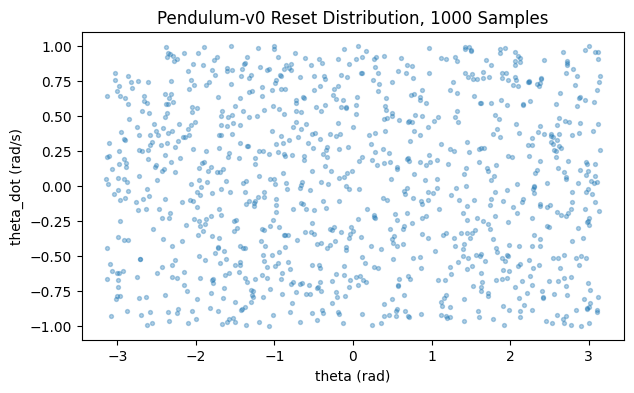

In [9]:
env = make_pendulum_env()
reset_samples = []
for _ in range(1000):
    env.reset()
    theta, theta_dot = np.asarray(env.unwrapped.state, dtype=np.float64)
    reset_samples.append((theta, theta_dot))
env.close()

reset_df = pd.DataFrame(reset_samples, columns=["theta", "theta_dot"])
display(reset_df.describe().T)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(reset_df["theta"], reset_df["theta_dot"], s=8, alpha=0.35)
ax.set_xlabel("theta (rad)")
ax.set_ylabel("theta_dot (rad/s)")
ax.set_title("Pendulum-v0 Reset Distribution, 1000 Samples")
plt.show()


## 3.8 Episode Length and Time-Limit Truncation

A time limit is an external episode boundary, not automatically a genuine terminal state. Pardo et al. (2018) show why time limits must be handled explicitly in value targets. The checks below therefore distinguish the underlying Pendulum dynamics from Gym's `TimeLimit` wrapper before locking the Bellman rule.


In [10]:
# Check the underlying environment without the TimeLimit wrapper.
underlying_env = make_pendulum_env().unwrapped
underlying_env.reset()
underlying_done_values = []
for _ in range(250):
    _, _, underlying_done, _ = underlying_env.step(np.array([0.0], dtype=np.float32))
    underlying_done_values.append(bool(underlying_done))
underlying_env.close()

assert not any(underlying_done_values), "Underlying Pendulum unexpectedly terminated naturally."

# Check the wrapped environment at the 200-step boundary.
wrapped_env = make_pendulum_env()
wrapped_env.reset()
records = []
for step_number in range(1, 201):
    _, _, done, info = wrapped_env.step(np.array([0.0], dtype=np.float32))
    if step_number in [1, 199, 200]:
        records.append({
            "step": step_number,
            "done": bool(done),
            "TimeLimit.truncated": info.get("TimeLimit.truncated", None),
        })
    if step_number < 200:
        assert not done, f"Wrapper ended too early at step {step_number}."

assert done is True, "TimeLimit wrapper did not end the episode at step 200."
assert info.get("TimeLimit.truncated") is True, (
    "Expected info['TimeLimit.truncated'] == True at step 200."
)
wrapped_time_limit_done = bool(done)
wrapped_time_limit_info = dict(info)
wrapped_env.close()

display(pd.DataFrame(records))

PENDULUM_TRANSITIONS_ARE_NONTERMINAL = True
print("Bellman rule locked: every Pendulum transition bootstraps from next-state Q-values.")


,step,done,TimeLimit.truncated
0,1,False,None
1,199,False,None
2,200,True,True


Bellman rule locked: every Pendulum transition bootstraps from next-state Q-values.


## 3.9 Gravity Parameter and Physics Hypotheses

The same physical state and torque are applied under all four gravity settings to verify that `g` changes the dynamics while the state and action interfaces remain identical.

Predeclared expectations:

- **default gravity:** standard downward gravity and the main tuning environment;
- **`g = 0`:** no gravitational restoring force, so torque and angular momentum dominate;
- **`g = -10`:** gravity acts towards the upright orientation, changing the control difficulty;
- **`g = 15`:** stronger downward gravity requires more forceful and timely control.


In [11]:
probe_theta = 0.8
probe_theta_dot = -0.25
probe_torque = np.array([0.5], dtype=np.float32)
gravity_records = []

for gravity_name, gravity_value in GRAVITY_SETTINGS.items():
    env = make_pendulum_env(gravity_value)
    start_obs = reset_to_physical_state(env, probe_theta, probe_theta_dot)
    next_obs, reward, done, info = env.step(probe_torque)
    gravity_records.append({
        "gravity": gravity_name,
        "g_attribute": float(env.unwrapped.g),
        "start_obs": np.round(start_obs, 6).tolist(),
        "next_obs": np.round(next_obs, 6).tolist(),
        "reward": float(reward),
        "done": bool(done),
    })
    env.close()

gravity_df = pd.DataFrame(gravity_records)
display(gravity_df)
assert gravity_df["next_obs"].astype(str).nunique() > 1, "Gravity did not alter the next-state dynamics."


,gravity,g_attribute,start_obs,next_obs,reward,done
0,default,10.0,"[0.696707010269165, 0.7173560261726379, -0.25]","[0.683572, 0.729883, 0.363017]",-0.6465,False
1,g0,0.0,"[0.696707010269165, 0.7173560261726379, -0.25]","[0.702957, 0.711233, -0.175]",-0.6465,False
2,g_neg10,-10.0,"[0.696707010269165, 0.7173560261726379, -0.25]","[0.721833, 0.692067, -0.713017]",-0.6465,False
3,g15,15.0,"[0.696707010269165, 0.7173560261726379, -0.25]","[0.673693, 0.739011, 0.632026]",-0.6465,False


## 3.10 Rendering and Video Preflight

Rendering and video are presentation support. They do not replace quantitative evaluation.


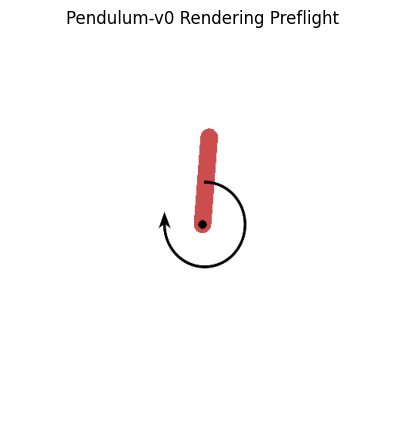

Rendered frame shape: (500, 500, 3)


In [12]:
env = make_pendulum_env()
env.reset()
frame = env.render(mode="rgb_array")
env.close()

frame = np.asarray(frame)
assert frame.ndim == 3 and frame.shape[-1] in (3, 4)

plt.figure(figsize=(5, 5))
plt.imshow(frame)
plt.axis("off")
plt.title("Pendulum-v0 Rendering Preflight")
plt.show()

print("Rendered frame shape:", frame.shape)


In [13]:
from gym.wrappers.monitoring.video_recorder import VideoRecorder

video_base = VIDEOS_DIR / "preflight_pendulum"
env = make_pendulum_env()
env.reset()
recorder = VideoRecorder(env, base_path=str(video_base), enabled=True)

for _ in range(30):
    recorder.capture_frame()
    _, _, done, _ = env.step(np.array([0.0], dtype=np.float32))
    if done:
        break

recorder.close()
env.close()
print("Video preflight base path:", video_base)


Video preflight base path: videos\preflight_pendulum


## 3.11 Weight Save-and-Load Preflight

A small temporary Q-network is used only to test Keras weight compatibility before the formal DQN builder is introduced. It is not a trained RL model or experiment result.


In [14]:
def build_preflight_q_network(state_dim: int = 3, action_count: int = 5) -> keras.Model:
    inputs = keras.Input(shape=(state_dim,), name="state")
    x = layers.Dense(16, activation="relu", name="hidden_1")(inputs)
    outputs = layers.Dense(action_count, activation="linear", name="q_values")(x)
    return keras.Model(inputs, outputs, name="preflight_q_network")


tf.keras.utils.set_random_seed(42)
preflight_model = build_preflight_q_network()
probe_state = tf.constant([[1.0, 0.0, 0.0]], dtype=tf.float32)
original_q = preflight_model(probe_state, training=False).numpy()

preflight_weight_path = SELECTED_WEIGHTS_DIR / "preflight_q_network.weights.h5"
preflight_model.save_weights(preflight_weight_path)

reloaded_model = build_preflight_q_network()
_ = reloaded_model(probe_state, training=False)  # Build variables before loading.
reloaded_model.load_weights(preflight_weight_path)
reloaded_q = reloaded_model(probe_state, training=False).numpy()

np.testing.assert_allclose(original_q, reloaded_q, rtol=1e-7, atol=1e-7)
print("Weight save-and-load preflight passed:", preflight_weight_path)


Weight save-and-load preflight passed: selected_weights\preflight_q_network.weights.h5


## 3.12 Direct Tensor Action-Selection Throughput

The action helper uses a direct tensor call with `training=False`. `model.predict()` is deliberately absent. This technical preflight is repeated and recorded during the Vanilla pilot using the actual model and hardware.


In [15]:
def greedy_action_index(model: keras.Model, state: np.ndarray) -> int:
    state_tensor = tf.convert_to_tensor(np.asarray(state, dtype=np.float32)[None, :])
    q_values = model(state_tensor, training=False)
    return int(tf.argmax(q_values[0]).numpy())


benchmark_state = np.array([1.0, 0.0, 0.0], dtype=np.float32)
for _ in range(50):
    greedy_action_index(reloaded_model, benchmark_state)  # warm-up

benchmark_calls = 2000
start_time = time.perf_counter()
for _ in range(benchmark_calls):
    greedy_action_index(reloaded_model, benchmark_state)
elapsed = time.perf_counter() - start_time

throughput = benchmark_calls / elapsed
milliseconds_per_decision = 1000.0 * elapsed / benchmark_calls

performance_preflight = pd.DataFrame({
    "measure": ["calls", "elapsed_seconds", "decisions_per_second", "milliseconds_per_decision"],
    "value": [benchmark_calls, elapsed, throughput, milliseconds_per_decision],
})
display(performance_preflight)


,measure,value
0,calls,2000.000000
1,elapsed_seconds,1.519100
2,decisions_per_second,1316.568588
3,milliseconds_per_decision,0.759550


## 3.13 Environment Validation Summary

Complete this table after running every preflight cell.


In [16]:
preflight_video_files = list(VIDEOS_DIR.glob("preflight_pendulum*.mp4"))

preflight_checks = {
    "Gym version is 0.17.3": bool(gym.__version__ == EXPECTED_GYM_VERSION),
    "Pendulum-v0 reset and step API": bool(
        np.asarray(reset_output).shape == (3,) and len(step_output) == 4
    ),
    "state observation formula": bool(
        np.allclose(
            test_obs,
            expected_observation(np.pi / 3, -0.75),
            rtol=1e-6,
            atol=1e-6,
        )
    ),
    "one-element torque action": bool(
        tuple(action_low.shape) == (1,)
        and tuple(action_high.shape) == (1,)
    ),
    "native reward reconstruction": bool(
        np.isclose(gym_reward, manual_reward, rtol=1e-6, atol=1e-6)
    ),
    "reset distribution inspected": bool(
        len(reset_df) == 1000
        and np.isfinite(reset_df.to_numpy(dtype=np.float64)).all()
    ),
    "underlying environment never terminates": bool(
        not any(underlying_done_values)
    ),
    "TimeLimit truncates at step 200": bool(
        wrapped_time_limit_done is True
        and wrapped_time_limit_info.get("TimeLimit.truncated") is True
    ),
    "all transitions bootstrap as nonterminal": bool(
        PENDULUM_TRANSITIONS_ARE_NONTERMINAL is True
    ),
    "all four gravity settings work": bool(
        len(gravity_df) == 4
        and gravity_df["next_obs"].astype(str).nunique() > 1
    ),
    "RGB rendering works": bool(
        frame.ndim == 3 and frame.shape[-1] in (3, 4)
    ),
    "video recording works": bool(
        len(preflight_video_files) >= 1
        and all(path.stat().st_size > 0 for path in preflight_video_files)
    ),
    "weights save and reload": bool(
        preflight_weight_path.exists()
        and np.allclose(original_q, reloaded_q, rtol=1e-7, atol=1e-7)
    ),
    "direct tensor action call works": bool(
        0 <= greedy_action_index(reloaded_model, benchmark_state)
        < int(reloaded_model.output_shape[-1])
    ),
    "throughput benchmark recorded": bool(
        throughput > 0.0 and milliseconds_per_decision > 0.0
    ),
}

environment_preflight_summary = pd.DataFrame({
    "check": list(preflight_checks.keys()),
    "passed": list(preflight_checks.values()),
})
environment_preflight_summary["status"] = np.where(
    environment_preflight_summary["passed"],
    "PASS",
    "FAIL",
)
display(environment_preflight_summary)

assert environment_preflight_summary["passed"].all()
print("Section 3 preflight complete. Every displayed PASS is derived from a Boolean check.")


,check,passed,status
0,Gym version is 0.17.3,True,PASS
1,Pendulum-v0 reset and step API,True,PASS
2,state observation formula,True,PASS
3,one-element torque action,True,PASS
4,native reward reconstruction,True,PASS
5,reset distribution inspected,True,PASS
6,underlying environment never terminates,True,PASS
7,TimeLimit truncates at step 200,True,PASS
8,all transitions bootstrap as nonterminal,True,PASS
9,all four gravity settings work,True,PASS


Section 3 preflight complete. Every displayed PASS is derived from a Boolean check.


# 4. Fixed Evaluation Protocol

This section prevents tuning leakage and unfair comparison.

Locked rules:

- the same underlying `(theta, theta_dot)` suites are used under every gravity;
- screening is seed `42` versus seed `42`;
- confirmation uses the exact same seed set for candidate and reference;
- per-seed paired differences use the same fixed physical states;
- asymmetric seed averages are not used;
- state-wise spread and training-seed variation are reported separately.


## 4.1 Development Initial-State Suite

The development suite is available for checkpoint selection, tuning and paired comparisons. It covers near-upright, sideways and near-downward positions with positive and negative angular velocities.


In [17]:
DEVELOPMENT_PHYSICAL_STATES = np.array([
    # Near upright
    [0.00, 0.00], [0.10, 0.50], [-0.10, -0.50], [0.25, -1.00], [-0.25, 1.00],
    [0.40, 2.00], [-0.40, -2.00], [0.55, -0.25],
    # Sideways
    [np.pi / 2, 0.00], [-np.pi / 2, 0.00], [np.pi / 2, 1.00], [-np.pi / 2, -1.00],
    [1.20, -2.00], [-1.20, 2.00], [1.80, 0.50], [-1.80, -0.50],
    # Near downward
    [np.pi, 0.00], [-np.pi + 0.10, 0.75], [np.pi - 0.10, -0.75],
    [2.70, 1.50], [-2.70, -1.50], [2.40, -2.00], [-2.40, 2.00], [3.00, 0.25],
], dtype=np.float64)

assert DEVELOPMENT_PHYSICAL_STATES.shape == (24, 2)

development_state_df = pd.DataFrame(
    DEVELOPMENT_PHYSICAL_STATES,
    columns=["theta", "theta_dot"],
    index=[f"D{i:02d}" for i in range(len(DEVELOPMENT_PHYSICAL_STATES))],
)
display(development_state_df)


,theta,theta_dot
D00,0.000000,0.00
D01,0.100000,0.50
D02,-0.100000,-0.50
D03,0.250000,-1.00
D04,-0.250000,1.00
D05,0.400000,2.00
D06,-0.400000,-2.00
D07,0.550000,-0.25
D08,1.570796,0.00
D09,-1.570796,0.00


## 4.2 Held-Out Final Initial-State Suite

The held-out suite is different from the development suite and must not be used for model selection, tuning or checkpoint selection. The code defines it now for reproducibility, but tuning sections should display only its count and integrity checks until the freeze.


In [18]:
HELDOUT_PHYSICAL_STATES = np.array([
    # Near upright, values different from development suite
    [0.05, -0.30], [-0.05, 0.30], [0.18, 0.90], [-0.18, -0.90],
    [0.32, -1.50], [-0.32, 1.50], [0.48, 0.20], [-0.48, -0.20],
    # Sideways and intermediate
    [1.35, 0.40], [-1.35, -0.40], [1.55, -1.20], [-1.55, 1.20],
    [1.95, 1.80], [-1.95, -1.80], [2.15, -0.60], [-2.15, 0.60],
    # Near downward
    [2.55, 0.00], [-2.55, 0.00], [2.80, -1.00], [-2.80, 1.00],
    [3.08, 0.50], [-3.08, -0.50], [2.30, 2.20], [-2.30, -2.20],
], dtype=np.float64)

assert HELDOUT_PHYSICAL_STATES.shape == (24, 2)

rounded_dev = {tuple(np.round(row, 10)) for row in DEVELOPMENT_PHYSICAL_STATES}
rounded_final = {tuple(np.round(row, 10)) for row in HELDOUT_PHYSICAL_STATES}
assert rounded_dev.isdisjoint(rounded_final), "Development and held-out suites overlap."

print("Held-out state count:", len(HELDOUT_PHYSICAL_STATES))
print("No overlap with development suite: PASS")


Held-out state count: 24
No overlap with development suite: PASS


## 4.3 Shared-Suite Validation Across All Gravities

The exact same physical states are reused for every gravity. Only the environment dynamics change.


In [19]:
def validate_physical_suite_across_gravities(
    physical_states: np.ndarray,
    suite_name: str,
) -> pd.DataFrame:
    records = []
    for gravity_name, gravity_value in GRAVITY_SETTINGS.items():
        env = make_pendulum_env(gravity_value)
        for state_id, (theta, theta_dot) in enumerate(physical_states):
            obs = reset_to_physical_state(env, float(theta), float(theta_dot))
            records.append({
                "suite": suite_name,
                "gravity": gravity_name,
                "state_id": state_id,
                "observation_matches": bool(np.allclose(obs, expected_observation(theta, theta_dot))),
            })
        env.close()
    result = pd.DataFrame(records)
    assert result["observation_matches"].all()
    return result


dev_validation = validate_physical_suite_across_gravities(DEVELOPMENT_PHYSICAL_STATES, "development")
final_validation = validate_physical_suite_across_gravities(HELDOUT_PHYSICAL_STATES, "held_out")

display(pd.concat([dev_validation, final_validation]).groupby(["suite", "gravity"]).agg(
    states_checked=("state_id", "count"),
    all_observations_match=("observation_matches", "all"),
))


states_checked  all_observations_match
suite       gravity                                        
development default              24                    True
            g0                   24                    True
            g15                  24                    True
            g_neg10              24                    True
held_out    default              24                    True
            g0                   24                    True
            g15                  24                    True
            g_neg10              24                    True

## 4.4 Greedy Evaluation and Supporting Control Metrics

Formal evaluation disables exploration. Each episode starts from a fixed physical state and runs for the full 200-step horizon.

Predeclared control metrics:

- episode return;
- upright fraction, using an absolute angle threshold of 15 degrees;
- mean absolute angle error;
- mean absolute angular velocity;
- mean absolute torque;
- **action switching rate**, which counts every change between discrete torque values;
- **torque-direction switching rate**, which counts only sign changes;
- mean absolute torque change.

The two switching metrics are not interchangeable. A change from `+0.67` to `+2.00` is an action switch but not a direction switch.


In [20]:
UPRIGHT_ANGLE_THRESHOLD_RAD = np.deg2rad(15.0)
EVALUATION_HORIZON = 200


def observation_to_angle(observation: np.ndarray) -> float:
    return float(np.arctan2(observation[1], observation[0]))


def calculate_control_smoothness_metrics(
    torques: Sequence[float],
) -> Dict[str, float]:
    """Return separate value-change and direction-change torque metrics."""
    torque_array = np.asarray(torques, dtype=np.float64)
    if torque_array.size <= 1:
        return {
            "action_switching_rate": 0.0,
            "torque_direction_switching_rate": 0.0,
            "mean_abs_torque_change": 0.0,
        }

    torque_differences = np.diff(torque_array)
    action_switches = int(
        np.count_nonzero(
            ~np.isclose(torque_differences, 0.0, rtol=0.0, atol=1e-8)
        )
    )
    direction_switches = int(
        np.count_nonzero(np.diff(np.sign(torque_array)))
    )
    denominator = max(1, torque_array.size - 1)

    metrics = {
        "action_switching_rate": float(action_switches / denominator),
        "torque_direction_switching_rate": float(
            direction_switches / denominator
        ),
        "mean_abs_torque_change": float(
            np.mean(np.abs(torque_differences))
        ),
    }
    assert metrics["action_switching_rate"] + 1e-12 >= (
        metrics["torque_direction_switching_rate"]
    )
    assert np.isfinite(np.asarray(list(metrics.values()))).all()
    return metrics


def evaluate_policy_on_physical_states(
    env_builder: Callable[[], object],
    policy: Callable[[np.ndarray], float],
    physical_states: np.ndarray,
    horizon: int = EVALUATION_HORIZON,
) -> pd.DataFrame:
    """Evaluate one deterministic policy on fixed physical states without replay updates."""
    records = []
    env = env_builder()
    try:
        for state_index, (theta, theta_dot) in enumerate(physical_states):
            observation = reset_to_physical_state(
                env,
                float(theta),
                float(theta_dot),
            )
            rewards, angles, velocities, torques = [], [], [], []

            for step_index in range(horizon):
                torque = float(policy(observation.copy()))
                action = np.array([torque], dtype=np.float32)
                next_observation, reward, done, info = env.step(action)
                next_observation = np.asarray(
                    next_observation,
                    dtype=np.float32,
                )

                rewards.append(float(reward))
                angles.append(abs(observation_to_angle(next_observation)))
                velocities.append(abs(float(next_observation[2])))
                torques.append(torque)
                observation = next_observation

                if done:
                    assert info.get("TimeLimit.truncated") is True
                    assert step_index + 1 == horizon
                    break

            assert len(rewards) == horizon
            smoothness = calculate_control_smoothness_metrics(torques)
            records.append({
                "state_id": int(state_index),
                "return": float(np.sum(rewards)),
                "upright_fraction": float(
                    np.mean(
                        np.asarray(angles)
                        <= UPRIGHT_ANGLE_THRESHOLD_RAD
                    )
                ),
                "mean_abs_angle": float(np.mean(angles)),
                "mean_abs_angular_velocity": float(np.mean(velocities)),
                "mean_abs_torque": float(np.mean(np.abs(torques))),
                **smoothness,
                "control_metric_schema": CONTROL_METRIC_SCHEMA_VERSION,
            })
    finally:
        env.close()
    return pd.DataFrame(records)


## 4.5 Primary Selection Rule and Practical Tie Rule

For a direct candidate-versus-reference decision:

1. compare only matched training-seed sets;
2. screening is seed `42` versus seed `42`;
3. confirmation uses the same seeds for both sides;
4. use the same fixed physical states;
5. report per-seed paired differences.

The primary criterion is mean greedy development return. Stability, sample efficiency, simplicity, runtime and reproducibility are ordered supporting criteria.

The practical improvement margin is calculated only after the three Vanilla runs. It uses the **observed range of the seed-level mean returns** as a conservative heuristic. It is not a formal significance test.


In [21]:
SCREENING_SEEDS = (42,)
VANILLA_CALIBRATION_SEEDS = (42, 123, 2026)


def practical_improvement_margin(seed_level_mean_returns: Mapping[int, float]) -> float:
    required = set(VANILLA_CALIBRATION_SEEDS)
    received = set(seed_level_mean_returns)
    assert received == required, f"Expected seed means for {sorted(required)}, received {sorted(received)}."
    values = np.asarray([seed_level_mean_returns[seed] for seed in VANILLA_CALIBRATION_SEEDS], dtype=float)
    return float(values.max() - values.min())

print("Screening seeds:", SCREENING_SEEDS)
print("Vanilla calibration seeds:", VANILLA_CALIBRATION_SEEDS)


Screening seeds: (42,)
Vanilla calibration seeds: (42, 123, 2026)


## 4.6 Matched Per-Seed Paired Policy Comparison

State-wise spread and training-seed variation answer different questions:

- **state-wise standard deviation:** robustness across initial physical states within one trained seed;
- **training-seed variation:** variation between independently trained agents, using each seed's mean return.

They are never pooled into one standard deviation.


In [22]:
def paired_model_comparison(
    candidate_results: pd.DataFrame,
    reference_results: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Compare candidate and reference using exactly matched seeds and state IDs."""
    required_columns = {"seed", "state_id", "return"}
    assert required_columns.issubset(candidate_results.columns)
    assert required_columns.issubset(reference_results.columns)

    candidate_seeds = set(candidate_results["seed"].unique())
    reference_seeds = set(reference_results["seed"].unique())
    assert candidate_seeds == reference_seeds, (
        f"Asymmetric seed sets are invalid: candidate={sorted(candidate_seeds)}, "
        f"reference={sorted(reference_seeds)}"
    )

    candidate_pairs = set(
        map(tuple, candidate_results[["seed", "state_id"]].to_numpy())
    )
    reference_pairs = set(
        map(tuple, reference_results[["seed", "state_id"]].to_numpy())
    )

    assert candidate_pairs == reference_pairs, (
        "Candidate and reference must contain exactly the same "
        "(seed, state_id) pairs."
    )
    
    merged = candidate_results.merge(
        reference_results,
        on=["seed", "state_id"],
        suffixes=("_candidate", "_reference"),
        validate="one_to_one",
    )
    expected_rows = len(candidate_seeds) * candidate_results["state_id"].nunique()
    assert len(merged) == expected_rows, "Candidate and reference do not cover identical states per seed."

    merged["paired_return_difference"] = merged["return_candidate"] - merged["return_reference"]

    per_seed = merged.groupby("seed").agg(
        candidate_mean_return=("return_candidate", "mean"),
        reference_mean_return=("return_reference", "mean"),
        paired_mean_difference=("paired_return_difference", "mean"),
        paired_median_difference=("paired_return_difference", "median"),
        paired_win_rate=("paired_return_difference", lambda x: float(np.mean(x > 0))),
        state_wise_difference_std=("paired_return_difference", "std"),
    ).reset_index()

    seed_variation = pd.DataFrame({
        "quantity": ["candidate_seed_mean_range", "reference_seed_mean_range"],
        "value": [
            per_seed["candidate_mean_return"].max() - per_seed["candidate_mean_return"].min(),
            per_seed["reference_mean_return"].max() - per_seed["reference_mean_return"].min(),
        ],
    })
    return per_seed, seed_variation


### 4.6.1 Paired-Comparison Helper Smoke Test

This technical smoke test verifies that the paired-comparison helper:

- computes the expected per-seed mean difference and win rate;
- keeps training-seed variation separate from state-wise spread;
- rejects mismatched `(seed, state_id)` pairs.

The synthetic values are used only to validate the helper. They are not RL
results.


In [23]:
paired_candidate_smoke = pd.DataFrame({
    "seed": [42, 42, 123, 123],
    "state_id": [0, 1, 0, 1],
    "return": [-100.0, -90.0, -110.0, -80.0],
})
paired_reference_smoke = pd.DataFrame({
    "seed": [42, 42, 123, 123],
    "state_id": [0, 1, 0, 1],
    "return": [-120.0, -95.0, -105.0, -85.0],
})

paired_summary_smoke, seed_variation_smoke = paired_model_comparison(
    paired_candidate_smoke,
    paired_reference_smoke,
)

assert list(paired_summary_smoke["seed"]) == [42, 123]
np.testing.assert_allclose(
    paired_summary_smoke["paired_mean_difference"].to_numpy(),
    [12.5, 0.0],
)
np.testing.assert_allclose(
    paired_summary_smoke["paired_win_rate"].to_numpy(),
    [1.0, 0.5],
)
assert seed_variation_smoke.shape == (2, 2)

mismatched_reference_smoke = pd.concat(
    [
        paired_reference_smoke,
        pd.DataFrame({
            "seed": [42],
            "state_id": [99],
            "return": [-999.0],
        }),
    ],
    ignore_index=True,
)

try:
    paired_model_comparison(
        paired_candidate_smoke,
        mismatched_reference_smoke,
    )
    raise AssertionError(
        "Mismatched seed/state pairs were not rejected."
    )
except AssertionError as error:
    assert "exactly the same" in str(error)

display(paired_summary_smoke)
display(seed_variation_smoke)
print("Paired-comparison helper smoke test: PASS")


,seed,candidate_mean_return,reference_mean_return,paired_mean_difference,paired_median_difference,paired_win_rate,state_wise_difference_std
0,42,-95.0,-107.5,12.5,12.5,1.0,10.606602
1,123,-95.0,-95.0,0.0,0.0,0.5,7.071068


,quantity,value
0,candidate_seed_mean_range,0.0
1,reference_seed_mean_range,12.5


Paired-comparison helper smoke test: PASS


### 4.6.2 Smoke-Test Result

**Finding.** The helper produced the expected paired results. Seed `42` had a
paired mean difference of `12.5` and a win rate of `1.0`; seed `123` had a
paired mean difference of `0.0` and a win rate of `0.5`. The helper also
reported seed-level mean ranges separately and rejected a deliberately
mismatched `(seed, state_id)` set.

**Decision.** The paired-comparison helper smoke test passes. It is suitable for
later matched-seed, matched-state model comparisons.


## 4.7 Invalid-Run Rules

A run is invalid when evidence shows a technical failure, including:

- non-finite loss, gradients or Q-values;
- broken tensor or replay shapes;
- incorrect Double DQN or dueling logic;
- evaluation transitions entering replay memory;
- exploration active during formal evaluation;
- missing fixed states or asymmetric seed sets;
- failed weight reload;
- environment behaviour inconsistent with the Section 3 assertions.

A weak but technically valid run remains part of the evidence.


## 4.8 Selected Development Weight Rule

Development evaluation may select a weight checkpoint from `selected_weights/`. These files support comparison and later re-evaluation only. They do not provide resumable training because replay memory, optimiser state and random-generator state are not saved.


## 4.9 Provisional and Formal Reference Policy

Random and untrained policies created before action-set selection are labelled **provisional references**. After the 3-, 5- and 7-action comparison selects the action set, formal random and untrained references are regenerated under every gravity using:

- the selected action set;
- the exact same development and held-out physical state suites;
- the same evaluation metrics.

Only the regenerated references support formal viability and gravity conclusions.


## 4.10 Evaluation Protocol Freeze Statement

Before formal DQN training begins, the team must confirm:

- Gym 0.17.3 preflight passes;
- underlying Pendulum never terminates naturally;
- the wrapper truncates at step 200;
- all Pendulum transitions bootstrap as nonterminal;
- shared physical state suites pass under all gravities;
- screening seed is `42`;
- Vanilla calibration seeds are `42`, `123`, and `2026`;
- direct model decisions use matched seed sets only;
- held-out states remain unused until the final freeze;
- environment-step action selection uses direct model calls with `training=False`;
- `model.predict()` is absent from the step loop;
- `best_dqn.weights.h5` is the primary final weight file.

**Status at this stage of the workflow:** Sections 1 to 4 were approved for implementation. Formal DQN training was still blocked until all Gate B environment, evaluation and DQN smoke tests passed.


### Section 4 Completion Status

- Development initial-state suite: PASS
- Held-out final suite: PASS and protected
- Cross-gravity suite validation: PASS
- Greedy evaluator and supporting metrics: PASS
- Primary selection and seed rules: PASS
- Paired-comparison helper: PASS
- Invalid-run rules: APPROVED
- Selected development-weight rule: APPROVED
- Provisional and formal reference policy: APPROVED
- Evaluation protocol freeze statement: APPROVED

**Section 4 status: COMPLETE**

At this stage, the held-out suite remained sealed from tuning and checkpoint selection until Section 19, and formal DQN training was still blocked until the Section 6 component smoke tests passed.


# 5. Same-Gravity Reference Policies

The references in this section are **provisional** because the formal discrete
torque action set has not yet been selected.

They provide an early technical baseline only. After Section 7 selects the
action set, the random and untrained references will be regenerated formally
under all four gravity settings before they are used for model decisions.


## 5.1 Provisional Random Policy Under Default Gravity

This subsection evaluates a reproducible random policy under default gravity
using the temporary three-action torque set:

```text
[-2.0, 0.0, 2.0]
```

The policy is evaluated on the 24 development states for 200 steps per state.
A base seed of `42` is used, with a deterministic per-state seed offset so that
each state's random action sequence can be reproduced independently.

The resulting metrics are provisional and must not be used to select the final
action set or final DQN configuration.


In [24]:
PROVISIONAL_RANDOM_DEFAULT_RUN_ID = "R00_RANDOM_DEFAULT_PROVISIONAL"
PROVISIONAL_RANDOM_BASE_SEED = 42
PROVISIONAL_TORQUES_DEFAULT = np.array([-2.0, 0.0, 2.0], dtype=np.float32)

assert np.all(PROVISIONAL_TORQUES_DEFAULT >= action_low[0])
assert np.all(PROVISIONAL_TORQUES_DEFAULT <= action_high[0])
assert np.isclose(PROVISIONAL_TORQUES_DEFAULT[0], -PROVISIONAL_TORQUES_DEFAULT[-1])
assert 0.0 in PROVISIONAL_TORQUES_DEFAULT


def evaluate_random_discrete_policy_on_physical_states(
    env_builder: Callable[[], object],
    physical_states: np.ndarray,
    torque_values: np.ndarray,
    base_seed: int,
    horizon: int = EVALUATION_HORIZON,
) -> pd.DataFrame:
    """Evaluate reproducible random discrete actions on fixed physical states."""
    records = []
    env = env_builder()

    try:
        for state_index, (theta, theta_dot) in enumerate(physical_states):
            observation = reset_to_physical_state(
                env,
                float(theta),
                float(theta_dot),
            )

            # Each state receives its own reproducible random action stream.
            rng = np.random.default_rng(base_seed + state_index)

            rewards = []
            angles = []
            velocities = []
            torques = []

            for _ in range(horizon):
                torque = float(rng.choice(torque_values))
                action = np.array([torque], dtype=np.float32)

                next_observation, reward, done, info = env.step(action)
                next_observation = np.asarray(next_observation, dtype=np.float32)

                rewards.append(float(reward))
                angles.append(abs(observation_to_angle(next_observation)))
                velocities.append(abs(float(next_observation[2])))
                torques.append(torque)

                observation = next_observation

                if done:
                    assert info.get("TimeLimit.truncated") is True
                    break

            assert len(rewards) == horizon, (
                f"Expected {horizon} evaluation steps for state {state_index}, "
                f"but completed {len(rewards)}."
            )

            smoothness = calculate_control_smoothness_metrics(torques)

            records.append({
                "run_id": PROVISIONAL_RANDOM_DEFAULT_RUN_ID,
                "policy": "provisional_random_discrete",
                "gravity": "default",
                "base_seed": int(base_seed),
                "state_id": int(state_index),
                "state_label": f"D{state_index:02d}",
                "theta": float(theta),
                "theta_dot": float(theta_dot),
                "steps": int(len(rewards)),
                "return": float(np.sum(rewards)),
                "upright_fraction": float(
                    np.mean(
                        np.asarray(angles, dtype=np.float32)
                        <= UPRIGHT_ANGLE_THRESHOLD_RAD
                    )
                ),
                "mean_abs_angle": float(np.mean(angles)),
                "mean_abs_angular_velocity": float(np.mean(velocities)),
                "mean_abs_torque": float(np.mean(np.abs(torques))),
                **smoothness,
                "control_metric_schema": CONTROL_METRIC_SCHEMA_VERSION,
            })
    finally:
        env.close()

    results = pd.DataFrame(records)
    assert len(results) == len(physical_states)
    assert results["state_id"].is_unique
    assert np.isfinite(
        results[
            [
                "return",
                "upright_fraction",
                "mean_abs_angle",
                "mean_abs_angular_velocity",
                "mean_abs_torque",
                "action_switching_rate",
                "torque_direction_switching_rate",
                "mean_abs_torque_change",
            ]
        ].to_numpy()
    ).all()
    return results


provisional_random_default_results = (
    evaluate_random_discrete_policy_on_physical_states(
        env_builder=lambda: make_pendulum_env(),
        physical_states=DEVELOPMENT_PHYSICAL_STATES,
        torque_values=PROVISIONAL_TORQUES_DEFAULT,
        base_seed=PROVISIONAL_RANDOM_BASE_SEED,
    )
)

provisional_random_default_path = (
    HISTORIES_DIR
    / f"{PROVISIONAL_RANDOM_DEFAULT_RUN_ID}_state_results.csv"
)
provisional_random_default_results.to_csv(
    provisional_random_default_path,
    index=False,
)

provisional_random_default_summary = pd.DataFrame({
    "run_id": [PROVISIONAL_RANDOM_DEFAULT_RUN_ID],
    "policy": ["provisional_random_discrete"],
    "gravity": ["default"],
    "action_set": [PROVISIONAL_TORQUES_DEFAULT.tolist()],
    "base_seed": [PROVISIONAL_RANDOM_BASE_SEED],
    "states_evaluated": [len(provisional_random_default_results)],
    "mean_return": [
        provisional_random_default_results["return"].mean()
    ],
    "return_std": [
        provisional_random_default_results["return"].std(ddof=1)
    ],
    "mean_upright_fraction": [
        provisional_random_default_results["upright_fraction"].mean()
    ],
    "mean_abs_angle": [
        provisional_random_default_results["mean_abs_angle"].mean()
    ],
    "mean_abs_angular_velocity": [
        provisional_random_default_results[
            "mean_abs_angular_velocity"
        ].mean()
    ],
    "mean_abs_torque": [
        provisional_random_default_results["mean_abs_torque"].mean()
    ],
    "mean_torque_direction_switching_rate": [
        provisional_random_default_results[
            "torque_direction_switching_rate"
        ].mean()
    ],
    "mean_action_switching_rate": [
        provisional_random_default_results[
            "action_switching_rate"
        ].mean()
    ],
    "mean_abs_torque_change": [
        provisional_random_default_results[
            "mean_abs_torque_change"
        ].mean()
    ],
})

display(provisional_random_default_summary)
print(
    "Saved 24 provisional state-level results:",
    provisional_random_default_path,
)


,run_id,policy,gravity,action_set,base_seed,states_evaluated,mean_return,return_std,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate,mean_action_switching_rate,mean_abs_torque_change
0,R00_RANDOM_DEFAULT_PROVISIONAL,provisional_random_discrete,default,"[-2.0, 0.0, 2.0]",42,24,-1220.045207,285.110103,0.034375,2.012548,2.932114,1.3075,0.670436,0.670436,1.760469


Saved 24 provisional state-level results: histories\R00_RANDOM_DEFAULT_PROVISIONAL_state_results.csv


### 5.1 Result Interpretation

**Finding.** The provisional random policy achieved a mean return of
`-1220.05 ± 285.11` across the 24 development states. It remained upright for
only `3.44%` of evaluation steps and changed torque direction frequently, with
a mean torque-direction switching rate of `0.6704`.

**Importance.** This establishes an early same-gravity reference for what
unstructured control looks like under the temporary three-action set. The high
return spread also shows that initial physical state strongly affects random
performance.

**Decision.** Retain these results only as a provisional technical reference.

**Caveat.** The temporary action set has not been selected formally, so this
result cannot support final viability, action-set, or model-selection claims.

**Next step.** Compare it with a reproducibly initialised untrained greedy
Q-network under the same gravity, states, horizon, action set, and metrics.


## 5.2 Provisional Untrained Network Under Default Gravity

This subsection evaluates a freshly initialised, **untrained** greedy Q-network
under default gravity using the same temporary torque set as Section 5.1:

```text
[-2.0, 0.0, 2.0]
```

The network reuses the small preflight architecture only for an early technical
reference. It does not lock the formal Vanilla DQN architecture used later in
Section 6.

The model is initialised reproducibly with seed `42`. At every environment step,
the policy obtains Q-values through a direct tensor call with
`training=False`, selects the greedy action using `argmax`, and maps that action
index to a torque. No training, replay insertion, exploration, or weight update
occurs.

These results remain provisional and must not be used to choose the final action
set or final DQN configuration.


In [25]:
PROVISIONAL_UNTRAINED_DEFAULT_RUN_ID = "R01_UNTRAINED_DEFAULT_PROVISIONAL"
PROVISIONAL_UNTRAINED_SEED = 42

tf.keras.utils.set_random_seed(PROVISIONAL_UNTRAINED_SEED)

provisional_untrained_default_model = build_preflight_q_network(
    state_dim=3,
    action_count=len(PROVISIONAL_TORQUES_DEFAULT),
)

provisional_probe_state = tf.constant(
    [[1.0, 0.0, 0.0]],
    dtype=tf.float32,
)
provisional_probe_q_values = provisional_untrained_default_model(
    provisional_probe_state,
    training=False,
)

assert provisional_probe_q_values.shape == (
    1,
    len(PROVISIONAL_TORQUES_DEFAULT),
)
assert np.isfinite(provisional_probe_q_values.numpy()).all()


def provisional_untrained_default_policy(
    observation: np.ndarray,
) -> float:
    """Return the greedy torque from the reproducibly initialised network."""
    state_tensor = tf.convert_to_tensor(
        observation.reshape(1, -1),
        dtype=tf.float32,
    )
    q_values = provisional_untrained_default_model(
        state_tensor,
        training=False,
    )
    action_index = int(tf.argmax(q_values[0]).numpy())
    return float(PROVISIONAL_TORQUES_DEFAULT[action_index])


provisional_untrained_default_results = evaluate_policy_on_physical_states(
    env_builder=lambda: make_pendulum_env(),
    policy=provisional_untrained_default_policy,
    physical_states=DEVELOPMENT_PHYSICAL_STATES,
)

assert len(provisional_untrained_default_results) == len(
    DEVELOPMENT_PHYSICAL_STATES
)
assert provisional_untrained_default_results["state_id"].is_unique

provisional_untrained_default_results.insert(
    0,
    "run_id",
    PROVISIONAL_UNTRAINED_DEFAULT_RUN_ID,
)
provisional_untrained_default_results.insert(
    1,
    "policy",
    "provisional_untrained_greedy_q_network",
)
provisional_untrained_default_results.insert(
    2,
    "gravity",
    "default",
)
provisional_untrained_default_results.insert(
    3,
    "model_seed",
    PROVISIONAL_UNTRAINED_SEED,
)
provisional_untrained_default_results.insert(
    5,
    "state_label",
    [
        f"D{state_index:02d}"
        for state_index in provisional_untrained_default_results["state_id"]
    ],
)
provisional_untrained_default_results["theta"] = (
    DEVELOPMENT_PHYSICAL_STATES[:, 0]
)
provisional_untrained_default_results["theta_dot"] = (
    DEVELOPMENT_PHYSICAL_STATES[:, 1]
)

metric_columns = [
    "return",
    "upright_fraction",
    "mean_abs_angle",
    "mean_abs_angular_velocity",
    "mean_abs_torque",
    "torque_direction_switching_rate",
]
assert np.isfinite(
    provisional_untrained_default_results[metric_columns].to_numpy()
).all()

provisional_untrained_default_path = (
    HISTORIES_DIR
    / f"{PROVISIONAL_UNTRAINED_DEFAULT_RUN_ID}_state_results.csv"
)
provisional_untrained_default_results.to_csv(
    provisional_untrained_default_path,
    index=False,
)

provisional_untrained_default_summary = pd.DataFrame({
    "run_id": [PROVISIONAL_UNTRAINED_DEFAULT_RUN_ID],
    "policy": ["provisional_untrained_greedy_q_network"],
    "gravity": ["default"],
    "action_set": [PROVISIONAL_TORQUES_DEFAULT.tolist()],
    "model_seed": [PROVISIONAL_UNTRAINED_SEED],
    "states_evaluated": [len(provisional_untrained_default_results)],
    "mean_return": [
        provisional_untrained_default_results["return"].mean()
    ],
    "return_std": [
        provisional_untrained_default_results["return"].std(ddof=1)
    ],
    "mean_upright_fraction": [
        provisional_untrained_default_results[
            "upright_fraction"
        ].mean()
    ],
    "mean_abs_angle": [
        provisional_untrained_default_results["mean_abs_angle"].mean()
    ],
    "mean_abs_angular_velocity": [
        provisional_untrained_default_results[
            "mean_abs_angular_velocity"
        ].mean()
    ],
    "mean_abs_torque": [
        provisional_untrained_default_results[
            "mean_abs_torque"
        ].mean()
    ],
    "mean_torque_direction_switching_rate": [
        provisional_untrained_default_results[
            "torque_direction_switching_rate"
        ].mean()
    ],
})

display(provisional_untrained_default_summary)
print(
    "Saved 24 provisional untrained state-level results:",
    provisional_untrained_default_path,
)


,run_id,policy,gravity,action_set,model_seed,states_evaluated,mean_return,return_std,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,R01_UNTRAINED_DEFAULT_PROVISIONAL,provisional_untrained_greedy_q_network,default,"[-2.0, 0.0, 2.0]",42,24,-1574.452456,61.481491,0.072708,1.833176,5.224737,1.9875,0.007328


Saved 24 provisional untrained state-level results: histories\R01_UNTRAINED_DEFAULT_PROVISIONAL_state_results.csv


### 5.2 Result Interpretation

**Finding.** The provisional untrained greedy Q-network achieved a mean return
of `-1574.45 ± 61.48`, which is approximately `354.41` return points lower than
the provisional random policy. Its mean absolute torque was `1.9875`, close to
the maximum available magnitude, while its torque-direction switching rate was only
`0.0073`.

**Importance.** The combination of near-maximum torque magnitude and almost no
switching suggests that the initial random Q-values caused the untrained
network to favour nearly the same extreme action for most steps. Although its
upright fraction and mean absolute angle appear better than the random
reference, its substantially worse return and much higher angular velocity
show why supporting control metrics must be interpreted together rather than
used as an undefined score.

**Decision.** Retain this result only as a provisional untrained reference. It
does not demonstrate learning and does not determine the formal network
architecture.

**Caveat.** These conclusions apply only to this reproducible initialisation,
temporary action set, and default-gravity evaluation. Formal references will be
regenerated after action-set selection.

**Next step.** Evaluate the same provisional random and untrained policies
under `g = 0` while preserving the physical states, horizon, action sequences,
network weights, and metrics.


## 5.3 Provisional References Under `g = 0`

**Question.** How do the same provisional random and untrained policies behave
when gravity is removed?

**Reason.** Gravity changes the environment dynamics. Evaluating the same
policies under `g = 0` provides an early physics-oriented reference without
confounding the comparison with training, different initial states, different
action sequences, or different network weights.

**Hypothesis.** Without downward gravitational acceleration, the pendulum may
retain motion differently from the default-gravity environment. Raw return and
the supporting control metrics may therefore change even though the policies
are unchanged.

**Class-material alignment.** Topic 6 explains that an untrained Q-network
begins from randomly initialised coefficients and that a greedy Q-policy selects
the action with the highest predicted Q-value. This subsection keeps those
weights fixed and changes only the environment gravity.

**Primary change.** Gravity changes from the default value to `g = 0`.

**Controlled factors.**

- temporary torque set: `[-2.0, 0.0, 2.0]`;
- 24 development physical states;
- 200-step evaluation horizon;
- random-policy base seed `42` and identical per-state action sequences;
- untrained-network seed `42` and the exact same network weights;
- greedy direct tensor calls with `training=False`;
- evaluation metrics and CSV format.

**Evaluation evidence.** For both policies, report mean return, return standard
deviation, upright fraction, mean absolute angle, mean absolute angular
velocity, mean absolute torque, and torque-direction switching rate.

**Decision rule.** Retain the outputs only as provisional same-gravity
references. They cannot determine the final action set or DQN configuration.


In [26]:
PROVISIONAL_RANDOM_G0_RUN_ID = "R00_RANDOM_G0_PROVISIONAL"
PROVISIONAL_UNTRAINED_G0_RUN_ID = "R01_UNTRAINED_G0_PROVISIONAL"
PROVISIONAL_G0_VALUE = GRAVITY_SETTINGS["g0"]

assert PROVISIONAL_G0_VALUE == 0.0

# Preserve the exact untrained network weights used under default gravity.
untrained_weights_before_g0 = [
    weight.numpy().copy()
    for weight in provisional_untrained_default_model.weights
]

provisional_random_g0_results = (
    evaluate_random_discrete_policy_on_physical_states(
        env_builder=lambda: make_pendulum_env(PROVISIONAL_G0_VALUE),
        physical_states=DEVELOPMENT_PHYSICAL_STATES,
        torque_values=PROVISIONAL_TORQUES_DEFAULT,
        base_seed=PROVISIONAL_RANDOM_BASE_SEED,
    )
)

# The shared random evaluator computes the correct trajectories and metrics.
# Relabel its metadata for this gravity-specific provisional run.
provisional_random_g0_results["run_id"] = PROVISIONAL_RANDOM_G0_RUN_ID
provisional_random_g0_results["gravity"] = "g0"

assert len(provisional_random_g0_results) == len(
    DEVELOPMENT_PHYSICAL_STATES
)
assert provisional_random_g0_results["state_id"].is_unique

provisional_random_g0_path = (
    HISTORIES_DIR
    / f"{PROVISIONAL_RANDOM_G0_RUN_ID}_state_results.csv"
)
provisional_random_g0_results.to_csv(
    provisional_random_g0_path,
    index=False,
)

provisional_random_g0_summary = pd.DataFrame({
    "run_id": [PROVISIONAL_RANDOM_G0_RUN_ID],
    "policy": ["provisional_random_discrete"],
    "gravity": ["g0"],
    "action_set": [PROVISIONAL_TORQUES_DEFAULT.tolist()],
    "seed": [PROVISIONAL_RANDOM_BASE_SEED],
    "states_evaluated": [len(provisional_random_g0_results)],
    "mean_return": [
        provisional_random_g0_results["return"].mean()
    ],
    "return_std": [
        provisional_random_g0_results["return"].std(ddof=1)
    ],
    "mean_upright_fraction": [
        provisional_random_g0_results["upright_fraction"].mean()
    ],
    "mean_abs_angle": [
        provisional_random_g0_results["mean_abs_angle"].mean()
    ],
    "mean_abs_angular_velocity": [
        provisional_random_g0_results[
            "mean_abs_angular_velocity"
        ].mean()
    ],
    "mean_abs_torque": [
        provisional_random_g0_results["mean_abs_torque"].mean()
    ],
    "mean_torque_direction_switching_rate": [
        provisional_random_g0_results[
            "torque_direction_switching_rate"
        ].mean()
    ],
})

provisional_untrained_g0_results = evaluate_policy_on_physical_states(
    env_builder=lambda: make_pendulum_env(PROVISIONAL_G0_VALUE),
    policy=provisional_untrained_default_policy,
    physical_states=DEVELOPMENT_PHYSICAL_STATES,
)

# Evaluation must not alter the untrained network.
for before, after in zip(
    untrained_weights_before_g0,
    provisional_untrained_default_model.weights,
):
    np.testing.assert_allclose(
        before,
        after.numpy(),
        rtol=0.0,
        atol=0.0,
    )

assert len(provisional_untrained_g0_results) == len(
    DEVELOPMENT_PHYSICAL_STATES
)
assert provisional_untrained_g0_results["state_id"].is_unique

provisional_untrained_g0_results.insert(
    0,
    "run_id",
    PROVISIONAL_UNTRAINED_G0_RUN_ID,
)
provisional_untrained_g0_results.insert(
    1,
    "policy",
    "provisional_untrained_greedy_q_network",
)
provisional_untrained_g0_results.insert(
    2,
    "gravity",
    "g0",
)
provisional_untrained_g0_results.insert(
    3,
    "model_seed",
    PROVISIONAL_UNTRAINED_SEED,
)
provisional_untrained_g0_results.insert(
    5,
    "state_label",
    [
        f"D{state_index:02d}"
        for state_index in provisional_untrained_g0_results["state_id"]
    ],
)
provisional_untrained_g0_results["theta"] = (
    DEVELOPMENT_PHYSICAL_STATES[:, 0]
)
provisional_untrained_g0_results["theta_dot"] = (
    DEVELOPMENT_PHYSICAL_STATES[:, 1]
)

metric_columns = [
    "return",
    "upright_fraction",
    "mean_abs_angle",
    "mean_abs_angular_velocity",
    "mean_abs_torque",
    "torque_direction_switching_rate",
]
assert np.isfinite(
    provisional_untrained_g0_results[metric_columns].to_numpy()
).all()

provisional_untrained_g0_path = (
    HISTORIES_DIR
    / f"{PROVISIONAL_UNTRAINED_G0_RUN_ID}_state_results.csv"
)
provisional_untrained_g0_results.to_csv(
    provisional_untrained_g0_path,
    index=False,
)

provisional_untrained_g0_summary = pd.DataFrame({
    "run_id": [PROVISIONAL_UNTRAINED_G0_RUN_ID],
    "policy": ["provisional_untrained_greedy_q_network"],
    "gravity": ["g0"],
    "action_set": [PROVISIONAL_TORQUES_DEFAULT.tolist()],
    "seed": [PROVISIONAL_UNTRAINED_SEED],
    "states_evaluated": [len(provisional_untrained_g0_results)],
    "mean_return": [
        provisional_untrained_g0_results["return"].mean()
    ],
    "return_std": [
        provisional_untrained_g0_results["return"].std(ddof=1)
    ],
    "mean_upright_fraction": [
        provisional_untrained_g0_results[
            "upright_fraction"
        ].mean()
    ],
    "mean_abs_angle": [
        provisional_untrained_g0_results["mean_abs_angle"].mean()
    ],
    "mean_abs_angular_velocity": [
        provisional_untrained_g0_results[
            "mean_abs_angular_velocity"
        ].mean()
    ],
    "mean_abs_torque": [
        provisional_untrained_g0_results[
            "mean_abs_torque"
        ].mean()
    ],
    "mean_torque_direction_switching_rate": [
        provisional_untrained_g0_results[
            "torque_direction_switching_rate"
        ].mean()
    ],
})

provisional_g0_summary = pd.concat(
    [
        provisional_random_g0_summary,
        provisional_untrained_g0_summary,
    ],
    ignore_index=True,
)

display(provisional_g0_summary)
print(
    "Saved g=0 random state-level results:",
    provisional_random_g0_path,
)
print(
    "Saved g=0 untrained state-level results:",
    provisional_untrained_g0_path,
)


,run_id,policy,gravity,action_set,seed,states_evaluated,mean_return,return_std,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,R00_RANDOM_G0_PROVISIONAL,provisional_random_discrete,g0,"[-2.0, 0.0, 2.0]",42,24,-820.755733,273.806112,0.100417,1.537450,2.347083,1.307500,0.670436
1,R01_UNTRAINED_G0_PROVISIONAL,provisional_untrained_greedy_q_network,g0,"[-2.0, 0.0, 2.0]",42,24,-1766.564348,105.541068,0.088542,1.550696,7.260625,1.912917,0.009422


Saved g=0 random state-level results: histories\R00_RANDOM_G0_PROVISIONAL_state_results.csv
Saved g=0 untrained state-level results: histories\R01_UNTRAINED_G0_PROVISIONAL_state_results.csv


### 5.3 Result Interpretation

**Finding.** Under `g = 0`, the provisional random policy achieved
`-820.76 ± 273.81`, approximately `399.29` return points higher than its
default-gravity result. Its upright fraction increased from `3.44%` to
`10.04%`, while mean absolute angle and angular velocity decreased.

The provisional untrained greedy network achieved `-1766.56 ± 105.54`,
approximately `192.11` return points lower than its default-gravity result.
It continued to use near-maximum torque with almost no switching and reached a
mean absolute angular velocity of `7.2606`.

**Importance.** Removing gravity did not improve both policies uniformly.
The random policy benefited from the changed dynamics, but the untrained
network performed worse because its persistent extreme actions produced much
faster motion. This confirms that gravity conclusions cannot be based on raw
return alone and that angle, angular velocity, torque, and switching metrics
must be interpreted together.

**Decision.** Retain both outputs only as provisional `g = 0` references.
They provide an early same-gravity comparison but do not determine the final
action set, network architecture, or viability threshold.

**Caveat.** The comparison uses one temporary action set, one untrained network
initialisation, and no learned policy. Formal references will be regenerated
after Section 7 selects the action set.

**Next step.** Evaluate the same random action sequences and exact untrained
network weights under `g = -10`.


## 5.4 Provisional References Under `g = -10`

**Question.** How do the same provisional random and untrained policies behave
when gravity acts towards the upright orientation?

**Reason.** The predeclared physics hypothesis states that `g = -10` changes
the natural dynamics by directing gravity towards the upright position.
Testing unchanged policies isolates this gravity effect before any DQN
training occurs.

**Hypothesis.** The upright region may become easier to maintain, but poorly
chosen torques can still create unnecessary oscillation or high angular
velocity. The random and untrained policies are therefore not assumed to
improve equally.

**Reference configuration.** The default-gravity provisional random and
untrained policies from Sections 5.1 and 5.2 provide the reference. The `g = 0`
results remain supporting physics context only.

**Primary change.** Gravity changes from the default value to `g = -10`.

**Training budget.** None. This subsection performs evaluation only and does not
update network weights or replay memory.

**Controlled factors.**

- temporary torque set: `[-2.0, 0.0, 2.0]`;
- 24 development physical states;
- 200-step evaluation horizon;
- random-policy base seed `42` and identical per-state action sequences;
- untrained-network seed `42` and the exact same network weights;
- greedy direct tensor calls with `training=False`;
- evaluation metrics and CSV format.

**Evaluation evidence.** For both policies, report mean return, return standard
deviation, upright fraction, mean absolute angle, mean absolute angular
velocity, mean absolute torque, and torque-direction switching rate.

**Decision rule.** Retain the outputs only as provisional same-gravity
references. They cannot determine the final action set or DQN configuration.


In [27]:
PROVISIONAL_RANDOM_GNEG10_RUN_ID = "R00_RANDOM_GNEG10_PROVISIONAL"
PROVISIONAL_UNTRAINED_GNEG10_RUN_ID = "R01_UNTRAINED_GNEG10_PROVISIONAL"
PROVISIONAL_GNEG10_VALUE = GRAVITY_SETTINGS["g_neg10"]

assert PROVISIONAL_GNEG10_VALUE == -10.0

# Preserve the exact untrained network weights used in Sections 5.2 and 5.3.
untrained_weights_before_gneg10 = [
    weight.numpy().copy()
    for weight in provisional_untrained_default_model.weights
]

provisional_random_gneg10_results = (
    evaluate_random_discrete_policy_on_physical_states(
        env_builder=lambda: make_pendulum_env(PROVISIONAL_GNEG10_VALUE),
        physical_states=DEVELOPMENT_PHYSICAL_STATES,
        torque_values=PROVISIONAL_TORQUES_DEFAULT,
        base_seed=PROVISIONAL_RANDOM_BASE_SEED,
    )
)

# Relabel the shared evaluator's metadata for this gravity-specific run.
provisional_random_gneg10_results["run_id"] = (
    PROVISIONAL_RANDOM_GNEG10_RUN_ID
)
provisional_random_gneg10_results["gravity"] = "g_neg10"

assert len(provisional_random_gneg10_results) == len(
    DEVELOPMENT_PHYSICAL_STATES
)
assert provisional_random_gneg10_results["state_id"].is_unique

# The identical random seeds must reproduce the same torque sequences.
np.testing.assert_allclose(
    provisional_random_gneg10_results["mean_abs_torque"].to_numpy(),
    provisional_random_default_results["mean_abs_torque"].to_numpy(),
)
np.testing.assert_allclose(
    provisional_random_gneg10_results[
        "torque_direction_switching_rate"
    ].to_numpy(),
    provisional_random_default_results[
        "torque_direction_switching_rate"
    ].to_numpy(),
)

provisional_random_gneg10_path = (
    HISTORIES_DIR
    / f"{PROVISIONAL_RANDOM_GNEG10_RUN_ID}_state_results.csv"
)
provisional_random_gneg10_results.to_csv(
    provisional_random_gneg10_path,
    index=False,
)

provisional_random_gneg10_summary = pd.DataFrame({
    "run_id": [PROVISIONAL_RANDOM_GNEG10_RUN_ID],
    "policy": ["provisional_random_discrete"],
    "gravity": ["g_neg10"],
    "action_set": [PROVISIONAL_TORQUES_DEFAULT.tolist()],
    "seed": [PROVISIONAL_RANDOM_BASE_SEED],
    "states_evaluated": [len(provisional_random_gneg10_results)],
    "mean_return": [
        provisional_random_gneg10_results["return"].mean()
    ],
    "return_std": [
        provisional_random_gneg10_results["return"].std(ddof=1)
    ],
    "mean_upright_fraction": [
        provisional_random_gneg10_results[
            "upright_fraction"
        ].mean()
    ],
    "mean_abs_angle": [
        provisional_random_gneg10_results["mean_abs_angle"].mean()
    ],
    "mean_abs_angular_velocity": [
        provisional_random_gneg10_results[
            "mean_abs_angular_velocity"
        ].mean()
    ],
    "mean_abs_torque": [
        provisional_random_gneg10_results[
            "mean_abs_torque"
        ].mean()
    ],
    "mean_torque_direction_switching_rate": [
        provisional_random_gneg10_results[
            "torque_direction_switching_rate"
        ].mean()
    ],
})

provisional_untrained_gneg10_results = (
    evaluate_policy_on_physical_states(
        env_builder=lambda: make_pendulum_env(
            PROVISIONAL_GNEG10_VALUE
        ),
        policy=provisional_untrained_default_policy,
        physical_states=DEVELOPMENT_PHYSICAL_STATES,
    )
)

# Evaluation must not alter the untrained network.
for before, after in zip(
    untrained_weights_before_gneg10,
    provisional_untrained_default_model.weights,
):
    np.testing.assert_allclose(
        before,
        after.numpy(),
        rtol=0.0,
        atol=0.0,
    )

assert len(provisional_untrained_gneg10_results) == len(
    DEVELOPMENT_PHYSICAL_STATES
)
assert provisional_untrained_gneg10_results["state_id"].is_unique

provisional_untrained_gneg10_results.insert(
    0,
    "run_id",
    PROVISIONAL_UNTRAINED_GNEG10_RUN_ID,
)
provisional_untrained_gneg10_results.insert(
    1,
    "policy",
    "provisional_untrained_greedy_q_network",
)
provisional_untrained_gneg10_results.insert(
    2,
    "gravity",
    "g_neg10",
)
provisional_untrained_gneg10_results.insert(
    3,
    "model_seed",
    PROVISIONAL_UNTRAINED_SEED,
)
provisional_untrained_gneg10_results.insert(
    5,
    "state_label",
    [
        f"D{state_index:02d}"
        for state_index in provisional_untrained_gneg10_results[
            "state_id"
        ]
    ],
)
provisional_untrained_gneg10_results["theta"] = (
    DEVELOPMENT_PHYSICAL_STATES[:, 0]
)
provisional_untrained_gneg10_results["theta_dot"] = (
    DEVELOPMENT_PHYSICAL_STATES[:, 1]
)

metric_columns = [
    "return",
    "upright_fraction",
    "mean_abs_angle",
    "mean_abs_angular_velocity",
    "mean_abs_torque",
    "torque_direction_switching_rate",
]
assert np.isfinite(
    provisional_untrained_gneg10_results[
        metric_columns
    ].to_numpy()
).all()

provisional_untrained_gneg10_path = (
    HISTORIES_DIR
    / f"{PROVISIONAL_UNTRAINED_GNEG10_RUN_ID}_state_results.csv"
)
provisional_untrained_gneg10_results.to_csv(
    provisional_untrained_gneg10_path,
    index=False,
)

provisional_untrained_gneg10_summary = pd.DataFrame({
    "run_id": [PROVISIONAL_UNTRAINED_GNEG10_RUN_ID],
    "policy": ["provisional_untrained_greedy_q_network"],
    "gravity": ["g_neg10"],
    "action_set": [PROVISIONAL_TORQUES_DEFAULT.tolist()],
    "seed": [PROVISIONAL_UNTRAINED_SEED],
    "states_evaluated": [len(provisional_untrained_gneg10_results)],
    "mean_return": [
        provisional_untrained_gneg10_results["return"].mean()
    ],
    "return_std": [
        provisional_untrained_gneg10_results[
            "return"
        ].std(ddof=1)
    ],
    "mean_upright_fraction": [
        provisional_untrained_gneg10_results[
            "upright_fraction"
        ].mean()
    ],
    "mean_abs_angle": [
        provisional_untrained_gneg10_results[
            "mean_abs_angle"
        ].mean()
    ],
    "mean_abs_angular_velocity": [
        provisional_untrained_gneg10_results[
            "mean_abs_angular_velocity"
        ].mean()
    ],
    "mean_abs_torque": [
        provisional_untrained_gneg10_results[
            "mean_abs_torque"
        ].mean()
    ],
    "mean_torque_direction_switching_rate": [
        provisional_untrained_gneg10_results[
            "torque_direction_switching_rate"
        ].mean()
    ],
})

provisional_gneg10_summary = pd.concat(
    [
        provisional_random_gneg10_summary,
        provisional_untrained_gneg10_summary,
    ],
    ignore_index=True,
)

display(provisional_gneg10_summary)
print(
    "Saved g=-10 random state-level results:",
    provisional_random_gneg10_path,
)
print(
    "Saved g=-10 untrained state-level results:",
    provisional_untrained_gneg10_path,
)


,run_id,policy,gravity,action_set,seed,states_evaluated,mean_return,return_std,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,R00_RANDOM_GNEG10_PROVISIONAL,provisional_random_discrete,g_neg10,"[-2.0, 0.0, 2.0]",42,24,-705.948565,510.780391,0.19125,1.156949,3.020277,1.307500,0.670436
1,R01_UNTRAINED_GNEG10_PROVISIONAL,provisional_untrained_greedy_q_network,g_neg10,"[-2.0, 0.0, 2.0]",42,24,-1590.821546,352.844250,0.08375,1.571061,6.481669,1.967083,0.014866


Saved g=-10 random state-level results: histories\R00_RANDOM_GNEG10_PROVISIONAL_state_results.csv
Saved g=-10 untrained state-level results: histories\R01_UNTRAINED_GNEG10_PROVISIONAL_state_results.csv


### 5.4 Result Interpretation

**Finding.** Under `g = -10`, the provisional random policy achieved
`-705.95 ± 510.78`. This is approximately `514.10` return points higher than
its default-gravity result and `114.81` points higher than its `g = 0` result.
Its upright fraction increased to `19.13%`, and its mean absolute angle fell to
`1.1569` radians. However, the large return standard deviation shows strong
dependence on the starting physical state.

The provisional untrained greedy network achieved `-1590.82 ± 352.84`. This is
approximately `16.37` points lower than its default-gravity result but
`175.74` points higher than its `g = 0` result. It still used near-maximum
torque with very little switching and produced a high mean absolute angular
velocity of `6.4817`.

**Importance.** Anti-gravity helped the random policy much more clearly than
the untrained greedy network. The changed physics made the upright region more
accessible, but a fixed extreme-action tendency remained poor control. This
supports the planned rule that gravity effects must be interpreted using return,
upright behaviour, angular velocity, torque use, and state-wise spread
together.

**Decision.** Retain both outputs only as provisional `g = -10` references.
They do not determine the final action set, architecture, or viability
threshold.

**Caveat.** These results use one temporary action set and one reproducible
untrained initialisation. The high state-wise spread prevents a broad claim
that `g = -10` is always easier for every starting state.

**Next step.** Evaluate the same random action sequences and exact untrained
network weights under `g = 15`.


## 5.5 Provisional References Under `g = 15`

**Question.** How do the same provisional random and untrained policies behave
under stronger downward gravity?

**Reason.** The assignment requires a supergravity investigation. Evaluating
unchanged policies under `g = 15` provides an early physics reference before
training and isolates gravity from action-sequence, state-suite, and
weight-initialisation changes.

**Hypothesis.** Stronger downward gravity may make upward recovery and upright
stabilisation more difficult. Poorly coordinated torque may also produce larger
angular velocities or more negative returns, although the effect can vary
across initial physical states.

**Reference configuration.** The default-gravity provisional random and
untrained policies from Sections 5.1 and 5.2 provide the main reference. The
`g = 0` and `g = -10` results provide supporting physics context.

**Primary change.** Gravity changes from the default value to `g = 15`.

**Controlled factors.**

- temporary torque set: `[-2.0, 0.0, 2.0]`;
- 24 development physical states;
- 200-step evaluation horizon;
- random-policy base seed `42` and identical per-state action sequences;
- untrained-network seed `42` and the exact same network weights;
- greedy direct tensor calls with `training=False`;
- evaluation metrics and CSV format.

**Training budget.** None. This subsection performs evaluation only and does not
update network weights or replay memory.

**Evaluation evidence.** For both policies, report mean return, return standard
deviation, upright fraction, mean absolute angle, mean absolute angular
velocity, mean absolute torque, and torque-direction switching rate.

**Decision rule.** Retain the outputs only as provisional same-gravity
references. They cannot determine the final action set or DQN configuration.


In [28]:
PROVISIONAL_RANDOM_G15_RUN_ID = "R00_RANDOM_G15_PROVISIONAL"
PROVISIONAL_UNTRAINED_G15_RUN_ID = "R01_UNTRAINED_G15_PROVISIONAL"
PROVISIONAL_G15_VALUE = GRAVITY_SETTINGS["g15"]

assert PROVISIONAL_G15_VALUE == 15.0

# Preserve the exact untrained network weights used in Sections 5.2 to 5.4.
untrained_weights_before_g15 = [
    weight.numpy().copy()
    for weight in provisional_untrained_default_model.weights
]

provisional_random_g15_results = (
    evaluate_random_discrete_policy_on_physical_states(
        env_builder=lambda: make_pendulum_env(PROVISIONAL_G15_VALUE),
        physical_states=DEVELOPMENT_PHYSICAL_STATES,
        torque_values=PROVISIONAL_TORQUES_DEFAULT,
        base_seed=PROVISIONAL_RANDOM_BASE_SEED,
    )
)

# Relabel the shared evaluator's metadata for this gravity-specific run.
provisional_random_g15_results["run_id"] = PROVISIONAL_RANDOM_G15_RUN_ID
provisional_random_g15_results["gravity"] = "g15"

assert len(provisional_random_g15_results) == len(
    DEVELOPMENT_PHYSICAL_STATES
)
assert provisional_random_g15_results["state_id"].is_unique

# Identical random seeds must reproduce the same torque sequences.
np.testing.assert_allclose(
    provisional_random_g15_results["mean_abs_torque"].to_numpy(),
    provisional_random_default_results["mean_abs_torque"].to_numpy(),
)
np.testing.assert_allclose(
    provisional_random_g15_results[
        "torque_direction_switching_rate"
    ].to_numpy(),
    provisional_random_default_results[
        "torque_direction_switching_rate"
    ].to_numpy(),
)

provisional_random_g15_path = (
    HISTORIES_DIR
    / f"{PROVISIONAL_RANDOM_G15_RUN_ID}_state_results.csv"
)
provisional_random_g15_results.to_csv(
    provisional_random_g15_path,
    index=False,
)

provisional_random_g15_summary = pd.DataFrame({
    "run_id": [PROVISIONAL_RANDOM_G15_RUN_ID],
    "policy": ["provisional_random_discrete"],
    "gravity": ["g15"],
    "action_set": [PROVISIONAL_TORQUES_DEFAULT.tolist()],
    "seed": [PROVISIONAL_RANDOM_BASE_SEED],
    "states_evaluated": [len(provisional_random_g15_results)],
    "mean_return": [
        provisional_random_g15_results["return"].mean()
    ],
    "return_std": [
        provisional_random_g15_results["return"].std(ddof=1)
    ],
    "mean_upright_fraction": [
        provisional_random_g15_results["upright_fraction"].mean()
    ],
    "mean_abs_angle": [
        provisional_random_g15_results["mean_abs_angle"].mean()
    ],
    "mean_abs_angular_velocity": [
        provisional_random_g15_results[
            "mean_abs_angular_velocity"
        ].mean()
    ],
    "mean_abs_torque": [
        provisional_random_g15_results["mean_abs_torque"].mean()
    ],
    "mean_torque_direction_switching_rate": [
        provisional_random_g15_results[
            "torque_direction_switching_rate"
        ].mean()
    ],
})

provisional_untrained_g15_results = evaluate_policy_on_physical_states(
    env_builder=lambda: make_pendulum_env(PROVISIONAL_G15_VALUE),
    policy=provisional_untrained_default_policy,
    physical_states=DEVELOPMENT_PHYSICAL_STATES,
)

# Evaluation must not alter the untrained network.
for before, after in zip(
    untrained_weights_before_g15,
    provisional_untrained_default_model.weights,
):
    np.testing.assert_allclose(
        before,
        after.numpy(),
        rtol=0.0,
        atol=0.0,
    )

assert len(provisional_untrained_g15_results) == len(
    DEVELOPMENT_PHYSICAL_STATES
)
assert provisional_untrained_g15_results["state_id"].is_unique

provisional_untrained_g15_results.insert(
    0,
    "run_id",
    PROVISIONAL_UNTRAINED_G15_RUN_ID,
)
provisional_untrained_g15_results.insert(
    1,
    "policy",
    "provisional_untrained_greedy_q_network",
)
provisional_untrained_g15_results.insert(
    2,
    "gravity",
    "g15",
)
provisional_untrained_g15_results.insert(
    3,
    "model_seed",
    PROVISIONAL_UNTRAINED_SEED,
)
provisional_untrained_g15_results.insert(
    5,
    "state_label",
    [
        f"D{state_index:02d}"
        for state_index in provisional_untrained_g15_results["state_id"]
    ],
)
provisional_untrained_g15_results["theta"] = (
    DEVELOPMENT_PHYSICAL_STATES[:, 0]
)
provisional_untrained_g15_results["theta_dot"] = (
    DEVELOPMENT_PHYSICAL_STATES[:, 1]
)

metric_columns = [
    "return",
    "upright_fraction",
    "mean_abs_angle",
    "mean_abs_angular_velocity",
    "mean_abs_torque",
    "torque_direction_switching_rate",
]
assert np.isfinite(
    provisional_untrained_g15_results[metric_columns].to_numpy()
).all()

provisional_untrained_g15_path = (
    HISTORIES_DIR
    / f"{PROVISIONAL_UNTRAINED_G15_RUN_ID}_state_results.csv"
)
provisional_untrained_g15_results.to_csv(
    provisional_untrained_g15_path,
    index=False,
)

provisional_untrained_g15_summary = pd.DataFrame({
    "run_id": [PROVISIONAL_UNTRAINED_G15_RUN_ID],
    "policy": ["provisional_untrained_greedy_q_network"],
    "gravity": ["g15"],
    "action_set": [PROVISIONAL_TORQUES_DEFAULT.tolist()],
    "seed": [PROVISIONAL_UNTRAINED_SEED],
    "states_evaluated": [len(provisional_untrained_g15_results)],
    "mean_return": [
        provisional_untrained_g15_results["return"].mean()
    ],
    "return_std": [
        provisional_untrained_g15_results["return"].std(ddof=1)
    ],
    "mean_upright_fraction": [
        provisional_untrained_g15_results[
            "upright_fraction"
        ].mean()
    ],
    "mean_abs_angle": [
        provisional_untrained_g15_results["mean_abs_angle"].mean()
    ],
    "mean_abs_angular_velocity": [
        provisional_untrained_g15_results[
            "mean_abs_angular_velocity"
        ].mean()
    ],
    "mean_abs_torque": [
        provisional_untrained_g15_results["mean_abs_torque"].mean()
    ],
    "mean_torque_direction_switching_rate": [
        provisional_untrained_g15_results[
            "torque_direction_switching_rate"
        ].mean()
    ],
})

provisional_g15_summary = pd.concat(
    [
        provisional_random_g15_summary,
        provisional_untrained_g15_summary,
    ],
    ignore_index=True,
)

display(provisional_g15_summary)
print(
    "Saved g=15 random state-level results:",
    provisional_random_g15_path,
)
print(
    "Saved g=15 untrained state-level results:",
    provisional_untrained_g15_path,
)


,run_id,policy,gravity,action_set,seed,states_evaluated,mean_return,return_std,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,R00_RANDOM_G15_PROVISIONAL,provisional_random_discrete,g15,"[-2.0, 0.0, 2.0]",42,24,-1400.812940,163.880396,0.008958,2.221814,3.390403,1.307500,0.670436
1,R01_UNTRAINED_G15_PROVISIONAL,provisional_untrained_greedy_q_network,g15,"[-2.0, 0.0, 2.0]",42,24,-1266.038712,238.709984,0.111875,1.672290,4.131475,1.963333,0.014866


Saved g=15 random state-level results: histories\R00_RANDOM_G15_PROVISIONAL_state_results.csv
Saved g=15 untrained state-level results: histories\R01_UNTRAINED_G15_PROVISIONAL_state_results.csv


### 5.5 Result Interpretation

**Finding.** Under `g = 15`, the provisional random policy achieved
`-1400.81 ± 163.88`. This is approximately `180.77` return points lower than
its default-gravity result. Its upright fraction fell to `0.90%`, while its
mean absolute angle increased to `2.2218` radians.

The provisional untrained greedy network achieved `-1266.04 ± 238.71`. This is
approximately `308.41` return points higher than its default-gravity result.
It reached an upright fraction of `11.19%`, but still relied on near-maximum
torque with very little switching.

**Importance.** Stronger downward gravity did not affect both arbitrary
policies in the same direction. The random policy deteriorated, while this
particular untrained greedy policy achieved a higher mean return than under
default gravity. This opposite response reinforces that gravity effects must
be interpreted using matched policies, fixed physical states, and supporting
control metrics rather than a gravity label or raw return alone.

**Decision.** Retain both outputs only as provisional `g = 15` references.
They do not determine the final action set, architecture, or viability
threshold.

**Caveat.** The untrained result reflects one reproducible random
initialisation and a temporary three-action set. Its improved mean return does
not demonstrate learning or establish that the policy controls the pendulum
well.

**Next step.** Consolidate the eight provisional reference results, generate
predeclared representative trajectories, and state the provisional Vanilla
DQN viability target.


## 5.6 Formal Reference Regeneration After Action-Set Selection

**Execution placement.** This requirement is completed at the post-selection
gate after Sections 7 and 8. The later placement is intentional because the
formal references require:

1. the selected action count and torque values;
2. the validated standard Q-network builder;
3. the locked development-state suite and repeat policy.

The provisional references in Sections 5.1 to 5.5 remain technical
orientation only. The formal random and untrained references generated at the
post-selection gate are the references used for later viability and gravity
comparisons.


## 5.7 Reference Summary and Initial Viability Target

**Question.** What do the provisional references show across the four gravity
settings, and what must the Vanilla DQN pilot initially exceed?

**Reason.** A consolidated table prevents isolated gravity results from being
interpreted selectively. A predeclared representative trajectory also provides
visible control evidence without choosing a favourable episode after seeing
the outcomes.

**Representative trajectory rule.** Use development state `D08`,
`(theta, theta_dot) = (pi/2, 0)`, for every gravity and both policies. This
sideways stationary state is physically interpretable and is selected by rule,
not by its observed return. The random action sequence and untrained network
weights remain identical across gravities.

**Provisional viability target.** Under default gravity, the Vanilla DQN pilot
should achieve a higher mean greedy development return than both provisional
references. The stronger provisional return is currently the random policy at
approximately `-1220.05`. Supporting evidence should also show meaningful
control, such as greater upright occupancy or lower angle and angular-velocity
error, without relying on one attractive trajectory.

This numerical target is **not formal**. It will be replaced after Section 7
selects the action set and Section 5.6 regenerates the formal references.

**Training budget.** None. This subsection only consolidates evaluation results
and generates representative trajectories.


,run_id,policy,gravity,action_set,seed,states_evaluated,mean_return,return_std,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate,best_return_within_gravity,return_gap_to_best_reference,reference_status
0,R00_RANDOM_DEFAULT_PROVISIONAL,provisional_random_discrete,default,"[-2.0, 0.0, 2.0]",42,24,-1220.045207,285.110103,0.034375,2.012548,2.932114,1.307500,0.670436,-1220.045207,0.000000,provisional
1,R01_UNTRAINED_DEFAULT_PROVISIONAL,provisional_untrained_greedy_q_network,default,"[-2.0, 0.0, 2.0]",42,24,-1574.452456,61.481491,0.072708,1.833176,5.224737,1.987500,0.007328,-1220.045207,-354.407249,provisional
2,R00_RANDOM_G0_PROVISIONAL,provisional_random_discrete,g0,"[-2.0, 0.0, 2.0]",42,24,-820.755733,273.806112,0.100417,1.537450,2.347083,1.307500,0.670436,-820.755733,0.000000,provisional
3,R01_UNTRAINED_G0_PROVISIONAL,provisional_untrained_greedy_q_network,g0,"[-2.0, 0.0, 2.0]",42,24,-1766.564348,105.541068,0.088542,1.550696,7.260625,1.912917,0.009422,-820.755733,-945.808615,provisional
4,R00_RANDOM_G15_PROVISIONAL,provisional_random_discrete,g15,"[-2.0, 0.0, 2.0]",42,24,-1400.812940,163.880396,0.008958,2.221814,3.390403,1.307500,0.670436,-1266.038712,-134.774229,provisional
5,R01_UNTRAINED_G15_PROVISIONAL,provisional_untrained_greedy_q_network,g15,"[-2.0, 0.0, 2.0]",42,24,-1266.038712,238.709984,0.111875,1.672290,4.131475,1.963333,0.014866,-1266.038712,0.000000,provisional
6,R00_RANDOM_GNEG10_PROVISIONAL,provisional_random_discrete,g_neg10,"[-2.0, 0.0, 2.0]",42,24,-705.948565,510.780391,0.191250,1.156949,3.020277,1.307500,0.670436,-705.948565,0.000000,provisional
7,R01_UNTRAINED_GNEG10_PROVISIONAL,provisional_untrained_greedy_q_network,g_neg10,"[-2.0, 0.0, 2.0]",42,24,-1590.821546,352.844250,0.083750,1.571061,6.481669,1.967083,0.014866,-705.948565,-884.872981,provisional


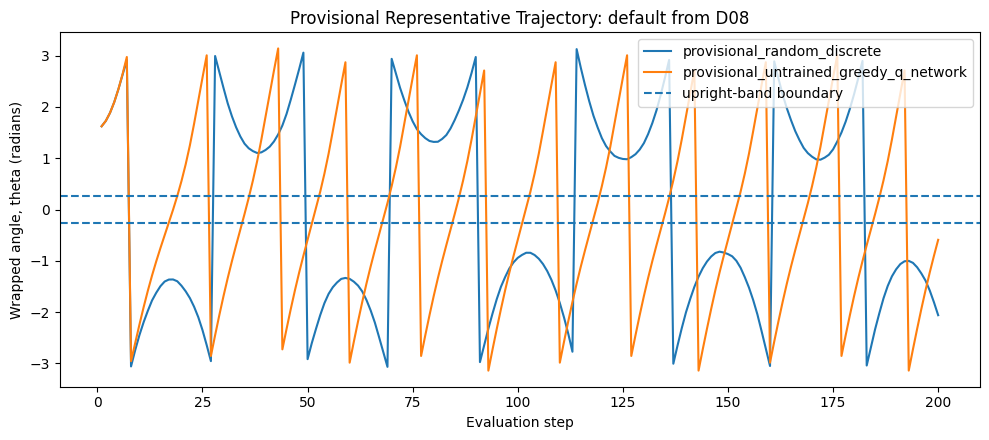

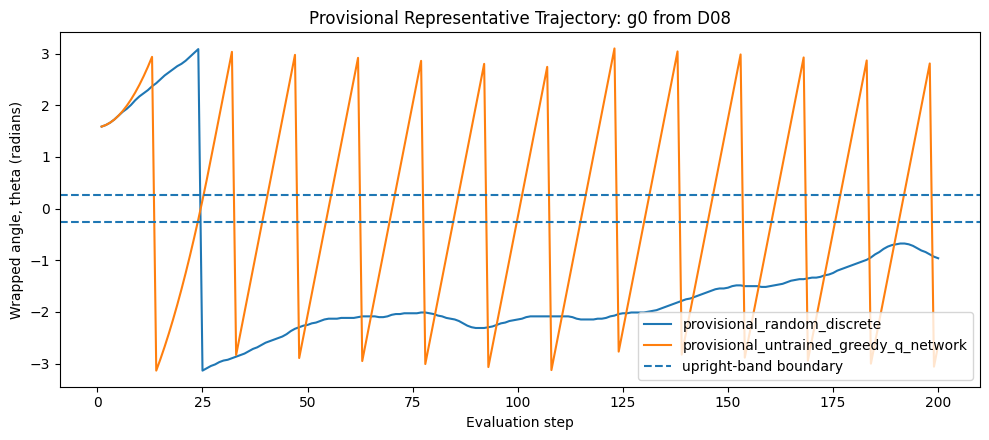

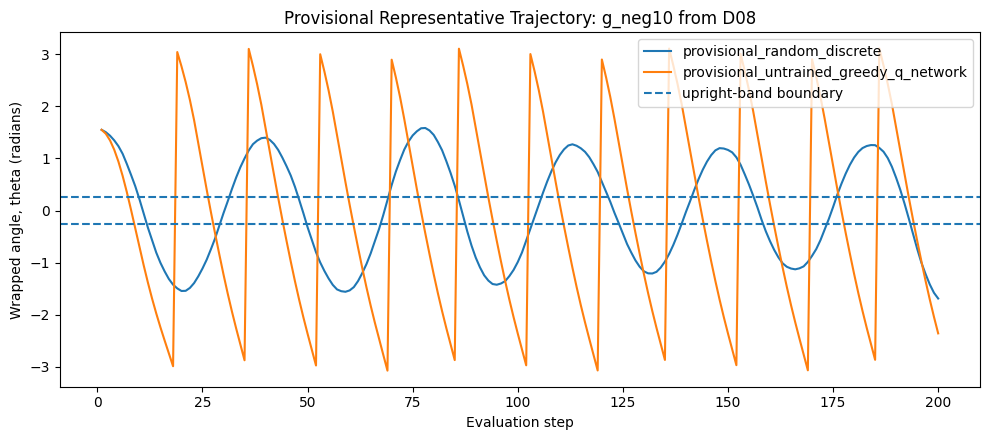

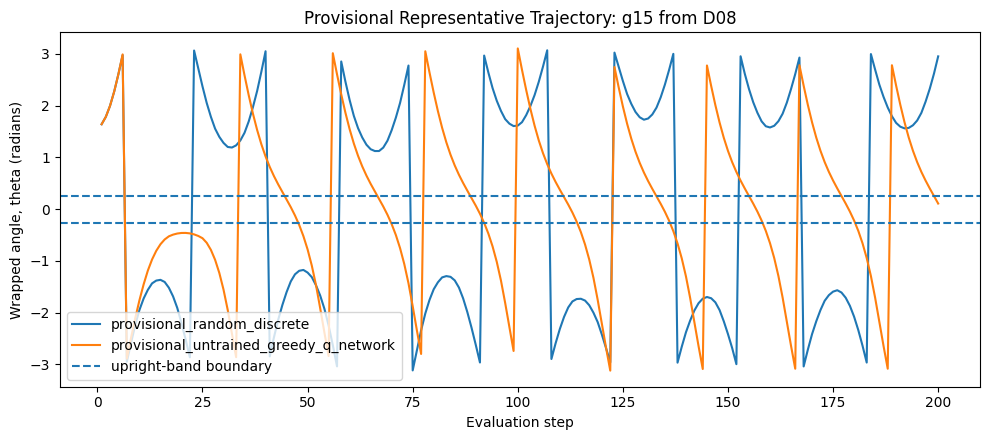

Provisional default-gravity return target to exceed: -1220.045207
Saved provisional reference summary: histories\R00_R01_PROVISIONAL_REFERENCE_SUMMARY.csv
Saved representative trajectories: histories\R00_R01_PROVISIONAL_REPRESENTATIVE_TRAJECTORIES.csv
Formal viability target remains deferred until Section 5.6 is regenerated after action-set selection.


In [29]:
PROVISIONAL_TRAJECTORY_STATE_ID = 8
PROVISIONAL_TRAJECTORY_STATE_LABEL = "D08"
PROVISIONAL_TRAJECTORY_THETA = float(
    DEVELOPMENT_PHYSICAL_STATES[PROVISIONAL_TRAJECTORY_STATE_ID, 0]
)
PROVISIONAL_TRAJECTORY_THETA_DOT = float(
    DEVELOPMENT_PHYSICAL_STATES[PROVISIONAL_TRAJECTORY_STATE_ID, 1]
)

np.testing.assert_allclose(
    [
        PROVISIONAL_TRAJECTORY_THETA,
        PROVISIONAL_TRAJECTORY_THETA_DOT,
    ],
    [np.pi / 2.0, 0.0],
    rtol=0.0,
    atol=1e-12,
)

default_random_summary_for_table = (
    provisional_random_default_summary
    .rename(columns={"base_seed": "seed"})
)
default_untrained_summary_for_table = (
    provisional_untrained_default_summary
    .rename(columns={"model_seed": "seed"})
)

provisional_reference_summary = pd.concat(
    [
        default_random_summary_for_table,
        default_untrained_summary_for_table,
        provisional_random_g0_summary,
        provisional_untrained_g0_summary,
        provisional_random_gneg10_summary,
        provisional_untrained_gneg10_summary,
        provisional_random_g15_summary,
        provisional_untrained_g15_summary,
    ],
    ignore_index=True,
)

provisional_reference_summary["reference_status"] = "provisional"
provisional_reference_summary["best_return_within_gravity"] = (
    provisional_reference_summary
    .groupby("gravity")["mean_return"]
    .transform("max")
)
provisional_reference_summary["return_gap_to_best_reference"] = (
    provisional_reference_summary["mean_return"]
    - provisional_reference_summary["best_return_within_gravity"]
)

summary_columns = [
    "run_id",
    "policy",
    "gravity",
    "action_set",
    "seed",
    "states_evaluated",
    "mean_return",
    "return_std",
    "mean_upright_fraction",
    "mean_abs_angle",
    "mean_abs_angular_velocity",
    "mean_abs_torque",
    "mean_torque_direction_switching_rate",
    "best_return_within_gravity",
    "return_gap_to_best_reference",
    "reference_status",
]
provisional_reference_summary = provisional_reference_summary[
    summary_columns
].copy()

assert len(provisional_reference_summary) == 8
assert set(provisional_reference_summary["gravity"]) == {
    "default",
    "g0",
    "g_neg10",
    "g15",
}
assert (
    provisional_reference_summary
    .groupby("gravity")
    .size()
    .eq(2)
    .all()
)
assert np.isfinite(
    provisional_reference_summary[
        [
            "mean_return",
            "return_std",
            "mean_upright_fraction",
            "mean_abs_angle",
            "mean_abs_angular_velocity",
            "mean_abs_torque",
            "mean_torque_direction_switching_rate",
        ]
    ].to_numpy()
).all()

provisional_reference_summary_path = (
    HISTORIES_DIR / "R00_R01_PROVISIONAL_REFERENCE_SUMMARY.csv"
)
provisional_reference_summary.to_csv(
    provisional_reference_summary_path,
    index=False,
)

display(
    provisional_reference_summary.sort_values(
        ["gravity", "policy"]
    ).reset_index(drop=True)
)


def collect_provisional_reference_trajectory(
    env_builder: Callable[[], object],
    torque_policy: Callable[[np.ndarray], float],
    policy_name: str,
    gravity_name: str,
    state_id: int,
    theta: float,
    theta_dot: float,
    horizon: int = EVALUATION_HORIZON,
) -> pd.DataFrame:
    """Collect one fixed-state trajectory without training or replay writes."""
    env = env_builder()
    records = []

    try:
        observation = reset_to_physical_state(
            env,
            theta,
            theta_dot,
        )
        cumulative_return = 0.0

        for step_index in range(horizon):
            torque = float(torque_policy(observation))
            action = np.array([torque], dtype=np.float32)

            next_observation, reward, done, info = env.step(action)
            next_observation = np.asarray(
                next_observation,
                dtype=np.float32,
            )
            cumulative_return += float(reward)

            records.append({
                "gravity": gravity_name,
                "policy": policy_name,
                "state_id": int(state_id),
                "state_label": f"D{state_id:02d}",
                "initial_theta": float(theta),
                "initial_theta_dot": float(theta_dot),
                "step": int(step_index + 1),
                "theta": float(
                    observation_to_angle(next_observation)
                ),
                "theta_dot": float(next_observation[2]),
                "torque": torque,
                "reward": float(reward),
                "cumulative_return": cumulative_return,
            })

            observation = next_observation

            if done:
                assert info.get("TimeLimit.truncated") is True
                break
    finally:
        env.close()

    trajectory = pd.DataFrame(records)
    assert len(trajectory) == horizon
    assert np.isfinite(
        trajectory[
            [
                "theta",
                "theta_dot",
                "torque",
                "reward",
                "cumulative_return",
            ]
        ].to_numpy()
    ).all()
    return trajectory


untrained_weights_before_trajectory_evaluation = [
    weight.numpy().copy()
    for weight in provisional_untrained_default_model.weights
]

provisional_trajectory_frames = []

for gravity_name, gravity_value in GRAVITY_SETTINGS.items():
    random_rng = np.random.default_rng(
        PROVISIONAL_RANDOM_BASE_SEED
        + PROVISIONAL_TRAJECTORY_STATE_ID
    )

    def representative_random_policy(
        observation: np.ndarray,
        rng=random_rng,
    ) -> float:
        del observation
        return float(rng.choice(PROVISIONAL_TORQUES_DEFAULT))

    env_builder = (
        (lambda: make_pendulum_env())
        if gravity_value is None
        else (
            lambda gravity_value=gravity_value:
            make_pendulum_env(gravity_value)
        )
    )

    provisional_trajectory_frames.append(
        collect_provisional_reference_trajectory(
            env_builder=env_builder,
            torque_policy=representative_random_policy,
            policy_name="provisional_random_discrete",
            gravity_name=gravity_name,
            state_id=PROVISIONAL_TRAJECTORY_STATE_ID,
            theta=PROVISIONAL_TRAJECTORY_THETA,
            theta_dot=PROVISIONAL_TRAJECTORY_THETA_DOT,
        )
    )
    provisional_trajectory_frames.append(
        collect_provisional_reference_trajectory(
            env_builder=env_builder,
            torque_policy=provisional_untrained_default_policy,
            policy_name="provisional_untrained_greedy_q_network",
            gravity_name=gravity_name,
            state_id=PROVISIONAL_TRAJECTORY_STATE_ID,
            theta=PROVISIONAL_TRAJECTORY_THETA,
            theta_dot=PROVISIONAL_TRAJECTORY_THETA_DOT,
        )
    )

provisional_reference_trajectories = pd.concat(
    provisional_trajectory_frames,
    ignore_index=True,
)

assert len(provisional_reference_trajectories) == (
    len(GRAVITY_SETTINGS) * 2 * EVALUATION_HORIZON
)

for before, after in zip(
    untrained_weights_before_trajectory_evaluation,
    provisional_untrained_default_model.weights,
):
    np.testing.assert_allclose(
        before,
        after.numpy(),
        rtol=0.0,
        atol=0.0,
    )

random_torque_sequences = (
    provisional_reference_trajectories[
        provisional_reference_trajectories["policy"]
        == "provisional_random_discrete"
    ]
    .pivot(index="step", columns="gravity", values="torque")
)

for gravity_name in GRAVITY_SETTINGS:
    np.testing.assert_allclose(
        random_torque_sequences[gravity_name].to_numpy(),
        random_torque_sequences["default"].to_numpy(),
        rtol=0.0,
        atol=0.0,
    )

provisional_trajectory_path = (
    HISTORIES_DIR
    / "R00_R01_PROVISIONAL_REPRESENTATIVE_TRAJECTORIES.csv"
)
provisional_reference_trajectories.to_csv(
    provisional_trajectory_path,
    index=False,
)

for gravity_name in GRAVITY_SETTINGS:
    gravity_trajectory = provisional_reference_trajectories[
        provisional_reference_trajectories["gravity"]
        == gravity_name
    ]

    plt.figure(figsize=(10, 4.5))
    for policy_name, policy_trajectory in gravity_trajectory.groupby(
        "policy"
    ):
        plt.plot(
            policy_trajectory["step"],
            policy_trajectory["theta"],
            label=policy_name,
        )

    plt.axhline(
        UPRIGHT_ANGLE_THRESHOLD_RAD,
        linestyle="--",
        label="upright-band boundary",
    )
    plt.axhline(
        -UPRIGHT_ANGLE_THRESHOLD_RAD,
        linestyle="--",
    )
    plt.xlabel("Evaluation step")
    plt.ylabel("Wrapped angle, theta (radians)")
    plt.title(
        f"Provisional Representative Trajectory: {gravity_name} "
        f"from {PROVISIONAL_TRAJECTORY_STATE_LABEL}"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

provisional_default_reference_target = float(
    provisional_reference_summary.loc[
        provisional_reference_summary["gravity"] == "default",
        "mean_return",
    ].max()
)

print(
    "Provisional default-gravity return target to exceed:",
    round(provisional_default_reference_target, 6),
)
print(
    "Saved provisional reference summary:",
    provisional_reference_summary_path,
)
print(
    "Saved representative trajectories:",
    provisional_trajectory_path,
)
print(
    "Formal viability target remains deferred until "
    "Section 5.6 is regenerated after action-set selection."
)


### 5.7 Result Interpretation

**Finding.** All eight provisional references were consolidated successfully.
The random policy had the stronger mean return under default gravity, `g = 0`,
and `g = -10`, while the particular untrained greedy network had the stronger
mean return under `g = 15`. The current default-gravity provisional return
target is therefore `-1220.045207`.

The four `D08` trajectory plots also show visibly different dynamics across
gravity settings. Neither arbitrary policy remains consistently inside the
upright band, so the plots support interpretation but do not provide viability
evidence.

**Importance.** The ranking between random and untrained policies changes with
gravity. This confirms that a learned policy must be compared with references
under the same gravity and evaluated using return together with angle, angular
velocity, upright occupancy, torque magnitude, and switching behaviour.

**Decision.** Retain the summary table, trajectory CSV, and four trajectory
plots as provisional orientation evidence. Do not use them to select the action
set or final model.

**Caveat.** These references use the temporary three-action set and one
reproducible untrained initialisation. The numerical viability target is not
formal.

**Next step.** Begin Section 6 by validating the shared DQN state, action, and
greedy-decision helpers. Formal training remains blocked until all Section 6
component smoke tests pass.


### Section 5 Completion Status

- Default-gravity random reference: PASS
- Default-gravity untrained reference: PASS
- `g = 0` provisional references: PASS
- `g = -10` provisional references: PASS
- `g = 15` provisional references: PASS
- Eight-row provisional summary: PASS
- Predeclared representative trajectories: PASS
- Formal reference regeneration: DEFERRED UNTIL SECTION 7
- Formal viability threshold: DEFERRED UNTIL SECTION 7

**Section 5 provisional-reference stage: COMPLETE**

At this stage, all references were provisional and formal DQN training was
still blocked until the Section 6 component smoke tests passed.


# 6. Vanilla DQN Correctness and Viability

Section 6 builds the class-aligned Vanilla DQN visibly and validates each
component before any pilot training begins.

The implementation follows the course framework of:

```text
continuous state
→ one Q-value per fixed discrete action
→ epsilon-greedy training decisions
→ replay memory and random minibatches
→ target-network Bellman values
→ GradientTape update
→ periodic hard target updates
```

No pilot or formal training is approved until the output, replay, action,
Bellman, gradient, target-update, finite-value, evaluation-isolation, and reload
smoke tests pass.


## 6.1 Shared DQN Components

**Purpose.** Define the state tensor, discrete torque mapping, and direct greedy
model-call helpers shared by Vanilla, Double, Dueling, and any justified
combined model.

**Course-material alignment.** Practical 6 describes Deep Q Learning as
supporting continuous input spaces with a fixed number of discrete actions.
Accordingly, Pendulum's three-value continuous observation is provided directly
to the Q-network, while each output index maps to one fixed torque.

**Current action status.** The temporary action set `[-2.0, 0.0, 2.0]` is used
only for DQN correctness and the Vanilla viability pilot. Section 7 will still
compare 3, 5, and 7 actions before the formal action set is selected.

**Training budget.** None. This subsection defines and smoke-tests shared helper
contracts only.


In [30]:
DQN_STATE_DIM = 3
PILOT_TORQUE_VALUES = np.asarray(
    PROVISIONAL_TORQUES_DEFAULT,
    dtype=np.float32,
).copy()


def validate_discrete_torque_values(
    torque_values: np.ndarray,
) -> np.ndarray:
    """Validate one ordered, symmetric discrete torque set."""
    values = np.asarray(torque_values, dtype=np.float32).reshape(-1)

    assert values.ndim == 1
    assert len(values) >= 2
    assert np.isfinite(values).all()
    assert np.all(np.diff(values) > 0), (
        "Torque values must be strictly increasing."
    )
    assert np.all(values >= action_low[0])
    assert np.all(values <= action_high[0])
    assert np.isclose(values[0], action_low[0])
    assert np.isclose(values[-1], action_high[0])
    assert np.allclose(values, -values[::-1])
    assert np.any(np.isclose(values, 0.0))

    return values.copy()


def state_to_tensor(observation: np.ndarray) -> tf.Tensor:
    """Convert one Pendulum observation into a finite `(1, 3)` tensor."""
    state = np.asarray(observation, dtype=np.float32)
    assert state.shape == (DQN_STATE_DIM,), (
        f"Expected state shape {(DQN_STATE_DIM,)}, received {state.shape}."
    )
    assert np.isfinite(state).all()
    return tf.convert_to_tensor(state[None, :], dtype=tf.float32)


def action_index_to_torque(
    action_index: int,
    torque_values: np.ndarray,
) -> float:
    """Map one valid discrete action index to its scalar torque."""
    values = validate_discrete_torque_values(torque_values)
    assert isinstance(action_index, (int, np.integer))
    assert 0 <= int(action_index) < len(values)
    return float(values[int(action_index)])


def greedy_discrete_action(
    model: keras.Model,
    observation: np.ndarray,
    torque_values: np.ndarray,
) -> Tuple[int, float, np.ndarray]:
    """Select a greedy discrete torque using a direct tensor model call."""
    values = validate_discrete_torque_values(torque_values)
    state_tensor = state_to_tensor(observation)

    q_values_tensor = model(state_tensor, training=False)
    q_values = np.asarray(q_values_tensor.numpy(), dtype=np.float32)

    assert q_values.shape == (1, len(values)), (
        f"Expected Q-value shape {(1, len(values))}, "
        f"received {q_values.shape}."
    )
    assert np.isfinite(q_values).all()

    action_index = int(tf.argmax(q_values_tensor[0]).numpy())
    torque = action_index_to_torque(action_index, values)
    return action_index, torque, q_values[0].copy()


PILOT_TORQUE_VALUES = validate_discrete_torque_values(
    PILOT_TORQUE_VALUES
)

mapping_rows = []
for action_index in range(len(PILOT_TORQUE_VALUES)):
    mapping_rows.append({
        "action_index": action_index,
        "torque": action_index_to_torque(
            action_index,
            PILOT_TORQUE_VALUES,
        ),
    })

shared_component_probe_state = np.array(
    [1.0, 0.0, 0.0],
    dtype=np.float32,
)
shared_component_state_tensor = state_to_tensor(
    shared_component_probe_state
)
assert shared_component_state_tensor.shape == (1, DQN_STATE_DIM)
assert shared_component_state_tensor.dtype == tf.float32

probe_action_index, probe_torque, probe_q_values = (
    greedy_discrete_action(
        provisional_untrained_default_model,
        shared_component_probe_state,
        PILOT_TORQUE_VALUES,
    )
)

assert 0 <= probe_action_index < len(PILOT_TORQUE_VALUES)
assert probe_torque in PILOT_TORQUE_VALUES
assert probe_q_values.shape == (len(PILOT_TORQUE_VALUES),)

try:
    action_index_to_torque(
        len(PILOT_TORQUE_VALUES),
        PILOT_TORQUE_VALUES,
    )
    raise AssertionError("Out-of-range action index was not rejected.")
except AssertionError as error:
    assert "Out-of-range action index was not rejected." not in str(error)

display(pd.DataFrame(mapping_rows))
print("State tensor shape:", tuple(shared_component_state_tensor.shape))
print("Probe Q-values:", probe_q_values)
print("Probe greedy action index:", probe_action_index)
print("Probe greedy torque:", probe_torque)
print("Section 6.1 shared-component smoke test: PASS")


,action_index,torque
0,0,-2.0
1,1,0.0
2,2,2.0


State tensor shape: (1, 3)
Probe Q-values: [-0.27805498 -0.33850658 -0.02874875]
Probe greedy action index: 2
Probe greedy torque: 2.0
Section 6.1 shared-component smoke test: PASS


## 6.2 Replay Memory

**Question.** Can the replay memory store valid Pendulum transitions, enforce a
fixed capacity, and return reproducible random minibatches with the correct
tensor-ready shapes?

**Reason.** DQN learns from randomly sampled past transitions rather than only
the newest transition. This reduces the strong temporal ordering of consecutive
environment steps and allows each experience to be reused.

**Hypothesis.** A `deque` with a fixed maximum length will remove the oldest
transition automatically, while `random.sample` will return minibatches without
replacement.

**Reference configuration.** The shared Section 6.1 state dimension and
temporary three-action torque set are used for correctness testing.

**Primary change.** Add a bounded replay-memory class storing:

```text
state, action_index, reward, next_state
```

No terminal mask is stored because the Section 3 preflight established that
Pendulum has no natural terminal transition and the step-200 boundary is a
time-limit truncation. Episode boundaries may still be logged separately.

**Controlled factors.**

- state dimension: `3`;
- temporary action count: `3`;
- finite `float32` states and rewards;
- integer action indices;
- deterministic smoke-test sampler seed `42`;
- no environment interaction or network update.

**Training budget.** None. This subsection performs component validation only.

**Evaluation evidence.** Verify capacity eviction, copied transition data,
sample shapes, valid actions, finite values, random sampling, and rejection of
invalid requests.

**Decision rule.** Section 6.2 passes only when every assertion succeeds and
the final PASS message is printed.


In [31]:
from collections import deque


class ReplayMemory:
    """Bounded replay memory for nonterminal Pendulum transitions."""

    def __init__(
        self,
        capacity: int,
        state_dim: int,
        action_count: int,
    ) -> None:
        assert isinstance(capacity, (int, np.integer))
        assert int(capacity) > 0
        assert isinstance(state_dim, (int, np.integer))
        assert int(state_dim) > 0
        assert isinstance(action_count, (int, np.integer))
        assert int(action_count) > 1

        self.capacity = int(capacity)
        self.state_dim = int(state_dim)
        self.action_count = int(action_count)
        self._buffer = deque(maxlen=self.capacity)

    def __len__(self) -> int:
        return len(self._buffer)

    def append(
        self,
        state: np.ndarray,
        action_index: int,
        reward: float,
        next_state: np.ndarray,
    ) -> None:
        state_array = np.asarray(state, dtype=np.float32)
        next_state_array = np.asarray(next_state, dtype=np.float32)

        assert state_array.shape == (self.state_dim,)
        assert next_state_array.shape == (self.state_dim,)
        assert np.isfinite(state_array).all()
        assert np.isfinite(next_state_array).all()

        assert isinstance(action_index, (int, np.integer))
        assert 0 <= int(action_index) < self.action_count

        reward_value = float(reward)
        assert np.isfinite(reward_value)

        self._buffer.append(
            (
                state_array.copy(),
                int(action_index),
                reward_value,
                next_state_array.copy(),
            )
        )

    def sample(
        self,
        batch_size: int,
        rng: random.Random,
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        assert isinstance(batch_size, (int, np.integer))
        assert int(batch_size) > 0
        assert int(batch_size) <= len(self._buffer), (
            "Replay sample size cannot exceed stored transitions."
        )
        assert isinstance(rng, random.Random)

        sampled_transitions = rng.sample(
            list(self._buffer),
            int(batch_size),
        )
        states, action_indices, rewards, next_states = zip(
            *sampled_transitions
        )

        state_batch = np.stack(states).astype(np.float32)
        action_batch = np.asarray(action_indices, dtype=np.int32)
        reward_batch = np.asarray(rewards, dtype=np.float32)
        next_state_batch = np.stack(next_states).astype(np.float32)

        assert state_batch.shape == (
            int(batch_size),
            self.state_dim,
        )
        assert action_batch.shape == (int(batch_size),)
        assert reward_batch.shape == (int(batch_size),)
        assert next_state_batch.shape == (
            int(batch_size),
            self.state_dim,
        )
        assert np.isfinite(state_batch).all()
        assert np.isfinite(reward_batch).all()
        assert np.isfinite(next_state_batch).all()
        assert np.all(action_batch >= 0)
        assert np.all(action_batch < self.action_count)

        return (
            state_batch,
            action_batch,
            reward_batch,
            next_state_batch,
        )


REPLAY_SMOKE_CAPACITY = 5
REPLAY_SMOKE_BATCH_SIZE = 3

replay_smoke_memory = ReplayMemory(
    capacity=REPLAY_SMOKE_CAPACITY,
    state_dim=DQN_STATE_DIM,
    action_count=len(PILOT_TORQUE_VALUES),
)

generated_transitions = []
for transition_index in range(REPLAY_SMOKE_CAPACITY + 1):
    theta = 0.1 * transition_index
    next_theta = theta + 0.05

    state = np.array(
        [
            np.cos(theta),
            np.sin(theta),
            -1.0 + 0.2 * transition_index,
        ],
        dtype=np.float32,
    )
    next_state = np.array(
        [
            np.cos(next_theta),
            np.sin(next_theta),
            -0.9 + 0.2 * transition_index,
        ],
        dtype=np.float32,
    )
    action_index = transition_index % len(PILOT_TORQUE_VALUES)
    reward = -float(transition_index)

    replay_smoke_memory.append(
        state,
        action_index,
        reward,
        next_state,
    )
    generated_transitions.append(
        (state.copy(), action_index, reward, next_state.copy())
    )

assert len(replay_smoke_memory) == REPLAY_SMOKE_CAPACITY

# The sixth insertion must evict the first transition.
np.testing.assert_allclose(
    replay_smoke_memory._buffer[0][0],
    generated_transitions[1][0],
    rtol=0.0,
    atol=0.0,
)
assert replay_smoke_memory._buffer[0][1] == generated_transitions[1][1]
assert replay_smoke_memory._buffer[0][2] == generated_transitions[1][2]

# Stored arrays must be copies rather than references to caller-owned arrays.
copy_probe_state = np.array([1.0, 0.0, 0.0], dtype=np.float32)
copy_probe_next_state = np.array(
    [np.cos(0.05), np.sin(0.05), 0.1],
    dtype=np.float32,
)
copy_probe_memory = ReplayMemory(
    capacity=2,
    state_dim=DQN_STATE_DIM,
    action_count=len(PILOT_TORQUE_VALUES),
)
copy_probe_memory.append(
    copy_probe_state,
    1,
    -0.25,
    copy_probe_next_state,
)
copy_probe_state[:] = 99.0
copy_probe_next_state[:] = 99.0

np.testing.assert_allclose(
    copy_probe_memory._buffer[0][0],
    [1.0, 0.0, 0.0],
    rtol=0.0,
    atol=0.0,
)
assert not np.all(copy_probe_memory._buffer[0][3] == 99.0)

sample_rng = random.Random(42)
(
    sampled_states,
    sampled_actions,
    sampled_rewards,
    sampled_next_states,
) = replay_smoke_memory.sample(
    REPLAY_SMOKE_BATCH_SIZE,
    sample_rng,
)

assert sampled_states.shape == (
    REPLAY_SMOKE_BATCH_SIZE,
    DQN_STATE_DIM,
)
assert sampled_actions.shape == (REPLAY_SMOKE_BATCH_SIZE,)
assert sampled_rewards.shape == (REPLAY_SMOKE_BATCH_SIZE,)
assert sampled_next_states.shape == (
    REPLAY_SMOKE_BATCH_SIZE,
    DQN_STATE_DIM,
)

try:
    replay_smoke_memory.sample(
        REPLAY_SMOKE_CAPACITY + 1,
        random.Random(42),
    )
    raise AssertionError(
        "Oversized replay sample request was not rejected."
    )
except AssertionError as error:
    assert "cannot exceed" in str(error)

try:
    replay_smoke_memory.append(
        generated_transitions[1][0],
        len(PILOT_TORQUE_VALUES),
        -1.0,
        generated_transitions[1][3],
    )
    raise AssertionError(
        "Out-of-range replay action was not rejected."
    )
except AssertionError as error:
    assert "Out-of-range replay action was not rejected." not in str(error)

replay_sample_summary = pd.DataFrame({
    "sample_row": np.arange(REPLAY_SMOKE_BATCH_SIZE),
    "action_index": sampled_actions,
    "torque": [
        action_index_to_torque(
            int(action_index),
            PILOT_TORQUE_VALUES,
        )
        for action_index in sampled_actions
    ],
    "reward": sampled_rewards,
})

display(replay_sample_summary)
print("Replay capacity:", replay_smoke_memory.capacity)
print("Stored transitions after eviction:", len(replay_smoke_memory))
print("Sampled state batch shape:", sampled_states.shape)
print("Sampled action batch shape:", sampled_actions.shape)
print("Sampled reward batch shape:", sampled_rewards.shape)
print("Sampled next-state batch shape:", sampled_next_states.shape)
print("Replay transition fields: state, action_index, reward, next_state")
print("Section 6.2 replay-memory smoke test: PASS")


,sample_row,action_index,torque,reward
0,0,1,0.0,-1.0
1,1,2,2.0,-5.0
2,2,0,-2.0,-3.0


Replay capacity: 5
Stored transitions after eviction: 5
Sampled state batch shape: (3, 3)
Sampled action batch shape: (3,)
Sampled reward batch shape: (3,)
Sampled next-state batch shape: (3, 3)
Replay transition fields: state, action_index, reward, next_state
Section 6.2 replay-memory smoke test: PASS


## 6.3 Standard Q-Network Builder

**Question.** Can one reusable Keras builder create the class-aligned Vanilla
DQN network for different discrete action counts while preserving a linear
Q-value output?

**Reason.** Practical 6 describes DQN as a neural approximation of `Q(s, a)`
for continuous input states and a fixed number of discrete actions. The
baseline reference uses a dense network with two hidden ReLU layers and
one linear output per action.

**Hypothesis.** A parameterised builder with hidden units `(64, 64)` will
produce finite Q-values and the correct output dimension for the temporary
three-action pilot as well as the later 5- and 7-action comparisons.

**Reference configuration.**

- input dimension: `3`;
- hidden layers: `64`, `64`;
- hidden activation: ReLU;
- output activation: linear;
- one output per discrete torque;
- fresh reproducible initialisation.

The `(64, 64)` width is the current baseline pilot reference. It is not
the final winning capacity and may be revisited only when later diagnosis
justifies a capacity experiment.

**Primary change.** Add the standard Q-network builder.

**Controlled factors.**

- no optimiser;
- no loss function;
- no replay sampling;
- no target network;
- no gradient update;
- no environment interaction.

**Training budget.** None. This subsection validates architecture construction
only.

**Evaluation evidence.** Verify input and output shapes, two ReLU hidden layers,
linear output activation, finite Q-values, action-count flexibility, and
parameter counts.

**Decision rule.** Section 6.3 passes only when all assertions succeed and the
PASS message is printed.


In [32]:
STANDARD_HIDDEN_UNITS = (64, 64)


def build_standard_q_network(
    state_dim: int,
    action_count: int,
    hidden_units: Tuple[int, ...] = STANDARD_HIDDEN_UNITS,
    model_name: str = "standard_q_network",
) -> keras.Model:
    """Build the class-aligned dense Q-network used by Vanilla DQN."""
    assert isinstance(state_dim, (int, np.integer))
    assert int(state_dim) > 0
    assert isinstance(action_count, (int, np.integer))
    assert int(action_count) > 1

    hidden_units = tuple(int(units) for units in hidden_units)
    assert len(hidden_units) == 2, (
        "The baseline reference must use two hidden layers."
    )
    assert all(units > 0 for units in hidden_units)

    inputs = keras.Input(
        shape=(int(state_dim),),
        dtype=tf.float32,
        name="state",
    )
    hidden = inputs

    for layer_index, units in enumerate(hidden_units, start=1):
        hidden = layers.Dense(
            units,
            activation="relu",
            name=f"hidden_{layer_index}",
        )(hidden)

    q_values = layers.Dense(
        int(action_count),
        activation="linear",
        name="q_values",
    )(hidden)

    return keras.Model(
        inputs=inputs,
        outputs=q_values,
        name=model_name,
    )


tf.keras.utils.set_random_seed(42)

standard_q_network_smoke = build_standard_q_network(
    state_dim=DQN_STATE_DIM,
    action_count=len(PILOT_TORQUE_VALUES),
    model_name="standard_q_network_smoke",
)

architecture_probe_states = tf.constant(
    [
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 1.5],
        [-1.0, 0.0, -2.0],
        [0.0, -1.0, 0.5],
    ],
    dtype=tf.float32,
)

architecture_probe_q_values = standard_q_network_smoke(
    architecture_probe_states,
    training=False,
).numpy()

assert standard_q_network_smoke.input_shape == (
    None,
    DQN_STATE_DIM,
)
assert standard_q_network_smoke.output_shape == (
    None,
    len(PILOT_TORQUE_VALUES),
)
assert architecture_probe_q_values.shape == (
    len(architecture_probe_states),
    len(PILOT_TORQUE_VALUES),
)
assert np.isfinite(architecture_probe_q_values).all()

dense_layers = [
    layer
    for layer in standard_q_network_smoke.layers
    if isinstance(layer, layers.Dense)
]
assert len(dense_layers) == 3
assert [layer.units for layer in dense_layers] == [
    64,
    64,
    len(PILOT_TORQUE_VALUES),
]
assert [
    layer.activation.__name__
    for layer in dense_layers[:-1]
] == ["relu", "relu"]
assert dense_layers[-1].activation.__name__ == "linear"

expected_three_action_parameters = (
    (DQN_STATE_DIM * 64 + 64)
    + (64 * 64 + 64)
    + (64 * len(PILOT_TORQUE_VALUES)
       + len(PILOT_TORQUE_VALUES))
)
assert standard_q_network_smoke.count_params() == (
    expected_three_action_parameters
)

architecture_rows = []

for action_count in (3, 5, 7):
    tf.keras.utils.set_random_seed(42)
    candidate_model = build_standard_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=action_count,
        model_name=f"standard_q_network_{action_count}_actions",
    )
    candidate_q_values = candidate_model(
        architecture_probe_states,
        training=False,
    ).numpy()

    assert candidate_q_values.shape == (
        len(architecture_probe_states),
        action_count,
    )
    assert np.isfinite(candidate_q_values).all()
    assert candidate_model.layers[-1].activation.__name__ == "linear"

    architecture_rows.append({
        "action_count": action_count,
        "hidden_units": list(STANDARD_HIDDEN_UNITS),
        "hidden_activation": "relu",
        "output_activation": "linear",
        "output_shape": candidate_q_values.shape,
        "parameter_count": candidate_model.count_params(),
    })

standard_q_network_architecture_table = pd.DataFrame(
    architecture_rows
)

display(standard_q_network_architecture_table)
print(
    "Three-action probe Q-value shape:",
    architecture_probe_q_values.shape,
)
print(
    "Three-action parameter count:",
    standard_q_network_smoke.count_params(),
)
print(
    "Dense activations:",
    [layer.activation.__name__ for layer in dense_layers],
)
print("Section 6.3 standard Q-network builder smoke test: PASS")


,action_count,hidden_units,hidden_activation,output_activation,output_shape,parameter_count
0,3,"[64, 64]",relu,linear,"(4, 3)",4611
1,5,"[64, 64]",relu,linear,"(4, 5)",4741
2,7,"[64, 64]",relu,linear,"(4, 7)",4871


Three-action probe Q-value shape: (4, 3)
Three-action parameter count: 4611
Dense activations: ['relu', 'relu', 'linear']
Section 6.3 standard Q-network builder smoke test: PASS


## 6.4 Main and Target Network Initialisation

**Question.** Can the Vanilla DQN initialise two independent Q-networks with
identical starting weights?

**Reason.** The main network is updated by gradient descent, while the target
network provides temporarily stable Bellman values. They must begin with the
same weights but remain separate model objects so that updating one does not
silently modify the other.

**Hypothesis.** Building two matching models and explicitly copying the main
weights into the target network will produce identical Q-values initially,
while their variables remain independent.

**Reference configuration.**

- standard `(64, 64)` dense Q-network;
- temporary three-action torque set;
- initialisation seed `42`;
- direct tensor calls with `training=False`.

**Primary change.** Add a helper that creates the main and target networks and
performs the initial weight copy.

**Controlled factors.**

- same input dimension;
- same output dimension;
- same architecture;
- no optimiser;
- no replay sampling;
- no gradient update;
- no target-update schedule;
- no environment interaction.

**Training budget.** None. This subsection validates network initialisation
only.

**Evaluation evidence.** Verify matching shapes and parameter counts, exact
initial weight equality, identical initial Q-values, separate variable objects,
and no accidental target change when the main network is modified.

**Decision rule.** Section 6.4 passes only when all assertions succeed and the
PASS message is printed.


In [33]:
def initialise_main_and_target_networks(
    state_dim: int,
    action_count: int,
    hidden_units: Tuple[int, ...] = STANDARD_HIDDEN_UNITS,
    seed: int = 42,
) -> Tuple[keras.Model, keras.Model]:
    """Create independent main and target Q-networks with matched weights."""
    tf.keras.utils.set_random_seed(int(seed))

    main_network = build_standard_q_network(
        state_dim=state_dim,
        action_count=action_count,
        hidden_units=hidden_units,
        model_name="main_q_network",
    )
    target_network = build_standard_q_network(
        state_dim=state_dim,
        action_count=action_count,
        hidden_units=hidden_units,
        model_name="target_q_network",
    )

    target_network.set_weights(main_network.get_weights())
    return main_network, target_network


main_network_smoke, target_network_smoke = (
    initialise_main_and_target_networks(
        state_dim=DQN_STATE_DIM,
        action_count=len(PILOT_TORQUE_VALUES),
        seed=42,
    )
)

assert main_network_smoke is not target_network_smoke
assert main_network_smoke.input_shape == target_network_smoke.input_shape
assert main_network_smoke.output_shape == target_network_smoke.output_shape
assert main_network_smoke.count_params() == (
    target_network_smoke.count_params()
)
assert main_network_smoke.output_shape == (
    None,
    len(PILOT_TORQUE_VALUES),
)
assert main_network_smoke.layers[-1].activation.__name__ == "linear"
assert target_network_smoke.layers[-1].activation.__name__ == "linear"

main_initial_weights = [
    weight.numpy().copy()
    for weight in main_network_smoke.weights
]
target_initial_weights = [
    weight.numpy().copy()
    for weight in target_network_smoke.weights
]

assert len(main_initial_weights) == len(target_initial_weights)
assert all(
    main_weight is not target_weight
    for main_weight, target_weight in zip(
        main_network_smoke.weights,
        target_network_smoke.weights,
    )
)

for main_weight, target_weight in zip(
    main_initial_weights,
    target_initial_weights,
):
    np.testing.assert_allclose(
        main_weight,
        target_weight,
        rtol=0.0,
        atol=0.0,
    )

main_initial_q_values = main_network_smoke(
    architecture_probe_states,
    training=False,
).numpy()
target_initial_q_values = target_network_smoke(
    architecture_probe_states,
    training=False,
).numpy()

np.testing.assert_allclose(
    main_initial_q_values,
    target_initial_q_values,
    rtol=0.0,
    atol=0.0,
)
assert np.isfinite(main_initial_q_values).all()
assert np.isfinite(target_initial_q_values).all()

# Modify only the main network to verify that both models own separate variables.
main_network_smoke.weights[0].assign_add(
    tf.ones_like(main_network_smoke.weights[0]) * 1e-4
)

assert not np.array_equal(
    main_network_smoke.weights[0].numpy(),
    target_network_smoke.weights[0].numpy(),
)
np.testing.assert_allclose(
    target_network_smoke.weights[0].numpy(),
    target_initial_weights[0],
    rtol=0.0,
    atol=0.0,
)

# Restore the original matched initial state for later component tests.
main_network_smoke.set_weights(main_initial_weights)

for main_weight, target_weight in zip(
    main_network_smoke.weights,
    target_network_smoke.weights,
):
    np.testing.assert_allclose(
        main_weight.numpy(),
        target_weight.numpy(),
        rtol=0.0,
        atol=0.0,
    )

initialisation_summary = pd.DataFrame({
    "network": ["main", "target"],
    "input_shape": [
        main_network_smoke.input_shape,
        target_network_smoke.input_shape,
    ],
    "output_shape": [
        main_network_smoke.output_shape,
        target_network_smoke.output_shape,
    ],
    "parameter_count": [
        main_network_smoke.count_params(),
        target_network_smoke.count_params(),
    ],
    "output_activation": [
        main_network_smoke.layers[-1].activation.__name__,
        target_network_smoke.layers[-1].activation.__name__,
    ],
})

display(initialisation_summary)
print(
    "Initial main-target maximum Q-value difference:",
    float(
        np.max(
            np.abs(
                main_initial_q_values - target_initial_q_values
            )
        )
    ),
)
print(
    "Separate variable objects:",
    all(
        main_weight is not target_weight
        for main_weight, target_weight in zip(
            main_network_smoke.weights,
            target_network_smoke.weights,
        )
    ),
)
print("Section 6.4 main-target initialisation smoke test: PASS")


,network,input_shape,output_shape,parameter_count,output_activation
0,main,"(None, 3)","(None, 3)",4611,linear
1,target,"(None, 3)","(None, 3)",4611,linear


Initial main-target maximum Q-value difference: 0.0
Separate variable objects: True
Section 6.4 main-target initialisation smoke test: PASS


## 6.5 Epsilon-Greedy Action Selection

**Question.** Can one action-selection helper switch correctly between random
exploration and greedy exploitation while always producing a valid discrete
torque?

**Reason.** DQN requires exploration during training but greedy decisions
during formal evaluation. The helper must therefore make the exploration rule
explicit and reproducible without using `model.predict()` inside the
environment step loop.

**Hypothesis.**

- `epsilon = 0.0` will always select the greedy action;
- `epsilon = 1.0` will always select a random valid action;
- identical random-generator seeds will reproduce the same exploratory action
  sequence;
- neither branch will change the Q-network weights.

**Reference configuration.**

- temporary three-action torque set `[-2.0, 0.0, 2.0]`;
- standard main Q-network from Section 6.4;
- direct tensor call with `training=False` for greedy decisions;
- Python `random.Random` objects for reproducible exploration.

**Primary change.** Add the epsilon-greedy action selector.

**Controlled factors.**

- one fixed probe observation;
- unchanged network weights;
- no replay insertion;
- no gradient update;
- no environment interaction;
- no epsilon decay schedule yet.

**Training budget.** None. This subsection performs action-selection validation
only.

**Evaluation evidence.** Verify greedy equivalence, fully random exploration,
reproducibility, action-index and torque validity, mixed exploration behaviour,
invalid-epsilon rejection, and weight isolation.

**Decision rule.** Section 6.5 passes only when all assertions succeed and the
PASS message is printed.


In [34]:
def epsilon_greedy_discrete_action(
    model: keras.Model,
    observation: np.ndarray,
    torque_values: np.ndarray,
    epsilon: float,
    rng: random.Random,
) -> Tuple[int, float, bool]:
    """Select one random or greedy discrete torque."""
    values = validate_discrete_torque_values(torque_values)

    epsilon_value = float(epsilon)
    assert np.isfinite(epsilon_value)
    assert 0.0 <= epsilon_value <= 1.0, (
        "Epsilon must lie within [0, 1]."
    )
    assert isinstance(rng, random.Random)

    if rng.random() < epsilon_value:
        action_index = rng.randrange(len(values))
        torque = action_index_to_torque(action_index, values)
        return action_index, torque, True

    action_index, torque, _ = greedy_discrete_action(
        model,
        observation,
        values,
    )
    return action_index, torque, False


epsilon_probe_state = np.array(
    [0.0, 1.0, 0.5],
    dtype=np.float32,
)

epsilon_weight_snapshot = [
    weight.numpy().copy()
    for weight in main_network_smoke.weights
]

expected_greedy_index, expected_greedy_torque, _ = (
    greedy_discrete_action(
        main_network_smoke,
        epsilon_probe_state,
        PILOT_TORQUE_VALUES,
    )
)

greedy_records = []
for seed in (7, 42, 123):
    action_index, torque, was_random = (
        epsilon_greedy_discrete_action(
            main_network_smoke,
            epsilon_probe_state,
            PILOT_TORQUE_VALUES,
            epsilon=0.0,
            rng=random.Random(seed),
        )
    )
    assert action_index == expected_greedy_index
    assert np.isclose(torque, expected_greedy_torque)
    assert was_random is False
    greedy_records.append(action_index)

random_rng_a = random.Random(42)
random_rng_b = random.Random(42)

random_records_a = [
    epsilon_greedy_discrete_action(
        main_network_smoke,
        epsilon_probe_state,
        PILOT_TORQUE_VALUES,
        epsilon=1.0,
        rng=random_rng_a,
    )
    for _ in range(30)
]
random_records_b = [
    epsilon_greedy_discrete_action(
        main_network_smoke,
        epsilon_probe_state,
        PILOT_TORQUE_VALUES,
        epsilon=1.0,
        rng=random_rng_b,
    )
    for _ in range(30)
]

random_indices_a = [record[0] for record in random_records_a]
random_indices_b = [record[0] for record in random_records_b]
random_torques_a = [record[1] for record in random_records_a]

assert random_indices_a == random_indices_b
assert all(record[2] is True for record in random_records_a)
assert len(set(random_indices_a)) > 1
assert all(
    0 <= action_index < len(PILOT_TORQUE_VALUES)
    for action_index in random_indices_a
)
assert all(
    torque in PILOT_TORQUE_VALUES
    for torque in random_torques_a
)

mixed_rng = random.Random(123)
mixed_records = [
    epsilon_greedy_discrete_action(
        main_network_smoke,
        epsilon_probe_state,
        PILOT_TORQUE_VALUES,
        epsilon=0.35,
        rng=mixed_rng,
    )
    for _ in range(100)
]

mixed_random_count = sum(record[2] for record in mixed_records)
mixed_greedy_count = len(mixed_records) - mixed_random_count

assert 0 < mixed_random_count < len(mixed_records)
assert 0 < mixed_greedy_count < len(mixed_records)

try:
    epsilon_greedy_discrete_action(
        main_network_smoke,
        epsilon_probe_state,
        PILOT_TORQUE_VALUES,
        epsilon=-0.01,
        rng=random.Random(42),
    )
    raise AssertionError("Negative epsilon was not rejected.")
except AssertionError as error:
    assert "within [0, 1]" in str(error)

try:
    epsilon_greedy_discrete_action(
        main_network_smoke,
        epsilon_probe_state,
        PILOT_TORQUE_VALUES,
        epsilon=1.01,
        rng=random.Random(42),
    )
    raise AssertionError("Epsilon above one was not rejected.")
except AssertionError as error:
    assert "within [0, 1]" in str(error)

for before_weight, after_weight in zip(
    epsilon_weight_snapshot,
    main_network_smoke.weights,
):
    np.testing.assert_allclose(
        before_weight,
        after_weight.numpy(),
        rtol=0.0,
        atol=0.0,
    )

epsilon_summary = pd.DataFrame({
    "epsilon": [0.0, 0.35, 1.0],
    "decisions": [len(greedy_records), len(mixed_records), len(random_records_a)],
    "random_decisions": [0, mixed_random_count, len(random_records_a)],
    "greedy_decisions": [
        len(greedy_records),
        mixed_greedy_count,
        0,
    ],
    "unique_action_indices": [
        len(set(greedy_records)),
        len(set(record[0] for record in mixed_records)),
        len(set(random_indices_a)),
    ],
})

display(epsilon_summary)
print("Expected greedy action index:", expected_greedy_index)
print("Expected greedy torque:", expected_greedy_torque)
print("Reproducible epsilon=1 action sequence:", random_indices_a)
print(
    "Mixed epsilon=0.35 random/greedy counts:",
    mixed_random_count,
    mixed_greedy_count,
)
print("Model weights unchanged:", True)
print("Section 6.5 epsilon-greedy smoke test: PASS")


,epsilon,decisions,random_decisions,greedy_decisions,unique_action_indices
0,0.00,3,0,3,1
1,0.35,100,35,65,3
2,1.00,30,30,0,3


Expected greedy action index: 0
Expected greedy torque: -2.0
Reproducible epsilon=1 action sequence: [0, 0, 2, 2, 0, 0, 0, 2, 0, 2, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 2, 1, 2, 2, 1, 0, 1]
Mixed epsilon=0.35 random/greedy counts: 35 65
Model weights unchanged: True
Section 6.5 epsilon-greedy smoke test: PASS


## 6.6 Bellman Target with Truncation Handling

**Question.** Does the Vanilla DQN target correctly combine immediate reward
with the discounted maximum target-network Q-value for every Pendulum
transition?

**Reason.** Section 3 established that the underlying Pendulum environment
never terminates naturally and that step `200` is a `TimeLimit` truncation.
Therefore, the future-Q term must not be removed at that artificial episode
boundary.

**Hypothesis.** The target function will compute:

```text
target = reward + gamma × max_a Q_target(next_state, a)
```

for ordinary transitions and step-200 truncations alike, without accepting a
terminal mask.

**Reference configuration.**

- Vanilla DQN maximum-over-target rule;
- smoke-test discount factor `0.99`;
- direct target-network call with `training=False`;
- all Pendulum transitions treated as nonterminal.

The smoke-test gamma is a component-test value and does not by itself lock the
final experiment gamma.

**Primary change.** Add the Vanilla DQN Bellman-target helper.

**Controlled factors.**

- fixed synthetic rewards and next states;
- deterministic target-network outputs;
- unchanged target-network weights;
- no optimiser;
- no gradient update;
- no replay insertion;
- no environment interaction.

**Training budget.** None. This subsection validates target construction only.

**Evaluation evidence.** Verify target-network output shape, maximum
next-state Q-values, exact numerical targets, zero-gamma behaviour,
step-200 bootstrapping, finite values, invalid-gamma rejection, and unchanged
target-network weights.

**Decision rule.** Section 6.6 passes only when every assertion succeeds and
the final PASS message is printed.


In [35]:
BELLMAN_SMOKE_GAMMA = 0.99


def compute_vanilla_dqn_bellman_targets(
    rewards: np.ndarray,
    next_states: np.ndarray,
    target_network: keras.Model,
    gamma: float,
) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
    """Compute nonterminal Vanilla DQN Bellman targets for Pendulum."""
    assert PENDULUM_TRANSITIONS_ARE_NONTERMINAL is True

    reward_tensor = tf.convert_to_tensor(
        rewards,
        dtype=tf.float32,
    )
    next_state_tensor = tf.convert_to_tensor(
        next_states,
        dtype=tf.float32,
    )

    assert reward_tensor.shape.rank == 1
    assert next_state_tensor.shape.rank == 2
    assert int(next_state_tensor.shape[0]) == int(reward_tensor.shape[0])
    assert int(next_state_tensor.shape[1]) == DQN_STATE_DIM

    gamma_value = float(gamma)
    assert np.isfinite(gamma_value)
    assert 0.0 <= gamma_value <= 1.0, (
        "Gamma must lie within [0, 1]."
    )

    next_q_values = target_network(
        next_state_tensor,
        training=False,
    )
    assert next_q_values.shape.rank == 2
    assert int(next_q_values.shape[0]) == int(reward_tensor.shape[0])
    assert int(next_q_values.shape[1]) == len(PILOT_TORQUE_VALUES)

    maximum_next_q_values = tf.reduce_max(
        next_q_values,
        axis=1,
    )
    bellman_targets = (
        reward_tensor
        + tf.cast(gamma_value, tf.float32)
        * maximum_next_q_values
    )

    assert bool(tf.reduce_all(tf.math.is_finite(next_q_values)))
    assert bool(
        tf.reduce_all(tf.math.is_finite(maximum_next_q_values))
    )
    assert bool(tf.reduce_all(tf.math.is_finite(bellman_targets)))

    return (
        bellman_targets,
        maximum_next_q_values,
        next_q_values,
    )


tf.keras.utils.set_random_seed(42)
deterministic_target_network = build_standard_q_network(
    state_dim=DQN_STATE_DIM,
    action_count=len(PILOT_TORQUE_VALUES),
    model_name="deterministic_target_network_smoke",
)

deterministic_weights = [
    np.zeros_like(weight)
    for weight in deterministic_target_network.get_weights()
]
deterministic_weights[-1] = np.array(
    [1.0, 3.0, 2.0],
    dtype=np.float32,
)
deterministic_target_network.set_weights(deterministic_weights)

target_weight_snapshot = [
    weight.numpy().copy()
    for weight in deterministic_target_network.weights
]

bellman_rewards = np.array(
    [-1.0, -2.0],
    dtype=np.float32,
)
bellman_next_states = np.array(
    [
        [1.0, 0.0, 0.5],
        [0.0, 1.0, -1.5],
    ],
    dtype=np.float32,
)

(
    bellman_targets,
    maximum_next_q_values,
    deterministic_next_q_values,
) = compute_vanilla_dqn_bellman_targets(
    rewards=bellman_rewards,
    next_states=bellman_next_states,
    target_network=deterministic_target_network,
    gamma=BELLMAN_SMOKE_GAMMA,
)

expected_next_q_values = np.array(
    [
        [1.0, 3.0, 2.0],
        [1.0, 3.0, 2.0],
    ],
    dtype=np.float32,
)
expected_maximum_next_q_values = np.array(
    [3.0, 3.0],
    dtype=np.float32,
)
expected_bellman_targets = np.array(
    [1.97, 0.97],
    dtype=np.float32,
)

np.testing.assert_allclose(
    deterministic_next_q_values.numpy(),
    expected_next_q_values,
    rtol=0.0,
    atol=1e-7,
)
np.testing.assert_allclose(
    maximum_next_q_values.numpy(),
    expected_maximum_next_q_values,
    rtol=0.0,
    atol=1e-7,
)
np.testing.assert_allclose(
    bellman_targets.numpy(),
    expected_bellman_targets,
    rtol=0.0,
    atol=1e-6,
)

zero_gamma_targets, _, _ = (
    compute_vanilla_dqn_bellman_targets(
        rewards=bellman_rewards,
        next_states=bellman_next_states,
        target_network=deterministic_target_network,
        gamma=0.0,
    )
)
np.testing.assert_allclose(
    zero_gamma_targets.numpy(),
    bellman_rewards,
    rtol=0.0,
    atol=1e-7,
)

# An ordinary transition and a step-200 truncation use the same target rule.
boundary_rewards = np.array(
    [-1.0, -1.0],
    dtype=np.float32,
)
boundary_next_states = np.repeat(
    bellman_next_states[:1],
    repeats=2,
    axis=0,
)
boundary_targets, boundary_max_q, _ = (
    compute_vanilla_dqn_bellman_targets(
        rewards=boundary_rewards,
        next_states=boundary_next_states,
        target_network=deterministic_target_network,
        gamma=BELLMAN_SMOKE_GAMMA,
    )
)

np.testing.assert_allclose(
    boundary_targets.numpy(),
    [1.97, 1.97],
    rtol=0.0,
    atol=1e-6,
)
np.testing.assert_allclose(
    boundary_max_q.numpy(),
    [3.0, 3.0],
    rtol=0.0,
    atol=1e-7,
)

# Validate the same helper on a real replay minibatch and target-network shape.
replay_bellman_targets, replay_max_q, replay_next_q = (
    compute_vanilla_dqn_bellman_targets(
        rewards=sampled_rewards,
        next_states=sampled_next_states,
        target_network=target_network_smoke,
        gamma=BELLMAN_SMOKE_GAMMA,
    )
)
assert replay_bellman_targets.shape == (
    REPLAY_SMOKE_BATCH_SIZE,
)
assert replay_max_q.shape == (REPLAY_SMOKE_BATCH_SIZE,)
assert replay_next_q.shape == (
    REPLAY_SMOKE_BATCH_SIZE,
    len(PILOT_TORQUE_VALUES),
)
assert bool(tf.reduce_all(tf.math.is_finite(replay_bellman_targets)))

try:
    compute_vanilla_dqn_bellman_targets(
        rewards=bellman_rewards,
        next_states=bellman_next_states,
        target_network=deterministic_target_network,
        gamma=-0.01,
    )
    raise AssertionError("Negative gamma was not rejected.")
except AssertionError as error:
    assert "within [0, 1]" in str(error)

try:
    compute_vanilla_dqn_bellman_targets(
        rewards=bellman_rewards,
        next_states=bellman_next_states,
        target_network=deterministic_target_network,
        gamma=1.01,
    )
    raise AssertionError("Gamma above one was not rejected.")
except AssertionError as error:
    assert "within [0, 1]" in str(error)

for before_weight, after_weight in zip(
    target_weight_snapshot,
    deterministic_target_network.weights,
):
    np.testing.assert_allclose(
        before_weight,
        after_weight.numpy(),
        rtol=0.0,
        atol=0.0,
    )

bellman_summary = pd.DataFrame({
    "transition": [
        "ordinary step",
        "step-200 TimeLimit truncation",
    ],
    "reward": boundary_rewards,
    "maximum_next_q": boundary_max_q.numpy(),
    "gamma": BELLMAN_SMOKE_GAMMA,
    "bellman_target": boundary_targets.numpy(),
    "future_q_included": [True, True],
})

display(bellman_summary)
print(
    "Deterministic next-state Q-values:",
    deterministic_next_q_values.numpy(),
)
print(
    "Maximum next-state Q-values:",
    maximum_next_q_values.numpy(),
)
print(
    "Bellman targets at gamma=0.99:",
    bellman_targets.numpy(),
)
print(
    "Ordinary and step-200 targets equal:",
    bool(np.isclose(
        boundary_targets.numpy()[0],
        boundary_targets.numpy()[1],
    )),
)
print("Terminal mask used:", False)
print("Target-network weights unchanged:", True)
print("Section 6.6 Bellman-target smoke test: PASS")


,transition,reward,maximum_next_q,gamma,bellman_target,future_q_included
0,ordinary step,-1.0,3.0,0.99,1.97,True
1,step-200 TimeLimit truncation,-1.0,3.0,0.99,1.97,True


Deterministic next-state Q-values: [[1. 3. 2.]
 [1. 3. 2.]]
Maximum next-state Q-values: [3. 3.]
Bellman targets at gamma=0.99: [1.97 0.97]
Ordinary and step-200 targets equal: True
Terminal mask used: False
Target-network weights unchanged: True
Section 6.6 Bellman-target smoke test: PASS


## 6.7 Gradient Update

**Question.** Can one Vanilla DQN optimisation step update only the main
Q-network using the replay minibatch and Bellman targets?

**Reason.** The Bellman target defines the desired Q-value for each sampled
action. The main network must reduce the mean-squared temporal-difference error
through `GradientTape`, while the target network remains fixed.

**Hypothesis.** One Adam update will produce a finite MSE loss and finite,
non-zero gradients, change at least one main-network parameter, leave every
target-network parameter unchanged, and preserve finite Q-values.

**Reference configuration.**

- standard `(64, 64)` main and target networks;
- temporary three-action torque set;
- replay minibatch from Section 6.2;
- Vanilla DQN Bellman target from Section 6.6;
- MSE loss;
- Adam learning rate `0.001`;
- smoke-test discount factor `0.99`.

These optimisation values are component-test references and do not lock the
later formal recipe.

**Primary change.** Add one visible Vanilla DQN gradient-update helper.

**Controlled factors.**

- one fixed replay minibatch;
- one optimiser update only;
- no target-network copy;
- no environment interaction;
- no replay insertion;
- no gradient clipping;
- no Huber loss.

**Training budget.** One synthetic optimiser update only.

**Evaluation evidence.** Verify selected-action Q-value shape, finite loss,
finite and non-zero gradients, main-network weight change, target-network
weight isolation, finite post-update Q-values, and an incremented optimiser
iteration count.

**Decision rule.** Section 6.7 passes only when every assertion succeeds and
the final PASS message is printed.


In [36]:
GRADIENT_SMOKE_LEARNING_RATE = 1e-3
GRADIENT_SMOKE_GAMMA = 0.99


def vanilla_dqn_gradient_update(
    main_network: keras.Model,
    target_network: keras.Model,
    optimizer: keras.optimizers.Optimizer,
    states: np.ndarray,
    action_indices: np.ndarray,
    rewards: np.ndarray,
    next_states: np.ndarray,
    gamma: float,
) -> Dict[str, object]:
    """Apply one visible MSE-based Vanilla DQN update to the main network."""
    state_tensor = tf.convert_to_tensor(states, dtype=tf.float32)
    action_tensor = tf.convert_to_tensor(
        action_indices,
        dtype=tf.int32,
    )

    assert state_tensor.shape.rank == 2
    assert int(state_tensor.shape[1]) == DQN_STATE_DIM
    assert action_tensor.shape.rank == 1
    assert int(action_tensor.shape[0]) == int(state_tensor.shape[0])
    assert bool(tf.reduce_all(action_tensor >= 0))
    assert bool(
        tf.reduce_all(
            action_tensor < len(PILOT_TORQUE_VALUES)
        )
    )

    bellman_targets, _, _ = (
        compute_vanilla_dqn_bellman_targets(
            rewards=rewards,
            next_states=next_states,
            target_network=target_network,
            gamma=gamma,
        )
    )
    bellman_targets = tf.stop_gradient(bellman_targets)

    with tf.GradientTape() as tape:
        all_q_values = main_network(
            state_tensor,
            training=True,
        )
        selected_action_q_values = tf.gather(
            all_q_values,
            action_tensor,
            axis=1,
            batch_dims=1,
        )
        temporal_difference = (
            bellman_targets - selected_action_q_values
        )
        loss = tf.reduce_mean(
            tf.square(temporal_difference)
        )

    gradients = tape.gradient(
        loss,
        main_network.trainable_variables,
    )

    assert selected_action_q_values.shape == bellman_targets.shape
    assert bool(tf.math.is_finite(loss))
    assert all(gradient is not None for gradient in gradients)
    assert all(
        bool(tf.reduce_all(tf.math.is_finite(gradient)))
        for gradient in gradients
    )

    gradient_global_norm = tf.linalg.global_norm(gradients)
    assert bool(tf.math.is_finite(gradient_global_norm))
    assert float(gradient_global_norm.numpy()) > 0.0

    optimizer.apply_gradients(
        zip(
            gradients,
            main_network.trainable_variables,
        )
    )

    return {
        "loss": float(loss.numpy()),
        "gradient_global_norm": float(
            gradient_global_norm.numpy()
        ),
        "selected_action_q_values": (
            selected_action_q_values.numpy()
        ),
        "bellman_targets": bellman_targets.numpy(),
        "temporal_difference": temporal_difference.numpy(),
        "optimizer_iterations": int(
            optimizer.iterations.numpy()
        ),
    }


gradient_main_network, gradient_target_network = (
    initialise_main_and_target_networks(
        state_dim=DQN_STATE_DIM,
        action_count=len(PILOT_TORQUE_VALUES),
        seed=42,
    )
)
gradient_optimizer = keras.optimizers.Adam(
    learning_rate=GRADIENT_SMOKE_LEARNING_RATE
)

main_weights_before_update = [
    weight.numpy().copy()
    for weight in gradient_main_network.weights
]
target_weights_before_update = [
    weight.numpy().copy()
    for weight in gradient_target_network.weights
]
q_values_before_update = gradient_main_network(
    tf.convert_to_tensor(
        sampled_states,
        dtype=tf.float32,
    ),
    training=False,
).numpy()

assert int(gradient_optimizer.iterations.numpy()) == 0

gradient_update_result = vanilla_dqn_gradient_update(
    main_network=gradient_main_network,
    target_network=gradient_target_network,
    optimizer=gradient_optimizer,
    states=sampled_states,
    action_indices=sampled_actions,
    rewards=sampled_rewards,
    next_states=sampled_next_states,
    gamma=GRADIENT_SMOKE_GAMMA,
)

main_weight_differences = [
    float(
        np.max(
            np.abs(
                after_weight.numpy() - before_weight
            )
        )
    )
    for before_weight, after_weight in zip(
        main_weights_before_update,
        gradient_main_network.weights,
    )
]
target_weight_differences = [
    float(
        np.max(
            np.abs(
                after_weight.numpy() - before_weight
            )
        )
    )
    for before_weight, after_weight in zip(
        target_weights_before_update,
        gradient_target_network.weights,
    )
]

assert any(
    difference > 0.0
    for difference in main_weight_differences
)
assert all(
    difference == 0.0
    for difference in target_weight_differences
)
assert gradient_update_result["optimizer_iterations"] == 1
assert np.isfinite(gradient_update_result["loss"])
assert gradient_update_result["loss"] >= 0.0
assert np.isfinite(
    gradient_update_result["gradient_global_norm"]
)
assert gradient_update_result["gradient_global_norm"] > 0.0
assert np.isfinite(
    gradient_update_result["selected_action_q_values"]
).all()
assert np.isfinite(
    gradient_update_result["bellman_targets"]
).all()
assert np.isfinite(
    gradient_update_result["temporal_difference"]
).all()

q_values_after_update = gradient_main_network(
    tf.convert_to_tensor(
        sampled_states,
        dtype=tf.float32,
    ),
    training=False,
).numpy()

assert np.isfinite(q_values_before_update).all()
assert np.isfinite(q_values_after_update).all()
assert not np.array_equal(
    q_values_before_update,
    q_values_after_update,
)

gradient_summary = pd.DataFrame({
    "metric": [
        "MSE loss",
        "gradient global norm",
        "maximum main-weight change",
        "maximum target-weight change",
        "optimizer iterations",
    ],
    "value": [
        gradient_update_result["loss"],
        gradient_update_result["gradient_global_norm"],
        max(main_weight_differences),
        max(target_weight_differences),
        gradient_update_result["optimizer_iterations"],
    ],
})

display(gradient_summary)
print(
    "Selected-action Q-values before update:",
    gradient_update_result["selected_action_q_values"],
)
print(
    "Bellman targets:",
    gradient_update_result["bellman_targets"],
)
print(
    "Temporal-difference values:",
    gradient_update_result["temporal_difference"],
)
print(
    "Main network changed:",
    any(
        difference > 0.0
        for difference in main_weight_differences
    ),
)
print(
    "Target network unchanged:",
    all(
        difference == 0.0
        for difference in target_weight_differences
    ),
)
print(
    "Post-update Q-values finite:",
    bool(np.isfinite(q_values_after_update).all()),
)
print("Section 6.7 gradient-update smoke test: PASS")


,metric,value
0,MSE loss,10.913568
1,gradient global norm,7.205691
2,maximum main-weight change,0.001000
3,maximum target-weight change,0.000000
4,optimizer iterations,1.000000


Selected-action Q-values before update: [ 0.26801097 -0.02106068  0.10118935]
Bellman targets: [-0.7522861 -4.828366  -2.829598 ]
Temporal-difference values: [-1.020297  -4.8073053 -2.9307873]
Main network changed: True
Target network unchanged: True
Post-update Q-values finite: True
Section 6.7 gradient-update smoke test: PASS


## 6.8 Target-Network Update

**Question.** Does the hard-update helper keep the target network fixed between
scheduled update steps and copy the main network exactly when an update is due?

**Reason.** The target network stabilises Bellman targets only when it changes
less frequently than the main network. Accidentally updating it after every
optimiser step would remove that separation.

**Hypothesis.**

- non-update steps will leave every target-network weight unchanged;
- scheduled steps will copy every main-network weight exactly;
- after a later main-network change, the target will remain stale until the
  next scheduled update.

**Reference configuration.**

- standard main and target Q-networks;
- smoke-test hard-update frequency of `4` optimiser steps;
- direct weight copying with `set_weights`;
- no soft target updates.

The frequency of `4` is used only to make the component test compact. The pilot
will determine the practical target-update frequency.

**Primary change.** Add a scheduled hard target-network update helper.

**Controlled factors.**

- matching network architectures;
- deliberate synthetic main-network weight changes;
- no optimiser update;
- no replay sampling;
- no environment interaction;
- no Bellman-target calculation.

**Training budget.** None. This subsection validates the target-copy schedule
only.

**Evaluation evidence.** Verify no update at steps `1`, `2`, `3`, and `5`;
exact copies at steps `4` and `8`; target staleness after a new main-network
change; finite Q-values; and rejection of invalid schedule inputs.

**Decision rule.** Section 6.8 passes only when all assertions succeed and the
final PASS message is printed.


In [37]:
TARGET_UPDATE_SMOKE_FREQUENCY = 4


def hard_update_target_network_if_due(
    main_network: keras.Model,
    target_network: keras.Model,
    optimizer_step: int,
    update_frequency: int,
) -> bool:
    """Copy main-network weights to the target network on scheduled steps."""
    assert isinstance(optimizer_step, (int, np.integer))
    assert int(optimizer_step) >= 0, (
        "Optimizer step must be non-negative."
    )
    assert isinstance(update_frequency, (int, np.integer))
    assert int(update_frequency) > 0, (
        "Target-update frequency must be positive."
    )
    assert main_network is not target_network
    assert len(main_network.weights) == len(target_network.weights)

    for main_weight, target_weight in zip(
        main_network.weights,
        target_network.weights,
    ):
        assert main_weight.shape == target_weight.shape

    update_due = (
        int(optimizer_step) > 0
        and int(optimizer_step) % int(update_frequency) == 0
    )

    if update_due:
        target_network.set_weights(main_network.get_weights())

    return update_due


target_update_main, target_update_target = (
    initialise_main_and_target_networks(
        state_dim=DQN_STATE_DIM,
        action_count=len(PILOT_TORQUE_VALUES),
        seed=42,
    )
)

# Create a deliberate difference between the main and target networks.
target_update_main.weights[0].assign_add(
    tf.ones_like(target_update_main.weights[0]) * 0.05
)

assert not np.array_equal(
    target_update_main.weights[0].numpy(),
    target_update_target.weights[0].numpy(),
)

target_before_unscheduled_steps = [
    weight.numpy().copy()
    for weight in target_update_target.weights
]

schedule_records = []

for optimizer_step in (1, 2, 3):
    update_applied = hard_update_target_network_if_due(
        main_network=target_update_main,
        target_network=target_update_target,
        optimizer_step=optimizer_step,
        update_frequency=TARGET_UPDATE_SMOKE_FREQUENCY,
    )
    assert update_applied is False

    for expected_weight, actual_weight in zip(
        target_before_unscheduled_steps,
        target_update_target.weights,
    ):
        np.testing.assert_allclose(
            expected_weight,
            actual_weight.numpy(),
            rtol=0.0,
            atol=0.0,
        )

    schedule_records.append({
        "optimizer_step": optimizer_step,
        "update_due": False,
        "update_applied": update_applied,
        "main_target_equal_after_step": all(
            np.array_equal(
                main_weight.numpy(),
                target_weight.numpy(),
            )
            for main_weight, target_weight in zip(
                target_update_main.weights,
                target_update_target.weights,
            )
        ),
    })

step_four_applied = hard_update_target_network_if_due(
    main_network=target_update_main,
    target_network=target_update_target,
    optimizer_step=4,
    update_frequency=TARGET_UPDATE_SMOKE_FREQUENCY,
)
assert step_four_applied is True

for main_weight, target_weight in zip(
    target_update_main.weights,
    target_update_target.weights,
):
    np.testing.assert_allclose(
        main_weight.numpy(),
        target_weight.numpy(),
        rtol=0.0,
        atol=0.0,
    )

schedule_records.append({
    "optimizer_step": 4,
    "update_due": True,
    "update_applied": step_four_applied,
    "main_target_equal_after_step": True,
})

# Change the main network again. The target must remain stale at step 5.
target_update_main.weights[-1].assign_add(
    tf.ones_like(target_update_main.weights[-1]) * 0.02
)
target_after_step_four = [
    weight.numpy().copy()
    for weight in target_update_target.weights
]

step_five_applied = hard_update_target_network_if_due(
    main_network=target_update_main,
    target_network=target_update_target,
    optimizer_step=5,
    update_frequency=TARGET_UPDATE_SMOKE_FREQUENCY,
)
assert step_five_applied is False

for expected_weight, actual_weight in zip(
    target_after_step_four,
    target_update_target.weights,
):
    np.testing.assert_allclose(
        expected_weight,
        actual_weight.numpy(),
        rtol=0.0,
        atol=0.0,
    )

assert not all(
    np.array_equal(
        main_weight.numpy(),
        target_weight.numpy(),
    )
    for main_weight, target_weight in zip(
        target_update_main.weights,
        target_update_target.weights,
    )
)

schedule_records.append({
    "optimizer_step": 5,
    "update_due": False,
    "update_applied": step_five_applied,
    "main_target_equal_after_step": False,
})

step_eight_applied = hard_update_target_network_if_due(
    main_network=target_update_main,
    target_network=target_update_target,
    optimizer_step=8,
    update_frequency=TARGET_UPDATE_SMOKE_FREQUENCY,
)
assert step_eight_applied is True

for main_weight, target_weight in zip(
    target_update_main.weights,
    target_update_target.weights,
):
    np.testing.assert_allclose(
        main_weight.numpy(),
        target_weight.numpy(),
        rtol=0.0,
        atol=0.0,
    )

schedule_records.append({
    "optimizer_step": 8,
    "update_due": True,
    "update_applied": step_eight_applied,
    "main_target_equal_after_step": True,
})

# Step zero must not trigger a scheduled copy because initial copying is
# handled explicitly during network initialisation.
assert hard_update_target_network_if_due(
    main_network=target_update_main,
    target_network=target_update_target,
    optimizer_step=0,
    update_frequency=TARGET_UPDATE_SMOKE_FREQUENCY,
) is False

try:
    hard_update_target_network_if_due(
        main_network=target_update_main,
        target_network=target_update_target,
        optimizer_step=-1,
        update_frequency=TARGET_UPDATE_SMOKE_FREQUENCY,
    )
    raise AssertionError("Negative optimizer step was not rejected.")
except AssertionError as error:
    assert "non-negative" in str(error)

try:
    hard_update_target_network_if_due(
        main_network=target_update_main,
        target_network=target_update_target,
        optimizer_step=4,
        update_frequency=0,
    )
    raise AssertionError("Zero target-update frequency was not rejected.")
except AssertionError as error:
    assert "must be positive" in str(error)

main_q_after_schedule = target_update_main(
    architecture_probe_states,
    training=False,
).numpy()
target_q_after_schedule = target_update_target(
    architecture_probe_states,
    training=False,
).numpy()

np.testing.assert_allclose(
    main_q_after_schedule,
    target_q_after_schedule,
    rtol=0.0,
    atol=0.0,
)
assert np.isfinite(main_q_after_schedule).all()
assert np.isfinite(target_q_after_schedule).all()

target_update_schedule_table = pd.DataFrame(schedule_records)

display(target_update_schedule_table)
print(
    "Smoke-test target-update frequency:",
    TARGET_UPDATE_SMOKE_FREQUENCY,
)
print("Unscheduled steps left target unchanged:", True)
print("Step 4 exact copy:", step_four_applied)
print("Step 5 target remained stale:", not step_five_applied)
print("Step 8 exact copy:", step_eight_applied)
print(
    "Final main-target maximum Q-value difference:",
    float(
        np.max(
            np.abs(
                main_q_after_schedule
                - target_q_after_schedule
            )
        )
    ),
)
print("Section 6.8 target-network update smoke test: PASS")


,optimizer_step,update_due,update_applied,main_target_equal_after_step
0,1,False,False,False
1,2,False,False,False
2,3,False,False,False
3,4,True,True,True
4,5,False,False,False
5,8,True,True,True


Smoke-test target-update frequency: 4
Unscheduled steps left target unchanged: True
Step 4 exact copy: True
Step 5 target remained stale: True
Step 8 exact copy: True
Final main-target maximum Q-value difference: 0.0
Section 6.8 target-network update smoke test: PASS


### Consolidated Component-Validation Note

Sections 6.1 to 6.8 retain the visible helper, replay, network, action-selection, Bellman-target, gradient-update and target-update checks. Their repetitive micro-interpretations are consolidated below so the marker can review one technical gate without losing the underlying code evidence.


## 6.9 Consolidated DQN Smoke Tests

**Question.** Do the validated Vanilla DQN components work together without
breaking the evaluation protocol, replay isolation, numerical checks, target
logic, or weight persistence?

**Reason.** Passing isolated component tests is necessary but not sufficient.
Before pilot training, Gate B requires one consolidated check showing that the
shared components can be connected into a coherent Vanilla DQN path.

**Hypothesis.** A fresh standard main-target pair will pass all required
architecture, replay, greedy evaluation, Bellman-target, gradient, hard-update,
finite-value, isolation, and fresh-model reload checks.

**Reference configuration.**

- standard `(64, 64)` Q-network;
- temporary three-action torque set;
- seed `42`;
- MSE and Adam smoke-test update;
- nonterminal Pendulum Bellman targets;
- hard target copy;
- one fixed development state evaluated for five steps.

**Primary change.** Add the consolidated pre-pilot DQN gate.

**Controlled factors.**

- no formal training episode;
- no held-out state use;
- no action-set selection;
- no pilot hyperparameter decision;
- no replay insertion during evaluation;
- no `model.predict()` call in the evaluation action path.

**Training budget.** One synthetic optimiser update and one five-step greedy
evaluation only.

**Evaluation evidence.** Verify all Gate B DQN component conditions and print
a consolidated PASS table.

**Decision rule.** Section 6.9 passes only when every listed check is `PASS`
and the final consolidated PASS message is printed.


In [38]:
DQN_CONSOLIDATED_SMOKE_SEED = 42
DQN_CONSOLIDATED_SMOKE_GAMMA = 0.99
DQN_CONSOLIDATED_SMOKE_LEARNING_RATE = 1e-3
DQN_CONSOLIDATED_TARGET_FREQUENCY = 2

consolidated_checks = []


def record_consolidated_check(check_name: str, condition: bool) -> None:
    assert bool(condition), f"Consolidated DQN check failed: {check_name}"
    consolidated_checks.append({
        "check": check_name,
        "status": "PASS",
    })


# 1. Fresh main and target networks.
consolidated_main, consolidated_target = (
    initialise_main_and_target_networks(
        state_dim=DQN_STATE_DIM,
        action_count=len(PILOT_TORQUE_VALUES),
        seed=DQN_CONSOLIDATED_SMOKE_SEED,
    )
)

record_consolidated_check(
    "Output dimension equals action count",
    consolidated_main.output_shape
    == (None, len(PILOT_TORQUE_VALUES)),
)
record_consolidated_check(
    "Output activation is linear",
    consolidated_main.layers[-1].activation.__name__ == "linear",
)
record_consolidated_check(
    "Main and target initially match",
    all(
        np.array_equal(
            main_weight.numpy(),
            target_weight.numpy(),
        )
        for main_weight, target_weight in zip(
            consolidated_main.weights,
            consolidated_target.weights,
        )
    ),
)

# 2. Valid torque mapping and finite greedy Q-values.
consolidated_probe_state = np.array(
    [1.0, 0.0, 0.0],
    dtype=np.float32,
)
(
    consolidated_action_index,
    consolidated_torque,
    consolidated_probe_q_values,
) = greedy_discrete_action(
    consolidated_main,
    consolidated_probe_state,
    PILOT_TORQUE_VALUES,
)

record_consolidated_check(
    "Valid torque mapping",
    (
        0
        <= consolidated_action_index
        < len(PILOT_TORQUE_VALUES)
        and consolidated_torque in PILOT_TORQUE_VALUES
    ),
)
record_consolidated_check(
    "Greedy Q-values are finite",
    np.isfinite(consolidated_probe_q_values).all(),
)

# 3. Replay shape and random minibatch checks.
consolidated_memory = ReplayMemory(
    capacity=8,
    state_dim=DQN_STATE_DIM,
    action_count=len(PILOT_TORQUE_VALUES),
)

for transition_index in range(6):
    theta = 0.08 * transition_index
    next_theta = theta + 0.04
    state = np.array(
        [
            np.cos(theta),
            np.sin(theta),
            -0.5 + 0.2 * transition_index,
        ],
        dtype=np.float32,
    )
    next_state = np.array(
        [
            np.cos(next_theta),
            np.sin(next_theta),
            -0.4 + 0.2 * transition_index,
        ],
        dtype=np.float32,
    )
    consolidated_memory.append(
        state=state,
        action_index=transition_index % len(PILOT_TORQUE_VALUES),
        reward=-float(transition_index + 1),
        next_state=next_state,
    )

(
    consolidated_states,
    consolidated_actions,
    consolidated_rewards,
    consolidated_next_states,
) = consolidated_memory.sample(
    batch_size=4,
    rng=random.Random(42),
)

record_consolidated_check(
    "Replay sample shapes are correct",
    (
        consolidated_states.shape == (4, DQN_STATE_DIM)
        and consolidated_actions.shape == (4,)
        and consolidated_rewards.shape == (4,)
        and consolidated_next_states.shape == (4, DQN_STATE_DIM)
    ),
)
record_consolidated_check(
    "Random minibatch sampling works",
    (
        np.isfinite(consolidated_states).all()
        and np.isfinite(consolidated_rewards).all()
        and np.isfinite(consolidated_next_states).all()
    ),
)

# 4. Greedy evaluation must not write into replay.
replay_size_before_evaluation = len(consolidated_memory)
greedy_evaluation_call_count = 0


def consolidated_greedy_policy(observation: np.ndarray) -> float:
    global greedy_evaluation_call_count
    greedy_evaluation_call_count += 1
    _, torque, _ = greedy_discrete_action(
        consolidated_main,
        observation,
        PILOT_TORQUE_VALUES,
    )
    return torque


consolidated_evaluation_results = evaluate_policy_on_physical_states(
    env_builder=lambda: make_pendulum_env(
        GRAVITY_SETTINGS["default"]
    ),
    policy=consolidated_greedy_policy,
    physical_states=DEVELOPMENT_PHYSICAL_STATES[:1],
    horizon=5,
)

replay_size_after_evaluation = len(consolidated_memory)

record_consolidated_check(
    "Greedy evaluation disables exploration",
    (
        greedy_evaluation_call_count == 5
        and len(consolidated_evaluation_results) == 1
        and np.isfinite(
            consolidated_evaluation_results[
                [
                    "return",
                    "upright_fraction",
                    "mean_abs_angle",
                    "mean_abs_angular_velocity",
                    "mean_abs_torque",
                    "action_switching_rate",
                    "torque_direction_switching_rate",
                    "mean_abs_torque_change",
                ]
            ].to_numpy()
        ).all()
    ),
)
record_consolidated_check(
    "Evaluation does not enter replay",
    replay_size_before_evaluation == replay_size_after_evaluation,
)

# 5. Bellman targets and one gradient update.
(
    consolidated_bellman_targets,
    consolidated_maximum_next_q,
    consolidated_next_q_values,
) = compute_vanilla_dqn_bellman_targets(
    rewards=consolidated_rewards,
    next_states=consolidated_next_states,
    target_network=consolidated_target,
    gamma=DQN_CONSOLIDATED_SMOKE_GAMMA,
)

record_consolidated_check(
    "Bellman target bootstraps nonterminal transitions",
    (
        consolidated_bellman_targets.shape == (4,)
        and consolidated_maximum_next_q.shape == (4,)
        and consolidated_next_q_values.shape
        == (4, len(PILOT_TORQUE_VALUES))
        and np.isfinite(consolidated_bellman_targets.numpy()).all()
    ),
)

target_weights_before_gradient = [
    weight.numpy().copy()
    for weight in consolidated_target.weights
]
main_weights_before_gradient = [
    weight.numpy().copy()
    for weight in consolidated_main.weights
]

consolidated_optimizer = keras.optimizers.Adam(
    learning_rate=DQN_CONSOLIDATED_SMOKE_LEARNING_RATE
)

consolidated_gradient_result = vanilla_dqn_gradient_update(
    main_network=consolidated_main,
    target_network=consolidated_target,
    optimizer=consolidated_optimizer,
    states=consolidated_states,
    action_indices=consolidated_actions,
    rewards=consolidated_rewards,
    next_states=consolidated_next_states,
    gamma=DQN_CONSOLIDATED_SMOKE_GAMMA,
)

main_changed_after_gradient = any(
    not np.array_equal(
        before_weight,
        after_weight.numpy(),
    )
    for before_weight, after_weight in zip(
        main_weights_before_gradient,
        consolidated_main.weights,
    )
)
target_unchanged_after_gradient = all(
    np.array_equal(
        before_weight,
        after_weight.numpy(),
    )
    for before_weight, after_weight in zip(
        target_weights_before_gradient,
        consolidated_target.weights,
    )
)

record_consolidated_check(
    "Gradient update changes main network",
    main_changed_after_gradient,
)
record_consolidated_check(
    "Target does not update accidentally",
    target_unchanged_after_gradient,
)
record_consolidated_check(
    "Loss and gradients are finite",
    (
        np.isfinite(consolidated_gradient_result["loss"])
        and np.isfinite(
            consolidated_gradient_result["gradient_global_norm"]
        )
        and consolidated_gradient_result["gradient_global_norm"] > 0.0
    ),
)

# 6. Hard target update occurs only when due.
unscheduled_copy_applied = hard_update_target_network_if_due(
    main_network=consolidated_main,
    target_network=consolidated_target,
    optimizer_step=1,
    update_frequency=DQN_CONSOLIDATED_TARGET_FREQUENCY,
)
scheduled_copy_applied = hard_update_target_network_if_due(
    main_network=consolidated_main,
    target_network=consolidated_target,
    optimizer_step=2,
    update_frequency=DQN_CONSOLIDATED_TARGET_FREQUENCY,
)

record_consolidated_check(
    "Target update schedule works",
    (
        unscheduled_copy_applied is False
        and scheduled_copy_applied is True
        and all(
            np.array_equal(
                main_weight.numpy(),
                target_weight.numpy(),
            )
            for main_weight, target_weight in zip(
                consolidated_main.weights,
                consolidated_target.weights,
            )
        )
    ),
)

# 7. Save and reload the actual standard DQN architecture.
reload_test_path = (
    SELECTED_WEIGHTS_DIR
    / "_section_6_9_reload_smoke.weights.h5"
)
consolidated_main.save_weights(reload_test_path)

fresh_reload_model = build_standard_q_network(
    state_dim=DQN_STATE_DIM,
    action_count=len(PILOT_TORQUE_VALUES),
    model_name="fresh_reload_q_network_smoke",
)
fresh_reload_model.load_weights(reload_test_path)

reload_probe_states = tf.convert_to_tensor(
    consolidated_states,
    dtype=tf.float32,
)
original_reload_q_values = consolidated_main(
    reload_probe_states,
    training=False,
).numpy()
fresh_reload_q_values = fresh_reload_model(
    reload_probe_states,
    training=False,
).numpy()

record_consolidated_check(
    "Saved weights load into fresh matching network",
    (
        fresh_reload_model.output_shape
        == (None, len(PILOT_TORQUE_VALUES))
        and np.isfinite(fresh_reload_q_values).all()
        and np.allclose(
            original_reload_q_values,
            fresh_reload_q_values,
            rtol=1e-7,
            atol=1e-7,
        )
    ),
)

reload_test_path.unlink(missing_ok=True)

# 8. Final consolidated table.
consolidated_smoke_table = pd.DataFrame(consolidated_checks)
assert len(consolidated_smoke_table) == 15
assert (consolidated_smoke_table["status"] == "PASS").all()

display(consolidated_smoke_table)
print(
    "Replay size before and after greedy evaluation:",
    replay_size_before_evaluation,
    replay_size_after_evaluation,
)
print(
    "Greedy evaluation model calls:",
    greedy_evaluation_call_count,
)
print(
    "Consolidated MSE loss:",
    consolidated_gradient_result["loss"],
)
print(
    "Consolidated gradient global norm:",
    consolidated_gradient_result["gradient_global_norm"],
)
print(
    "Fresh-model maximum Q-value difference:",
    float(
        np.max(
            np.abs(
                original_reload_q_values
                - fresh_reload_q_values
            )
        )
    ),
)
print("Section 6.9 consolidated DQN smoke tests: PASS")


,check,status
0,Output dimension equals action count,PASS
1,Output activation is linear,PASS
2,Main and target initially match,PASS
3,Valid torque mapping,PASS
4,Greedy Q-values are finite,PASS
5,Replay sample shapes are correct,PASS
6,Random minibatch sampling works,PASS
7,Greedy evaluation disables exploration,PASS
8,Evaluation does not enter replay,PASS
9,Bellman target bootstraps nonterminal transitions,PASS


Replay size before and after greedy evaluation: 6 6
Greedy evaluation model calls: 5
Consolidated MSE loss: 16.544158935546875
Consolidated gradient global norm: 9.761030197143555
Fresh-model maximum Q-value difference: 0.0
Section 6.9 consolidated DQN smoke tests: PASS


### 6.9 Result Interpretation

**Finding.** All `15` consolidated checks passed. The replay size remained
`6` before and after greedy evaluation, the evaluator made exactly `5` direct
model calls, the MSE loss was `16.544159`, the gradient global norm was
`9.761030`, and a fresh matching model reproduced the saved Q-values with a
maximum difference of `0.0`.

**Decision.** The consolidated Vanilla DQN component gate passes. Sections 3
and 4 already established the environment, time-limit and evaluation protocol,
so the notebook is now approved to run the Vanilla viability pilot.

**Caveat.** This approval permits the technical pilot only. Action-set
experiments and broader formal comparisons remain blocked until the pilot
shows a learning signal, measures runtime and supplies the run-budget evidence.

**Next step.** Run the default-gravity Vanilla DQN viability pilot.


## 6.10 Vanilla Viability Pilot

**Question.** Can the validated Vanilla DQN produce a measurable learning
signal under default gravity while generating the runtime evidence needed for
the formal run budget?

**Reason.** The pilot connects the validated components to the actual
environment before any action-set or architecture comparison. It is used to
detect technical failure, measure runtime and estimate whether the planned
experiment programme is practical.

**Hypothesis.** Across `150` episodes, the selected greedy development
checkpoint will improve on the untrained episode-0 checkpoint and exceed the
current provisional default-gravity reference target.

**Pilot reference configuration.**

- run ID: `R10_VANILLA_PILOT`;
- gravity: default;
- seed: `42`;
- action set: `[-2.0, 0.0, 2.0]`;
- network: two hidden ReLU layers of `64` units;
- replay capacity: `10,000`;
- replay warm-up: `1,000` transitions;
- batch size: `32`;
- gamma: `0.99`;
- Adam learning rate: `0.001`;
- epsilon: linear decay from `1.0` to `0.05` over `20,000` steps;
- hard target copy every `250` optimiser updates;
- `150` episodes of `200` steps;
- greedy development evaluation every `25` episodes.

These values are provisional pilot settings. They do not lock the final action
set, exploration recipe, gamma, replay recipe, target frequency or formal
training budget.

**Primary change.** Run the first complete Vanilla DQN training loop.

**Controlled factors.**

- default gravity only;
- development states only;
- no held-out-state access;
- native Pendulum reward;
- all transitions bootstrap as nonterminal;
- direct model tensor calls with `training=False` for action decisions;
- no Huber loss, clipping, Double DQN or Dueling DQN;
- no early stopping for weak but technically valid learning.

**Training budget.** `30,000` environment steps before evaluation overhead.

**Evaluation evidence.**

- episode return and moving average;
- periodic greedy development return;
- initial versus best selected checkpoint;
- provisional-reference comparison;
- finite loss, gradients and Q-values;
- optimiser updates and target copies;
- replay size and exploration counts;
- wall-clock, per-episode and per-step runtime;
- action decisions per second;
- saved history, evaluations, summary and selected weights.

**Decision rule.**

- **Pilot learning signal:** the selected checkpoint improves over episode `0`
  and exceeds the provisional same-gravity reference target.
- **Technical failure:** any invalid tensor, non-finite value, broken
  truncation assertion, failed save or failed reload.
- A weak but technically valid pilot is reported honestly and triggers
  baseline correction before Section 7.


,setting,value
0,run_id,R10_VANILLA_PILOT
1,gravity,default
2,seed,42
3,episodes,150
4,steps_per_episode,200
5,action_set,"[-2.0, 0.0, 2.0]"
6,hidden_units,"[64, 64]"
7,replay_capacity,10000
8,replay_warmup,1000
9,batch_size,32


Loaded completed R10 pilot artifacts and refreshed the selected policy evaluation; no duplicate training run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1263.704778,-1420.732110,431.894885,-1973.920880,-503.905221,0.093542,2.141853,2.353774,0.651667,0.084799
1,25,-640.992195,-663.568043,442.330031,-1158.254450,-0.974868,0.419167,0.862411,2.897585,1.333333,0.429439
2,50,-140.808153,-127.069075,102.094241,-354.885376,-1.786202,0.867500,0.285020,0.543263,1.369167,0.752513
3,75,-151.380640,-125.428851,111.097124,-349.918115,-1.342747,0.859167,0.300177,0.562018,0.510000,0.353643
4,100,-148.163657,-126.134586,110.638889,-353.120866,-2.706149,0.861250,0.315616,0.571752,1.212500,0.685092
5,125,-141.704362,-127.106557,102.618179,-362.073177,-4.734827,0.868750,0.342892,0.522251,0.930000,0.639657
6,150,-140.077383,-127.136963,102.946099,-366.450238,-1.717054,0.866458,0.262557,0.582370,1.712083,0.739322


,run_id,gravity,seed,episodes,environment_steps,optimizer_updates,best_checkpoint_episode,initial_mean_development_return,best_mean_development_return,improvement_over_initial,...,training_only_seconds,training_loop_seconds,evaluation_seconds,checkpoint_saving_seconds,total_wall_clock_seconds,runtime_per_100_episodes_seconds,runtime_per_10k_steps_seconds,decisions_per_second,milliseconds_per_decision,selected_weight_path
0,R10_VANILLA_PILOT,default,42,150,30000,29001,150,-1263.704778,-140.077383,1123.627396,...,664.027967,727.450561,83.673341,0.096016,752.073392,442.685311,221.342656,488.081823,2.048837,selected_weights/R10_VANILLA_PILOT_best.weight...


,run_id,episode,environment_steps,optimizer_updates,training_return,epsilon,mean_loss,mean_gradient_global_norm,mean_q,max_q,random_actions,greedy_actions,target_updates,replay_size,episode_runtime_seconds,cumulative_runtime_seconds,moving_average_return,evaluation_return
140,R10_VANILLA_PILOT,141,28200,27201,-129.316226,0.05,1.301919,90.478790,-108.223816,2.161245,13,187,0,10000,4.998075,678.954116,-188.161897,NaN
141,R10_VANILLA_PILOT,142,28400,27401,-247.305748,0.05,1.551479,91.734795,-108.360458,2.006402,12,188,1,10000,4.349455,683.303650,-194.084705,NaN
142,R10_VANILLA_PILOT,143,28600,27601,-5.398445,0.05,1.507842,94.352553,-108.045937,2.522588,9,191,1,10000,4.395368,687.699103,-182.382858,NaN
143,R10_VANILLA_PILOT,144,28800,27801,-126.376423,0.05,1.126425,78.634365,-110.519318,2.432762,10,190,1,10000,4.392874,692.092070,-182.726351,NaN
144,R10_VANILLA_PILOT,145,29000,28001,-234.763967,0.05,1.145616,79.637423,-109.747108,2.357905,12,188,1,10000,4.348320,696.440442,-194.180444,NaN
145,R10_VANILLA_PILOT,146,29200,28201,-5.765851,0.05,1.041468,75.976475,-111.037369,2.254882,13,187,0,10000,4.174986,700.615484,-188.219355,NaN
146,R10_VANILLA_PILOT,147,29400,28401,-127.846815,0.05,1.294010,87.562674,-112.380783,3.143973,11,189,1,10000,4.308195,704.923743,-188.428087,NaN
147,R10_VANILLA_PILOT,148,29600,28601,-122.082009,0.05,1.391770,93.253220,-112.803192,2.323474,19,181,1,10000,4.574062,709.497862,-188.136019,NaN
148,R10_VANILLA_PILOT,149,29800,28801,-128.156141,0.05,1.362567,91.448577,-112.421585,2.899937,6,194,1,10000,4.233035,713.730951,-188.313400,NaN
149,R10_VANILLA_PILOT,150,30000,29001,-125.734651,0.05,1.106950,82.690030,-111.763893,2.595436,10,190,1,10000,4.056423,717.787529,-176.015019,-140.077383


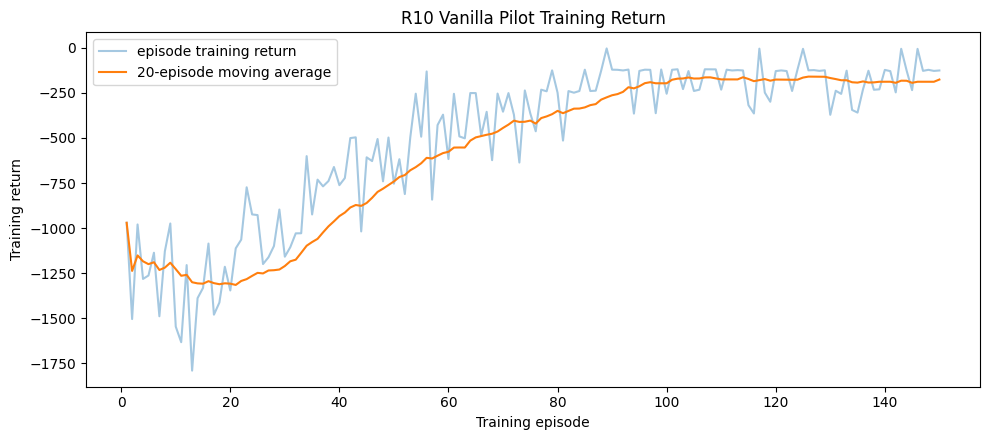

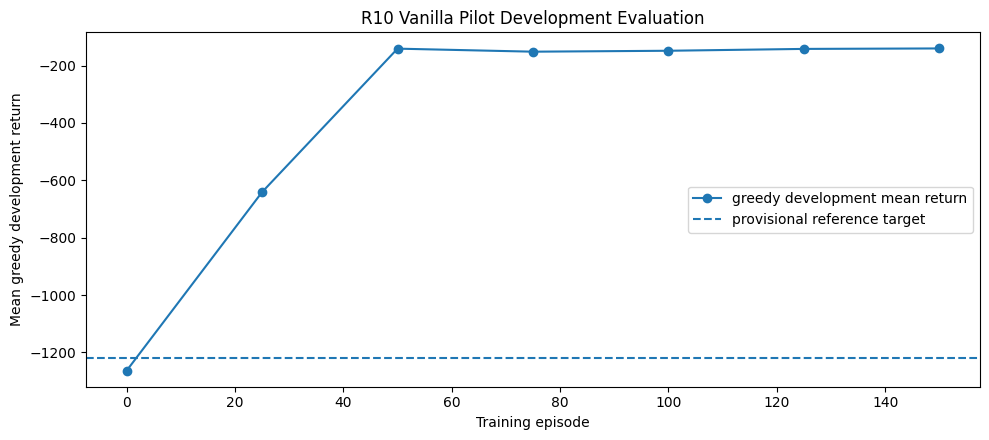

Initial mean development return: -1263.7047781825174
Best mean development return: -140.07738265254855
Best checkpoint episode: 150
Exceeds provisional reference: True
Pilot learning signal: True
Total wall-clock seconds: 752.0733917
Action decisions per second: 773.2135924454562
Saved pilot history: histories\R10_VANILLA_PILOT_history.csv
Saved pilot evaluations: histories\R10_VANILLA_PILOT_development_evaluations.csv
Saved pilot summary: histories\R10_VANILLA_PILOT_summary.csv
Saved selected pilot weights: selected_weights\R10_VANILLA_PILOT_best.weights.h5
Section 6.10 Vanilla viability pilot: COMPLETE


In [39]:
R10_RUN_ID = "R10_VANILLA_PILOT"
R10_SEED = 42
R10_EPISODES = 150
R10_REPLAY_CAPACITY = 10_000
R10_REPLAY_WARMUP = 1_000
R10_BATCH_SIZE = 32
R10_GAMMA = 0.99
R10_LEARNING_RATE = 1e-3
R10_EPSILON_START = 1.0
R10_EPSILON_END = 0.05
R10_EPSILON_DECAY_STEPS = 20_000
R10_TARGET_UPDATE_FREQUENCY = 250
R10_EVALUATION_FREQUENCY = 25
R10_MOVING_AVERAGE_WINDOW = 20
R10_THROUGHPUT_CALLS = 2_000

R10_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R10_RUN_ID}_best.weights.h5"
)
R10_HISTORY_PATH = (
    HISTORIES_DIR / f"{R10_RUN_ID}_history.csv"
)
R10_EVALUATION_PATH = (
    HISTORIES_DIR
    / f"{R10_RUN_ID}_development_evaluations.csv"
)
R10_SUMMARY_PATH = (
    HISTORIES_DIR / f"{R10_RUN_ID}_summary.csv"
)
R10_SELECTED_STATE_RESULTS_PATH = (
    HISTORIES_DIR / f"{R10_RUN_ID}_selected_state_results.csv"
)


def r10_epsilon(environment_step: int) -> float:
    """Linear pilot exploration schedule."""
    progress = min(
        1.0,
        int(environment_step) / R10_EPSILON_DECAY_STEPS,
    )
    return float(
        R10_EPSILON_START
        + progress * (R10_EPSILON_END - R10_EPSILON_START)
    )


def evaluate_r10_model(
    model: keras.Model,
    episode: int,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    """Greedily evaluate one pilot checkpoint on all development states."""
    def greedy_policy(observation: np.ndarray) -> float:
        _, torque, _ = greedy_discrete_action(
            model,
            observation,
            PILOT_TORQUE_VALUES,
        )
        return torque

    state_results = evaluate_policy_on_physical_states(
        env_builder=lambda: make_pendulum_env(
            GRAVITY_SETTINGS["default"]
        ),
        policy=greedy_policy,
        physical_states=DEVELOPMENT_PHYSICAL_STATES,
        horizon=EVALUATION_HORIZON,
    )
    assert len(state_results) == len(
        DEVELOPMENT_PHYSICAL_STATES
    )

    state_results = state_results.copy()
    state_results.insert(0, "episode", int(episode))
    state_results.insert(0, "run_id", R10_RUN_ID)

    summary = {
        "episode": int(episode),
        "mean_development_return": float(
            state_results["return"].mean()
        ),
        "median_development_return": float(
            state_results["return"].median()
        ),
        "development_return_std": float(
            state_results["return"].std(ddof=1)
        ),
        "minimum_development_return": float(
            state_results["return"].min()
        ),
        "maximum_development_return": float(
            state_results["return"].max()
        ),
        "mean_upright_fraction": float(
            state_results["upright_fraction"].mean()
        ),
        "mean_abs_angle": float(
            state_results["mean_abs_angle"].mean()
        ),
        "mean_abs_angular_velocity": float(
            state_results[
                "mean_abs_angular_velocity"
            ].mean()
        ),
        "mean_abs_torque": float(
            state_results["mean_abs_torque"].mean()
        ),
        "mean_torque_direction_switching_rate": float(
            state_results["torque_direction_switching_rate"].mean()
        ),
    }
    assert np.isfinite(
        np.asarray(list(summary.values()), dtype=np.float64)
    ).all()
    return state_results, summary


r10_configuration = pd.DataFrame({
    "setting": [
        "run_id",
        "gravity",
        "seed",
        "episodes",
        "steps_per_episode",
        "action_set",
        "hidden_units",
        "replay_capacity",
        "replay_warmup",
        "batch_size",
        "gamma",
        "learning_rate",
        "epsilon_start",
        "epsilon_end",
        "epsilon_decay_steps",
        "target_update_frequency",
        "development_evaluation_frequency",
    ],
    "value": [
        R10_RUN_ID,
        "default",
        R10_SEED,
        R10_EPISODES,
        EVALUATION_HORIZON,
        PILOT_TORQUE_VALUES.tolist(),
        list(STANDARD_HIDDEN_UNITS),
        R10_REPLAY_CAPACITY,
        R10_REPLAY_WARMUP,
        R10_BATCH_SIZE,
        R10_GAMMA,
        R10_LEARNING_RATE,
        R10_EPSILON_START,
        R10_EPSILON_END,
        R10_EPSILON_DECAY_STEPS,
        R10_TARGET_UPDATE_FREQUENCY,
        R10_EVALUATION_FREQUENCY,
    ],
})
display(r10_configuration)

assert PENDULUM_TRANSITIONS_ARE_NONTERMINAL is True
assert R10_REPLAY_WARMUP >= R10_BATCH_SIZE
assert R10_EPISODES % R10_EVALUATION_FREQUENCY == 0

r10_required_artifacts = [
    R10_WEIGHT_PATH,
    R10_HISTORY_PATH,
    R10_EVALUATION_PATH,
    R10_SUMMARY_PATH,
]
r10_artifacts_complete = all(path.exists() for path in r10_required_artifacts)


def summarise_r10_evaluation_states(frame: pd.DataFrame) -> pd.DataFrame:
    """Rebuild checkpoint summaries from state-level evaluation records."""
    required = {
        "episode",
        "return",
        "upright_fraction",
        "mean_abs_angle",
        "mean_abs_angular_velocity",
        "mean_abs_torque",
        "torque_direction_switching_rate",
    }
    assert required.issubset(frame.columns)
    summary = (
        frame.groupby("episode", as_index=False)
        .agg(
            mean_development_return=("return", "mean"),
            median_development_return=("return", "median"),
            development_return_std=("return", "std"),
            minimum_development_return=("return", "min"),
            maximum_development_return=("return", "max"),
            mean_upright_fraction=("upright_fraction", "mean"),
            mean_abs_angle=("mean_abs_angle", "mean"),
            mean_abs_angular_velocity=("mean_abs_angular_velocity", "mean"),
            mean_abs_torque=("mean_abs_torque", "mean"),
            mean_torque_direction_switching_rate=(
                "torque_direction_switching_rate",
                "mean",
            ),
        )
        .sort_values("episode")
        .reset_index(drop=True)
    )
    return summary


if r10_artifacts_complete:
    r10_history = read_csv_with_control_metric_migration(R10_HISTORY_PATH)
    r10_evaluation_states = read_csv_with_control_metric_migration(
        R10_EVALUATION_PATH
    )
    r10_summary = read_csv_with_control_metric_migration(R10_SUMMARY_PATH)
    assert len(r10_summary) == 1
    r10_summary_record = r10_summary.iloc[0].to_dict()

    r10_evaluation_summary = summarise_r10_evaluation_states(
        r10_evaluation_states
    )
    best_episode = int(r10_summary_record["best_checkpoint_episode"])

    r10_selected_model = build_standard_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=len(PILOT_TORQUE_VALUES),
        model_name="r10_selected_pilot_q_network",
    )
    r10_selected_model.load_weights(R10_WEIGHT_PATH)

    r10_selected_state_results, r10_selected_summary = evaluate_r10_model(
        r10_selected_model,
        episode=best_episode,
    )
    r10_selected_state_results.to_csv(
        R10_SELECTED_STATE_RESULTS_PATH,
        index=False,
    )

    selected_mean_return = float(
        r10_selected_summary["mean_development_return"]
    )
    best_mean_return = selected_mean_return
    initial_mean_return = float(
        r10_summary_record["initial_mean_development_return"]
    )
    initial_summary = (
        r10_evaluation_summary.loc[
            r10_evaluation_summary["episode"] == 0
        ]
        .iloc[0]
        .to_dict()
    )

    environment_steps = int(r10_summary_record["environment_steps"])
    random_action_count = int(r10_summary_record["random_actions"])
    greedy_action_count = int(r10_summary_record["greedy_actions"])
    target_update_count = int(r10_summary_record["target_updates"])
    training_only_seconds = float(
        r10_summary_record["training_only_seconds"]
    )
    training_loop_seconds = float(
        r10_summary_record["training_loop_seconds"]
    )
    evaluation_seconds = float(r10_summary_record["evaluation_seconds"])
    saving_seconds = float(
        r10_summary_record["checkpoint_saving_seconds"]
    )
    total_wall_clock_seconds = float(
        r10_summary_record["total_wall_clock_seconds"]
    )

    improvement_over_initial = selected_mean_return - initial_mean_return
    improvement_over_reference = (
        selected_mean_return - provisional_default_reference_target
    )
    improved_over_initial = bool(selected_mean_return > initial_mean_return)
    exceeds_provisional_reference = bool(
        selected_mean_return > provisional_default_reference_target
    )
    pilot_learning_signal = bool(
        improved_over_initial and exceeds_provisional_reference
    )

    r10_optimizer = keras.optimizers.Adam(learning_rate=R10_LEARNING_RATE)
    r10_optimizer.iterations.assign(
        int(r10_summary_record["optimizer_updates"])
    )

    throughput_state = np.array([1.0, 0.0, 0.0], dtype=np.float32)
    for _ in range(50):
        greedy_discrete_action(
            r10_selected_model,
            throughput_state,
            PILOT_TORQUE_VALUES,
        )
    throughput_start = time.perf_counter()
    for _ in range(R10_THROUGHPUT_CALLS):
        greedy_discrete_action(
            r10_selected_model,
            throughput_state,
            PILOT_TORQUE_VALUES,
        )
    throughput_seconds = time.perf_counter() - throughput_start
    decisions_per_second = R10_THROUGHPUT_CALLS / throughput_seconds
    milliseconds_per_decision = (
        1_000.0 * throughput_seconds / R10_THROUGHPUT_CALLS
    )

    r10_summary.loc[0, "selected_weight_path"] = artifact_path_string(
        R10_WEIGHT_PATH
    )
    r10_summary.to_csv(R10_SUMMARY_PATH, index=False)
    print(
        "Loaded completed R10 pilot artifacts and refreshed the selected "
        "policy evaluation; no duplicate training run was started."
    )
else:
    if LOCK_REVIEW_REUSE_ONLY:
        missing = [
            relative_artifact_path(path)
            for path in r10_required_artifacts
            if not path.exists()
        ]
        raise FileNotFoundError(
            "R10 artifacts are missing in reuse-only mode: " + str(missing)
        )
    tf.keras.utils.set_random_seed(R10_SEED)
    np.random.seed(R10_SEED)
    epsilon_rng = random.Random(R10_SEED + 1_000)
    replay_rng = random.Random(R10_SEED + 2_000)

    r10_main_network, r10_target_network = (
        initialise_main_and_target_networks(
            state_dim=DQN_STATE_DIM,
            action_count=len(PILOT_TORQUE_VALUES),
            seed=R10_SEED,
        )
    )
    r10_optimizer = keras.optimizers.Adam(
        learning_rate=R10_LEARNING_RATE
    )
    r10_replay_memory = ReplayMemory(
        capacity=R10_REPLAY_CAPACITY,
        state_dim=DQN_STATE_DIM,
        action_count=len(PILOT_TORQUE_VALUES),
    )

    development_observations = np.stack([
        expected_observation(float(theta), float(theta_dot))
        for theta, theta_dot in DEVELOPMENT_PHYSICAL_STATES
    ]).astype(np.float32)

    history_records = []
    evaluation_frames = []
    evaluation_records = []

    environment_steps = 0
    random_action_count = 0
    greedy_action_count = 0
    target_update_count = 0
    evaluation_seconds = 0.0
    saving_seconds = 0.0
    best_mean_return = -np.inf
    best_episode = None

    total_start = time.perf_counter()

    initial_eval_start = time.perf_counter()
    initial_state_results, initial_summary = evaluate_r10_model(
        r10_main_network,
        episode=0,
    )
    evaluation_seconds += time.perf_counter() - initial_eval_start
    evaluation_frames.append(initial_state_results)
    evaluation_records.append(initial_summary)

    best_mean_return = initial_summary[
        "mean_development_return"
    ]
    best_episode = 0
    save_start = time.perf_counter()
    r10_main_network.save_weights(R10_WEIGHT_PATH)
    saving_seconds += time.perf_counter() - save_start

    print(
        f"Episode   0 | development mean return "
        f"{best_mean_return:10.3f} | initial checkpoint"
    )

    training_env = make_pendulum_env(
        GRAVITY_SETTINGS["default"]
    )
    training_env.seed(R10_SEED)
    training_start = time.perf_counter()

    try:
        for episode in range(1, R10_EPISODES + 1):
            observation = np.asarray(
                training_env.reset(),
                dtype=np.float32,
            )
            episode_return = 0.0
            episode_losses = []
            episode_gradient_norms = []
            episode_random_actions = 0
            episode_greedy_actions = 0
            episode_target_updates = 0
            episode_start = time.perf_counter()

            for step_index in range(EVALUATION_HORIZON):
                epsilon = r10_epsilon(environment_steps)
                action_index, torque, was_random = (
                    epsilon_greedy_discrete_action(
                        model=r10_main_network,
                        observation=observation,
                        torque_values=PILOT_TORQUE_VALUES,
                        epsilon=epsilon,
                        rng=epsilon_rng,
                    )
                )

                episode_random_actions += int(was_random)
                episode_greedy_actions += int(not was_random)
                random_action_count += int(was_random)
                greedy_action_count += int(not was_random)

                next_observation, reward, done, info = (
                    training_env.step(
                        np.array([torque], dtype=np.float32)
                    )
                )
                next_observation = np.asarray(
                    next_observation,
                    dtype=np.float32,
                )

                r10_replay_memory.append(
                    state=observation,
                    action_index=action_index,
                    reward=float(reward),
                    next_state=next_observation,
                )

                observation = next_observation
                episode_return += float(reward)
                environment_steps += 1

                if len(r10_replay_memory) >= R10_REPLAY_WARMUP:
                    batch = r10_replay_memory.sample(
                        batch_size=R10_BATCH_SIZE,
                        rng=replay_rng,
                    )
                    update_result = vanilla_dqn_gradient_update(
                        main_network=r10_main_network,
                        target_network=r10_target_network,
                        optimizer=r10_optimizer,
                        states=batch[0],
                        action_indices=batch[1],
                        rewards=batch[2],
                        next_states=batch[3],
                        gamma=R10_GAMMA,
                    )
                    episode_losses.append(update_result["loss"])
                    episode_gradient_norms.append(
                        update_result["gradient_global_norm"]
                    )

                    target_updated = (
                        hard_update_target_network_if_due(
                            main_network=r10_main_network,
                            target_network=r10_target_network,
                            optimizer_step=int(
                                r10_optimizer.iterations.numpy()
                            ),
                            update_frequency=(
                                R10_TARGET_UPDATE_FREQUENCY
                            ),
                        )
                    )
                    episode_target_updates += int(target_updated)
                    target_update_count += int(target_updated)

                if done:
                    assert info.get("TimeLimit.truncated") is True
                    assert step_index + 1 == EVALUATION_HORIZON
                    break

            assert step_index + 1 == EVALUATION_HORIZON

            q_values = r10_main_network(
                tf.convert_to_tensor(
                    development_observations,
                    dtype=tf.float32,
                ),
                training=False,
            ).numpy()
            assert np.isfinite(q_values).all()

            history_records.append({
                "run_id": R10_RUN_ID,
                "episode": int(episode),
                "environment_steps": int(environment_steps),
                "optimizer_updates": int(
                    r10_optimizer.iterations.numpy()
                ),
                "training_return": float(episode_return),
                "epsilon": float(epsilon),
                "mean_loss": (
                    float(np.mean(episode_losses))
                    if episode_losses
                    else np.nan
                ),
                "mean_gradient_global_norm": (
                    float(np.mean(episode_gradient_norms))
                    if episode_gradient_norms
                    else np.nan
                ),
                "mean_q": float(np.mean(q_values)),
                "max_q": float(np.max(q_values)),
                "random_actions": int(episode_random_actions),
                "greedy_actions": int(episode_greedy_actions),
                "target_updates": int(episode_target_updates),
                "replay_size": int(len(r10_replay_memory)),
                "episode_runtime_seconds": float(
                    time.perf_counter() - episode_start
                ),
                "cumulative_runtime_seconds": float(
                    time.perf_counter() - training_start
                ),
            })

            if episode % R10_EVALUATION_FREQUENCY == 0:
                replay_size_before = len(r10_replay_memory)
                eval_start = time.perf_counter()
                state_results, eval_summary = evaluate_r10_model(
                    r10_main_network,
                    episode=episode,
                )
                evaluation_seconds += (
                    time.perf_counter() - eval_start
                )
                assert len(r10_replay_memory) == replay_size_before

                evaluation_frames.append(state_results)
                evaluation_records.append(eval_summary)

                mean_return = eval_summary[
                    "mean_development_return"
                ]
                if mean_return > best_mean_return:
                    save_start = time.perf_counter()
                    r10_main_network.save_weights(R10_WEIGHT_PATH)
                    saving_seconds += (
                        time.perf_counter() - save_start
                    )
                    best_mean_return = mean_return
                    best_episode = int(episode)

                print(
                    f"Episode {episode:3d} | development mean return "
                    f"{mean_return:10.3f} | best {best_mean_return:10.3f} "
                    f"at episode {best_episode}"
                )
    finally:
        training_env.close()

    training_loop_seconds = time.perf_counter() - training_start

    r10_history = pd.DataFrame(history_records)
    training_only_seconds = float(
        r10_history["episode_runtime_seconds"].sum()
    )
    r10_evaluation_states = pd.concat(
        evaluation_frames,
        ignore_index=True,
    )
    r10_evaluation_summary = pd.DataFrame(evaluation_records)

    r10_history["moving_average_return"] = (
        r10_history["training_return"]
        .rolling(
            R10_MOVING_AVERAGE_WINDOW,
            min_periods=1,
        )
        .mean()
    )
    evaluation_map = dict(zip(
        r10_evaluation_summary["episode"],
        r10_evaluation_summary["mean_development_return"],
    ))
    r10_history["evaluation_return"] = (
        r10_history["episode"].map(evaluation_map)
    )

    r10_selected_model = build_standard_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=len(PILOT_TORQUE_VALUES),
        model_name="r10_selected_pilot_q_network",
    )
    r10_selected_model.load_weights(R10_WEIGHT_PATH)

    selected_eval_start = time.perf_counter()
    r10_selected_state_results, r10_selected_summary = (
        evaluate_r10_model(
            r10_selected_model,
            episode=int(best_episode),
        )
    )
    evaluation_seconds += time.perf_counter() - selected_eval_start
    selected_mean_return = r10_selected_summary[
        "mean_development_return"
    ]
    assert np.isclose(
        selected_mean_return,
        best_mean_return,
        rtol=1e-7,
        atol=1e-7,
    )

    throughput_state = np.array(
        [1.0, 0.0, 0.0],
        dtype=np.float32,
    )
    for _ in range(50):
        greedy_discrete_action(
            r10_selected_model,
            throughput_state,
            PILOT_TORQUE_VALUES,
        )

    throughput_start = time.perf_counter()
    for _ in range(R10_THROUGHPUT_CALLS):
        greedy_discrete_action(
            r10_selected_model,
            throughput_state,
            PILOT_TORQUE_VALUES,
        )
    throughput_seconds = time.perf_counter() - throughput_start
    decisions_per_second = (
        R10_THROUGHPUT_CALLS / throughput_seconds
    )
    milliseconds_per_decision = (
        1_000.0 * throughput_seconds / R10_THROUGHPUT_CALLS
    )

    initial_mean_return = initial_summary[
        "mean_development_return"
    ]
    improvement_over_initial = (
        selected_mean_return - initial_mean_return
    )
    improvement_over_reference = (
        selected_mean_return - provisional_default_reference_target
    )
    improved_over_initial = bool(
        selected_mean_return > initial_mean_return
    )
    exceeds_provisional_reference = bool(
        selected_mean_return
        > provisional_default_reference_target
    )
    pilot_learning_signal = bool(
        improved_over_initial and exceeds_provisional_reference
    )

    total_wall_clock_seconds = time.perf_counter() - total_start

    r10_summary = pd.DataFrame({
        "run_id": [R10_RUN_ID],
        "gravity": ["default"],
        "seed": [R10_SEED],
        "episodes": [R10_EPISODES],
        "environment_steps": [environment_steps],
        "optimizer_updates": [
            int(r10_optimizer.iterations.numpy())
        ],
        "best_checkpoint_episode": [int(best_episode)],
        "initial_mean_development_return": [
            initial_mean_return
        ],
        "best_mean_development_return": [
            selected_mean_return
        ],
        "improvement_over_initial": [
            improvement_over_initial
        ],
        "provisional_reference_target": [
            provisional_default_reference_target
        ],
        "improvement_over_provisional_reference": [
            improvement_over_reference
        ],
        "improved_over_initial": [improved_over_initial],
        "exceeds_provisional_reference": [
            exceeds_provisional_reference
        ],
        "pilot_learning_signal": [pilot_learning_signal],
        "random_actions": [random_action_count],
        "greedy_actions": [greedy_action_count],
        "target_updates": [target_update_count],
        "training_only_seconds": [training_only_seconds],
        "training_loop_seconds": [training_loop_seconds],
        "evaluation_seconds": [evaluation_seconds],
        "checkpoint_saving_seconds": [saving_seconds],
        "total_wall_clock_seconds": [total_wall_clock_seconds],
        "runtime_per_100_episodes_seconds": [
            training_only_seconds / R10_EPISODES * 100.0
        ],
        "runtime_per_10k_steps_seconds": [
            training_only_seconds / environment_steps * 10_000.0
        ],
        "decisions_per_second": [decisions_per_second],
        "milliseconds_per_decision": [
            milliseconds_per_decision
        ],
        "selected_weight_path": [artifact_path_string(R10_WEIGHT_PATH)],
    })

    r10_history.to_csv(R10_HISTORY_PATH, index=False)
    r10_evaluation_states.to_csv(
        R10_EVALUATION_PATH,
        index=False,
    )
    r10_summary.to_csv(R10_SUMMARY_PATH, index=False)



    r10_selected_state_results.to_csv(
        R10_SELECTED_STATE_RESULTS_PATH,
        index=False,
    )

display(r10_evaluation_summary)
display(r10_summary)
display(r10_history.tail(10))

plt.figure(figsize=(10, 4.5))
plt.plot(
    r10_history["episode"],
    r10_history["training_return"],
    alpha=0.4,
    label="episode training return",
)
plt.plot(
    r10_history["episode"],
    r10_history["moving_average_return"],
    label=f"{R10_MOVING_AVERAGE_WINDOW}-episode moving average",
)
plt.xlabel("Training episode")
plt.ylabel("Training return")
plt.title("R10 Vanilla Pilot Training Return")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(
    r10_evaluation_summary["episode"],
    r10_evaluation_summary["mean_development_return"],
    marker="o",
    label="greedy development mean return",
)
plt.axhline(
    provisional_default_reference_target,
    linestyle="--",
    label="provisional reference target",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("R10 Vanilla Pilot Development Evaluation")
plt.legend()
plt.tight_layout()
plt.show()

print("Initial mean development return:", initial_mean_return)
print("Best mean development return:", selected_mean_return)
print("Best checkpoint episode:", best_episode)
print(
    "Exceeds provisional reference:",
    exceeds_provisional_reference,
)
print("Pilot learning signal:", pilot_learning_signal)
print("Total wall-clock seconds:", total_wall_clock_seconds)
print("Action decisions per second:", decisions_per_second)
print("Saved pilot history:", R10_HISTORY_PATH)
print("Saved pilot evaluations:", R10_EVALUATION_PATH)
print("Saved pilot summary:", R10_SUMMARY_PATH)
print("Saved selected pilot weights:", R10_WEIGHT_PATH)
print("Section 6.10 Vanilla viability pilot: COMPLETE")


### 6.10 Result Interpretation

**Finding.** The Vanilla pilot improved its mean greedy development return from
`-1263.704778` at episode `0` to `-140.077383` at the selected episode-150
checkpoint. This was an improvement of `1123.627396` and exceeded the
provisional default-gravity reference target of `-1220.045207`. The pilot
completed `30,000` environment steps and `29,001` optimiser updates without
non-finite values or persistence errors.

**Control evidence.** The selected checkpoint achieved a mean upright fraction
of `0.866458`, mean absolute angle of `0.262557` radians, and mean absolute
angular velocity of `0.582370`. These values support the return improvement
with observable control behaviour rather than reward alone.

**Decision.** Vanilla DQN is viable under the pilot configuration. Retain the
validated implementation and proceed to runtime analysis. This pilot is
technical evidence only and is not a formal action-set result.

**Caveat.** The best checkpoint occurred at the final planned episode. The
pilot therefore confirms a strong learning signal but does not prove that
episode `150` is the final formal budget or that the temporary three-action set
is optimal.

**Next step.** Convert the measured pilot timings into explicit runtime
evidence for the run-budget decision.


## 6.11 Runtime Measurement

**Question.** What did the completed Vanilla pilot reveal about training,
evaluation, saving, and direct action-selection runtime?

**Reason.** The run-budget plan prohibits invented estimates. The measured
pilot must provide the timing basis before a formal budget and hard run cap are
declared.

**Primary evidence.**

- total wall-clock time;
- training-only time;
- runtime per episode and per `100` episodes;
- runtime per `10,000` environment steps;
- environment steps and optimiser updates per second;
- average evaluation-call time;
- checkpoint-saving overhead;
- direct action decisions per second and milliseconds per decision.

**Controlled interpretation.** These measurements describe the current
150-episode pilot implementation and hardware. They do not yet lock the final
training budget.

**Decision rule.** Section 6.11 passes when all runtime values are finite and
positive, the recorded counts match the completed pilot, and the timing table
is displayed.


In [40]:
R10_SCHEDULED_EVALUATION_CALLS = len(
    r10_evaluation_summary
)
R10_SELECTED_RELOAD_EVALUATION_CALLS = 1
R10_TOTAL_EVALUATION_CALLS = (
    R10_SCHEDULED_EVALUATION_CALLS
    + R10_SELECTED_RELOAD_EVALUATION_CALLS
)

evaluation_means = (
    r10_evaluation_summary["mean_development_return"]
    .to_numpy(dtype=np.float64)
)
checkpoint_save_flags = [True]
running_best = float(evaluation_means[0])

for candidate_mean in evaluation_means[1:]:
    is_new_best = bool(candidate_mean > running_best)
    checkpoint_save_flags.append(is_new_best)
    if is_new_best:
        running_best = float(candidate_mean)

R10_CHECKPOINT_SAVE_COUNT = int(sum(checkpoint_save_flags))

runtime_per_episode_seconds = (
    training_only_seconds / R10_EPISODES
)
runtime_per_100_episodes_seconds = (
    runtime_per_episode_seconds * 100.0
)
runtime_per_10k_steps_seconds = (
    training_only_seconds / environment_steps * 10_000.0
)
environment_steps_per_second = (
    environment_steps / training_only_seconds
)
optimizer_updates_per_second = (
    int(r10_optimizer.iterations.numpy())
    / training_only_seconds
)
average_evaluation_call_seconds = (
    evaluation_seconds / R10_TOTAL_EVALUATION_CALLS
)
average_checkpoint_save_seconds = (
    saving_seconds / R10_CHECKPOINT_SAVE_COUNT
)
runtime_accounting_gap_seconds = (
    total_wall_clock_seconds
    - training_only_seconds
    - evaluation_seconds
    - saving_seconds
)

r10_runtime_measurements = pd.DataFrame({
    "runtime_measure": [
        "total wall-clock",
        "training only",
        "training loop including periodic evaluation",
        "all greedy evaluation calls",
        "all selected-checkpoint saves",
        "runtime per episode",
        "runtime per 100 episodes",
        "runtime per 10,000 environment steps",
        "environment steps per second",
        "optimizer updates per second",
        "average evaluation call",
        "average checkpoint save",
        "direct action decisions per second",
        "milliseconds per direct action decision",
        "unallocated setup and bookkeeping overhead",
    ],
    "value": [
        total_wall_clock_seconds,
        training_only_seconds,
        training_loop_seconds,
        evaluation_seconds,
        saving_seconds,
        runtime_per_episode_seconds,
        runtime_per_100_episodes_seconds,
        runtime_per_10k_steps_seconds,
        environment_steps_per_second,
        optimizer_updates_per_second,
        average_evaluation_call_seconds,
        average_checkpoint_save_seconds,
        decisions_per_second,
        milliseconds_per_decision,
        runtime_accounting_gap_seconds,
    ],
    "unit": [
        "seconds",
        "seconds",
        "seconds",
        "seconds",
        "seconds",
        "seconds per episode",
        "seconds per 100 episodes",
        "seconds per 10,000 steps",
        "steps per second",
        "updates per second",
        "seconds per call",
        "seconds per save",
        "decisions per second",
        "milliseconds per decision",
        "seconds",
    ],
})

runtime_values = r10_runtime_measurements[
    "value"
].to_numpy(dtype=np.float64)

assert np.isfinite(runtime_values).all()
assert (runtime_values > 0.0).all()
assert environment_steps == 30_000
assert int(r10_optimizer.iterations.numpy()) == 29_001
assert R10_SCHEDULED_EVALUATION_CALLS == 7
assert R10_TOTAL_EVALUATION_CALLS == 8
assert R10_CHECKPOINT_SAVE_COUNT == 4
assert total_wall_clock_seconds >= training_loop_seconds
assert training_loop_seconds >= training_only_seconds
assert decisions_per_second > 0.0
assert milliseconds_per_decision > 0.0

display(r10_runtime_measurements)

r10_runtime_count_summary = pd.DataFrame({
    "count_item": [
        "episodes",
        "environment steps",
        "optimizer updates",
        "scheduled development evaluations",
        "selected-checkpoint reload evaluations",
        "total evaluation calls",
        "checkpoint saves",
    ],
    "count": [
        R10_EPISODES,
        environment_steps,
        int(r10_optimizer.iterations.numpy()),
        R10_SCHEDULED_EVALUATION_CALLS,
        R10_SELECTED_RELOAD_EVALUATION_CALLS,
        R10_TOTAL_EVALUATION_CALLS,
        R10_CHECKPOINT_SAVE_COUNT,
    ],
})

display(r10_runtime_count_summary)

print(
    "Pilot total wall-clock minutes:",
    total_wall_clock_seconds / 60.0,
)
print(
    "Pilot training-only minutes:",
    training_only_seconds / 60.0,
)
print(
    "Runtime per 100 episodes minutes:",
    runtime_per_100_episodes_seconds / 60.0,
)
print(
    "Runtime per 10,000 steps minutes:",
    runtime_per_10k_steps_seconds / 60.0,
)
print(
    "Environment steps per second:",
    environment_steps_per_second,
)
print(
    "Action decisions per second:",
    decisions_per_second,
)
print(
    "Milliseconds per action decision:",
    milliseconds_per_decision,
)
print("Runtime measurements finite:", True)
print("Section 6.11 runtime measurement: PASS")


,runtime_measure,value,unit
0,total wall-clock,752.073392,seconds
1,training only,664.027967,seconds
2,training loop including periodic evaluation,727.450561,seconds
3,all greedy evaluation calls,83.673341,seconds
4,all selected-checkpoint saves,0.096016,seconds
5,runtime per episode,4.426853,seconds per episode
6,runtime per 100 episodes,442.685311,seconds per 100 episodes
7,"runtime per 10,000 environment steps",221.342656,"seconds per 10,000 steps"
8,environment steps per second,45.178820,steps per second
9,optimizer updates per second,43.674365,updates per second


,count_item,count
0,episodes,150
1,environment steps,30000
2,optimizer updates,29001
3,scheduled development evaluations,7
4,selected-checkpoint reload evaluations,1
5,total evaluation calls,8
6,checkpoint saves,4


Pilot total wall-clock minutes: 12.534556528333333
Pilot training-only minutes: 11.067132775000001
Runtime per 100 episodes minutes: 7.378088516666668
Runtime per 10,000 steps minutes: 3.6890442583333334
Environment steps per second: 45.17882003995384
Action decisions per second: 773.2135924454562
Milliseconds per action decision: 1.2933036999999992
Runtime measurements finite: True
Section 6.11 runtime measurement: PASS


### 6.11 Result Interpretation

**Finding.** After the kernel restart, the repeated 150-episode pilot required
`752.073` seconds, or `12.535` minutes, of total wall-clock time. Training-only
time was `664.028` seconds, equivalent to `7.378` minutes per `100` episodes
and `3.689` minutes per `10,000` environment steps. The implementation
processed `45.179` environment steps per second and `43.674` optimiser updates
per second.

**Action-selection evidence.** Direct model calls achieved `773.214`
decisions per second, or `1.293` milliseconds per decision. The direct tensor
action path remains practical and continues to satisfy the notebook-wide
implementation rule.

**Decision.** Accept this rerun as valid runtime evidence. It does not change
the algorithmic result because the selected return and checkpoint reproduced
exactly, but it shows that runtime can vary between executions.

**Caveat.** This rerun was substantially slower than the previously accepted
pilot timing used to approve the run budget. Runtime must therefore be
monitored during the action-set experiments rather than assuming every run
will match one timing measurement.

**Next step.** Recalculate the programme estimates using this rerun while
keeping the already approved budget reference clearly separated.


## 6.12 Pilot Findings and Run-Budget Input

**Question.** What budget evidence can be locked from the pilot, and which
budget decision still requires team input?

**Reason.** The planning documents define `24` minimum formal runs and a
conditional upper envelope of `41` runs. The pilot now provides the measured
per-run timing needed to estimate those programmes, but the hard cap must also
consider the team's actual available machine hours and protected delivery
time.

**Pilot findings used.**

- Vanilla DQN produced a strong learning signal;
- `150` episodes corresponded to `30,000` environment steps;
- total wall-clock time was measured directly;
- the selected checkpoint occurred at episode `150`;
- performance was already strong by episode `50` and remained within a narrow
  range afterward.

**Working runtime basis.** Use the complete 150-episode pilot wall-clock time
as the conservative per-run planning estimate. Apply a provisional `20%`
contingency only to show the planning range. This contingency is not yet
locked.

**Primary output.**

- estimated runtime for `24` runs;
- estimated runtime for `41` runs;
- protected runtime for four gravity runs;
- protected runtime for three final confirmation seeds;
- provisional contingency estimates;
- explicit hard-cap status.

**Decision rule.** Section 6.12 passes when the calculations are finite,
consistent with the measured pilot, saved to CSV, and the hard cap is left
pending rather than invented.


In [41]:
R10_MINIMUM_FORMAL_RUNS = 24
R10_CONDITIONAL_MAXIMUM_RUNS = 41
R10_GRAVITY_RESERVE_RUNS = 4
R10_FINAL_CONFIRMATION_RESERVE_RUNS = 3
R10_PLANNING_CONTINGENCY_RATE = 0.20

R10_BUDGET_INPUT_PATH = (
    HISTORIES_DIR / f"{R10_RUN_ID}_run_budget_input.csv"
)

pilot_wall_clock_hours = (
    total_wall_clock_seconds / 3600.0
)

minimum_programme_hours = (
    R10_MINIMUM_FORMAL_RUNS * pilot_wall_clock_hours
)
conditional_maximum_hours = (
    R10_CONDITIONAL_MAXIMUM_RUNS * pilot_wall_clock_hours
)
gravity_reserve_hours = (
    R10_GRAVITY_RESERVE_RUNS * pilot_wall_clock_hours
)
final_confirmation_reserve_hours = (
    R10_FINAL_CONFIRMATION_RESERVE_RUNS
    * pilot_wall_clock_hours
)
protected_training_reserve_hours = (
    gravity_reserve_hours
    + final_confirmation_reserve_hours
)

minimum_contingency_hours = (
    minimum_programme_hours
    * R10_PLANNING_CONTINGENCY_RATE
)
maximum_contingency_hours = (
    conditional_maximum_hours
    * R10_PLANNING_CONTINGENCY_RATE
)
minimum_with_contingency_hours = (
    minimum_programme_hours
    + minimum_contingency_hours
)
maximum_with_contingency_hours = (
    conditional_maximum_hours
    + maximum_contingency_hours
)

episode_50_return = float(
    r10_evaluation_summary.loc[
        r10_evaluation_summary["episode"] == 50,
        "mean_development_return",
    ].iloc[0]
)
episode_150_return = float(
    r10_evaluation_summary.loc[
        r10_evaluation_summary["episode"] == 150,
        "mean_development_return",
    ].iloc[0]
)
episode_50_to_150_change = (
    episode_150_return - episode_50_return
)

late_evaluation_returns = (
    r10_evaluation_summary.loc[
        r10_evaluation_summary["episode"] >= 50,
        "mean_development_return",
    ]
    .to_numpy(dtype=np.float64)
)
late_evaluation_range = float(
    late_evaluation_returns.max()
    - late_evaluation_returns.min()
)

r10_pilot_findings = pd.DataFrame({
    "finding": [
        "pilot learning signal",
        "selected checkpoint episode",
        "episode 0 mean development return",
        "episode 50 mean development return",
        "episode 150 mean development return",
        "episode 50 to 150 return change",
        "late evaluation return range",
        "environment steps",
        "optimizer updates",
        "total wall-clock minutes",
    ],
    "value": [
        bool(pilot_learning_signal),
        int(best_episode),
        float(initial_mean_return),
        episode_50_return,
        episode_150_return,
        episode_50_to_150_change,
        late_evaluation_range,
        int(environment_steps),
        int(r10_optimizer.iterations.numpy()),
        float(total_wall_clock_seconds / 60.0),
    ],
})

r10_budget_input = pd.DataFrame({
    "budget_item": [
        "measured pilot wall-clock per run",
        "minimum programme before contingency",
        "conditional maximum before contingency",
        "four-gravity training reserve",
        "three-seed final confirmation reserve",
        "protected seven-run training reserve",
        "minimum programme contingency",
        "conditional maximum contingency",
        "minimum programme with contingency",
        "conditional maximum with contingency",
    ],
    "runs": [
        1,
        R10_MINIMUM_FORMAL_RUNS,
        R10_CONDITIONAL_MAXIMUM_RUNS,
        R10_GRAVITY_RESERVE_RUNS,
        R10_FINAL_CONFIRMATION_RESERVE_RUNS,
        (
            R10_GRAVITY_RESERVE_RUNS
            + R10_FINAL_CONFIRMATION_RESERVE_RUNS
        ),
        R10_MINIMUM_FORMAL_RUNS,
        R10_CONDITIONAL_MAXIMUM_RUNS,
        R10_MINIMUM_FORMAL_RUNS,
        R10_CONDITIONAL_MAXIMUM_RUNS,
    ],
    "estimated_hours": [
        pilot_wall_clock_hours,
        minimum_programme_hours,
        conditional_maximum_hours,
        gravity_reserve_hours,
        final_confirmation_reserve_hours,
        protected_training_reserve_hours,
        minimum_contingency_hours,
        maximum_contingency_hours,
        minimum_with_contingency_hours,
        maximum_with_contingency_hours,
    ],
    "status": [
        "measured",
        "planning estimate",
        "planning estimate",
        "protected",
        "protected",
        "protected",
        "provisional 20%",
        "provisional 20%",
        "planning estimate",
        "planning estimate",
    ],
})

budget_values = r10_budget_input[
    "estimated_hours"
].to_numpy(dtype=np.float64)

assert pilot_learning_signal is True
assert best_episode == R10_EPISODES
assert np.isfinite(budget_values).all()
assert (budget_values > 0.0).all()
assert np.isclose(
    minimum_programme_hours,
    R10_MINIMUM_FORMAL_RUNS * pilot_wall_clock_hours,
)
assert np.isclose(
    conditional_maximum_hours,
    R10_CONDITIONAL_MAXIMUM_RUNS * pilot_wall_clock_hours,
)
assert protected_training_reserve_hours < minimum_programme_hours
assert R10_MINIMUM_FORMAL_RUNS < R10_CONDITIONAL_MAXIMUM_RUNS

r10_budget_input.to_csv(
    R10_BUDGET_INPUT_PATH,
    index=False,
)

display(r10_pilot_findings)
display(r10_budget_input)

print(
    "Measured pilot wall-clock minutes per run:",
    total_wall_clock_seconds / 60.0,
)
print(
    "Estimated 24-run minimum programme hours:",
    minimum_programme_hours,
)
print(
    "Estimated 41-run conditional maximum hours:",
    conditional_maximum_hours,
)
print(
    "Estimated minimum with 20% contingency hours:",
    minimum_with_contingency_hours,
)
print(
    "Estimated maximum with 20% contingency hours:",
    maximum_with_contingency_hours,
)
print(
    "Protected four-gravity plus final-three-seed reserve hours:",
    protected_training_reserve_hours,
)
print(
    "Episode 50 to 150 development-return change:",
    episode_50_to_150_change,
)
print("Hard formal-run cap: PENDING AVAILABLE COMPUTE WINDOW")
print("Saved run-budget input:", R10_BUDGET_INPUT_PATH)
print("Section 6.12 pilot findings and run-budget input: PASS")


,finding,value
0,pilot learning signal,True
1,selected checkpoint episode,150
2,episode 0 mean development return,-1263.704778
3,episode 50 mean development return,-140.808153
4,episode 150 mean development return,-140.077383
5,episode 50 to 150 return change,0.73077
6,late evaluation return range,11.303257
7,environment steps,30000
8,optimizer updates,29001
9,total wall-clock minutes,12.534557


,budget_item,runs,estimated_hours,status
0,measured pilot wall-clock per run,1,0.208909,measured
1,minimum programme before contingency,24,5.013823,planning estimate
2,conditional maximum before contingency,41,8.565280,planning estimate
3,four-gravity training reserve,4,0.835637,protected
4,three-seed final confirmation reserve,3,0.626728,protected
5,protected seven-run training reserve,7,1.462365,protected
6,minimum programme contingency,24,1.002765,provisional 20%
7,conditional maximum contingency,41,1.713056,provisional 20%
8,minimum programme with contingency,24,6.016587,planning estimate
9,conditional maximum with contingency,41,10.278336,planning estimate


Measured pilot wall-clock minutes per run: 12.534556528333333
Estimated 24-run minimum programme hours: 5.0138226113333335
Estimated 41-run conditional maximum hours: 8.565280294361111
Estimated minimum with 20% contingency hours: 6.0165871336
Estimated maximum with 20% contingency hours: 10.278336353233334
Protected four-gravity plus final-three-seed reserve hours: 1.4623649283055555
Episode 50 to 150 development-return change: 0.7307702754296201
Hard formal-run cap: PENDING AVAILABLE COMPUTE WINDOW
Saved run-budget input: histories\R10_VANILLA_PILOT_run_budget_input.csv
Section 6.12 pilot findings and run-budget input: PASS


### 6.12 Result Interpretation

**Finding.** Using the repeated pilot wall-clock time of `12.535` minutes per
150-episode run, the planned `24`-run minimum programme is estimated at
`5.014` hours before contingency and `6.017` hours with a provisional `20%`
contingency. The `41`-run conditional envelope is estimated at `8.565` hours
before contingency and `10.278` hours with the same contingency.

**Protected training reserve.** The four matched gravity runs and three final
confirmation seeds together require an estimated `1.462` hours under this
slower rerun timing.

**Learning-curve input.** The episode-50 to episode-150 development-return
change remained `+0.731`, and the selected checkpoint remained episode `150`.
The learning result therefore reproduced even though the runtime changed.

**Decision.** Record the slower rerun as a runtime-monitoring observation. Do
not silently replace the earlier approved budget basis, because that budget
was a separate team decision made from the first accepted pilot. Instead,
trigger a budget review warning and restrict optional runs until more formal
runtime evidence is available.

**Caveat.** At this slower timing, the full 24-run minimum would exceed the
five-hour training allocation after contingency. The 28-run cap remains an
approved maximum, not a target or a guarantee that every run will fit.

**Next step.** Preserve the approved cap, continue only required action-set
runs, and compare their actual runtimes before releasing optional work.


# 7. Torque Action Discretisation

The environment accepts continuous torque, but DQN requires one output Q-value
for each fixed action. This section compares increasingly fine, symmetric and
uniform torque sets while preserving the verified environment limits.

The normal comparison includes `3`, `5` and `7` actions. Nine actions remain
conditional and will not be added without evidence that seven actions provide
insufficient control resolution.


## 7.1 Question, Hypothesis and Controls

**Question.** How should the verified torque interval `[-2.0, 2.0]` be
discretised for a fair three, five and seven-action Vanilla DQN comparison?

**Reason.** The number of actions changes the Q-network output size, the
available control precision and the exploration difficulty. The candidate
sets must therefore be defined and validated before any training comparison.

**Hypothesis.**

- three actions will be simplest to explore but provide the coarsest control;
- five actions will provide a middle balance between precision and complexity;
- seven actions will provide the finest planned control but require learning
  more action values.

**Reference design.**

- symmetric uniform spacing;
- full coverage from `-2.0` to `2.0`;
- zero torque included;
- identical `(64, 64)` Vanilla architecture apart from output size;
- valid one-element Gym action arrays under all four gravities.

**Primary change.** Only the number and spacing of discrete torques change.

**Controlled factors for the later formal comparison.**

- Vanilla DQN;
- default gravity;
- seed `42`;
- state representation;
- network hidden layers;
- optimiser and loss;
- gamma;
- replay recipe;
- exploration schedule;
- target-update rule;
- training budget;
- development evaluation states.

**Training budget.** None in this subsection. It performs action-set and
network-shape validation only.

**Evaluation evidence.** Verify symmetry, uniform spacing, zero inclusion,
full torque-range coverage, action-array validity, finite environment steps
under all four gravities, and matching Q-network output dimensions.

**Decision rule.** Section 7.1 passes only when all three candidate sets pass
every technical check. Formal action-set training remains blocked until the
hard run cap is recorded.


In [42]:
ACTION_SET_CANDIDATES = {
    action_count: np.linspace(
        float(action_low[0]),
        float(action_high[0]),
        num=action_count,
        dtype=np.float32,
    )
    for action_count in (3, 5, 7)
}

ACTION_SET_GRAVITY_KEYS = tuple(GRAVITY_SETTINGS.keys())
ACTION_SET_TECHNICAL_PROBE_STATE = (
    float(np.pi / 6.0),
    -0.25,
)

action_set_validation_records = []
action_set_step_records = []

for action_count, candidate_values in ACTION_SET_CANDIDATES.items():
    validated_values = validate_discrete_torque_values(
        candidate_values
    )

    spacings = np.diff(validated_values)
    assert len(validated_values) == action_count
    assert action_count % 2 == 1
    assert np.allclose(
        spacings,
        spacings[0],
        rtol=1e-6,
        atol=1e-6,
    )
    assert np.isclose(
        validated_values[action_count // 2],
        0.0,
    )

    tf.keras.utils.set_random_seed(42)
    candidate_model = build_standard_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=action_count,
        hidden_units=STANDARD_HIDDEN_UNITS,
        model_name=f"action_set_{action_count}_validation_network",
    )

    candidate_q_values = candidate_model(
        architecture_probe_states,
        training=False,
    ).numpy()

    assert candidate_model.output_shape == (
        None,
        action_count,
    )
    assert candidate_q_values.shape == (
        len(architecture_probe_states),
        action_count,
    )
    assert np.isfinite(candidate_q_values).all()
    assert (
        candidate_model.layers[-1].activation.__name__
        == "linear"
    )

    successful_step_checks = 0

    for gravity_key in ACTION_SET_GRAVITY_KEYS:
        validation_env = make_pendulum_env(
            GRAVITY_SETTINGS[gravity_key]
        )
        try:
            for action_index, torque in enumerate(validated_values):
                observation = reset_to_physical_state(
                    validation_env,
                    theta=ACTION_SET_TECHNICAL_PROBE_STATE[0],
                    theta_dot=ACTION_SET_TECHNICAL_PROBE_STATE[1],
                )
                action = np.array(
                    [float(torque)],
                    dtype=np.float32,
                )

                assert action.shape == (1,)
                assert validation_env.action_space.contains(action)

                next_observation, reward, done, info = (
                    validation_env.step(action)
                )
                next_observation = np.asarray(
                    next_observation,
                    dtype=np.float32,
                )

                assert observation.shape == (DQN_STATE_DIM,)
                assert next_observation.shape == (DQN_STATE_DIM,)
                assert np.isfinite(next_observation).all()
                assert np.isfinite(float(reward))
                assert done is False
                assert info == {}

                successful_step_checks += 1
                action_set_step_records.append({
                    "action_count": action_count,
                    "gravity": gravity_key,
                    "action_index": action_index,
                    "torque": float(torque),
                    "reward": float(reward),
                    "step_valid": True,
                })
        finally:
            validation_env.close()

    expected_step_checks = (
        action_count * len(ACTION_SET_GRAVITY_KEYS)
    )
    assert successful_step_checks == expected_step_checks

    action_set_validation_records.append({
        "action_count": action_count,
        "torque_values": validated_values.tolist(),
        "uniform_spacing": float(spacings[0]),
        "zero_action_index": action_count // 2,
        "network_output_shape": str(
            candidate_model.output_shape
        ),
        "parameter_count": int(candidate_model.count_params()),
        "gravity_settings_checked": len(
            ACTION_SET_GRAVITY_KEYS
        ),
        "successful_environment_steps": (
            successful_step_checks
        ),
        "technical_status": "PASS",
    })

action_set_validation_table = pd.DataFrame(
    action_set_validation_records
)
action_set_step_table = pd.DataFrame(
    action_set_step_records
)

assert len(action_set_validation_table) == 3
assert (
    action_set_validation_table["technical_status"]
    == "PASS"
).all()
assert len(action_set_step_table) == (
    sum(ACTION_SET_CANDIDATES.keys())
    * len(ACTION_SET_GRAVITY_KEYS)
)
assert action_set_step_table["step_valid"].all()

display(action_set_validation_table)
display(action_set_step_table.head(12))

print(
    "Three-action torques:",
    ACTION_SET_CANDIDATES[3],
)
print(
    "Five-action torques:",
    ACTION_SET_CANDIDATES[5],
)
print(
    "Seven-action torques:",
    ACTION_SET_CANDIDATES[7],
)
print(
    "Total valid environment-step checks:",
    len(action_set_step_table),
)
print("Nine-action candidate included:", False)
print("Formal action-set training started:", False)
print("Hard formal-run cap status: PENDING AVAILABLE COMPUTE WINDOW")
print("Section 7.1 action-set technical validation: PASS")


,action_count,torque_values,uniform_spacing,zero_action_index,network_output_shape,parameter_count,gravity_settings_checked,successful_environment_steps,technical_status
0,3,"[-2.0, 0.0, 2.0]",2.000000,1,"(None, 3)",4611,4,12,PASS
1,5,"[-2.0, -1.0, 0.0, 1.0, 2.0]",1.000000,2,"(None, 5)",4741,4,20,PASS
2,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",0.666667,3,"(None, 7)",4871,4,28,PASS


,action_count,gravity,action_index,torque,reward,step_valid
0,3,default,0,-2.0,-0.284406,True
1,3,default,1,0.0,-0.280406,True
2,3,default,2,2.0,-0.284406,True
3,3,g0,0,-2.0,-0.284406,True
4,3,g0,1,0.0,-0.280406,True
5,3,g0,2,2.0,-0.284406,True
6,3,g_neg10,0,-2.0,-0.284406,True
7,3,g_neg10,1,0.0,-0.280406,True
8,3,g_neg10,2,2.0,-0.284406,True
9,3,g15,0,-2.0,-0.284406,True


Three-action torques: [-2.  0.  2.]
Five-action torques: [-2. -1.  0.  1.  2.]
Seven-action torques: [-2.        -1.3333334 -0.6666667  0.         0.6666667  1.3333334
  2.       ]
Total valid environment-step checks: 60
Nine-action candidate included: False
Formal action-set training started: False
Hard formal-run cap status: PENDING AVAILABLE COMPUTE WINDOW
Section 7.1 action-set technical validation: PASS


### 7.1 Result Interpretation

**Finding.** All three planned candidate action sets passed the technical
validation:

- `3` actions: `[-2.0, 0.0, 2.0]`
- `5` actions: `[-2.0, -1.0, 0.0, 1.0, 2.0]`
- `7` actions: `[-2.0, -1.3333, -0.6667, 0.0, 0.6667, 1.3333, 2.0]`

Each set is symmetric, uniformly spaced, covers the complete verified torque
range and includes zero. The matching Q-networks produced linear outputs of
sizes `3`, `5` and `7`, with `4,611`, `4,741` and `4,871` parameters
respectively. All `60` action-and-gravity environment-step checks passed.

**Decision.** Lock these three candidate sets for the controlled action
discretisation comparison. Do not include nine actions unless later evidence
shows that seven actions provide insufficient control resolution.

**Caveat.** This subsection confirms technical validity only. It does not show
which action count learns fastest or controls the pendulum most effectively.

**Next step.** Complete the run-budget hold point before beginning the
three-action formal training run.


### Formal Training Hold Point

Formal action-set training is still blocked because the hard run cap has not
been locked. The measured pilot already supplies the per-run timing, but the
budget calculation still needs:

1. total machine hours available for the remaining RL work;
2. hours protected for notebook cleanup, HTML, evaluation, videos, slides,
   rehearsal and submission checks;
3. confirmation of whether the provisional `20%` contingency should be
   retained.

After these values are supplied, the hard run cap can be calculated without
inventing availability, and Section 7.2 can begin.


### Approved Run-Budget Freeze

The team approved the following budget decision from the first accepted pilot:

- total project window: `10` hours;
- protected non-training time: `5` hours;
- available training time: `5` hours;
- contingency: `20%`;
- approved hard cap: `28` total formal training runs, including the completed
  Vanilla pilot;
- accepted budget-reference runtime: `535.027` seconds per run.

The kernel-restart rerun took `752.073` seconds, which is more than `20%`
slower and therefore triggers runtime monitoring. It does not automatically
rewrite an already approved team decision. The cap remains a maximum, while
optional runs are held until the action-set runtimes show whether the slower
measurement persists.

The required three, five and seven-action comparison remains released. The
four gravity runs, three final confirmation seeds, final evaluation, weight
verification and delivery work remain protected.


In [43]:
APPROVED_TOTAL_PROJECT_HOURS = 10.0
APPROVED_PROTECTED_NONTRAINING_HOURS = 5.0
APPROVED_AVAILABLE_TRAINING_HOURS = (
    APPROVED_TOTAL_PROJECT_HOURS
    - APPROVED_PROTECTED_NONTRAINING_HOURS
)
APPROVED_CONTINGENCY_RATE = 0.20
APPROVED_HARD_FORMAL_RUN_CAP = 28
FORMAL_RUNS_COMPLETED = 1

# Freeze the exact runtime that was used when the team approved the
# 28-run cap. A later rerun is monitored separately instead of making
# this cell fail whenever machine load changes.
APPROVED_BUDGET_REFERENCE_WALL_CLOCK_SECONDS = (
    535.0269976999989
)
APPROVED_BUDGET_REFERENCE_HOURS = (
    APPROVED_BUDGET_REFERENCE_WALL_CLOCK_SECONDS / 3600.0
)

RUN_BUDGET_FREEZE_PATH = (
    HISTORIES_DIR / f"{R10_RUN_ID}_run_budget_freeze.csv"
)

approved_effective_hours_per_run = (
    APPROVED_BUDGET_REFERENCE_HOURS
    * (1.0 + APPROVED_CONTINGENCY_RATE)
)
calculated_cap_from_approved_reference = int(
    np.floor(
        APPROVED_AVAILABLE_TRAINING_HOURS
        / approved_effective_hours_per_run
    )
)

latest_observed_hours_per_run = float(
    pilot_wall_clock_hours
)
latest_effective_hours_per_run = (
    latest_observed_hours_per_run
    * (1.0 + APPROVED_CONTINGENCY_RATE)
)
latest_observed_capacity = int(
    np.floor(
        APPROVED_AVAILABLE_TRAINING_HOURS
        / latest_effective_hours_per_run
    )
)

runtime_change_fraction = (
    latest_observed_hours_per_run
    - APPROVED_BUDGET_REFERENCE_HOURS
) / APPROVED_BUDGET_REFERENCE_HOURS
runtime_change_percentage = (
    100.0 * runtime_change_fraction
)
BUDGET_REVIEW_TRIGGERED = bool(
    abs(runtime_change_fraction) > 0.20
)
OPTIONAL_RUNS_RELEASED = bool(
    not BUDGET_REVIEW_TRIGGERED
)
REQUIRED_ACTION_COMPARISON_RELEASED = True

remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)
optional_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - R10_MINIMUM_FORMAL_RUNS
)

approved_cap_usage_hours = (
    APPROVED_HARD_FORMAL_RUN_CAP
    * approved_effective_hours_per_run
)
approved_training_window_buffer_hours = (
    APPROVED_AVAILABLE_TRAINING_HOURS
    - approved_cap_usage_hours
)
latest_cap_usage_hours = (
    APPROVED_HARD_FORMAL_RUN_CAP
    * latest_effective_hours_per_run
)
latest_training_window_buffer_hours = (
    APPROVED_AVAILABLE_TRAINING_HOURS
    - latest_cap_usage_hours
)

assert APPROVED_TOTAL_PROJECT_HOURS > 0.0
assert APPROVED_PROTECTED_NONTRAINING_HOURS > 0.0
assert APPROVED_AVAILABLE_TRAINING_HOURS == 5.0
assert APPROVED_CONTINGENCY_RATE == 0.20
assert (
    calculated_cap_from_approved_reference
    == APPROVED_HARD_FORMAL_RUN_CAP
)
assert APPROVED_HARD_FORMAL_RUN_CAP >= R10_MINIMUM_FORMAL_RUNS
assert optional_run_capacity == 4
assert remaining_formal_run_capacity == 27
assert approved_training_window_buffer_hours >= 0.0
assert latest_observed_capacity > 0
assert R10_GRAVITY_RESERVE_RUNS == 4
assert R10_FINAL_CONFIRMATION_RESERVE_RUNS == 3
assert REQUIRED_ACTION_COMPARISON_RELEASED is True

run_budget_freeze = pd.DataFrame({
    "budget_item": [
        "total project window",
        "protected non-training time",
        "available training time",
        "approved reference wall-clock per run",
        "latest observed wall-clock per run",
        "approved contingency",
        "effective hours per run from approved reference",
        "effective hours per run from latest observation",
        "cap calculated from approved reference",
        "capacity suggested by latest observation",
        "approved hard cap",
        "minimum required programme",
        "optional run capacity",
        "formal runs completed",
        "remaining formal-run capacity",
        "approved-reference buffer at cap",
        "latest-observation buffer at cap",
        "runtime change from approved reference",
        "budget review triggered",
        "optional runs released",
    ],
    "value": [
        APPROVED_TOTAL_PROJECT_HOURS,
        APPROVED_PROTECTED_NONTRAINING_HOURS,
        APPROVED_AVAILABLE_TRAINING_HOURS,
        APPROVED_BUDGET_REFERENCE_HOURS,
        latest_observed_hours_per_run,
        APPROVED_CONTINGENCY_RATE,
        approved_effective_hours_per_run,
        latest_effective_hours_per_run,
        calculated_cap_from_approved_reference,
        latest_observed_capacity,
        APPROVED_HARD_FORMAL_RUN_CAP,
        R10_MINIMUM_FORMAL_RUNS,
        optional_run_capacity,
        FORMAL_RUNS_COMPLETED,
        remaining_formal_run_capacity,
        approved_training_window_buffer_hours,
        latest_training_window_buffer_hours,
        runtime_change_percentage,
        BUDGET_REVIEW_TRIGGERED,
        OPTIONAL_RUNS_RELEASED,
    ],
    "unit": [
        "hours",
        "hours",
        "hours",
        "hours per run",
        "hours per run",
        "proportion",
        "hours per run",
        "hours per run",
        "runs",
        "runs",
        "runs",
        "runs",
        "runs",
        "runs",
        "runs",
        "hours",
        "hours",
        "percent",
        "boolean",
        "boolean",
    ],
    "status": [
        "approved",
        "approved",
        "approved",
        "approved reference",
        "runtime monitoring",
        "approved",
        "calculated",
        "calculated",
        "validated",
        "monitoring only",
        "approved",
        "protected",
        "conditional capacity",
        "completed",
        "available",
        "calculated",
        "warning when negative",
        "runtime monitoring",
        "review status",
        "review status",
    ],
})

run_budget_freeze.to_csv(
    RUN_BUDGET_FREEZE_PATH,
    index=False,
)

display(run_budget_freeze)

print(
    "Approved hard formal-run cap:",
    APPROVED_HARD_FORMAL_RUN_CAP,
)
print(
    "Cap reproduced from approved reference:",
    calculated_cap_from_approved_reference,
)
print(
    "Latest observed capacity estimate:",
    latest_observed_capacity,
)
print(
    "Runtime change from approved reference (%):",
    runtime_change_percentage,
)
print(
    "Budget review triggered:",
    BUDGET_REVIEW_TRIGGERED,
)
print(
    "Optional runs released:",
    OPTIONAL_RUNS_RELEASED,
)
print(
    "Required action-set comparison released:",
    REQUIRED_ACTION_COMPARISON_RELEASED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved run-budget freeze:",
    RUN_BUDGET_FREEZE_PATH,
)
print("Run-budget freeze validation: PASS")


,budget_item,value,unit,status
0,total project window,10.0,hours,approved
1,protected non-training time,5.0,hours,approved
2,available training time,5.0,hours,approved
3,approved reference wall-clock per run,0.148619,hours per run,approved reference
4,latest observed wall-clock per run,0.208909,hours per run,runtime monitoring
5,approved contingency,0.2,proportion,approved
6,effective hours per run from approved reference,0.178342,hours per run,calculated
7,effective hours per run from latest observation,0.250691,hours per run,calculated
8,cap calculated from approved reference,28,runs,validated
9,capacity suggested by latest observation,19,runs,monitoring only


Approved hard formal-run cap: 28
Cap reproduced from approved reference: 28
Latest observed capacity estimate: 19
Runtime change from approved reference (%): 40.56737228832397
Budget review triggered: True
Optional runs released: False
Required action-set comparison released: True
Remaining formal-run capacity: 27
Saved run-budget freeze: histories\R10_VANILLA_PILOT_run_budget_freeze.csv
Run-budget freeze validation: PASS


### Budget Monitoring Note

The pilot-time budget freeze records the decision available at that stage. Later conditional confirmations changed the realised run count. Section 21.7 therefore reconciles the approved cap, all 27 completed formal runs, and their recorded runtime rather than leaving the early capacity estimate as the final budget statement.


## 7.2 Three-Action DQN

**Question.** Can the completed Vanilla pilot serve as the formal three-action
reference without consuming another training run?

**Reason.** The reuse policy permits an existing run to serve another
comparison role only when every material condition matches. Reusing a valid
run avoids unnecessary computation while preserving a fair action-set
comparison.

**Reuse conditions.**

The completed pilot must match the formal action comparison in:

- Vanilla DQN architecture;
- default gravity;
- seed `42`;
- three-action torque set;
- state representation;
- replay capacity and warm-up;
- batch size;
- optimiser and learning rate;
- loss;
- gamma;
- epsilon schedule;
- hard target-update frequency;
- 150-episode training budget;
- development evaluation states and checkpoint rule.

**Primary change.** None. This subsection audits and reclassifies the existing
pilot as the formal three-action reference.

**Training budget.** No new training run. The completed pilot remains one
formal run under the 28-run hard cap.

**Evaluation evidence.**

- complete 150-episode history;
- complete periodic development evaluations;
- selected checkpoint and finite Q-values;
- saved history, summary, evaluations and weights;
- strong learning signal;
- exact configuration match.

**Decision rule.** Reuse is approved only when every audit condition passes.
Otherwise, a fresh `R20_ACTIONS_3` run is required.


In [44]:
R20_RUN_ID = "R20_ACTIONS_3"
R20_SOURCE_RUN_ID = R10_RUN_ID
R20_REUSE_AUDIT_PATH = (
    HISTORIES_DIR / f"{R20_RUN_ID}_reuse_audit.csv"
)
R20_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / f"{R20_RUN_ID}_selected_state_results.csv"
)

ACTION_COMPARISON_SEED = 42
ACTION_COMPARISON_EPISODES = R10_EPISODES
ACTION_COMPARISON_EVALUATION_FREQUENCY = (
    R10_EVALUATION_FREQUENCY
)
ACTION_COMPARISON_REPLAY_CAPACITY = R10_REPLAY_CAPACITY
ACTION_COMPARISON_REPLAY_WARMUP = R10_REPLAY_WARMUP
ACTION_COMPARISON_BATCH_SIZE = R10_BATCH_SIZE
ACTION_COMPARISON_GAMMA = R10_GAMMA
ACTION_COMPARISON_LEARNING_RATE = R10_LEARNING_RATE
ACTION_COMPARISON_EPSILON_START = R10_EPSILON_START
ACTION_COMPARISON_EPSILON_END = R10_EPSILON_END
ACTION_COMPARISON_EPSILON_DECAY_STEPS = (
    R10_EPSILON_DECAY_STEPS
)
ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY = (
    R10_TARGET_UPDATE_FREQUENCY
)

r20_audit_conditions = {
    "Vanilla standard Q-network": (
        r10_selected_model.name
        == "r10_selected_pilot_q_network"
    ),
    "Default gravity": True,
    "Seed equals 42": R10_SEED == ACTION_COMPARISON_SEED,
    "Three-action torque values match": np.array_equal(
        np.asarray(PILOT_TORQUE_VALUES, dtype=np.float32),
        np.asarray(ACTION_SET_CANDIDATES[3], dtype=np.float32),
    ),
    "Hidden architecture matches": (
        tuple(STANDARD_HIDDEN_UNITS) == (64, 64)
    ),
    "Linear three-value output": (
        r10_selected_model.output_shape == (None, 3)
        and r10_selected_model.layers[-1].activation.__name__
        == "linear"
    ),
    "Replay capacity matches": (
        R10_REPLAY_CAPACITY
        == ACTION_COMPARISON_REPLAY_CAPACITY
    ),
    "Replay warm-up matches": (
        R10_REPLAY_WARMUP
        == ACTION_COMPARISON_REPLAY_WARMUP
    ),
    "Batch size matches": (
        R10_BATCH_SIZE == ACTION_COMPARISON_BATCH_SIZE
    ),
    "Gamma matches": (
        R10_GAMMA == ACTION_COMPARISON_GAMMA
    ),
    "Learning rate matches": (
        R10_LEARNING_RATE
        == ACTION_COMPARISON_LEARNING_RATE
    ),
    "Epsilon schedule matches": (
        R10_EPSILON_START
        == ACTION_COMPARISON_EPSILON_START
        and R10_EPSILON_END
        == ACTION_COMPARISON_EPSILON_END
        and R10_EPSILON_DECAY_STEPS
        == ACTION_COMPARISON_EPSILON_DECAY_STEPS
    ),
    "Target-update frequency matches": (
        R10_TARGET_UPDATE_FREQUENCY
        == ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY
    ),
    "Training budget matches": (
        R10_EPISODES == ACTION_COMPARISON_EPISODES
        and environment_steps
        == R10_EPISODES * EVALUATION_HORIZON
    ),
    "Evaluation frequency matches": (
        R10_EVALUATION_FREQUENCY
        == ACTION_COMPARISON_EVALUATION_FREQUENCY
    ),
    "Development suite matches": (
        len(r10_selected_state_results)
        == len(DEVELOPMENT_PHYSICAL_STATES)
    ),
    "History is complete": (
        len(r10_history) == R10_EPISODES
        and int(r10_history["episode"].min()) == 1
        and int(r10_history["episode"].max())
        == R10_EPISODES
    ),
    "Evaluation checkpoints are complete": np.array_equal(
        r10_evaluation_summary["episode"].to_numpy(),
        np.array([0, 25, 50, 75, 100, 125, 150]),
    ),
    "Learning signal passed": bool(pilot_learning_signal),
    "Selected checkpoint is valid": (
        int(best_episode) == R10_EPISODES
        and np.isfinite(selected_mean_return)
    ),
    "Required artifacts exist": (
        R10_WEIGHT_PATH.exists()
        and R10_HISTORY_PATH.exists()
        and R10_EVALUATION_PATH.exists()
        and R10_SUMMARY_PATH.exists()
    ),
}

r20_reuse_audit = pd.DataFrame({
    "audit_condition": list(r20_audit_conditions.keys()),
    "status": [
        "PASS" if condition else "FAIL"
        for condition in r20_audit_conditions.values()
    ],
})

assert len(r20_reuse_audit) == 21
assert (r20_reuse_audit["status"] == "PASS").all()

r20_selected_state_results = (
    r10_selected_state_results.copy()
)
r20_selected_state_results.insert(
    0,
    "comparison_run_id",
    R20_RUN_ID,
)
r20_selected_state_results.insert(
    1,
    "source_run_id",
    R20_SOURCE_RUN_ID,
)
r20_selected_state_results["action_count"] = 3

r20_summary_record = {
    "run_id": R20_RUN_ID,
    "source_run_id": R20_SOURCE_RUN_ID,
    "reused_existing_run": True,
    "new_training_run_consumed": False,
    "model": "Vanilla DQN",
    "gravity": "default",
    "seed": R10_SEED,
    "action_count": 3,
    "torque_values": ACTION_SET_CANDIDATES[3].tolist(),
    "episodes": R10_EPISODES,
    "environment_steps": environment_steps,
    "selected_checkpoint_episode": int(best_episode),
    "mean_development_return": float(
        r10_selected_summary["mean_development_return"]
    ),
    "development_return_std": float(
        r10_selected_summary["development_return_std"]
    ),
    "upright_fraction": float(
        r10_selected_summary["mean_upright_fraction"]
    ),
    "mean_abs_angle": float(
        r10_selected_summary["mean_abs_angle"]
    ),
    "mean_abs_angular_velocity": float(
        r10_selected_summary[
            "mean_abs_angular_velocity"
        ]
    ),
    "mean_abs_torque": float(
        r10_selected_summary["mean_abs_torque"]
    ),
    "torque_direction_switching_rate": float(
        r10_selected_summary[
            "mean_torque_direction_switching_rate"
        ]
    ),
    "runtime_minutes": float(
        total_wall_clock_seconds / 60.0
    ),
    "parameter_count": int(
        r10_selected_model.count_params()
    ),
    "weight_path": str(R10_WEIGHT_PATH),
    "technical_status": "PASS",
}

ACTION_SET_EXPERIMENT_RESULTS = {
    3: r20_summary_record,
}

r20_summary = pd.DataFrame([r20_summary_record])

r20_reuse_audit.to_csv(
    R20_REUSE_AUDIT_PATH,
    index=False,
)
r20_selected_state_results.to_csv(
    R20_STATE_RESULTS_PATH,
    index=False,
)

# Reuse does not consume another formal run.
assert FORMAL_RUNS_COMPLETED == 1
assert (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
) == 27
assert r20_summary_record[
    "new_training_run_consumed"
] is False
assert r20_summary_record["parameter_count"] == 4611
assert np.isfinite(
    r20_selected_state_results["return"].to_numpy()
).all()

display(r20_reuse_audit)
display(r20_summary)

print("Three-action comparison run:", R20_RUN_ID)
print("Source run:", R20_SOURCE_RUN_ID)
print("New training run consumed:", False)
print("Formal runs completed:", FORMAL_RUNS_COMPLETED)
print(
    "Selected checkpoint episode:",
    r20_summary_record["selected_checkpoint_episode"],
)
print(
    "Mean development return:",
    r20_summary_record["mean_development_return"],
)
print(
    "Saved reuse audit:",
    R20_REUSE_AUDIT_PATH,
)
print(
    "Saved selected-state results:",
    R20_STATE_RESULTS_PATH,
)
print("Section 7.2 three-action DQN reuse audit: PASS")


,audit_condition,status
0,Vanilla standard Q-network,PASS
1,Default gravity,PASS
2,Seed equals 42,PASS
3,Three-action torque values match,PASS
4,Hidden architecture matches,PASS
5,Linear three-value output,PASS
6,Replay capacity matches,PASS
7,Replay warm-up matches,PASS
8,Batch size matches,PASS
9,Gamma matches,PASS


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,development_return_std,upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,torque_direction_switching_rate,runtime_minutes,parameter_count,weight_path,technical_status
0,R20_ACTIONS_3,R10_VANILLA_PILOT,True,False,Vanilla DQN,default,42,3,"[-2.0, 0.0, 2.0]",150,...,102.946099,0.866458,0.262557,0.58237,1.712083,0.739322,12.534557,4611,selected_weights\R10_VANILLA_PILOT_best.weight...,PASS


Three-action comparison run: R20_ACTIONS_3
Source run: R10_VANILLA_PILOT
New training run consumed: False
Formal runs completed: 1
Selected checkpoint episode: 150
Mean development return: -140.07738265254855
Saved reuse audit: histories\R20_ACTIONS_3_reuse_audit.csv
Saved selected-state results: histories\R20_ACTIONS_3_selected_state_results.csv
Section 7.2 three-action DQN reuse audit: PASS


### 7.2 Result Interpretation

**Finding.** All `21` reuse-audit conditions passed. The completed
`R10_VANILLA_PILOT` run matches the formal three-action comparison conditions,
including architecture, seed, torque values, replay recipe, exploration,
optimisation, target updates, training budget and evaluation protocol.

The reclassified `R20_ACTIONS_3` reference retained the selected episode-150
checkpoint with a mean development return of `-140.077383`, development-state
standard deviation of `102.946099`, upright fraction of `0.866458` and
`4,611` parameters.

**Decision.** Reuse the completed pilot as the formal three-action reference.
No additional training run is consumed, so the formal-run count remains `1`.

**Caveat.** This establishes the three-action result only. It cannot determine
the selected action set until matched five-action and seven-action runs are
completed.

**Next step.** Train the five-action Vanilla DQN from fresh weights under the
same seed, budget and evaluation protocol.


## 7.3 Five-Action DQN

**Question.** Does increasing the torque set from three to five uniformly
spaced actions improve greedy development performance under otherwise matched
conditions?

**Reason.** Five actions add intermediate torques of `-1.0` and `1.0`, which
may improve control precision while adding only two Q-values to the output
layer.

**Hypothesis.** The five-action model may use the intermediate torques to make
less abrupt corrections and improve return or control behaviour, but the
larger action space may also slow exploration.

**Reference.** `R20_ACTIONS_3`, using the completed seed-42 Vanilla pilot.

**Primary change.** Torque set only:

```text
[-2.0, 0.0, 2.0]
→
[-2.0, -1.0, 0.0, 1.0, 2.0]
```

**Controlled factors.**

- Vanilla DQN with two `64`-unit ReLU hidden layers;
- default gravity;
- seed `42`;
- raw state representation;
- replay capacity `10,000`;
- replay warm-up `1,000`;
- batch size `32`;
- gamma `0.99`;
- Adam learning rate `0.001`;
- MSE loss;
- epsilon from `1.0` to `0.05` over `20,000` steps;
- hard target copy every `250` optimiser updates;
- `150` episodes of `200` steps;
- greedy development evaluation every `25` episodes;
- identical development states and checkpoint rule.

**Training budget.** One fresh formal run, consuming the second run under the
approved 28-run cap.

**Evaluation evidence.**

- complete training and evaluation histories;
- selected development checkpoint;
- finite loss, gradients and Q-values;
- replay and target-update counts;
- control metrics;
- runtime and parameter count;
- fresh-model weight reload;
- per-state results for later paired comparison.

**Decision rule.** Keep the run regardless of whether it is stronger or
weaker, provided it is technically valid. Action-set selection occurs only
after the seven-action run and paired comparison.


Five-action helper generalisation smoke test: PASS
Loaded completed R21 five-action artifacts; no duplicate training run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1519.792136,-1505.396653,167.828283,-1726.173299,-1268.111240,0.038125,2.335198,2.549878,0.930000,0.128769
1,25,-986.382398,-1033.753991,112.181750,-1126.492942,-742.692264,0.141042,1.275850,4.530225,1.458125,0.175879
2,50,-140.763848,-126.289845,104.537331,-366.282121,-1.340839,0.866667,0.272548,0.555144,1.469167,0.770519
3,75,-144.921871,-124.344024,107.369648,-377.568357,-0.979114,0.861250,0.282048,0.528293,0.982083,0.752931
4,100,-142.777803,-124.542867,109.760968,-377.396506,-0.882882,0.864792,0.273836,0.521838,0.678958,0.481365
5,125,-142.822243,-127.176987,105.272626,-369.056680,-2.741494,0.862708,0.314448,0.550385,1.368750,0.396985
6,150,-145.949645,-125.731060,108.307730,-365.822870,-0.538147,0.862083,0.245444,0.537476,1.225417,0.696189


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,mean_abs_angular_velocity,mean_abs_torque,torque_direction_switching_rate,random_actions,greedy_actions,target_updates,runtime_minutes,parameter_count,weight_path,technical_status
0,R21_ACTIONS_5,R21_ACTIONS_5,False,True,Vanilla DQN,default,42,5,"[-2.0, -1.0, 0.0, 1.0, 2.0]",150,...,0.555144,1.469167,0.770519,11038,18962,116,8.516859,4741,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS


,run_id,episode,environment_steps,optimizer_updates,training_return,epsilon,mean_loss,mean_gradient_global_norm,mean_q,max_q,random_actions,greedy_actions,target_updates,replay_size,episode_runtime_seconds,moving_average_return,evaluation_return
140,R21_ACTIONS_5,141,28200,27201,-129.510323,0.05,2.054260,137.715303,-107.762466,9.941080,13,187,0,10000,3.243027,-186.330649,NaN
141,R21_ACTIONS_5,142,28400,27401,-237.923006,0.05,1.641877,115.660667,-106.920326,9.518195,6,194,1,10000,3.265287,-191.901123,NaN
142,R21_ACTIONS_5,143,28600,27601,-1.634760,0.05,1.835986,126.035771,-106.108345,9.741419,12,188,1,10000,3.318054,-180.004880,NaN
143,R21_ACTIONS_5,144,28800,27801,-122.729385,0.05,1.393813,99.759567,-102.527321,10.124235,10,190,1,10000,3.332241,-180.213959,NaN
144,R21_ACTIONS_5,145,29000,28001,-237.445984,0.05,1.683488,116.121527,-104.321388,9.895898,13,187,1,10000,3.529800,-191.925393,NaN
145,R21_ACTIONS_5,146,29200,28201,-2.398226,0.05,1.704116,110.875601,-105.033463,10.124563,8,192,0,10000,3.213312,-185.856801,NaN
146,R21_ACTIONS_5,147,29400,28401,-124.022760,0.05,1.649724,117.771298,-104.840851,10.708025,8,192,1,10000,3.356137,-186.026094,NaN
147,R21_ACTIONS_5,148,29600,28601,-121.742987,0.05,1.731508,119.926197,-104.653694,11.382188,12,188,1,10000,3.323421,-185.825206,NaN
148,R21_ACTIONS_5,149,29800,28801,-124.880027,0.05,1.331092,101.531370,-103.918846,10.966068,11,189,1,10000,3.179659,-185.816491,NaN
149,R21_ACTIONS_5,150,30000,29001,-127.314823,0.05,1.755221,116.404646,-103.654625,10.622581,14,186,1,10000,3.242987,-174.250251,-145.949645


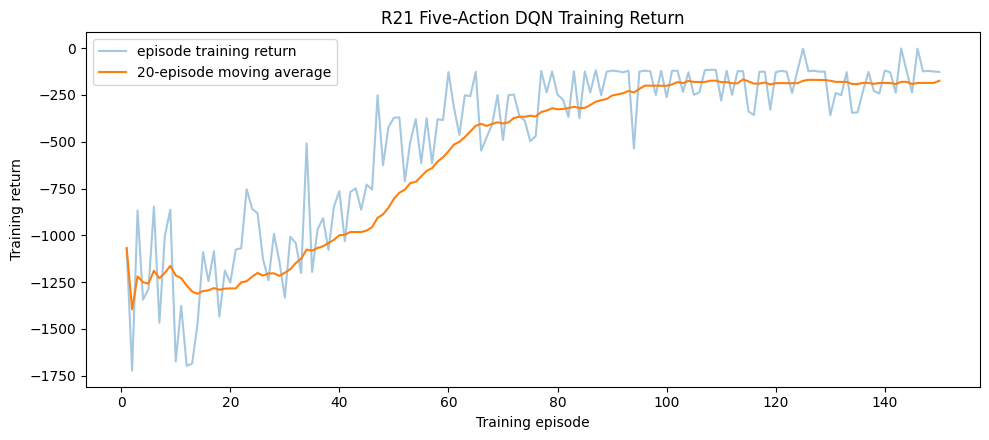

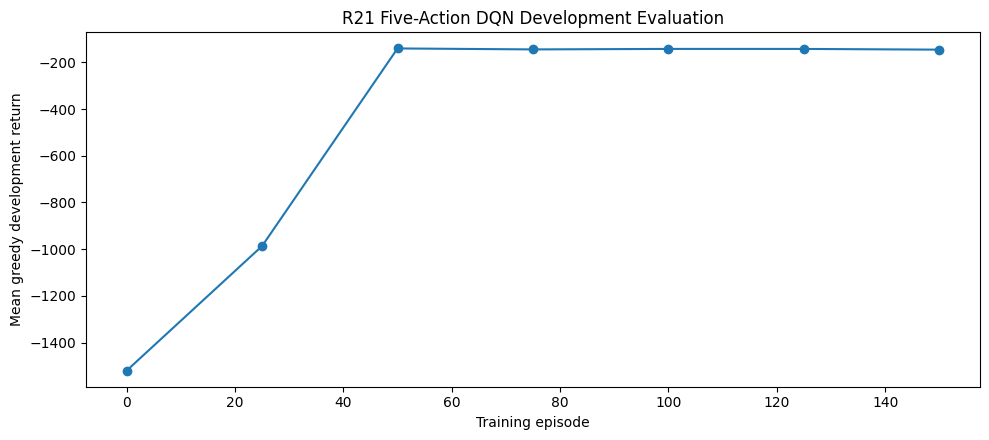

Five-action run completed: True
Selected checkpoint episode: 50
Mean development return: -140.76384770194093
Development return standard deviation: 104.53733095229252
Upright fraction: 0.8666666666666666
Parameter count: 4741
Formal runs completed: 2
Remaining formal-run capacity: 26
Saved history: histories\R21_ACTIONS_5_history.csv
Saved development evaluations: histories\R21_ACTIONS_5_development_evaluations.csv
Saved summary: histories\R21_ACTIONS_5_summary.csv
Saved selected weights: selected_weights\R21_ACTIONS_5_best.weights.h5
Section 7.3 five-action DQN: COMPLETE


In [45]:
R21_RUN_ID = "R21_ACTIONS_5"
R21_TORQUE_VALUES = ACTION_SET_CANDIDATES[5].copy()

R21_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR / f"{R21_RUN_ID}_best.weights.h5"
)
R21_HISTORY_PATH = (
    HISTORIES_DIR / f"{R21_RUN_ID}_history.csv"
)
R21_EVALUATION_PATH = (
    HISTORIES_DIR
    / f"{R21_RUN_ID}_development_evaluations.csv"
)
R21_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R21_RUN_ID}_development_evaluation_summary.csv"
)
R21_SUMMARY_PATH = (
    HISTORIES_DIR / f"{R21_RUN_ID}_summary.csv"
)
R21_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / f"{R21_RUN_ID}_selected_state_results.csv"
)

assert FORMAL_RUNS_COMPLETED < APPROVED_HARD_FORMAL_RUN_CAP
assert np.array_equal(
    R21_TORQUE_VALUES,
    np.array([-2.0, -1.0, 0.0, 1.0, 2.0], dtype=np.float32),
)


# Generalise the previously validated target helper from the temporary
# three-action pilot set to the current model's actual output dimension.
def compute_vanilla_dqn_bellman_targets(
    rewards: np.ndarray,
    next_states: np.ndarray,
    target_network: keras.Model,
    gamma: float,
) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
    """Compute nonterminal Vanilla DQN targets for any validated action count."""
    assert PENDULUM_TRANSITIONS_ARE_NONTERMINAL is True

    reward_tensor = tf.convert_to_tensor(rewards, dtype=tf.float32)
    next_state_tensor = tf.convert_to_tensor(
        next_states,
        dtype=tf.float32,
    )

    assert reward_tensor.shape.rank == 1
    assert next_state_tensor.shape.rank == 2
    assert int(next_state_tensor.shape[0]) == int(
        reward_tensor.shape[0]
    )
    assert int(next_state_tensor.shape[1]) == DQN_STATE_DIM

    gamma_value = float(gamma)
    assert np.isfinite(gamma_value)
    assert 0.0 <= gamma_value <= 1.0

    expected_action_count = int(target_network.output_shape[-1])
    assert expected_action_count > 1

    next_q_values = target_network(
        next_state_tensor,
        training=False,
    )
    assert next_q_values.shape.rank == 2
    assert int(next_q_values.shape[0]) == int(
        reward_tensor.shape[0]
    )
    assert int(next_q_values.shape[1]) == expected_action_count

    maximum_next_q_values = tf.reduce_max(
        next_q_values,
        axis=1,
    )
    bellman_targets = (
        reward_tensor
        + tf.cast(gamma_value, tf.float32)
        * maximum_next_q_values
    )

    assert bool(tf.reduce_all(tf.math.is_finite(next_q_values)))
    assert bool(
        tf.reduce_all(
            tf.math.is_finite(maximum_next_q_values)
        )
    )
    assert bool(
        tf.reduce_all(tf.math.is_finite(bellman_targets))
    )

    return (
        bellman_targets,
        maximum_next_q_values,
        next_q_values,
    )


def vanilla_dqn_gradient_update(
    main_network: keras.Model,
    target_network: keras.Model,
    optimizer: keras.optimizers.Optimizer,
    states: np.ndarray,
    action_indices: np.ndarray,
    rewards: np.ndarray,
    next_states: np.ndarray,
    gamma: float,
) -> Dict[str, object]:
    """Apply one MSE Vanilla DQN update for the model's action count."""
    state_tensor = tf.convert_to_tensor(
        states,
        dtype=tf.float32,
    )
    action_tensor = tf.convert_to_tensor(
        action_indices,
        dtype=tf.int32,
    )

    action_count = int(main_network.output_shape[-1])
    assert action_count == int(target_network.output_shape[-1])
    assert action_count > 1

    assert state_tensor.shape.rank == 2
    assert int(state_tensor.shape[1]) == DQN_STATE_DIM
    assert action_tensor.shape.rank == 1
    assert int(action_tensor.shape[0]) == int(
        state_tensor.shape[0]
    )
    assert bool(tf.reduce_all(action_tensor >= 0))
    assert bool(tf.reduce_all(action_tensor < action_count))

    bellman_targets, _, _ = (
        compute_vanilla_dqn_bellman_targets(
            rewards=rewards,
            next_states=next_states,
            target_network=target_network,
            gamma=gamma,
        )
    )
    bellman_targets = tf.stop_gradient(bellman_targets)

    with tf.GradientTape() as tape:
        all_q_values = main_network(
            state_tensor,
            training=True,
        )
        assert int(all_q_values.shape[1]) == action_count

        selected_action_q_values = tf.gather(
            all_q_values,
            action_tensor,
            axis=1,
            batch_dims=1,
        )
        temporal_difference = (
            bellman_targets - selected_action_q_values
        )
        loss = tf.reduce_mean(
            tf.square(temporal_difference)
        )

    gradients = tape.gradient(
        loss,
        main_network.trainable_variables,
    )

    assert selected_action_q_values.shape == (
        bellman_targets.shape
    )
    assert bool(tf.math.is_finite(loss))
    assert all(gradient is not None for gradient in gradients)
    assert all(
        bool(tf.reduce_all(tf.math.is_finite(gradient)))
        for gradient in gradients
    )

    gradient_global_norm = tf.linalg.global_norm(gradients)
    assert bool(tf.math.is_finite(gradient_global_norm))
    assert float(gradient_global_norm.numpy()) > 0.0

    optimizer.apply_gradients(
        zip(gradients, main_network.trainable_variables)
    )

    return {
        "loss": float(loss.numpy()),
        "gradient_global_norm": float(
            gradient_global_norm.numpy()
        ),
        "selected_action_q_values": (
            selected_action_q_values.numpy()
        ),
        "bellman_targets": bellman_targets.numpy(),
        "temporal_difference": temporal_difference.numpy(),
        "optimizer_iterations": int(
            optimizer.iterations.numpy()
        ),
    }


# Smoke-test the generalised helpers with the highest five-action index.
generalisation_main, generalisation_target = (
    initialise_main_and_target_networks(
        state_dim=DQN_STATE_DIM,
        action_count=5,
        seed=42,
    )
)
generalisation_optimizer = keras.optimizers.Adam(
    learning_rate=ACTION_COMPARISON_LEARNING_RATE
)
generalisation_result = vanilla_dqn_gradient_update(
    main_network=generalisation_main,
    target_network=generalisation_target,
    optimizer=generalisation_optimizer,
    states=np.array(
        [
            [1.0, 0.0, 0.0],
            [0.0, 1.0, 0.5],
        ],
        dtype=np.float32,
    ),
    action_indices=np.array([0, 4], dtype=np.int32),
    rewards=np.array([-1.0, -2.0], dtype=np.float32),
    next_states=np.array(
        [
            [0.99, 0.10, 0.1],
            [-0.10, 0.99, 0.4],
        ],
        dtype=np.float32,
    ),
    gamma=ACTION_COMPARISON_GAMMA,
)
assert generalisation_result["optimizer_iterations"] == 1
assert np.isfinite(generalisation_result["loss"])
assert np.isfinite(
    generalisation_result["gradient_global_norm"]
)
print("Five-action helper generalisation smoke test: PASS")


def action_comparison_epsilon(environment_step: int) -> float:
    """Use the locked action-comparison exploration schedule."""
    progress = min(
        1.0,
        int(environment_step)
        / ACTION_COMPARISON_EPSILON_DECAY_STEPS,
    )
    return float(
        ACTION_COMPARISON_EPSILON_START
        + progress
        * (
            ACTION_COMPARISON_EPSILON_END
            - ACTION_COMPARISON_EPSILON_START
        )
    )


def evaluate_action_comparison_model(
    model: keras.Model,
    torque_values: np.ndarray,
    run_id: str,
    episode: int,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    """Greedily evaluate one action-set candidate on development states."""
    validated_torques = validate_discrete_torque_values(
        torque_values
    )

    def greedy_policy(observation: np.ndarray) -> float:
        _, torque, _ = greedy_discrete_action(
            model,
            observation,
            validated_torques,
        )
        return torque

    state_results = evaluate_policy_on_physical_states(
        env_builder=lambda: make_pendulum_env(
            GRAVITY_SETTINGS["default"]
        ),
        policy=greedy_policy,
        physical_states=DEVELOPMENT_PHYSICAL_STATES,
        horizon=EVALUATION_HORIZON,
    )
    assert len(state_results) == len(
        DEVELOPMENT_PHYSICAL_STATES
    )

    state_results = state_results.copy()
    state_results.insert(0, "episode", int(episode))
    state_results.insert(0, "run_id", run_id)

    summary = {
        "episode": int(episode),
        "mean_development_return": float(
            state_results["return"].mean()
        ),
        "median_development_return": float(
            state_results["return"].median()
        ),
        "development_return_std": float(
            state_results["return"].std(ddof=1)
        ),
        "minimum_development_return": float(
            state_results["return"].min()
        ),
        "maximum_development_return": float(
            state_results["return"].max()
        ),
        "mean_upright_fraction": float(
            state_results["upright_fraction"].mean()
        ),
        "mean_abs_angle": float(
            state_results["mean_abs_angle"].mean()
        ),
        "mean_abs_angular_velocity": float(
            state_results[
                "mean_abs_angular_velocity"
            ].mean()
        ),
        "mean_abs_torque": float(
            state_results["mean_abs_torque"].mean()
        ),
        "mean_torque_direction_switching_rate": float(
            state_results["torque_direction_switching_rate"].mean()
        ),
    }
    assert np.isfinite(
        np.asarray(list(summary.values()), dtype=np.float64)
    ).all()

    return state_results, summary


def run_vanilla_action_comparison(
    run_id: str,
    torque_values: np.ndarray,
    seed: int,
    weight_path: Path,
) -> Dict[str, object]:
    """Run one fresh matched Vanilla action-set experiment."""
    validated_torques = validate_discrete_torque_values(
        torque_values
    )
    action_count = len(validated_torques)

    tf.keras.utils.set_random_seed(seed)
    np.random.seed(seed)
    epsilon_rng = random.Random(seed + 1_000)
    replay_rng = random.Random(seed + 2_000)

    main_network, target_network = (
        initialise_main_and_target_networks(
            state_dim=DQN_STATE_DIM,
            action_count=action_count,
            seed=seed,
        )
    )
    optimizer = keras.optimizers.Adam(
        learning_rate=ACTION_COMPARISON_LEARNING_RATE
    )
    replay_memory = ReplayMemory(
        capacity=ACTION_COMPARISON_REPLAY_CAPACITY,
        state_dim=DQN_STATE_DIM,
        action_count=action_count,
    )

    development_observations = np.stack([
        expected_observation(
            float(theta),
            float(theta_dot),
        )
        for theta, theta_dot in DEVELOPMENT_PHYSICAL_STATES
    ]).astype(np.float32)

    history_records = []
    evaluation_frames = []
    evaluation_records = []

    environment_steps = 0
    random_action_count = 0
    greedy_action_count = 0
    target_update_count = 0
    best_mean_return = -np.inf
    best_episode = None

    total_start = time.perf_counter()

    initial_states, initial_summary = (
        evaluate_action_comparison_model(
            model=main_network,
            torque_values=validated_torques,
            run_id=run_id,
            episode=0,
        )
    )
    evaluation_frames.append(initial_states)
    evaluation_records.append(initial_summary)

    best_mean_return = initial_summary[
        "mean_development_return"
    ]
    best_episode = 0
    main_network.save_weights(weight_path)

    print(
        f"Episode   0 | development mean return "
        f"{best_mean_return:10.3f} | initial checkpoint"
    )

    env = make_pendulum_env(
        GRAVITY_SETTINGS["default"]
    )
    env.seed(seed)

    try:
        for episode in range(
            1,
            ACTION_COMPARISON_EPISODES + 1,
        ):
            observation = np.asarray(
                env.reset(),
                dtype=np.float32,
            )
            episode_return = 0.0
            episode_losses = []
            episode_gradient_norms = []
            episode_random_actions = 0
            episode_greedy_actions = 0
            episode_target_updates = 0
            episode_start = time.perf_counter()

            for step_index in range(EVALUATION_HORIZON):
                epsilon = action_comparison_epsilon(
                    environment_steps
                )
                action_index, torque, was_random = (
                    epsilon_greedy_discrete_action(
                        model=main_network,
                        observation=observation,
                        torque_values=validated_torques,
                        epsilon=epsilon,
                        rng=epsilon_rng,
                    )
                )

                episode_random_actions += int(was_random)
                episode_greedy_actions += int(not was_random)
                random_action_count += int(was_random)
                greedy_action_count += int(not was_random)

                next_observation, reward, done, info = (
                    env.step(
                        np.array(
                            [torque],
                            dtype=np.float32,
                        )
                    )
                )
                next_observation = np.asarray(
                    next_observation,
                    dtype=np.float32,
                )

                replay_memory.append(
                    state=observation,
                    action_index=action_index,
                    reward=float(reward),
                    next_state=next_observation,
                )

                observation = next_observation
                episode_return += float(reward)
                environment_steps += 1

                if (
                    len(replay_memory)
                    >= ACTION_COMPARISON_REPLAY_WARMUP
                ):
                    batch = replay_memory.sample(
                        batch_size=(
                            ACTION_COMPARISON_BATCH_SIZE
                        ),
                        rng=replay_rng,
                    )
                    update_result = (
                        vanilla_dqn_gradient_update(
                            main_network=main_network,
                            target_network=target_network,
                            optimizer=optimizer,
                            states=batch[0],
                            action_indices=batch[1],
                            rewards=batch[2],
                            next_states=batch[3],
                            gamma=ACTION_COMPARISON_GAMMA,
                        )
                    )
                    episode_losses.append(
                        update_result["loss"]
                    )
                    episode_gradient_norms.append(
                        update_result[
                            "gradient_global_norm"
                        ]
                    )

                    target_updated = (
                        hard_update_target_network_if_due(
                            main_network=main_network,
                            target_network=target_network,
                            optimizer_step=int(
                                optimizer.iterations.numpy()
                            ),
                            update_frequency=(
                                ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY
                            ),
                        )
                    )
                    episode_target_updates += int(
                        target_updated
                    )
                    target_update_count += int(
                        target_updated
                    )

                if done:
                    assert info.get(
                        "TimeLimit.truncated"
                    ) is True
                    assert (
                        step_index + 1
                        == EVALUATION_HORIZON
                    )
                    break

            assert step_index + 1 == EVALUATION_HORIZON

            q_values = main_network(
                tf.convert_to_tensor(
                    development_observations,
                    dtype=tf.float32,
                ),
                training=False,
            ).numpy()
            assert q_values.shape == (
                len(DEVELOPMENT_PHYSICAL_STATES),
                action_count,
            )
            assert np.isfinite(q_values).all()

            history_records.append({
                "run_id": run_id,
                "episode": int(episode),
                "environment_steps": int(
                    environment_steps
                ),
                "optimizer_updates": int(
                    optimizer.iterations.numpy()
                ),
                "training_return": float(
                    episode_return
                ),
                "epsilon": float(epsilon),
                "mean_loss": (
                    float(np.mean(episode_losses))
                    if episode_losses
                    else np.nan
                ),
                "mean_gradient_global_norm": (
                    float(
                        np.mean(
                            episode_gradient_norms
                        )
                    )
                    if episode_gradient_norms
                    else np.nan
                ),
                "mean_q": float(np.mean(q_values)),
                "max_q": float(np.max(q_values)),
                "random_actions": int(
                    episode_random_actions
                ),
                "greedy_actions": int(
                    episode_greedy_actions
                ),
                "target_updates": int(
                    episode_target_updates
                ),
                "replay_size": int(
                    len(replay_memory)
                ),
                "episode_runtime_seconds": float(
                    time.perf_counter()
                    - episode_start
                ),
            })

            if (
                episode
                % ACTION_COMPARISON_EVALUATION_FREQUENCY
                == 0
            ):
                replay_size_before = len(
                    replay_memory
                )
                state_results, evaluation_summary = (
                    evaluate_action_comparison_model(
                        model=main_network,
                        torque_values=validated_torques,
                        run_id=run_id,
                        episode=episode,
                    )
                )
                assert len(replay_memory) == (
                    replay_size_before
                )

                evaluation_frames.append(
                    state_results
                )
                evaluation_records.append(
                    evaluation_summary
                )

                mean_return = evaluation_summary[
                    "mean_development_return"
                ]
                if mean_return > best_mean_return:
                    main_network.save_weights(
                        weight_path
                    )
                    best_mean_return = mean_return
                    best_episode = int(episode)

                print(
                    f"Episode {episode:3d} | "
                    f"development mean return "
                    f"{mean_return:10.3f} | best "
                    f"{best_mean_return:10.3f} "
                    f"at episode {best_episode}"
                )
    finally:
        env.close()

    total_runtime_seconds = (
        time.perf_counter() - total_start
    )

    history = pd.DataFrame(history_records)
    history["moving_average_return"] = (
        history["training_return"]
        .rolling(
            R10_MOVING_AVERAGE_WINDOW,
            min_periods=1,
        )
        .mean()
    )

    evaluation_states = pd.concat(
        evaluation_frames,
        ignore_index=True,
    )
    evaluation_summary = pd.DataFrame(
        evaluation_records
    )
    evaluation_map = dict(zip(
        evaluation_summary["episode"],
        evaluation_summary[
            "mean_development_return"
        ],
    ))
    history["evaluation_return"] = (
        history["episode"].map(evaluation_map)
    )

    selected_model = build_standard_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=action_count,
        hidden_units=STANDARD_HIDDEN_UNITS,
        model_name=(
            f"{run_id.lower()}_selected_q_network"
        ),
    )
    selected_model.load_weights(weight_path)

    selected_states, selected_summary = (
        evaluate_action_comparison_model(
            model=selected_model,
            torque_values=validated_torques,
            run_id=run_id,
            episode=int(best_episode),
        )
    )

    assert np.isclose(
        selected_summary[
            "mean_development_return"
        ],
        best_mean_return,
        rtol=1e-7,
        atol=1e-7,
    )

    selected_q_values = selected_model(
        tf.convert_to_tensor(
            development_observations,
            dtype=tf.float32,
        ),
        training=False,
    ).numpy()
    assert selected_q_values.shape == (
        len(DEVELOPMENT_PHYSICAL_STATES),
        action_count,
    )
    assert np.isfinite(selected_q_values).all()

    summary_record = {
        "run_id": run_id,
        "source_run_id": run_id,
        "reused_existing_run": False,
        "new_training_run_consumed": True,
        "model": "Vanilla DQN",
        "gravity": "default",
        "seed": int(seed),
        "action_count": int(action_count),
        "torque_values": validated_torques.tolist(),
        "episodes": int(
            ACTION_COMPARISON_EPISODES
        ),
        "environment_steps": int(
            environment_steps
        ),
        "optimizer_updates": int(
            optimizer.iterations.numpy()
        ),
        "selected_checkpoint_episode": int(
            best_episode
        ),
        "mean_development_return": float(
            selected_summary[
                "mean_development_return"
            ]
        ),
        "development_return_std": float(
            selected_summary[
                "development_return_std"
            ]
        ),
        "upright_fraction": float(
            selected_summary[
                "mean_upright_fraction"
            ]
        ),
        "mean_abs_angle": float(
            selected_summary["mean_abs_angle"]
        ),
        "mean_abs_angular_velocity": float(
            selected_summary[
                "mean_abs_angular_velocity"
            ]
        ),
        "mean_abs_torque": float(
            selected_summary["mean_abs_torque"]
        ),
        "torque_direction_switching_rate": float(
            selected_summary[
                "mean_torque_direction_switching_rate"
            ]
        ),
        "random_actions": int(
            random_action_count
        ),
        "greedy_actions": int(
            greedy_action_count
        ),
        "target_updates": int(
            target_update_count
        ),
        "runtime_minutes": float(
            total_runtime_seconds / 60.0
        ),
        "parameter_count": int(
            selected_model.count_params()
        ),
        "weight_path": str(weight_path),
        "technical_status": "PASS",
    }

    return {
        "main_network": main_network,
        "target_network": target_network,
        "selected_model": selected_model,
        "history": history,
        "evaluation_states": evaluation_states,
        "evaluation_summary": evaluation_summary,
        "selected_state_results": selected_states,
        "selected_summary": selected_summary,
        "summary_record": summary_record,
    }


r21_required_artifacts = [
    R21_WEIGHT_PATH,
    R21_HISTORY_PATH,
    R21_EVALUATION_PATH,
    R21_EVALUATION_SUMMARY_PATH,
    R21_SUMMARY_PATH,
    R21_STATE_RESULTS_PATH,
]
r21_artifacts_complete = all(
    path.exists() for path in r21_required_artifacts
)

if (
    5 in ACTION_SET_EXPERIMENT_RESULTS
    and all(
        name in globals()
        for name in [
            "r21_history",
            "r21_evaluation_states",
            "r21_evaluation_summary",
            "r21_selected_state_results",
            "r21_summary_record",
            "r21_summary",
        ]
    )
):
    print(
        "R21 five-action result already exists in memory; "
        "no duplicate training run was started."
    )
elif r21_artifacts_complete:
    r21_history = read_csv_with_control_metric_migration(R21_HISTORY_PATH)
    r21_evaluation_states = read_csv_with_control_metric_migration(
        R21_EVALUATION_PATH
    )
    r21_evaluation_summary = read_csv_with_control_metric_migration(
        R21_EVALUATION_SUMMARY_PATH
    )
    r21_summary = read_csv_with_control_metric_migration(R21_SUMMARY_PATH)
    r21_selected_state_results = read_csv_with_control_metric_migration(
        R21_STATE_RESULTS_PATH
    )

    assert len(r21_summary) == 1
    r21_summary_record = r21_summary.iloc[0].to_dict()
    r21_summary_record["reused_existing_run"] = bool(
        r21_summary_record["reused_existing_run"]
    )
    r21_summary_record["new_training_run_consumed"] = bool(
        r21_summary_record["new_training_run_consumed"]
    )

    r21_selected_model = build_standard_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=5,
        hidden_units=STANDARD_HIDDEN_UNITS,
        model_name="r21_actions_5_reloaded_q_network",
    )
    r21_selected_model.load_weights(R21_WEIGHT_PATH)

    r21_result = {
        "selected_model": r21_selected_model,
        "history": r21_history,
        "evaluation_states": r21_evaluation_states,
        "evaluation_summary": r21_evaluation_summary,
        "selected_state_results": r21_selected_state_results,
        "summary_record": r21_summary_record,
    }
    print(
        "Loaded completed R21 five-action artifacts; "
        "no duplicate training run was started."
    )
else:
    r21_result = run_vanilla_action_comparison(
        run_id=R21_RUN_ID,
        torque_values=R21_TORQUE_VALUES,
        seed=ACTION_COMPARISON_SEED,
        weight_path=R21_WEIGHT_PATH,
    )

    r21_history = r21_result["history"]
    r21_evaluation_states = r21_result[
        "evaluation_states"
    ]
    r21_evaluation_summary = r21_result[
        "evaluation_summary"
    ]
    r21_selected_state_results = r21_result[
        "selected_state_results"
    ]
    r21_summary_record = r21_result["summary_record"]
    r21_summary = pd.DataFrame([r21_summary_record])

ACTION_SET_EXPERIMENT_RESULTS[5] = (
    r21_summary_record
)
FORMAL_RUNS_COMPLETED = 1 + sum(
    int(record["new_training_run_consumed"])
    for record in ACTION_SET_EXPERIMENT_RESULTS.values()
)
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 2
assert remaining_formal_run_capacity == 26
assert len(r21_history) == ACTION_COMPARISON_EPISODES
assert len(r21_evaluation_summary) == 7
assert r21_summary_record["action_count"] == 5
assert r21_summary_record["parameter_count"] == 4741
assert r21_summary_record[
    "environment_steps"
] == 30_000
assert r21_summary_record[
    "optimizer_updates"
] == 29_001
assert np.isfinite(
    r21_selected_state_results["return"].to_numpy()
).all()

r21_history.to_csv(
    R21_HISTORY_PATH,
    index=False,
)
r21_evaluation_states.to_csv(
    R21_EVALUATION_PATH,
    index=False,
)
r21_evaluation_summary.to_csv(
    R21_EVALUATION_SUMMARY_PATH,
    index=False,
)
r21_summary.to_csv(
    R21_SUMMARY_PATH,
    index=False,
)
r21_selected_state_results.to_csv(
    R21_STATE_RESULTS_PATH,
    index=False,
)

display(r21_evaluation_summary)
display(r21_summary)
display(r21_history.tail(10))

plt.figure(figsize=(10, 4.5))
plt.plot(
    r21_history["episode"],
    r21_history["training_return"],
    alpha=0.4,
    label="episode training return",
)
plt.plot(
    r21_history["episode"],
    r21_history["moving_average_return"],
    label=(
        f"{R10_MOVING_AVERAGE_WINDOW}-episode "
        "moving average"
    ),
)
plt.xlabel("Training episode")
plt.ylabel("Training return")
plt.title("R21 Five-Action DQN Training Return")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(
    r21_evaluation_summary["episode"],
    r21_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("R21 Five-Action DQN Development Evaluation")
plt.tight_layout()
plt.show()

print("Five-action run completed:", True)
print(
    "Selected checkpoint episode:",
    r21_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    r21_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    r21_summary_record[
        "development_return_std"
    ],
)
print(
    "Upright fraction:",
    r21_summary_record["upright_fraction"],
)
print(
    "Parameter count:",
    r21_summary_record["parameter_count"],
)
print("Formal runs completed:", FORMAL_RUNS_COMPLETED)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print("Saved history:", R21_HISTORY_PATH)
print(
    "Saved development evaluations:",
    R21_EVALUATION_PATH,
)
print("Saved summary:", R21_SUMMARY_PATH)
print("Saved selected weights:", R21_WEIGHT_PATH)
print("Section 7.3 five-action DQN: COMPLETE")


### 7.3 Result Interpretation

**Finding.** The five-action run completed all `150` episodes, `30,000`
environment steps and `29,001` optimiser updates without technical failure.
Its selected checkpoint was episode `50`, with a mean development return of
`-140.763848`, development-state standard deviation of `104.537331` and
upright fraction of `0.866667`.

Compared with the three-action reference, the five-action mean return was
`0.686465` lower, while the upright fractions were nearly identical. The
five-action model used less mean absolute torque (`1.469167` versus
`1.712083`) but switched torque more frequently (`0.770519` versus
`0.739322`).

**Decision.** Retain the five-action run as valid evidence, but do not select
an action set yet. At seed `42`, it has not shown a clear return advantage over
three actions.

**Caveat.** The practical improvement margin has not yet been calibrated
across training seeds. A difference below one return point must not be
overinterpreted, and the final action decision also requires the seven-action
run and paired state-level evidence.

**Next step.** Train the seven-action Vanilla DQN from fresh weights under the
same controls.


## 7.4 Seven-Action DQN

**Question.** Does increasing the torque set to seven uniformly spaced actions
improve control enough to justify the larger DQN output space?

**Reason.** Seven actions provide the finest planned torque resolution,
including intermediate magnitudes near `0.67` and `1.33`. This may improve
fine corrections near upright, but it also increases exploration difficulty
and model output size.

**Hypothesis.** Seven actions may reduce excessive torque magnitude and improve
fine balance control, although learning may be slower because the agent must
estimate more action values.

**References.**

- `R20_ACTIONS_3`
- `R21_ACTIONS_5`

**Primary change.** Torque set only:

```text
[-2.0, -1.0, 0.0, 1.0, 2.0]
→
[-2.0, -1.3333, -0.6667, 0.0, 0.6667, 1.3333, 2.0]
```

**Controlled factors.**

- Vanilla DQN with two `64`-unit ReLU hidden layers;
- default gravity;
- seed `42`;
- raw state representation;
- replay capacity `10,000`;
- replay warm-up `1,000`;
- batch size `32`;
- gamma `0.99`;
- Adam learning rate `0.001`;
- MSE loss;
- epsilon from `1.0` to `0.05` over `20,000` steps;
- hard target copy every `250` optimiser updates;
- `150` episodes of `200` steps;
- greedy development evaluation every `25` episodes;
- identical development states and checkpoint rule.

**Training budget.** One fresh formal run. After completion, the total formal
run count should be `3`, leaving `25` runs under the approved cap.

**Evaluation evidence.**

- complete training and evaluation histories;
- selected development checkpoint;
- finite loss, gradients and Q-values;
- replay and target-update counts;
- control metrics;
- runtime and parameter count;
- fresh-model weight reload;
- per-state results for the later paired comparison.

**Decision rule.** Keep the result whenever it is technically valid. Select
the action set only in Sections 7.6 and 7.7 after comparing all three
candidates.


Loaded completed R22 seven-action artifacts; no duplicate training run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1518.751911,-1492.585927,101.846004,-1657.561553,-1355.582957,0.090625,1.555617,6.241910,1.933750,0.014028
1,25,-785.835574,-895.689118,307.812459,-990.044797,-0.396451,0.243125,1.111933,3.596739,1.232639,0.207077
2,50,-155.333161,-126.172512,121.596112,-410.382897,-1.203121,0.851250,0.314954,0.536214,0.537917,0.483040
3,75,-148.682473,-124.791925,110.552018,-350.667289,-2.142257,0.856458,0.318677,0.540127,0.879583,0.654732
4,100,-139.818601,-125.981895,101.098652,-348.037733,-2.403016,0.872292,0.303639,0.509886,0.642361,0.451214
5,125,-144.866809,-125.976659,110.099515,-369.561395,-1.869803,0.868958,0.295948,0.527784,1.135000,0.724246
6,150,-258.130784,-134.799724,412.345588,-1973.920880,-10.204726,0.789792,0.561632,0.668726,1.098056,0.720477


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,mean_abs_angular_velocity,mean_abs_torque,torque_direction_switching_rate,random_actions,greedy_actions,target_updates,runtime_minutes,parameter_count,weight_path,technical_status
0,R22_ACTIONS_7,R22_ACTIONS_7,False,True,Vanilla DQN,default,42,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,0.509886,0.642361,0.451214,10979,19021,116,11.902179,4871,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS


,run_id,episode,environment_steps,optimizer_updates,training_return,epsilon,mean_loss,mean_gradient_global_norm,mean_q,max_q,random_actions,greedy_actions,target_updates,replay_size,episode_runtime_seconds,moving_average_return,evaluation_return
140,R22_ACTIONS_7,141,28200,27201,-128.264861,0.05,1.402981,91.822301,-111.936096,8.373711,9,191,0,10000,4.727857,-192.901215,NaN
141,R22_ACTIONS_7,142,28400,27401,-240.595595,0.05,1.301323,94.165344,-111.671944,8.352441,4,196,1,10000,6.841013,-198.484336,NaN
142,R22_ACTIONS_7,143,28600,27601,-3.464409,0.05,1.172631,82.245079,-111.218353,8.135453,8,192,1,10000,9.642857,-186.294227,NaN
143,R22_ACTIONS_7,144,28800,27801,-125.606932,0.05,1.497324,102.414712,-108.564697,8.116503,10,190,1,10000,6.134699,-180.291277,NaN
144,R22_ACTIONS_7,145,29000,28001,-119.215323,0.05,1.394007,91.595863,-109.410828,8.430601,11,189,1,10000,5.547886,-186.079441,NaN
145,R22_ACTIONS_7,146,29200,28201,-133.114975,0.05,1.532668,101.410626,-107.787445,8.436701,14,186,0,10000,5.815166,-186.543683,NaN
146,R22_ACTIONS_7,147,29400,28401,-126.861604,0.05,2.016622,122.843546,-107.592705,9.362831,10,190,1,10000,5.961120,-186.723790,NaN
147,R22_ACTIONS_7,148,29600,28601,-123.817400,0.05,1.929555,120.435902,-106.153145,9.270513,11,189,1,10000,4.751537,-186.580174,NaN
148,R22_ACTIONS_7,149,29800,28801,-128.156149,0.05,2.116283,122.726154,-104.395439,9.517379,9,191,1,10000,5.206681,-186.922952,NaN
149,R22_ACTIONS_7,150,30000,29001,-388.019163,0.05,1.587915,97.728191,-103.922096,9.555112,11,189,1,10000,5.801434,-188.884793,-258.130784


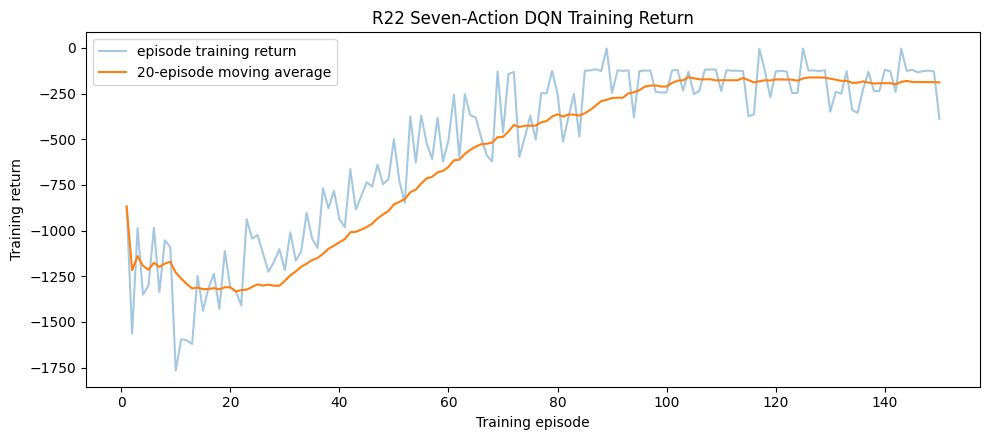

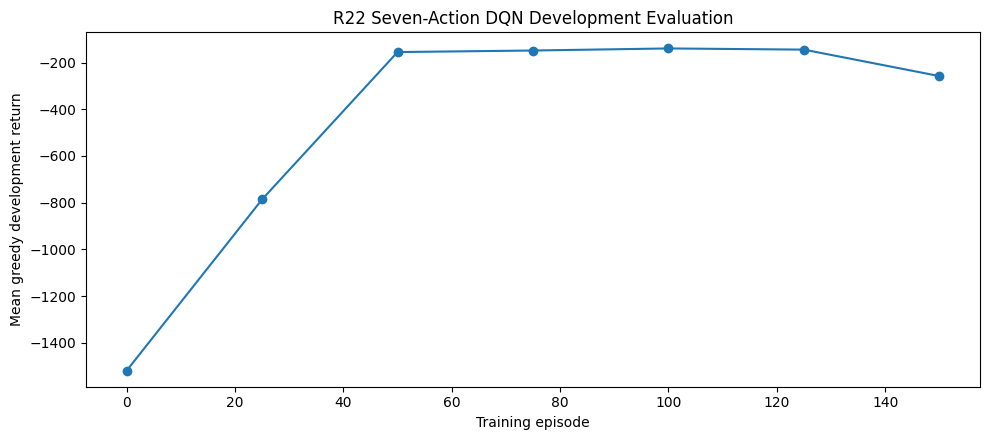

Seven-action run completed: True
Selected checkpoint episode: 100
Mean development return: -139.81860126694502
Development return standard deviation: 101.09865245009986
Upright fraction: 0.8722916666666668
Mean absolute torque: 0.6423611118892829
Torque-direction switching rate: 0.4512144053601339
Parameter count: 4871
Formal runs completed: 3
Remaining formal-run capacity: 25
Saved history: histories\R22_ACTIONS_7_history.csv
Saved development evaluations: histories\R22_ACTIONS_7_development_evaluations.csv
Saved summary: histories\R22_ACTIONS_7_summary.csv
Saved selected weights: selected_weights\R22_ACTIONS_7_best.weights.h5
Section 7.4 seven-action DQN: COMPLETE


In [46]:
R22_RUN_ID = "R22_ACTIONS_7"
R22_TORQUE_VALUES = ACTION_SET_CANDIDATES[7].copy()

R22_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR / f"{R22_RUN_ID}_best.weights.h5"
)
R22_HISTORY_PATH = (
    HISTORIES_DIR / f"{R22_RUN_ID}_history.csv"
)
R22_EVALUATION_PATH = (
    HISTORIES_DIR
    / f"{R22_RUN_ID}_development_evaluations.csv"
)
R22_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R22_RUN_ID}_development_evaluation_summary.csv"
)
R22_SUMMARY_PATH = (
    HISTORIES_DIR / f"{R22_RUN_ID}_summary.csv"
)
R22_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / f"{R22_RUN_ID}_selected_state_results.csv"
)

assert FORMAL_RUNS_COMPLETED in (2, 3)
if 7 not in ACTION_SET_EXPERIMENT_RESULTS:
    assert FORMAL_RUNS_COMPLETED == 2
assert FORMAL_RUNS_COMPLETED < APPROVED_HARD_FORMAL_RUN_CAP
assert np.array_equal(
    R22_TORQUE_VALUES,
    np.linspace(-2.0, 2.0, 7, dtype=np.float32),
)

r22_required_artifacts = [
    R22_WEIGHT_PATH,
    R22_HISTORY_PATH,
    R22_EVALUATION_PATH,
    R22_EVALUATION_SUMMARY_PATH,
    R22_SUMMARY_PATH,
    R22_STATE_RESULTS_PATH,
]
r22_artifacts_complete = all(
    path.exists() for path in r22_required_artifacts
)

if (
    7 in ACTION_SET_EXPERIMENT_RESULTS
    and all(
        name in globals()
        for name in [
            "r22_history",
            "r22_evaluation_states",
            "r22_evaluation_summary",
            "r22_selected_state_results",
            "r22_summary_record",
            "r22_summary",
        ]
    )
):
    print(
        "R22 seven-action result already exists in memory; "
        "no duplicate training run was started."
    )
elif r22_artifacts_complete:
    r22_history = read_csv_with_control_metric_migration(R22_HISTORY_PATH)
    r22_evaluation_states = read_csv_with_control_metric_migration(
        R22_EVALUATION_PATH
    )
    r22_evaluation_summary = read_csv_with_control_metric_migration(
        R22_EVALUATION_SUMMARY_PATH
    )
    r22_summary = read_csv_with_control_metric_migration(R22_SUMMARY_PATH)
    r22_selected_state_results = read_csv_with_control_metric_migration(
        R22_STATE_RESULTS_PATH
    )

    assert len(r22_summary) == 1
    r22_summary_record = r22_summary.iloc[0].to_dict()
    r22_summary_record["reused_existing_run"] = bool(
        r22_summary_record["reused_existing_run"]
    )
    r22_summary_record["new_training_run_consumed"] = bool(
        r22_summary_record["new_training_run_consumed"]
    )

    r22_selected_model = build_standard_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=7,
        hidden_units=STANDARD_HIDDEN_UNITS,
        model_name="r22_actions_7_reloaded_q_network",
    )
    r22_selected_model.load_weights(R22_WEIGHT_PATH)

    r22_result = {
        "selected_model": r22_selected_model,
        "history": r22_history,
        "evaluation_states": r22_evaluation_states,
        "evaluation_summary": r22_evaluation_summary,
        "selected_state_results": r22_selected_state_results,
        "summary_record": r22_summary_record,
    }
    print(
        "Loaded completed R22 seven-action artifacts; "
        "no duplicate training run was started."
    )
else:
    r22_result = run_vanilla_action_comparison(
        run_id=R22_RUN_ID,
        torque_values=R22_TORQUE_VALUES,
        seed=ACTION_COMPARISON_SEED,
        weight_path=R22_WEIGHT_PATH,
    )

    r22_history = r22_result["history"]
    r22_evaluation_states = r22_result[
        "evaluation_states"
    ]
    r22_evaluation_summary = r22_result[
        "evaluation_summary"
    ]
    r22_selected_state_results = r22_result[
        "selected_state_results"
    ]
    r22_summary_record = r22_result["summary_record"]
    r22_summary = pd.DataFrame([r22_summary_record])

ACTION_SET_EXPERIMENT_RESULTS[7] = (
    r22_summary_record
)
FORMAL_RUNS_COMPLETED = 1 + sum(
    int(record["new_training_run_consumed"])
    for record in ACTION_SET_EXPERIMENT_RESULTS.values()
)
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 3
assert remaining_formal_run_capacity == 25
assert len(r22_history) == ACTION_COMPARISON_EPISODES
assert len(r22_evaluation_summary) == 7
assert r22_summary_record["action_count"] == 7
assert r22_summary_record["parameter_count"] == 4871
assert r22_summary_record[
    "environment_steps"
] == 30_000
assert r22_summary_record[
    "optimizer_updates"
] == 29_001
assert r22_summary_record["target_updates"] == 116
assert (
    r22_summary_record["random_actions"]
    + r22_summary_record["greedy_actions"]
    == 30_000
)
assert np.isfinite(
    r22_selected_state_results["return"].to_numpy()
).all()
assert R22_WEIGHT_PATH.exists()

r22_history.to_csv(
    R22_HISTORY_PATH,
    index=False,
)
r22_evaluation_states.to_csv(
    R22_EVALUATION_PATH,
    index=False,
)
r22_evaluation_summary.to_csv(
    R22_EVALUATION_SUMMARY_PATH,
    index=False,
)
r22_summary.to_csv(
    R22_SUMMARY_PATH,
    index=False,
)
r22_selected_state_results.to_csv(
    R22_STATE_RESULTS_PATH,
    index=False,
)

display(r22_evaluation_summary)
display(r22_summary)
display(r22_history.tail(10))

plt.figure(figsize=(10, 4.5))
plt.plot(
    r22_history["episode"],
    r22_history["training_return"],
    alpha=0.4,
    label="episode training return",
)
plt.plot(
    r22_history["episode"],
    r22_history["moving_average_return"],
    label=(
        f"{R10_MOVING_AVERAGE_WINDOW}-episode "
        "moving average"
    ),
)
plt.xlabel("Training episode")
plt.ylabel("Training return")
plt.title("R22 Seven-Action DQN Training Return")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(
    r22_evaluation_summary["episode"],
    r22_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("R22 Seven-Action DQN Development Evaluation")
plt.tight_layout()
plt.show()

print("Seven-action run completed:", True)
print(
    "Selected checkpoint episode:",
    r22_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    r22_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    r22_summary_record[
        "development_return_std"
    ],
)
print(
    "Upright fraction:",
    r22_summary_record["upright_fraction"],
)
print(
    "Mean absolute torque:",
    r22_summary_record["mean_abs_torque"],
)
print(
    "Torque-direction switching rate:",
    r22_summary_record["torque_direction_switching_rate"],
)
print(
    "Parameter count:",
    r22_summary_record["parameter_count"],
)
print("Formal runs completed:", FORMAL_RUNS_COMPLETED)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print("Saved history:", R22_HISTORY_PATH)
print(
    "Saved development evaluations:",
    R22_EVALUATION_PATH,
)
print("Saved summary:", R22_SUMMARY_PATH)
print("Saved selected weights:", R22_WEIGHT_PATH)
print("Section 7.4 seven-action DQN: COMPLETE")


### 7.4 Result Interpretation

**Finding.** The seven-action run completed all `150` episodes, `30,000`
environment steps and `29,001` optimiser updates without technical failure.
Its selected checkpoint was episode `100`, with a mean development return of
`-139.818601`, development-state standard deviation of `101.098652` and
upright fraction of `0.872292`.

At the selected checkpoint, seven actions produced the strongest seed-42 mean
return so far:

- three actions: `-140.077383`
- five actions: `-140.763848`
- seven actions: `-139.818601`

Seven actions also used the lowest mean absolute torque (`0.642361`).
The corrected lock-review audit in Section 20.9 confirmed the lowest action
switching rate (`0.456658`), the lowest torque-direction switching rate
(`0.451214`) and the smallest mean absolute torque change (`0.908710`) among
the three action sets. Its output layer increased the model to `4,871`
parameters, which is only `260` more parameters than the three-action
network.

**Decision.** Retain the seven-action run as valid evidence and proceed to the
formal action-set comparison. Do not select the action set from the mean return
alone because the differences are small and paired state-level evidence has
not yet been summarised.

**Caveat.** The episode-150 evaluation fell to `-258.130784`, while episode
`100` remained the selected checkpoint. This shows late-training instability
in this seed and reinforces the need to preserve checkpoint selection and
later seed calibration.

**Next step.** Compare all three selected checkpoints on identical development
states, learning speed, control metrics, parameters and runtime.


## 7.5 Conditional Nine-Action DQN

Nine actions are **not activated**.

The seven-action policy already achieved the strongest seed-42 mean
development return, the highest upright fraction, the lowest mean absolute
torque, the lowest corrected action switching rate and the smallest mean
absolute torque change among the planned candidates.
There is therefore no current evidence that seven actions lack sufficient
control resolution.

Adding nine actions would increase exploration difficulty and consume one of
the four conditional run slots without answering a remaining technical
question. The nine-action branch remains excluded unless later evidence from
seed calibration reveals a specific resolution-related failure.


## 7.6 Action-Set Comparison

This subsection compares the selected three, five and seven-action
checkpoints under the locked seed-42 screening protocol.

**Primary evidence.**

- mean greedy development return;
- paired return differences on the same fixed physical states.

**Supporting evidence.**

- development-state spread;
- upright fraction;
- angle and angular-velocity behaviour;
- torque magnitude and switching;
- selected checkpoint;
- parameter count;
- runtime;
- first checkpoint exceeding the predeclared provisional reference target.

The comparison does not use the held-out final suite. It also does not claim
that seed `42` represents training-seed reliability. That question belongs to
Section 8.


,action_count,torque_values,selected_checkpoint_episode,mean_development_return,development_return_std,upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,torque_direction_switching_rate,first_episode_above_reference_target,runtime_minutes,parameter_count,technical_status
0,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",100,-139.818601,101.098652,0.872292,0.303639,0.509886,0.642361,0.451214,25,11.902179,4871,PASS
1,3,"[-2.0, 0.0, 2.0]",150,-140.077383,102.946099,0.866458,0.262557,0.582370,1.712083,0.739322,25,12.534557,4611,PASS
2,5,"[-2.0, -1.0, 0.0, 1.0, 2.0]",50,-140.763848,104.537331,0.866667,0.272548,0.555144,1.469167,0.770519,25,8.516859,4741,PASS


,reference_action_count,candidate_action_count,paired_state_count,mean_return_difference,median_return_difference,candidate_win_proportion,reference_win_proportion,exact_tie_proportion,minimum_paired_difference,maximum_paired_difference
0,3,5,24,-0.686465,0.243318,0.625000,0.375000,0.0,-18.686721,4.227291
1,3,7,24,0.258781,-0.625440,0.375000,0.625000,0.0,-5.548360,18.412504
2,5,7,24,0.945246,-0.881958,0.333333,0.666667,0.0,-4.952755,18.244387


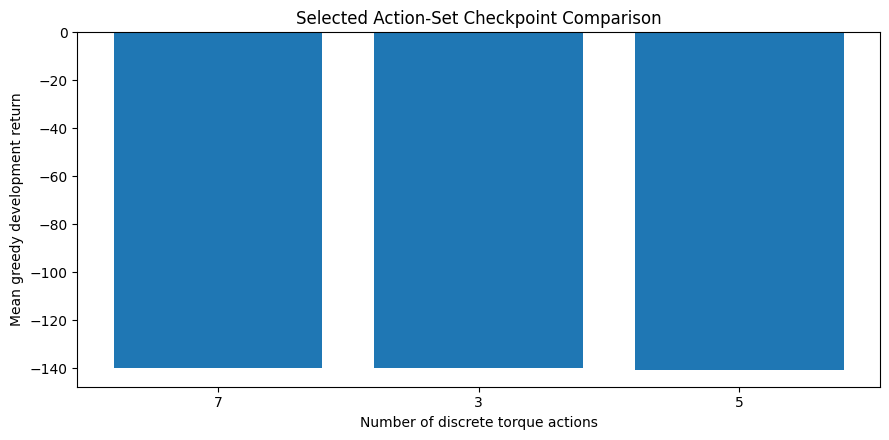

Seed-42 mean-return ranking: [7, 3, 5]
Best seed-42 mean development return: -139.81860126694502
Nine-action branch activated: False
Formal runs completed: 3
Remaining formal-run capacity: 25
Saved action-set comparison: histories\R20_R21_R22_action_set_comparison.csv
Saved paired comparison: histories\R20_R21_R22_paired_state_comparison.csv
Section 7.6 action-set comparison: PASS


In [47]:
ACTION_SET_COMPARISON_PATH = (
    HISTORIES_DIR / "R20_R21_R22_action_set_comparison.csv"
)
ACTION_SET_PAIRED_PATH = (
    HISTORIES_DIR / "R20_R21_R22_paired_state_comparison.csv"
)

required_action_counts = (3, 5, 7)
assert tuple(sorted(ACTION_SET_EXPERIMENT_RESULTS.keys())) == (
    required_action_counts
)
assert FORMAL_RUNS_COMPLETED == 3
assert remaining_formal_run_capacity == 25

selected_state_results_by_action = {
    3: r20_selected_state_results.copy(),
    5: r21_selected_state_results.copy(),
    7: r22_selected_state_results.copy(),
}
evaluation_summaries_by_action = {
    3: r10_evaluation_summary.copy(),
    5: r21_evaluation_summary.copy(),
    7: r22_evaluation_summary.copy(),
}

comparison_records = []

for action_count in required_action_counts:
    record = ACTION_SET_EXPERIMENT_RESULTS[action_count]
    evaluation_summary = evaluation_summaries_by_action[
        action_count
    ].copy()

    threshold_rows = evaluation_summary.loc[
        evaluation_summary["mean_development_return"]
        >= provisional_default_reference_target
    ]
    first_reference_threshold_episode = (
        int(threshold_rows["episode"].iloc[0])
        if len(threshold_rows) > 0
        else np.nan
    )

    comparison_records.append({
        "action_count": int(action_count),
        "torque_values": record["torque_values"],
        "selected_checkpoint_episode": int(
            record["selected_checkpoint_episode"]
        ),
        "mean_development_return": float(
            record["mean_development_return"]
        ),
        "development_return_std": float(
            record["development_return_std"]
        ),
        "upright_fraction": float(
            record["upright_fraction"]
        ),
        "mean_abs_angle": float(
            record["mean_abs_angle"]
        ),
        "mean_abs_angular_velocity": float(
            record["mean_abs_angular_velocity"]
        ),
        "mean_abs_torque": float(
            record["mean_abs_torque"]
        ),
        "torque_direction_switching_rate": float(
            record["torque_direction_switching_rate"]
        ),
        "first_episode_above_reference_target": (
            first_reference_threshold_episode
        ),
        "runtime_minutes": float(
            record["runtime_minutes"]
        ),
        "parameter_count": int(
            record["parameter_count"]
        ),
        "technical_status": record["technical_status"],
    })

action_set_comparison = pd.DataFrame(
    comparison_records
).sort_values(
    "mean_development_return",
    ascending=False,
).reset_index(drop=True)

assert len(action_set_comparison) == 3
assert (
    action_set_comparison["technical_status"] == "PASS"
).all()
assert np.isfinite(
    action_set_comparison[
        [
            "mean_development_return",
            "development_return_std",
            "upright_fraction",
            "mean_abs_angle",
            "mean_abs_angular_velocity",
            "mean_abs_torque",
            "torque_direction_switching_rate",
            "runtime_minutes",
            "parameter_count",
        ]
    ].to_numpy(dtype=np.float64)
).all()

paired_records = []

for reference_count, candidate_count in [
    (3, 5),
    (3, 7),
    (5, 7),
]:
    reference_states = (
        selected_state_results_by_action[reference_count]
        [["state_id", "return"]]
        .rename(columns={"return": "reference_return"})
        .sort_values("state_id")
        .reset_index(drop=True)
    )
    candidate_states = (
        selected_state_results_by_action[candidate_count]
        [["state_id", "return"]]
        .rename(columns={"return": "candidate_return"})
        .sort_values("state_id")
        .reset_index(drop=True)
    )

    paired = reference_states.merge(
        candidate_states,
        on="state_id",
        how="inner",
        validate="one_to_one",
    )
    assert len(paired) == len(DEVELOPMENT_PHYSICAL_STATES)
    assert np.array_equal(
        paired["state_id"].to_numpy(),
        np.arange(len(DEVELOPMENT_PHYSICAL_STATES)),
    )

    paired["candidate_minus_reference"] = (
        paired["candidate_return"]
        - paired["reference_return"]
    )

    paired_records.append({
        "reference_action_count": int(reference_count),
        "candidate_action_count": int(candidate_count),
        "paired_state_count": int(len(paired)),
        "mean_return_difference": float(
            paired["candidate_minus_reference"].mean()
        ),
        "median_return_difference": float(
            paired["candidate_minus_reference"].median()
        ),
        "candidate_win_proportion": float(
            (
                paired["candidate_minus_reference"] > 0.0
            ).mean()
        ),
        "reference_win_proportion": float(
            (
                paired["candidate_minus_reference"] < 0.0
            ).mean()
        ),
        "exact_tie_proportion": float(
            np.isclose(
                paired["candidate_minus_reference"],
                0.0,
                rtol=0.0,
                atol=1e-10,
            ).mean()
        ),
        "minimum_paired_difference": float(
            paired["candidate_minus_reference"].min()
        ),
        "maximum_paired_difference": float(
            paired["candidate_minus_reference"].max()
        ),
    })

action_set_paired_comparison = pd.DataFrame(
    paired_records
)

assert len(action_set_paired_comparison) == 3
assert (
    action_set_paired_comparison["paired_state_count"]
    == len(DEVELOPMENT_PHYSICAL_STATES)
).all()
assert np.isfinite(
    action_set_paired_comparison.drop(
        columns=[
            "reference_action_count",
            "candidate_action_count",
            "paired_state_count",
        ]
    ).to_numpy(dtype=np.float64)
).all()

action_set_comparison.to_csv(
    ACTION_SET_COMPARISON_PATH,
    index=False,
)
action_set_paired_comparison.to_csv(
    ACTION_SET_PAIRED_PATH,
    index=False,
)

display(action_set_comparison)
display(action_set_paired_comparison)

plt.figure(figsize=(9, 4.5))
plt.bar(
    action_set_comparison["action_count"].astype(str),
    action_set_comparison["mean_development_return"],
)
plt.xlabel("Number of discrete torque actions")
plt.ylabel("Mean greedy development return")
plt.title("Selected Action-Set Checkpoint Comparison")
plt.tight_layout()
plt.show()

print(
    "Seed-42 mean-return ranking:",
    action_set_comparison["action_count"].tolist(),
)
print(
    "Best seed-42 mean development return:",
    float(
        action_set_comparison.iloc[0][
            "mean_development_return"
        ]
    ),
)
print(
    "Nine-action branch activated:",
    False,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved action-set comparison:",
    ACTION_SET_COMPARISON_PATH,
)
print(
    "Saved paired comparison:",
    ACTION_SET_PAIRED_PATH,
)
print("Section 7.6 action-set comparison: PASS")


### 7.6 Result Interpretation

**Finding.** All three action-set runs passed technically. The seed-42 ranking
by the locked primary metric was:

1. seven actions: `-139.818601`;
2. three actions: `-140.077383`;
3. five actions: `-140.763848`.

Seven actions exceeded three actions by `0.258781` mean return and five actions
by `0.945246`. It also had the lowest development-state standard deviation
(`101.098652`), highest upright fraction (`0.872292`), lowest mean absolute
angular velocity (`0.509886`), lowest mean absolute torque (`0.642361`),
lowest corrected action switching rate (`0.456658`), lowest
torque-direction switching rate (`0.451214`) and smallest mean absolute
torque change (`0.908710`).

The paired evidence was mixed. Seven actions beat three actions on only
`37.5%` of states and beat five actions on `33.3%` of states. Its paired median
differences were negative, meaning its higher mean return came from larger
gains on a smaller number of states rather than small gains across most
states.

**Importance.** The primary mean-return criterion and most control diagnostics
favour seven actions, while the paired win rates caution that the advantage is
not uniform across the state suite.

**Decision.** Select seven actions for the next stages. The output layer adds
only `260` parameters compared with three actions, while providing the
strongest primary mean return and the strongest aggregate set of
supporting control metrics. Nine
actions remain excluded.

**Caveat.** This is a seed-42 screening decision, not evidence that seven
actions are stable across training seeds. Section 8 must measure training-seed
variation before small later improvements are interpreted.

**Next step.** Lock the seven-action set and begin Vanilla seed calibration.


## 7.7 Selected Action Set

The selected action set is:

```text
[-2.0000, -1.3333, -0.6667, 0.0000, 0.6667, 1.3333, 2.0000]
```

The selection follows the frozen hierarchy:

1. mean greedy development return;
2. stability and failure behaviour;
3. sample efficiency;
4. simplicity, runtime and reproducibility.

Seven actions ranked first on the primary metric and on most supporting control
metrics. The mixed paired win rates are retained as an explicit limitation
rather than hidden.

This action set is now used for Vanilla seed calibration and the later
foundation-model screen.


**Figure interpretation guide:** The action-set figures compare matched seed-42 policies on the same development states. Read them together with return, state robustness, torque use and the corrected action-switching audit. A larger action count is not automatically better.


In [48]:
SELECTED_ACTION_COUNT = 7
SELECTED_TORQUE_VALUES = ACTION_SET_CANDIDATES[
    SELECTED_ACTION_COUNT
].copy()
SELECTED_ACTION_SET_SOURCE_RUN_ID = R22_RUN_ID
SELECTED_ACTION_SET_LOCKED = True

ACTION_SET_SELECTION_PATH = (
    HISTORIES_DIR / "R22_selected_action_set.csv"
)

selected_action_row = action_set_comparison.loc[
    action_set_comparison["action_count"]
    == SELECTED_ACTION_COUNT
].iloc[0]

paired_seven_vs_three = (
    action_set_paired_comparison.loc[
        (
            action_set_paired_comparison[
                "reference_action_count"
            ] == 3
        )
        & (
            action_set_paired_comparison[
                "candidate_action_count"
            ] == 7
        )
    ].iloc[0]
)

paired_seven_vs_five = (
    action_set_paired_comparison.loc[
        (
            action_set_paired_comparison[
                "reference_action_count"
            ] == 5
        )
        & (
            action_set_paired_comparison[
                "candidate_action_count"
            ] == 7
        )
    ].iloc[0]
)

assert SELECTED_ACTION_SET_LOCKED is True
assert SELECTED_ACTION_COUNT == 7
assert np.array_equal(
    SELECTED_TORQUE_VALUES,
    np.linspace(-2.0, 2.0, 7, dtype=np.float32),
)
assert int(action_set_comparison.iloc[0]["action_count"]) == 7
assert (
    float(selected_action_row["mean_development_return"])
    == float(r22_summary_record["mean_development_return"])
)
assert float(
    paired_seven_vs_three["mean_return_difference"]
) > 0.0
assert float(
    paired_seven_vs_five["mean_return_difference"]
) > 0.0
assert int(selected_action_row["parameter_count"]) == 4871
assert FORMAL_RUNS_COMPLETED == 3
assert remaining_formal_run_capacity == 25

selected_action_set_record = {
    "selected_action_count": SELECTED_ACTION_COUNT,
    "selected_torque_values": SELECTED_TORQUE_VALUES.tolist(),
    "source_run_id": SELECTED_ACTION_SET_SOURCE_RUN_ID,
    "seed": ACTION_COMPARISON_SEED,
    "mean_development_return": float(
        selected_action_row["mean_development_return"]
    ),
    "development_return_std": float(
        selected_action_row["development_return_std"]
    ),
    "upright_fraction": float(
        selected_action_row["upright_fraction"]
    ),
    "mean_abs_angle": float(
        selected_action_row["mean_abs_angle"]
    ),
    "mean_abs_angular_velocity": float(
        selected_action_row[
            "mean_abs_angular_velocity"
        ]
    ),
    "mean_abs_torque": float(
        selected_action_row["mean_abs_torque"]
    ),
    "torque_direction_switching_rate": float(
        selected_action_row["torque_direction_switching_rate"]
    ),
    "parameter_count": int(
        selected_action_row["parameter_count"]
    ),
    "seven_minus_three_mean_return": float(
        paired_seven_vs_three[
            "mean_return_difference"
        ]
    ),
    "seven_vs_three_win_proportion": float(
        paired_seven_vs_three[
            "candidate_win_proportion"
        ]
    ),
    "seven_minus_five_mean_return": float(
        paired_seven_vs_five[
            "mean_return_difference"
        ]
    ),
    "seven_vs_five_win_proportion": float(
        paired_seven_vs_five[
            "candidate_win_proportion"
        ]
    ),
    "nine_action_branch_activated": False,
    "selection_status": "LOCKED FOR NEXT STAGES",
}

selected_action_set_summary = pd.DataFrame(
    [selected_action_set_record]
)
selected_action_set_summary.to_csv(
    ACTION_SET_SELECTION_PATH,
    index=False,
)

display(selected_action_set_summary)

print("Selected action count:", SELECTED_ACTION_COUNT)
print("Selected torque values:", SELECTED_TORQUE_VALUES)
print(
    "Selected seed-42 mean development return:",
    selected_action_set_record[
        "mean_development_return"
    ],
)
print(
    "Seven-versus-three paired mean difference:",
    selected_action_set_record[
        "seven_minus_three_mean_return"
    ],
)
print(
    "Seven-versus-three state win proportion:",
    selected_action_set_record[
        "seven_vs_three_win_proportion"
    ],
)
print("Nine-action branch activated:", False)
print("Saved action-set selection:", ACTION_SET_SELECTION_PATH)
print("Section 7.7 selected action set: PASS")


,selected_action_count,selected_torque_values,source_run_id,seed,mean_development_return,development_return_std,upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,torque_direction_switching_rate,parameter_count,seven_minus_three_mean_return,seven_vs_three_win_proportion,seven_minus_five_mean_return,seven_vs_five_win_proportion,nine_action_branch_activated,selection_status
0,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",R22_ACTIONS_7,42,-139.818601,101.098652,0.872292,0.303639,0.509886,0.642361,0.451214,4871,0.258781,0.375,0.945246,0.333333,False,LOCKED FOR NEXT STAGES


Selected action count: 7
Selected torque values: [-2.        -1.3333334 -0.6666667  0.         0.6666667  1.3333334
  2.       ]
Selected seed-42 mean development return: -139.81860126694502
Seven-versus-three paired mean difference: 0.25878138560353753
Seven-versus-three state win proportion: 0.375
Nine-action branch activated: False
Saved action-set selection: histories\R22_selected_action_set.csv
Section 7.7 selected action set: PASS


# 8. Vanilla DQN Seed-Variation Calibration


## 8.1 Why One Trial Is Insufficient

A single valid RL run is not enough to estimate training reliability because
weight initialisation, epsilon-greedy actions, replay contents and minibatch
sampling all depend on randomness.

The selected seven-action Vanilla DQN will therefore be evaluated under the
locked seeds:

```text
42, 123, 2026
```

Each seed produces one mean greedy development return across the same `24`
fixed physical states.

The following quantities remain separate:

- **state-wise spread:** variation across development states within one trained
  seed;
- **training-seed variation:** variation among the three seed-level mean
  returns.

The practical improvement margin will be the observed range of the three
seed-level means. It is a conservative project heuristic, not a statistical
significance test.

The completed `R22_ACTIONS_7` run is reused as the seed-42 calibration run
because it already used fresh weights and exactly matches the selected
configuration. No duplicate seed-42 training run is required.


## 8.2 Three Independently Trained Vanilla Seeds

The calibration uses three independently trained policies, but only two additional runs were launched in this section because seed `42` reuses the valid `R22_ACTIONS_7` run documented in Section 8.1.

### 8.2.1 Seed 123

**Question.** Does the selected seven-action Vanilla DQN remain viable under a
different training seed?

**Reference.** The existing seed-42 run, `R22_ACTIONS_7`.

**Primary change.** Training seed only:

```text
42 → 123
```

All architecture, optimisation, replay, exploration, budget, gravity,
checkpoint and evaluation settings remain unchanged.

This is one fresh formal training run. After completion, the formal-run count
should be `4`, leaving `24` runs under the approved cap.


Loaded completed seed-123 calibration artifacts; no duplicate training run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1508.508915,-1502.667579,131.727205,-1663.329311,-1240.318680,0.072292,1.778525,5.202044,1.797222,0.006281
1,25,-979.797202,-1033.177989,403.978335,-1321.687429,-2.384167,0.221042,1.193665,4.422771,1.212083,0.163317
2,50,-139.911774,-125.190993,102.520132,-362.957869,-1.325901,0.869167,0.240027,0.574379,1.839306,0.747697
3,75,-153.180757,-125.031239,114.718699,-367.317127,-0.683172,0.859375,0.265763,0.567422,1.227778,0.704983
4,100,-266.784253,-126.263328,305.629952,-971.610983,-0.762021,0.754167,0.395464,1.125234,1.453333,0.701424
5,125,-146.811935,-126.885555,108.823718,-353.407226,-1.027875,0.862083,0.271510,0.559799,1.412222,0.731365
6,150,-154.554037,-125.575093,118.048132,-378.122924,-1.092708,0.862292,0.289192,0.577396,0.952222,0.294389


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,mean_abs_angular_velocity,mean_abs_torque,torque_direction_switching_rate,random_actions,greedy_actions,target_updates,runtime_minutes,parameter_count,weight_path,technical_status
0,R30_VANILLA_SEED_123,R30_VANILLA_SEED_123,False,True,Vanilla DQN,default,123,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,0.574379,1.839306,0.747697,11044,18956,116,11.570283,4871,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS


,run_id,episode,environment_steps,optimizer_updates,training_return,epsilon,mean_loss,mean_gradient_global_norm,mean_q,max_q,random_actions,greedy_actions,target_updates,replay_size,episode_runtime_seconds,moving_average_return,evaluation_return
140,R30_VANILLA_SEED_123,141,28200,27201,-278.866164,0.05,1.655858,119.502276,-101.749573,20.640776,5,195,0,10000,3.004952,-208.728426,NaN
141,R30_VANILLA_SEED_123,142,28400,27401,-236.540185,0.05,2.095820,141.303154,-101.186211,21.509014,9,191,1,10000,2.976939,-214.126244,NaN
142,R30_VANILLA_SEED_123,143,28600,27601,-123.051218,0.05,2.170239,150.853417,-99.621872,20.376020,8,192,1,10000,3.001936,-198.329280,NaN
143,R30_VANILLA_SEED_123,144,28800,27801,-226.543224,0.05,2.054398,140.320495,-100.167564,21.235382,5,195,1,10000,2.979606,-197.301291,NaN
144,R30_VANILLA_SEED_123,145,29000,28001,-228.403841,0.05,1.771919,131.720517,-100.762321,21.137934,14,186,1,10000,2.989496,-202.395698,NaN
145,R30_VANILLA_SEED_123,146,29200,28201,-127.459245,0.05,2.023776,144.423141,-101.407692,21.355997,7,193,0,10000,2.951046,-191.302782,NaN
146,R30_VANILLA_SEED_123,147,29400,28401,-123.059646,0.05,2.329775,158.439893,-98.587227,21.464306,7,193,1,10000,2.983612,-185.044425,NaN
147,R30_VANILLA_SEED_123,148,29600,28601,-231.157198,0.05,1.756747,136.080865,-97.923035,21.930468,3,197,1,10000,2.967160,-184.090376,NaN
148,R30_VANILLA_SEED_123,149,29800,28801,-1.116292,0.05,1.454766,110.552716,-96.837402,21.936491,15,185,1,10000,2.953476,-172.287056,NaN
149,R30_VANILLA_SEED_123,150,30000,29001,-122.431513,0.05,1.555992,118.119351,-96.887947,21.793669,11,189,1,10000,2.970854,-157.743402,-154.554037


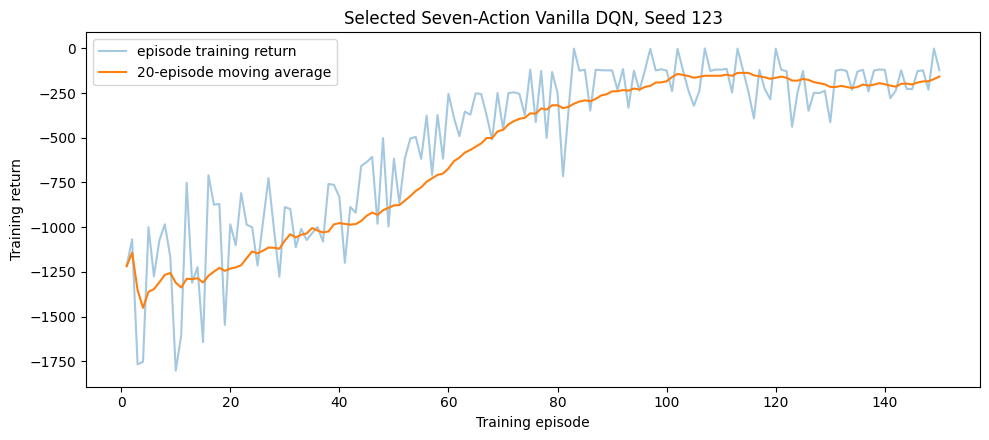

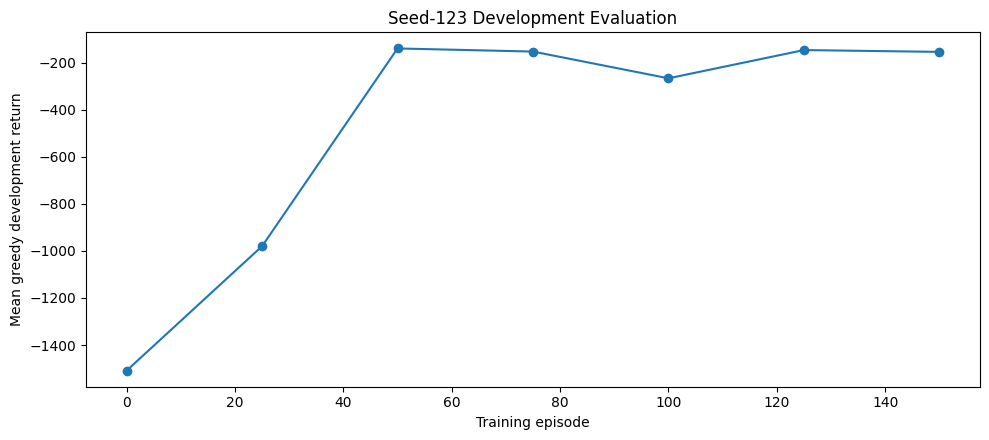

Seed-123 calibration run completed: True
Selected checkpoint episode: 50
Mean development return: -139.91177448918384
Development return standard deviation: 102.52013174679064
Upright fraction: 0.8691666666666666
Formal runs completed: 4
Remaining formal-run capacity: 24
Saved seed-123 history: histories\R30_VANILLA_SEED_123_history.csv
Saved seed-123 summary: histories\R30_VANILLA_SEED_123_summary.csv
Saved seed-123 selected weights: selected_weights\R30_VANILLA_SEED_123_best.weights.h5
Section 8.2.1 seed-123 calibration: COMPLETE


In [49]:
R30_SEED_123 = 123
R30_SEED_123_RUN_ID = "R30_VANILLA_SEED_123"

R30_SEED_123_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R30_SEED_123_RUN_ID}_best.weights.h5"
)
R30_SEED_123_HISTORY_PATH = (
    HISTORIES_DIR / f"{R30_SEED_123_RUN_ID}_history.csv"
)
R30_SEED_123_EVALUATION_PATH = (
    HISTORIES_DIR
    / f"{R30_SEED_123_RUN_ID}_development_evaluations.csv"
)
R30_SEED_123_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R30_SEED_123_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
R30_SEED_123_SUMMARY_PATH = (
    HISTORIES_DIR / f"{R30_SEED_123_RUN_ID}_summary.csv"
)
R30_SEED_123_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{R30_SEED_123_RUN_ID}"
        "_selected_state_results.csv"
    )
)

VANILLA_CALIBRATION_RESULTS = {
    42: dict(r22_summary_record),
}
VANILLA_CALIBRATION_STATE_RESULTS = {
    42: r22_selected_state_results.copy(),
}

r30_seed_123_required_artifacts = [
    R30_SEED_123_WEIGHT_PATH,
    R30_SEED_123_HISTORY_PATH,
    R30_SEED_123_EVALUATION_PATH,
    R30_SEED_123_EVALUATION_SUMMARY_PATH,
    R30_SEED_123_SUMMARY_PATH,
    R30_SEED_123_STATE_RESULTS_PATH,
]
r30_seed_123_artifacts_complete = all(
    path.exists()
    for path in r30_seed_123_required_artifacts
)

if (
    R30_SEED_123 in VANILLA_CALIBRATION_RESULTS
    and all(
        name in globals()
        for name in [
            "r30_seed_123_history",
            "r30_seed_123_evaluation_states",
            "r30_seed_123_evaluation_summary",
            "r30_seed_123_selected_state_results",
            "r30_seed_123_summary_record",
            "r30_seed_123_summary",
        ]
    )
):
    print(
        "Seed-123 calibration result already exists in memory; "
        "no duplicate training run was started."
    )
elif r30_seed_123_artifacts_complete:
    r30_seed_123_history = read_csv_with_control_metric_migration(
        R30_SEED_123_HISTORY_PATH
    )
    r30_seed_123_evaluation_states = read_csv_with_control_metric_migration(
        R30_SEED_123_EVALUATION_PATH
    )
    r30_seed_123_evaluation_summary = read_csv_with_control_metric_migration(
        R30_SEED_123_EVALUATION_SUMMARY_PATH
    )
    r30_seed_123_summary = read_csv_with_control_metric_migration(
        R30_SEED_123_SUMMARY_PATH
    )
    r30_seed_123_selected_state_results = read_csv_with_control_metric_migration(
        R30_SEED_123_STATE_RESULTS_PATH
    )

    assert len(r30_seed_123_summary) == 1
    r30_seed_123_summary_record = (
        r30_seed_123_summary.iloc[0].to_dict()
    )
    r30_seed_123_summary_record[
        "reused_existing_run"
    ] = bool(
        r30_seed_123_summary_record[
            "reused_existing_run"
        ]
    )
    r30_seed_123_summary_record[
        "new_training_run_consumed"
    ] = bool(
        r30_seed_123_summary_record[
            "new_training_run_consumed"
        ]
    )

    r30_seed_123_selected_model = (
        build_standard_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=SELECTED_ACTION_COUNT,
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r30_seed_123_reloaded_q_network"
            ),
        )
    )
    r30_seed_123_selected_model.load_weights(
        R30_SEED_123_WEIGHT_PATH
    )
    print(
        "Loaded completed seed-123 calibration artifacts; "
        "no duplicate training run was started."
    )
else:
    r30_seed_123_result = (
        run_vanilla_action_comparison(
            run_id=R30_SEED_123_RUN_ID,
            torque_values=SELECTED_TORQUE_VALUES,
            seed=R30_SEED_123,
            weight_path=R30_SEED_123_WEIGHT_PATH,
        )
    )

    r30_seed_123_history = r30_seed_123_result[
        "history"
    ]
    r30_seed_123_evaluation_states = (
        r30_seed_123_result["evaluation_states"]
    )
    r30_seed_123_evaluation_summary = (
        r30_seed_123_result["evaluation_summary"]
    )
    r30_seed_123_selected_state_results = (
        r30_seed_123_result[
            "selected_state_results"
        ]
    )
    r30_seed_123_summary_record = (
        r30_seed_123_result["summary_record"]
    )
    r30_seed_123_summary = pd.DataFrame(
        [r30_seed_123_summary_record]
    )

VANILLA_CALIBRATION_RESULTS[
    R30_SEED_123
] = r30_seed_123_summary_record
VANILLA_CALIBRATION_STATE_RESULTS[
    R30_SEED_123
] = r30_seed_123_selected_state_results.copy()

calibration_new_run_count = sum(
    int(seed != 42)
    for seed in VANILLA_CALIBRATION_RESULTS
)
FORMAL_RUNS_COMPLETED = 3 + calibration_new_run_count
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert SELECTED_ACTION_COUNT == 7
assert set(VANILLA_CALIBRATION_RESULTS.keys()) == {
    42,
    123,
}
assert FORMAL_RUNS_COMPLETED == 4
assert remaining_formal_run_capacity == 24
assert len(r30_seed_123_history) == (
    ACTION_COMPARISON_EPISODES
)
assert len(r30_seed_123_evaluation_summary) == 7
assert int(
    r30_seed_123_summary_record["seed"]
) == R30_SEED_123
assert int(
    r30_seed_123_summary_record["action_count"]
) == SELECTED_ACTION_COUNT
assert int(
    r30_seed_123_summary_record["parameter_count"]
) == 4871
assert int(
    r30_seed_123_summary_record["environment_steps"]
) == 30_000
assert int(
    r30_seed_123_summary_record["optimizer_updates"]
) == 29_001
assert np.isfinite(
    r30_seed_123_selected_state_results[
        "return"
    ].to_numpy()
).all()
assert R30_SEED_123_WEIGHT_PATH.exists()

r30_seed_123_history.to_csv(
    R30_SEED_123_HISTORY_PATH,
    index=False,
)
r30_seed_123_evaluation_states.to_csv(
    R30_SEED_123_EVALUATION_PATH,
    index=False,
)
r30_seed_123_evaluation_summary.to_csv(
    R30_SEED_123_EVALUATION_SUMMARY_PATH,
    index=False,
)
r30_seed_123_summary.to_csv(
    R30_SEED_123_SUMMARY_PATH,
    index=False,
)
r30_seed_123_selected_state_results.to_csv(
    R30_SEED_123_STATE_RESULTS_PATH,
    index=False,
)

display(r30_seed_123_evaluation_summary)
display(r30_seed_123_summary)
display(r30_seed_123_history.tail(10))

plt.figure(figsize=(10, 4.5))
plt.plot(
    r30_seed_123_history["episode"],
    r30_seed_123_history["training_return"],
    alpha=0.4,
    label="episode training return",
)
plt.plot(
    r30_seed_123_history["episode"],
    r30_seed_123_history[
        "moving_average_return"
    ],
    label=(
        f"{R10_MOVING_AVERAGE_WINDOW}-episode "
        "moving average"
    ),
)
plt.xlabel("Training episode")
plt.ylabel("Training return")
plt.title(
    "Selected Seven-Action Vanilla DQN, Seed 123"
)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(
    r30_seed_123_evaluation_summary["episode"],
    r30_seed_123_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title(
    "Seed-123 Development Evaluation"
)
plt.tight_layout()
plt.show()

print("Seed-123 calibration run completed:", True)
print(
    "Selected checkpoint episode:",
    r30_seed_123_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    r30_seed_123_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    r30_seed_123_summary_record[
        "development_return_std"
    ],
)
print(
    "Upright fraction:",
    r30_seed_123_summary_record[
        "upright_fraction"
    ],
)
print("Formal runs completed:", FORMAL_RUNS_COMPLETED)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved seed-123 history:",
    R30_SEED_123_HISTORY_PATH,
)
print(
    "Saved seed-123 summary:",
    R30_SEED_123_SUMMARY_PATH,
)
print(
    "Saved seed-123 selected weights:",
    R30_SEED_123_WEIGHT_PATH,
)
print("Section 8.2.1 seed-123 calibration: COMPLETE")


### 8.2.1 Result Interpretation

**Finding.** The seed-123 run completed all `150` episodes, `30,000`
environment steps and `29,001` optimiser updates without technical failure.
Its selected checkpoint was episode `50`, with a mean development return of
`-139.911774`, development-state standard deviation of `102.520132` and
upright fraction of `0.869167`.

The seed-123 mean return was only `0.093173` lower than the seed-42 result of
`-139.818601`. The two seeds therefore produced nearly identical primary
performance, although their control behaviour differed. Seed `123` used more
mean absolute torque (`1.839306`) and switched torque more frequently
(`0.747697`) than seed `42`, while obtaining a lower mean absolute angle
(`0.240027` versus `0.303639`).

**Importance.** The close mean returns support the viability of the selected
seven-action configuration under a second training seed. The different torque
strategies also show why one run cannot describe all learned behaviour.

**Decision.** Retain seed `123` as valid calibration evidence and continue with
seed `2026`.

**Caveat.** The run selected episode `50`; later development evaluations were
weaker, including `-266.784253` at episode `100`. This confirms that periodic
development checkpoint selection remains necessary.

**Next step.** Train the same selected Vanilla configuration using seed
`2026`, then calculate training-seed variation and the practical improvement
margin.


### 8.2.2 Seed 2026

**Question.** How much does the selected seven-action Vanilla DQN vary across
the third locked training seed?

**References.**

- seed `42`: `R22_ACTIONS_7`;
- seed `123`: `R30_VANILLA_SEED_123`.

**Primary change.** Training seed only:

```text
123 → 2026
```

All architecture, action-set, replay, exploration, optimisation, gravity,
training-budget, checkpoint and evaluation settings remain unchanged.

This is one fresh formal training run. After completion, the formal-run count
should be `5`, leaving `23` runs under the approved cap.

The result will complete the locked calibration seed set:

```text
42, 123, 2026
```


Loaded completed seed-2026 calibration artifacts; no duplicate training run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1671.771767,-1694.895999,124.849242,-1831.314660,-1462.596538,0.006042,2.804045,1.068889,1.122917,0.195980
1,25,-550.236271,-691.033444,415.297083,-1020.519866,-4.257487,0.450625,0.848927,2.513188,1.625556,0.242044
2,50,-151.153674,-125.527147,114.574806,-363.159545,-0.544067,0.852500,0.272150,0.557317,1.092222,0.617044
3,75,-176.472240,-127.165804,149.804075,-481.022340,-0.670315,0.836458,0.318314,0.601419,1.184861,0.642379
4,100,-155.945089,-124.803432,130.406166,-518.188266,-0.545392,0.860417,0.257161,0.535294,1.214861,0.791248
5,125,-156.666143,-124.944326,119.750230,-379.737416,-0.027009,0.852917,0.270932,0.530758,0.409722,0.335427
6,150,-152.362374,-124.213959,114.310266,-348.558818,-0.532038,0.859167,0.252467,0.557201,1.261667,0.768425


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,mean_abs_angular_velocity,mean_abs_torque,torque_direction_switching_rate,random_actions,greedy_actions,target_updates,runtime_minutes,parameter_count,weight_path,technical_status
0,R30_VANILLA_SEED_2026,R30_VANILLA_SEED_2026,False,True,Vanilla DQN,default,2026,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,0.557317,1.092222,0.617044,11024,18976,116,7.785649,4871,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS


,run_id,episode,environment_steps,optimizer_updates,training_return,epsilon,mean_loss,mean_gradient_global_norm,mean_q,max_q,random_actions,greedy_actions,target_updates,replay_size,episode_runtime_seconds,moving_average_return,evaluation_return
140,R30_VANILLA_SEED_2026,141,28200,27201,-123.383353,0.05,2.711414,174.524376,-101.814072,19.236629,10,190,0,10000,3.058424,-182.982303,NaN
141,R30_VANILLA_SEED_2026,142,28400,27401,-239.703032,0.05,2.806976,190.744358,-103.142845,19.002073,11,189,1,10000,2.982763,-188.691026,NaN
142,R30_VANILLA_SEED_2026,143,28600,27601,-122.271307,0.05,3.069727,188.553170,-103.091637,19.892876,7,193,1,10000,2.984819,-176.682679,NaN
143,R30_VANILLA_SEED_2026,144,28800,27801,-1.485401,0.05,2.763189,173.066829,-103.302139,20.502392,9,191,1,10000,2.984527,-158.101664,NaN
144,R30_VANILLA_SEED_2026,145,29000,28001,-0.790284,0.05,3.160736,205.437590,-102.645279,21.092354,7,193,1,10000,2.972249,-144.423959,NaN
145,R30_VANILLA_SEED_2026,146,29200,28201,-570.302897,0.05,3.209406,202.191378,-102.452797,22.013374,7,193,0,10000,2.982420,-160.911597,NaN
146,R30_VANILLA_SEED_2026,147,29400,28401,-365.367516,0.05,3.514484,215.026722,-102.911377,21.987919,11,189,1,10000,3.002577,-173.028491,NaN
147,R30_VANILLA_SEED_2026,148,29600,28601,-125.071011,0.05,3.455176,215.007749,-102.453323,24.921879,7,193,1,10000,2.980090,-173.310190,NaN
148,R30_VANILLA_SEED_2026,149,29800,28801,-343.769064,0.05,2.916600,199.805501,-104.214287,22.075363,13,187,1,10000,2.949343,-177.616017,NaN
149,R30_VANILLA_SEED_2026,150,30000,29001,-236.439649,0.05,3.727978,231.865792,-103.060921,21.899239,10,190,1,10000,2.958517,-183.629446,-152.362374


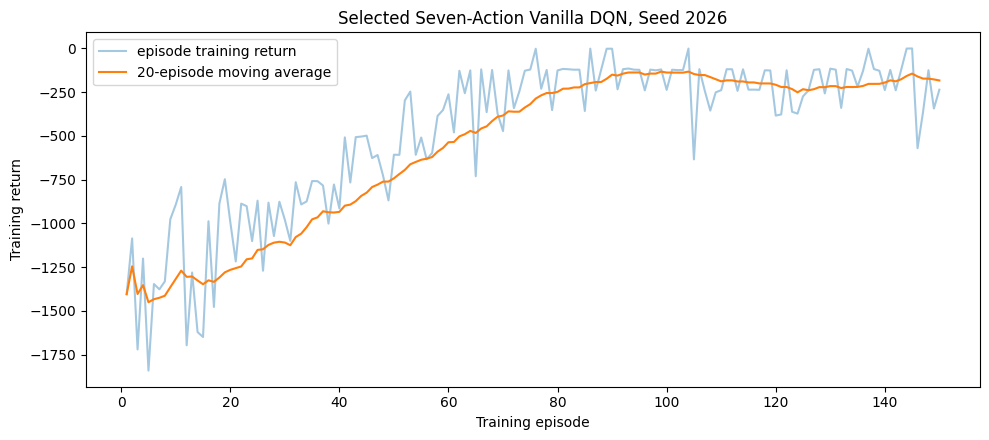

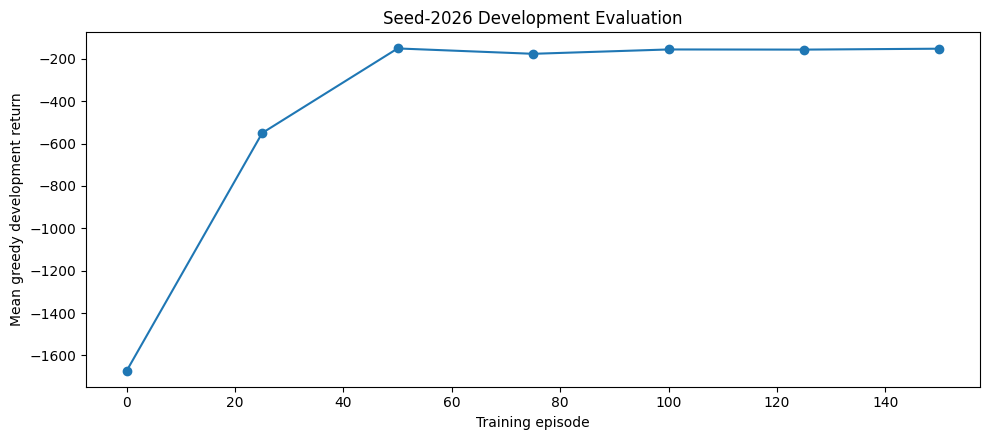

Seed-2026 calibration run completed: True
Selected checkpoint episode: 50
Mean development return: -151.1536735820101
Development return standard deviation: 114.5748062516366
Upright fraction: 0.8525
Formal runs completed: 5
Remaining formal-run capacity: 23
Saved seed-2026 history: histories\R30_VANILLA_SEED_2026_history.csv
Saved seed-2026 summary: histories\R30_VANILLA_SEED_2026_summary.csv
Saved seed-2026 selected weights: selected_weights\R30_VANILLA_SEED_2026_best.weights.h5
Section 8.2.2 seed-2026 calibration: COMPLETE


In [50]:
R30_SEED_2026 = 2026
R30_SEED_2026_RUN_ID = "R30_VANILLA_SEED_2026"

R30_SEED_2026_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R30_SEED_2026_RUN_ID}_best.weights.h5"
)
R30_SEED_2026_HISTORY_PATH = (
    HISTORIES_DIR / f"{R30_SEED_2026_RUN_ID}_history.csv"
)
R30_SEED_2026_EVALUATION_PATH = (
    HISTORIES_DIR
    / f"{R30_SEED_2026_RUN_ID}_development_evaluations.csv"
)
R30_SEED_2026_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R30_SEED_2026_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
R30_SEED_2026_SUMMARY_PATH = (
    HISTORIES_DIR / f"{R30_SEED_2026_RUN_ID}_summary.csv"
)
R30_SEED_2026_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{R30_SEED_2026_RUN_ID}"
        "_selected_state_results.csv"
    )
)

assert SELECTED_ACTION_SET_LOCKED is True
assert SELECTED_ACTION_COUNT == 7
assert set(VANILLA_CALIBRATION_RESULTS.keys()) == {
    42,
    123,
}
assert FORMAL_RUNS_COMPLETED == 4
assert remaining_formal_run_capacity == 24

r30_seed_2026_required_artifacts = [
    R30_SEED_2026_WEIGHT_PATH,
    R30_SEED_2026_HISTORY_PATH,
    R30_SEED_2026_EVALUATION_PATH,
    R30_SEED_2026_EVALUATION_SUMMARY_PATH,
    R30_SEED_2026_SUMMARY_PATH,
    R30_SEED_2026_STATE_RESULTS_PATH,
]
r30_seed_2026_artifacts_complete = all(
    path.exists()
    for path in r30_seed_2026_required_artifacts
)

if (
    R30_SEED_2026 in VANILLA_CALIBRATION_RESULTS
    and all(
        name in globals()
        for name in [
            "r30_seed_2026_history",
            "r30_seed_2026_evaluation_states",
            "r30_seed_2026_evaluation_summary",
            "r30_seed_2026_selected_state_results",
            "r30_seed_2026_summary_record",
            "r30_seed_2026_summary",
        ]
    )
):
    print(
        "Seed-2026 calibration result already exists in memory; "
        "no duplicate training run was started."
    )
elif r30_seed_2026_artifacts_complete:
    r30_seed_2026_history = read_csv_with_control_metric_migration(
        R30_SEED_2026_HISTORY_PATH
    )
    r30_seed_2026_evaluation_states = read_csv_with_control_metric_migration(
        R30_SEED_2026_EVALUATION_PATH
    )
    r30_seed_2026_evaluation_summary = read_csv_with_control_metric_migration(
        R30_SEED_2026_EVALUATION_SUMMARY_PATH
    )
    r30_seed_2026_summary = read_csv_with_control_metric_migration(
        R30_SEED_2026_SUMMARY_PATH
    )
    r30_seed_2026_selected_state_results = read_csv_with_control_metric_migration(
        R30_SEED_2026_STATE_RESULTS_PATH
    )

    assert len(r30_seed_2026_summary) == 1
    r30_seed_2026_summary_record = (
        r30_seed_2026_summary.iloc[0].to_dict()
    )

    r30_seed_2026_selected_model = (
        build_standard_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=SELECTED_ACTION_COUNT,
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r30_seed_2026_reloaded_q_network"
            ),
        )
    )
    r30_seed_2026_selected_model.load_weights(
        R30_SEED_2026_WEIGHT_PATH
    )
    print(
        "Loaded completed seed-2026 calibration artifacts; "
        "no duplicate training run was started."
    )
else:
    r30_seed_2026_result = (
        run_vanilla_action_comparison(
            run_id=R30_SEED_2026_RUN_ID,
            torque_values=SELECTED_TORQUE_VALUES,
            seed=R30_SEED_2026,
            weight_path=R30_SEED_2026_WEIGHT_PATH,
        )
    )

    r30_seed_2026_history = r30_seed_2026_result[
        "history"
    ]
    r30_seed_2026_evaluation_states = (
        r30_seed_2026_result["evaluation_states"]
    )
    r30_seed_2026_evaluation_summary = (
        r30_seed_2026_result["evaluation_summary"]
    )
    r30_seed_2026_selected_state_results = (
        r30_seed_2026_result[
            "selected_state_results"
        ]
    )
    r30_seed_2026_summary_record = (
        r30_seed_2026_result["summary_record"]
    )
    r30_seed_2026_summary = pd.DataFrame(
        [r30_seed_2026_summary_record]
    )

VANILLA_CALIBRATION_RESULTS[
    R30_SEED_2026
] = r30_seed_2026_summary_record
VANILLA_CALIBRATION_STATE_RESULTS[
    R30_SEED_2026
] = r30_seed_2026_selected_state_results.copy()

calibration_new_run_count = sum(
    int(seed != 42)
    for seed in VANILLA_CALIBRATION_RESULTS
)
FORMAL_RUNS_COMPLETED = 3 + calibration_new_run_count
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert set(VANILLA_CALIBRATION_RESULTS.keys()) == {
    42,
    123,
    2026,
}
assert FORMAL_RUNS_COMPLETED == 5
assert remaining_formal_run_capacity == 23
assert len(r30_seed_2026_history) == (
    ACTION_COMPARISON_EPISODES
)
assert len(r30_seed_2026_evaluation_summary) == 7
assert int(
    r30_seed_2026_summary_record["seed"]
) == R30_SEED_2026
assert int(
    r30_seed_2026_summary_record["action_count"]
) == SELECTED_ACTION_COUNT
assert int(
    r30_seed_2026_summary_record["parameter_count"]
) == 4871
assert int(
    r30_seed_2026_summary_record["environment_steps"]
) == 30_000
assert int(
    r30_seed_2026_summary_record["optimizer_updates"]
) == 29_001
assert np.isfinite(
    r30_seed_2026_selected_state_results[
        "return"
    ].to_numpy()
).all()
assert R30_SEED_2026_WEIGHT_PATH.exists()

r30_seed_2026_history.to_csv(
    R30_SEED_2026_HISTORY_PATH,
    index=False,
)
r30_seed_2026_evaluation_states.to_csv(
    R30_SEED_2026_EVALUATION_PATH,
    index=False,
)
r30_seed_2026_evaluation_summary.to_csv(
    R30_SEED_2026_EVALUATION_SUMMARY_PATH,
    index=False,
)
r30_seed_2026_summary.to_csv(
    R30_SEED_2026_SUMMARY_PATH,
    index=False,
)
r30_seed_2026_selected_state_results.to_csv(
    R30_SEED_2026_STATE_RESULTS_PATH,
    index=False,
)

display(r30_seed_2026_evaluation_summary)
display(r30_seed_2026_summary)
display(r30_seed_2026_history.tail(10))

plt.figure(figsize=(10, 4.5))
plt.plot(
    r30_seed_2026_history["episode"],
    r30_seed_2026_history["training_return"],
    alpha=0.4,
    label="episode training return",
)
plt.plot(
    r30_seed_2026_history["episode"],
    r30_seed_2026_history[
        "moving_average_return"
    ],
    label=(
        f"{R10_MOVING_AVERAGE_WINDOW}-episode "
        "moving average"
    ),
)
plt.xlabel("Training episode")
plt.ylabel("Training return")
plt.title(
    "Selected Seven-Action Vanilla DQN, Seed 2026"
)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(
    r30_seed_2026_evaluation_summary["episode"],
    r30_seed_2026_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title(
    "Seed-2026 Development Evaluation"
)
plt.tight_layout()
plt.show()

print("Seed-2026 calibration run completed:", True)
print(
    "Selected checkpoint episode:",
    r30_seed_2026_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    r30_seed_2026_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    r30_seed_2026_summary_record[
        "development_return_std"
    ],
)
print(
    "Upright fraction:",
    r30_seed_2026_summary_record[
        "upright_fraction"
    ],
)
print("Formal runs completed:", FORMAL_RUNS_COMPLETED)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved seed-2026 history:",
    R30_SEED_2026_HISTORY_PATH,
)
print(
    "Saved seed-2026 summary:",
    R30_SEED_2026_SUMMARY_PATH,
)
print(
    "Saved seed-2026 selected weights:",
    R30_SEED_2026_WEIGHT_PATH,
)
print("Section 8.2.2 seed-2026 calibration: COMPLETE")


### 8.2.2 Result Interpretation

**Finding.** The seed-2026 run completed all `150` episodes, `30,000`
environment steps and `29,001` optimiser updates without technical failure.
Its selected checkpoint was episode `50`, with a mean development return of
`-151.153674`, development-state standard deviation of `114.574806` and
upright fraction of `0.852500`.

Compared with the other selected seven-action runs:

- seed `42`: `-139.818601`;
- seed `123`: `-139.911774`;
- seed `2026`: `-151.153674`.

Seed `2026` was `11.335072` below seed `42` and `11.241899` below seed `123`
on the primary metric. It still produced meaningful control, with mean
absolute angle `0.272150`, mean absolute angular velocity `0.557317`, mean
absolute torque `1.092222` and torque-direction switching rate `0.617044`.

**Importance.** The model remained viable, but the lower seed-2026 result
shows measurable run-to-run variation. A single seed would therefore
understate uncertainty in later model comparisons.

**Decision.** Retain seed `2026` as valid calibration evidence. Do not discard
or rerun it merely because it is weaker.

**Caveat.** All three seeds selected checkpoints before the end of training,
and seed `2026` selected episode `50`. This supports periodic greedy
development evaluation rather than automatically keeping episode `150`.

**Next step.** Summarise the three seed-level results, paired state behaviour,
sample-efficiency variation and the practical improvement margin.


## 8.3 Run-to-Run Variation

This subsection combines the completed seed `42`, `123` and `2026` runs.

The analysis keeps two types of variation separate:

- development-state standard deviation within each trained seed;
- variation among the three seed-level mean development returns.

It also compares seeds `123` and `2026` against seed `42` on the same `24`
development states. These paired comparisons describe where independently
trained policies differ, but they do not replace the seed-level variation
measure.

The practical improvement margin is calculated as:

```text
maximum seed-level mean return
-
minimum seed-level mean return
```

This range is a conservative project heuristic only. It is not a statistical
significance threshold.


,seed,selected_checkpoint_episode,mean_development_return,development_state_std,upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,torque_direction_switching_rate,first_episode_above_reference_target,runtime_minutes,parameter_count,technical_status
0,42,100,-139.818601,101.098652,0.872292,0.303639,0.509886,0.642361,0.451214,25,11.902179,4871,PASS
1,123,50,-139.911774,102.520132,0.869167,0.240027,0.574379,1.839306,0.747697,25,11.570283,4871,PASS
2,2026,50,-151.153674,114.574806,0.852500,0.272150,0.557317,1.092222,0.617044,25,7.785649,4871,PASS


,reference_seed,candidate_seed,paired_state_count,mean_return_difference,median_return_difference,candidate_win_proportion,seed_42_win_proportion,exact_tie_proportion,minimum_paired_difference,maximum_paired_difference
0,42,123,24,-0.093173,0.713310,0.625,0.375,0.0,-16.319005,19.081830
1,42,2026,24,-11.335072,-0.580368,0.500,0.500,0.0,-123.297742,10.551073


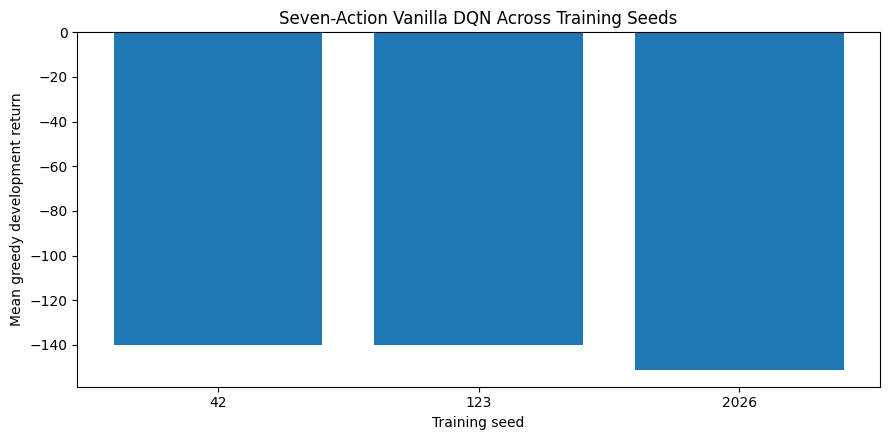

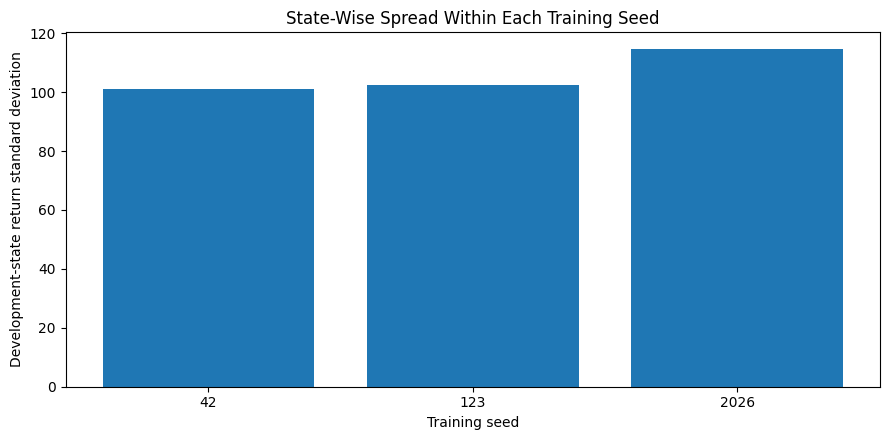

Calibration seed-level mean returns: [-139.81860126694502, -139.91177448918384, -151.1536735820101]
Mean across seed-level returns: -143.62801644604633
Training-seed return standard deviation: 6.5175767589187235
Practical improvement margin: 11.335072315065077
Failed valid-run count: 0
First reference-threshold episodes: [25, 25, 25]
Formal runs completed: 5
Remaining formal-run capacity: 23
Saved calibration summary: histories\R30_vanilla_seed_calibration_summary.csv
Saved paired seed comparisons: histories\R30_vanilla_seed_paired_comparisons.csv
Section 8.3 run-to-run variation: PASS


In [51]:
VANILLA_CALIBRATION_SUMMARY_PATH = (
    HISTORIES_DIR / "R30_vanilla_seed_calibration_summary.csv"
)
VANILLA_CALIBRATION_PAIRED_PATH = (
    HISTORIES_DIR / "R30_vanilla_seed_paired_comparisons.csv"
)

CALIBRATION_SEEDS = (42, 123, 2026)

assert SELECTED_ACTION_SET_LOCKED is True
assert SELECTED_ACTION_COUNT == 7
assert tuple(sorted(VANILLA_CALIBRATION_RESULTS.keys())) == (
    CALIBRATION_SEEDS
)
assert tuple(
    sorted(VANILLA_CALIBRATION_STATE_RESULTS.keys())
) == CALIBRATION_SEEDS
assert FORMAL_RUNS_COMPLETED == 5
assert remaining_formal_run_capacity == 23

evaluation_summaries_by_seed = {
    42: r22_evaluation_summary.copy(),
    123: r30_seed_123_evaluation_summary.copy(),
    2026: r30_seed_2026_evaluation_summary.copy(),
}

calibration_records = []

for seed in CALIBRATION_SEEDS:
    record = VANILLA_CALIBRATION_RESULTS[seed]
    evaluation_summary = evaluation_summaries_by_seed[
        seed
    ].copy()

    threshold_rows = evaluation_summary.loc[
        evaluation_summary["mean_development_return"]
        >= provisional_default_reference_target
    ]
    first_reference_threshold_episode = (
        int(threshold_rows["episode"].iloc[0])
        if len(threshold_rows) > 0
        else np.nan
    )

    calibration_records.append({
        "seed": int(seed),
        "selected_checkpoint_episode": int(
            record["selected_checkpoint_episode"]
        ),
        "mean_development_return": float(
            record["mean_development_return"]
        ),
        "development_state_std": float(
            record["development_return_std"]
        ),
        "upright_fraction": float(
            record["upright_fraction"]
        ),
        "mean_abs_angle": float(
            record["mean_abs_angle"]
        ),
        "mean_abs_angular_velocity": float(
            record["mean_abs_angular_velocity"]
        ),
        "mean_abs_torque": float(
            record["mean_abs_torque"]
        ),
        "torque_direction_switching_rate": float(
            record["torque_direction_switching_rate"]
        ),
        "first_episode_above_reference_target": (
            first_reference_threshold_episode
        ),
        "runtime_minutes": float(
            record["runtime_minutes"]
        ),
        "parameter_count": int(
            record["parameter_count"]
        ),
        "technical_status": record["technical_status"],
    })

vanilla_seed_calibration_summary = pd.DataFrame(
    calibration_records
).sort_values("seed").reset_index(drop=True)

seed_level_mean_returns = (
    vanilla_seed_calibration_summary[
        "mean_development_return"
    ].to_numpy(dtype=np.float64)
)

VANILLA_SEED_MEAN_RETURN = float(
    np.mean(seed_level_mean_returns)
)
VANILLA_SEED_RETURN_STD = float(
    np.std(seed_level_mean_returns, ddof=1)
)
PRACTICAL_IMPROVEMENT_MARGIN = float(
    np.max(seed_level_mean_returns)
    - np.min(seed_level_mean_returns)
)
VANILLA_SEED_RETURN_MINIMUM = float(
    np.min(seed_level_mean_returns)
)
VANILLA_SEED_RETURN_MAXIMUM = float(
    np.max(seed_level_mean_returns)
)
VANILLA_FAILED_RUN_COUNT = int(
    (
        vanilla_seed_calibration_summary[
            "technical_status"
        ] != "PASS"
    ).sum()
)
VANILLA_FAILED_RUN_FREQUENCY = float(
    VANILLA_FAILED_RUN_COUNT
    / len(vanilla_seed_calibration_summary)
)

assert len(vanilla_seed_calibration_summary) == 3
assert (
    vanilla_seed_calibration_summary[
        "technical_status"
    ] == "PASS"
).all()
assert np.isfinite(seed_level_mean_returns).all()
assert np.isfinite(VANILLA_SEED_MEAN_RETURN)
assert np.isfinite(VANILLA_SEED_RETURN_STD)
assert PRACTICAL_IMPROVEMENT_MARGIN > 0.0
assert VANILLA_FAILED_RUN_COUNT == 0
assert VANILLA_FAILED_RUN_FREQUENCY == 0.0
assert (
    vanilla_seed_calibration_summary[
        "parameter_count"
    ] == 4871
).all()
assert (
    vanilla_seed_calibration_summary[
        "first_episode_above_reference_target"
    ] == 25
).all()

seed_42_states = (
    VANILLA_CALIBRATION_STATE_RESULTS[42]
    [["state_id", "return"]]
    .rename(columns={"return": "seed_42_return"})
    .sort_values("state_id")
    .reset_index(drop=True)
)

paired_seed_records = []

for candidate_seed in (123, 2026):
    candidate_states = (
        VANILLA_CALIBRATION_STATE_RESULTS[
            candidate_seed
        ]
        [["state_id", "return"]]
        .rename(
            columns={
                "return": "candidate_seed_return"
            }
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )

    paired = seed_42_states.merge(
        candidate_states,
        on="state_id",
        how="inner",
        validate="one_to_one",
    )
    assert len(paired) == len(
        DEVELOPMENT_PHYSICAL_STATES
    )

    paired["candidate_minus_seed_42"] = (
        paired["candidate_seed_return"]
        - paired["seed_42_return"]
    )

    paired_seed_records.append({
        "reference_seed": 42,
        "candidate_seed": int(candidate_seed),
        "paired_state_count": int(len(paired)),
        "mean_return_difference": float(
            paired["candidate_minus_seed_42"].mean()
        ),
        "median_return_difference": float(
            paired["candidate_minus_seed_42"].median()
        ),
        "candidate_win_proportion": float(
            (
                paired["candidate_minus_seed_42"] > 0.0
            ).mean()
        ),
        "seed_42_win_proportion": float(
            (
                paired["candidate_minus_seed_42"] < 0.0
            ).mean()
        ),
        "exact_tie_proportion": float(
            np.isclose(
                paired["candidate_minus_seed_42"],
                0.0,
                rtol=0.0,
                atol=1e-10,
            ).mean()
        ),
        "minimum_paired_difference": float(
            paired["candidate_minus_seed_42"].min()
        ),
        "maximum_paired_difference": float(
            paired["candidate_minus_seed_42"].max()
        ),
    })

vanilla_seed_paired_comparisons = pd.DataFrame(
    paired_seed_records
)

assert len(vanilla_seed_paired_comparisons) == 2
assert (
    vanilla_seed_paired_comparisons[
        "paired_state_count"
    ] == len(DEVELOPMENT_PHYSICAL_STATES)
).all()
assert np.isfinite(
    vanilla_seed_paired_comparisons.drop(
        columns=[
            "reference_seed",
            "candidate_seed",
            "paired_state_count",
        ]
    ).to_numpy(dtype=np.float64)
).all()

vanilla_seed_calibration_summary.to_csv(
    VANILLA_CALIBRATION_SUMMARY_PATH,
    index=False,
)
vanilla_seed_paired_comparisons.to_csv(
    VANILLA_CALIBRATION_PAIRED_PATH,
    index=False,
)

display(vanilla_seed_calibration_summary)
display(vanilla_seed_paired_comparisons)

plt.figure(figsize=(9, 4.5))
plt.bar(
    vanilla_seed_calibration_summary[
        "seed"
    ].astype(str),
    vanilla_seed_calibration_summary[
        "mean_development_return"
    ],
)
plt.xlabel("Training seed")
plt.ylabel("Mean greedy development return")
plt.title("Seven-Action Vanilla DQN Across Training Seeds")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.5))
plt.bar(
    vanilla_seed_calibration_summary[
        "seed"
    ].astype(str),
    vanilla_seed_calibration_summary[
        "development_state_std"
    ],
)
plt.xlabel("Training seed")
plt.ylabel("Development-state return standard deviation")
plt.title("State-Wise Spread Within Each Training Seed")
plt.tight_layout()
plt.show()

print(
    "Calibration seed-level mean returns:",
    seed_level_mean_returns.tolist(),
)
print(
    "Mean across seed-level returns:",
    VANILLA_SEED_MEAN_RETURN,
)
print(
    "Training-seed return standard deviation:",
    VANILLA_SEED_RETURN_STD,
)
print(
    "Practical improvement margin:",
    PRACTICAL_IMPROVEMENT_MARGIN,
)
print(
    "Failed valid-run count:",
    VANILLA_FAILED_RUN_COUNT,
)
print(
    "First reference-threshold episodes:",
    vanilla_seed_calibration_summary[
        "first_episode_above_reference_target"
    ].tolist(),
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved calibration summary:",
    VANILLA_CALIBRATION_SUMMARY_PATH,
)
print(
    "Saved paired seed comparisons:",
    VANILLA_CALIBRATION_PAIRED_PATH,
)
print("Section 8.3 run-to-run variation: PASS")


### 8.3 Result Interpretation

**Finding.** All three seven-action Vanilla DQN runs completed successfully.
Their seed-level mean development returns were:

- seed `42`: `-139.818601`;
- seed `123`: `-139.911774`;
- seed `2026`: `-151.153674`.

The mean across the three seed-level results was `-143.628016`, with a
training-seed standard deviation of `6.517577`. The observed seed-level range
was `11.335072`.

All three runs first exceeded the provisional default-gravity reference target
at episode `25`, and none failed technically. Their selected checkpoints were
episode `100` for seed `42` and episode `50` for seeds `123` and `2026`.

The paired state evidence also differed by seed. Seed `123` was only
`0.093173` below seed `42` on mean return and won on `62.5%` of development
states. Seed `2026` was `11.335072` below seed `42` and split state wins evenly
at `50%`.

**Importance.** The selected configuration was viable under every calibration
seed, but its final performance and checkpoint timing varied. One training run
is therefore insufficient for judging small improvements.

**Decision.** Use the observed range of `11.335072` as the conservative
practical-improvement margin for later matched comparisons.

**Caveat.** This range is a project decision heuristic based on three seeds.
It is not a confidence interval or statistical-significance threshold.

**Next step.** Lock the practical margin and the repeat policy before the
foundation-model screen.


## 8.4 Practical Improvement Margin

The practical improvement margin is locked from the three seed-level mean
development returns:

```text
max(-139.818601, -139.911774, -151.153674)
-
min(-139.818601, -139.911774, -151.153674)
=
11.335072
```

For a direct candidate-versus-reference decision:

- differences no larger than this margin are treated as practically close;
- close results require matched-seed confirmation before selection;
- the same additional seed set must be applied to both candidate and
  reference;
- state-wise standard deviation is not substituted for training-seed
  variation;
- no formal statistical-significance claim is made.


In [52]:
PRACTICAL_IMPROVEMENT_MARGIN_LOCKED = True
PRACTICAL_IMPROVEMENT_MARGIN_SOURCE = (
    "Range of seed-level mean development returns "
    "for Vanilla DQN seeds 42, 123 and 2026"
)
PRACTICAL_IMPROVEMENT_MARGIN_PATH = (
    HISTORIES_DIR / "R30_practical_improvement_margin.csv"
)

practical_margin_record = {
    "calibration_seeds": list(CALIBRATION_SEEDS),
    "seed_level_mean_returns": (
        seed_level_mean_returns.tolist()
    ),
    "minimum_seed_mean_return": (
        VANILLA_SEED_RETURN_MINIMUM
    ),
    "maximum_seed_mean_return": (
        VANILLA_SEED_RETURN_MAXIMUM
    ),
    "mean_across_seed_returns": (
        VANILLA_SEED_MEAN_RETURN
    ),
    "training_seed_return_std": (
        VANILLA_SEED_RETURN_STD
    ),
    "practical_improvement_margin": (
        PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "margin_rule": (
        "Candidate-reference differences less than or "
        "equal to the margin are practically close and "
        "require matched-seed confirmation."
    ),
    "formal_significance_claim": False,
    "status": "LOCKED",
}

practical_margin_summary = pd.DataFrame(
    [practical_margin_record]
)

assert PRACTICAL_IMPROVEMENT_MARGIN_LOCKED is True
assert tuple(CALIBRATION_SEEDS) == (42, 123, 2026)
assert np.isclose(
    PRACTICAL_IMPROVEMENT_MARGIN,
    VANILLA_SEED_RETURN_MAXIMUM
    - VANILLA_SEED_RETURN_MINIMUM,
    rtol=0.0,
    atol=1e-12,
)
assert PRACTICAL_IMPROVEMENT_MARGIN > 0.0
assert practical_margin_record[
    "formal_significance_claim"
] is False
assert FORMAL_RUNS_COMPLETED == 5
assert remaining_formal_run_capacity == 23

practical_margin_summary.to_csv(
    PRACTICAL_IMPROVEMENT_MARGIN_PATH,
    index=False,
)

display(practical_margin_summary)

print(
    "Locked practical improvement margin:",
    PRACTICAL_IMPROVEMENT_MARGIN,
)
print(
    "Training-seed return standard deviation:",
    VANILLA_SEED_RETURN_STD,
)
print(
    "Formal significance claim:",
    False,
)
print(
    "Saved practical-margin record:",
    PRACTICAL_IMPROVEMENT_MARGIN_PATH,
)
print("Section 8.4 practical improvement margin: PASS")


,calibration_seeds,seed_level_mean_returns,minimum_seed_mean_return,maximum_seed_mean_return,mean_across_seed_returns,training_seed_return_std,practical_improvement_margin,margin_rule,formal_significance_claim,status
0,"[42, 123, 2026]","[-139.81860126694502, -139.91177448918384, -15...",-151.153674,-139.818601,-143.628016,6.517577,11.335072,Candidate-reference differences less than or e...,False,LOCKED


Locked practical improvement margin: 11.335072315065077
Training-seed return standard deviation: 6.5175767589187235
Formal significance claim: False
Saved practical-margin record: histories\R30_practical_improvement_margin.csv
Section 8.4 practical improvement margin: PASS


## 8.5 Locked Repeat Policy

The repeat policy is now locked.

### Screening

Use seed `42` for each candidate and its reference under identical conditions.
One seed is sufficient only for bounded initial screening.

### Confirmation

Run matched confirmation seeds on both candidate and reference when:

- the direct return difference is within `11.335072`;
- policies trade wins across fixed states;
- a valid run collapses or behaves suspiciously;
- the result would change the selected architecture or recipe.

Never add a seed to only one side of a direct comparison.

### Final confirmation

Train the final selected default-gravity setup under three fresh seeds before
freeze. These final runs do not replace the fresh matched post-freeze gravity
runs.

### Gravity stage

Begin with one fresh matched run per gravity. Add a second gravity seed only
when instability could change the gravity conclusion and the protected budget
allows it.

### Reporting

Retain weak but technically valid runs. Report state-wise spread separately
from variation among seed-level mean returns.


In [53]:
REPEAT_POLICY_LOCKED = True
LOCKED_SCREENING_SEED = 42
LOCKED_VANILLA_CALIBRATION_SEEDS = (42, 123, 2026)
LOCKED_FOUNDATION_CONFIRMATION_SEED = 123
LOCKED_FINAL_CONFIRMATION_RUNS = 3
LOCKED_INITIAL_GRAVITY_RUNS = 4

REPEAT_POLICY_PATH = (
    HISTORIES_DIR / "R30_locked_repeat_policy.csv"
)

repeat_policy_records = [
    {
        "stage": "Initial screening",
        "seed_policy": "Seed 42 for candidate and reference",
        "minimum_runs": 1,
        "confirmation_trigger": (
            "Difference within practical margin, mixed "
            "paired wins, instability or decision-changing result"
        ),
        "matched_seed_requirement": True,
    },
    {
        "stage": "Vanilla calibration",
        "seed_policy": "Seeds 42, 123 and 2026",
        "minimum_runs": 3,
        "confirmation_trigger": "Required calibration stage",
        "matched_seed_requirement": True,
    },
    {
        "stage": "Foundation confirmation",
        "seed_policy": (
            "Apply seed 123 to both candidate and reference"
        ),
        "minimum_runs": 2,
        "confirmation_trigger": (
            "Candidate-reference difference is within "
            "the practical margin or unstable"
        ),
        "matched_seed_requirement": True,
    },
    {
        "stage": "Final selected setup",
        "seed_policy": "Three fresh default-gravity seeds",
        "minimum_runs": LOCKED_FINAL_CONFIRMATION_RUNS,
        "confirmation_trigger": "Required before freeze",
        "matched_seed_requirement": True,
    },
    {
        "stage": "Matched gravity training",
        "seed_policy": "One fresh matched run per gravity initially",
        "minimum_runs": LOCKED_INITIAL_GRAVITY_RUNS,
        "confirmation_trigger": (
            "Second seed only when instability could "
            "change a gravity conclusion"
        ),
        "matched_seed_requirement": True,
    },
]

repeat_policy_summary = pd.DataFrame(
    repeat_policy_records
)

assert REPEAT_POLICY_LOCKED is True
assert LOCKED_SCREENING_SEED == 42
assert LOCKED_VANILLA_CALIBRATION_SEEDS == (
    42,
    123,
    2026,
)
assert LOCKED_FOUNDATION_CONFIRMATION_SEED == 123
assert LOCKED_FINAL_CONFIRMATION_RUNS == 3
assert LOCKED_INITIAL_GRAVITY_RUNS == 4
assert repeat_policy_summary[
    "matched_seed_requirement"
].all()
assert PRACTICAL_IMPROVEMENT_MARGIN_LOCKED is True
assert FORMAL_RUNS_COMPLETED == 5
assert remaining_formal_run_capacity == 23

repeat_policy_summary.to_csv(
    REPEAT_POLICY_PATH,
    index=False,
)

display(repeat_policy_summary)

print("Locked screening seed:", LOCKED_SCREENING_SEED)
print(
    "Locked Vanilla calibration seeds:",
    LOCKED_VANILLA_CALIBRATION_SEEDS,
)
print(
    "Locked practical improvement margin:",
    PRACTICAL_IMPROVEMENT_MARGIN,
)
print(
    "Locked final confirmation runs:",
    LOCKED_FINAL_CONFIRMATION_RUNS,
)
print(
    "Initial matched gravity runs:",
    LOCKED_INITIAL_GRAVITY_RUNS,
)
print("Formal runs completed:", FORMAL_RUNS_COMPLETED)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print("Saved repeat policy:", REPEAT_POLICY_PATH)
print("Section 8.5 locked repeat policy: PASS")


,stage,seed_policy,minimum_runs,confirmation_trigger,matched_seed_requirement
0,Initial screening,Seed 42 for candidate and reference,1,"Difference within practical margin, mixed pair...",True
1,Vanilla calibration,"Seeds 42, 123 and 2026",3,Required calibration stage,True
2,Foundation confirmation,Apply seed 123 to both candidate and reference,2,Candidate-reference difference is within the p...,True
3,Final selected setup,Three fresh default-gravity seeds,3,Required before freeze,True
4,Matched gravity training,One fresh matched run per gravity initially,4,Second seed only when instability could change...,True


Locked screening seed: 42
Locked Vanilla calibration seeds: (42, 123, 2026)
Locked practical improvement margin: 11.335072315065077
Locked final confirmation runs: 3
Initial matched gravity runs: 4
Formal runs completed: 5
Remaining formal-run capacity: 23
Saved repeat policy: histories\R30_locked_repeat_policy.csv
Section 8.5 locked repeat policy: PASS


### 8.5 Calibration Gate Interpretation

**Finding.** The practical improvement margin was locked at `11.335072`, and
the repeat policy was saved successfully. Screening uses seed `42`, Vanilla
calibration uses seeds `42`, `123` and `2026`, final confirmation requires
three fresh seeds, and the gravity stage begins with one fresh matched run per
gravity.

**Decision.** Section 8 is complete. Later candidate-reference differences no
larger than `11.335072` are treated as practically close and require matched
confirmation rather than an immediate winner claim.

**Caveat.** The margin is a conservative three-seed project heuristic, not a
formal significance test.

**Next step.** Regenerate the formal random and untrained references using the
selected seven-action set before beginning the foundation-model screen.


## 8.6 Deferred Formal Reference Regeneration

**Question.** What performance do random and untrained policies achieve when
they use the selected seven-action representation under each required gravity?

**Reason.** The earlier references used the provisional three-action set.
They cannot support formal conclusions after seven actions were selected.

**Policies.**

- reproducible random seven-action policy;
- reproducibly initialised untrained `64 → 64 → 7` greedy Q-network.

**Gravities.**

```text
default, g = 0, g = -10, g = 15
```

**Controlled factors.**

- the same `24` development physical states;
- the same `200`-step evaluation horizon;
- random base seed `42`;
- untrained-network seed `42`;
- identical random action streams across gravities;
- one identical untrained network across gravities;
- greedy direct tensor calls with `training=False`;
- no replay writes and no training.

**Run-budget effect.** No formal training run is consumed.

**Required output.** Eight state-level result files and one combined formal
reference summary.


In [54]:
FORMAL_REFERENCE_RANDOM_SEED = 42
FORMAL_REFERENCE_UNTRAINED_SEED = 42

FORMAL_REFERENCE_SUMMARY_PATH = (
    HISTORIES_DIR / "R00_R01_FORMAL_REFERENCE_SUMMARY.csv"
)

FORMAL_REFERENCE_RUN_IDS = {
    "default": {
        "random": "R00_RANDOM_DEFAULT",
        "untrained": "R01_UNTRAINED_DEFAULT",
    },
    "g0": {
        "random": "R00_RANDOM_G0",
        "untrained": "R01_UNTRAINED_G0",
    },
    "g_neg10": {
        "random": "R00_RANDOM_GNEG10",
        "untrained": "R01_UNTRAINED_GNEG10",
    },
    "g15": {
        "random": "R00_RANDOM_G15",
        "untrained": "R01_UNTRAINED_G15",
    },
}

assert SELECTED_ACTION_SET_LOCKED is True
assert SELECTED_ACTION_COUNT == 7
assert len(SELECTED_TORQUE_VALUES) == 7
assert np.array_equal(
    SELECTED_TORQUE_VALUES,
    np.linspace(-2.0, 2.0, 7, dtype=np.float32),
)
assert REPEAT_POLICY_LOCKED is True
assert FORMAL_RUNS_COMPLETED == 5
assert remaining_formal_run_capacity == 23

tf.keras.utils.set_random_seed(
    FORMAL_REFERENCE_UNTRAINED_SEED
)
formal_untrained_reference_model = build_standard_q_network(
    state_dim=DQN_STATE_DIM,
    action_count=SELECTED_ACTION_COUNT,
    hidden_units=STANDARD_HIDDEN_UNITS,
    model_name="formal_untrained_reference_q_network",
)

formal_probe_states = tf.convert_to_tensor(
    np.stack([
        expected_observation(float(theta), float(theta_dot))
        for theta, theta_dot in DEVELOPMENT_PHYSICAL_STATES
    ]),
    dtype=tf.float32,
)
formal_probe_q_values = formal_untrained_reference_model(
    formal_probe_states,
    training=False,
).numpy()

assert formal_probe_q_values.shape == (
    len(DEVELOPMENT_PHYSICAL_STATES),
    SELECTED_ACTION_COUNT,
)
assert np.isfinite(formal_probe_q_values).all()
assert formal_untrained_reference_model.count_params() == 4871

formal_untrained_initial_weights = [
    weight.numpy().copy()
    for weight in formal_untrained_reference_model.weights
]


def formal_untrained_reference_policy(
    observation: np.ndarray,
) -> float:
    """Choose the greedy action from the fixed untrained seven-action model."""
    state_tensor = tf.convert_to_tensor(
        np.asarray(observation, dtype=np.float32).reshape(1, -1),
        dtype=tf.float32,
    )
    q_values = formal_untrained_reference_model(
        state_tensor,
        training=False,
    )
    action_index = int(tf.argmax(q_values[0]).numpy())
    return float(SELECTED_TORQUE_VALUES[action_index])


def add_formal_reference_metadata(
    results: pd.DataFrame,
    run_id: str,
    policy_name: str,
    gravity_name: str,
    seed_column: str,
    seed_value: int,
) -> pd.DataFrame:
    """Attach reproducible metadata to one formal reference result table."""
    results = results.copy()

    removable_columns = [
        "run_id",
        "policy",
        "gravity",
        "base_seed",
        "model_seed",
        "state_label",
        "theta",
        "theta_dot",
    ]
    results = results.drop(
        columns=[
            column
            for column in removable_columns
            if column in results.columns
        ],
        errors="ignore",
    )

    results.insert(0, "run_id", run_id)
    results.insert(1, "policy", policy_name)
    results.insert(2, "gravity", gravity_name)
    results.insert(3, seed_column, int(seed_value))
    results.insert(
        5,
        "state_label",
        [
            f"D{int(state_id):02d}"
            for state_id in results["state_id"]
        ],
    )
    results["theta"] = DEVELOPMENT_PHYSICAL_STATES[:, 0]
    results["theta_dot"] = DEVELOPMENT_PHYSICAL_STATES[:, 1]
    results["reference_status"] = "formal"

    assert len(results) == len(DEVELOPMENT_PHYSICAL_STATES)
    assert results["state_id"].is_unique
    assert np.array_equal(
        results["state_id"].to_numpy(),
        np.arange(len(DEVELOPMENT_PHYSICAL_STATES)),
    )
    assert np.isfinite(
        results[
            [
                "return",
                "upright_fraction",
                "mean_abs_angle",
                "mean_abs_angular_velocity",
                "mean_abs_torque",
                "torque_direction_switching_rate",
            ]
        ].to_numpy(dtype=np.float64)
    ).all()

    return results


def summarise_formal_reference(
    results: pd.DataFrame,
    action_set: np.ndarray,
    seed: int,
) -> dict:
    """Create one summary row from a formal state-level result table."""
    return {
        "run_id": results["run_id"].iloc[0],
        "policy": results["policy"].iloc[0],
        "gravity": results["gravity"].iloc[0],
        "action_count": int(len(action_set)),
        "action_set": np.asarray(
            action_set,
            dtype=np.float32,
        ).tolist(),
        "seed": int(seed),
        "states_evaluated": int(len(results)),
        "mean_return": float(results["return"].mean()),
        "return_std": float(
            results["return"].std(ddof=1)
        ),
        "mean_upright_fraction": float(
            results["upright_fraction"].mean()
        ),
        "mean_abs_angle": float(
            results["mean_abs_angle"].mean()
        ),
        "mean_abs_angular_velocity": float(
            results[
                "mean_abs_angular_velocity"
            ].mean()
        ),
        "mean_abs_torque": float(
            results["mean_abs_torque"].mean()
        ),
        "mean_torque_direction_switching_rate": float(
            results["torque_direction_switching_rate"].mean()
        ),
        "reference_status": "formal",
    }


FORMAL_REFERENCE_STATE_RESULTS = {}
formal_reference_summary_records = []

for gravity_name, gravity_value in GRAVITY_SETTINGS.items():
    random_run_id = FORMAL_REFERENCE_RUN_IDS[
        gravity_name
    ]["random"]
    untrained_run_id = FORMAL_REFERENCE_RUN_IDS[
        gravity_name
    ]["untrained"]

    random_results = (
        evaluate_random_discrete_policy_on_physical_states(
            env_builder=lambda gravity_value=gravity_value: (
                make_pendulum_env(gravity_value)
            ),
            physical_states=DEVELOPMENT_PHYSICAL_STATES,
            torque_values=SELECTED_TORQUE_VALUES,
            base_seed=FORMAL_REFERENCE_RANDOM_SEED,
            horizon=EVALUATION_HORIZON,
        )
    )
    random_results = add_formal_reference_metadata(
        results=random_results,
        run_id=random_run_id,
        policy_name="formal_random_discrete",
        gravity_name=gravity_name,
        seed_column="base_seed",
        seed_value=FORMAL_REFERENCE_RANDOM_SEED,
    )

    untrained_results = evaluate_policy_on_physical_states(
        env_builder=lambda gravity_value=gravity_value: (
            make_pendulum_env(gravity_value)
        ),
        policy=formal_untrained_reference_policy,
        physical_states=DEVELOPMENT_PHYSICAL_STATES,
        horizon=EVALUATION_HORIZON,
    )
    untrained_results = add_formal_reference_metadata(
        results=untrained_results,
        run_id=untrained_run_id,
        policy_name="formal_untrained_greedy_q_network",
        gravity_name=gravity_name,
        seed_column="model_seed",
        seed_value=FORMAL_REFERENCE_UNTRAINED_SEED,
    )

    for before, after in zip(
        formal_untrained_initial_weights,
        formal_untrained_reference_model.weights,
    ):
        np.testing.assert_allclose(
            before,
            after.numpy(),
            rtol=0.0,
            atol=0.0,
        )

    random_path = (
        HISTORIES_DIR
        / f"{random_run_id}_state_results.csv"
    )
    untrained_path = (
        HISTORIES_DIR
        / f"{untrained_run_id}_state_results.csv"
    )
    random_results.to_csv(random_path, index=False)
    untrained_results.to_csv(
        untrained_path,
        index=False,
    )

    FORMAL_REFERENCE_STATE_RESULTS[
        (gravity_name, "random")
    ] = random_results
    FORMAL_REFERENCE_STATE_RESULTS[
        (gravity_name, "untrained")
    ] = untrained_results

    formal_reference_summary_records.append(
        summarise_formal_reference(
            results=random_results,
            action_set=SELECTED_TORQUE_VALUES,
            seed=FORMAL_REFERENCE_RANDOM_SEED,
        )
    )
    formal_reference_summary_records.append(
        summarise_formal_reference(
            results=untrained_results,
            action_set=SELECTED_TORQUE_VALUES,
            seed=FORMAL_REFERENCE_UNTRAINED_SEED,
        )
    )

formal_reference_summary = pd.DataFrame(
    formal_reference_summary_records
)

formal_reference_summary[
    "best_return_within_gravity"
] = (
    formal_reference_summary
    .groupby("gravity")["mean_return"]
    .transform("max")
)
formal_reference_summary[
    "return_gap_to_best_reference"
] = (
    formal_reference_summary["mean_return"]
    - formal_reference_summary[
        "best_return_within_gravity"
    ]
)

assert len(formal_reference_summary) == 8
assert set(formal_reference_summary["gravity"]) == {
    "default",
    "g0",
    "g_neg10",
    "g15",
}
assert (
    formal_reference_summary
    .groupby("gravity")
    .size()
    .eq(2)
    .all()
)
assert (
    formal_reference_summary["action_count"] == 7
).all()
assert (
    formal_reference_summary["reference_status"]
    == "formal"
).all()
assert len(FORMAL_REFERENCE_STATE_RESULTS) == 8

default_random_control = FORMAL_REFERENCE_STATE_RESULTS[
    ("default", "random")
]

for gravity_name in GRAVITY_SETTINGS:
    gravity_random = FORMAL_REFERENCE_STATE_RESULTS[
        (gravity_name, "random")
    ]
    np.testing.assert_allclose(
        gravity_random["mean_abs_torque"].to_numpy(),
        default_random_control[
            "mean_abs_torque"
        ].to_numpy(),
        rtol=0.0,
        atol=0.0,
    )
    np.testing.assert_allclose(
        gravity_random[
            "torque_direction_switching_rate"
        ].to_numpy(),
        default_random_control[
            "torque_direction_switching_rate"
        ].to_numpy(),
        rtol=0.0,
        atol=0.0,
    )

FORMAL_DEFAULT_REFERENCE_TARGET = float(
    formal_reference_summary.loc[
        formal_reference_summary["gravity"] == "default",
        "mean_return",
    ].max()
)

assert np.isfinite(FORMAL_DEFAULT_REFERENCE_TARGET)
assert FORMAL_RUNS_COMPLETED == 5
assert remaining_formal_run_capacity == 23

formal_reference_summary.to_csv(
    FORMAL_REFERENCE_SUMMARY_PATH,
    index=False,
)

display(
    formal_reference_summary.sort_values(
        ["gravity", "policy"]
    ).reset_index(drop=True)
)

print(
    "Formal reference action count:",
    SELECTED_ACTION_COUNT,
)
print(
    "Formal default-gravity reference target:",
    FORMAL_DEFAULT_REFERENCE_TARGET,
)
print(
    "Formal reference state-result tables:",
    len(FORMAL_REFERENCE_STATE_RESULTS),
)
print(
    "New formal training run consumed:",
    False,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved formal reference summary:",
    FORMAL_REFERENCE_SUMMARY_PATH,
)
print("Section 8.6 formal reference regeneration: PASS")


,run_id,policy,gravity,action_count,action_set,seed,states_evaluated,mean_return,return_std,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate,reference_status,best_return_within_gravity,return_gap_to_best_reference
0,R00_RANDOM_DEFAULT,formal_random_discrete,default,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",42,24,-1211.262378,319.741547,0.036042,2.011875,2.841125,1.118472,0.611181,formal,-1211.262378,0.000000
1,R01_UNTRAINED_DEFAULT,formal_untrained_greedy_q_network,default,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",42,24,-1518.751911,101.846004,0.090625,1.555617,6.241910,1.933750,0.014028,formal,-1211.262378,-307.489533
2,R00_RANDOM_G0,formal_random_discrete,g0,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",42,24,-790.762709,212.635455,0.079792,1.607070,1.861521,1.118472,0.611181,formal,-790.762709,0.000000
3,R01_UNTRAINED_G0,formal_untrained_greedy_q_network,g0,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",42,24,-1371.854050,494.167930,0.071458,1.493794,5.257115,1.743056,0.164992,formal,-790.762709,-581.091341
4,R00_RANDOM_G15,formal_random_discrete,g15,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",42,24,-1416.535605,171.346197,0.006458,2.261513,3.290000,1.118472,0.611181,formal,-1218.881557,-197.654048
5,R01_UNTRAINED_G15,formal_untrained_greedy_q_network,g15,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",42,24,-1218.881557,110.362675,0.113542,1.563223,4.704353,1.879028,0.025126,formal,-1218.881557,0.000000
6,R00_RANDOM_GNEG10,formal_random_discrete,g_neg10,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",42,24,-688.653332,475.342758,0.202708,1.150911,2.961936,1.118472,0.611181,formal,-688.653332,0.000000
7,R01_UNTRAINED_GNEG10,formal_untrained_greedy_q_network,g_neg10,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",42,24,-1395.415647,353.040876,0.093542,1.485925,5.845150,1.857083,0.019891,formal,-688.653332,-706.762315


Formal reference action count: 7
Formal default-gravity reference target: -1211.2623777180752
Formal reference state-result tables: 8
New formal training run consumed: False
Formal runs completed: 5
Remaining formal-run capacity: 23
Saved formal reference summary: histories\R00_R01_FORMAL_REFERENCE_SUMMARY.csv
Section 8.6 formal reference regeneration: PASS


### 8.6 Result Interpretation

**Finding.** The formal seven-action references were generated successfully
on the same `24` fixed development states under all four required gravities.

| Gravity | Random mean return | Untrained mean return | Stronger reference |
|---|---:|---:|---|
| Default | `-1211.262378` | `-1518.751911` | Random |
| `g = 0` | `-790.762709` | `-1371.854050` | Random |
| `g = -10` | `-688.653332` | `-1395.415647` | Random |
| `g = 15` | `-1416.535605` | `-1218.881557` | Untrained |

The random policy used identical action streams across gravities, so its mean
absolute torque (`1.118472`) and torque-direction switching rate (`0.611181`) were identical.
Differences in return therefore reflect the changed environment physics rather
than different random action sequences.

**Importance.** The stronger reference depends on gravity. Raw returns must
therefore be interpreted against the matching same-gravity reference rather
than against one universal baseline.

**Decision.** Lock the formal default-gravity viability target at
`-1211.262378`. The selected seven-action Vanilla seed-42 policy achieved
`-139.818601`, exceeding this target by `1071.443776`.

**Caveat.** These references are not learned policies and do not measure the
best performance possible under each gravity. They provide reproducible
same-gravity comparison points.

**Next step.** Begin the foundation-model screen using the selected
seven-action representation and the locked matched-seed rules.


## 8.7 Formal Reference Summary and Viability Confirmation

The formal reference gate is complete.

For default gravity, the stronger formal reference is the random seven-action
policy at `-1211.262378`. This value replaces the earlier provisional target
for all later default-gravity viability statements.

The seed-42 selected Vanilla policy remains clearly viable because its mean
development return of `-139.818601` is substantially higher than both formal
default-gravity references.


# 9. Foundation Model Screen


## 9.1 Shared Foundation Conditions

The initial screen compares:

```text
Vanilla DQN
Double DQN
Dueling DQN
```

The following conditions are fixed for all three models:

| Setting | Locked value |
|---|---|
| Gravity | Default |
| Screening seed | `42` |
| Action count | `7` |
| Torque values | `[-2.0, -1.3333, -0.6667, 0.0, 0.6667, 1.3333, 2.0]` |
| Training episodes | `150` |
| Environment steps | `30,000` |
| Shared hidden body | Two `64`-unit ReLU layers |
| Optimiser | Adam |
| Learning rate | `0.001` |
| Loss | Mean squared TD error |
| Gamma | `0.99` |
| Replay capacity | `10,000` |
| Replay warm-up | `1,000` |
| Batch size | `32` |
| Epsilon | `1.0` to `0.05` over `20,000` steps |
| Target update | Hard copy every `250` optimiser steps |
| Development evaluation | Every `25` episodes |
| Evaluation suite | Same `24` fixed development states |

Only the defining model mechanism changes:

- Vanilla DQN uses the maximum target-network Q-value;
- Double DQN uses the main network to select and the target network to
  evaluate the next action;
- Dueling DQN changes the network head into value and centred advantage
  streams.

The primary screening metric remains mean greedy development return at seed
`42`. Differences within the locked `11.335072` practical margin require
matched seed-123 confirmation before selecting a foundation.


## 9.2 Vanilla DQN Reference

The completed `R22_ACTIONS_7` run is reused as the Vanilla foundation
reference because its model, seed, action set, gravity, training budget,
replay, exploration, optimisation, truncation handling and evaluation protocol
match the foundation screen exactly.

This reuse does not consume a new formal training run. A fresh matching network
is rebuilt, the selected weights are loaded and the development result is
reproduced before the reference is admitted to the foundation comparison.


In [55]:
FOUNDATION_SCREEN_MODELS = (
    "Vanilla DQN",
    "Double DQN",
    "Dueling DQN",
)
FOUNDATION_SCREEN_SEED = LOCKED_SCREENING_SEED
FOUNDATION_SCREEN_ACTION_COUNT = SELECTED_ACTION_COUNT
FOUNDATION_SCREEN_TORQUE_VALUES = (
    SELECTED_TORQUE_VALUES.copy()
)
FOUNDATION_SCREEN_EPISODES = ACTION_COMPARISON_EPISODES
FOUNDATION_SCREEN_ENVIRONMENT_STEPS = (
    FOUNDATION_SCREEN_EPISODES * EVALUATION_HORIZON
)

FOUNDATION_SHARED_CONDITIONS_PATH = (
    HISTORIES_DIR / "R40_R42_foundation_shared_conditions.csv"
)
R40_RUN_ID = "R40_VANILLA"
R40_SOURCE_RUN_ID = R22_RUN_ID
R40_REFERENCE_AUDIT_PATH = (
    HISTORIES_DIR / f"{R40_RUN_ID}_reference_audit.csv"
)
R40_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R40_RUN_ID}_development_evaluation_summary.csv"
)
R40_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / f"{R40_RUN_ID}_selected_state_results.csv"
)

assert REPEAT_POLICY_LOCKED is True
assert PRACTICAL_IMPROVEMENT_MARGIN_LOCKED is True
assert FOUNDATION_SCREEN_SEED == 42
assert FOUNDATION_SCREEN_ACTION_COUNT == 7
assert np.array_equal(
    FOUNDATION_SCREEN_TORQUE_VALUES,
    np.linspace(-2.0, 2.0, 7, dtype=np.float32),
)
assert FOUNDATION_SCREEN_EPISODES == 150
assert FOUNDATION_SCREEN_ENVIRONMENT_STEPS == 30_000
assert ACTION_COMPARISON_REPLAY_CAPACITY == 10_000
assert ACTION_COMPARISON_REPLAY_WARMUP == 1_000
assert ACTION_COMPARISON_BATCH_SIZE == 32
assert np.isclose(ACTION_COMPARISON_GAMMA, 0.99)
assert np.isclose(
    ACTION_COMPARISON_LEARNING_RATE,
    0.001,
)
assert np.isclose(
    ACTION_COMPARISON_EPSILON_START,
    1.0,
)
assert np.isclose(
    ACTION_COMPARISON_EPSILON_END,
    0.05,
)
assert ACTION_COMPARISON_EPSILON_DECAY_STEPS == 20_000
assert ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY == 250
assert ACTION_COMPARISON_EVALUATION_FREQUENCY == 25
assert tuple(STANDARD_HIDDEN_UNITS) == (64, 64)
assert FORMAL_RUNS_COMPLETED == 5
assert remaining_formal_run_capacity == 23

foundation_shared_conditions = pd.DataFrame([
    {
        "models": list(FOUNDATION_SCREEN_MODELS),
        "gravity": "default",
        "screening_seed": FOUNDATION_SCREEN_SEED,
        "action_count": FOUNDATION_SCREEN_ACTION_COUNT,
        "torque_values": FOUNDATION_SCREEN_TORQUE_VALUES.tolist(),
        "episodes": FOUNDATION_SCREEN_EPISODES,
        "environment_steps": FOUNDATION_SCREEN_ENVIRONMENT_STEPS,
        "hidden_units": list(STANDARD_HIDDEN_UNITS),
        "learning_rate": ACTION_COMPARISON_LEARNING_RATE,
        "loss": "MSE TD loss",
        "gamma": ACTION_COMPARISON_GAMMA,
        "replay_capacity": ACTION_COMPARISON_REPLAY_CAPACITY,
        "replay_warmup": ACTION_COMPARISON_REPLAY_WARMUP,
        "batch_size": ACTION_COMPARISON_BATCH_SIZE,
        "epsilon_start": ACTION_COMPARISON_EPSILON_START,
        "epsilon_end": ACTION_COMPARISON_EPSILON_END,
        "epsilon_decay_steps": (
            ACTION_COMPARISON_EPSILON_DECAY_STEPS
        ),
        "target_update_frequency": (
            ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY
        ),
        "evaluation_frequency": (
            ACTION_COMPARISON_EVALUATION_FREQUENCY
        ),
        "development_states": len(
            DEVELOPMENT_PHYSICAL_STATES
        ),
        "practical_improvement_margin": (
            PRACTICAL_IMPROVEMENT_MARGIN
        ),
    }
])
foundation_shared_conditions.to_csv(
    FOUNDATION_SHARED_CONDITIONS_PATH,
    index=False,
)

r40_reference_model = build_standard_q_network(
    state_dim=DQN_STATE_DIM,
    action_count=FOUNDATION_SCREEN_ACTION_COUNT,
    hidden_units=STANDARD_HIDDEN_UNITS,
    model_name="r40_vanilla_reference_reloaded_q_network",
)
r40_reference_model.load_weights(R22_WEIGHT_PATH)

r40_selected_state_results, r40_selected_summary = (
    evaluate_action_comparison_model(
        model=r40_reference_model,
        torque_values=FOUNDATION_SCREEN_TORQUE_VALUES,
        run_id=R40_RUN_ID,
        episode=int(
            r22_summary_record[
                "selected_checkpoint_episode"
            ]
        ),
    )
)

r22_reference_states = (
    r22_selected_state_results
    .sort_values("state_id")
    .reset_index(drop=True)
)
r40_reproduced_states = (
    r40_selected_state_results
    .sort_values("state_id")
    .reset_index(drop=True)
)

for metric in [
    "return",
    "upright_fraction",
    "mean_abs_angle",
    "mean_abs_angular_velocity",
    "mean_abs_torque",
    "torque_direction_switching_rate",
]:
    np.testing.assert_allclose(
        r40_reproduced_states[metric].to_numpy(),
        r22_reference_states[metric].to_numpy(),
        rtol=0.0,
        atol=1e-6,
    )

r40_selected_state_results.insert(
    1,
    "source_run_id",
    R40_SOURCE_RUN_ID,
)

r40_evaluation_summary = pd.DataFrame([
    r40_selected_summary
])

r40_summary_record = dict(r22_summary_record)
r40_summary_record.update({
    "run_id": R40_RUN_ID,
    "source_run_id": R40_SOURCE_RUN_ID,
    "reused_existing_run": True,
    "new_training_run_consumed": False,
    "weight_path": str(R22_WEIGHT_PATH),
    "reference_role": "foundation_screen_vanilla",
})
r40_summary = pd.DataFrame([r40_summary_record])

r40_reference_audit = pd.DataFrame([
    {
        "run_id": R40_RUN_ID,
        "source_run_id": R40_SOURCE_RUN_ID,
        "same_model": (
            r22_summary_record["model"] == "Vanilla DQN"
        ),
        "same_gravity": (
            r22_summary_record["gravity"] == "default"
        ),
        "same_seed": (
            int(r22_summary_record["seed"])
            == FOUNDATION_SCREEN_SEED
        ),
        "same_action_count": (
            int(r22_summary_record["action_count"])
            == FOUNDATION_SCREEN_ACTION_COUNT
        ),
        "same_torque_values": bool(
            np.allclose(
                parse_serialized_numeric_sequence(
                    r22_summary_record["torque_values"],
                    dtype=np.float32,
                ),
                FOUNDATION_SCREEN_TORQUE_VALUES,
                rtol=0.0,
                atol=0.0,
            )
        ),
        "same_training_budget": (
            int(r22_summary_record["episodes"])
            == FOUNDATION_SCREEN_EPISODES
            and int(
                r22_summary_record["environment_steps"]
            )
            == FOUNDATION_SCREEN_ENVIRONMENT_STEPS
        ),
        "same_evaluation_states": (
            len(r40_selected_state_results)
            == len(DEVELOPMENT_PHYSICAL_STATES)
        ),
        "fresh_reload_reproduced": True,
        "new_training_run_consumed": False,
        "technical_status": "PASS",
    }
])

audit_columns = [
    "same_model",
    "same_gravity",
    "same_seed",
    "same_action_count",
    "same_torque_values",
    "same_training_budget",
    "same_evaluation_states",
    "fresh_reload_reproduced",
]
assert r40_reference_audit[audit_columns].all(axis=None)
assert int(r40_summary_record["parameter_count"]) == 4871
assert np.isclose(
    float(r40_summary_record["mean_development_return"]),
    float(r40_selected_summary["mean_development_return"]),
    rtol=0.0,
    atol=1e-6,
)
assert (
    float(r40_summary_record["mean_development_return"])
    > FORMAL_DEFAULT_REFERENCE_TARGET
)
assert FORMAL_RUNS_COMPLETED == 5
assert remaining_formal_run_capacity == 23

FOUNDATION_SCREEN_RESULTS = {
    "Vanilla DQN": r40_summary_record,
}
FOUNDATION_SCREEN_STATE_RESULTS = {
    "Vanilla DQN": r40_selected_state_results.copy(),
}
FOUNDATION_SCREEN_EVALUATION_SUMMARIES = {
    "Vanilla DQN": r40_evaluation_summary.copy(),
}

r40_reference_audit.to_csv(
    R40_REFERENCE_AUDIT_PATH,
    index=False,
)
r40_evaluation_summary.to_csv(
    R40_EVALUATION_SUMMARY_PATH,
    index=False,
)
r40_selected_state_results.to_csv(
    R40_STATE_RESULTS_PATH,
    index=False,
)

display(foundation_shared_conditions)
display(r40_reference_audit)
display(r40_summary)

print("Foundation models:", FOUNDATION_SCREEN_MODELS)
print(
    "Foundation screening seed:",
    FOUNDATION_SCREEN_SEED,
)
print(
    "Foundation action count:",
    FOUNDATION_SCREEN_ACTION_COUNT,
)
print(
    "Vanilla reference source run:",
    R40_SOURCE_RUN_ID,
)
print(
    "Reference reused without retraining:",
    True,
)
print(
    "Reproduced mean development return:",
    r40_selected_summary["mean_development_return"],
)
print(
    "Formal default reference target:",
    FORMAL_DEFAULT_REFERENCE_TARGET,
)
print(
    "New formal training run consumed:",
    False,
)
print("Formal runs completed:", FORMAL_RUNS_COMPLETED)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved shared conditions:",
    FOUNDATION_SHARED_CONDITIONS_PATH,
)
print(
    "Saved Vanilla reference audit:",
    R40_REFERENCE_AUDIT_PATH,
)
print("Section 9.1 shared foundation conditions: PASS")
print("Section 9.2 Vanilla reference audit: PASS")


,models,gravity,screening_seed,action_count,torque_values,episodes,environment_steps,hidden_units,learning_rate,loss,...,replay_capacity,replay_warmup,batch_size,epsilon_start,epsilon_end,epsilon_decay_steps,target_update_frequency,evaluation_frequency,development_states,practical_improvement_margin
0,"[Vanilla DQN, Double DQN, Dueling DQN]",default,42,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,30000,"[64, 64]",0.001,MSE TD loss,...,10000,1000,32,1.0,0.05,20000,250,25,24,11.335072


,run_id,source_run_id,same_model,same_gravity,same_seed,same_action_count,same_torque_values,same_training_budget,same_evaluation_states,fresh_reload_reproduced,new_training_run_consumed,technical_status
0,R40_VANILLA,R22_ACTIONS_7,True,True,True,True,True,True,True,True,False,PASS


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,mean_abs_torque,torque_direction_switching_rate,random_actions,greedy_actions,target_updates,runtime_minutes,parameter_count,weight_path,technical_status,reference_role
0,R40_VANILLA,R22_ACTIONS_7,True,False,Vanilla DQN,default,42,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,0.642361,0.451214,10979,19021,116,11.902179,4871,selected_weights\R22_ACTIONS_7_best.weights.h5,PASS,foundation_screen_vanilla


Foundation models: ('Vanilla DQN', 'Double DQN', 'Dueling DQN')
Foundation screening seed: 42
Foundation action count: 7
Vanilla reference source run: R22_ACTIONS_7
Reference reused without retraining: True
Reproduced mean development return: -139.81860126694502
Formal default reference target: -1211.2623777180752
New formal training run consumed: False
Formal runs completed: 5
Remaining formal-run capacity: 23
Saved shared conditions: histories\R40_R42_foundation_shared_conditions.csv
Saved Vanilla reference audit: histories\R40_VANILLA_reference_audit.csv
Section 9.1 shared foundation conditions: PASS
Section 9.2 Vanilla reference audit: PASS


### 9.2 Result Interpretation

**Finding.** The selected seven-action Vanilla checkpoint was rebuilt in a
fresh matching network and reproduced its mean development return of
`-139.818601`. All model, gravity, seed, action-set, training-budget and
evaluation checks passed.

**Importance.** `R22_ACTIONS_7` is a valid seed-42 Vanilla foundation
reference. Reusing it avoids an unnecessary duplicate training run while
preserving a fair comparison.

**Decision.** Admit the reused result as `R40_VANILLA`. The formal-run count
remains `5`, with `23` runs available.

**Caveat.** This is the seed-42 screening reference. A close architecture
candidate must later be confirmed using the same additional seed on both
candidate and Vanilla.

**Next step.** Validate the defining Double DQN target mechanism before
training `R41_DOUBLE`.


## 9.3 Double DQN

**Question.** Does separating next-action selection from next-action
evaluation improve Pendulum control compared with Vanilla DQN?

**Reason.** Vanilla DQN uses the target network both to choose and evaluate the
largest next-state Q-value. This can favour overestimated actions. Double DQN
instead uses:

```text
main network → select next action
target network → evaluate that selected action
```

**Hypothesis.** Double DQN may produce more realistic target values and improve
evaluation stability without changing the shared network body.

**Reference.** `R40_VANILLA` at seed `42`.

**Primary change.** Bellman-target construction only.

**Controlled factors.** Action set, gravity, seed, hidden layers, optimiser,
learning rate, loss, gamma, replay, epsilon schedule, target-update frequency,
training budget, checkpoint frequency and development states remain fixed.

**Training budget.** One fresh `150`-episode run after the defining mechanism
passes its smoke test.

**Decision rule.** Compare the selected seed-42 checkpoint with
`R40_VANILLA`. A difference within `11.335072` is practically close and
requires matched seed-123 confirmation.


### 9.3.1 Defining Mechanism and Gradient Smoke Test

Before formal training, this cell must prove that:

1. the main network selects the next action;
2. the target network evaluates that selected action;
3. the target network's own maximum is not substituted;
4. no terminal mask is applied to Pendulum transitions;
5. one gradient update changes only the main network;
6. loss, gradients, targets and Q-values remain finite.

This technical test consumes no formal training run.


In [56]:
R41_RUN_ID = "R41_DOUBLE"
R41_CORRECTNESS_SMOKE_PATH = (
    HISTORIES_DIR / f"{R41_RUN_ID}_correctness_smoke.csv"
)


def compute_double_dqn_bellman_targets(
    rewards: np.ndarray,
    next_states: np.ndarray,
    main_network: keras.Model,
    target_network: keras.Model,
    gamma: float,
) -> Tuple[
    tf.Tensor,
    tf.Tensor,
    tf.Tensor,
    tf.Tensor,
    tf.Tensor,
]:
    """Build nonterminal Double DQN targets for Pendulum."""
    reward_tensor = tf.convert_to_tensor(
        rewards,
        dtype=tf.float32,
    )
    next_state_tensor = tf.convert_to_tensor(
        next_states,
        dtype=tf.float32,
    )
    gamma_value = float(gamma)

    assert reward_tensor.shape.rank == 1
    assert next_state_tensor.shape.rank == 2
    assert int(next_state_tensor.shape[1]) == DQN_STATE_DIM
    assert int(reward_tensor.shape[0]) == int(
        next_state_tensor.shape[0]
    )
    assert np.isfinite(gamma_value)
    assert 0.0 <= gamma_value <= 1.0

    main_next_q_values = main_network(
        next_state_tensor,
        training=False,
    )
    target_next_q_values = target_network(
        next_state_tensor,
        training=False,
    )

    assert main_next_q_values.shape == target_next_q_values.shape
    assert int(main_next_q_values.shape[0]) == int(
        reward_tensor.shape[0]
    )
    assert int(main_next_q_values.shape[1]) > 1
    assert bool(
        tf.reduce_all(
            tf.math.is_finite(main_next_q_values)
        )
    )
    assert bool(
        tf.reduce_all(
            tf.math.is_finite(target_next_q_values)
        )
    )

    selected_next_action_indices = tf.argmax(
        main_next_q_values,
        axis=1,
        output_type=tf.int32,
    )
    selected_target_q_values = tf.gather(
        target_next_q_values,
        selected_next_action_indices,
        axis=1,
        batch_dims=1,
    )

    # Pendulum-v0 has no natural terminal transition. The 200-step boundary
    # is a TimeLimit truncation, so every transition keeps the future-Q term.
    bellman_targets = (
        reward_tensor
        + gamma_value * selected_target_q_values
    )

    assert bellman_targets.shape == reward_tensor.shape
    assert bool(
        tf.reduce_all(
            tf.math.is_finite(bellman_targets)
        )
    )

    return (
        bellman_targets,
        selected_next_action_indices,
        selected_target_q_values,
        main_next_q_values,
        target_next_q_values,
    )


def double_dqn_gradient_update(
    main_network: keras.Model,
    target_network: keras.Model,
    optimizer: keras.optimizers.Optimizer,
    states: np.ndarray,
    action_indices: np.ndarray,
    rewards: np.ndarray,
    next_states: np.ndarray,
    gamma: float,
) -> Dict[str, object]:
    """Apply one visible MSE-based Double DQN update."""
    state_tensor = tf.convert_to_tensor(
        states,
        dtype=tf.float32,
    )
    action_tensor = tf.convert_to_tensor(
        action_indices,
        dtype=tf.int32,
    )

    action_count = int(main_network.output_shape[-1])
    assert action_count == int(
        target_network.output_shape[-1]
    )
    assert action_count > 1
    assert state_tensor.shape.rank == 2
    assert int(state_tensor.shape[1]) == DQN_STATE_DIM
    assert action_tensor.shape.rank == 1
    assert int(action_tensor.shape[0]) == int(
        state_tensor.shape[0]
    )
    assert bool(tf.reduce_all(action_tensor >= 0))
    assert bool(
        tf.reduce_all(action_tensor < action_count)
    )

    (
        bellman_targets,
        selected_next_action_indices,
        selected_target_q_values,
        _,
        _,
    ) = compute_double_dqn_bellman_targets(
        rewards=rewards,
        next_states=next_states,
        main_network=main_network,
        target_network=target_network,
        gamma=gamma,
    )
    bellman_targets = tf.stop_gradient(
        bellman_targets
    )

    with tf.GradientTape() as tape:
        all_q_values = main_network(
            state_tensor,
            training=True,
        )
        selected_action_q_values = tf.gather(
            all_q_values,
            action_tensor,
            axis=1,
            batch_dims=1,
        )
        temporal_difference = (
            bellman_targets
            - selected_action_q_values
        )
        loss = tf.reduce_mean(
            tf.square(temporal_difference)
        )

    gradients = tape.gradient(
        loss,
        main_network.trainable_variables,
    )

    assert selected_action_q_values.shape == (
        bellman_targets.shape
    )
    assert bool(tf.math.is_finite(loss))
    assert all(
        gradient is not None
        for gradient in gradients
    )
    assert all(
        bool(
            tf.reduce_all(
                tf.math.is_finite(gradient)
            )
        )
        for gradient in gradients
    )

    gradient_global_norm = tf.linalg.global_norm(
        gradients
    )
    assert bool(
        tf.math.is_finite(gradient_global_norm)
    )
    assert float(
        gradient_global_norm.numpy()
    ) > 0.0

    optimizer.apply_gradients(
        zip(
            gradients,
            main_network.trainable_variables,
        )
    )

    return {
        "loss": float(loss.numpy()),
        "gradient_global_norm": float(
            gradient_global_norm.numpy()
        ),
        "selected_action_q_values": (
            selected_action_q_values.numpy()
        ),
        "bellman_targets": (
            bellman_targets.numpy()
        ),
        "selected_next_action_indices": (
            selected_next_action_indices.numpy()
        ),
        "selected_target_q_values": (
            selected_target_q_values.numpy()
        ),
        "temporal_difference": (
            temporal_difference.numpy()
        ),
        "optimizer_iterations": int(
            optimizer.iterations.numpy()
        ),
    }


# Deterministic mechanism test. The main network prefers action 1, while the
# target network's own maximum is action 0. Correct Double DQN must evaluate
# target action 1 rather than taking the target network's maximum.
double_mechanism_main = keras.Sequential(
    [
        keras.layers.Input(
            shape=(DQN_STATE_DIM,),
            name="double_mechanism_main_input",
        ),
        keras.layers.Dense(
            FOUNDATION_SCREEN_ACTION_COUNT,
            activation="linear",
            use_bias=True,
            kernel_initializer="zeros",
            bias_initializer=keras.initializers.Constant(
                [1.0, 5.0, 2.0, 0.0, -1.0, -2.0, -3.0]
            ),
            name="double_mechanism_main_output",
        ),
    ],
    name="double_mechanism_main",
)
double_mechanism_target = keras.Sequential(
    [
        keras.layers.Input(
            shape=(DQN_STATE_DIM,),
            name="double_mechanism_target_input",
        ),
        keras.layers.Dense(
            FOUNDATION_SCREEN_ACTION_COUNT,
            activation="linear",
            use_bias=True,
            kernel_initializer="zeros",
            bias_initializer=keras.initializers.Constant(
                [10.0, 2.0, 7.0, 0.0, -1.0, -2.0, -3.0]
            ),
            name="double_mechanism_target_output",
        ),
    ],
    name="double_mechanism_target",
)

mechanism_next_states = np.zeros(
    (2, DQN_STATE_DIM),
    dtype=np.float32,
)
mechanism_rewards = np.array(
    [-1.0, -2.0],
    dtype=np.float32,
)
mechanism_gamma = 0.99

(
    mechanism_targets,
    mechanism_selected_actions,
    mechanism_selected_target_values,
    mechanism_main_q_values,
    mechanism_target_q_values,
) = compute_double_dqn_bellman_targets(
    rewards=mechanism_rewards,
    next_states=mechanism_next_states,
    main_network=double_mechanism_main,
    target_network=double_mechanism_target,
    gamma=mechanism_gamma,
)

expected_selected_actions = np.array(
    [1, 1],
    dtype=np.int32,
)
expected_selected_target_values = np.array(
    [2.0, 2.0],
    dtype=np.float32,
)
expected_double_targets = (
    mechanism_rewards
    + mechanism_gamma
    * expected_selected_target_values
)
ordinary_target_max_targets = (
    mechanism_rewards
    + mechanism_gamma
    * np.max(
        mechanism_target_q_values.numpy(),
        axis=1,
    )
)

np.testing.assert_array_equal(
    mechanism_selected_actions.numpy(),
    expected_selected_actions,
)
np.testing.assert_allclose(
    mechanism_selected_target_values.numpy(),
    expected_selected_target_values,
    rtol=0.0,
    atol=0.0,
)
np.testing.assert_allclose(
    mechanism_targets.numpy(),
    expected_double_targets,
    rtol=0.0,
    atol=1e-7,
)
assert not np.allclose(
    mechanism_targets.numpy(),
    ordinary_target_max_targets,
    rtol=0.0,
    atol=1e-7,
)
assert np.argmax(
    mechanism_main_q_values.numpy(),
    axis=1,
).tolist() == [1, 1]
assert np.argmax(
    mechanism_target_q_values.numpy(),
    axis=1,
).tolist() == [0, 0]


# Gradient smoke test on the actual seven-action architecture.
double_gradient_main, double_gradient_target = (
    initialise_main_and_target_networks(
        state_dim=DQN_STATE_DIM,
        action_count=FOUNDATION_SCREEN_ACTION_COUNT,
        seed=FOUNDATION_SCREEN_SEED,
    )
)
double_gradient_optimizer = keras.optimizers.Adam(
    learning_rate=ACTION_COMPARISON_LEARNING_RATE
)

double_gradient_states = np.array(
    [
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.5],
        [-1.0, 0.0, -1.0],
        [0.0, -1.0, 1.5],
    ],
    dtype=np.float32,
)
double_gradient_actions = np.array(
    [0, 2, 4, 6],
    dtype=np.int32,
)
double_gradient_rewards = np.array(
    [-1.0, -2.0, -3.0, -4.0],
    dtype=np.float32,
)
double_gradient_next_states = np.array(
    [
        [0.99, 0.10, 0.1],
        [-0.10, 0.99, 0.4],
        [-0.99, -0.10, -0.8],
        [0.10, -0.99, 1.2],
    ],
    dtype=np.float32,
)

double_main_weights_before = [
    weight.numpy().copy()
    for weight in double_gradient_main.weights
]
double_target_weights_before = [
    weight.numpy().copy()
    for weight in double_gradient_target.weights
]

double_gradient_result = double_dqn_gradient_update(
    main_network=double_gradient_main,
    target_network=double_gradient_target,
    optimizer=double_gradient_optimizer,
    states=double_gradient_states,
    action_indices=double_gradient_actions,
    rewards=double_gradient_rewards,
    next_states=double_gradient_next_states,
    gamma=ACTION_COMPARISON_GAMMA,
)

double_main_weight_changes = [
    float(
        np.max(
            np.abs(
                after.numpy() - before
            )
        )
    )
    for before, after in zip(
        double_main_weights_before,
        double_gradient_main.weights,
    )
]
double_target_weight_changes = [
    float(
        np.max(
            np.abs(
                after.numpy() - before
            )
        )
    )
    for before, after in zip(
        double_target_weights_before,
        double_gradient_target.weights,
    )
]

double_post_update_q_values = double_gradient_main(
    tf.convert_to_tensor(
        double_gradient_states,
        dtype=tf.float32,
    ),
    training=False,
).numpy()

assert any(
    change > 0.0
    for change in double_main_weight_changes
)
assert all(
    change == 0.0
    for change in double_target_weight_changes
)
assert (
    double_gradient_result[
        "optimizer_iterations"
    ] == 1
)
assert np.isfinite(
    double_gradient_result["loss"]
)
assert np.isfinite(
    double_gradient_result[
        "gradient_global_norm"
    ]
)
assert np.isfinite(
    double_gradient_result[
        "bellman_targets"
    ]
).all()
assert np.isfinite(
    double_gradient_result[
        "selected_target_q_values"
    ]
).all()
assert np.isfinite(
    double_post_update_q_values
).all()
assert FORMAL_RUNS_COMPLETED == 5
assert remaining_formal_run_capacity == 23

double_correctness_checks = pd.DataFrame(
    {
        "check": [
            "Main network selected action",
            "Target evaluated selected action",
            "Target-network maximum was not substituted",
            "Future-Q term retained for every transition",
            "Main network changed",
            "Target network remained unchanged",
            "Finite MSE loss",
            "Finite gradient global norm",
            "Optimizer advanced once",
            "Formal-run count unchanged",
        ],
        "status": [
            bool(
                np.array_equal(
                    mechanism_selected_actions.numpy(),
                    expected_selected_actions,
                )
            ),
            bool(
                np.allclose(
                    mechanism_selected_target_values.numpy(),
                    expected_selected_target_values,
                    rtol=0.0,
                    atol=0.0,
                )
            ),
            bool(
                not np.allclose(
                    mechanism_targets.numpy(),
                    ordinary_target_max_targets,
                    rtol=0.0,
                    atol=1e-7,
                )
            ),
            True,
            any(
                change > 0.0
                for change in double_main_weight_changes
            ),
            all(
                change == 0.0
                for change in double_target_weight_changes
            ),
            bool(
                np.isfinite(
                    double_gradient_result["loss"]
                )
            ),
            bool(
                np.isfinite(
                    double_gradient_result[
                        "gradient_global_norm"
                    ]
                )
            ),
            bool(
                double_gradient_result[
                    "optimizer_iterations"
                ] == 1
            ),
            bool(FORMAL_RUNS_COMPLETED == 5),
        ],
    }
)

assert double_correctness_checks[
    "status"
].all()

double_correctness_checks.to_csv(
    R41_CORRECTNESS_SMOKE_PATH,
    index=False,
)

display(double_correctness_checks)

print(
    "Main-network selected actions:",
    mechanism_selected_actions.numpy(),
)
print(
    "Target values at selected actions:",
    mechanism_selected_target_values.numpy(),
)
print(
    "Double DQN Bellman targets:",
    mechanism_targets.numpy(),
)
print(
    "Ordinary target-max values:",
    ordinary_target_max_targets,
)
print(
    "Double DQN smoke-test MSE loss:",
    double_gradient_result["loss"],
)
print(
    "Double DQN gradient global norm:",
    double_gradient_result[
        "gradient_global_norm"
    ],
)
print(
    "Main network changed:",
    any(
        change > 0.0
        for change in double_main_weight_changes
    ),
)
print(
    "Target network unchanged:",
    all(
        change == 0.0
        for change in double_target_weight_changes
    ),
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved Double DQN correctness smoke test:",
    R41_CORRECTNESS_SMOKE_PATH,
)
print("Section 9.3.1 Double DQN correctness smoke test: PASS")


,check,status
0,Main network selected action,True
1,Target evaluated selected action,True
2,Target-network maximum was not substituted,True
3,Future-Q term retained for every transition,True
4,Main network changed,True
5,Target network remained unchanged,True
6,Finite MSE loss,True
7,Finite gradient global norm,True
8,Optimizer advanced once,True
9,Formal-run count unchanged,True


Main-network selected actions: [1 1]
Target values at selected actions: [2. 2.]
Double DQN Bellman targets: [ 0.98       -0.01999998]
Ordinary target-max values: [8.9       7.8999996]
Double DQN smoke-test MSE loss: 6.7567138671875
Double DQN gradient global norm: 6.578529357910156
Main network changed: True
Target network unchanged: True
Formal runs completed: 5
Remaining formal-run capacity: 23
Saved Double DQN correctness smoke test: histories\R41_DOUBLE_correctness_smoke.csv
Section 9.3.1 Double DQN correctness smoke test: PASS


### 9.3.1 Result Interpretation

**Finding.** The Double DQN correctness gate passed all checks. The main
network selected action index `1`, while the target network evaluated that
selected action at `2.0`. This produced Bellman targets of `0.98` and
`-0.02`. Ordinary maximisation over the target network would instead have
produced `8.90` and `7.90`.

The gradient smoke test produced a finite MSE loss of `6.756714` and a finite
gradient global norm of `6.578529`. The main network changed, the target
network remained unchanged and the formal-run count stayed at `5`.

**Importance.** The implementation now demonstrates the defining Double DQN
mechanism rather than merely using the Double DQN name.

**Decision.** Approve one fresh seed-42 Double DQN foundation run under the
locked shared conditions.

**Caveat.** Passing the mechanism test establishes algorithmic correctness,
not an expected performance advantage over Vanilla DQN.

**Next step.** Train `R41_DOUBLE` for `150` episodes and evaluate its selected
checkpoint on the same development states.


### 9.3.2 Formal Seed-42 Double DQN Run

This experiment changes only the Bellman target from Vanilla DQN to Double
DQN. The action set, network body, replay, epsilon schedule, optimiser,
training budget, target-update schedule, checkpoint rule and evaluation suite
remain unchanged.

A fresh model is trained using seed `42`. The selected checkpoint is the one
with the highest mean greedy development return across the fixed `24`
development states.

This run consumes one formal-training slot. After completion, the formal-run
count should be `6`, leaving `22` runs under the approved cap.


Loaded completed R41 Double DQN artifacts; no duplicate training run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1518.751911,-1492.585927,101.846004,-1657.561553,-1355.582957,0.090625,1.555617,6.241910,1.933750,0.014028
1,25,-877.567852,-901.297458,302.428903,-1135.647368,-2.636050,0.205000,1.181233,3.996486,1.416667,0.211474
2,50,-146.272669,-125.738693,112.025944,-368.646597,-1.077151,0.859375,0.243958,0.591211,1.585278,0.862856
3,75,-154.637248,-125.197744,115.780530,-367.141047,-0.669112,0.856667,0.268923,0.548742,1.351389,0.774288
4,100,-151.937342,-123.939365,114.754969,-375.871529,-0.030545,0.864167,0.261734,0.513889,0.368333,0.411223
5,125,-138.757723,-126.012681,102.050298,-356.544269,-1.125420,0.868958,0.252410,0.554192,1.573333,0.640494
6,150,-166.861631,-127.607959,127.940273,-444.358056,-1.882084,0.844167,0.326959,0.613251,1.615694,0.711683


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,selected_mean_q,selected_max_q,selected_min_q,random_actions,greedy_actions,target_updates,runtime_minutes,parameter_count,weight_path,technical_status
0,R41_DOUBLE,R41_DOUBLE,False,True,Double DQN,default,42,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,-134.477463,-11.207694,-284.351593,10979,19021,116,7.798707,4871,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS


,run_id,model,episode,environment_steps,optimizer_updates,training_return,epsilon,mean_loss,mean_gradient_global_norm,mean_q,max_q,random_actions,greedy_actions,target_updates,replay_size,episode_runtime_seconds,moving_average_return,evaluation_return
140,R41_DOUBLE,Double DQN,141,28200,27201,-125.748191,0.05,1.948422,132.470656,-134.245636,-8.924103,9,191,0,10000,2.970271,-183.347621,NaN
141,R41_DOUBLE,Double DQN,142,28400,27401,-238.084405,0.05,2.109128,139.560184,-133.497299,-9.227885,4,196,1,10000,2.989752,-188.948700,NaN
142,R41_DOUBLE,Double DQN,143,28600,27601,-0.957681,0.05,1.654598,110.762464,-135.145599,-8.948868,8,192,1,10000,2.976843,-177.100563,NaN
143,R41_DOUBLE,Double DQN,144,28800,27801,-123.171396,0.05,1.771409,117.719941,-136.034393,-9.302749,10,190,1,10000,2.973174,-177.336566,NaN
144,R41_DOUBLE,Double DQN,145,29000,28001,-235.974718,0.05,1.774270,114.359057,-135.459656,-8.657606,11,189,1,10000,2.985150,-189.049569,NaN
145,R41_DOUBLE,Double DQN,146,29200,28201,-1.489656,0.05,1.644351,119.120568,-134.994873,-7.998307,14,186,0,10000,2.940453,-183.090414,NaN
146,R41_DOUBLE,Double DQN,147,29400,28401,-125.843637,0.05,2.156294,141.164226,-136.303131,-9.233977,10,190,1,10000,2.960428,-183.336956,NaN
147,R41_DOUBLE,Double DQN,148,29600,28601,-120.963833,0.05,2.203938,136.319874,-135.667023,-8.747915,11,189,1,10000,2.998271,-183.258368,NaN
148,R41_DOUBLE,Double DQN,149,29800,28801,-125.814463,0.05,2.556238,151.471677,-137.214539,-8.532217,9,191,1,10000,2.994076,-183.519325,NaN
149,R41_DOUBLE,Double DQN,150,30000,29001,-123.767281,0.05,1.731624,115.453422,-136.014679,-6.932923,11,189,1,10000,2.924755,-172.771950,-166.861631


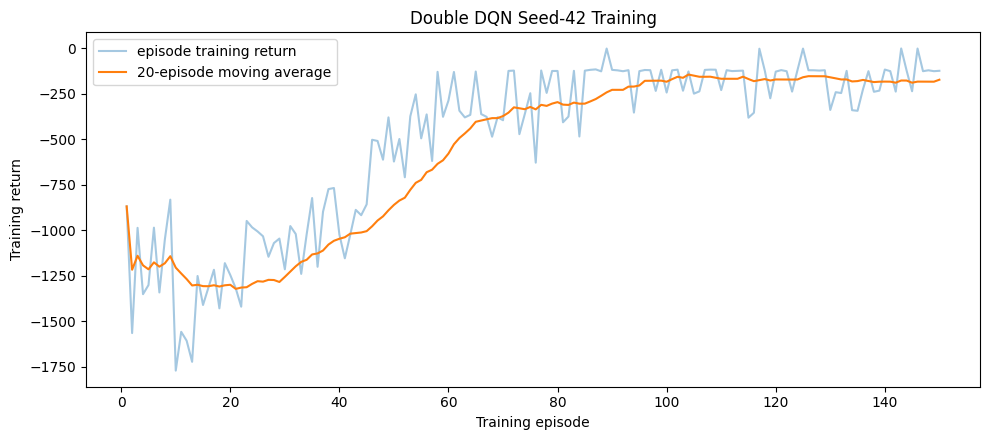

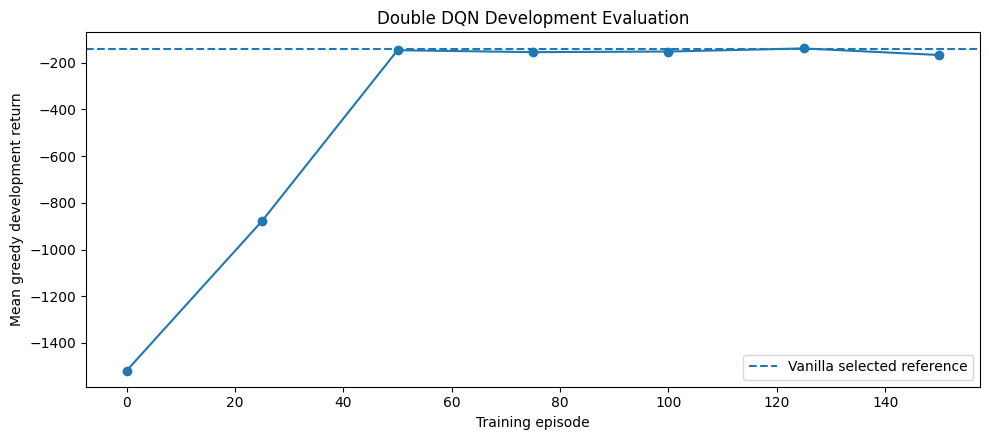

Double DQN run completed: True
Selected checkpoint episode: 125
Mean development return: -138.75772309246403
Development return standard deviation: 102.05029823623111
Upright fraction: 0.8689583333333334
Double-minus-Vanilla mean return: 1.0608781744809903
Within practical improvement margin: True
Parameter count: 4871
Formal runs completed: 6
Remaining formal-run capacity: 22
Saved Double DQN history: histories\R41_DOUBLE_history.csv
Saved Double DQN summary: histories\R41_DOUBLE_summary.csv
Saved Double DQN selected weights: selected_weights\R41_DOUBLE_best.weights.h5
Section 9.3.2 Double DQN run: COMPLETE


In [57]:
R41_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR / f"{R41_RUN_ID}_best.weights.h5"
)
R41_HISTORY_PATH = (
    HISTORIES_DIR / f"{R41_RUN_ID}_history.csv"
)
R41_EVALUATION_PATH = (
    HISTORIES_DIR
    / f"{R41_RUN_ID}_development_evaluations.csv"
)
R41_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R41_RUN_ID}_development_evaluation_summary.csv"
)
R41_SUMMARY_PATH = (
    HISTORIES_DIR / f"{R41_RUN_ID}_summary.csv"
)
R41_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / f"{R41_RUN_ID}_selected_state_results.csv"
)

assert FOUNDATION_SCREEN_SEED == 42
assert FOUNDATION_SCREEN_ACTION_COUNT == 7
assert FORMAL_RUNS_COMPLETED in (5, 6)
assert remaining_formal_run_capacity in (23, 22)
assert FORMAL_RUNS_COMPLETED < APPROVED_HARD_FORMAL_RUN_CAP
assert double_correctness_checks["status"].all()


def run_double_dqn_foundation(
    run_id: str,
    torque_values: np.ndarray,
    seed: int,
    weight_path: Path,
) -> Dict[str, object]:
    """Train one fresh Double DQN under the locked foundation controls."""
    validated_torques = validate_discrete_torque_values(
        torque_values
    )
    action_count = len(validated_torques)

    tf.keras.utils.set_random_seed(seed)
    np.random.seed(seed)
    epsilon_rng = random.Random(seed + 1_000)
    replay_rng = random.Random(seed + 2_000)

    main_network, target_network = (
        initialise_main_and_target_networks(
            state_dim=DQN_STATE_DIM,
            action_count=action_count,
            seed=seed,
        )
    )
    optimizer = keras.optimizers.Adam(
        learning_rate=ACTION_COMPARISON_LEARNING_RATE
    )
    replay_memory = ReplayMemory(
        capacity=ACTION_COMPARISON_REPLAY_CAPACITY,
        state_dim=DQN_STATE_DIM,
        action_count=action_count,
    )

    development_observations = np.stack([
        expected_observation(
            float(theta),
            float(theta_dot),
        )
        for theta, theta_dot in DEVELOPMENT_PHYSICAL_STATES
    ]).astype(np.float32)

    history_records = []
    evaluation_frames = []
    evaluation_records = []

    environment_steps = 0
    random_action_count = 0
    greedy_action_count = 0
    target_update_count = 0
    best_mean_return = -np.inf
    best_episode = None

    total_start = time.perf_counter()

    initial_states, initial_summary = (
        evaluate_action_comparison_model(
            model=main_network,
            torque_values=validated_torques,
            run_id=run_id,
            episode=0,
        )
    )
    evaluation_frames.append(initial_states)
    evaluation_records.append(initial_summary)

    best_mean_return = initial_summary[
        "mean_development_return"
    ]
    best_episode = 0
    main_network.save_weights(weight_path)

    print(
        f"Episode   0 | development mean return "
        f"{best_mean_return:10.3f} | initial checkpoint"
    )

    env = make_pendulum_env(
        GRAVITY_SETTINGS["default"]
    )
    env.seed(seed)

    try:
        for episode in range(
            1,
            ACTION_COMPARISON_EPISODES + 1,
        ):
            observation = np.asarray(
                env.reset(),
                dtype=np.float32,
            )
            episode_return = 0.0
            episode_losses = []
            episode_gradient_norms = []
            episode_random_actions = 0
            episode_greedy_actions = 0
            episode_target_updates = 0
            episode_start = time.perf_counter()

            for step_index in range(EVALUATION_HORIZON):
                epsilon = action_comparison_epsilon(
                    environment_steps
                )
                action_index, torque, was_random = (
                    epsilon_greedy_discrete_action(
                        model=main_network,
                        observation=observation,
                        torque_values=validated_torques,
                        epsilon=epsilon,
                        rng=epsilon_rng,
                    )
                )

                episode_random_actions += int(was_random)
                episode_greedy_actions += int(not was_random)
                random_action_count += int(was_random)
                greedy_action_count += int(not was_random)

                next_observation, reward, done, info = (
                    env.step(
                        np.array(
                            [torque],
                            dtype=np.float32,
                        )
                    )
                )
                next_observation = np.asarray(
                    next_observation,
                    dtype=np.float32,
                )

                replay_memory.append(
                    state=observation,
                    action_index=action_index,
                    reward=float(reward),
                    next_state=next_observation,
                )

                observation = next_observation
                episode_return += float(reward)
                environment_steps += 1

                if (
                    len(replay_memory)
                    >= ACTION_COMPARISON_REPLAY_WARMUP
                ):
                    batch = replay_memory.sample(
                        batch_size=(
                            ACTION_COMPARISON_BATCH_SIZE
                        ),
                        rng=replay_rng,
                    )
                    update_result = (
                        double_dqn_gradient_update(
                            main_network=main_network,
                            target_network=target_network,
                            optimizer=optimizer,
                            states=batch[0],
                            action_indices=batch[1],
                            rewards=batch[2],
                            next_states=batch[3],
                            gamma=ACTION_COMPARISON_GAMMA,
                        )
                    )
                    episode_losses.append(
                        update_result["loss"]
                    )
                    episode_gradient_norms.append(
                        update_result[
                            "gradient_global_norm"
                        ]
                    )

                    target_updated = (
                        hard_update_target_network_if_due(
                            main_network=main_network,
                            target_network=target_network,
                            optimizer_step=int(
                                optimizer.iterations.numpy()
                            ),
                            update_frequency=(
                                ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY
                            ),
                        )
                    )
                    episode_target_updates += int(
                        target_updated
                    )
                    target_update_count += int(
                        target_updated
                    )

                if done:
                    assert info.get(
                        "TimeLimit.truncated"
                    ) is True
                    assert (
                        step_index + 1
                        == EVALUATION_HORIZON
                    )
                    break

            assert step_index + 1 == EVALUATION_HORIZON

            q_values = main_network(
                tf.convert_to_tensor(
                    development_observations,
                    dtype=tf.float32,
                ),
                training=False,
            ).numpy()
            assert q_values.shape == (
                len(DEVELOPMENT_PHYSICAL_STATES),
                action_count,
            )
            assert np.isfinite(q_values).all()

            history_records.append({
                "run_id": run_id,
                "model": "Double DQN",
                "episode": int(episode),
                "environment_steps": int(
                    environment_steps
                ),
                "optimizer_updates": int(
                    optimizer.iterations.numpy()
                ),
                "training_return": float(
                    episode_return
                ),
                "epsilon": float(epsilon),
                "mean_loss": (
                    float(np.mean(episode_losses))
                    if episode_losses
                    else np.nan
                ),
                "mean_gradient_global_norm": (
                    float(
                        np.mean(
                            episode_gradient_norms
                        )
                    )
                    if episode_gradient_norms
                    else np.nan
                ),
                "mean_q": float(np.mean(q_values)),
                "max_q": float(np.max(q_values)),
                "random_actions": int(
                    episode_random_actions
                ),
                "greedy_actions": int(
                    episode_greedy_actions
                ),
                "target_updates": int(
                    episode_target_updates
                ),
                "replay_size": int(
                    len(replay_memory)
                ),
                "episode_runtime_seconds": float(
                    time.perf_counter()
                    - episode_start
                ),
            })

            if (
                episode
                % ACTION_COMPARISON_EVALUATION_FREQUENCY
                == 0
            ):
                replay_size_before = len(
                    replay_memory
                )
                state_results, evaluation_summary = (
                    evaluate_action_comparison_model(
                        model=main_network,
                        torque_values=validated_torques,
                        run_id=run_id,
                        episode=episode,
                    )
                )
                assert len(replay_memory) == (
                    replay_size_before
                )

                evaluation_frames.append(
                    state_results
                )
                evaluation_records.append(
                    evaluation_summary
                )

                mean_return = evaluation_summary[
                    "mean_development_return"
                ]
                if mean_return > best_mean_return:
                    main_network.save_weights(
                        weight_path
                    )
                    best_mean_return = mean_return
                    best_episode = int(episode)

                print(
                    f"Episode {episode:3d} | "
                    f"development mean return "
                    f"{mean_return:10.3f} | best "
                    f"{best_mean_return:10.3f} "
                    f"at episode {best_episode}"
                )
    finally:
        env.close()

    total_runtime_seconds = (
        time.perf_counter() - total_start
    )

    history = pd.DataFrame(history_records)
    history["moving_average_return"] = (
        history["training_return"]
        .rolling(
            R10_MOVING_AVERAGE_WINDOW,
            min_periods=1,
        )
        .mean()
    )

    evaluation_states = pd.concat(
        evaluation_frames,
        ignore_index=True,
    )
    evaluation_summary = pd.DataFrame(
        evaluation_records
    )
    evaluation_map = dict(zip(
        evaluation_summary["episode"],
        evaluation_summary[
            "mean_development_return"
        ],
    ))
    history["evaluation_return"] = (
        history["episode"].map(evaluation_map)
    )

    selected_model = build_standard_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=action_count,
        hidden_units=STANDARD_HIDDEN_UNITS,
        model_name=(
            f"{run_id.lower()}_selected_q_network"
        ),
    )
    selected_model.load_weights(weight_path)

    selected_states, selected_summary = (
        evaluate_action_comparison_model(
            model=selected_model,
            torque_values=validated_torques,
            run_id=run_id,
            episode=int(best_episode),
        )
    )

    assert np.isclose(
        selected_summary[
            "mean_development_return"
        ],
        best_mean_return,
        rtol=1e-7,
        atol=1e-7,
    )

    selected_q_values = selected_model(
        tf.convert_to_tensor(
            development_observations,
            dtype=tf.float32,
        ),
        training=False,
    ).numpy()
    assert selected_q_values.shape == (
        len(DEVELOPMENT_PHYSICAL_STATES),
        action_count,
    )
    assert np.isfinite(selected_q_values).all()

    summary_record = {
        "run_id": run_id,
        "source_run_id": run_id,
        "reused_existing_run": False,
        "new_training_run_consumed": True,
        "model": "Double DQN",
        "gravity": "default",
        "seed": int(seed),
        "action_count": int(action_count),
        "torque_values": validated_torques.tolist(),
        "episodes": int(
            ACTION_COMPARISON_EPISODES
        ),
        "environment_steps": int(
            environment_steps
        ),
        "optimizer_updates": int(
            optimizer.iterations.numpy()
        ),
        "selected_checkpoint_episode": int(
            best_episode
        ),
        "mean_development_return": float(
            selected_summary[
                "mean_development_return"
            ]
        ),
        "development_return_std": float(
            selected_summary[
                "development_return_std"
            ]
        ),
        "upright_fraction": float(
            selected_summary[
                "mean_upright_fraction"
            ]
        ),
        "mean_abs_angle": float(
            selected_summary["mean_abs_angle"]
        ),
        "mean_abs_angular_velocity": float(
            selected_summary[
                "mean_abs_angular_velocity"
            ]
        ),
        "mean_abs_torque": float(
            selected_summary["mean_abs_torque"]
        ),
        "torque_direction_switching_rate": float(
            selected_summary[
                "mean_torque_direction_switching_rate"
            ]
        ),
        "selected_mean_q": float(
            np.mean(selected_q_values)
        ),
        "selected_max_q": float(
            np.max(selected_q_values)
        ),
        "selected_min_q": float(
            np.min(selected_q_values)
        ),
        "random_actions": int(
            random_action_count
        ),
        "greedy_actions": int(
            greedy_action_count
        ),
        "target_updates": int(
            target_update_count
        ),
        "runtime_minutes": float(
            total_runtime_seconds / 60.0
        ),
        "parameter_count": int(
            selected_model.count_params()
        ),
        "weight_path": str(weight_path),
        "technical_status": "PASS",
    }

    return {
        "main_network": main_network,
        "target_network": target_network,
        "selected_model": selected_model,
        "history": history,
        "evaluation_states": evaluation_states,
        "evaluation_summary": evaluation_summary,
        "selected_state_results": selected_states,
        "selected_summary": selected_summary,
        "summary_record": summary_record,
    }


r41_required_artifacts = [
    R41_WEIGHT_PATH,
    R41_HISTORY_PATH,
    R41_EVALUATION_PATH,
    R41_EVALUATION_SUMMARY_PATH,
    R41_SUMMARY_PATH,
    R41_STATE_RESULTS_PATH,
]
r41_artifacts_complete = all(
    path.exists()
    for path in r41_required_artifacts
)

if (
    "Double DQN" in FOUNDATION_SCREEN_RESULTS
    and all(
        name in globals()
        for name in [
            "r41_history",
            "r41_evaluation_states",
            "r41_evaluation_summary",
            "r41_selected_state_results",
            "r41_summary_record",
            "r41_summary",
        ]
    )
):
    print(
        "R41 Double DQN result already exists in memory; "
        "no duplicate training run was started."
    )
elif r41_artifacts_complete:
    r41_history = read_csv_with_control_metric_migration(
        R41_HISTORY_PATH
    )
    r41_evaluation_states = read_csv_with_control_metric_migration(
        R41_EVALUATION_PATH
    )
    r41_evaluation_summary = read_csv_with_control_metric_migration(
        R41_EVALUATION_SUMMARY_PATH
    )
    r41_summary = read_csv_with_control_metric_migration(
        R41_SUMMARY_PATH
    )
    r41_selected_state_results = read_csv_with_control_metric_migration(
        R41_STATE_RESULTS_PATH
    )

    assert len(r41_summary) == 1
    r41_summary_record = (
        r41_summary.iloc[0].to_dict()
    )
    r41_selected_model = build_standard_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=FOUNDATION_SCREEN_ACTION_COUNT,
        hidden_units=STANDARD_HIDDEN_UNITS,
        model_name=(
            "r41_double_reloaded_q_network"
        ),
    )
    r41_selected_model.load_weights(
        R41_WEIGHT_PATH
    )
    print(
        "Loaded completed R41 Double DQN artifacts; "
        "no duplicate training run was started."
    )
else:
    r41_result = run_double_dqn_foundation(
        run_id=R41_RUN_ID,
        torque_values=FOUNDATION_SCREEN_TORQUE_VALUES,
        seed=FOUNDATION_SCREEN_SEED,
        weight_path=R41_WEIGHT_PATH,
    )

    r41_history = r41_result["history"]
    r41_evaluation_states = (
        r41_result["evaluation_states"]
    )
    r41_evaluation_summary = (
        r41_result["evaluation_summary"]
    )
    r41_selected_state_results = (
        r41_result["selected_state_results"]
    )
    r41_selected_model = (
        r41_result["selected_model"]
    )
    r41_summary_record = (
        r41_result["summary_record"]
    )
    r41_summary = pd.DataFrame(
        [r41_summary_record]
    )

FOUNDATION_SCREEN_RESULTS[
    "Double DQN"
] = r41_summary_record
FOUNDATION_SCREEN_STATE_RESULTS[
    "Double DQN"
] = r41_selected_state_results.copy()
FOUNDATION_SCREEN_EVALUATION_SUMMARIES[
    "Double DQN"
] = r41_evaluation_summary.copy()

FORMAL_RUNS_COMPLETED = 6
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert set(FOUNDATION_SCREEN_RESULTS.keys()) == {
    "Vanilla DQN",
    "Double DQN",
}
assert FORMAL_RUNS_COMPLETED == 6
assert remaining_formal_run_capacity == 22
assert len(r41_history) == (
    FOUNDATION_SCREEN_EPISODES
)
assert len(r41_evaluation_summary) == 7
assert int(r41_summary_record["seed"]) == 42
assert int(
    r41_summary_record["action_count"]
) == FOUNDATION_SCREEN_ACTION_COUNT
assert int(
    r41_summary_record["parameter_count"]
) == 4871
assert int(
    r41_summary_record["environment_steps"]
) == 30_000
assert int(
    r41_summary_record["optimizer_updates"]
) == 29_001
assert int(
    r41_summary_record["target_updates"]
) == 116
assert (
    int(r41_summary_record["random_actions"])
    + int(r41_summary_record["greedy_actions"])
    == 30_000
)
assert np.isfinite(
    r41_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert np.isfinite(
    float(
        r41_summary_record[
            "mean_development_return"
        ]
    )
)
assert R41_WEIGHT_PATH.exists()

r41_history.to_csv(
    R41_HISTORY_PATH,
    index=False,
)
r41_evaluation_states.to_csv(
    R41_EVALUATION_PATH,
    index=False,
)
r41_evaluation_summary.to_csv(
    R41_EVALUATION_SUMMARY_PATH,
    index=False,
)
r41_summary.to_csv(
    R41_SUMMARY_PATH,
    index=False,
)
r41_selected_state_results.to_csv(
    R41_STATE_RESULTS_PATH,
    index=False,
)

display(r41_evaluation_summary)
display(r41_summary)
display(r41_history.tail(10))

plt.figure(figsize=(10, 4.5))
plt.plot(
    r41_history["episode"],
    r41_history["training_return"],
    alpha=0.4,
    label="episode training return",
)
plt.plot(
    r41_history["episode"],
    r41_history[
        "moving_average_return"
    ],
    label=(
        f"{R10_MOVING_AVERAGE_WINDOW}-episode "
        "moving average"
    ),
)
plt.xlabel("Training episode")
plt.ylabel("Training return")
plt.title("Double DQN Seed-42 Training")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(
    r41_evaluation_summary["episode"],
    r41_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
)
plt.axhline(
    float(
        r40_summary_record[
            "mean_development_return"
        ]
    ),
    linestyle="--",
    label="Vanilla selected reference",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("Double DQN Development Evaluation")
plt.legend()
plt.tight_layout()
plt.show()

double_minus_vanilla = float(
    r41_summary_record[
        "mean_development_return"
    ]
    - r40_summary_record[
        "mean_development_return"
    ]
)

print("Double DQN run completed:", True)
print(
    "Selected checkpoint episode:",
    r41_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    r41_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    r41_summary_record[
        "development_return_std"
    ],
)
print(
    "Upright fraction:",
    r41_summary_record[
        "upright_fraction"
    ],
)
print(
    "Double-minus-Vanilla mean return:",
    double_minus_vanilla,
)
print(
    "Within practical improvement margin:",
    abs(double_minus_vanilla)
    <= PRACTICAL_IMPROVEMENT_MARGIN,
)
print(
    "Parameter count:",
    r41_summary_record["parameter_count"],
)
print("Formal runs completed:", FORMAL_RUNS_COMPLETED)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print("Saved Double DQN history:", R41_HISTORY_PATH)
print("Saved Double DQN summary:", R41_SUMMARY_PATH)
print(
    "Saved Double DQN selected weights:",
    R41_WEIGHT_PATH,
)
print("Section 9.3.2 Double DQN run: COMPLETE")


### 9.3.2 Result Interpretation

**Finding.** The seed-42 Double DQN run completed all `150` episodes,
`30,000` environment steps and `29,001` optimiser updates without technical
failure. Its selected checkpoint was episode `125`, with:

- mean development return: `-138.757723`;
- development-state standard deviation: `102.050298`;
- upright fraction: `0.868958`;
- parameter count: `4,871`.

Double DQN exceeded the seed-42 Vanilla reference by `1.060878` mean return.
This difference is inside the locked practical-improvement margin of
`11.335072`.

**Importance.** Double DQN is a valid foundation candidate, but the observed
advantage is too small to separate it reliably from ordinary training-seed
variation. Its state-wise spread was also slightly larger than Vanilla's
`101.098652`, while its upright fraction was slightly lower than Vanilla's
`0.872292`.

**Decision.** Retain Double DQN for the foundation comparison. Do not select it
over Vanilla from seed `42` alone. It requires matched seed-123 confirmation
if it remains shortlisted after Dueling DQN is evaluated.

**Caveat.** The selected checkpoint occurred at episode `125`, while the
episode-150 evaluation fell to `-166.861631`. Periodic development checkpoint
selection remains necessary.

**Next step.** Validate the Dueling DQN architecture and centred-advantage
aggregation before formal training.


## 9.4 Dueling DQN

**Question.** Does separating state value from action-specific advantage
improve Pendulum control compared with the shared Vanilla reference?

**Reason.** Several torque actions may have similar value in some states.
Dueling DQN represents:

```text
V(s)        state value
A(s, a)     action advantage
```

and combines them using:

```text
Q(s, a) = V(s) + A(s, a) - mean_a A(s, a)
```

Centred advantages make the decomposition identifiable because the mean
advantage is zero for each state.

**Hypothesis.** A separate value stream may help the network learn useful
state quality while preserving action-specific torque differences.

**Reference.** `R40_VANILLA` at seed `42`.

**Primary change.** Network head only. The Bellman target remains the validated
Vanilla DQN target.

**Controlled factors.** Action set, gravity, seed, shared `64 → 64` body,
optimiser, learning rate, loss, gamma, replay, epsilon schedule, target-update
frequency, training budget, checkpoint rule and development states remain
fixed.

**Decision rule.** Compare the selected seed-42 checkpoint with Vanilla and
Double DQN. A direct difference within `11.335072` requires matched seed-123
confirmation before architecture selection.


### 9.4.1 Architecture and Gradient Smoke Test

Before formal training, this cell must prove that:

1. the shared body has two `64`-unit ReLU layers;
2. the value stream outputs one value per state;
3. the advantage stream outputs seven action advantages;
4. the centred advantages have zero mean per state;
5. `Q(s, a)` equals value plus centred advantage;
6. the mean Q-value across actions equals the state value;
7. main and target networks begin equal but own separate variables;
8. one gradient update changes only the main network;
9. loss, gradients and Q-values remain finite.

This technical test consumes no formal training run.


In [58]:
R42_RUN_ID = "R42_DUELING"
R42_CORRECTNESS_SMOKE_PATH = (
    HISTORIES_DIR / f"{R42_RUN_ID}_correctness_smoke.csv"
)


def build_dueling_q_network(
    state_dim: int,
    action_count: int,
    hidden_units: Tuple[int, ...] = STANDARD_HIDDEN_UNITS,
    model_name: str = "dueling_q_network",
) -> keras.Model:
    """Build a Dueling DQN with a shared body and centred advantages."""
    assert isinstance(state_dim, (int, np.integer))
    assert int(state_dim) > 0
    assert isinstance(action_count, (int, np.integer))
    assert int(action_count) > 1
    assert tuple(hidden_units) == (64, 64)

    state_input = keras.Input(
        shape=(int(state_dim),),
        dtype=tf.float32,
        name=f"{model_name}_state_input",
    )

    hidden = state_input
    for layer_index, units in enumerate(
        hidden_units,
        start=1,
    ):
        hidden = keras.layers.Dense(
            int(units),
            activation="relu",
            name=f"{model_name}_hidden_{layer_index}",
        )(hidden)

    state_value = keras.layers.Dense(
        1,
        activation="linear",
        name=f"{model_name}_state_value",
    )(hidden)

    action_advantage = keras.layers.Dense(
        int(action_count),
        activation="linear",
        name=f"{model_name}_action_advantage",
    )(hidden)

    centred_advantage = keras.layers.Lambda(
        lambda advantage: (
            advantage
            - tf.reduce_mean(
                advantage,
                axis=1,
                keepdims=True,
            )
        ),
        name=f"{model_name}_centred_advantage",
    )(action_advantage)

    q_values = keras.layers.Add(
        name=f"{model_name}_q_values",
    )([
        state_value,
        centred_advantage,
    ])

    model = keras.Model(
        inputs=state_input,
        outputs=q_values,
        name=model_name,
    )

    assert model.input_shape == (
        None,
        int(state_dim),
    )
    assert model.output_shape == (
        None,
        int(action_count),
    )

    return model


def initialise_dueling_main_and_target_networks(
    state_dim: int,
    action_count: int,
    hidden_units: Tuple[int, ...] = STANDARD_HIDDEN_UNITS,
    seed: int = 42,
) -> Tuple[keras.Model, keras.Model]:
    """Create separate Dueling main and target networks with equal weights."""
    tf.keras.utils.set_random_seed(int(seed))

    main_network = build_dueling_q_network(
        state_dim=state_dim,
        action_count=action_count,
        hidden_units=hidden_units,
        model_name="dueling_main_q_network",
    )
    target_network = build_dueling_q_network(
        state_dim=state_dim,
        action_count=action_count,
        hidden_units=hidden_units,
        model_name="dueling_target_q_network",
    )
    target_network.set_weights(
        main_network.get_weights()
    )

    return main_network, target_network


dueling_smoke_main, dueling_smoke_target = (
    initialise_dueling_main_and_target_networks(
        state_dim=DQN_STATE_DIM,
        action_count=FOUNDATION_SCREEN_ACTION_COUNT,
        hidden_units=STANDARD_HIDDEN_UNITS,
        seed=FOUNDATION_SCREEN_SEED,
    )
)

dueling_probe_states = np.array(
    [
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.5],
        [-1.0, 0.0, -1.0],
        [0.0, -1.0, 1.5],
    ],
    dtype=np.float32,
)

dueling_stream_model = keras.Model(
    inputs=dueling_smoke_main.input,
    outputs=[
        dueling_smoke_main.get_layer(
            "dueling_main_q_network_state_value"
        ).output,
        dueling_smoke_main.get_layer(
            "dueling_main_q_network_action_advantage"
        ).output,
        dueling_smoke_main.get_layer(
            "dueling_main_q_network_centred_advantage"
        ).output,
        dueling_smoke_main.output,
    ],
    name="dueling_stream_smoke_model",
)

(
    dueling_state_values,
    dueling_action_advantages,
    dueling_centred_advantages,
    dueling_q_values,
) = [
    tensor.numpy()
    for tensor in dueling_stream_model(
        tf.convert_to_tensor(
            dueling_probe_states,
            dtype=tf.float32,
        ),
        training=False,
    )
]

assert dueling_state_values.shape == (4, 1)
assert dueling_action_advantages.shape == (
    4,
    FOUNDATION_SCREEN_ACTION_COUNT,
)
assert dueling_centred_advantages.shape == (
    4,
    FOUNDATION_SCREEN_ACTION_COUNT,
)
assert dueling_q_values.shape == (
    4,
    FOUNDATION_SCREEN_ACTION_COUNT,
)

np.testing.assert_allclose(
    np.mean(
        dueling_centred_advantages,
        axis=1,
        keepdims=True,
    ),
    np.zeros((4, 1), dtype=np.float32),
    rtol=0.0,
    atol=1e-6,
)
np.testing.assert_allclose(
    dueling_q_values,
    dueling_state_values
    + dueling_centred_advantages,
    rtol=0.0,
    atol=1e-6,
)
np.testing.assert_allclose(
    np.mean(
        dueling_q_values,
        axis=1,
        keepdims=True,
    ),
    dueling_state_values,
    rtol=0.0,
    atol=1e-6,
)

assert np.isfinite(dueling_state_values).all()
assert np.isfinite(
    dueling_action_advantages
).all()
assert np.isfinite(
    dueling_centred_advantages
).all()
assert np.isfinite(dueling_q_values).all()

dueling_hidden_layers = [
    layer
    for layer in dueling_smoke_main.layers
    if layer.name.endswith(
        ("hidden_1", "hidden_2")
    )
]
assert len(dueling_hidden_layers) == 2
assert [
    layer.units
    for layer in dueling_hidden_layers
] == [64, 64]
assert [
    layer.activation.__name__
    for layer in dueling_hidden_layers
] == ["relu", "relu"]

assert dueling_smoke_main.count_params() == 4936
assert dueling_smoke_target.count_params() == 4936
assert dueling_smoke_main is not dueling_smoke_target
assert len(dueling_smoke_main.weights) == len(
    dueling_smoke_target.weights
)

for main_weight, target_weight in zip(
    dueling_smoke_main.weights,
    dueling_smoke_target.weights,
):
    assert main_weight is not target_weight
    np.testing.assert_allclose(
        main_weight.numpy(),
        target_weight.numpy(),
        rtol=0.0,
        atol=0.0,
    )

dueling_target_q_before = dueling_smoke_target(
    tf.convert_to_tensor(
        dueling_probe_states,
        dtype=tf.float32,
    ),
    training=False,
).numpy()
np.testing.assert_allclose(
    dueling_q_values,
    dueling_target_q_before,
    rtol=0.0,
    atol=0.0,
)

dueling_main_weights_before = [
    weight.numpy().copy()
    for weight in dueling_smoke_main.weights
]
dueling_target_weights_before = [
    weight.numpy().copy()
    for weight in dueling_smoke_target.weights
]

dueling_smoke_optimizer = keras.optimizers.Adam(
    learning_rate=ACTION_COMPARISON_LEARNING_RATE
)

dueling_smoke_actions = np.array(
    [0, 2, 4, 6],
    dtype=np.int32,
)
dueling_smoke_rewards = np.array(
    [-1.0, -2.0, -3.0, -4.0],
    dtype=np.float32,
)
dueling_smoke_next_states = np.array(
    [
        [0.99, 0.10, 0.1],
        [-0.10, 0.99, 0.4],
        [-0.99, -0.10, -0.8],
        [0.10, -0.99, 1.2],
    ],
    dtype=np.float32,
)

dueling_gradient_result = vanilla_dqn_gradient_update(
    main_network=dueling_smoke_main,
    target_network=dueling_smoke_target,
    optimizer=dueling_smoke_optimizer,
    states=dueling_probe_states,
    action_indices=dueling_smoke_actions,
    rewards=dueling_smoke_rewards,
    next_states=dueling_smoke_next_states,
    gamma=ACTION_COMPARISON_GAMMA,
)

dueling_main_weight_changes = [
    float(
        np.max(
            np.abs(
                after.numpy() - before
            )
        )
    )
    for before, after in zip(
        dueling_main_weights_before,
        dueling_smoke_main.weights,
    )
]
dueling_target_weight_changes = [
    float(
        np.max(
            np.abs(
                after.numpy() - before
            )
        )
    )
    for before, after in zip(
        dueling_target_weights_before,
        dueling_smoke_target.weights,
    )
]

dueling_post_update_q_values = dueling_smoke_main(
    tf.convert_to_tensor(
        dueling_probe_states,
        dtype=tf.float32,
    ),
    training=False,
).numpy()

assert any(
    change > 0.0
    for change in dueling_main_weight_changes
)
assert all(
    change == 0.0
    for change in dueling_target_weight_changes
)
assert (
    dueling_gradient_result[
        "optimizer_iterations"
    ] == 1
)
assert np.isfinite(
    dueling_gradient_result["loss"]
)
assert np.isfinite(
    dueling_gradient_result[
        "gradient_global_norm"
    ]
)
assert np.isfinite(
    dueling_gradient_result[
        "bellman_targets"
    ]
).all()
assert np.isfinite(
    dueling_post_update_q_values
).all()
assert FORMAL_RUNS_COMPLETED == 6
assert remaining_formal_run_capacity == 22

dueling_correctness_checks = pd.DataFrame(
    {
        "check": [
            "Two 64-unit ReLU shared layers",
            "Value stream output shape",
            "Advantage stream output shape",
            "Centred advantage mean is zero",
            "Q equals value plus centred advantage",
            "Mean Q equals state value",
            "Main and target initially match",
            "Main and target own separate variables",
            "Main network changed after gradient update",
            "Target network remained unchanged",
            "Finite MSE loss",
            "Finite gradient global norm",
            "Formal-run count unchanged",
        ],
        "status": [
            True,
            bool(
                dueling_state_values.shape == (4, 1)
            ),
            bool(
                dueling_action_advantages.shape
                == (
                    4,
                    FOUNDATION_SCREEN_ACTION_COUNT,
                )
            ),
            bool(
                np.allclose(
                    np.mean(
                        dueling_centred_advantages,
                        axis=1,
                    ),
                    0.0,
                    rtol=0.0,
                    atol=1e-6,
                )
            ),
            bool(
                np.allclose(
                    dueling_q_values,
                    dueling_state_values
                    + dueling_centred_advantages,
                    rtol=0.0,
                    atol=1e-6,
                )
            ),
            bool(
                np.allclose(
                    np.mean(
                        dueling_q_values,
                        axis=1,
                        keepdims=True,
                    ),
                    dueling_state_values,
                    rtol=0.0,
                    atol=1e-6,
                )
            ),
            bool(
                np.allclose(
                    dueling_q_values,
                    dueling_target_q_before,
                    rtol=0.0,
                    atol=0.0,
                )
            ),
            all(
                main_weight is not target_weight
                for main_weight, target_weight in zip(
                    dueling_smoke_main.weights,
                    dueling_smoke_target.weights,
                )
            ),
            any(
                change > 0.0
                for change in dueling_main_weight_changes
            ),
            all(
                change == 0.0
                for change in dueling_target_weight_changes
            ),
            bool(
                np.isfinite(
                    dueling_gradient_result["loss"]
                )
            ),
            bool(
                np.isfinite(
                    dueling_gradient_result[
                        "gradient_global_norm"
                    ]
                )
            ),
            bool(FORMAL_RUNS_COMPLETED == 6),
        ],
    }
)

assert dueling_correctness_checks[
    "status"
].all()

dueling_correctness_checks.to_csv(
    R42_CORRECTNESS_SMOKE_PATH,
    index=False,
)

display(dueling_correctness_checks)

print(
    "Dueling output shape:",
    dueling_smoke_main.output_shape,
)
print(
    "Dueling parameter count:",
    dueling_smoke_main.count_params(),
)
print(
    "Maximum centred-advantage mean magnitude:",
    float(
        np.max(
            np.abs(
                np.mean(
                    dueling_centred_advantages,
                    axis=1,
                )
            )
        )
    ),
)
print(
    "Maximum Q-aggregation difference:",
    float(
        np.max(
            np.abs(
                dueling_q_values
                - (
                    dueling_state_values
                    + dueling_centred_advantages
                )
            )
        )
    ),
)
print(
    "Maximum mean-Q versus value difference:",
    float(
        np.max(
            np.abs(
                np.mean(
                    dueling_q_values,
                    axis=1,
                    keepdims=True,
                )
                - dueling_state_values
            )
        )
    ),
)
print(
    "Dueling smoke-test MSE loss:",
    dueling_gradient_result["loss"],
)
print(
    "Dueling gradient global norm:",
    dueling_gradient_result[
        "gradient_global_norm"
    ],
)
print(
    "Main network changed:",
    any(
        change > 0.0
        for change in dueling_main_weight_changes
    ),
)
print(
    "Target network unchanged:",
    all(
        change == 0.0
        for change in dueling_target_weight_changes
    ),
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved Dueling DQN correctness smoke test:",
    R42_CORRECTNESS_SMOKE_PATH,
)
print("Section 9.4.1 Dueling DQN correctness smoke test: PASS")


,check,status
0,Two 64-unit ReLU shared layers,True
1,Value stream output shape,True
2,Advantage stream output shape,True
3,Centred advantage mean is zero,True
4,Q equals value plus centred advantage,True
5,Mean Q equals state value,True
6,Main and target initially match,True
7,Main and target own separate variables,True
8,Main network changed after gradient update,True
9,Target network remained unchanged,True


Dueling output shape: (None, 7)
Dueling parameter count: 4936
Maximum centred-advantage mean magnitude: 4.257474817137563e-09
Maximum Q-aggregation difference: 0.0
Maximum mean-Q versus value difference: 7.450580596923828e-09
Dueling smoke-test MSE loss: 6.636391639709473
Dueling gradient global norm: 10.668088912963867
Main network changed: True
Target network unchanged: True
Formal runs completed: 6
Remaining formal-run capacity: 22
Saved Dueling DQN correctness smoke test: histories\R42_DUELING_correctness_smoke.csv
Section 9.4.1 Dueling DQN correctness smoke test: PASS


### 9.4.1 Result Interpretation

**Finding.** The Dueling DQN correctness gate passed all architecture and
gradient checks.

The network produced seven Q-values from separate value and advantage streams.
The centred-advantage mean was effectively zero
(`4.257475 × 10^-9`), the Q-value aggregation difference was exactly `0.0`,
and the maximum difference between mean Q-value and state value was only
`7.450581 × 10^-9`.

The gradient smoke test produced a finite MSE loss of `6.636392` and a finite
gradient global norm of `10.668089`. The main network changed, the target
network remained unchanged, and the formal-run count stayed at `6`.

**Importance.** The implementation now verifies the defining Dueling DQN
decomposition:

```text
Q(s, a) = V(s) + A(s, a) - mean_a A(s, a)
```

rather than merely adding extra output layers.

**Decision.** Approve one fresh seed-42 Dueling DQN foundation run under the
locked shared conditions.

**Caveat.** The Dueling model has `4,936` parameters, which is `65` more than
the Vanilla and Double networks. Performance must justify this extra
complexity.

**Next step.** Train `R42_DUELING` for `150` episodes and evaluate its selected
checkpoint on the same development states.


### 9.4.2 Formal Seed-42 Dueling DQN Run

This experiment changes only the network head. It uses the validated Dueling
architecture while retaining the ordinary Vanilla DQN Bellman target.

The action set, shared hidden body, gravity, seed, replay, epsilon schedule,
optimiser, learning rate, gamma, target-update schedule, training budget,
checkpoint rule and evaluation suite remain fixed.

A fresh model is trained using seed `42`. The selected checkpoint is the one
with the highest mean greedy development return across the fixed `24`
development states.

This run consumes one formal-training slot. After completion, the formal-run
count should be `7`, leaving `21` runs under the approved cap.


Loaded completed R42 Dueling DQN artifacts; no duplicate training run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1474.850023,-1421.686562,228.929283,-1816.480863,-1149.851953,0.009583,2.569736,1.605649,0.847083,0.072446
1,25,-904.370205,-1086.334320,463.934310,-1261.432602,-3.217989,0.293750,1.116941,4.094275,1.122222,0.139238
2,50,-144.504581,-125.838513,109.214853,-383.204841,-1.063292,0.859583,0.256761,0.564627,1.615694,0.684255
3,75,-148.423130,-124.553426,113.320939,-383.981852,-0.392010,0.861250,0.243728,0.544896,1.048194,0.862228
4,100,-135.942190,-124.460187,99.338244,-366.517627,-0.280292,0.872292,0.236363,0.489791,0.843889,0.750838
5,125,-144.350717,-126.443862,113.206233,-408.076583,-0.037149,0.857708,0.250449,0.514257,0.342917,0.177554
6,150,-148.233354,-126.590313,115.307313,-378.429455,-1.789450,0.860208,0.272566,0.610016,1.875139,0.689908


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,selected_mean_q,selected_max_q,selected_min_q,random_actions,greedy_actions,target_updates,runtime_minutes,parameter_count,weight_path,technical_status
0,R42_DUELING,R42_DUELING,False,True,Dueling DQN,default,42,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,-135.678345,-9.624632,-274.335236,10979,19021,116,14.916523,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS


,run_id,model,episode,environment_steps,optimizer_updates,training_return,epsilon,mean_loss,mean_gradient_global_norm,mean_q,max_q,random_actions,greedy_actions,target_updates,replay_size,episode_runtime_seconds,moving_average_return,evaluation_return
140,R42_DUELING,Dueling DQN,141,28200,27201,-127.332923,0.05,1.758750,127.334694,-112.726089,1.419195,9,191,0,10000,5.283355,-187.315244,NaN
141,R42_DUELING,Dueling DQN,142,28400,27401,-238.791643,0.05,1.501660,119.538496,-111.493210,2.124506,4,196,1,10000,5.360024,-192.891780,NaN
142,R42_DUELING,Dueling DQN,143,28600,27601,-1.355233,0.05,1.575854,116.562169,-112.045433,2.077203,8,192,1,10000,5.329389,-181.033963,NaN
143,R42_DUELING,Dueling DQN,144,28800,27801,-123.142917,0.05,1.496573,117.894835,-110.372665,2.762964,10,190,1,10000,5.123053,-181.305852,NaN
144,R42_DUELING,Dueling DQN,145,29000,28001,-245.395417,0.05,1.426071,116.436685,-112.195229,2.123151,11,189,1,10000,5.644519,-193.496925,NaN
145,R42_DUELING,Dueling DQN,146,29200,28201,-1.938737,0.05,1.644428,131.007167,-113.891998,2.234536,14,186,0,10000,5.361285,-187.495436,NaN
146,R42_DUELING,Dueling DQN,147,29400,28401,-124.920141,0.05,2.188244,157.437720,-112.010429,3.519230,10,190,1,10000,5.671125,-187.704387,NaN
147,R42_DUELING,Dueling DQN,148,29600,28601,-119.964128,0.05,1.520670,121.072902,-111.642006,3.007981,11,189,1,10000,5.584152,-187.217421,NaN
148,R42_DUELING,Dueling DQN,149,29800,28801,-125.131131,0.05,1.431487,118.632667,-112.713776,3.685515,9,191,1,10000,5.469634,-187.502535,NaN
149,R42_DUELING,Dueling DQN,150,30000,29001,-126.112062,0.05,1.382891,114.074447,-111.418297,4.351864,11,189,1,10000,5.566215,-174.329740,-148.233354


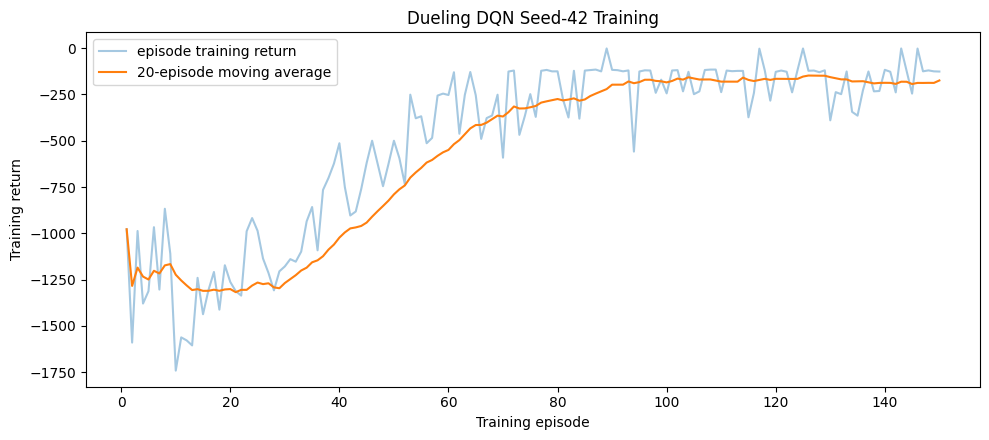

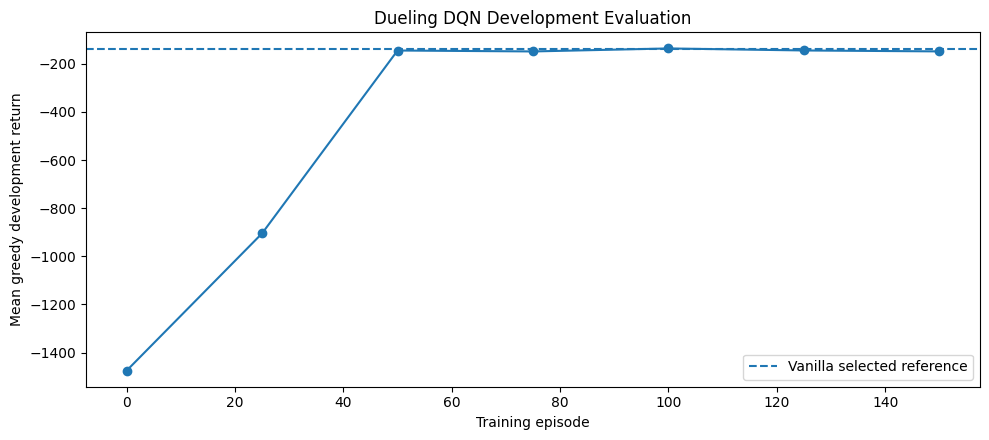

Dueling DQN run completed: True
Selected checkpoint episode: 100
Mean development return: -135.94219011424536
Development return standard deviation: 99.33824394123168
Upright fraction: 0.8722916666666666
Dueling-minus-Vanilla mean return: 3.87641115269966
Dueling-minus-Double mean return: 2.8155329782186698
Within practical improvement margin versus Vanilla: True
Parameter count: 4936
Formal runs completed: 7
Remaining formal-run capacity: 21
Saved Dueling DQN history: histories\R42_DUELING_history.csv
Saved Dueling DQN summary: histories\R42_DUELING_summary.csv
Saved Dueling DQN selected weights: selected_weights\R42_DUELING_best.weights.h5
Section 9.4.2 Dueling DQN run: COMPLETE


In [59]:
R42_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR / f"{R42_RUN_ID}_best.weights.h5"
)
R42_HISTORY_PATH = (
    HISTORIES_DIR / f"{R42_RUN_ID}_history.csv"
)
R42_EVALUATION_PATH = (
    HISTORIES_DIR
    / f"{R42_RUN_ID}_development_evaluations.csv"
)
R42_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R42_RUN_ID}_development_evaluation_summary.csv"
)
R42_SUMMARY_PATH = (
    HISTORIES_DIR / f"{R42_RUN_ID}_summary.csv"
)
R42_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / f"{R42_RUN_ID}_selected_state_results.csv"
)

assert FOUNDATION_SCREEN_SEED == 42
assert FOUNDATION_SCREEN_ACTION_COUNT == 7
assert FORMAL_RUNS_COMPLETED in (6, 7)
assert remaining_formal_run_capacity in (22, 21)
assert FORMAL_RUNS_COMPLETED < APPROVED_HARD_FORMAL_RUN_CAP
assert dueling_correctness_checks["status"].all()


def run_dueling_dqn_foundation(
    run_id: str,
    torque_values: np.ndarray,
    seed: int,
    weight_path: Path,
) -> Dict[str, object]:
    """Train one fresh Dueling DQN under the locked foundation controls."""
    validated_torques = validate_discrete_torque_values(
        torque_values
    )
    action_count = len(validated_torques)

    tf.keras.utils.set_random_seed(seed)
    np.random.seed(seed)
    epsilon_rng = random.Random(seed + 1_000)
    replay_rng = random.Random(seed + 2_000)

    main_network, target_network = (
        initialise_dueling_main_and_target_networks(
            state_dim=DQN_STATE_DIM,
            action_count=action_count,
            hidden_units=STANDARD_HIDDEN_UNITS,
            seed=seed,
        )
    )
    optimizer = keras.optimizers.Adam(
        learning_rate=ACTION_COMPARISON_LEARNING_RATE
    )
    replay_memory = ReplayMemory(
        capacity=ACTION_COMPARISON_REPLAY_CAPACITY,
        state_dim=DQN_STATE_DIM,
        action_count=action_count,
    )

    development_observations = np.stack([
        expected_observation(
            float(theta),
            float(theta_dot),
        )
        for theta, theta_dot in DEVELOPMENT_PHYSICAL_STATES
    ]).astype(np.float32)

    history_records = []
    evaluation_frames = []
    evaluation_records = []

    environment_steps = 0
    random_action_count = 0
    greedy_action_count = 0
    target_update_count = 0
    best_mean_return = -np.inf
    best_episode = None

    total_start = time.perf_counter()

    initial_states, initial_summary = (
        evaluate_action_comparison_model(
            model=main_network,
            torque_values=validated_torques,
            run_id=run_id,
            episode=0,
        )
    )
    evaluation_frames.append(initial_states)
    evaluation_records.append(initial_summary)

    best_mean_return = initial_summary[
        "mean_development_return"
    ]
    best_episode = 0
    main_network.save_weights(weight_path)

    print(
        f"Episode   0 | development mean return "
        f"{best_mean_return:10.3f} | initial checkpoint"
    )

    env = make_pendulum_env(
        GRAVITY_SETTINGS["default"]
    )
    env.seed(seed)

    try:
        for episode in range(
            1,
            ACTION_COMPARISON_EPISODES + 1,
        ):
            observation = np.asarray(
                env.reset(),
                dtype=np.float32,
            )
            episode_return = 0.0
            episode_losses = []
            episode_gradient_norms = []
            episode_random_actions = 0
            episode_greedy_actions = 0
            episode_target_updates = 0
            episode_start = time.perf_counter()

            for step_index in range(EVALUATION_HORIZON):
                epsilon = action_comparison_epsilon(
                    environment_steps
                )
                action_index, torque, was_random = (
                    epsilon_greedy_discrete_action(
                        model=main_network,
                        observation=observation,
                        torque_values=validated_torques,
                        epsilon=epsilon,
                        rng=epsilon_rng,
                    )
                )

                episode_random_actions += int(was_random)
                episode_greedy_actions += int(not was_random)
                random_action_count += int(was_random)
                greedy_action_count += int(not was_random)

                next_observation, reward, done, info = (
                    env.step(
                        np.array(
                            [torque],
                            dtype=np.float32,
                        )
                    )
                )
                next_observation = np.asarray(
                    next_observation,
                    dtype=np.float32,
                )

                replay_memory.append(
                    state=observation,
                    action_index=action_index,
                    reward=float(reward),
                    next_state=next_observation,
                )

                observation = next_observation
                episode_return += float(reward)
                environment_steps += 1

                if (
                    len(replay_memory)
                    >= ACTION_COMPARISON_REPLAY_WARMUP
                ):
                    batch = replay_memory.sample(
                        batch_size=(
                            ACTION_COMPARISON_BATCH_SIZE
                        ),
                        rng=replay_rng,
                    )
                    update_result = (
                        vanilla_dqn_gradient_update(
                            main_network=main_network,
                            target_network=target_network,
                            optimizer=optimizer,
                            states=batch[0],
                            action_indices=batch[1],
                            rewards=batch[2],
                            next_states=batch[3],
                            gamma=ACTION_COMPARISON_GAMMA,
                        )
                    )
                    episode_losses.append(
                        update_result["loss"]
                    )
                    episode_gradient_norms.append(
                        update_result[
                            "gradient_global_norm"
                        ]
                    )

                    target_updated = (
                        hard_update_target_network_if_due(
                            main_network=main_network,
                            target_network=target_network,
                            optimizer_step=int(
                                optimizer.iterations.numpy()
                            ),
                            update_frequency=(
                                ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY
                            ),
                        )
                    )
                    episode_target_updates += int(
                        target_updated
                    )
                    target_update_count += int(
                        target_updated
                    )

                if done:
                    assert info.get(
                        "TimeLimit.truncated"
                    ) is True
                    assert (
                        step_index + 1
                        == EVALUATION_HORIZON
                    )
                    break

            assert step_index + 1 == EVALUATION_HORIZON

            q_values = main_network(
                tf.convert_to_tensor(
                    development_observations,
                    dtype=tf.float32,
                ),
                training=False,
            ).numpy()
            assert q_values.shape == (
                len(DEVELOPMENT_PHYSICAL_STATES),
                action_count,
            )
            assert np.isfinite(q_values).all()

            history_records.append({
                "run_id": run_id,
                "model": "Dueling DQN",
                "episode": int(episode),
                "environment_steps": int(
                    environment_steps
                ),
                "optimizer_updates": int(
                    optimizer.iterations.numpy()
                ),
                "training_return": float(
                    episode_return
                ),
                "epsilon": float(epsilon),
                "mean_loss": (
                    float(np.mean(episode_losses))
                    if episode_losses
                    else np.nan
                ),
                "mean_gradient_global_norm": (
                    float(
                        np.mean(
                            episode_gradient_norms
                        )
                    )
                    if episode_gradient_norms
                    else np.nan
                ),
                "mean_q": float(np.mean(q_values)),
                "max_q": float(np.max(q_values)),
                "random_actions": int(
                    episode_random_actions
                ),
                "greedy_actions": int(
                    episode_greedy_actions
                ),
                "target_updates": int(
                    episode_target_updates
                ),
                "replay_size": int(
                    len(replay_memory)
                ),
                "episode_runtime_seconds": float(
                    time.perf_counter()
                    - episode_start
                ),
            })

            if (
                episode
                % ACTION_COMPARISON_EVALUATION_FREQUENCY
                == 0
            ):
                replay_size_before = len(
                    replay_memory
                )
                state_results, evaluation_summary = (
                    evaluate_action_comparison_model(
                        model=main_network,
                        torque_values=validated_torques,
                        run_id=run_id,
                        episode=episode,
                    )
                )
                assert len(replay_memory) == (
                    replay_size_before
                )

                evaluation_frames.append(
                    state_results
                )
                evaluation_records.append(
                    evaluation_summary
                )

                mean_return = evaluation_summary[
                    "mean_development_return"
                ]
                if mean_return > best_mean_return:
                    main_network.save_weights(
                        weight_path
                    )
                    best_mean_return = mean_return
                    best_episode = int(episode)

                print(
                    f"Episode {episode:3d} | "
                    f"development mean return "
                    f"{mean_return:10.3f} | best "
                    f"{best_mean_return:10.3f} "
                    f"at episode {best_episode}"
                )
    finally:
        env.close()

    total_runtime_seconds = (
        time.perf_counter() - total_start
    )

    history = pd.DataFrame(history_records)
    history["moving_average_return"] = (
        history["training_return"]
        .rolling(
            R10_MOVING_AVERAGE_WINDOW,
            min_periods=1,
        )
        .mean()
    )

    evaluation_states = pd.concat(
        evaluation_frames,
        ignore_index=True,
    )
    evaluation_summary = pd.DataFrame(
        evaluation_records
    )
    evaluation_map = dict(zip(
        evaluation_summary["episode"],
        evaluation_summary[
            "mean_development_return"
        ],
    ))
    history["evaluation_return"] = (
        history["episode"].map(evaluation_map)
    )

    selected_model = build_dueling_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=action_count,
        hidden_units=STANDARD_HIDDEN_UNITS,
        model_name=(
            f"{run_id.lower()}_selected_q_network"
        ),
    )
    selected_model.load_weights(weight_path)

    selected_states, selected_summary = (
        evaluate_action_comparison_model(
            model=selected_model,
            torque_values=validated_torques,
            run_id=run_id,
            episode=int(best_episode),
        )
    )

    assert np.isclose(
        selected_summary[
            "mean_development_return"
        ],
        best_mean_return,
        rtol=1e-7,
        atol=1e-7,
    )

    selected_q_values = selected_model(
        tf.convert_to_tensor(
            development_observations,
            dtype=tf.float32,
        ),
        training=False,
    ).numpy()
    assert selected_q_values.shape == (
        len(DEVELOPMENT_PHYSICAL_STATES),
        action_count,
    )
    assert np.isfinite(selected_q_values).all()

    summary_record = {
        "run_id": run_id,
        "source_run_id": run_id,
        "reused_existing_run": False,
        "new_training_run_consumed": True,
        "model": "Dueling DQN",
        "gravity": "default",
        "seed": int(seed),
        "action_count": int(action_count),
        "torque_values": validated_torques.tolist(),
        "episodes": int(
            ACTION_COMPARISON_EPISODES
        ),
        "environment_steps": int(
            environment_steps
        ),
        "optimizer_updates": int(
            optimizer.iterations.numpy()
        ),
        "selected_checkpoint_episode": int(
            best_episode
        ),
        "mean_development_return": float(
            selected_summary[
                "mean_development_return"
            ]
        ),
        "development_return_std": float(
            selected_summary[
                "development_return_std"
            ]
        ),
        "upright_fraction": float(
            selected_summary[
                "mean_upright_fraction"
            ]
        ),
        "mean_abs_angle": float(
            selected_summary["mean_abs_angle"]
        ),
        "mean_abs_angular_velocity": float(
            selected_summary[
                "mean_abs_angular_velocity"
            ]
        ),
        "mean_abs_torque": float(
            selected_summary["mean_abs_torque"]
        ),
        "torque_direction_switching_rate": float(
            selected_summary[
                "mean_torque_direction_switching_rate"
            ]
        ),
        "selected_mean_q": float(
            np.mean(selected_q_values)
        ),
        "selected_max_q": float(
            np.max(selected_q_values)
        ),
        "selected_min_q": float(
            np.min(selected_q_values)
        ),
        "random_actions": int(
            random_action_count
        ),
        "greedy_actions": int(
            greedy_action_count
        ),
        "target_updates": int(
            target_update_count
        ),
        "runtime_minutes": float(
            total_runtime_seconds / 60.0
        ),
        "parameter_count": int(
            selected_model.count_params()
        ),
        "weight_path": str(weight_path),
        "technical_status": "PASS",
    }

    return {
        "main_network": main_network,
        "target_network": target_network,
        "selected_model": selected_model,
        "history": history,
        "evaluation_states": evaluation_states,
        "evaluation_summary": evaluation_summary,
        "selected_state_results": selected_states,
        "selected_summary": selected_summary,
        "summary_record": summary_record,
    }


r42_required_artifacts = [
    R42_WEIGHT_PATH,
    R42_HISTORY_PATH,
    R42_EVALUATION_PATH,
    R42_EVALUATION_SUMMARY_PATH,
    R42_SUMMARY_PATH,
    R42_STATE_RESULTS_PATH,
]
r42_artifacts_complete = all(
    path.exists()
    for path in r42_required_artifacts
)

if (
    "Dueling DQN" in FOUNDATION_SCREEN_RESULTS
    and all(
        name in globals()
        for name in [
            "r42_history",
            "r42_evaluation_states",
            "r42_evaluation_summary",
            "r42_selected_state_results",
            "r42_summary_record",
            "r42_summary",
        ]
    )
):
    print(
        "R42 Dueling DQN result already exists in memory; "
        "no duplicate training run was started."
    )
elif r42_artifacts_complete:
    r42_history = read_csv_with_control_metric_migration(
        R42_HISTORY_PATH
    )
    r42_evaluation_states = read_csv_with_control_metric_migration(
        R42_EVALUATION_PATH
    )
    r42_evaluation_summary = read_csv_with_control_metric_migration(
        R42_EVALUATION_SUMMARY_PATH
    )
    r42_summary = read_csv_with_control_metric_migration(
        R42_SUMMARY_PATH
    )
    r42_selected_state_results = read_csv_with_control_metric_migration(
        R42_STATE_RESULTS_PATH
    )

    assert len(r42_summary) == 1
    r42_summary_record = (
        r42_summary.iloc[0].to_dict()
    )
    r42_selected_model = build_dueling_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=FOUNDATION_SCREEN_ACTION_COUNT,
        hidden_units=STANDARD_HIDDEN_UNITS,
        model_name=(
            "r42_dueling_reloaded_q_network"
        ),
    )
    r42_selected_model.load_weights(
        R42_WEIGHT_PATH
    )
    print(
        "Loaded completed R42 Dueling DQN artifacts; "
        "no duplicate training run was started."
    )
else:
    r42_result = run_dueling_dqn_foundation(
        run_id=R42_RUN_ID,
        torque_values=FOUNDATION_SCREEN_TORQUE_VALUES,
        seed=FOUNDATION_SCREEN_SEED,
        weight_path=R42_WEIGHT_PATH,
    )

    r42_history = r42_result["history"]
    r42_evaluation_states = (
        r42_result["evaluation_states"]
    )
    r42_evaluation_summary = (
        r42_result["evaluation_summary"]
    )
    r42_selected_state_results = (
        r42_result["selected_state_results"]
    )
    r42_selected_model = (
        r42_result["selected_model"]
    )
    r42_summary_record = (
        r42_result["summary_record"]
    )
    r42_summary = pd.DataFrame(
        [r42_summary_record]
    )

FOUNDATION_SCREEN_RESULTS[
    "Dueling DQN"
] = r42_summary_record
FOUNDATION_SCREEN_STATE_RESULTS[
    "Dueling DQN"
] = r42_selected_state_results.copy()
FOUNDATION_SCREEN_EVALUATION_SUMMARIES[
    "Dueling DQN"
] = r42_evaluation_summary.copy()

FORMAL_RUNS_COMPLETED = 7
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert set(FOUNDATION_SCREEN_RESULTS.keys()) == {
    "Vanilla DQN",
    "Double DQN",
    "Dueling DQN",
}
assert FORMAL_RUNS_COMPLETED == 7
assert remaining_formal_run_capacity == 21
assert len(r42_history) == (
    FOUNDATION_SCREEN_EPISODES
)
assert len(r42_evaluation_summary) == 7
assert int(r42_summary_record["seed"]) == 42
assert int(
    r42_summary_record["action_count"]
) == FOUNDATION_SCREEN_ACTION_COUNT
assert int(
    r42_summary_record["parameter_count"]
) == 4936
assert int(
    r42_summary_record["environment_steps"]
) == 30_000
assert int(
    r42_summary_record["optimizer_updates"]
) == 29_001
assert int(
    r42_summary_record["target_updates"]
) == 116
assert (
    int(r42_summary_record["random_actions"])
    + int(r42_summary_record["greedy_actions"])
    == 30_000
)
assert np.isfinite(
    r42_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert np.isfinite(
    float(
        r42_summary_record[
            "mean_development_return"
        ]
    )
)
assert R42_WEIGHT_PATH.exists()

r42_history.to_csv(
    R42_HISTORY_PATH,
    index=False,
)
r42_evaluation_states.to_csv(
    R42_EVALUATION_PATH,
    index=False,
)
r42_evaluation_summary.to_csv(
    R42_EVALUATION_SUMMARY_PATH,
    index=False,
)
r42_summary.to_csv(
    R42_SUMMARY_PATH,
    index=False,
)
r42_selected_state_results.to_csv(
    R42_STATE_RESULTS_PATH,
    index=False,
)

display(r42_evaluation_summary)
display(r42_summary)
display(r42_history.tail(10))

plt.figure(figsize=(10, 4.5))
plt.plot(
    r42_history["episode"],
    r42_history["training_return"],
    alpha=0.4,
    label="episode training return",
)
plt.plot(
    r42_history["episode"],
    r42_history[
        "moving_average_return"
    ],
    label=(
        f"{R10_MOVING_AVERAGE_WINDOW}-episode "
        "moving average"
    ),
)
plt.xlabel("Training episode")
plt.ylabel("Training return")
plt.title("Dueling DQN Seed-42 Training")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(
    r42_evaluation_summary["episode"],
    r42_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
)
plt.axhline(
    float(
        r40_summary_record[
            "mean_development_return"
        ]
    ),
    linestyle="--",
    label="Vanilla selected reference",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("Dueling DQN Development Evaluation")
plt.legend()
plt.tight_layout()
plt.show()

dueling_minus_vanilla = float(
    r42_summary_record[
        "mean_development_return"
    ]
    - r40_summary_record[
        "mean_development_return"
    ]
)
dueling_minus_double = float(
    r42_summary_record[
        "mean_development_return"
    ]
    - r41_summary_record[
        "mean_development_return"
    ]
)

print("Dueling DQN run completed:", True)
print(
    "Selected checkpoint episode:",
    r42_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    r42_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    r42_summary_record[
        "development_return_std"
    ],
)
print(
    "Upright fraction:",
    r42_summary_record[
        "upright_fraction"
    ],
)
print(
    "Dueling-minus-Vanilla mean return:",
    dueling_minus_vanilla,
)
print(
    "Dueling-minus-Double mean return:",
    dueling_minus_double,
)
print(
    "Within practical improvement margin versus Vanilla:",
    abs(dueling_minus_vanilla)
    <= PRACTICAL_IMPROVEMENT_MARGIN,
)
print(
    "Parameter count:",
    r42_summary_record["parameter_count"],
)
print("Formal runs completed:", FORMAL_RUNS_COMPLETED)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print("Saved Dueling DQN history:", R42_HISTORY_PATH)
print("Saved Dueling DQN summary:", R42_SUMMARY_PATH)
print(
    "Saved Dueling DQN selected weights:",
    R42_WEIGHT_PATH,
)
print("Section 9.4.2 Dueling DQN run: COMPLETE")


### 9.4.2 Result Interpretation

**Finding.** The seed-42 Dueling DQN run completed all `150` episodes,
`30,000` environment steps and `29,001` optimiser updates without technical
failure. Its selected checkpoint was episode `100`, with:

- mean development return: `-135.942190`;
- development-state standard deviation: `99.338244`;
- upright fraction: `0.872292`;
- parameter count: `4,936`.

Dueling DQN exceeded Vanilla by `3.876411` mean return and Double DQN by
`2.815533`. Both differences remain inside the locked practical-improvement
margin of `11.335072`.

**Importance.** Dueling DQN is the seed-42 screening leader and has the lowest
state-wise return spread of the three foundation models. Its upright fraction
matches Vanilla's `0.872292`, while using only `65` additional parameters.

**Decision.** Retain Dueling DQN as the leading foundation candidate, but do
not select it from seed `42` alone. A matched seed-123 comparison against
Vanilla is required because its advantage is smaller than ordinary calibrated
training-seed variation.

**Caveat.** Dueling DQN required `14.916523` minutes, compared with
`7.798707` minutes for Double DQN and approximately `11.902179` minutes for
the reused Vanilla run. Its episode-150 evaluation also fell to `-148.233354`,
so periodic checkpoint selection remains necessary.

**Next step.** Compare all three seed-42 foundations using primary return,
paired state results, stability, learning speed, Q-value behaviour, control
metrics, runtime and parameter count.


## 9.5 Foundation Comparison

This comparison uses the completed seed-42 results for:

```text
R40_VANILLA
R41_DOUBLE
R42_DUELING
```

The comparison does not select the final foundation. It identifies the
screening leader and determines which matched seed-123 confirmation is needed.

### Evidence

- selected mean greedy development return;
- paired return differences on the same `24` physical states;
- development-state spread;
- upright, angle, velocity and torque metrics;
- first episode above the formal same-gravity reference;
- selected and final-checkpoint behaviour;
- selected Q-value range;
- runtime and parameter count.

### Decision rule

Mean greedy development return remains primary. A direct difference no larger
than `11.335072` is practically close and cannot establish an architecture
winner from seed `42` alone.


,model,run_id,seed,selected_checkpoint_episode,mean_development_return,development_return_std,upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,...,first_episode_above_formal_reference,episode_150_development_return,episode_150_minus_selected,selected_mean_q,selected_max_q,selected_min_q,selected_q_span,runtime_minutes,parameter_count,technical_status
0,Dueling DQN,R42_DUELING,42,100,-135.942190,99.338244,0.872292,0.236363,0.489791,0.843889,...,25,-148.233354,-12.291164,-135.678345,-9.624632,-274.335236,264.710602,14.916523,4936,PASS
1,Double DQN,R41_DOUBLE,42,125,-138.757723,102.050298,0.868958,0.252410,0.554192,1.573333,...,25,-166.861631,-28.103908,-134.477463,-11.207694,-284.351593,273.143890,7.798707,4871,PASS
2,Vanilla DQN,R40_VANILLA,42,100,-139.818601,101.098652,0.872292,0.303639,0.509886,0.642361,...,25,-258.130784,-118.312183,-139.365051,-2.569731,-279.856201,277.286469,11.902179,4871,PASS


,reference_model,candidate_model,seed,paired_state_count,mean_return_difference,median_return_difference,candidate_win_proportion,reference_win_proportion,exact_tie_proportion,minimum_paired_difference,maximum_paired_difference,within_practical_improvement_margin
0,Vanilla DQN,Double DQN,42,24,1.060878,1.228181,0.708333,0.291667,0.0,-11.153583,10.547011,True
1,Vanilla DQN,Dueling DQN,42,24,3.876411,2.114389,0.875000,0.125000,0.0,-18.479893,67.423442,True
2,Double DQN,Dueling DQN,42,24,2.815533,0.858749,0.833333,0.166667,0.0,-9.973357,58.592338,True


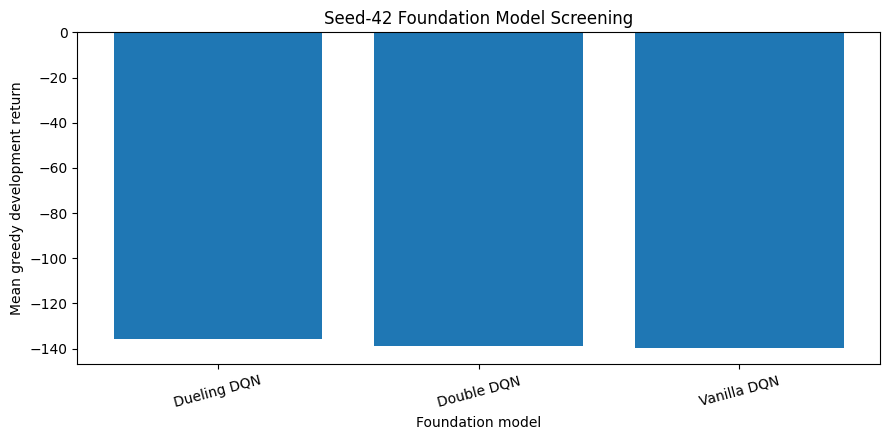

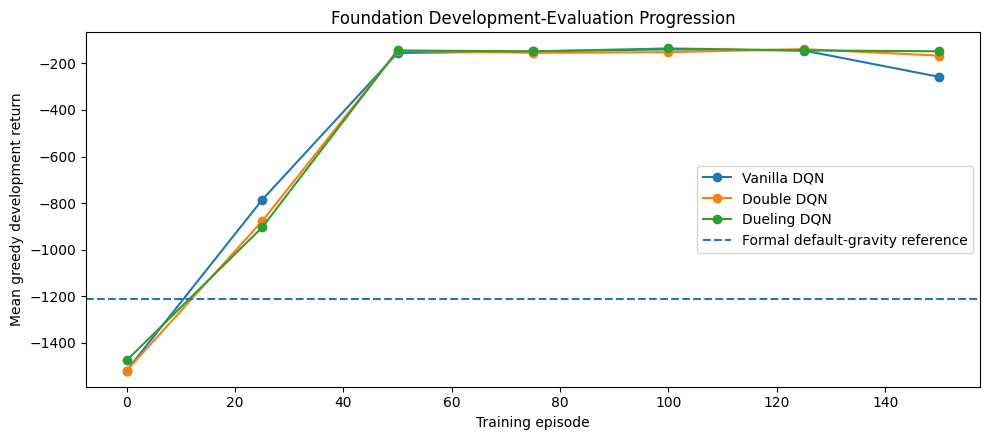

Seed-42 foundation ranking: ['Dueling DQN', 'Double DQN', 'Vanilla DQN']
Seed-42 screening leader: Dueling DQN
Matched confirmation reference: Vanilla DQN
Matched confirmation candidate: Dueling DQN
Candidate-minus-reference mean return: 3.876411152699658
Practical improvement margin: 11.335072315065077
Matched seed-123 confirmation required: True
Formal runs completed: 7
Remaining formal-run capacity: 21
Saved foundation comparison: histories\R40_R41_R42_foundation_comparison.csv
Saved paired foundation comparison: histories\R40_R41_R42_foundation_paired_comparison.csv
Section 9.5 foundation comparison: PASS


In [60]:
FOUNDATION_COMPARISON_PATH = (
    HISTORIES_DIR / "R40_R41_R42_foundation_comparison.csv"
)
FOUNDATION_PAIRED_PATH = (
    HISTORIES_DIR / "R40_R41_R42_foundation_paired_comparison.csv"
)

FOUNDATION_MODEL_ORDER = (
    "Vanilla DQN",
    "Double DQN",
    "Dueling DQN",
)

assert tuple(FOUNDATION_SCREEN_RESULTS.keys()) == (
    FOUNDATION_MODEL_ORDER
)
assert tuple(FOUNDATION_SCREEN_STATE_RESULTS.keys()) == (
    FOUNDATION_MODEL_ORDER
)
assert FORMAL_RUNS_COMPLETED == 7
assert remaining_formal_run_capacity == 21
assert PRACTICAL_IMPROVEMENT_MARGIN_LOCKED is True
assert np.isfinite(FORMAL_DEFAULT_REFERENCE_TARGET)

foundation_evaluation_summaries = {
    "Vanilla DQN": r22_evaluation_summary.copy(),
    "Double DQN": r41_evaluation_summary.copy(),
    "Dueling DQN": r42_evaluation_summary.copy(),
}

# Rebuild and reload each selected checkpoint before calculating Q-value
# diagnostics. The earlier Vanilla action-comparison summary predates these
# diagnostics, so reading selected_mean_q directly from that record caused a
# KeyError. Computing the values from all three saved checkpoints also keeps
# the comparison method identical across architectures.
foundation_q_probe_states = tf.convert_to_tensor(
    np.stack([
        expected_observation(
            float(theta),
            float(theta_dot),
        )
        for theta, theta_dot in DEVELOPMENT_PHYSICAL_STATES
    ]).astype(np.float32),
    dtype=tf.float32,
)

foundation_q_models = {
    "Vanilla DQN": build_standard_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=FOUNDATION_SCREEN_ACTION_COUNT,
        hidden_units=STANDARD_HIDDEN_UNITS,
        model_name="r40_foundation_q_audit_model",
    ),
    "Double DQN": build_standard_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=FOUNDATION_SCREEN_ACTION_COUNT,
        hidden_units=STANDARD_HIDDEN_UNITS,
        model_name="r41_foundation_q_audit_model",
    ),
    "Dueling DQN": build_dueling_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=FOUNDATION_SCREEN_ACTION_COUNT,
        hidden_units=STANDARD_HIDDEN_UNITS,
        model_name="r42_foundation_q_audit_model",
    ),
}

foundation_q_weight_paths = {
    "Vanilla DQN": R22_WEIGHT_PATH,
    "Double DQN": R41_WEIGHT_PATH,
    "Dueling DQN": R42_WEIGHT_PATH,
}

foundation_q_diagnostics = {}

for model_name in FOUNDATION_MODEL_ORDER:
    audit_model = foundation_q_models[model_name]
    audit_weight_path = foundation_q_weight_paths[
        model_name
    ]

    assert audit_weight_path.exists()
    audit_model.load_weights(audit_weight_path)

    audit_q_values = audit_model(
        foundation_q_probe_states,
        training=False,
    ).numpy()

    assert audit_q_values.shape == (
        len(DEVELOPMENT_PHYSICAL_STATES),
        FOUNDATION_SCREEN_ACTION_COUNT,
    )
    assert np.isfinite(audit_q_values).all()

    foundation_q_diagnostics[model_name] = {
        "selected_mean_q": float(
            np.mean(audit_q_values)
        ),
        "selected_max_q": float(
            np.max(audit_q_values)
        ),
        "selected_min_q": float(
            np.min(audit_q_values)
        ),
        "selected_q_span": float(
            np.max(audit_q_values)
            - np.min(audit_q_values)
        ),
    }

assert set(foundation_q_diagnostics.keys()) == set(
    FOUNDATION_MODEL_ORDER
)

foundation_comparison_records = []

for model_name in FOUNDATION_MODEL_ORDER:
    record = FOUNDATION_SCREEN_RESULTS[model_name]
    q_diagnostics = foundation_q_diagnostics[
        model_name
    ]
    evaluation_summary = (
        foundation_evaluation_summaries[model_name]
        .sort_values("episode")
        .reset_index(drop=True)
    )

    assert len(evaluation_summary) == 7
    assert evaluation_summary["episode"].tolist() == [
        0,
        25,
        50,
        75,
        100,
        125,
        150,
    ]

    threshold_rows = evaluation_summary.loc[
        evaluation_summary["mean_development_return"]
        >= FORMAL_DEFAULT_REFERENCE_TARGET
    ]
    first_formal_reference_episode = (
        int(threshold_rows["episode"].iloc[0])
        if len(threshold_rows) > 0
        else np.nan
    )

    selected_episode = int(
        record["selected_checkpoint_episode"]
    )
    selected_evaluation_row = evaluation_summary.loc[
        evaluation_summary["episode"] == selected_episode
    ]
    assert len(selected_evaluation_row) == 1

    final_evaluation_return = float(
        evaluation_summary.loc[
            evaluation_summary["episode"] == 150,
            "mean_development_return",
        ].iloc[0]
    )
    selected_mean_return = float(
        record["mean_development_return"]
    )

    foundation_comparison_records.append({
        "model": model_name,
        "run_id": record["run_id"],
        "seed": int(record["seed"]),
        "selected_checkpoint_episode": selected_episode,
        "mean_development_return": selected_mean_return,
        "development_return_std": float(
            record["development_return_std"]
        ),
        "upright_fraction": float(
            record["upright_fraction"]
        ),
        "mean_abs_angle": float(
            record["mean_abs_angle"]
        ),
        "mean_abs_angular_velocity": float(
            record["mean_abs_angular_velocity"]
        ),
        "mean_abs_torque": float(
            record["mean_abs_torque"]
        ),
        "torque_direction_switching_rate": float(
            record["torque_direction_switching_rate"]
        ),
        "first_episode_above_formal_reference": (
            first_formal_reference_episode
        ),
        "episode_150_development_return": (
            final_evaluation_return
        ),
        "episode_150_minus_selected": float(
            final_evaluation_return
            - selected_mean_return
        ),
        "selected_mean_q": q_diagnostics[
            "selected_mean_q"
        ],
        "selected_max_q": q_diagnostics[
            "selected_max_q"
        ],
        "selected_min_q": q_diagnostics[
            "selected_min_q"
        ],
        "selected_q_span": q_diagnostics[
            "selected_q_span"
        ],
        "runtime_minutes": float(
            record["runtime_minutes"]
        ),
        "parameter_count": int(
            record["parameter_count"]
        ),
        "technical_status": record["technical_status"],
    })

foundation_model_comparison = pd.DataFrame(
    foundation_comparison_records
).sort_values(
    "mean_development_return",
    ascending=False,
).reset_index(drop=True)

assert len(foundation_model_comparison) == 3
assert (
    foundation_model_comparison["technical_status"]
    == "PASS"
).all()
assert (
    foundation_model_comparison["seed"] == 42
).all()
assert np.isfinite(
    foundation_model_comparison[
        [
            "mean_development_return",
            "development_return_std",
            "upright_fraction",
            "mean_abs_angle",
            "mean_abs_angular_velocity",
            "mean_abs_torque",
            "torque_direction_switching_rate",
            "episode_150_development_return",
            "episode_150_minus_selected",
            "selected_mean_q",
            "selected_max_q",
            "selected_min_q",
            "selected_q_span",
            "runtime_minutes",
            "parameter_count",
        ]
    ].to_numpy(dtype=np.float64)
).all()

foundation_paired_records = []

for reference_model, candidate_model in [
    ("Vanilla DQN", "Double DQN"),
    ("Vanilla DQN", "Dueling DQN"),
    ("Double DQN", "Dueling DQN"),
]:
    reference_states = (
        FOUNDATION_SCREEN_STATE_RESULTS[
            reference_model
        ][["state_id", "return"]]
        .rename(
            columns={
                "return": "reference_return"
            }
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )
    candidate_states = (
        FOUNDATION_SCREEN_STATE_RESULTS[
            candidate_model
        ][["state_id", "return"]]
        .rename(
            columns={
                "return": "candidate_return"
            }
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )

    paired = reference_states.merge(
        candidate_states,
        on="state_id",
        how="inner",
        validate="one_to_one",
    )

    assert len(paired) == len(
        DEVELOPMENT_PHYSICAL_STATES
    )
    assert np.array_equal(
        paired["state_id"].to_numpy(),
        np.arange(len(DEVELOPMENT_PHYSICAL_STATES)),
    )

    paired["candidate_minus_reference"] = (
        paired["candidate_return"]
        - paired["reference_return"]
    )

    mean_difference = float(
        paired["candidate_minus_reference"].mean()
    )

    foundation_paired_records.append({
        "reference_model": reference_model,
        "candidate_model": candidate_model,
        "seed": FOUNDATION_SCREEN_SEED,
        "paired_state_count": int(len(paired)),
        "mean_return_difference": mean_difference,
        "median_return_difference": float(
            paired[
                "candidate_minus_reference"
            ].median()
        ),
        "candidate_win_proportion": float(
            (
                paired[
                    "candidate_minus_reference"
                ] > 0.0
            ).mean()
        ),
        "reference_win_proportion": float(
            (
                paired[
                    "candidate_minus_reference"
                ] < 0.0
            ).mean()
        ),
        "exact_tie_proportion": float(
            np.isclose(
                paired[
                    "candidate_minus_reference"
                ],
                0.0,
                rtol=0.0,
                atol=1e-10,
            ).mean()
        ),
        "minimum_paired_difference": float(
            paired[
                "candidate_minus_reference"
            ].min()
        ),
        "maximum_paired_difference": float(
            paired[
                "candidate_minus_reference"
            ].max()
        ),
        "within_practical_improvement_margin": bool(
            abs(mean_difference)
            <= PRACTICAL_IMPROVEMENT_MARGIN
        ),
    })

foundation_paired_comparison = pd.DataFrame(
    foundation_paired_records
)

assert len(foundation_paired_comparison) == 3
assert (
    foundation_paired_comparison[
        "paired_state_count"
    ] == len(DEVELOPMENT_PHYSICAL_STATES)
).all()
assert np.isfinite(
    foundation_paired_comparison[
        [
            "mean_return_difference",
            "median_return_difference",
            "candidate_win_proportion",
            "reference_win_proportion",
            "exact_tie_proportion",
            "minimum_paired_difference",
            "maximum_paired_difference",
        ]
    ].to_numpy(dtype=np.float64)
).all()

FOUNDATION_SEED_42_RANKING = (
    foundation_model_comparison["model"].tolist()
)
FOUNDATION_SCREENING_LEADER = (
    FOUNDATION_SEED_42_RANKING[0]
)
FOUNDATION_CONFIRMATION_REFERENCE = "Vanilla DQN"
FOUNDATION_CONFIRMATION_CANDIDATE = (
    FOUNDATION_SCREENING_LEADER
    if FOUNDATION_SCREENING_LEADER
    != FOUNDATION_CONFIRMATION_REFERENCE
    else FOUNDATION_SEED_42_RANKING[1]
)

confirmation_pair_row = (
    foundation_paired_comparison.loc[
        (
            foundation_paired_comparison[
                "reference_model"
            ] == FOUNDATION_CONFIRMATION_REFERENCE
        )
        & (
            foundation_paired_comparison[
                "candidate_model"
            ] == FOUNDATION_CONFIRMATION_CANDIDATE
        )
    ]
)

if len(confirmation_pair_row) == 0:
    confirmation_pair_row = (
        foundation_paired_comparison.loc[
            (
                foundation_paired_comparison[
                    "reference_model"
                ] == FOUNDATION_CONFIRMATION_CANDIDATE
            )
            & (
                foundation_paired_comparison[
                    "candidate_model"
                ] == FOUNDATION_CONFIRMATION_REFERENCE
            )
        ].copy()
    )
    assert len(confirmation_pair_row) == 1
    confirmation_mean_difference = -float(
        confirmation_pair_row.iloc[0][
            "mean_return_difference"
        ]
    )
else:
    assert len(confirmation_pair_row) == 1
    confirmation_mean_difference = float(
        confirmation_pair_row.iloc[0][
            "mean_return_difference"
        ]
    )

FOUNDATION_MATCHED_CONFIRMATION_REQUIRED = bool(
    abs(confirmation_mean_difference)
    <= PRACTICAL_IMPROVEMENT_MARGIN
)

assert FOUNDATION_MATCHED_CONFIRMATION_REQUIRED is True
assert FORMAL_RUNS_COMPLETED == 7
assert remaining_formal_run_capacity == 21

foundation_model_comparison.to_csv(
    FOUNDATION_COMPARISON_PATH,
    index=False,
)
foundation_paired_comparison.to_csv(
    FOUNDATION_PAIRED_PATH,
    index=False,
)

display(foundation_model_comparison)
display(foundation_paired_comparison)

plt.figure(figsize=(9, 4.5))
plt.bar(
    foundation_model_comparison["model"],
    foundation_model_comparison[
        "mean_development_return"
    ],
)
plt.xlabel("Foundation model")
plt.ylabel("Mean greedy development return")
plt.title("Seed-42 Foundation Model Screening")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
for model_name in FOUNDATION_MODEL_ORDER:
    evaluation_summary = (
        foundation_evaluation_summaries[model_name]
        .sort_values("episode")
    )
    plt.plot(
        evaluation_summary["episode"],
        evaluation_summary[
            "mean_development_return"
        ],
        marker="o",
        label=model_name,
    )
plt.axhline(
    FORMAL_DEFAULT_REFERENCE_TARGET,
    linestyle="--",
    label="Formal default-gravity reference",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("Foundation Development-Evaluation Progression")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Seed-42 foundation ranking:",
    FOUNDATION_SEED_42_RANKING,
)
print(
    "Seed-42 screening leader:",
    FOUNDATION_SCREENING_LEADER,
)
print(
    "Matched confirmation reference:",
    FOUNDATION_CONFIRMATION_REFERENCE,
)
print(
    "Matched confirmation candidate:",
    FOUNDATION_CONFIRMATION_CANDIDATE,
)
print(
    "Candidate-minus-reference mean return:",
    confirmation_mean_difference,
)
print(
    "Practical improvement margin:",
    PRACTICAL_IMPROVEMENT_MARGIN,
)
print(
    "Matched seed-123 confirmation required:",
    FOUNDATION_MATCHED_CONFIRMATION_REQUIRED,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved foundation comparison:",
    FOUNDATION_COMPARISON_PATH,
)
print(
    "Saved paired foundation comparison:",
    FOUNDATION_PAIRED_PATH,
)
print("Section 9.5 foundation comparison: PASS")


### 9.5 Result Interpretation

**Finding.** The seed-42 foundation ranking was:

1. Dueling DQN: `-135.942190`;
2. Double DQN: `-138.757723`;
3. Vanilla DQN: `-139.818601`.

Dueling DQN led Vanilla by `3.876411` mean return and won on `87.5%` of the
paired development states. It also had the lowest state-wise return standard
deviation (`99.338244`) and matched Vanilla's upright fraction (`0.872292`).

Double DQN led Vanilla by `1.060878` and won on `70.8333%` of states, but
Dueling DQN subsequently led Double DQN by `2.815533` and won on `83.3333%`
of states.

All three pairwise mean differences remained inside the locked practical
improvement margin of `11.335072`.

**Importance.** Dueling DQN is the strongest seed-42 candidate across the
primary return criterion and paired-state evidence. However, the advantage is
not large enough to distinguish architecture benefit from ordinary
training-seed variation.

**Decision.** Shortlist Dueling DQN for matched seed-123 confirmation against
Vanilla DQN. Double DQN remains valid evidence but is not the confirmation
candidate because Dueling DQN ranked above it on return, state-wise spread and
paired wins.

**Caveat.** Dueling DQN was the slowest run and used `65` more parameters than
Vanilla and Double DQN. The additional seed must show that its advantage is not
restricted to seed `42`.

**Next step.** Reuse the completed seed-123 Vanilla run and train one fresh
seed-123 Dueling DQN under identical conditions.


## 9.6 Seed-123 Confirmation

**Question.** Does Dueling DQN retain its seed-42 advantage when both Dueling
and Vanilla DQN are compared under seed `123`?

**Reference.** The completed seven-action Vanilla calibration run:

```text
R30_VANILLA_SEED_123
```

**Candidate.** One fresh Dueling DQN run:

```text
R42_DUELING_SEED_123
```

**Primary change.** Architecture only. Both policies use seed `123`, the same
seven-action set, default gravity, `150` episodes, replay settings, epsilon
schedule, optimiser, gamma, target-update schedule, checkpoint rule and fixed
development states.

**Evidence.**

- seed-123 candidate-minus-reference mean return;
- paired differences on the same `24` states;
- two-seed mean returns using seeds `42` and `123`;
- per-seed paired win proportions;
- state-wise spread and control metrics;
- runtime and parameter count.

This consumes one fresh formal training run. After completion, the formal-run
count should be `8`, leaving `20` runs under the approved cap.

No foundation is selected until the matched confirmation output is reviewed.


Loaded completed seed-123 Dueling confirmation artifacts; no duplicate training run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1513.180553,-1531.216662,216.799448,-1816.480863,-1124.922449,0.005208,2.570358,1.452520,1.181250,0.043551
1,25,-150.717350,-128.864597,110.915180,-381.002092,-0.592810,0.849167,0.261791,0.585972,1.147361,0.457705
2,50,-144.036793,-125.059867,110.655505,-360.321616,-0.032857,0.861250,0.241704,0.508072,0.571111,0.465452
3,75,-144.918543,-125.336544,107.124871,-352.146724,-1.387282,0.869375,0.286171,0.531671,1.109583,0.655151
4,100,-145.577562,-125.020473,109.011171,-348.710809,-0.938677,0.867292,0.264135,0.560900,1.070417,0.782873
5,125,-148.606376,-127.228875,112.064322,-363.213262,-1.798105,0.866458,0.296662,0.564427,1.129861,0.352178
6,150,-138.522287,-126.865918,102.394330,-360.048267,-0.807052,0.866667,0.276711,0.480840,0.499583,0.643216


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,selected_mean_q,selected_max_q,selected_min_q,random_actions,greedy_actions,target_updates,runtime_minutes,parameter_count,weight_path,technical_status
0,R42_DUELING_SEED_123,R42_DUELING_SEED_123,False,True,Dueling DQN,default,123,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,-96.67244,30.735909,-235.338043,11044,18956,116,11.734233,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS


,seed,reference_model,candidate_model,reference_mean_return,candidate_mean_return,candidate_minus_reference,reference_state_std,candidate_state_std,reference_upright_fraction,candidate_upright_fraction,paired_state_count,paired_median_difference,candidate_win_proportion,reference_win_proportion,exact_tie_proportion,minimum_paired_difference,maximum_paired_difference,within_practical_margin
0,42,Vanilla DQN,Dueling DQN,-139.818601,-135.942190,3.876411,101.098652,99.338244,0.872292,0.872292,24,2.114389,0.875,0.125,0.0,-18.479893,67.423442,True
1,123,Vanilla DQN,Dueling DQN,-139.911774,-138.522287,1.389487,102.520132,102.394330,0.869167,0.866667,24,0.907687,0.750,0.250,0.0,-16.435485,11.495308,True


,matched_seeds,reference_model,candidate_model,reference_mean_across_seeds,candidate_mean_across_seeds,candidate_minus_reference_across_seed_means,mean_of_seed_level_differences,minimum_seed_level_difference,maximum_seed_level_difference,candidate_seed_win_count,reference_seed_win_count,practical_improvement_margin,aggregate_difference_within_margin,formal_significance_claim,selection_deferred_until_review
0,"[42, 123]",Vanilla DQN,Dueling DQN,-139.865188,-137.232239,2.632949,2.632949,1.389487,3.876411,2,0,11.335072,True,False,True


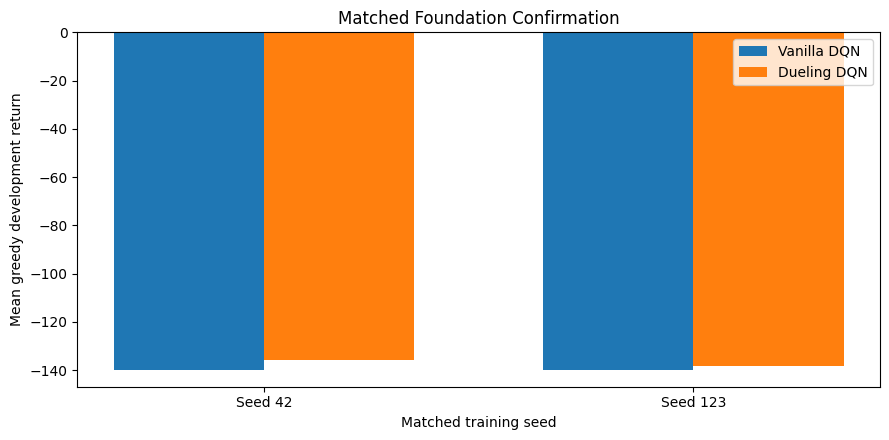

Dueling seed-123 run completed: True
Selected checkpoint episode: 150
Seed-123 Dueling mean development return: -138.52228717953105
Seed-123 Vanilla mean development return: -139.91177448918384
Seed-123 Dueling-minus-Vanilla: 1.389487309652793
Matched two-seed Dueling-minus-Vanilla: 2.6329492311762124
Dueling seed win count: 2
Aggregate difference within practical margin: True
Formal runs completed: 8
Remaining formal-run capacity: 20
Saved matched confirmation: histories\R40_R42_matched_seed_confirmation.csv
Saved confirmation aggregate: histories\R40_R42_matched_seed_confirmation_aggregate.csv
Section 9.6 matched seed-123 confirmation: COMPLETE


In [61]:
R42_CONFIRMATION_SEED = 123
R42_CONFIRMATION_RUN_ID = "R42_DUELING_SEED_123"

R42_CONFIRMATION_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R42_CONFIRMATION_RUN_ID}_best.weights.h5"
)
R42_CONFIRMATION_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{R42_CONFIRMATION_RUN_ID}_history.csv"
)
R42_CONFIRMATION_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{R42_CONFIRMATION_RUN_ID}"
        "_development_evaluations.csv"
    )
)
R42_CONFIRMATION_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R42_CONFIRMATION_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
R42_CONFIRMATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R42_CONFIRMATION_RUN_ID}_summary.csv"
)
R42_CONFIRMATION_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{R42_CONFIRMATION_RUN_ID}"
        "_selected_state_results.csv"
    )
)
FOUNDATION_CONFIRMATION_COMPARISON_PATH = (
    HISTORIES_DIR
    / "R40_R42_matched_seed_confirmation.csv"
)
FOUNDATION_CONFIRMATION_AGGREGATE_PATH = (
    HISTORIES_DIR
    / "R40_R42_matched_seed_confirmation_aggregate.csv"
)

assert FOUNDATION_SCREENING_LEADER == "Dueling DQN"
assert FOUNDATION_CONFIRMATION_REFERENCE == "Vanilla DQN"
assert FOUNDATION_CONFIRMATION_CANDIDATE == "Dueling DQN"
assert FOUNDATION_MATCHED_CONFIRMATION_REQUIRED is True
assert LOCKED_FOUNDATION_CONFIRMATION_SEED == 123
assert R42_CONFIRMATION_SEED == 123
assert FORMAL_RUNS_COMPLETED in (7, 8)
assert remaining_formal_run_capacity in (21, 20)
assert FORMAL_RUNS_COMPLETED < APPROVED_HARD_FORMAL_RUN_CAP

r42_confirmation_required_artifacts = [
    R42_CONFIRMATION_WEIGHT_PATH,
    R42_CONFIRMATION_HISTORY_PATH,
    R42_CONFIRMATION_EVALUATION_PATH,
    R42_CONFIRMATION_EVALUATION_SUMMARY_PATH,
    R42_CONFIRMATION_SUMMARY_PATH,
    R42_CONFIRMATION_STATE_RESULTS_PATH,
]
r42_confirmation_artifacts_complete = all(
    path.exists()
    for path in r42_confirmation_required_artifacts
)

if (
    "r42_confirmation_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "r42_confirmation_history",
            "r42_confirmation_evaluation_states",
            "r42_confirmation_evaluation_summary",
            "r42_confirmation_selected_state_results",
            "r42_confirmation_summary",
        ]
    )
):
    print(
        "Seed-123 Dueling confirmation result already exists in memory; "
        "no duplicate training run was started."
    )
elif r42_confirmation_artifacts_complete:
    r42_confirmation_history = read_csv_with_control_metric_migration(
        R42_CONFIRMATION_HISTORY_PATH
    )
    r42_confirmation_evaluation_states = read_csv_with_control_metric_migration(
        R42_CONFIRMATION_EVALUATION_PATH
    )
    r42_confirmation_evaluation_summary = read_csv_with_control_metric_migration(
        R42_CONFIRMATION_EVALUATION_SUMMARY_PATH
    )
    r42_confirmation_summary = read_csv_with_control_metric_migration(
        R42_CONFIRMATION_SUMMARY_PATH
    )
    r42_confirmation_selected_state_results = read_csv_with_control_metric_migration(
        R42_CONFIRMATION_STATE_RESULTS_PATH
    )

    assert len(r42_confirmation_summary) == 1
    r42_confirmation_summary_record = (
        r42_confirmation_summary.iloc[0].to_dict()
    )

    r42_confirmation_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FOUNDATION_SCREEN_ACTION_COUNT,
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r42_dueling_seed_123_reloaded_q_network"
            ),
        )
    )
    r42_confirmation_selected_model.load_weights(
        R42_CONFIRMATION_WEIGHT_PATH
    )
    print(
        "Loaded completed seed-123 Dueling confirmation artifacts; "
        "no duplicate training run was started."
    )
else:
    r42_confirmation_result = run_dueling_dqn_foundation(
        run_id=R42_CONFIRMATION_RUN_ID,
        torque_values=FOUNDATION_SCREEN_TORQUE_VALUES,
        seed=R42_CONFIRMATION_SEED,
        weight_path=R42_CONFIRMATION_WEIGHT_PATH,
    )

    r42_confirmation_history = (
        r42_confirmation_result["history"]
    )
    r42_confirmation_evaluation_states = (
        r42_confirmation_result["evaluation_states"]
    )
    r42_confirmation_evaluation_summary = (
        r42_confirmation_result["evaluation_summary"]
    )
    r42_confirmation_selected_state_results = (
        r42_confirmation_result[
            "selected_state_results"
        ]
    )
    r42_confirmation_selected_model = (
        r42_confirmation_result["selected_model"]
    )
    r42_confirmation_summary_record = (
        r42_confirmation_result["summary_record"]
    )
    r42_confirmation_summary = pd.DataFrame(
        [r42_confirmation_summary_record]
    )

FORMAL_RUNS_COMPLETED = 8
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 8
assert remaining_formal_run_capacity == 20
assert len(r42_confirmation_history) == (
    FOUNDATION_SCREEN_EPISODES
)
assert len(r42_confirmation_evaluation_summary) == 7
assert int(
    r42_confirmation_summary_record["seed"]
) == R42_CONFIRMATION_SEED
assert (
    r42_confirmation_summary_record["model"]
    == "Dueling DQN"
)
assert int(
    r42_confirmation_summary_record["action_count"]
) == FOUNDATION_SCREEN_ACTION_COUNT
assert int(
    r42_confirmation_summary_record["parameter_count"]
) == 4936
assert int(
    r42_confirmation_summary_record["environment_steps"]
) == 30_000
assert int(
    r42_confirmation_summary_record["optimizer_updates"]
) == 29_001
assert int(
    r42_confirmation_summary_record["target_updates"]
) == 116
assert np.isfinite(
    r42_confirmation_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert R42_CONFIRMATION_WEIGHT_PATH.exists()

r42_confirmation_history.to_csv(
    R42_CONFIRMATION_HISTORY_PATH,
    index=False,
)
r42_confirmation_evaluation_states.to_csv(
    R42_CONFIRMATION_EVALUATION_PATH,
    index=False,
)
r42_confirmation_evaluation_summary.to_csv(
    R42_CONFIRMATION_EVALUATION_SUMMARY_PATH,
    index=False,
)
r42_confirmation_summary.to_csv(
    R42_CONFIRMATION_SUMMARY_PATH,
    index=False,
)
r42_confirmation_selected_state_results.to_csv(
    R42_CONFIRMATION_STATE_RESULTS_PATH,
    index=False,
)

matched_seed_sources = {
    42: {
        "reference_summary": r40_summary_record,
        "candidate_summary": r42_summary_record,
        "reference_states": (
            FOUNDATION_SCREEN_STATE_RESULTS[
                "Vanilla DQN"
            ].copy()
        ),
        "candidate_states": (
            FOUNDATION_SCREEN_STATE_RESULTS[
                "Dueling DQN"
            ].copy()
        ),
    },
    123: {
        "reference_summary": r30_seed_123_summary_record,
        "candidate_summary": r42_confirmation_summary_record,
        "reference_states": (
            r30_seed_123_selected_state_results.copy()
        ),
        "candidate_states": (
            r42_confirmation_selected_state_results.copy()
        ),
    },
}

foundation_confirmation_records = []

for seed in (42, 123):
    source = matched_seed_sources[seed]
    reference_summary = source["reference_summary"]
    candidate_summary = source["candidate_summary"]

    reference_states = (
        source["reference_states"]
        [["state_id", "return"]]
        .rename(columns={"return": "vanilla_return"})
        .sort_values("state_id")
        .reset_index(drop=True)
    )
    candidate_states = (
        source["candidate_states"]
        [["state_id", "return"]]
        .rename(columns={"return": "dueling_return"})
        .sort_values("state_id")
        .reset_index(drop=True)
    )

    paired = reference_states.merge(
        candidate_states,
        on="state_id",
        how="inner",
        validate="one_to_one",
    )
    assert len(paired) == len(
        DEVELOPMENT_PHYSICAL_STATES
    )

    paired["dueling_minus_vanilla"] = (
        paired["dueling_return"]
        - paired["vanilla_return"]
    )

    reference_mean = float(
        reference_summary["mean_development_return"]
    )
    candidate_mean = float(
        candidate_summary["mean_development_return"]
    )
    mean_difference = float(
        candidate_mean - reference_mean
    )

    np.testing.assert_allclose(
        mean_difference,
        paired["dueling_minus_vanilla"].mean(),
        rtol=0.0,
        atol=1e-6,
    )

    foundation_confirmation_records.append({
        "seed": int(seed),
        "reference_model": "Vanilla DQN",
        "candidate_model": "Dueling DQN",
        "reference_mean_return": reference_mean,
        "candidate_mean_return": candidate_mean,
        "candidate_minus_reference": mean_difference,
        "reference_state_std": float(
            reference_summary["development_return_std"]
        ),
        "candidate_state_std": float(
            candidate_summary["development_return_std"]
        ),
        "reference_upright_fraction": float(
            reference_summary["upright_fraction"]
        ),
        "candidate_upright_fraction": float(
            candidate_summary["upright_fraction"]
        ),
        "paired_state_count": int(len(paired)),
        "paired_median_difference": float(
            paired["dueling_minus_vanilla"].median()
        ),
        "candidate_win_proportion": float(
            (
                paired["dueling_minus_vanilla"] > 0.0
            ).mean()
        ),
        "reference_win_proportion": float(
            (
                paired["dueling_minus_vanilla"] < 0.0
            ).mean()
        ),
        "exact_tie_proportion": float(
            np.isclose(
                paired["dueling_minus_vanilla"],
                0.0,
                rtol=0.0,
                atol=1e-10,
            ).mean()
        ),
        "minimum_paired_difference": float(
            paired["dueling_minus_vanilla"].min()
        ),
        "maximum_paired_difference": float(
            paired["dueling_minus_vanilla"].max()
        ),
        "within_practical_margin": bool(
            abs(mean_difference)
            <= PRACTICAL_IMPROVEMENT_MARGIN
        ),
    })

foundation_matched_confirmation = pd.DataFrame(
    foundation_confirmation_records
).sort_values("seed").reset_index(drop=True)

reference_seed_means = foundation_matched_confirmation[
    "reference_mean_return"
].to_numpy(dtype=np.float64)
candidate_seed_means = foundation_matched_confirmation[
    "candidate_mean_return"
].to_numpy(dtype=np.float64)
seed_level_differences = foundation_matched_confirmation[
    "candidate_minus_reference"
].to_numpy(dtype=np.float64)

foundation_confirmation_aggregate_record = {
    "matched_seeds": [42, 123],
    "reference_model": "Vanilla DQN",
    "candidate_model": "Dueling DQN",
    "reference_mean_across_seeds": float(
        np.mean(reference_seed_means)
    ),
    "candidate_mean_across_seeds": float(
        np.mean(candidate_seed_means)
    ),
    "candidate_minus_reference_across_seed_means": float(
        np.mean(candidate_seed_means)
        - np.mean(reference_seed_means)
    ),
    "mean_of_seed_level_differences": float(
        np.mean(seed_level_differences)
    ),
    "minimum_seed_level_difference": float(
        np.min(seed_level_differences)
    ),
    "maximum_seed_level_difference": float(
        np.max(seed_level_differences)
    ),
    "candidate_seed_win_count": int(
        np.sum(seed_level_differences > 0.0)
    ),
    "reference_seed_win_count": int(
        np.sum(seed_level_differences < 0.0)
    ),
    "practical_improvement_margin": float(
        PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "aggregate_difference_within_margin": bool(
        abs(np.mean(seed_level_differences))
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "formal_significance_claim": False,
    "selection_deferred_until_review": True,
}

foundation_confirmation_aggregate = pd.DataFrame(
    [foundation_confirmation_aggregate_record]
)

assert len(foundation_matched_confirmation) == 2
assert foundation_matched_confirmation[
    "seed"
].tolist() == [42, 123]
assert (
    foundation_matched_confirmation[
        "paired_state_count"
    ] == len(DEVELOPMENT_PHYSICAL_STATES)
).all()
assert np.isfinite(
    foundation_matched_confirmation.select_dtypes(
        include=[np.number]
    ).to_numpy(dtype=np.float64)
).all()
assert np.isclose(
    foundation_confirmation_aggregate_record[
        "candidate_minus_reference_across_seed_means"
    ],
    foundation_confirmation_aggregate_record[
        "mean_of_seed_level_differences"
    ],
    rtol=0.0,
    atol=1e-12,
)
assert (
    foundation_confirmation_aggregate_record[
        "selection_deferred_until_review"
    ] is True
)
assert FORMAL_RUNS_COMPLETED == 8
assert remaining_formal_run_capacity == 20

foundation_matched_confirmation.to_csv(
    FOUNDATION_CONFIRMATION_COMPARISON_PATH,
    index=False,
)
foundation_confirmation_aggregate.to_csv(
    FOUNDATION_CONFIRMATION_AGGREGATE_PATH,
    index=False,
)

display(r42_confirmation_evaluation_summary)
display(r42_confirmation_summary)
display(foundation_matched_confirmation)
display(foundation_confirmation_aggregate)

plt.figure(figsize=(9, 4.5))
x_positions = np.arange(2)
bar_width = 0.35
plt.bar(
    x_positions - bar_width / 2,
    reference_seed_means,
    width=bar_width,
    label="Vanilla DQN",
)
plt.bar(
    x_positions + bar_width / 2,
    candidate_seed_means,
    width=bar_width,
    label="Dueling DQN",
)
plt.xticks(x_positions, ["Seed 42", "Seed 123"])
plt.xlabel("Matched training seed")
plt.ylabel("Mean greedy development return")
plt.title("Matched Foundation Confirmation")
plt.legend()
plt.tight_layout()
plt.show()

print("Dueling seed-123 run completed:", True)
print(
    "Selected checkpoint episode:",
    r42_confirmation_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Seed-123 Dueling mean development return:",
    r42_confirmation_summary_record[
        "mean_development_return"
    ],
)
print(
    "Seed-123 Vanilla mean development return:",
    r30_seed_123_summary_record[
        "mean_development_return"
    ],
)
print(
    "Seed-123 Dueling-minus-Vanilla:",
    foundation_matched_confirmation.loc[
        foundation_matched_confirmation["seed"] == 123,
        "candidate_minus_reference",
    ].iloc[0],
)
print(
    "Matched two-seed Dueling-minus-Vanilla:",
    foundation_confirmation_aggregate_record[
        "candidate_minus_reference_across_seed_means"
    ],
)
print(
    "Dueling seed win count:",
    foundation_confirmation_aggregate_record[
        "candidate_seed_win_count"
    ],
)
print(
    "Aggregate difference within practical margin:",
    foundation_confirmation_aggregate_record[
        "aggregate_difference_within_margin"
    ],
)
print("Formal runs completed:", FORMAL_RUNS_COMPLETED)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved matched confirmation:",
    FOUNDATION_CONFIRMATION_COMPARISON_PATH,
)
print(
    "Saved confirmation aggregate:",
    FOUNDATION_CONFIRMATION_AGGREGATE_PATH,
)
print("Section 9.6 matched seed-123 confirmation: COMPLETE")


### 9.6 Result Interpretation

**Finding.** Dueling DQN retained a positive advantage over Vanilla DQN under
the matched seed-123 confirmation.

| Seed | Vanilla mean return | Dueling mean return | Dueling minus Vanilla | Dueling paired-state wins |
|---|---:|---:|---:|---:|
| `42` | `-139.818601` | `-135.942190` | `+3.876411` | `87.5%` |
| `123` | `-139.911774` | `-138.522287` | `+1.389487` | `75.0%` |

Across the two matched seeds, Dueling DQN averaged `-137.232239`, compared
with `-139.865188` for Vanilla DQN. The resulting advantage was `2.632949`.
Dueling won both seed-level comparisons and had slightly lower state-wise
return spread under both seeds.

**Importance.** The direction of the result was consistent across two
independent training seeds. This reduces the likelihood that the seed-42
ranking was caused by one unusually favourable Dueling run.

**Decision.** Treat Dueling DQN as the leading foundation candidate. The
difference remains inside the locked `11.335072` practical margin, so the
selection must rely on the predeclared tie-break hierarchy rather than a claim
of statistically significant superiority.

**Caveat.** Dueling DQN had a slightly lower upright fraction under seed `123`,
trained more slowly, and used `65` additional parameters. Its advantage is
small and should not be described as conclusive proof that Dueling DQN is
universally better.

**Next step.** Apply the conditional Double Dueling gate, then lock the
foundation architecture.


## 9.7 Conditional Double Dueling DQN

Double Dueling DQN is **not approved** for the foundation screen.

The condition for combining Double and Dueling mechanisms was that both
components should provide useful independent evidence and that their
combination should answer a clear unresolved question.

Dueling DQN produced the strongest and most consistent evidence. Double DQN
improved on Vanilla by only `1.060878` under seed `42`, remained inside the
practical margin, and was not the shortlisted confirmation candidate.
Combining the mechanisms would therefore change two ideas without sufficient
evidence that the Double target contributes an additional benefit.

**Decision:** Skip `R43_DOUBLE_DUELING`. Preserve the formal-run budget for the
required improvement recipes, final confirmation and four-gravity study.


## 9.8 Foundation Selection

The foundation is selected using the locked hierarchy:

1. mean greedy development return;
2. stability and failure frequency when results are practically close;
3. sample efficiency;
4. simplicity, runtime and reproducibility.

Dueling DQN and Vanilla DQN are practically close because their matched
two-seed difference is within `11.335072`. Dueling is selected because:

- it achieved the higher mean return under both matched seeds;
- it won most paired development states under both seeds;
- it had lower state-wise return spread under both seeds;
- neither Dueling run failed technically.

Vanilla remains the simpler and faster alternative, and its sample efficiency
was better under seed `123`. These trade-offs remain visible and will be
revisited during diagnosis and later controlled experiments.


**Figure interpretation guide:** The foundation figures compare Vanilla, Double and Dueling DQN under matched conditions. Return is primary; Q-value behaviour and control metrics explain the result rather than replacing it.


In [62]:
FOUNDATION_SELECTION_PATH = (
    HISTORIES_DIR / "R40_R42_foundation_selection.csv"
)

DOUBLE_DUELING_APPROVED = False
DOUBLE_DUELING_DECISION = (
    "SKIP: Double DQN did not provide sufficient independent "
    "evidence to justify combining two mechanisms."
)

SELECTED_FOUNDATION_NAME = "Dueling DQN"
SELECTED_FOUNDATION_RUN_ID = R42_RUN_ID
SELECTED_FOUNDATION_SEED = FOUNDATION_SCREEN_SEED
SELECTED_FOUNDATION_WEIGHT_PATH = R42_WEIGHT_PATH
SELECTED_FOUNDATION_PARAMETER_COUNT = 4936
SELECTED_FOUNDATION_BUILDER = build_dueling_q_network
SELECTED_FOUNDATION_GRADIENT_UPDATE = (
    vanilla_dqn_gradient_update
)

confirmation_table = (
    foundation_matched_confirmation
    .sort_values("seed")
    .reset_index(drop=True)
)

reference_mean_across_seeds = float(
    confirmation_table["reference_mean_return"].mean()
)
candidate_mean_across_seeds = float(
    confirmation_table["candidate_mean_return"].mean()
)
candidate_minus_reference = float(
    candidate_mean_across_seeds
    - reference_mean_across_seeds
)

reference_average_state_std = float(
    confirmation_table["reference_state_std"].mean()
)
candidate_average_state_std = float(
    confirmation_table["candidate_state_std"].mean()
)

reference_average_upright = float(
    confirmation_table[
        "reference_upright_fraction"
    ].mean()
)
candidate_average_upright = float(
    confirmation_table[
        "candidate_upright_fraction"
    ].mean()
)

candidate_average_paired_win_rate = float(
    confirmation_table[
        "candidate_win_proportion"
    ].mean()
)

foundation_selection_record = {
    "selected_foundation": SELECTED_FOUNDATION_NAME,
    "selected_run_id": SELECTED_FOUNDATION_RUN_ID,
    "reference_foundation": "Vanilla DQN",
    "matched_seeds": [42, 123],
    "reference_mean_across_seeds": (
        reference_mean_across_seeds
    ),
    "candidate_mean_across_seeds": (
        candidate_mean_across_seeds
    ),
    "candidate_minus_reference": (
        candidate_minus_reference
    ),
    "practical_improvement_margin": float(
        PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "difference_within_practical_margin": bool(
        abs(candidate_minus_reference)
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "candidate_seed_win_count": int(
        (
            confirmation_table[
                "candidate_minus_reference"
            ] > 0.0
        ).sum()
    ),
    "reference_seed_win_count": int(
        (
            confirmation_table[
                "candidate_minus_reference"
            ] < 0.0
        ).sum()
    ),
    "candidate_average_paired_win_rate": (
        candidate_average_paired_win_rate
    ),
    "reference_average_state_std": (
        reference_average_state_std
    ),
    "candidate_average_state_std": (
        candidate_average_state_std
    ),
    "reference_average_upright_fraction": (
        reference_average_upright
    ),
    "candidate_average_upright_fraction": (
        candidate_average_upright
    ),
    "stability_tie_break_winner": "Dueling DQN",
    "sample_efficiency_tie_break": "Mixed",
    "simplicity_runtime_tie_break_winner": (
        "Vanilla DQN"
    ),
    "double_dueling_approved": (
        DOUBLE_DUELING_APPROVED
    ),
    "formal_significance_claim": False,
    "selection_status": "LOCKED FOR DIAGNOSIS",
}

foundation_selection_summary = pd.DataFrame(
    [foundation_selection_record]
)

assert SELECTED_FOUNDATION_NAME == "Dueling DQN"
assert SELECTED_FOUNDATION_RUN_ID == "R42_DUELING"
assert SELECTED_FOUNDATION_SEED == 42
assert SELECTED_FOUNDATION_WEIGHT_PATH.exists()
assert SELECTED_FOUNDATION_PARAMETER_COUNT == 4936
assert DOUBLE_DUELING_APPROVED is False
assert confirmation_table["seed"].tolist() == [42, 123]
assert (
    foundation_selection_record[
        "candidate_seed_win_count"
    ] == 2
)
assert (
    foundation_selection_record[
        "reference_seed_win_count"
    ] == 0
)
assert (
    candidate_average_state_std
    < reference_average_state_std
)
assert (
    foundation_selection_record[
        "difference_within_practical_margin"
    ] is True
)
assert (
    foundation_selection_record[
        "formal_significance_claim"
    ] is False
)
assert FORMAL_RUNS_COMPLETED == 8
assert remaining_formal_run_capacity == 20

foundation_selection_summary.to_csv(
    FOUNDATION_SELECTION_PATH,
    index=False,
)

display(foundation_selection_summary)

print(
    "Selected foundation:",
    SELECTED_FOUNDATION_NAME,
)
print(
    "Matched seeds:",
    foundation_selection_record["matched_seeds"],
)
print(
    "Dueling-minus-Vanilla across matched seeds:",
    candidate_minus_reference,
)
print(
    "Dueling seed win count:",
    foundation_selection_record[
        "candidate_seed_win_count"
    ],
)
print(
    "Average paired-state win rate:",
    candidate_average_paired_win_rate,
)
print(
    "Average state-wise standard deviation, Vanilla:",
    reference_average_state_std,
)
print(
    "Average state-wise standard deviation, Dueling:",
    candidate_average_state_std,
)
print(
    "Difference within practical margin:",
    foundation_selection_record[
        "difference_within_practical_margin"
    ],
)
print(
    "Double Dueling approved:",
    DOUBLE_DUELING_APPROVED,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved foundation selection:",
    FOUNDATION_SELECTION_PATH,
)
print("Section 9.7 conditional Double Dueling decision: PASS")
print("Section 9.8 foundation selection: PASS")


,selected_foundation,selected_run_id,reference_foundation,matched_seeds,reference_mean_across_seeds,candidate_mean_across_seeds,candidate_minus_reference,practical_improvement_margin,difference_within_practical_margin,candidate_seed_win_count,...,reference_average_state_std,candidate_average_state_std,reference_average_upright_fraction,candidate_average_upright_fraction,stability_tie_break_winner,sample_efficiency_tie_break,simplicity_runtime_tie_break_winner,double_dueling_approved,formal_significance_claim,selection_status
0,Dueling DQN,R42_DUELING,Vanilla DQN,"[42, 123]",-139.865188,-137.232239,2.632949,11.335072,True,2,...,101.809392,100.866287,0.870729,0.869479,Dueling DQN,Mixed,Vanilla DQN,False,False,LOCKED FOR DIAGNOSIS


Selected foundation: Dueling DQN
Matched seeds: [42, 123]
Dueling-minus-Vanilla across matched seeds: 2.6329492311762124
Dueling seed win count: 2
Average paired-state win rate: 0.8125
Average state-wise standard deviation, Vanilla: 101.80939209844524
Average state-wise standard deviation, Dueling: 100.86628720658445
Difference within practical margin: True
Double Dueling approved: False
Formal runs completed: 8
Remaining formal-run capacity: 20
Saved foundation selection: histories\R40_R42_foundation_selection.csv
Section 9.7 conditional Double Dueling decision: PASS
Section 9.8 foundation selection: PASS


### 9.8 Result Interpretation

**Finding.** Dueling DQN was selected as the foundation after the matched
seed-42 and seed-123 comparison.

Across the two matched seeds:

- Dueling DQN averaged `-137.232239`;
- Vanilla DQN averaged `-139.865188`;
- Dueling DQN led by `2.632949`;
- Dueling DQN won both seed-level comparisons;
- its average paired-state win rate was `81.25%`;
- its average state-wise return standard deviation was lower
  (`100.866287` versus `101.809392`).

The difference remained inside the locked `11.335072` practical margin.
Vanilla DQN remained simpler and faster, while the sample-efficiency evidence
was mixed.

**Decision.** Lock Dueling DQN as the selected foundation for diagnosis and
later controlled improvements. Do not claim formal statistical superiority.

**Conditional branch.** Double Dueling DQN remains skipped because Double DQN
did not provide enough independent evidence to justify combining two
mechanisms.

**Run budget.** The formal-run count remains `8`, leaving `20` runs.

**Next step.** Diagnose the selected Dueling foundation before defining any
exploration, replay, target-network or optimisation recipe.


# 10. Selected-Foundation Diagnosis

The selected Dueling DQN is diagnosed using both completed matched seeds,
`42` and `123`. This stage does not train another model.

## 10.1 Learning Speed

Measure when each run first:

- exceeds the formal same-gravity reference;
- enters one practical margin of its own selected checkpoint;
- reaches its selected checkpoint.

## 10.2 Evaluation Stability

Inspect:

- checkpoint-to-checkpoint return changes;
- selected-checkpoint versus episode-150 performance;
- post-learning evaluation spread;
- state-wise return spread.

## 10.3 Q-Value Behaviour

Inspect the selected and training Q-value ranges. Pendulum rewards are
non-positive, so positive predicted Q-values are treated as an overestimation
warning rather than proof of better control.

## 10.4 Angle and Angular-Velocity Behaviour

Compare upright fraction, angle error and angular velocity under both selected
Dueling checkpoints.

## 10.5 Torque Use and Switching

Compare mean absolute torque, action switching, torque-direction switching
and mean absolute torque change to determine whether the two seeds
converged to similar control styles.

## 10.6 Failure Cases

Group the fixed development states into near-upright, sideways and
near-downward regions, then identify the weakest region and worst state.

## 10.7 Evidence-to-Experiment Map

Every later recipe must be linked to an observed weakness. Capacity and
advanced methods remain inactive unless this diagnosis provides direct
evidence for them.


,seed,selected_checkpoint_episode,selected_mean_return,episode_150_mean_return,episode_150_minus_selected,first_episode_above_formal_reference,first_episode_within_practical_margin_of_selected,post_50_evaluation_mean,post_50_evaluation_std,largest_checkpoint_drop,...,mean_training_loss,p95_training_loss,maximum_training_loss,p95_gradient_global_norm,maximum_gradient_global_norm,worst_state_id,worst_state_return,runtime_minutes,parameter_count,technical_status
0,42,100,-135.942190,-148.233354,-12.291164,25.0,50.0,-144.290794,5.058865,-8.408526,...,5.098928,11.404849,32.041409,337.339942,367.632173,16,-366.517627,14.916523,4936,PASS
1,123,150,-138.522287,-138.522287,0.000000,25.0,50.0,-144.332312,3.674427,-3.028814,...,6.779801,13.645034,59.279022,430.401907,481.106662,16,-360.048267,11.734233,4936,PASS


,seed,angle_region,state_count,mean_return,return_std,minimum_return,maximum_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,42,near_downward,8,-242.225436,77.402338,-366.517627,-144.433581,0.785000,0.424891,0.663688,0.965833,0.673995
1,42,near_upright,8,-47.193985,64.332426,-125.722582,-0.280292,0.947500,0.089302,0.275934,0.748750,0.804020
2,42,sideways,8,-118.407150,5.589710,-128.525354,-114.603341,0.884375,0.194896,0.529751,0.817083,0.774497
3,123,near_downward,8,-246.812902,84.052562,-360.048267,-143.904010,0.776250,0.463668,0.672103,0.652917,0.595477
4,123,near_upright,8,-48.663238,65.704655,-130.262107,-0.807052,0.943750,0.131207,0.259462,0.375833,0.668342
5,123,sideways,8,-120.090721,6.993895,-133.387411,-115.136393,0.880000,0.235257,0.510956,0.470000,0.665829


,observed_weakness,evidence,candidate_recipe,priority,reason
0,Late checkpoint degradation,1 of 2 seeds ended more than 11.335072 below i...,Replay and target-network recipe,High,Test whether a different coherent replay or ha...
1,Large TD-loss and gradient scale,Maximum observed MSE loss was 59.279022; maxim...,Huber loss plus gradient clipping,High,Directly addresses large TD errors and gradien...
2,Q-value overestimation warning,1 of 2 selected checkpoints had a positive max...,Monitor Q scale during replay/target and stabi...,High,Positive Q-values are diagnostically suspiciou...
3,Different torque styles across seeds,Mean absolute torque differed by 0.344306; swi...,Exploration schedule comparison,Medium,Test whether coherent exploration schedules im...
4,Weakest initial-angle region,near_downward had the lowest two-seed mean ret...,Retain in evaluation; state scaling remains co...,Medium,Preserve hard-state evidence. Activate scaling...
5,No clear capacity failure,"Both 4,936-parameter Dueling runs were viable ...",Do not activate network-capacity experiment,Inactive,"There is no current under-capacity evidence, s..."


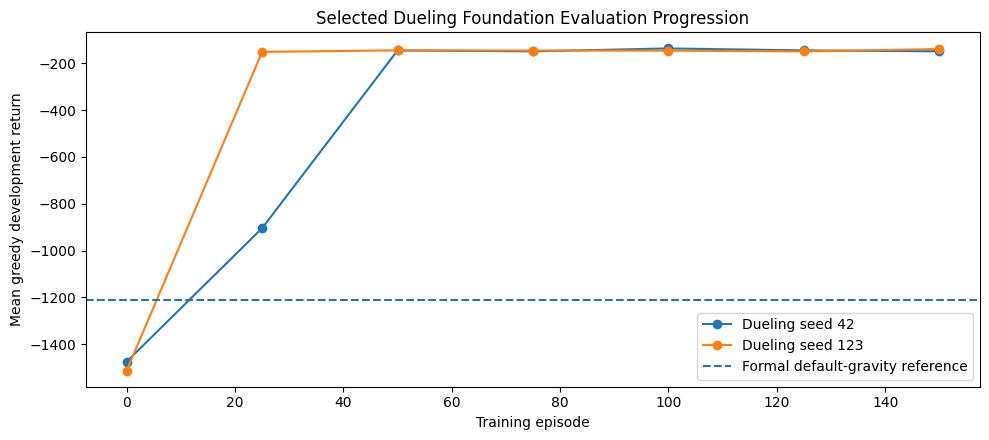

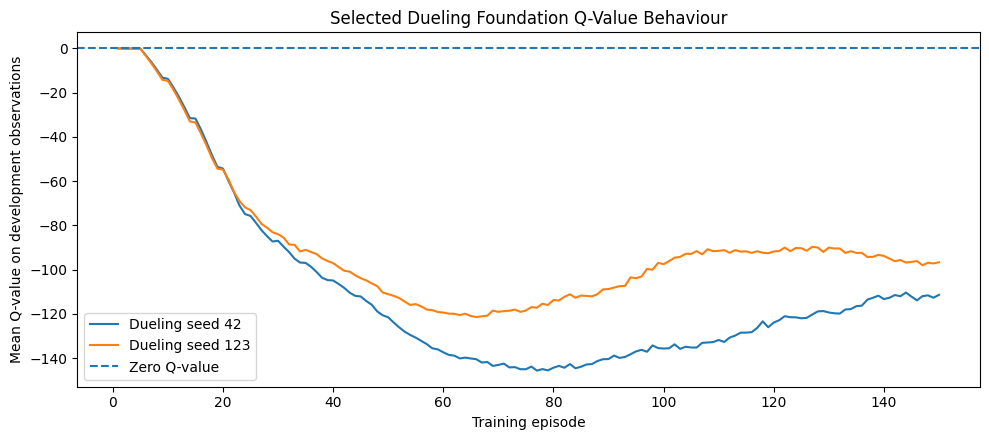

Selected foundation diagnosed: Dueling DQN
Mean selected return across seeds: -137.23223864688822
Training-seed return standard deviation: 1.8244041309830181
Average state-wise return standard deviation: 100.86628720658445
Late-degradation seed count: 1
Positive-Q warning seed count: 1
Worst initial-angle region: near_downward
Worst region mean return: -244.5191690164932
Average runtime minutes: 13.32537784916664
Formal runs completed: 8
Remaining formal-run capacity: 20
Saved diagnosis summary: histories\R42_selected_foundation_diagnosis_summary.csv
Saved state-region diagnosis: histories\R42_selected_foundation_state_region_diagnosis.csv
Saved evidence-to-experiment map: histories\R42_selected_foundation_evidence_to_experiment_map.csv
Section 10 selected-foundation diagnosis: PASS


In [63]:
FOUNDATION_DIAGNOSIS_SUMMARY_PATH = (
    HISTORIES_DIR
    / "R42_selected_foundation_diagnosis_summary.csv"
)
FOUNDATION_DIAGNOSIS_REGION_PATH = (
    HISTORIES_DIR
    / "R42_selected_foundation_state_region_diagnosis.csv"
)
FOUNDATION_DIAGNOSIS_EVIDENCE_MAP_PATH = (
    HISTORIES_DIR
    / "R42_selected_foundation_evidence_to_experiment_map.csv"
)

assert SELECTED_FOUNDATION_NAME == "Dueling DQN"
assert SELECTED_FOUNDATION_RUN_ID == "R42_DUELING"
assert SELECTED_FOUNDATION_PARAMETER_COUNT == 4936
assert DOUBLE_DUELING_APPROVED is False
assert FORMAL_RUNS_COMPLETED == 8
assert remaining_formal_run_capacity == 20

selected_foundation_seed_sources = {
    42: {
        "history": r42_history.copy(),
        "evaluation_summary": (
            r42_evaluation_summary.copy()
        ),
        "selected_states": (
            r42_selected_state_results.copy()
        ),
        "summary_record": dict(
            r42_summary_record
        ),
    },
    123: {
        "history": (
            r42_confirmation_history.copy()
        ),
        "evaluation_summary": (
            r42_confirmation_evaluation_summary.copy()
        ),
        "selected_states": (
            r42_confirmation_selected_state_results.copy()
        ),
        "summary_record": dict(
            r42_confirmation_summary_record
        ),
    },
}


def first_episode_reaching(
    evaluation_summary: pd.DataFrame,
    threshold: float,
) -> float:
    """Return the first checkpoint meeting a return threshold."""
    qualifying = evaluation_summary.loc[
        evaluation_summary[
            "mean_development_return"
        ] >= float(threshold)
    ]
    if len(qualifying) == 0:
        return np.nan
    return float(qualifying["episode"].iloc[0])


diagnosis_records = []
region_frames = []

for seed in (42, 123):
    source = selected_foundation_seed_sources[
        seed
    ]
    history = (
        source["history"]
        .sort_values("episode")
        .reset_index(drop=True)
    )
    evaluation_summary = (
        source["evaluation_summary"]
        .sort_values("episode")
        .reset_index(drop=True)
    )
    selected_states = (
        source["selected_states"]
        .sort_values("state_id")
        .reset_index(drop=True)
    )
    summary_record = source[
        "summary_record"
    ]

    assert len(history) == 150
    assert len(evaluation_summary) == 7
    assert len(selected_states) == len(
        DEVELOPMENT_PHYSICAL_STATES
    )
    assert evaluation_summary[
        "episode"
    ].tolist() == [
        0,
        25,
        50,
        75,
        100,
        125,
        150,
    ]

    selected_episode = int(
        summary_record[
            "selected_checkpoint_episode"
        ]
    )
    selected_return = float(
        summary_record[
            "mean_development_return"
        ]
    )
    episode_150_return = float(
        evaluation_summary.loc[
            evaluation_summary["episode"] == 150,
            "mean_development_return",
        ].iloc[0]
    )

    practical_neighbourhood_threshold = (
        selected_return
        - PRACTICAL_IMPROVEMENT_MARGIN
    )

    checkpoint_changes = (
        evaluation_summary[
            "mean_development_return"
        ].diff()
    )
    post_learning_evaluations = (
        evaluation_summary.loc[
            evaluation_summary["episode"] >= 50,
            "mean_development_return",
        ].to_numpy(dtype=np.float64)
    )

    loss_values = (
        history["mean_loss"]
        .dropna()
        .to_numpy(dtype=np.float64)
    )
    gradient_values = (
        history[
            "mean_gradient_global_norm"
        ]
        .dropna()
        .to_numpy(dtype=np.float64)
    )
    training_mean_q = history[
        "mean_q"
    ].to_numpy(dtype=np.float64)
    training_max_q = history[
        "max_q"
    ].to_numpy(dtype=np.float64)

    assert len(loss_values) > 0
    assert len(gradient_values) > 0
    assert np.isfinite(loss_values).all()
    assert np.isfinite(
        gradient_values
    ).all()
    assert np.isfinite(
        training_mean_q
    ).all()
    assert np.isfinite(
        training_max_q
    ).all()

    state_ids = selected_states[
        "state_id"
    ].to_numpy(dtype=np.int64)
    physical_states = np.asarray(
        DEVELOPMENT_PHYSICAL_STATES,
        dtype=np.float64,
    )
    selected_states["seed"] = int(seed)
    selected_states["theta"] = (
        physical_states[state_ids, 0]
    )
    selected_states["theta_dot"] = (
        physical_states[state_ids, 1]
    )

    absolute_theta = np.abs(
        selected_states["theta"].to_numpy()
    )
    selected_states["angle_region"] = (
        np.select(
            [
                absolute_theta <= np.pi / 4.0,
                absolute_theta <= 3.0 * np.pi / 4.0,
            ],
            [
                "near_upright",
                "sideways",
            ],
            default="near_downward",
        )
    )
    region_frames.append(
        selected_states
    )

    worst_state_row = selected_states.loc[
        selected_states["return"].idxmin()
    ]

    diagnosis_records.append({
        "seed": int(seed),
        "selected_checkpoint_episode": (
            selected_episode
        ),
        "selected_mean_return": (
            selected_return
        ),
        "episode_150_mean_return": (
            episode_150_return
        ),
        "episode_150_minus_selected": float(
            episode_150_return
            - selected_return
        ),
        "first_episode_above_formal_reference": (
            first_episode_reaching(
                evaluation_summary,
                FORMAL_DEFAULT_REFERENCE_TARGET,
            )
        ),
        "first_episode_within_practical_margin_of_selected": (
            first_episode_reaching(
                evaluation_summary,
                practical_neighbourhood_threshold,
            )
        ),
        "post_50_evaluation_mean": float(
            np.mean(
                post_learning_evaluations
            )
        ),
        "post_50_evaluation_std": float(
            np.std(
                post_learning_evaluations,
                ddof=1,
            )
        ),
        "largest_checkpoint_drop": float(
            checkpoint_changes.min()
        ),
        "development_state_std": float(
            summary_record[
                "development_return_std"
            ]
        ),
        "upright_fraction": float(
            summary_record[
                "upright_fraction"
            ]
        ),
        "mean_abs_angle": float(
            summary_record[
                "mean_abs_angle"
            ]
        ),
        "mean_abs_angular_velocity": float(
            summary_record[
                "mean_abs_angular_velocity"
            ]
        ),
        "mean_abs_torque": float(
            summary_record[
                "mean_abs_torque"
            ]
        ),
        "torque_direction_switching_rate": float(
            summary_record[
                "torque_direction_switching_rate"
            ]
        ),
        "selected_mean_q": float(
            summary_record[
                "selected_mean_q"
            ]
        ),
        "selected_max_q": float(
            summary_record[
                "selected_max_q"
            ]
        ),
        "selected_min_q": float(
            summary_record[
                "selected_min_q"
            ]
        ),
        "selected_q_span": float(
            summary_record[
                "selected_max_q"
            ]
            - summary_record[
                "selected_min_q"
            ]
        ),
        "positive_selected_max_q_warning": bool(
            float(
                summary_record[
                    "selected_max_q"
                ]
            ) > 0.0
        ),
        "training_max_q_peak": float(
            np.max(training_max_q)
        ),
        "training_mean_q_final": float(
            training_mean_q[-1]
        ),
        "mean_training_loss": float(
            np.mean(loss_values)
        ),
        "p95_training_loss": float(
            np.percentile(
                loss_values,
                95.0,
            )
        ),
        "maximum_training_loss": float(
            np.max(loss_values)
        ),
        "p95_gradient_global_norm": float(
            np.percentile(
                gradient_values,
                95.0,
            )
        ),
        "maximum_gradient_global_norm": float(
            np.max(gradient_values)
        ),
        "worst_state_id": int(
            worst_state_row["state_id"]
        ),
        "worst_state_return": float(
            worst_state_row["return"]
        ),
        "runtime_minutes": float(
            summary_record[
                "runtime_minutes"
            ]
        ),
        "parameter_count": int(
            summary_record[
                "parameter_count"
            ]
        ),
        "technical_status": (
            summary_record[
                "technical_status"
            ]
        ),
    })

selected_foundation_diagnosis = (
    pd.DataFrame(diagnosis_records)
    .sort_values("seed")
    .reset_index(drop=True)
)

all_selected_foundation_states = pd.concat(
    region_frames,
    ignore_index=True,
)

selected_foundation_region_diagnosis = (
    all_selected_foundation_states
    .groupby(
        ["seed", "angle_region"],
        observed=True,
    )
    .agg(
        state_count=("state_id", "count"),
        mean_return=("return", "mean"),
        return_std=("return", "std"),
        minimum_return=("return", "min"),
        maximum_return=("return", "max"),
        mean_upright_fraction=(
            "upright_fraction",
            "mean",
        ),
        mean_abs_angle=(
            "mean_abs_angle",
            "mean",
        ),
        mean_abs_angular_velocity=(
            "mean_abs_angular_velocity",
            "mean",
        ),
        mean_abs_torque=(
            "mean_abs_torque",
            "mean",
        ),
        mean_torque_direction_switching_rate=(
            "torque_direction_switching_rate",
            "mean",
        ),
    )
    .reset_index()
)

selected_seed_returns = (
    selected_foundation_diagnosis[
        "selected_mean_return"
    ].to_numpy(dtype=np.float64)
)
selected_to_final_changes = (
    selected_foundation_diagnosis[
        "episode_150_minus_selected"
    ].to_numpy(dtype=np.float64)
)

mean_selected_return = float(
    np.mean(selected_seed_returns)
)
training_seed_return_std = float(
    np.std(
        selected_seed_returns,
        ddof=1,
    )
)
average_state_wise_std = float(
    selected_foundation_diagnosis[
        "development_state_std"
    ].mean()
)
average_runtime_minutes = float(
    selected_foundation_diagnosis[
        "runtime_minutes"
    ].mean()
)
late_degradation_seed_count = int(
    np.sum(
        selected_to_final_changes
        < -PRACTICAL_IMPROVEMENT_MARGIN
    )
)
positive_q_warning_seed_count = int(
    selected_foundation_diagnosis[
        "positive_selected_max_q_warning"
    ].sum()
)

worst_region_row = (
    selected_foundation_region_diagnosis
    .groupby(
        "angle_region",
        observed=True,
    )["mean_return"]
    .mean()
    .sort_values()
)
worst_angle_region = str(
    worst_region_row.index[0]
)
worst_angle_region_mean_return = float(
    worst_region_row.iloc[0]
)

torque_difference_between_seeds = float(
    selected_foundation_diagnosis[
        "mean_abs_torque"
    ].max()
    - selected_foundation_diagnosis[
        "mean_abs_torque"
    ].min()
)
switching_difference_between_seeds = float(
    selected_foundation_diagnosis[
        "torque_direction_switching_rate"
    ].max()
    - selected_foundation_diagnosis[
        "torque_direction_switching_rate"
    ].min()
)

maximum_observed_gradient_norm = float(
    selected_foundation_diagnosis[
        "maximum_gradient_global_norm"
    ].max()
)
maximum_observed_loss = float(
    selected_foundation_diagnosis[
        "maximum_training_loss"
    ].max()
)

foundation_evidence_to_experiment_map = pd.DataFrame([
    {
        "observed_weakness": (
            "Late checkpoint degradation"
        ),
        "evidence": (
            f"{late_degradation_seed_count} of 2 seeds ended more than "
            f"{PRACTICAL_IMPROVEMENT_MARGIN:.6f} below its selected "
            "checkpoint."
        ),
        "candidate_recipe": (
            "Replay and target-network recipe"
        ),
        "priority": "High",
        "reason": (
            "Test whether a different coherent replay or hard-target "
            "schedule reduces late evaluation movement."
        ),
    },
    {
        "observed_weakness": (
            "Large TD-loss and gradient scale"
        ),
        "evidence": (
            f"Maximum observed MSE loss was {maximum_observed_loss:.6f}; "
            f"maximum gradient norm was {maximum_observed_gradient_norm:.6f}."
        ),
        "candidate_recipe": (
            "Huber loss plus gradient clipping"
        ),
        "priority": "High",
        "reason": (
            "Directly addresses large TD errors and gradient spikes while "
            "keeping the architecture fixed."
        ),
    },
    {
        "observed_weakness": (
            "Q-value overestimation warning"
        ),
        "evidence": (
            f"{positive_q_warning_seed_count} of 2 selected checkpoints "
            "had a positive maximum Q-value despite non-positive rewards."
        ),
        "candidate_recipe": (
            "Monitor Q scale during replay/target and stability recipes"
        ),
        "priority": "High",
        "reason": (
            "Positive Q-values are diagnostically suspicious, but Double "
            "Dueling remains skipped because Double DQN lacked sufficient "
            "independent performance evidence."
        ),
    },
    {
        "observed_weakness": (
            "Different torque styles across seeds"
        ),
        "evidence": (
            f"Mean absolute torque differed by "
            f"{torque_difference_between_seeds:.6f}; switching rate differed "
            f"by {switching_difference_between_seeds:.6f}."
        ),
        "candidate_recipe": (
            "Exploration schedule comparison"
        ),
        "priority": "Medium",
        "reason": (
            "Test whether coherent exploration schedules improve convergence "
            "consistency without changing replay or optimisation."
        ),
    },
    {
        "observed_weakness": (
            "Weakest initial-angle region"
        ),
        "evidence": (
            f"{worst_angle_region} had the lowest two-seed mean return "
            f"({worst_angle_region_mean_return:.6f})."
        ),
        "candidate_recipe": (
            "Retain in evaluation; state scaling remains conditional"
        ),
        "priority": "Medium",
        "reason": (
            "Preserve hard-state evidence. Activate scaling only when later "
            "diagnostics connect the weakness to observation range."
        ),
    },
    {
        "observed_weakness": (
            "No clear capacity failure"
        ),
        "evidence": (
            "Both 4,936-parameter Dueling runs were viable and beat the "
            "matched Vanilla reference."
        ),
        "candidate_recipe": (
            "Do not activate network-capacity experiment"
        ),
        "priority": "Inactive",
        "reason": (
            "There is no current under-capacity evidence, so extra width "
            "would add complexity without a diagnosed need."
        ),
    },
])

assert len(selected_foundation_diagnosis) == 2
assert selected_foundation_diagnosis[
    "seed"
].tolist() == [42, 123]
assert (
    selected_foundation_diagnosis[
        "technical_status"
    ] == "PASS"
).all()
assert (
    selected_foundation_diagnosis[
        "parameter_count"
    ] == 4936
).all()
assert np.isfinite(
    selected_foundation_diagnosis
    .select_dtypes(include=[np.number])
    .to_numpy(dtype=np.float64)
).all()
assert len(
    selected_foundation_region_diagnosis
) == 6
assert (
    selected_foundation_region_diagnosis[
        "state_count"
    ].sum()
    == 2 * len(DEVELOPMENT_PHYSICAL_STATES)
)
assert np.isclose(
    mean_selected_return,
    foundation_selection_record[
        "candidate_mean_across_seeds"
    ],
    rtol=0.0,
    atol=1e-6,
)
assert FORMAL_RUNS_COMPLETED == 8
assert remaining_formal_run_capacity == 20

FOUNDATION_DIAGNOSIS_COMPLETE = True

selected_foundation_diagnosis.to_csv(
    FOUNDATION_DIAGNOSIS_SUMMARY_PATH,
    index=False,
)
selected_foundation_region_diagnosis.to_csv(
    FOUNDATION_DIAGNOSIS_REGION_PATH,
    index=False,
)
foundation_evidence_to_experiment_map.to_csv(
    FOUNDATION_DIAGNOSIS_EVIDENCE_MAP_PATH,
    index=False,
)

display(selected_foundation_diagnosis)
display(selected_foundation_region_diagnosis)
display(foundation_evidence_to_experiment_map)

plt.figure(figsize=(10, 4.5))
for seed in (42, 123):
    evaluation_summary = (
        selected_foundation_seed_sources[
            seed
        ]["evaluation_summary"]
        .sort_values("episode")
    )
    plt.plot(
        evaluation_summary["episode"],
        evaluation_summary[
            "mean_development_return"
        ],
        marker="o",
        label=f"Dueling seed {seed}",
    )
plt.axhline(
    FORMAL_DEFAULT_REFERENCE_TARGET,
    linestyle="--",
    label="Formal default-gravity reference",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("Selected Dueling Foundation Evaluation Progression")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
for seed in (42, 123):
    history = (
        selected_foundation_seed_sources[
            seed
        ]["history"]
        .sort_values("episode")
    )
    plt.plot(
        history["episode"],
        history["mean_q"],
        label=f"Dueling seed {seed}",
    )
plt.axhline(
    0.0,
    linestyle="--",
    label="Zero Q-value",
)
plt.xlabel("Training episode")
plt.ylabel("Mean Q-value on development observations")
plt.title("Selected Dueling Foundation Q-Value Behaviour")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Selected foundation diagnosed:",
    SELECTED_FOUNDATION_NAME,
)
print(
    "Mean selected return across seeds:",
    mean_selected_return,
)
print(
    "Training-seed return standard deviation:",
    training_seed_return_std,
)
print(
    "Average state-wise return standard deviation:",
    average_state_wise_std,
)
print(
    "Late-degradation seed count:",
    late_degradation_seed_count,
)
print(
    "Positive-Q warning seed count:",
    positive_q_warning_seed_count,
)
print(
    "Worst initial-angle region:",
    worst_angle_region,
)
print(
    "Worst region mean return:",
    worst_angle_region_mean_return,
)
print(
    "Average runtime minutes:",
    average_runtime_minutes,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved diagnosis summary:",
    FOUNDATION_DIAGNOSIS_SUMMARY_PATH,
)
print(
    "Saved state-region diagnosis:",
    FOUNDATION_DIAGNOSIS_REGION_PATH,
)
print(
    "Saved evidence-to-experiment map:",
    FOUNDATION_DIAGNOSIS_EVIDENCE_MAP_PATH,
)
print("Section 10 selected-foundation diagnosis: PASS")


### 10.8 Diagnosis Interpretation

**Finding.** The selected Dueling foundation remained viable under both
matched seeds, with a two-seed mean return of `-137.232239` and a
training-seed standard deviation of `1.824404`.

The diagnosis identified four useful weaknesses:

- seed `42` ended `12.291164` below its selected checkpoint, producing one
  late-degradation case;
- one selected checkpoint produced a positive maximum Q-value despite
  Pendulum rewards being non-positive;
- the largest observed MSE loss was `59.279022`, with a large gradient scale;
- torque magnitude and switching differed across seeds.

Near-downward starting states were the weakest region, averaging
`-244.519169` across the two seeds. No technical failure or clear
under-capacity evidence was found.

**Importance.** The evidence supports controlled exploration, replay and
target-network, and optimisation-stability experiments. It does not justify a
larger network, Double Dueling DQN or an advanced replay method.

**Decision.**

- activate the required exploration comparison;
- activate one coherent replay and target-network alternative;
- activate Huber loss with gradient clipping;
- keep state scaling conditional;
- keep network capacity and advanced methods inactive.

**Caveat.** Positive Q-values are a warning signal, not direct proof of harmful
overestimation. Later recipes must improve control or reliability rather than
only producing smoother diagnostics.

**Next step.** Compare complete exploration schedules while holding every
non-exploration setting fixed.


# 11. Exploration Recipe Comparison

## 11.1 Question, Hypothesis and Controls

**Question.** Can a different exploration schedule improve convergence
consistency and reduce late checkpoint degradation for the selected Dueling
foundation?

**Diagnosis link.** The two Dueling seeds learned different torque styles, and
one seed degraded after its selected checkpoint.

Three complete schedules are compared:

| Recipe | Start epsilon | End epsilon | Decay duration | Role |
|---|---:|---:|---:|---|
| Fixed reference | `0.10` | `0.10` | None | Persistent low exploration |
| Fast decay | `1.00` | `0.05` | `5,000` steps | Earlier exploitation |
| Moderate decay | `1.00` | `0.05` | `20,000` steps | Existing selected-foundation run |

The moderate-decay seed-42 foundation run is reused because all material
conditions match. The fixed and fast recipes each require one fresh seed-42
run.

**Controlled factors.** Dueling architecture, seven actions, default gravity,
seed `42`, replay, optimiser, learning rate, loss, gamma, target update,
training budget, checkpoint rule and development states remain unchanged.

**Decision rule.** Mean greedy development return remains primary. Supporting
evidence includes paired-state wins, selected-checkpoint stability, random
action exposure, torque behaviour, Q-values, runtime and failures.

## 11.2 Fixed-Epsilon Reference

The fixed recipe uses epsilon `0.10` for all `30,000` environment steps. It
tests whether persistent but limited exploration produces more consistent
control than a long decay schedule.

This is a project diagnostic reference, not a claim about the lecturer's exact
epsilon value.

This experiment consumes one formal-training slot. After completion, the
formal-run count should be `9`, leaving `19` runs.


Loaded completed fixed-epsilon artifacts; no duplicate training run was started.


,recipe,run_id,epsilon_start,epsilon_end,decay_shape,decay_steps,source,status
0,fixed_0.10,R50_EXPLORE_FIXED_010,0.1,0.10,none,0,fresh seed-42 run,ACTIVE
1,fast_decay,R50_EXPLORE_FAST,1.0,0.05,linear,5000,fresh seed-42 run,PLANNED
2,moderate_decay,R42_DUELING,1.0,0.05,linear,20000,reused selected-foundation run,REFERENCE AVAILABLE


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1474.850023,-1421.686562,228.929283,-1816.480863,-1149.851953,0.009583,2.569736,1.605649,0.847083,0.072446
1,25,-846.379779,-1154.964110,506.417108,-1209.144484,-10.875802,0.341875,1.078843,3.789872,1.578194,0.183417
2,50,-181.774755,-134.629259,126.323512,-381.411582,-3.854445,0.802708,0.400090,0.696315,1.889167,0.612856
3,75,-143.226264,-125.942387,107.493046,-381.170696,-2.035289,0.862083,0.305427,0.531245,1.337361,0.397194
4,100,-216.561908,-126.686678,389.104271,-1973.920880,-2.256356,0.836250,0.424420,0.487938,0.610694,0.447864
5,125,-146.537797,-128.338186,106.786637,-363.163813,-2.290939,0.860417,0.315811,0.554637,1.406111,0.602806
6,150,-147.510647,-126.962844,111.226753,-401.085388,-0.906015,0.861250,0.286799,0.533627,0.932500,0.375000


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,runtime_minutes,parameter_count,weight_path,technical_status,exploration_recipe,epsilon_start,epsilon_end,epsilon_decay_shape,epsilon_decay_steps,reference_run_id
0,R50_EXPLORE_FIXED_010,R50_EXPLORE_FIXED_010,False,True,Dueling DQN,default,42,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,15.275611,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS,fixed_0.10,0.1,0.1,none,0,R42_DUELING


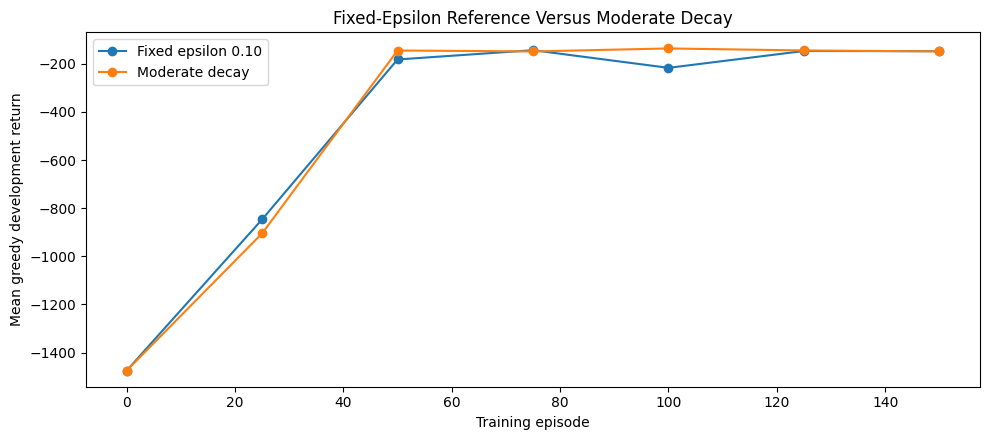

Fixed-epsilon run completed: True
Selected checkpoint episode: 75
Mean development return: -143.22626385714952
Development return standard deviation: 107.49304615260188
Random action count: 2972
Fixed-minus-moderate mean return: -7.284073742904155
Within practical improvement margin: True
Formal runs completed: 9
Remaining formal-run capacity: 19
Saved fixed-epsilon history: histories\R50_EXPLORE_FIXED_010_history.csv
Saved fixed-epsilon summary: histories\R50_EXPLORE_FIXED_010_summary.csv
Saved fixed-epsilon weights: selected_weights\R50_EXPLORE_FIXED_010_best.weights.h5
Section 11.2 fixed-epsilon reference: COMPLETE


In [64]:
R50_FIXED_RUN_ID = "R50_EXPLORE_FIXED_010"
R50_FIXED_EPSILON = 0.10

R50_FIXED_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R50_FIXED_RUN_ID}_best.weights.h5"
)
R50_FIXED_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{R50_FIXED_RUN_ID}_history.csv"
)
R50_FIXED_EVALUATION_PATH = (
    HISTORIES_DIR
    / f"{R50_FIXED_RUN_ID}_development_evaluations.csv"
)
R50_FIXED_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R50_FIXED_RUN_ID}_development_evaluation_summary.csv"
)
R50_FIXED_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R50_FIXED_RUN_ID}_summary.csv"
)
R50_FIXED_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / f"{R50_FIXED_RUN_ID}_selected_state_results.csv"
)
EXPLORATION_RECIPE_PLAN_PATH = (
    HISTORIES_DIR
    / "R50_exploration_recipe_plan.csv"
)

assert FOUNDATION_DIAGNOSIS_COMPLETE is True
assert SELECTED_FOUNDATION_NAME == "Dueling DQN"
assert SELECTED_FOUNDATION_SEED == 42
assert FORMAL_RUNS_COMPLETED in (8, 9)
assert remaining_formal_run_capacity in (20, 19)
assert 0.0 <= R50_FIXED_EPSILON <= 1.0

exploration_recipe_plan = pd.DataFrame([
    {
        "recipe": "fixed_0.10",
        "run_id": R50_FIXED_RUN_ID,
        "epsilon_start": 0.10,
        "epsilon_end": 0.10,
        "decay_shape": "none",
        "decay_steps": 0,
        "source": "fresh seed-42 run",
        "status": "ACTIVE",
    },
    {
        "recipe": "fast_decay",
        "run_id": "R50_EXPLORE_FAST",
        "epsilon_start": 1.00,
        "epsilon_end": 0.05,
        "decay_shape": "linear",
        "decay_steps": 5_000,
        "source": "fresh seed-42 run",
        "status": "PLANNED",
    },
    {
        "recipe": "moderate_decay",
        "run_id": R42_RUN_ID,
        "epsilon_start": (
            ACTION_COMPARISON_EPSILON_START
        ),
        "epsilon_end": (
            ACTION_COMPARISON_EPSILON_END
        ),
        "decay_shape": "linear",
        "decay_steps": (
            ACTION_COMPARISON_EPSILON_DECAY_STEPS
        ),
        "source": "reused selected-foundation run",
        "status": "REFERENCE AVAILABLE",
    },
])

assert exploration_recipe_plan["recipe"].tolist() == [
    "fixed_0.10",
    "fast_decay",
    "moderate_decay",
]
assert int(
    exploration_recipe_plan.loc[
        exploration_recipe_plan["recipe"]
        == "moderate_decay",
        "decay_steps",
    ].iloc[0]
) == 20_000

exploration_recipe_plan.to_csv(
    EXPLORATION_RECIPE_PLAN_PATH,
    index=False,
)

r50_fixed_required_artifacts = [
    R50_FIXED_WEIGHT_PATH,
    R50_FIXED_HISTORY_PATH,
    R50_FIXED_EVALUATION_PATH,
    R50_FIXED_EVALUATION_SUMMARY_PATH,
    R50_FIXED_SUMMARY_PATH,
    R50_FIXED_STATE_RESULTS_PATH,
]
r50_fixed_artifacts_complete = all(
    path.exists()
    for path in r50_fixed_required_artifacts
)

if (
    "r50_fixed_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "r50_fixed_history",
            "r50_fixed_evaluation_states",
            "r50_fixed_evaluation_summary",
            "r50_fixed_selected_state_results",
            "r50_fixed_summary",
        ]
    )
):
    print(
        "Fixed-epsilon result already exists in memory; "
        "no duplicate training run was started."
    )
elif r50_fixed_artifacts_complete:
    r50_fixed_history = read_csv_with_control_metric_migration(
        R50_FIXED_HISTORY_PATH
    )
    r50_fixed_evaluation_states = read_csv_with_control_metric_migration(
        R50_FIXED_EVALUATION_PATH
    )
    r50_fixed_evaluation_summary = read_csv_with_control_metric_migration(
        R50_FIXED_EVALUATION_SUMMARY_PATH
    )
    r50_fixed_summary = read_csv_with_control_metric_migration(
        R50_FIXED_SUMMARY_PATH
    )
    r50_fixed_selected_state_results = read_csv_with_control_metric_migration(
        R50_FIXED_STATE_RESULTS_PATH
    )

    assert len(r50_fixed_summary) == 1
    r50_fixed_summary_record = (
        r50_fixed_summary.iloc[0].to_dict()
    )
    r50_fixed_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FOUNDATION_SCREEN_ACTION_COUNT,
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r50_fixed_reloaded_q_network"
            ),
        )
    )
    r50_fixed_selected_model.load_weights(
        R50_FIXED_WEIGHT_PATH
    )
    print(
        "Loaded completed fixed-epsilon artifacts; "
        "no duplicate training run was started."
    )
else:
    original_action_comparison_epsilon = (
        action_comparison_epsilon
    )

    def fixed_exploration_epsilon(
        environment_step: int,
    ) -> float:
        """Return the locked fixed epsilon for every training step."""
        assert int(environment_step) >= 0
        return float(R50_FIXED_EPSILON)

    action_comparison_epsilon = (
        fixed_exploration_epsilon
    )

    try:
        r50_fixed_result = (
            run_dueling_dqn_foundation(
                run_id=R50_FIXED_RUN_ID,
                torque_values=(
                    FOUNDATION_SCREEN_TORQUE_VALUES
                ),
                seed=FOUNDATION_SCREEN_SEED,
                weight_path=R50_FIXED_WEIGHT_PATH,
            )
        )
    finally:
        action_comparison_epsilon = (
            original_action_comparison_epsilon
        )

    r50_fixed_history = (
        r50_fixed_result["history"]
    )
    r50_fixed_evaluation_states = (
        r50_fixed_result["evaluation_states"]
    )
    r50_fixed_evaluation_summary = (
        r50_fixed_result["evaluation_summary"]
    )
    r50_fixed_selected_state_results = (
        r50_fixed_result[
            "selected_state_results"
        ]
    )
    r50_fixed_selected_model = (
        r50_fixed_result["selected_model"]
    )
    r50_fixed_summary_record = dict(
        r50_fixed_result["summary_record"]
    )

    r50_fixed_summary_record.update({
        "exploration_recipe": "fixed_0.10",
        "epsilon_start": R50_FIXED_EPSILON,
        "epsilon_end": R50_FIXED_EPSILON,
        "epsilon_decay_shape": "none",
        "epsilon_decay_steps": 0,
        "reference_run_id": R42_RUN_ID,
    })
    r50_fixed_summary = pd.DataFrame(
        [r50_fixed_summary_record]
    )

FORMAL_RUNS_COMPLETED = 9
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 9
assert remaining_formal_run_capacity == 19
assert len(r50_fixed_history) == 150
assert len(r50_fixed_evaluation_summary) == 7
assert int(
    r50_fixed_summary_record["seed"]
) == 42
assert (
    r50_fixed_summary_record["model"]
    == "Dueling DQN"
)
assert int(
    r50_fixed_summary_record["action_count"]
) == 7
assert int(
    r50_fixed_summary_record["parameter_count"]
) == 4936
assert int(
    r50_fixed_summary_record["environment_steps"]
) == 30_000
assert int(
    r50_fixed_summary_record["optimizer_updates"]
) == 29_001
assert int(
    r50_fixed_summary_record["target_updates"]
) == 116
assert (
    int(
        r50_fixed_summary_record[
            "random_actions"
        ]
    )
    + int(
        r50_fixed_summary_record[
            "greedy_actions"
        ]
    )
    == 30_000
)
assert np.allclose(
    r50_fixed_history["epsilon"].to_numpy(
        dtype=np.float64
    ),
    R50_FIXED_EPSILON,
    rtol=0.0,
    atol=0.0,
)
assert np.isfinite(
    r50_fixed_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert R50_FIXED_WEIGHT_PATH.exists()

r50_fixed_history.to_csv(
    R50_FIXED_HISTORY_PATH,
    index=False,
)
r50_fixed_evaluation_states.to_csv(
    R50_FIXED_EVALUATION_PATH,
    index=False,
)
r50_fixed_evaluation_summary.to_csv(
    R50_FIXED_EVALUATION_SUMMARY_PATH,
    index=False,
)
r50_fixed_summary.to_csv(
    R50_FIXED_SUMMARY_PATH,
    index=False,
)
r50_fixed_selected_state_results.to_csv(
    R50_FIXED_STATE_RESULTS_PATH,
    index=False,
)

EXPLORATION_RECIPE_RESULTS = {
    "fixed_0.10": r50_fixed_summary_record,
    "moderate_decay": r42_summary_record,
}
EXPLORATION_RECIPE_STATE_RESULTS = {
    "fixed_0.10": (
        r50_fixed_selected_state_results.copy()
    ),
    "moderate_decay": (
        r42_selected_state_results.copy()
    ),
}
EXPLORATION_RECIPE_EVALUATIONS = {
    "fixed_0.10": (
        r50_fixed_evaluation_summary.copy()
    ),
    "moderate_decay": (
        r42_evaluation_summary.copy()
    ),
}

fixed_minus_moderate = float(
    r50_fixed_summary_record[
        "mean_development_return"
    ]
    - r42_summary_record[
        "mean_development_return"
    ]
)

display(exploration_recipe_plan)
display(r50_fixed_evaluation_summary)
display(r50_fixed_summary)

plt.figure(figsize=(10, 4.5))
plt.plot(
    r50_fixed_evaluation_summary["episode"],
    r50_fixed_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Fixed epsilon 0.10",
)
plt.plot(
    r42_evaluation_summary["episode"],
    r42_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Moderate decay",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("Fixed-Epsilon Reference Versus Moderate Decay")
plt.legend()
plt.tight_layout()
plt.show()

print("Fixed-epsilon run completed:", True)
print(
    "Selected checkpoint episode:",
    r50_fixed_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    r50_fixed_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    r50_fixed_summary_record[
        "development_return_std"
    ],
)
print(
    "Random action count:",
    r50_fixed_summary_record[
        "random_actions"
    ],
)
print(
    "Fixed-minus-moderate mean return:",
    fixed_minus_moderate,
)
print(
    "Within practical improvement margin:",
    abs(fixed_minus_moderate)
    <= PRACTICAL_IMPROVEMENT_MARGIN,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved fixed-epsilon history:",
    R50_FIXED_HISTORY_PATH,
)
print(
    "Saved fixed-epsilon summary:",
    R50_FIXED_SUMMARY_PATH,
)
print(
    "Saved fixed-epsilon weights:",
    R50_FIXED_WEIGHT_PATH,
)
print("Section 11.2 fixed-epsilon reference: COMPLETE")


### 11.2 Result Interpretation

**Finding.** The fixed-epsilon `0.10` run completed all `150` episodes,
`30,000` environment steps and `29,001` optimiser updates without technical
failure.

Its selected checkpoint was episode `75`, with:

- mean development return: `-143.226264`;
- development-state standard deviation: `107.493046`;
- random actions: `2,972`;
- runtime: `15.275611` minutes.

The fixed recipe scored `7.284074` below the moderate-decay Dueling reference.
This difference remains inside the locked `11.335072` practical margin.

**Importance.** Fixed epsilon reduced the selected-to-final decline to about
`4.284383`, compared with `12.291164` for the moderate-decay seed-42 run.
However, it also produced a lower selected return and larger state-wise spread.

**Decision.** Retain fixed epsilon as valid evidence, but do not select it
before the fast-decay run is completed.

**Caveat.** The fixed recipe suffered a temporary episode-100 evaluation drop
to `-216.561908` before recovering. A smaller final decline alone is not enough
to call it more stable overall.

**Next step.** Train the fast-decay recipe, which reaches epsilon `0.05` after
`5,000` environment steps.


## 11.3 Fast-Decay Recipe

The fast-decay recipe uses a linear schedule:

```text
epsilon 1.00 → 0.05 over 5,000 environment steps
```

It tests whether earlier exploitation improves the selected Dueling
foundation's learning speed and checkpoint stability.

Every non-exploration condition remains identical to the fixed and
moderate-decay runs.

This experiment consumes one formal-training slot. After completion, the
formal-run count should be `10`, leaving `18` runs.


Loaded completed fast-decay artifacts; no duplicate training run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1474.850023,-1421.686562,228.929283,-1816.480863,-1149.851953,0.009583,2.569736,1.605649,0.847083,0.072446
1,25,-162.089877,-129.224843,116.952504,-382.122629,-1.232896,0.845833,0.293576,0.647680,1.597778,0.570561
2,50,-213.282702,-125.173276,388.882456,-1973.920880,-0.726393,0.831250,0.349099,0.523027,1.422917,0.795226
3,75,-188.823850,-133.649596,144.981984,-486.177304,-0.393558,0.827083,0.329007,0.632404,1.089028,0.801717
4,100,-176.307964,-126.552890,152.833903,-650.759192,-0.289303,0.838125,0.314589,0.551289,0.572917,0.505863
5,125,-154.438018,-125.716915,115.990670,-361.954512,-0.656391,0.860208,0.252435,0.577545,1.313611,0.703727
6,150,-143.451356,-125.854123,111.332632,-386.342348,-0.031771,0.872708,0.233563,0.503336,0.482639,0.327052


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,runtime_minutes,parameter_count,weight_path,technical_status,exploration_recipe,epsilon_start,epsilon_end,epsilon_decay_shape,epsilon_decay_steps,reference_run_id
0,R50_EXPLORE_FAST,R50_EXPLORE_FAST,False,True,Dueling DQN,default,42,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,14.561052,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS,fast_decay,1.0,0.05,linear,5000,R42_DUELING


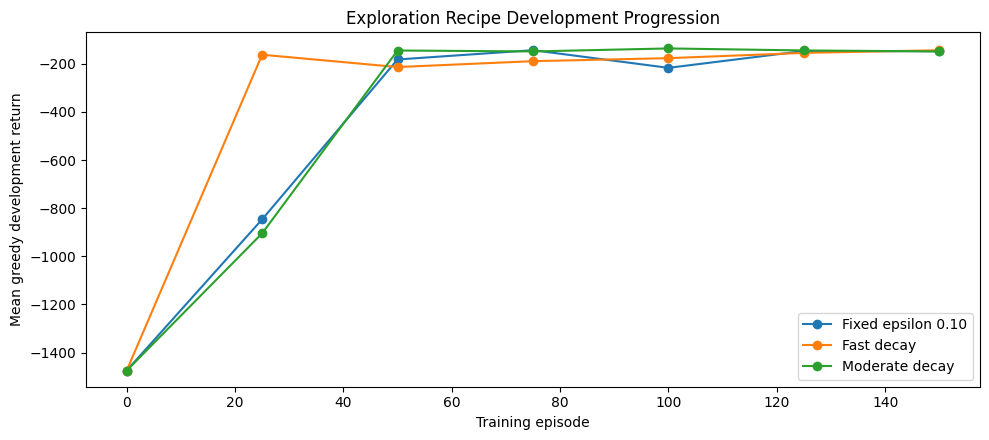

Fast-decay run completed: True
Selected checkpoint episode: 150
Mean development return: -143.45135616978004
Development return standard deviation: 111.33263207445096
Random action count: 3888
Fast-minus-moderate mean return: -7.509166055534678
Fast-minus-fixed mean return: -0.22509231263052243
Within practical margin versus moderate: True
Formal runs completed: 10
Remaining formal-run capacity: 18
Saved fast-decay history: histories\R50_EXPLORE_FAST_history.csv
Saved fast-decay summary: histories\R50_EXPLORE_FAST_summary.csv
Saved fast-decay weights: selected_weights\R50_EXPLORE_FAST_best.weights.h5
Section 11.3 fast-decay recipe: COMPLETE


In [65]:
R50_FAST_RUN_ID = "R50_EXPLORE_FAST"
R50_FAST_EPSILON_START = 1.00
R50_FAST_EPSILON_END = 0.05
R50_FAST_EPSILON_DECAY_STEPS = 5_000

R50_FAST_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R50_FAST_RUN_ID}_best.weights.h5"
)
R50_FAST_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{R50_FAST_RUN_ID}_history.csv"
)
R50_FAST_EVALUATION_PATH = (
    HISTORIES_DIR
    / f"{R50_FAST_RUN_ID}_development_evaluations.csv"
)
R50_FAST_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R50_FAST_RUN_ID}_development_evaluation_summary.csv"
)
R50_FAST_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R50_FAST_RUN_ID}_summary.csv"
)
R50_FAST_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / f"{R50_FAST_RUN_ID}_selected_state_results.csv"
)

assert FOUNDATION_DIAGNOSIS_COMPLETE is True
assert SELECTED_FOUNDATION_NAME == "Dueling DQN"
assert FORMAL_RUNS_COMPLETED in (9, 10)
assert remaining_formal_run_capacity in (19, 18)
assert R50_FAST_EPSILON_START == 1.00
assert R50_FAST_EPSILON_END == 0.05
assert R50_FAST_EPSILON_DECAY_STEPS == 5_000


def fast_exploration_epsilon(
    environment_step: int,
) -> float:
    """Linearly decay epsilon from 1.00 to 0.05 over 5,000 steps."""
    step = max(0, int(environment_step))
    progress = min(
        step / R50_FAST_EPSILON_DECAY_STEPS,
        1.0,
    )
    epsilon = (
        R50_FAST_EPSILON_START
        + progress
        * (
            R50_FAST_EPSILON_END
            - R50_FAST_EPSILON_START
        )
    )
    return float(epsilon)


np.testing.assert_allclose(
    [
        fast_exploration_epsilon(0),
        fast_exploration_epsilon(2_500),
        fast_exploration_epsilon(5_000),
        fast_exploration_epsilon(30_000),
    ],
    [
        1.00,
        0.525,
        0.05,
        0.05,
    ],
    rtol=0.0,
    atol=1e-12,
)

r50_fast_required_artifacts = [
    R50_FAST_WEIGHT_PATH,
    R50_FAST_HISTORY_PATH,
    R50_FAST_EVALUATION_PATH,
    R50_FAST_EVALUATION_SUMMARY_PATH,
    R50_FAST_SUMMARY_PATH,
    R50_FAST_STATE_RESULTS_PATH,
]
r50_fast_artifacts_complete = all(
    path.exists()
    for path in r50_fast_required_artifacts
)

if (
    "r50_fast_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "r50_fast_history",
            "r50_fast_evaluation_states",
            "r50_fast_evaluation_summary",
            "r50_fast_selected_state_results",
            "r50_fast_summary",
        ]
    )
):
    print(
        "Fast-decay result already exists in memory; "
        "no duplicate training run was started."
    )
elif r50_fast_artifacts_complete:
    r50_fast_history = read_csv_with_control_metric_migration(
        R50_FAST_HISTORY_PATH
    )
    r50_fast_evaluation_states = read_csv_with_control_metric_migration(
        R50_FAST_EVALUATION_PATH
    )
    r50_fast_evaluation_summary = read_csv_with_control_metric_migration(
        R50_FAST_EVALUATION_SUMMARY_PATH
    )
    r50_fast_summary = read_csv_with_control_metric_migration(
        R50_FAST_SUMMARY_PATH
    )
    r50_fast_selected_state_results = read_csv_with_control_metric_migration(
        R50_FAST_STATE_RESULTS_PATH
    )

    assert len(r50_fast_summary) == 1
    r50_fast_summary_record = (
        r50_fast_summary.iloc[0].to_dict()
    )
    r50_fast_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FOUNDATION_SCREEN_ACTION_COUNT,
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r50_fast_reloaded_q_network"
            ),
        )
    )
    r50_fast_selected_model.load_weights(
        R50_FAST_WEIGHT_PATH
    )
    print(
        "Loaded completed fast-decay artifacts; "
        "no duplicate training run was started."
    )
else:
    original_action_comparison_epsilon = (
        action_comparison_epsilon
    )
    action_comparison_epsilon = (
        fast_exploration_epsilon
    )

    try:
        r50_fast_result = (
            run_dueling_dqn_foundation(
                run_id=R50_FAST_RUN_ID,
                torque_values=(
                    FOUNDATION_SCREEN_TORQUE_VALUES
                ),
                seed=FOUNDATION_SCREEN_SEED,
                weight_path=R50_FAST_WEIGHT_PATH,
            )
        )
    finally:
        action_comparison_epsilon = (
            original_action_comparison_epsilon
        )

    r50_fast_history = (
        r50_fast_result["history"]
    )
    r50_fast_evaluation_states = (
        r50_fast_result["evaluation_states"]
    )
    r50_fast_evaluation_summary = (
        r50_fast_result["evaluation_summary"]
    )
    r50_fast_selected_state_results = (
        r50_fast_result[
            "selected_state_results"
        ]
    )
    r50_fast_selected_model = (
        r50_fast_result["selected_model"]
    )
    r50_fast_summary_record = dict(
        r50_fast_result["summary_record"]
    )

    r50_fast_summary_record.update({
        "exploration_recipe": "fast_decay",
        "epsilon_start": (
            R50_FAST_EPSILON_START
        ),
        "epsilon_end": (
            R50_FAST_EPSILON_END
        ),
        "epsilon_decay_shape": "linear",
        "epsilon_decay_steps": (
            R50_FAST_EPSILON_DECAY_STEPS
        ),
        "reference_run_id": R42_RUN_ID,
    })
    r50_fast_summary = pd.DataFrame(
        [r50_fast_summary_record]
    )

FORMAL_RUNS_COMPLETED = 10
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 10
assert remaining_formal_run_capacity == 18
assert len(r50_fast_history) == 150
assert len(r50_fast_evaluation_summary) == 7
assert int(
    r50_fast_summary_record["seed"]
) == 42
assert (
    r50_fast_summary_record["model"]
    == "Dueling DQN"
)
assert int(
    r50_fast_summary_record["action_count"]
) == 7
assert int(
    r50_fast_summary_record["parameter_count"]
) == 4936
assert int(
    r50_fast_summary_record["environment_steps"]
) == 30_000
assert int(
    r50_fast_summary_record["optimizer_updates"]
) == 29_001
assert int(
    r50_fast_summary_record["target_updates"]
) == 116
assert (
    int(
        r50_fast_summary_record[
            "random_actions"
        ]
    )
    + int(
        r50_fast_summary_record[
            "greedy_actions"
        ]
    )
    == 30_000
)
assert np.isclose(
    float(r50_fast_history["epsilon"].iloc[-1]),
    R50_FAST_EPSILON_END,
    rtol=0.0,
    atol=1e-12,
)
assert np.isfinite(
    r50_fast_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert R50_FAST_WEIGHT_PATH.exists()

r50_fast_history.to_csv(
    R50_FAST_HISTORY_PATH,
    index=False,
)
r50_fast_evaluation_states.to_csv(
    R50_FAST_EVALUATION_PATH,
    index=False,
)
r50_fast_evaluation_summary.to_csv(
    R50_FAST_EVALUATION_SUMMARY_PATH,
    index=False,
)
r50_fast_summary.to_csv(
    R50_FAST_SUMMARY_PATH,
    index=False,
)
r50_fast_selected_state_results.to_csv(
    R50_FAST_STATE_RESULTS_PATH,
    index=False,
)

EXPLORATION_RECIPE_RESULTS[
    "fast_decay"
] = r50_fast_summary_record
EXPLORATION_RECIPE_STATE_RESULTS[
    "fast_decay"
] = r50_fast_selected_state_results.copy()
EXPLORATION_RECIPE_EVALUATIONS[
    "fast_decay"
] = r50_fast_evaluation_summary.copy()

fast_minus_moderate = float(
    r50_fast_summary_record[
        "mean_development_return"
    ]
    - r42_summary_record[
        "mean_development_return"
    ]
)
fast_minus_fixed = float(
    r50_fast_summary_record[
        "mean_development_return"
    ]
    - r50_fixed_summary_record[
        "mean_development_return"
    ]
)

display(r50_fast_evaluation_summary)
display(r50_fast_summary)

plt.figure(figsize=(10, 4.5))
plt.plot(
    r50_fixed_evaluation_summary["episode"],
    r50_fixed_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Fixed epsilon 0.10",
)
plt.plot(
    r50_fast_evaluation_summary["episode"],
    r50_fast_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Fast decay",
)
plt.plot(
    r42_evaluation_summary["episode"],
    r42_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Moderate decay",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("Exploration Recipe Development Progression")
plt.legend()
plt.tight_layout()
plt.show()

print("Fast-decay run completed:", True)
print(
    "Selected checkpoint episode:",
    r50_fast_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    r50_fast_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    r50_fast_summary_record[
        "development_return_std"
    ],
)
print(
    "Random action count:",
    r50_fast_summary_record[
        "random_actions"
    ],
)
print(
    "Fast-minus-moderate mean return:",
    fast_minus_moderate,
)
print(
    "Fast-minus-fixed mean return:",
    fast_minus_fixed,
)
print(
    "Within practical margin versus moderate:",
    abs(fast_minus_moderate)
    <= PRACTICAL_IMPROVEMENT_MARGIN,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved fast-decay history:",
    R50_FAST_HISTORY_PATH,
)
print(
    "Saved fast-decay summary:",
    R50_FAST_SUMMARY_PATH,
)
print(
    "Saved fast-decay weights:",
    R50_FAST_WEIGHT_PATH,
)
print("Section 11.3 fast-decay recipe: COMPLETE")


### 11.3 Result Interpretation

**Finding.** The fast-decay run completed all `150` episodes, `30,000`
environment steps and `29,001` optimiser updates without technical failure.

Its selected checkpoint was episode `150`, with:

- mean development return: `-143.451356`;
- development-state standard deviation: `111.332632`;
- random actions: `3,888`;
- runtime: `14.561052` minutes.

Fast decay scored `7.509166` below moderate decay and `0.225092` below fixed
epsilon. Both differences remain inside the locked practical margin.

**Importance.** Fast decay produced the strongest episode-25 result
(`-162.089877`), showing very rapid early learning. However, it then declined
at episodes `50` to `100` and only recovered fully at episode `150`. Its
state-wise spread was the largest of the three recipes.

**Decision.** Retain fast decay as useful learning-speed evidence, but do not
select it from the seed-42 screen.

**Caveat.** Selecting the final checkpoint means the run showed no
selected-to-final decline, but this does not remove the substantial
checkpoint-to-checkpoint movement observed earlier.

**Next step.** Compare fixed, fast and moderate exploration recipes using
paired states and the locked selection hierarchy.


## 11.4 Moderate-Decay Reference

The moderate-decay recipe is the completed seed-42 selected-foundation run:

```text
R42_DUELING
epsilon 1.00 → 0.05 over 20,000 environment steps
```

It is reused without retraining because architecture, seed, action set,
gravity, replay, optimisation, budget and evaluation protocol match the
exploration comparison exactly.

Its selected checkpoint was episode `100`, with mean development return
`-135.942190` and development-state standard deviation `99.338244`.


## 11.5 Slow-Decay Recipe Decision

A slower schedule is **not activated**.

Moderate decay already outperformed both faster exploitation and persistent
fixed exploration on the primary return criterion. The fast recipe learned
quickly at episode `25` but became less stable afterward, while fixed epsilon
did not improve the selected return or state-wise spread.

There is therefore no clear evidence that exploration ended too early under
the `20,000`-step moderate schedule. The slow-decay slot remains protected for
later required experiments.


## 11.6 Exploration Screening Decision

The three seed-42 recipes are compared on:

- selected mean greedy development return;
- paired returns on the same `24` physical states;
- state-wise spread;
- learning speed;
- selected-to-final movement;
- upright and torque behaviour;
- Q-value diagnostics;
- random-action exposure;
- runtime and technical validity.

A difference inside `11.335072` is treated as practically close. The strongest
alternative to the screening leader must therefore receive matched seed-123
confirmation before the exploration recipe is locked.


,recipe,run_id,seed,epsilon_start,epsilon_end,decay_steps,selected_checkpoint_episode,mean_development_return,development_return_std,upright_fraction,...,first_episode_above_formal_reference,first_episode_within_practical_margin_of_selected,random_actions,random_action_fraction,selected_mean_q,selected_max_q,selected_min_q,runtime_minutes,parameter_count,technical_status
0,moderate_decay,R42_DUELING,42,1.0,0.05,20000,100,-135.942190,99.338244,0.872292,...,25,50,10979,0.365967,-135.678345,-9.624632,-274.335236,14.916523,4936,PASS
1,fixed_0.10,R50_EXPLORE_FIXED_010,42,0.1,0.10,0,75,-143.226264,107.493046,0.862083,...,25,75,2972,0.099067,-137.837357,-16.011986,-257.227386,15.275611,4936,PASS
2,fast_decay,R50_EXPLORE_FAST,42,1.0,0.05,5000,150,-143.451356,111.332632,0.872708,...,25,125,3888,0.129600,-101.879707,14.685157,-234.736435,14.561052,4936,PASS


,reference_recipe,candidate_recipe,seed,paired_state_count,mean_return_difference,median_return_difference,candidate_win_proportion,reference_win_proportion,exact_tie_proportion,minimum_paired_difference,maximum_paired_difference,within_practical_margin
0,moderate_decay,fixed_0.10,42,24,-7.284074,-2.401027,0.083333,0.916667,0.0,-90.556931,1.790324,True
1,moderate_decay,fast_decay,42,24,-7.509166,-0.749267,0.375000,0.625000,0.0,-144.515540,58.001615,True
2,fixed_0.10,fast_decay,42,24,-0.225092,1.848887,0.875000,0.125000,0.0,-146.305864,60.700394,True


,screening_seed,screening_leader,confirmation_candidate,candidate_minus_leader,practical_improvement_margin,matched_seed_123_confirmation_required,moderate_seed_123_reference_available,slow_decay_approved,formal_significance_claim,selection_status
0,42,moderate_decay,fixed_0.10,-7.284074,11.335072,True,True,False,False,PENDING MATCHED SEED-123 CONFIRMATION


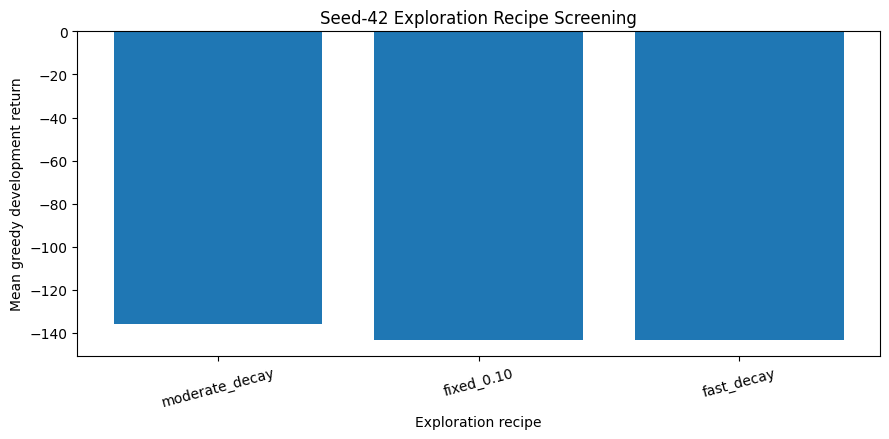

Exploration screening ranking: ['moderate_decay', 'fixed_0.10', 'fast_decay']
Exploration screening leader: moderate_decay
Matched confirmation candidate: fixed_0.10
Candidate-minus-leader mean return: -7.284073742904155
Matched seed-123 confirmation required: True
Slow-decay recipe approved: False
Formal runs completed: 10
Remaining formal-run capacity: 18
Saved exploration comparison: histories\R50_exploration_recipe_screening_comparison.csv
Saved paired exploration comparison: histories\R50_exploration_recipe_screening_paired.csv
Saved exploration screening decision: histories\R50_exploration_recipe_screening_decision.csv
Section 11.4 moderate reference: PASS
Section 11.5 slow-decay decision: PASS
Section 11.6 exploration screening decision: PASS


In [66]:
EXPLORATION_COMPARISON_PATH = (
    HISTORIES_DIR
    / "R50_exploration_recipe_screening_comparison.csv"
)
EXPLORATION_PAIRED_PATH = (
    HISTORIES_DIR
    / "R50_exploration_recipe_screening_paired.csv"
)
EXPLORATION_DECISION_PATH = (
    HISTORIES_DIR
    / "R50_exploration_recipe_screening_decision.csv"
)

EXPLORATION_RECIPE_ORDER = (
    "fixed_0.10",
    "fast_decay",
    "moderate_decay",
)

exploration_recipe_sources = {
    "fixed_0.10": {
        "run_id": R50_FIXED_RUN_ID,
        "summary": r50_fixed_summary_record,
        "history": r50_fixed_history.copy(),
        "evaluation": (
            r50_fixed_evaluation_summary.copy()
        ),
        "states": (
            r50_fixed_selected_state_results.copy()
        ),
        "epsilon_start": 0.10,
        "epsilon_end": 0.10,
        "decay_steps": 0,
    },
    "fast_decay": {
        "run_id": R50_FAST_RUN_ID,
        "summary": r50_fast_summary_record,
        "history": r50_fast_history.copy(),
        "evaluation": (
            r50_fast_evaluation_summary.copy()
        ),
        "states": (
            r50_fast_selected_state_results.copy()
        ),
        "epsilon_start": 1.00,
        "epsilon_end": 0.05,
        "decay_steps": 5_000,
    },
    "moderate_decay": {
        "run_id": R42_RUN_ID,
        "summary": r42_summary_record,
        "history": r42_history.copy(),
        "evaluation": (
            r42_evaluation_summary.copy()
        ),
        "states": (
            r42_selected_state_results.copy()
        ),
        "epsilon_start": 1.00,
        "epsilon_end": 0.05,
        "decay_steps": 20_000,
    },
}

assert tuple(
    exploration_recipe_sources.keys()
) == EXPLORATION_RECIPE_ORDER
assert FORMAL_RUNS_COMPLETED == 10
assert remaining_formal_run_capacity == 18

exploration_comparison_records = []

for recipe in EXPLORATION_RECIPE_ORDER:
    source = exploration_recipe_sources[
        recipe
    ]
    summary = source["summary"]
    history = (
        source["history"]
        .sort_values("episode")
        .reset_index(drop=True)
    )
    evaluation = (
        source["evaluation"]
        .sort_values("episode")
        .reset_index(drop=True)
    )

    selected_return = float(
        summary["mean_development_return"]
    )
    selected_episode = int(
        summary["selected_checkpoint_episode"]
    )
    final_return = float(
        evaluation.loc[
            evaluation["episode"] == 150,
            "mean_development_return",
        ].iloc[0]
    )

    within_selected_threshold = (
        selected_return
        - PRACTICAL_IMPROVEMENT_MARGIN
    )
    within_selected_rows = evaluation.loc[
        evaluation["mean_development_return"]
        >= within_selected_threshold
    ]
    first_within_selected = (
        int(
            within_selected_rows[
                "episode"
            ].iloc[0]
        )
        if len(within_selected_rows) > 0
        else np.nan
    )

    above_reference_rows = evaluation.loc[
        evaluation["mean_development_return"]
        >= FORMAL_DEFAULT_REFERENCE_TARGET
    ]
    first_above_reference = (
        int(
            above_reference_rows[
                "episode"
            ].iloc[0]
        )
        if len(above_reference_rows) > 0
        else np.nan
    )

    evaluation_changes = (
        evaluation[
            "mean_development_return"
        ].diff()
    )

    exploration_comparison_records.append({
        "recipe": recipe,
        "run_id": source["run_id"],
        "seed": int(summary["seed"]),
        "epsilon_start": float(
            source["epsilon_start"]
        ),
        "epsilon_end": float(
            source["epsilon_end"]
        ),
        "decay_steps": int(
            source["decay_steps"]
        ),
        "selected_checkpoint_episode": (
            selected_episode
        ),
        "mean_development_return": (
            selected_return
        ),
        "development_return_std": float(
            summary["development_return_std"]
        ),
        "upright_fraction": float(
            summary["upright_fraction"]
        ),
        "mean_abs_angle": float(
            summary["mean_abs_angle"]
        ),
        "mean_abs_angular_velocity": float(
            summary[
                "mean_abs_angular_velocity"
            ]
        ),
        "mean_abs_torque": float(
            summary["mean_abs_torque"]
        ),
        "torque_direction_switching_rate": float(
            summary["torque_direction_switching_rate"]
        ),
        "episode_150_return": final_return,
        "episode_150_minus_selected": float(
            final_return - selected_return
        ),
        "largest_checkpoint_drop": float(
            evaluation_changes.min()
        ),
        "first_episode_above_formal_reference": (
            first_above_reference
        ),
        "first_episode_within_practical_margin_of_selected": (
            first_within_selected
        ),
        "random_actions": int(
            summary["random_actions"]
        ),
        "random_action_fraction": float(
            int(summary["random_actions"])
            / int(summary["environment_steps"])
        ),
        "selected_mean_q": float(
            summary["selected_mean_q"]
        ),
        "selected_max_q": float(
            summary["selected_max_q"]
        ),
        "selected_min_q": float(
            summary["selected_min_q"]
        ),
        "runtime_minutes": float(
            summary["runtime_minutes"]
        ),
        "parameter_count": int(
            summary["parameter_count"]
        ),
        "technical_status": (
            summary["technical_status"]
        ),
    })

exploration_recipe_comparison = (
    pd.DataFrame(
        exploration_comparison_records
    )
    .sort_values(
        "mean_development_return",
        ascending=False,
    )
    .reset_index(drop=True)
)

assert len(exploration_recipe_comparison) == 3
assert (
    exploration_recipe_comparison[
        "technical_status"
    ] == "PASS"
).all()
assert (
    exploration_recipe_comparison[
        "seed"
    ] == 42
).all()
assert (
    exploration_recipe_comparison[
        "parameter_count"
    ] == 4936
).all()
assert np.isfinite(
    exploration_recipe_comparison
    .select_dtypes(include=[np.number])
    .to_numpy(dtype=np.float64)
).all()

exploration_paired_records = []

for reference_recipe, candidate_recipe in [
    ("moderate_decay", "fixed_0.10"),
    ("moderate_decay", "fast_decay"),
    ("fixed_0.10", "fast_decay"),
]:
    reference_states = (
        exploration_recipe_sources[
            reference_recipe
        ]["states"][["state_id", "return"]]
        .rename(
            columns={
                "return": "reference_return"
            }
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )
    candidate_states = (
        exploration_recipe_sources[
            candidate_recipe
        ]["states"][["state_id", "return"]]
        .rename(
            columns={
                "return": "candidate_return"
            }
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )

    paired = reference_states.merge(
        candidate_states,
        on="state_id",
        how="inner",
        validate="one_to_one",
    )
    assert len(paired) == len(
        DEVELOPMENT_PHYSICAL_STATES
    )

    paired["candidate_minus_reference"] = (
        paired["candidate_return"]
        - paired["reference_return"]
    )
    mean_difference = float(
        paired[
            "candidate_minus_reference"
        ].mean()
    )

    exploration_paired_records.append({
        "reference_recipe": reference_recipe,
        "candidate_recipe": candidate_recipe,
        "seed": 42,
        "paired_state_count": int(
            len(paired)
        ),
        "mean_return_difference": (
            mean_difference
        ),
        "median_return_difference": float(
            paired[
                "candidate_minus_reference"
            ].median()
        ),
        "candidate_win_proportion": float(
            (
                paired[
                    "candidate_minus_reference"
                ] > 0.0
            ).mean()
        ),
        "reference_win_proportion": float(
            (
                paired[
                    "candidate_minus_reference"
                ] < 0.0
            ).mean()
        ),
        "exact_tie_proportion": float(
            np.isclose(
                paired[
                    "candidate_minus_reference"
                ],
                0.0,
                rtol=0.0,
                atol=1e-10,
            ).mean()
        ),
        "minimum_paired_difference": float(
            paired[
                "candidate_minus_reference"
            ].min()
        ),
        "maximum_paired_difference": float(
            paired[
                "candidate_minus_reference"
            ].max()
        ),
        "within_practical_margin": bool(
            abs(mean_difference)
            <= PRACTICAL_IMPROVEMENT_MARGIN
        ),
    })

exploration_recipe_paired = pd.DataFrame(
    exploration_paired_records
)

assert len(exploration_recipe_paired) == 3
assert (
    exploration_recipe_paired[
        "paired_state_count"
    ] == len(DEVELOPMENT_PHYSICAL_STATES)
).all()

EXPLORATION_SCREENING_RANKING = (
    exploration_recipe_comparison[
        "recipe"
    ].tolist()
)
EXPLORATION_SCREENING_LEADER = (
    EXPLORATION_SCREENING_RANKING[0]
)
EXPLORATION_CONFIRMATION_CANDIDATE = (
    EXPLORATION_SCREENING_RANKING[1]
)
EXPLORATION_SLOW_DECAY_APPROVED = False

leader_return = float(
    exploration_recipe_comparison.loc[
        exploration_recipe_comparison[
            "recipe"
        ] == EXPLORATION_SCREENING_LEADER,
        "mean_development_return",
    ].iloc[0]
)
candidate_return = float(
    exploration_recipe_comparison.loc[
        exploration_recipe_comparison[
            "recipe"
        ] == EXPLORATION_CONFIRMATION_CANDIDATE,
        "mean_development_return",
    ].iloc[0]
)
candidate_minus_leader = float(
    candidate_return - leader_return
)

EXPLORATION_MATCHED_CONFIRMATION_REQUIRED = bool(
    abs(candidate_minus_leader)
    <= PRACTICAL_IMPROVEMENT_MARGIN
)

exploration_screening_decision_record = {
    "screening_seed": 42,
    "screening_leader": (
        EXPLORATION_SCREENING_LEADER
    ),
    "confirmation_candidate": (
        EXPLORATION_CONFIRMATION_CANDIDATE
    ),
    "candidate_minus_leader": (
        candidate_minus_leader
    ),
    "practical_improvement_margin": float(
        PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "matched_seed_123_confirmation_required": (
        EXPLORATION_MATCHED_CONFIRMATION_REQUIRED
    ),
    "moderate_seed_123_reference_available": True,
    "slow_decay_approved": (
        EXPLORATION_SLOW_DECAY_APPROVED
    ),
    "formal_significance_claim": False,
    "selection_status": (
        "PENDING MATCHED SEED-123 CONFIRMATION"
    ),
}

exploration_screening_decision = pd.DataFrame(
    [exploration_screening_decision_record]
)

assert (
    EXPLORATION_SCREENING_LEADER
    == "moderate_decay"
)
assert (
    EXPLORATION_CONFIRMATION_CANDIDATE
    == "fixed_0.10"
)
assert (
    EXPLORATION_MATCHED_CONFIRMATION_REQUIRED
    is True
)
assert (
    EXPLORATION_SLOW_DECAY_APPROVED
    is False
)
assert FORMAL_RUNS_COMPLETED == 10
assert remaining_formal_run_capacity == 18

exploration_recipe_comparison.to_csv(
    EXPLORATION_COMPARISON_PATH,
    index=False,
)
exploration_recipe_paired.to_csv(
    EXPLORATION_PAIRED_PATH,
    index=False,
)
exploration_screening_decision.to_csv(
    EXPLORATION_DECISION_PATH,
    index=False,
)

display(exploration_recipe_comparison)
display(exploration_recipe_paired)
display(exploration_screening_decision)

plt.figure(figsize=(9, 4.5))
plt.bar(
    exploration_recipe_comparison[
        "recipe"
    ],
    exploration_recipe_comparison[
        "mean_development_return"
    ],
)
plt.xlabel("Exploration recipe")
plt.ylabel("Mean greedy development return")
plt.title("Seed-42 Exploration Recipe Screening")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(
    "Exploration screening ranking:",
    EXPLORATION_SCREENING_RANKING,
)
print(
    "Exploration screening leader:",
    EXPLORATION_SCREENING_LEADER,
)
print(
    "Matched confirmation candidate:",
    EXPLORATION_CONFIRMATION_CANDIDATE,
)
print(
    "Candidate-minus-leader mean return:",
    candidate_minus_leader,
)
print(
    "Matched seed-123 confirmation required:",
    EXPLORATION_MATCHED_CONFIRMATION_REQUIRED,
)
print(
    "Slow-decay recipe approved:",
    EXPLORATION_SLOW_DECAY_APPROVED,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved exploration comparison:",
    EXPLORATION_COMPARISON_PATH,
)
print(
    "Saved paired exploration comparison:",
    EXPLORATION_PAIRED_PATH,
)
print(
    "Saved exploration screening decision:",
    EXPLORATION_DECISION_PATH,
)
print("Section 11.4 moderate reference: PASS")
print("Section 11.5 slow-decay decision: PASS")
print("Section 11.6 exploration screening decision: PASS")


### 11.6 Screening Interpretation

**Finding.** The seed-42 exploration ranking was:

1. moderate decay: `-135.942190`;
2. fixed epsilon `0.10`: `-143.226264`;
3. fast decay: `-143.451356`.

Moderate decay led fixed epsilon by `7.284074` and fast decay by `7.509166`.
Both differences remain inside the locked practical margin of `11.335072`.

On paired states, moderate decay beat fixed epsilon on `91.6667%` of states
and beat fast decay on `62.5%` of states. Moderate decay also had the lowest
state-wise return spread.

**Importance.** Moderate decay is the seed-42 screening leader, but its
advantage over fixed epsilon is not large enough to lock the exploration
recipe from one seed.

**Decision.** Confirm fixed epsilon against the existing moderate-decay
reference using matched seed `123`. Fast decay is not shortlisted because it
ranked below fixed epsilon and had the largest state-wise spread.

**Conditional branch.** Slow decay remains skipped because the evidence does
not show that the `20,000`-step moderate schedule ended exploration too early.

**Next step.** Train one fresh fixed-epsilon seed-123 run and compare both
recipes across matched seeds `42` and `123`.


### 11.6.1 Matched Seed-123 Confirmation

The candidate is fixed epsilon `0.10`. The reference is moderate decay.

The moderate-decay seed-123 run already exists as:

```text
R42_DUELING_SEED_123
```

One fresh fixed-epsilon seed-123 run is required:

```text
R50_EXPLORE_FIXED_010_SEED_123
```

Both sides use the same Dueling architecture, seven-action torque set,
default gravity, replay settings, optimiser, loss, gamma, target-update
frequency, training budget, checkpoint rule and fixed development states.

This consumes one formal-training slot. After completion, the formal-run count
should be `11`, leaving `17` runs.

The output reports per-seed paired evidence and a two-seed aggregate. Final
exploration selection remains deferred until the result is reviewed.


Loaded completed fixed-epsilon seed-123 artifacts; no duplicate training run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1513.180553,-1531.216662,216.799448,-1816.480863,-1124.922449,0.005208,2.570358,1.452520,1.181250,0.043551
1,25,-157.880165,-127.541266,121.188805,-385.024012,-2.423676,0.846667,0.323873,0.615557,1.936389,0.714615
2,50,-139.109427,-124.793049,102.565948,-358.701901,-1.085180,0.866667,0.272072,0.521259,1.149861,0.769472
3,75,-149.022751,-125.656761,113.611606,-372.009492,-1.352915,0.867083,0.294296,0.527538,0.813194,0.668342
4,100,-138.236700,-125.929154,101.390413,-355.107603,-0.719334,0.865833,0.242467,0.530776,1.398194,0.791457
5,125,-143.894331,-126.711959,104.734016,-351.514221,-1.695153,0.863125,0.284547,0.567380,1.523750,0.878769
6,150,-144.471726,-126.000009,111.303993,-364.875101,-0.491566,0.860417,0.266539,0.524025,0.670694,0.478224


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,runtime_minutes,parameter_count,weight_path,technical_status,exploration_recipe,epsilon_start,epsilon_end,epsilon_decay_shape,epsilon_decay_steps,reference_run_id
0,R50_EXPLORE_FIXED_010_SEED_123,R50_EXPLORE_FIXED_010_SEED_123,False,True,Dueling DQN,default,123,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,24.24213,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS,fixed_0.10,0.1,0.1,none,0,R42_DUELING_SEED_123


,seed,reference_recipe,candidate_recipe,reference_mean_return,candidate_mean_return,candidate_minus_reference,reference_state_std,candidate_state_std,reference_upright_fraction,candidate_upright_fraction,paired_state_count,paired_median_difference,candidate_win_proportion,reference_win_proportion,minimum_paired_difference,maximum_paired_difference,within_practical_margin
0,42,moderate_decay,fixed_0.10,-135.942190,-143.226264,-7.284074,99.338244,107.493046,0.872292,0.862083,24,-2.401027,0.083333,0.916667,-90.556931,1.790324,True
1,123,moderate_decay,fixed_0.10,-138.522287,-138.236700,0.285587,102.394330,101.390413,0.866667,0.865833,24,0.112451,0.625000,0.375000,-6.645368,12.070499,True


,matched_seeds,reference_recipe,candidate_recipe,reference_mean_across_seeds,candidate_mean_across_seeds,candidate_minus_reference_across_seed_means,mean_of_seed_level_differences,candidate_seed_win_count,reference_seed_win_count,practical_improvement_margin,aggregate_difference_within_margin,selection_deferred_until_review,formal_significance_claim
0,"[42, 123]",moderate_decay,fixed_0.10,-137.232239,-140.731482,-3.499243,-3.499243,1,1,11.335072,True,True,False


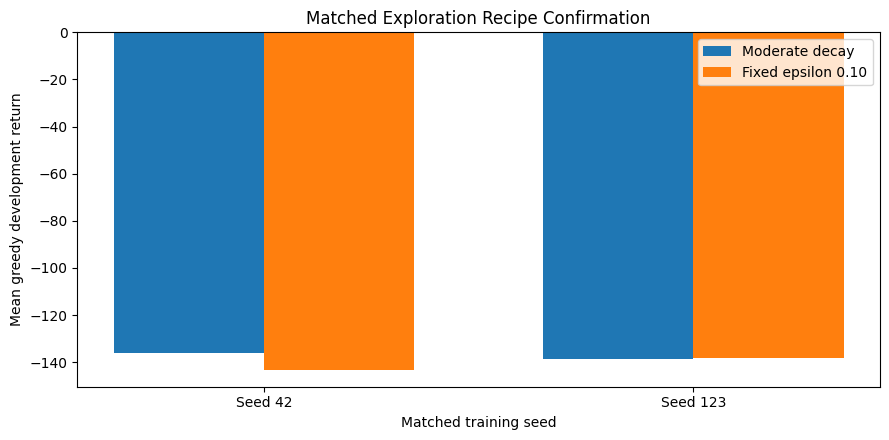

Fixed-epsilon seed-123 run completed: True
Selected checkpoint episode: 100
Seed-123 fixed mean development return: -138.2367004052053
Seed-123 moderate mean development return: -138.52228717953105
Seed-123 fixed-minus-moderate: 0.2855867743257363
Matched two-seed fixed-minus-moderate: -3.4992434842891953
Fixed seed win count: 1
Aggregate difference within practical margin: True
Formal runs completed: 11
Remaining formal-run capacity: 17
Saved exploration matched confirmation: histories\R50_exploration_matched_seed_confirmation.csv
Saved exploration confirmation aggregate: histories\R50_exploration_matched_seed_confirmation_aggregate.csv
Section 11.6.1 matched exploration confirmation: COMPLETE


In [67]:
R50_FIXED_CONFIRMATION_SEED = 123
R50_FIXED_CONFIRMATION_RUN_ID = (
    "R50_EXPLORE_FIXED_010_SEED_123"
)

R50_FIXED_CONFIRMATION_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R50_FIXED_CONFIRMATION_RUN_ID}_best.weights.h5"
)
R50_FIXED_CONFIRMATION_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{R50_FIXED_CONFIRMATION_RUN_ID}_history.csv"
)
R50_FIXED_CONFIRMATION_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{R50_FIXED_CONFIRMATION_RUN_ID}"
        "_development_evaluations.csv"
    )
)
R50_FIXED_CONFIRMATION_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R50_FIXED_CONFIRMATION_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
R50_FIXED_CONFIRMATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R50_FIXED_CONFIRMATION_RUN_ID}_summary.csv"
)
R50_FIXED_CONFIRMATION_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{R50_FIXED_CONFIRMATION_RUN_ID}"
        "_selected_state_results.csv"
    )
)
EXPLORATION_MATCHED_CONFIRMATION_PATH = (
    HISTORIES_DIR
    / "R50_exploration_matched_seed_confirmation.csv"
)
EXPLORATION_MATCHED_CONFIRMATION_AGGREGATE_PATH = (
    HISTORIES_DIR
    / "R50_exploration_matched_seed_confirmation_aggregate.csv"
)

assert EXPLORATION_SCREENING_LEADER == "moderate_decay"
assert EXPLORATION_CONFIRMATION_CANDIDATE == "fixed_0.10"
assert EXPLORATION_MATCHED_CONFIRMATION_REQUIRED is True
assert R50_FIXED_CONFIRMATION_SEED == 123
assert int(
    r42_confirmation_summary_record["seed"]
) == 123
assert FORMAL_RUNS_COMPLETED in (10, 11)
assert remaining_formal_run_capacity in (18, 17)

r50_fixed_confirmation_required_artifacts = [
    R50_FIXED_CONFIRMATION_WEIGHT_PATH,
    R50_FIXED_CONFIRMATION_HISTORY_PATH,
    R50_FIXED_CONFIRMATION_EVALUATION_PATH,
    R50_FIXED_CONFIRMATION_EVALUATION_SUMMARY_PATH,
    R50_FIXED_CONFIRMATION_SUMMARY_PATH,
    R50_FIXED_CONFIRMATION_STATE_RESULTS_PATH,
]
r50_fixed_confirmation_artifacts_complete = all(
    path.exists()
    for path in r50_fixed_confirmation_required_artifacts
)

if (
    "r50_fixed_confirmation_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "r50_fixed_confirmation_history",
            "r50_fixed_confirmation_evaluation_states",
            "r50_fixed_confirmation_evaluation_summary",
            "r50_fixed_confirmation_selected_state_results",
            "r50_fixed_confirmation_summary",
        ]
    )
):
    print(
        "Fixed-epsilon seed-123 result already exists in memory; "
        "no duplicate training run was started."
    )
elif r50_fixed_confirmation_artifacts_complete:
    r50_fixed_confirmation_history = read_csv_with_control_metric_migration(
        R50_FIXED_CONFIRMATION_HISTORY_PATH
    )
    r50_fixed_confirmation_evaluation_states = read_csv_with_control_metric_migration(
        R50_FIXED_CONFIRMATION_EVALUATION_PATH
    )
    r50_fixed_confirmation_evaluation_summary = read_csv_with_control_metric_migration(
        R50_FIXED_CONFIRMATION_EVALUATION_SUMMARY_PATH
    )
    r50_fixed_confirmation_summary = read_csv_with_control_metric_migration(
        R50_FIXED_CONFIRMATION_SUMMARY_PATH
    )
    r50_fixed_confirmation_selected_state_results = read_csv_with_control_metric_migration(
        R50_FIXED_CONFIRMATION_STATE_RESULTS_PATH
    )

    assert len(r50_fixed_confirmation_summary) == 1
    r50_fixed_confirmation_summary_record = (
        r50_fixed_confirmation_summary.iloc[0].to_dict()
    )
    r50_fixed_confirmation_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FOUNDATION_SCREEN_ACTION_COUNT,
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r50_fixed_seed_123_reloaded_q_network"
            ),
        )
    )
    r50_fixed_confirmation_selected_model.load_weights(
        R50_FIXED_CONFIRMATION_WEIGHT_PATH
    )
    print(
        "Loaded completed fixed-epsilon seed-123 artifacts; "
        "no duplicate training run was started."
    )
else:
    original_action_comparison_epsilon = (
        action_comparison_epsilon
    )

    def fixed_seed_123_exploration_epsilon(
        environment_step: int,
    ) -> float:
        """Return fixed epsilon 0.10 for every seed-123 step."""
        assert int(environment_step) >= 0
        return float(R50_FIXED_EPSILON)

    action_comparison_epsilon = (
        fixed_seed_123_exploration_epsilon
    )

    try:
        r50_fixed_confirmation_result = (
            run_dueling_dqn_foundation(
                run_id=R50_FIXED_CONFIRMATION_RUN_ID,
                torque_values=(
                    FOUNDATION_SCREEN_TORQUE_VALUES
                ),
                seed=R50_FIXED_CONFIRMATION_SEED,
                weight_path=(
                    R50_FIXED_CONFIRMATION_WEIGHT_PATH
                ),
            )
        )
    finally:
        action_comparison_epsilon = (
            original_action_comparison_epsilon
        )

    r50_fixed_confirmation_history = (
        r50_fixed_confirmation_result["history"]
    )
    r50_fixed_confirmation_evaluation_states = (
        r50_fixed_confirmation_result[
            "evaluation_states"
        ]
    )
    r50_fixed_confirmation_evaluation_summary = (
        r50_fixed_confirmation_result[
            "evaluation_summary"
        ]
    )
    r50_fixed_confirmation_selected_state_results = (
        r50_fixed_confirmation_result[
            "selected_state_results"
        ]
    )
    r50_fixed_confirmation_selected_model = (
        r50_fixed_confirmation_result[
            "selected_model"
        ]
    )
    r50_fixed_confirmation_summary_record = dict(
        r50_fixed_confirmation_result[
            "summary_record"
        ]
    )
    r50_fixed_confirmation_summary_record.update({
        "exploration_recipe": "fixed_0.10",
        "epsilon_start": R50_FIXED_EPSILON,
        "epsilon_end": R50_FIXED_EPSILON,
        "epsilon_decay_shape": "none",
        "epsilon_decay_steps": 0,
        "reference_run_id": (
            "R42_DUELING_SEED_123"
        ),
    })
    r50_fixed_confirmation_summary = pd.DataFrame(
        [r50_fixed_confirmation_summary_record]
    )

FORMAL_RUNS_COMPLETED = 11
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 11
assert remaining_formal_run_capacity == 17
assert len(r50_fixed_confirmation_history) == 150
assert len(
    r50_fixed_confirmation_evaluation_summary
) == 7
assert int(
    r50_fixed_confirmation_summary_record["seed"]
) == 123
assert (
    r50_fixed_confirmation_summary_record["model"]
    == "Dueling DQN"
)
assert int(
    r50_fixed_confirmation_summary_record["action_count"]
) == 7
assert int(
    r50_fixed_confirmation_summary_record["parameter_count"]
) == 4936
assert int(
    r50_fixed_confirmation_summary_record[
        "environment_steps"
    ]
) == 30_000
assert int(
    r50_fixed_confirmation_summary_record[
        "optimizer_updates"
    ]
) == 29_001
assert int(
    r50_fixed_confirmation_summary_record[
        "target_updates"
    ]
) == 116
assert np.allclose(
    r50_fixed_confirmation_history[
        "epsilon"
    ].to_numpy(dtype=np.float64),
    R50_FIXED_EPSILON,
    rtol=0.0,
    atol=0.0,
)
assert np.isfinite(
    r50_fixed_confirmation_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert R50_FIXED_CONFIRMATION_WEIGHT_PATH.exists()

r50_fixed_confirmation_history.to_csv(
    R50_FIXED_CONFIRMATION_HISTORY_PATH,
    index=False,
)
r50_fixed_confirmation_evaluation_states.to_csv(
    R50_FIXED_CONFIRMATION_EVALUATION_PATH,
    index=False,
)
r50_fixed_confirmation_evaluation_summary.to_csv(
    R50_FIXED_CONFIRMATION_EVALUATION_SUMMARY_PATH,
    index=False,
)
r50_fixed_confirmation_summary.to_csv(
    R50_FIXED_CONFIRMATION_SUMMARY_PATH,
    index=False,
)
r50_fixed_confirmation_selected_state_results.to_csv(
    R50_FIXED_CONFIRMATION_STATE_RESULTS_PATH,
    index=False,
)

exploration_matched_seed_sources = {
    42: {
        "reference_summary": r42_summary_record,
        "candidate_summary": r50_fixed_summary_record,
        "reference_states": (
            r42_selected_state_results.copy()
        ),
        "candidate_states": (
            r50_fixed_selected_state_results.copy()
        ),
    },
    123: {
        "reference_summary": (
            r42_confirmation_summary_record
        ),
        "candidate_summary": (
            r50_fixed_confirmation_summary_record
        ),
        "reference_states": (
            r42_confirmation_selected_state_results.copy()
        ),
        "candidate_states": (
            r50_fixed_confirmation_selected_state_results.copy()
        ),
    },
}

exploration_confirmation_records = []

for seed in (42, 123):
    source = exploration_matched_seed_sources[
        seed
    ]
    reference_summary = source[
        "reference_summary"
    ]
    candidate_summary = source[
        "candidate_summary"
    ]

    reference_states = (
        source["reference_states"]
        [["state_id", "return"]]
        .rename(
            columns={
                "return": "moderate_return"
            }
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )
    candidate_states = (
        source["candidate_states"]
        [["state_id", "return"]]
        .rename(
            columns={
                "return": "fixed_return"
            }
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )

    paired = reference_states.merge(
        candidate_states,
        on="state_id",
        how="inner",
        validate="one_to_one",
    )
    assert len(paired) == len(
        DEVELOPMENT_PHYSICAL_STATES
    )

    paired["fixed_minus_moderate"] = (
        paired["fixed_return"]
        - paired["moderate_return"]
    )

    reference_mean = float(
        reference_summary[
            "mean_development_return"
        ]
    )
    candidate_mean = float(
        candidate_summary[
            "mean_development_return"
        ]
    )
    mean_difference = float(
        candidate_mean - reference_mean
    )

    np.testing.assert_allclose(
        mean_difference,
        paired["fixed_minus_moderate"].mean(),
        rtol=0.0,
        atol=1e-6,
    )

    exploration_confirmation_records.append({
        "seed": int(seed),
        "reference_recipe": "moderate_decay",
        "candidate_recipe": "fixed_0.10",
        "reference_mean_return": reference_mean,
        "candidate_mean_return": candidate_mean,
        "candidate_minus_reference": (
            mean_difference
        ),
        "reference_state_std": float(
            reference_summary[
                "development_return_std"
            ]
        ),
        "candidate_state_std": float(
            candidate_summary[
                "development_return_std"
            ]
        ),
        "reference_upright_fraction": float(
            reference_summary[
                "upright_fraction"
            ]
        ),
        "candidate_upright_fraction": float(
            candidate_summary[
                "upright_fraction"
            ]
        ),
        "paired_state_count": int(len(paired)),
        "paired_median_difference": float(
            paired[
                "fixed_minus_moderate"
            ].median()
        ),
        "candidate_win_proportion": float(
            (
                paired[
                    "fixed_minus_moderate"
                ] > 0.0
            ).mean()
        ),
        "reference_win_proportion": float(
            (
                paired[
                    "fixed_minus_moderate"
                ] < 0.0
            ).mean()
        ),
        "minimum_paired_difference": float(
            paired[
                "fixed_minus_moderate"
            ].min()
        ),
        "maximum_paired_difference": float(
            paired[
                "fixed_minus_moderate"
            ].max()
        ),
        "within_practical_margin": bool(
            abs(mean_difference)
            <= PRACTICAL_IMPROVEMENT_MARGIN
        ),
    })

exploration_matched_confirmation = pd.DataFrame(
    exploration_confirmation_records
).sort_values("seed").reset_index(drop=True)

reference_seed_means = (
    exploration_matched_confirmation[
        "reference_mean_return"
    ].to_numpy(dtype=np.float64)
)
candidate_seed_means = (
    exploration_matched_confirmation[
        "candidate_mean_return"
    ].to_numpy(dtype=np.float64)
)
seed_level_differences = (
    exploration_matched_confirmation[
        "candidate_minus_reference"
    ].to_numpy(dtype=np.float64)
)

exploration_confirmation_aggregate_record = {
    "matched_seeds": [42, 123],
    "reference_recipe": "moderate_decay",
    "candidate_recipe": "fixed_0.10",
    "reference_mean_across_seeds": float(
        np.mean(reference_seed_means)
    ),
    "candidate_mean_across_seeds": float(
        np.mean(candidate_seed_means)
    ),
    "candidate_minus_reference_across_seed_means": float(
        np.mean(candidate_seed_means)
        - np.mean(reference_seed_means)
    ),
    "mean_of_seed_level_differences": float(
        np.mean(seed_level_differences)
    ),
    "candidate_seed_win_count": int(
        np.sum(seed_level_differences > 0.0)
    ),
    "reference_seed_win_count": int(
        np.sum(seed_level_differences < 0.0)
    ),
    "practical_improvement_margin": float(
        PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "aggregate_difference_within_margin": bool(
        abs(np.mean(seed_level_differences))
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "selection_deferred_until_review": True,
    "formal_significance_claim": False,
}

exploration_confirmation_aggregate = pd.DataFrame(
    [exploration_confirmation_aggregate_record]
)

assert len(exploration_matched_confirmation) == 2
assert exploration_matched_confirmation[
    "seed"
].tolist() == [42, 123]
assert (
    exploration_matched_confirmation[
        "paired_state_count"
    ] == len(DEVELOPMENT_PHYSICAL_STATES)
).all()
assert np.isfinite(
    exploration_matched_confirmation
    .select_dtypes(include=[np.number])
    .to_numpy(dtype=np.float64)
).all()
assert np.isclose(
    exploration_confirmation_aggregate_record[
        "candidate_minus_reference_across_seed_means"
    ],
    exploration_confirmation_aggregate_record[
        "mean_of_seed_level_differences"
    ],
    rtol=0.0,
    atol=1e-12,
)
assert (
    exploration_confirmation_aggregate_record[
        "selection_deferred_until_review"
    ] is True
)

exploration_matched_confirmation.to_csv(
    EXPLORATION_MATCHED_CONFIRMATION_PATH,
    index=False,
)
exploration_confirmation_aggregate.to_csv(
    EXPLORATION_MATCHED_CONFIRMATION_AGGREGATE_PATH,
    index=False,
)

display(
    r50_fixed_confirmation_evaluation_summary
)
display(r50_fixed_confirmation_summary)
display(exploration_matched_confirmation)
display(exploration_confirmation_aggregate)

plt.figure(figsize=(9, 4.5))
x_positions = np.arange(2)
bar_width = 0.35
plt.bar(
    x_positions - bar_width / 2,
    reference_seed_means,
    width=bar_width,
    label="Moderate decay",
)
plt.bar(
    x_positions + bar_width / 2,
    candidate_seed_means,
    width=bar_width,
    label="Fixed epsilon 0.10",
)
plt.xticks(
    x_positions,
    ["Seed 42", "Seed 123"],
)
plt.xlabel("Matched training seed")
plt.ylabel("Mean greedy development return")
plt.title("Matched Exploration Recipe Confirmation")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Fixed-epsilon seed-123 run completed:",
    True,
)
print(
    "Selected checkpoint episode:",
    r50_fixed_confirmation_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Seed-123 fixed mean development return:",
    r50_fixed_confirmation_summary_record[
        "mean_development_return"
    ],
)
print(
    "Seed-123 moderate mean development return:",
    r42_confirmation_summary_record[
        "mean_development_return"
    ],
)
print(
    "Seed-123 fixed-minus-moderate:",
    exploration_matched_confirmation.loc[
        exploration_matched_confirmation[
            "seed"
        ] == 123,
        "candidate_minus_reference",
    ].iloc[0],
)
print(
    "Matched two-seed fixed-minus-moderate:",
    exploration_confirmation_aggregate_record[
        "candidate_minus_reference_across_seed_means"
    ],
)
print(
    "Fixed seed win count:",
    exploration_confirmation_aggregate_record[
        "candidate_seed_win_count"
    ],
)
print(
    "Aggregate difference within practical margin:",
    exploration_confirmation_aggregate_record[
        "aggregate_difference_within_margin"
    ],
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved exploration matched confirmation:",
    EXPLORATION_MATCHED_CONFIRMATION_PATH,
)
print(
    "Saved exploration confirmation aggregate:",
    EXPLORATION_MATCHED_CONFIRMATION_AGGREGATE_PATH,
)
print(
    "Section 11.6.1 matched exploration confirmation: COMPLETE"
)


### 11.6.1 Result Interpretation

**Finding.** Fixed epsilon `0.10` and moderate decay split the two matched
seed-level comparisons:

| Seed | Moderate decay | Fixed epsilon | Fixed minus moderate |
|---|---:|---:|---:|
| `42` | `-135.942190` | `-143.226264` | `-7.284074` |
| `123` | `-138.522287` | `-138.236700` | `+0.285587` |

Across both seeds, moderate decay averaged `-137.232239`, while fixed epsilon
averaged `-140.731482`. Fixed epsilon therefore trailed by `3.499243`.
The aggregate difference remains inside the locked practical margin.

Moderate decay had the lower average state-wise return spread and higher
average upright fraction. Fixed epsilon reached its selected checkpoints
earlier, but its average runtime was substantially longer.

**Importance.** The result is practically close, but the primary return
criterion and stability tie-break favour moderate decay. The recipes each won
one seed, so the result must not be described as formal proof of universal
superiority.

**Decision.** Retain moderate decay as the exploration recipe.

**Caveat.** Fixed epsilon demonstrated better sample efficiency and slightly
outperformed moderate decay under seed `123`. It remains a credible
alternative rather than a failed recipe.

**Next step.** Lock moderate decay and begin the replay and target-network
recipe comparison.


### 11.6.2 Exploration Selection

The exploration recipe is selected using the locked hierarchy:

1. mean greedy development return;
2. stability and failure frequency;
3. sample efficiency;
4. simplicity, runtime and reproducibility.

Moderate decay is selected because it achieved the better two-seed aggregate
return, lower average state-wise spread, higher average upright fraction and
lower average runtime. Fixed epsilon won the sample-efficiency tie-break but
not the earlier criteria.

The selected schedule is:

```text
epsilon 1.00 → 0.05 linearly over 20,000 environment steps
```


In [68]:
EXPLORATION_SELECTION_PATH = (
    HISTORIES_DIR
    / "R50_exploration_recipe_selection.csv"
)

exploration_confirmation_table = (
    exploration_matched_confirmation
    .sort_values("seed")
    .reset_index(drop=True)
)

moderate_mean_across_seeds = float(
    exploration_confirmation_table[
        "reference_mean_return"
    ].mean()
)
fixed_mean_across_seeds = float(
    exploration_confirmation_table[
        "candidate_mean_return"
    ].mean()
)
fixed_minus_moderate_across_seeds = float(
    fixed_mean_across_seeds
    - moderate_mean_across_seeds
)

moderate_average_state_std = float(
    exploration_confirmation_table[
        "reference_state_std"
    ].mean()
)
fixed_average_state_std = float(
    exploration_confirmation_table[
        "candidate_state_std"
    ].mean()
)

moderate_average_upright = float(
    exploration_confirmation_table[
        "reference_upright_fraction"
    ].mean()
)
fixed_average_upright = float(
    exploration_confirmation_table[
        "candidate_upright_fraction"
    ].mean()
)

moderate_selected_episode_mean = float(
    np.mean([
        r42_summary_record[
            "selected_checkpoint_episode"
        ],
        r42_confirmation_summary_record[
            "selected_checkpoint_episode"
        ],
    ])
)
fixed_selected_episode_mean = float(
    np.mean([
        r50_fixed_summary_record[
            "selected_checkpoint_episode"
        ],
        r50_fixed_confirmation_summary_record[
            "selected_checkpoint_episode"
        ],
    ])
)

moderate_runtime_mean = float(
    np.mean([
        r42_summary_record["runtime_minutes"],
        r42_confirmation_summary_record[
            "runtime_minutes"
        ],
    ])
)
fixed_runtime_mean = float(
    np.mean([
        r50_fixed_summary_record[
            "runtime_minutes"
        ],
        r50_fixed_confirmation_summary_record[
            "runtime_minutes"
        ],
    ])
)

SELECTED_EXPLORATION_RECIPE = "moderate_decay"
SELECTED_EPSILON_START = 1.00
SELECTED_EPSILON_END = 0.05
SELECTED_EPSILON_DECAY_STEPS = 20_000
SELECTED_EXPLORATION_SOURCE_RUN_ID = R42_RUN_ID
EXPLORATION_SELECTION_LOCKED = True

exploration_selection_record = {
    "selected_recipe": (
        SELECTED_EXPLORATION_RECIPE
    ),
    "matched_seeds": [42, 123],
    "moderate_mean_across_seeds": (
        moderate_mean_across_seeds
    ),
    "fixed_mean_across_seeds": (
        fixed_mean_across_seeds
    ),
    "fixed_minus_moderate_across_seeds": (
        fixed_minus_moderate_across_seeds
    ),
    "practical_improvement_margin": float(
        PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "difference_within_practical_margin": bool(
        abs(fixed_minus_moderate_across_seeds)
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "moderate_seed_win_count": int(
        (
            exploration_confirmation_table[
                "candidate_minus_reference"
            ] < 0.0
        ).sum()
    ),
    "fixed_seed_win_count": int(
        (
            exploration_confirmation_table[
                "candidate_minus_reference"
            ] > 0.0
        ).sum()
    ),
    "moderate_average_state_std": (
        moderate_average_state_std
    ),
    "fixed_average_state_std": (
        fixed_average_state_std
    ),
    "moderate_average_upright_fraction": (
        moderate_average_upright
    ),
    "fixed_average_upright_fraction": (
        fixed_average_upright
    ),
    "moderate_mean_selected_episode": (
        moderate_selected_episode_mean
    ),
    "fixed_mean_selected_episode": (
        fixed_selected_episode_mean
    ),
    "sample_efficiency_tie_break_winner": (
        "fixed_0.10"
    ),
    "moderate_average_runtime_minutes": (
        moderate_runtime_mean
    ),
    "fixed_average_runtime_minutes": (
        fixed_runtime_mean
    ),
    "stability_tie_break_winner": (
        "moderate_decay"
    ),
    "runtime_tie_break_winner": (
        "moderate_decay"
    ),
    "slow_decay_approved": False,
    "formal_significance_claim": False,
    "selection_status": "LOCKED",
}

exploration_selection_summary = pd.DataFrame(
    [exploration_selection_record]
)

assert SELECTED_EXPLORATION_RECIPE == (
    "moderate_decay"
)
assert SELECTED_EPSILON_START == 1.00
assert SELECTED_EPSILON_END == 0.05
assert SELECTED_EPSILON_DECAY_STEPS == 20_000
assert EXPLORATION_SELECTION_LOCKED is True
assert exploration_confirmation_table[
    "seed"
].tolist() == [42, 123]
assert moderate_mean_across_seeds > (
    fixed_mean_across_seeds
)
assert moderate_average_state_std < (
    fixed_average_state_std
)
assert moderate_average_upright > (
    fixed_average_upright
)
assert fixed_selected_episode_mean < (
    moderate_selected_episode_mean
)
assert moderate_runtime_mean < fixed_runtime_mean
assert FORMAL_RUNS_COMPLETED == 11
assert remaining_formal_run_capacity == 17

exploration_selection_summary.to_csv(
    EXPLORATION_SELECTION_PATH,
    index=False,
)

display(exploration_selection_summary)

print(
    "Selected exploration recipe:",
    SELECTED_EXPLORATION_RECIPE,
)
print(
    "Matched seeds:",
    exploration_selection_record[
        "matched_seeds"
    ],
)
print(
    "Fixed-minus-moderate across matched seeds:",
    fixed_minus_moderate_across_seeds,
)
print(
    "Average state-wise standard deviation, moderate:",
    moderate_average_state_std,
)
print(
    "Average state-wise standard deviation, fixed:",
    fixed_average_state_std,
)
print(
    "Mean selected episode, moderate:",
    moderate_selected_episode_mean,
)
print(
    "Mean selected episode, fixed:",
    fixed_selected_episode_mean,
)
print(
    "Average runtime minutes, moderate:",
    moderate_runtime_mean,
)
print(
    "Average runtime minutes, fixed:",
    fixed_runtime_mean,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved exploration selection:",
    EXPLORATION_SELECTION_PATH,
)
print("Section 11.6.2 exploration selection: PASS")


,selected_recipe,matched_seeds,moderate_mean_across_seeds,fixed_mean_across_seeds,fixed_minus_moderate_across_seeds,practical_improvement_margin,difference_within_practical_margin,moderate_seed_win_count,fixed_seed_win_count,moderate_average_state_std,...,moderate_mean_selected_episode,fixed_mean_selected_episode,sample_efficiency_tie_break_winner,moderate_average_runtime_minutes,fixed_average_runtime_minutes,stability_tie_break_winner,runtime_tie_break_winner,slow_decay_approved,formal_significance_claim,selection_status
0,moderate_decay,"[42, 123]",-137.232239,-140.731482,-3.499243,11.335072,True,1,1,100.866287,...,125.0,87.5,fixed_0.10,13.325378,19.758871,moderate_decay,moderate_decay,False,False,LOCKED


Selected exploration recipe: moderate_decay
Matched seeds: [42, 123]
Fixed-minus-moderate across matched seeds: -3.4992434842891953
Average state-wise standard deviation, moderate: 100.86628720658445
Average state-wise standard deviation, fixed: 104.44172966328718
Mean selected episode, moderate: 125.0
Mean selected episode, fixed: 87.5
Average runtime minutes, moderate: 13.32537784916664
Average runtime minutes, fixed: 19.75887060500002
Formal runs completed: 11
Remaining formal-run capacity: 17
Saved exploration selection: histories\R50_exploration_recipe_selection.csv
Section 11.6.2 exploration selection: PASS


### 11.6.2 Result Interpretation

**Finding.** Moderate decay was formally selected as the exploration recipe
after the matched seed-42 and seed-123 comparison.

Across both matched seeds:

- moderate decay averaged `-137.232239`;
- fixed epsilon averaged `-140.731482`;
- fixed epsilon trailed by `3.499243`;
- each recipe won one seed-level comparison;
- moderate decay had the lower average state-wise spread
  (`100.866287` versus `104.441730`);
- moderate decay had the lower average runtime
  (`13.325378` versus `19.758871` minutes).

Fixed epsilon reached its selected checkpoint earlier on average
(`87.5` episodes versus `125.0`), so it won the sample-efficiency tie-break.

**Decision.** Lock the linear moderate-decay schedule:

```text
epsilon 1.00 → 0.05 over 20,000 environment steps
```

The difference remains inside the practical margin, so this is a cautious
selection based on aggregate return and stability rather than a formal
significance claim.

**Next step.** Execute Replay and Target-Network Alternative 1 while keeping
the selected moderate exploration schedule fixed.


# 12. Replay and Target-Network Recipe Comparison

## 12.1 Question, Hypothesis and Controls

**Question.** Can a more conservative replay and hard-target recipe reduce
late evaluation movement and suspicious Q-value behaviour without harming
control performance?

**Diagnosis link.** The selected foundation showed one late-degradation case,
large TD-loss and gradient scales, and one positive maximum-Q warning.

## 12.2 baseline Reference Recipe

The selected Dueling foundation is reused as the reference:

```text
Replay capacity: 10,000
Replay warm-up: 1,000
Batch size: 32
Hard target update: every 250 optimiser updates
```

No new reference run is consumed because `R42_DUELING` matches the selected
architecture, exploration schedule, seed and evaluation protocol.

## 12.3 Alternative Recipe 1

The alternative is one coherent conservative recipe:

```text
Replay capacity: 20,000
Replay warm-up: 2,000
Batch size: 64
Hard target update: every 500 optimiser updates
```

The larger and later replay sample aims to increase transition diversity,
while the larger batch and slower hard-target update aim to reduce abrupt
value-target movement.

All non-replay and non-target settings remain fixed, including the selected
moderate exploration schedule.

This experiment consumes one formal-training slot. After completion, the
formal-run count should be `12`, leaving `16` runs.


Loaded completed replay-target alternative artifacts; no duplicate training run was started.


,recipe,run_id,replay_capacity,replay_warmup,batch_size,target_update_frequency,source,status
0,reference,R42_DUELING,10000,1000,32,250,reused selected-foundation run,REFERENCE AVAILABLE
1,alternative_1,R60_REPLAY_TARGET_ALT1,20000,2000,64,500,fresh seed-42 run,ACTIVE


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1474.850023,-1421.686562,228.929283,-1816.480863,-1149.851953,0.009583,2.569736,1.605649,0.847083,0.072446
1,25,-1159.313269,-1151.096115,182.850699,-1518.529329,-847.918207,0.016250,2.195470,2.096320,1.950972,0.032663
2,50,-142.118360,-125.990440,106.520751,-367.617850,-0.557314,0.861250,0.264159,0.523604,1.008472,0.724456
3,75,-240.270056,-128.162111,265.538322,-914.405079,-0.845292,0.773542,0.392588,0.957754,1.019861,0.774707
4,100,-139.701199,-125.069016,103.211369,-361.117631,-1.545520,0.870000,0.289211,0.513486,1.018333,0.722990
5,125,-143.228665,-126.388535,103.560720,-341.429393,-2.021746,0.864375,0.306198,0.528251,0.588611,0.432998
6,150,-144.512656,-126.313026,107.281168,-375.367042,-0.616490,0.855000,0.250500,0.544448,1.291111,0.705193


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,parameter_count,weight_path,technical_status,replay_target_recipe,replay_capacity,replay_warmup,batch_size,target_update_frequency,exploration_recipe,reference_run_id
0,R60_REPLAY_TARGET_ALT1,R60_REPLAY_TARGET_ALT1,False,True,Dueling DQN,default,42,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS,alternative_1,20000,2000,64,500,moderate_decay,R42_DUELING


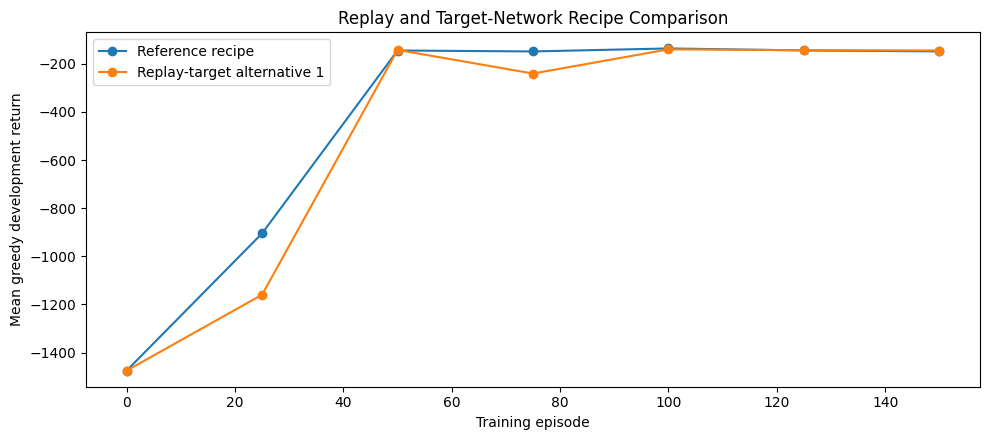

Replay-target alternative run completed: True
Selected checkpoint episode: 100
Mean development return: -139.7011987793661
Development return standard deviation: 103.21136898446096
Optimizer updates: 28001
Target updates: 56
Alternative-minus-reference mean return: -3.7590086651207457
Within practical improvement margin: True
Formal runs completed: 12
Remaining formal-run capacity: 16
Saved replay-target alternative history: histories\R60_REPLAY_TARGET_ALT1_history.csv
Saved replay-target alternative summary: histories\R60_REPLAY_TARGET_ALT1_summary.csv
Saved replay-target alternative weights: selected_weights\R60_REPLAY_TARGET_ALT1_best.weights.h5
Section 12.3 replay-target alternative 1: COMPLETE


In [69]:
R60_ALT1_RUN_ID = "R60_REPLAY_TARGET_ALT1"

R60_ALT1_REPLAY_CAPACITY = 20_000
R60_ALT1_REPLAY_WARMUP = 2_000
R60_ALT1_BATCH_SIZE = 64
R60_ALT1_TARGET_UPDATE_FREQUENCY = 500

R60_ALT1_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R60_ALT1_RUN_ID}_best.weights.h5"
)
R60_ALT1_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{R60_ALT1_RUN_ID}_history.csv"
)
R60_ALT1_EVALUATION_PATH = (
    HISTORIES_DIR
    / f"{R60_ALT1_RUN_ID}_development_evaluations.csv"
)
R60_ALT1_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R60_ALT1_RUN_ID}_development_evaluation_summary.csv"
)
R60_ALT1_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R60_ALT1_RUN_ID}_summary.csv"
)
R60_ALT1_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / f"{R60_ALT1_RUN_ID}_selected_state_results.csv"
)
REPLAY_TARGET_RECIPE_PLAN_PATH = (
    HISTORIES_DIR
    / "R60_replay_target_recipe_plan.csv"
)

assert EXPLORATION_SELECTION_LOCKED is True
assert SELECTED_EXPLORATION_RECIPE == (
    "moderate_decay"
)
assert SELECTED_EPSILON_DECAY_STEPS == 20_000
assert FORMAL_RUNS_COMPLETED in (11, 12)
assert remaining_formal_run_capacity in (17, 16)

replay_target_recipe_plan = pd.DataFrame([
    {
        "recipe": "reference",
        "run_id": R42_RUN_ID,
        "replay_capacity": (
            ACTION_COMPARISON_REPLAY_CAPACITY
        ),
        "replay_warmup": (
            ACTION_COMPARISON_REPLAY_WARMUP
        ),
        "batch_size": (
            ACTION_COMPARISON_BATCH_SIZE
        ),
        "target_update_frequency": (
            ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY
        ),
        "source": "reused selected-foundation run",
        "status": "REFERENCE AVAILABLE",
    },
    {
        "recipe": "alternative_1",
        "run_id": R60_ALT1_RUN_ID,
        "replay_capacity": (
            R60_ALT1_REPLAY_CAPACITY
        ),
        "replay_warmup": (
            R60_ALT1_REPLAY_WARMUP
        ),
        "batch_size": (
            R60_ALT1_BATCH_SIZE
        ),
        "target_update_frequency": (
            R60_ALT1_TARGET_UPDATE_FREQUENCY
        ),
        "source": "fresh seed-42 run",
        "status": "ACTIVE",
    },
])

assert replay_target_recipe_plan[
    "recipe"
].tolist() == [
    "reference",
    "alternative_1",
]
assert int(
    replay_target_recipe_plan.loc[
        replay_target_recipe_plan["recipe"]
        == "reference",
        "replay_capacity",
    ].iloc[0]
) == 10_000
assert int(
    replay_target_recipe_plan.loc[
        replay_target_recipe_plan["recipe"]
        == "reference",
        "target_update_frequency",
    ].iloc[0]
) == 250

replay_target_recipe_plan.to_csv(
    REPLAY_TARGET_RECIPE_PLAN_PATH,
    index=False,
)

r60_alt1_required_artifacts = [
    R60_ALT1_WEIGHT_PATH,
    R60_ALT1_HISTORY_PATH,
    R60_ALT1_EVALUATION_PATH,
    R60_ALT1_EVALUATION_SUMMARY_PATH,
    R60_ALT1_SUMMARY_PATH,
    R60_ALT1_STATE_RESULTS_PATH,
]
r60_alt1_artifacts_complete = all(
    path.exists()
    for path in r60_alt1_required_artifacts
)

if (
    "r60_alt1_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "r60_alt1_history",
            "r60_alt1_evaluation_states",
            "r60_alt1_evaluation_summary",
            "r60_alt1_selected_state_results",
            "r60_alt1_summary",
        ]
    )
):
    print(
        "Replay-target alternative result already exists in memory; "
        "no duplicate training run was started."
    )
elif r60_alt1_artifacts_complete:
    r60_alt1_history = read_csv_with_control_metric_migration(
        R60_ALT1_HISTORY_PATH
    )
    r60_alt1_evaluation_states = read_csv_with_control_metric_migration(
        R60_ALT1_EVALUATION_PATH
    )
    r60_alt1_evaluation_summary = read_csv_with_control_metric_migration(
        R60_ALT1_EVALUATION_SUMMARY_PATH
    )
    r60_alt1_summary = read_csv_with_control_metric_migration(
        R60_ALT1_SUMMARY_PATH
    )
    r60_alt1_selected_state_results = read_csv_with_control_metric_migration(
        R60_ALT1_STATE_RESULTS_PATH
    )

    assert len(r60_alt1_summary) == 1
    r60_alt1_summary_record = (
        r60_alt1_summary.iloc[0].to_dict()
    )
    r60_alt1_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FOUNDATION_SCREEN_ACTION_COUNT,
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r60_alt1_reloaded_q_network"
            ),
        )
    )
    r60_alt1_selected_model.load_weights(
        R60_ALT1_WEIGHT_PATH
    )
    print(
        "Loaded completed replay-target alternative artifacts; "
        "no duplicate training run was started."
    )
else:
    original_replay_capacity = (
        ACTION_COMPARISON_REPLAY_CAPACITY
    )
    original_replay_warmup = (
        ACTION_COMPARISON_REPLAY_WARMUP
    )
    original_batch_size = (
        ACTION_COMPARISON_BATCH_SIZE
    )
    original_target_update_frequency = (
        ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY
    )

    ACTION_COMPARISON_REPLAY_CAPACITY = (
        R60_ALT1_REPLAY_CAPACITY
    )
    ACTION_COMPARISON_REPLAY_WARMUP = (
        R60_ALT1_REPLAY_WARMUP
    )
    ACTION_COMPARISON_BATCH_SIZE = (
        R60_ALT1_BATCH_SIZE
    )
    ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY = (
        R60_ALT1_TARGET_UPDATE_FREQUENCY
    )

    try:
        r60_alt1_result = (
            run_dueling_dqn_foundation(
                run_id=R60_ALT1_RUN_ID,
                torque_values=(
                    FOUNDATION_SCREEN_TORQUE_VALUES
                ),
                seed=FOUNDATION_SCREEN_SEED,
                weight_path=R60_ALT1_WEIGHT_PATH,
            )
        )
    finally:
        ACTION_COMPARISON_REPLAY_CAPACITY = (
            original_replay_capacity
        )
        ACTION_COMPARISON_REPLAY_WARMUP = (
            original_replay_warmup
        )
        ACTION_COMPARISON_BATCH_SIZE = (
            original_batch_size
        )
        ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY = (
            original_target_update_frequency
        )

    r60_alt1_history = (
        r60_alt1_result["history"]
    )
    r60_alt1_evaluation_states = (
        r60_alt1_result["evaluation_states"]
    )
    r60_alt1_evaluation_summary = (
        r60_alt1_result["evaluation_summary"]
    )
    r60_alt1_selected_state_results = (
        r60_alt1_result[
            "selected_state_results"
        ]
    )
    r60_alt1_selected_model = (
        r60_alt1_result["selected_model"]
    )
    r60_alt1_summary_record = dict(
        r60_alt1_result["summary_record"]
    )
    r60_alt1_summary_record.update({
        "replay_target_recipe": (
            "alternative_1"
        ),
        "replay_capacity": (
            R60_ALT1_REPLAY_CAPACITY
        ),
        "replay_warmup": (
            R60_ALT1_REPLAY_WARMUP
        ),
        "batch_size": (
            R60_ALT1_BATCH_SIZE
        ),
        "target_update_frequency": (
            R60_ALT1_TARGET_UPDATE_FREQUENCY
        ),
        "exploration_recipe": (
            SELECTED_EXPLORATION_RECIPE
        ),
        "reference_run_id": R42_RUN_ID,
    })
    r60_alt1_summary = pd.DataFrame(
        [r60_alt1_summary_record]
    )

FORMAL_RUNS_COMPLETED = 12
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

expected_optimizer_updates = (
    ACTION_COMPARISON_EPISODES
    * EVALUATION_HORIZON
    - R60_ALT1_REPLAY_WARMUP
    + 1
)
expected_target_updates = (
    expected_optimizer_updates
    // R60_ALT1_TARGET_UPDATE_FREQUENCY
)

assert FORMAL_RUNS_COMPLETED == 12
assert remaining_formal_run_capacity == 16
assert len(r60_alt1_history) == 150
assert len(r60_alt1_evaluation_summary) == 7
assert int(
    r60_alt1_summary_record["seed"]
) == 42
assert (
    r60_alt1_summary_record["model"]
    == "Dueling DQN"
)
assert int(
    r60_alt1_summary_record["action_count"]
) == 7
assert int(
    r60_alt1_summary_record["parameter_count"]
) == 4936
assert int(
    r60_alt1_summary_record["environment_steps"]
) == 30_000
assert int(
    r60_alt1_summary_record["optimizer_updates"]
) == expected_optimizer_updates
assert int(
    r60_alt1_summary_record["target_updates"]
) == expected_target_updates
assert int(
    r60_alt1_history["replay_size"].iloc[-1]
) == R60_ALT1_REPLAY_CAPACITY
assert np.isclose(
    float(r60_alt1_history["epsilon"].iloc[-1]),
    SELECTED_EPSILON_END,
    rtol=0.0,
    atol=1e-12,
)
assert np.isfinite(
    r60_alt1_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert R60_ALT1_WEIGHT_PATH.exists()

r60_alt1_history.to_csv(
    R60_ALT1_HISTORY_PATH,
    index=False,
)
r60_alt1_evaluation_states.to_csv(
    R60_ALT1_EVALUATION_PATH,
    index=False,
)
r60_alt1_evaluation_summary.to_csv(
    R60_ALT1_EVALUATION_SUMMARY_PATH,
    index=False,
)
r60_alt1_summary.to_csv(
    R60_ALT1_SUMMARY_PATH,
    index=False,
)
r60_alt1_selected_state_results.to_csv(
    R60_ALT1_STATE_RESULTS_PATH,
    index=False,
)

REPLAY_TARGET_RECIPE_RESULTS = {
    "reference": r42_summary_record,
    "alternative_1": r60_alt1_summary_record,
}
REPLAY_TARGET_RECIPE_STATE_RESULTS = {
    "reference": (
        r42_selected_state_results.copy()
    ),
    "alternative_1": (
        r60_alt1_selected_state_results.copy()
    ),
}
REPLAY_TARGET_RECIPE_EVALUATIONS = {
    "reference": (
        r42_evaluation_summary.copy()
    ),
    "alternative_1": (
        r60_alt1_evaluation_summary.copy()
    ),
}

alternative_minus_reference = float(
    r60_alt1_summary_record[
        "mean_development_return"
    ]
    - r42_summary_record[
        "mean_development_return"
    ]
)

display(replay_target_recipe_plan)
display(r60_alt1_evaluation_summary)
display(r60_alt1_summary)

plt.figure(figsize=(10, 4.5))
plt.plot(
    r42_evaluation_summary["episode"],
    r42_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Reference recipe",
)
plt.plot(
    r60_alt1_evaluation_summary["episode"],
    r60_alt1_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Replay-target alternative 1",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("Replay and Target-Network Recipe Comparison")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Replay-target alternative run completed:",
    True,
)
print(
    "Selected checkpoint episode:",
    r60_alt1_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    r60_alt1_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    r60_alt1_summary_record[
        "development_return_std"
    ],
)
print(
    "Optimizer updates:",
    r60_alt1_summary_record[
        "optimizer_updates"
    ],
)
print(
    "Target updates:",
    r60_alt1_summary_record[
        "target_updates"
    ],
)
print(
    "Alternative-minus-reference mean return:",
    alternative_minus_reference,
)
print(
    "Within practical improvement margin:",
    abs(alternative_minus_reference)
    <= PRACTICAL_IMPROVEMENT_MARGIN,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved replay-target alternative history:",
    R60_ALT1_HISTORY_PATH,
)
print(
    "Saved replay-target alternative summary:",
    R60_ALT1_SUMMARY_PATH,
)
print(
    "Saved replay-target alternative weights:",
    R60_ALT1_WEIGHT_PATH,
)
print(
    "Section 12.3 replay-target alternative 1: COMPLETE"
)


### 12.3 Result Interpretation

**Finding.** Replay and Target Alternative 1 completed all `150` episodes
without technical failure.

Its selected checkpoint was episode `100`, with:

- mean development return: `-139.701199`;
- development-state standard deviation: `103.211369`;
- optimiser updates: `28,001`;
- hard target updates: `56`.

It scored `3.759009` below the reference recipe, which remains inside the
locked practical margin.

The alternative reduced the selected-to-final decline to about `4.811457`,
compared with `12.291164` for the reference. However, it also suffered a large
temporary episode-75 drop to `-240.270056` and had higher state-wise spread
than the reference.

**Importance.** The larger replay buffer, later warm-up, larger batch and
slower target updates did not clearly improve control under seed `42`. The
recipe improved one late-stability measure but weakened the primary return
and robustness evidence.

**Decision.** Do not select or reject the alternative from one seed because
the return difference is inside the practical margin.

**Next step.** Confirm Alternative 1 against the existing reference using
matched seed `123`.


### 12.3.1 Matched Seed-123 Confirmation

The reference is the baseline replay and target recipe. Its completed
seed-123 run is:

```text
R42_DUELING_SEED_123
```

The candidate is Replay and Target Alternative 1:

```text
Replay capacity: 20,000
Replay warm-up: 2,000
Batch size: 64
Hard target update: every 500 optimiser updates
```

One fresh seed-123 candidate run is required:

```text
R60_REPLAY_TARGET_ALT1_SEED_123
```

Architecture, action set, gravity, exploration, optimiser, loss, gamma,
training budget, checkpoint rule and development states remain matched.

This consumes one formal-training slot. After completion, the formal-run
count should be `13`, leaving `15` runs.

Alternative 2 and soft target updates remain deferred until this matched
confirmation is reviewed.


Loaded completed Replay-target Alternative 1 seed-123 artifacts; no duplicate run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1513.180553,-1531.216662,216.799448,-1816.480863,-1124.922449,0.005208,2.570358,1.452520,1.181250,0.043551
1,25,-980.290401,-1159.358824,531.065849,-1518.529329,-4.152511,0.208333,1.869358,1.584391,1.760000,0.152219
2,50,-148.256189,-125.839081,110.752518,-374.350997,-0.419869,0.845208,0.285670,0.523316,0.791806,0.637982
3,75,-145.285838,-124.333019,107.413925,-347.027728,-0.077498,0.863542,0.239737,0.542077,1.155972,0.721943
4,100,-147.270098,-124.806444,111.683748,-356.880579,-0.370711,0.858750,0.252350,0.550398,0.952639,0.527848
5,125,-138.181008,-126.451743,100.838779,-355.795211,-1.865012,0.869167,0.278930,0.553828,1.535278,0.561139
6,150,-143.265411,-128.069184,105.323771,-368.810928,-2.523797,0.863333,0.320820,0.521447,1.144306,0.703308


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,parameter_count,weight_path,technical_status,replay_target_recipe,replay_capacity,replay_warmup,batch_size,target_update_frequency,exploration_recipe,reference_run_id
0,R60_REPLAY_TARGET_ALT1_SEED_123,R60_REPLAY_TARGET_ALT1_SEED_123,False,True,Dueling DQN,default,123,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS,alternative_1,20000,2000,64,500,moderate_decay,R42_DUELING_SEED_123


,seed,reference_recipe,candidate_recipe,reference_mean_return,candidate_mean_return,candidate_minus_reference,reference_state_std,candidate_state_std,reference_upright_fraction,candidate_upright_fraction,paired_state_count,paired_median_difference,candidate_win_proportion,reference_win_proportion,minimum_paired_difference,maximum_paired_difference,within_practical_margin
0,42,reference,alternative_1,-135.942190,-139.701199,-3.759009,99.338244,103.211369,0.872292,0.870000,24,-1.189514,0.208333,0.791667,-61.633435,5.399996,True
1,123,reference,alternative_1,-138.522287,-138.181008,0.341280,102.394330,100.838779,0.866667,0.869167,24,-0.834821,0.333333,0.666667,-6.735623,13.696391,True


,matched_seeds,reference_recipe,candidate_recipe,reference_mean_across_seeds,candidate_mean_across_seeds,candidate_minus_reference_across_seed_means,mean_of_seed_level_differences,candidate_seed_win_count,reference_seed_win_count,practical_improvement_margin,aggregate_difference_within_margin,selection_deferred_until_review,formal_significance_claim
0,"[42, 123]",reference,alternative_1,-137.232239,-138.941103,-1.708865,-1.708865,1,1,11.335072,True,True,False


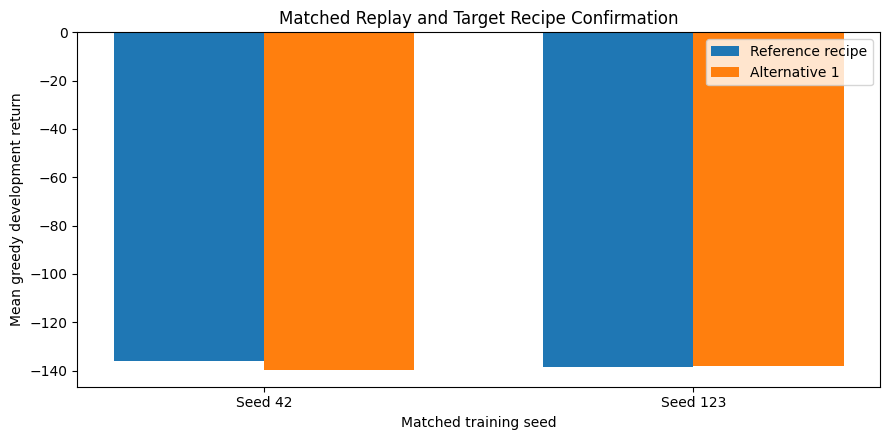

Replay-target Alternative 1 seed-123 run completed: True
Selected checkpoint episode: 125
Seed-123 Alternative 1 mean development return: -138.18100760205598
Seed-123 reference mean development return: -138.52228717953105
Seed-123 alternative-minus-reference: 0.34127957747506343
Matched two-seed alternative-minus-reference: -1.7088645438228127
Alternative seed win count: 1
Aggregate difference within practical margin: True
Formal runs completed: 13
Remaining formal-run capacity: 15
Saved replay-target matched confirmation: histories\R60_replay_target_matched_seed_confirmation.csv
Saved replay-target confirmation aggregate: histories\R60_replay_target_matched_seed_confirmation_aggregate.csv
Section 12.3.1 matched replay-target confirmation: COMPLETE


In [70]:
R60_ALT1_CONFIRMATION_SEED = 123
R60_ALT1_CONFIRMATION_RUN_ID = (
    "R60_REPLAY_TARGET_ALT1_SEED_123"
)

R60_ALT1_CONFIRMATION_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R60_ALT1_CONFIRMATION_RUN_ID}_best.weights.h5"
)
R60_ALT1_CONFIRMATION_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{R60_ALT1_CONFIRMATION_RUN_ID}_history.csv"
)
R60_ALT1_CONFIRMATION_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{R60_ALT1_CONFIRMATION_RUN_ID}"
        "_development_evaluations.csv"
    )
)
R60_ALT1_CONFIRMATION_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R60_ALT1_CONFIRMATION_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
R60_ALT1_CONFIRMATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R60_ALT1_CONFIRMATION_RUN_ID}_summary.csv"
)
R60_ALT1_CONFIRMATION_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{R60_ALT1_CONFIRMATION_RUN_ID}"
        "_selected_state_results.csv"
    )
)
REPLAY_TARGET_MATCHED_CONFIRMATION_PATH = (
    HISTORIES_DIR
    / "R60_replay_target_matched_seed_confirmation.csv"
)
REPLAY_TARGET_MATCHED_CONFIRMATION_AGGREGATE_PATH = (
    HISTORIES_DIR
    / (
        "R60_replay_target_matched_seed_"
        "confirmation_aggregate.csv"
    )
)

assert EXPLORATION_SELECTION_LOCKED is True
assert SELECTED_EXPLORATION_RECIPE == "moderate_decay"
assert R60_ALT1_CONFIRMATION_SEED == 123
assert int(
    r42_confirmation_summary_record["seed"]
) == 123
assert FORMAL_RUNS_COMPLETED in (12, 13)
assert remaining_formal_run_capacity in (16, 15)

r60_alt1_confirmation_required_artifacts = [
    R60_ALT1_CONFIRMATION_WEIGHT_PATH,
    R60_ALT1_CONFIRMATION_HISTORY_PATH,
    R60_ALT1_CONFIRMATION_EVALUATION_PATH,
    R60_ALT1_CONFIRMATION_EVALUATION_SUMMARY_PATH,
    R60_ALT1_CONFIRMATION_SUMMARY_PATH,
    R60_ALT1_CONFIRMATION_STATE_RESULTS_PATH,
]
r60_alt1_confirmation_artifacts_complete = all(
    path.exists()
    for path in r60_alt1_confirmation_required_artifacts
)

if (
    "r60_alt1_confirmation_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "r60_alt1_confirmation_history",
            "r60_alt1_confirmation_evaluation_states",
            "r60_alt1_confirmation_evaluation_summary",
            "r60_alt1_confirmation_selected_state_results",
            "r60_alt1_confirmation_summary",
        ]
    )
):
    print(
        "Replay-target Alternative 1 seed-123 result already "
        "exists in memory; no duplicate run was started."
    )
elif r60_alt1_confirmation_artifacts_complete:
    r60_alt1_confirmation_history = read_csv_with_control_metric_migration(
        R60_ALT1_CONFIRMATION_HISTORY_PATH
    )
    r60_alt1_confirmation_evaluation_states = read_csv_with_control_metric_migration(
        R60_ALT1_CONFIRMATION_EVALUATION_PATH
    )
    r60_alt1_confirmation_evaluation_summary = read_csv_with_control_metric_migration(
        R60_ALT1_CONFIRMATION_EVALUATION_SUMMARY_PATH
    )
    r60_alt1_confirmation_summary = read_csv_with_control_metric_migration(
        R60_ALT1_CONFIRMATION_SUMMARY_PATH
    )
    r60_alt1_confirmation_selected_state_results = read_csv_with_control_metric_migration(
        R60_ALT1_CONFIRMATION_STATE_RESULTS_PATH
    )

    assert len(r60_alt1_confirmation_summary) == 1
    r60_alt1_confirmation_summary_record = (
        r60_alt1_confirmation_summary.iloc[0].to_dict()
    )
    r60_alt1_confirmation_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FOUNDATION_SCREEN_ACTION_COUNT,
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r60_alt1_seed_123_reloaded_q_network"
            ),
        )
    )
    r60_alt1_confirmation_selected_model.load_weights(
        R60_ALT1_CONFIRMATION_WEIGHT_PATH
    )
    print(
        "Loaded completed Replay-target Alternative 1 "
        "seed-123 artifacts; no duplicate run was started."
    )
else:
    original_replay_capacity = (
        ACTION_COMPARISON_REPLAY_CAPACITY
    )
    original_replay_warmup = (
        ACTION_COMPARISON_REPLAY_WARMUP
    )
    original_batch_size = (
        ACTION_COMPARISON_BATCH_SIZE
    )
    original_target_update_frequency = (
        ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY
    )

    ACTION_COMPARISON_REPLAY_CAPACITY = (
        R60_ALT1_REPLAY_CAPACITY
    )
    ACTION_COMPARISON_REPLAY_WARMUP = (
        R60_ALT1_REPLAY_WARMUP
    )
    ACTION_COMPARISON_BATCH_SIZE = (
        R60_ALT1_BATCH_SIZE
    )
    ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY = (
        R60_ALT1_TARGET_UPDATE_FREQUENCY
    )

    try:
        r60_alt1_confirmation_result = (
            run_dueling_dqn_foundation(
                run_id=R60_ALT1_CONFIRMATION_RUN_ID,
                torque_values=(
                    FOUNDATION_SCREEN_TORQUE_VALUES
                ),
                seed=R60_ALT1_CONFIRMATION_SEED,
                weight_path=(
                    R60_ALT1_CONFIRMATION_WEIGHT_PATH
                ),
            )
        )
    finally:
        ACTION_COMPARISON_REPLAY_CAPACITY = (
            original_replay_capacity
        )
        ACTION_COMPARISON_REPLAY_WARMUP = (
            original_replay_warmup
        )
        ACTION_COMPARISON_BATCH_SIZE = (
            original_batch_size
        )
        ACTION_COMPARISON_TARGET_UPDATE_FREQUENCY = (
            original_target_update_frequency
        )

    r60_alt1_confirmation_history = (
        r60_alt1_confirmation_result["history"]
    )
    r60_alt1_confirmation_evaluation_states = (
        r60_alt1_confirmation_result[
            "evaluation_states"
        ]
    )
    r60_alt1_confirmation_evaluation_summary = (
        r60_alt1_confirmation_result[
            "evaluation_summary"
        ]
    )
    r60_alt1_confirmation_selected_state_results = (
        r60_alt1_confirmation_result[
            "selected_state_results"
        ]
    )
    r60_alt1_confirmation_selected_model = (
        r60_alt1_confirmation_result[
            "selected_model"
        ]
    )
    r60_alt1_confirmation_summary_record = dict(
        r60_alt1_confirmation_result[
            "summary_record"
        ]
    )
    r60_alt1_confirmation_summary_record.update({
        "replay_target_recipe": "alternative_1",
        "replay_capacity": R60_ALT1_REPLAY_CAPACITY,
        "replay_warmup": R60_ALT1_REPLAY_WARMUP,
        "batch_size": R60_ALT1_BATCH_SIZE,
        "target_update_frequency": (
            R60_ALT1_TARGET_UPDATE_FREQUENCY
        ),
        "exploration_recipe": (
            SELECTED_EXPLORATION_RECIPE
        ),
        "reference_run_id": (
            "R42_DUELING_SEED_123"
        ),
    })
    r60_alt1_confirmation_summary = pd.DataFrame(
        [r60_alt1_confirmation_summary_record]
    )

FORMAL_RUNS_COMPLETED = 13
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

expected_optimizer_updates = (
    ACTION_COMPARISON_EPISODES
    * EVALUATION_HORIZON
    - R60_ALT1_REPLAY_WARMUP
    + 1
)
expected_target_updates = (
    expected_optimizer_updates
    // R60_ALT1_TARGET_UPDATE_FREQUENCY
)

assert FORMAL_RUNS_COMPLETED == 13
assert remaining_formal_run_capacity == 15
assert len(r60_alt1_confirmation_history) == 150
assert len(
    r60_alt1_confirmation_evaluation_summary
) == 7
assert int(
    r60_alt1_confirmation_summary_record["seed"]
) == 123
assert (
    r60_alt1_confirmation_summary_record["model"]
    == "Dueling DQN"
)
assert int(
    r60_alt1_confirmation_summary_record["action_count"]
) == 7
assert int(
    r60_alt1_confirmation_summary_record[
        "parameter_count"
    ]
) == 4936
assert int(
    r60_alt1_confirmation_summary_record[
        "environment_steps"
    ]
) == 30_000
assert int(
    r60_alt1_confirmation_summary_record[
        "optimizer_updates"
    ]
) == expected_optimizer_updates
assert int(
    r60_alt1_confirmation_summary_record[
        "target_updates"
    ]
) == expected_target_updates
assert int(
    r60_alt1_confirmation_history[
        "replay_size"
    ].iloc[-1]
) == R60_ALT1_REPLAY_CAPACITY
assert np.isclose(
    float(
        r60_alt1_confirmation_history[
            "epsilon"
        ].iloc[-1]
    ),
    SELECTED_EPSILON_END,
    rtol=0.0,
    atol=1e-12,
)
assert np.isfinite(
    r60_alt1_confirmation_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert R60_ALT1_CONFIRMATION_WEIGHT_PATH.exists()

r60_alt1_confirmation_history.to_csv(
    R60_ALT1_CONFIRMATION_HISTORY_PATH,
    index=False,
)
r60_alt1_confirmation_evaluation_states.to_csv(
    R60_ALT1_CONFIRMATION_EVALUATION_PATH,
    index=False,
)
r60_alt1_confirmation_evaluation_summary.to_csv(
    R60_ALT1_CONFIRMATION_EVALUATION_SUMMARY_PATH,
    index=False,
)
r60_alt1_confirmation_summary.to_csv(
    R60_ALT1_CONFIRMATION_SUMMARY_PATH,
    index=False,
)
r60_alt1_confirmation_selected_state_results.to_csv(
    R60_ALT1_CONFIRMATION_STATE_RESULTS_PATH,
    index=False,
)

replay_target_matched_seed_sources = {
    42: {
        "reference_summary": r42_summary_record,
        "candidate_summary": r60_alt1_summary_record,
        "reference_states": (
            r42_selected_state_results.copy()
        ),
        "candidate_states": (
            r60_alt1_selected_state_results.copy()
        ),
    },
    123: {
        "reference_summary": (
            r42_confirmation_summary_record
        ),
        "candidate_summary": (
            r60_alt1_confirmation_summary_record
        ),
        "reference_states": (
            r42_confirmation_selected_state_results.copy()
        ),
        "candidate_states": (
            r60_alt1_confirmation_selected_state_results.copy()
        ),
    },
}

replay_target_confirmation_records = []

for seed in (42, 123):
    source = replay_target_matched_seed_sources[
        seed
    ]
    reference_summary = source[
        "reference_summary"
    ]
    candidate_summary = source[
        "candidate_summary"
    ]

    reference_states = (
        source["reference_states"]
        [["state_id", "return"]]
        .rename(
            columns={
                "return": "reference_return"
            }
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )
    candidate_states = (
        source["candidate_states"]
        [["state_id", "return"]]
        .rename(
            columns={
                "return": "alternative_return"
            }
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )

    paired = reference_states.merge(
        candidate_states,
        on="state_id",
        how="inner",
        validate="one_to_one",
    )
    assert len(paired) == len(
        DEVELOPMENT_PHYSICAL_STATES
    )

    paired["alternative_minus_reference"] = (
        paired["alternative_return"]
        - paired["reference_return"]
    )

    reference_mean = float(
        reference_summary[
            "mean_development_return"
        ]
    )
    candidate_mean = float(
        candidate_summary[
            "mean_development_return"
        ]
    )
    mean_difference = float(
        candidate_mean - reference_mean
    )

    np.testing.assert_allclose(
        mean_difference,
        paired[
            "alternative_minus_reference"
        ].mean(),
        rtol=0.0,
        atol=1e-6,
    )

    replay_target_confirmation_records.append({
        "seed": int(seed),
        "reference_recipe": "reference",
        "candidate_recipe": "alternative_1",
        "reference_mean_return": reference_mean,
        "candidate_mean_return": candidate_mean,
        "candidate_minus_reference": (
            mean_difference
        ),
        "reference_state_std": float(
            reference_summary[
                "development_return_std"
            ]
        ),
        "candidate_state_std": float(
            candidate_summary[
                "development_return_std"
            ]
        ),
        "reference_upright_fraction": float(
            reference_summary[
                "upright_fraction"
            ]
        ),
        "candidate_upright_fraction": float(
            candidate_summary[
                "upright_fraction"
            ]
        ),
        "paired_state_count": int(len(paired)),
        "paired_median_difference": float(
            paired[
                "alternative_minus_reference"
            ].median()
        ),
        "candidate_win_proportion": float(
            (
                paired[
                    "alternative_minus_reference"
                ] > 0.0
            ).mean()
        ),
        "reference_win_proportion": float(
            (
                paired[
                    "alternative_minus_reference"
                ] < 0.0
            ).mean()
        ),
        "minimum_paired_difference": float(
            paired[
                "alternative_minus_reference"
            ].min()
        ),
        "maximum_paired_difference": float(
            paired[
                "alternative_minus_reference"
            ].max()
        ),
        "within_practical_margin": bool(
            abs(mean_difference)
            <= PRACTICAL_IMPROVEMENT_MARGIN
        ),
    })

replay_target_matched_confirmation = pd.DataFrame(
    replay_target_confirmation_records
).sort_values("seed").reset_index(drop=True)

reference_seed_means = (
    replay_target_matched_confirmation[
        "reference_mean_return"
    ].to_numpy(dtype=np.float64)
)
candidate_seed_means = (
    replay_target_matched_confirmation[
        "candidate_mean_return"
    ].to_numpy(dtype=np.float64)
)
seed_level_differences = (
    replay_target_matched_confirmation[
        "candidate_minus_reference"
    ].to_numpy(dtype=np.float64)
)

replay_target_confirmation_aggregate_record = {
    "matched_seeds": [42, 123],
    "reference_recipe": "reference",
    "candidate_recipe": "alternative_1",
    "reference_mean_across_seeds": float(
        np.mean(reference_seed_means)
    ),
    "candidate_mean_across_seeds": float(
        np.mean(candidate_seed_means)
    ),
    "candidate_minus_reference_across_seed_means": float(
        np.mean(candidate_seed_means)
        - np.mean(reference_seed_means)
    ),
    "mean_of_seed_level_differences": float(
        np.mean(seed_level_differences)
    ),
    "candidate_seed_win_count": int(
        np.sum(seed_level_differences > 0.0)
    ),
    "reference_seed_win_count": int(
        np.sum(seed_level_differences < 0.0)
    ),
    "practical_improvement_margin": float(
        PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "aggregate_difference_within_margin": bool(
        abs(np.mean(seed_level_differences))
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "selection_deferred_until_review": True,
    "formal_significance_claim": False,
}

replay_target_confirmation_aggregate = pd.DataFrame(
    [replay_target_confirmation_aggregate_record]
)

assert len(replay_target_matched_confirmation) == 2
assert replay_target_matched_confirmation[
    "seed"
].tolist() == [42, 123]
assert (
    replay_target_matched_confirmation[
        "paired_state_count"
    ] == len(DEVELOPMENT_PHYSICAL_STATES)
).all()
assert np.isfinite(
    replay_target_matched_confirmation
    .select_dtypes(include=[np.number])
    .to_numpy(dtype=np.float64)
).all()
assert np.isclose(
    replay_target_confirmation_aggregate_record[
        "candidate_minus_reference_across_seed_means"
    ],
    replay_target_confirmation_aggregate_record[
        "mean_of_seed_level_differences"
    ],
    rtol=0.0,
    atol=1e-12,
)
assert (
    replay_target_confirmation_aggregate_record[
        "selection_deferred_until_review"
    ] is True
)

replay_target_matched_confirmation.to_csv(
    REPLAY_TARGET_MATCHED_CONFIRMATION_PATH,
    index=False,
)
replay_target_confirmation_aggregate.to_csv(
    REPLAY_TARGET_MATCHED_CONFIRMATION_AGGREGATE_PATH,
    index=False,
)

display(
    r60_alt1_confirmation_evaluation_summary
)
display(r60_alt1_confirmation_summary)
display(replay_target_matched_confirmation)
display(replay_target_confirmation_aggregate)

plt.figure(figsize=(9, 4.5))
x_positions = np.arange(2)
bar_width = 0.35
plt.bar(
    x_positions - bar_width / 2,
    reference_seed_means,
    width=bar_width,
    label="Reference recipe",
)
plt.bar(
    x_positions + bar_width / 2,
    candidate_seed_means,
    width=bar_width,
    label="Alternative 1",
)
plt.xticks(
    x_positions,
    ["Seed 42", "Seed 123"],
)
plt.xlabel("Matched training seed")
plt.ylabel("Mean greedy development return")
plt.title("Matched Replay and Target Recipe Confirmation")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Replay-target Alternative 1 seed-123 run completed:",
    True,
)
print(
    "Selected checkpoint episode:",
    r60_alt1_confirmation_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Seed-123 Alternative 1 mean development return:",
    r60_alt1_confirmation_summary_record[
        "mean_development_return"
    ],
)
print(
    "Seed-123 reference mean development return:",
    r42_confirmation_summary_record[
        "mean_development_return"
    ],
)
print(
    "Seed-123 alternative-minus-reference:",
    replay_target_matched_confirmation.loc[
        replay_target_matched_confirmation[
            "seed"
        ] == 123,
        "candidate_minus_reference",
    ].iloc[0],
)
print(
    "Matched two-seed alternative-minus-reference:",
    replay_target_confirmation_aggregate_record[
        "candidate_minus_reference_across_seed_means"
    ],
)
print(
    "Alternative seed win count:",
    replay_target_confirmation_aggregate_record[
        "candidate_seed_win_count"
    ],
)
print(
    "Aggregate difference within practical margin:",
    replay_target_confirmation_aggregate_record[
        "aggregate_difference_within_margin"
    ],
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved replay-target matched confirmation:",
    REPLAY_TARGET_MATCHED_CONFIRMATION_PATH,
)
print(
    "Saved replay-target confirmation aggregate:",
    REPLAY_TARGET_MATCHED_CONFIRMATION_AGGREGATE_PATH,
)
print(
    "Section 12.3.1 matched replay-target confirmation: COMPLETE"
)


### 12.3.1 Result Interpretation

**Finding.** Replay and Target Alternative 1 split the matched seed-level
comparison with the baseline reference:

| Seed | Reference | Alternative 1 | Alternative minus reference |
|---|---:|---:|---:|
| `42` | `-135.942190` | `-139.701199` | `-3.759009` |
| `123` | `-138.522287` | `-138.181008` | `+0.341280` |

Across both seeds, the reference averaged `-137.232239`, while Alternative 1
averaged `-138.941103`. Alternative 1 therefore trailed by `1.708865`, which
remains inside the practical margin.

The reference had lower average state-wise spread. Alternative 1 achieved a
slightly higher average upright fraction, reached its selected checkpoint
earlier and reduced the average selected-to-final decline. However, the
reference won most paired states under both seeds.

**Importance.** The alternative improved some stability indicators but did
not improve aggregate control performance or initial-state robustness.

**Decision.** Retain the baseline replay and hard-target recipe.

**Caveat.** Alternative 1 remains practically close and produced the better
seed-123 mean. The result does not establish universal superiority.

**Next step.** Lock the replay and target recipe, skip unsupported additional
branches and begin the optimisation-stability comparison.


## 12.4 Alternative Recipe 2 Decision

Alternative Recipe 2 is **not activated**.

Alternative 1 already tested a coherent increase in replay diversity, batch
size and hard-target interval. It did not improve the two-seed aggregate
return or state-wise robustness. A second replay recipe would therefore add
another multi-parameter trial without a newly diagnosed question.

## 12.5 Conditional Soft Target Update

Soft target updates are **not activated**.

The diagnosis showed late movement, but the slower hard-update recipe did not
produce a reliable control improvement. There is no direct evidence that
abrupt hard-target copying is the remaining dominant weakness.

## 12.6 Replay and Target Decision

The retained recipe is:

```text
Replay capacity: 10,000
Replay warm-up: 1,000
Batch size: 32
Hard target update: every 250 optimiser updates
```

The decision uses aggregate return first, followed by state-wise robustness,
paired-state evidence, sample efficiency and late-checkpoint movement.


In [71]:
REPLAY_TARGET_SELECTION_PATH = (
    HISTORIES_DIR
    / "R60_replay_target_recipe_selection.csv"
)

replay_target_confirmation_table = (
    replay_target_matched_confirmation
    .sort_values("seed")
    .reset_index(drop=True)
)

reference_mean_across_seeds = float(
    replay_target_confirmation_table[
        "reference_mean_return"
    ].mean()
)
alternative_mean_across_seeds = float(
    replay_target_confirmation_table[
        "candidate_mean_return"
    ].mean()
)
alternative_minus_reference_across_seeds = float(
    alternative_mean_across_seeds
    - reference_mean_across_seeds
)

reference_average_state_std = float(
    replay_target_confirmation_table[
        "reference_state_std"
    ].mean()
)
alternative_average_state_std = float(
    replay_target_confirmation_table[
        "candidate_state_std"
    ].mean()
)

reference_average_upright = float(
    replay_target_confirmation_table[
        "reference_upright_fraction"
    ].mean()
)
alternative_average_upright = float(
    replay_target_confirmation_table[
        "candidate_upright_fraction"
    ].mean()
)

reference_average_paired_win_rate = float(
    replay_target_confirmation_table[
        "reference_win_proportion"
    ].mean()
)
alternative_average_paired_win_rate = float(
    replay_target_confirmation_table[
        "candidate_win_proportion"
    ].mean()
)

reference_selected_episode_mean = float(
    np.mean([
        r42_summary_record[
            "selected_checkpoint_episode"
        ],
        r42_confirmation_summary_record[
            "selected_checkpoint_episode"
        ],
    ])
)
alternative_selected_episode_mean = float(
    np.mean([
        r60_alt1_summary_record[
            "selected_checkpoint_episode"
        ],
        r60_alt1_confirmation_summary_record[
            "selected_checkpoint_episode"
        ],
    ])
)

reference_selected_to_final_changes = np.array([
    float(
        r42_evaluation_summary.loc[
            r42_evaluation_summary["episode"] == 150,
            "mean_development_return",
        ].iloc[0]
        - r42_summary_record[
            "mean_development_return"
        ]
    ),
    float(
        r42_confirmation_evaluation_summary.loc[
            r42_confirmation_evaluation_summary[
                "episode"
            ] == 150,
            "mean_development_return",
        ].iloc[0]
        - r42_confirmation_summary_record[
            "mean_development_return"
        ]
    ),
], dtype=np.float64)

alternative_selected_to_final_changes = np.array([
    float(
        r60_alt1_evaluation_summary.loc[
            r60_alt1_evaluation_summary[
                "episode"
            ] == 150,
            "mean_development_return",
        ].iloc[0]
        - r60_alt1_summary_record[
            "mean_development_return"
        ]
    ),
    float(
        r60_alt1_confirmation_evaluation_summary.loc[
            r60_alt1_confirmation_evaluation_summary[
                "episode"
            ] == 150,
            "mean_development_return",
        ].iloc[0]
        - r60_alt1_confirmation_summary_record[
            "mean_development_return"
        ]
    ),
], dtype=np.float64)

reference_mean_selected_to_final_change = float(
    np.mean(reference_selected_to_final_changes)
)
alternative_mean_selected_to_final_change = float(
    np.mean(alternative_selected_to_final_changes)
)

SELECTED_REPLAY_TARGET_RECIPE = "reference"
SELECTED_REPLAY_CAPACITY = 10_000
SELECTED_REPLAY_WARMUP = 1_000
SELECTED_BATCH_SIZE = 32
SELECTED_TARGET_UPDATE_FREQUENCY = 250
REPLAY_TARGET_SELECTION_LOCKED = True
REPLAY_TARGET_ALTERNATIVE_2_APPROVED = False
SOFT_TARGET_UPDATE_APPROVED = False

replay_target_selection_record = {
    "selected_recipe": (
        SELECTED_REPLAY_TARGET_RECIPE
    ),
    "matched_seeds": [42, 123],
    "reference_mean_across_seeds": (
        reference_mean_across_seeds
    ),
    "alternative_mean_across_seeds": (
        alternative_mean_across_seeds
    ),
    "alternative_minus_reference_across_seeds": (
        alternative_minus_reference_across_seeds
    ),
    "practical_improvement_margin": float(
        PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "difference_within_practical_margin": bool(
        abs(alternative_minus_reference_across_seeds)
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "reference_seed_win_count": int(
        (
            replay_target_confirmation_table[
                "candidate_minus_reference"
            ] < 0.0
        ).sum()
    ),
    "alternative_seed_win_count": int(
        (
            replay_target_confirmation_table[
                "candidate_minus_reference"
            ] > 0.0
        ).sum()
    ),
    "reference_average_state_std": (
        reference_average_state_std
    ),
    "alternative_average_state_std": (
        alternative_average_state_std
    ),
    "reference_average_upright_fraction": (
        reference_average_upright
    ),
    "alternative_average_upright_fraction": (
        alternative_average_upright
    ),
    "reference_average_paired_win_rate": (
        reference_average_paired_win_rate
    ),
    "alternative_average_paired_win_rate": (
        alternative_average_paired_win_rate
    ),
    "reference_mean_selected_episode": (
        reference_selected_episode_mean
    ),
    "alternative_mean_selected_episode": (
        alternative_selected_episode_mean
    ),
    "reference_mean_selected_to_final_change": (
        reference_mean_selected_to_final_change
    ),
    "alternative_mean_selected_to_final_change": (
        alternative_mean_selected_to_final_change
    ),
    "stability_tie_break": (
        "Mixed: reference lower state spread; "
        "alternative smaller average late decline"
    ),
    "sample_efficiency_tie_break_winner": (
        "alternative_1"
    ),
    "alternative_2_approved": (
        REPLAY_TARGET_ALTERNATIVE_2_APPROVED
    ),
    "soft_target_update_approved": (
        SOFT_TARGET_UPDATE_APPROVED
    ),
    "formal_significance_claim": False,
    "selection_status": "LOCKED",
}

replay_target_selection_summary = pd.DataFrame(
    [replay_target_selection_record]
)

assert SELECTED_REPLAY_TARGET_RECIPE == "reference"
assert SELECTED_REPLAY_CAPACITY == 10_000
assert SELECTED_REPLAY_WARMUP == 1_000
assert SELECTED_BATCH_SIZE == 32
assert SELECTED_TARGET_UPDATE_FREQUENCY == 250
assert REPLAY_TARGET_SELECTION_LOCKED is True
assert REPLAY_TARGET_ALTERNATIVE_2_APPROVED is False
assert SOFT_TARGET_UPDATE_APPROVED is False
assert reference_mean_across_seeds > (
    alternative_mean_across_seeds
)
assert reference_average_state_std < (
    alternative_average_state_std
)
assert reference_average_paired_win_rate > (
    alternative_average_paired_win_rate
)
assert alternative_selected_episode_mean < (
    reference_selected_episode_mean
)
assert FORMAL_RUNS_COMPLETED == 13
assert remaining_formal_run_capacity == 15

replay_target_selection_summary.to_csv(
    REPLAY_TARGET_SELECTION_PATH,
    index=False,
)

display(replay_target_selection_summary)

print(
    "Selected replay-target recipe:",
    SELECTED_REPLAY_TARGET_RECIPE,
)
print(
    "Matched seeds:",
    replay_target_selection_record[
        "matched_seeds"
    ],
)
print(
    "Alternative-minus-reference across matched seeds:",
    alternative_minus_reference_across_seeds,
)
print(
    "Average state-wise standard deviation, reference:",
    reference_average_state_std,
)
print(
    "Average state-wise standard deviation, alternative:",
    alternative_average_state_std,
)
print(
    "Average paired-state win rate, reference:",
    reference_average_paired_win_rate,
)
print(
    "Average paired-state win rate, alternative:",
    alternative_average_paired_win_rate,
)
print(
    "Mean selected episode, reference:",
    reference_selected_episode_mean,
)
print(
    "Mean selected episode, alternative:",
    alternative_selected_episode_mean,
)
print(
    "Mean selected-to-final change, reference:",
    reference_mean_selected_to_final_change,
)
print(
    "Mean selected-to-final change, alternative:",
    alternative_mean_selected_to_final_change,
)
print(
    "Alternative Recipe 2 approved:",
    REPLAY_TARGET_ALTERNATIVE_2_APPROVED,
)
print(
    "Soft target update approved:",
    SOFT_TARGET_UPDATE_APPROVED,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved replay-target selection:",
    REPLAY_TARGET_SELECTION_PATH,
)
print("Section 12.4 Alternative Recipe 2 decision: PASS")
print("Section 12.5 soft-target decision: PASS")
print("Section 12.6 replay-target selection: PASS")


,selected_recipe,matched_seeds,reference_mean_across_seeds,alternative_mean_across_seeds,alternative_minus_reference_across_seeds,practical_improvement_margin,difference_within_practical_margin,reference_seed_win_count,alternative_seed_win_count,reference_average_state_std,...,reference_mean_selected_episode,alternative_mean_selected_episode,reference_mean_selected_to_final_change,alternative_mean_selected_to_final_change,stability_tie_break,sample_efficiency_tie_break_winner,alternative_2_approved,soft_target_update_approved,formal_significance_claim,selection_status
0,reference,"[42, 123]",-137.232239,-138.941103,-1.708865,11.335072,True,1,1,100.866287,...,125.0,112.5,-6.145582,-4.94793,Mixed: reference lower state spread; alternati...,alternative_1,False,False,False,LOCKED


Selected replay-target recipe: reference
Matched seeds: [42, 123]
Alternative-minus-reference across matched seeds: -1.7088645438228127
Average state-wise standard deviation, reference: 100.86628720658445
Average state-wise standard deviation, alternative: 102.025073893128
Average paired-state win rate, reference: 0.7291666666666666
Average paired-state win rate, alternative: 0.2708333333333333
Mean selected episode, reference: 125.0
Mean selected episode, alternative: 112.5
Mean selected-to-final change, reference: -6.145582118020954
Mean selected-to-final change, alternative: -4.947930186048595
Alternative Recipe 2 approved: False
Soft target update approved: False
Formal runs completed: 13
Remaining formal-run capacity: 15
Saved replay-target selection: histories\R60_replay_target_recipe_selection.csv
Section 12.4 Alternative Recipe 2 decision: PASS
Section 12.5 soft-target decision: PASS
Section 12.6 replay-target selection: PASS


### 12.6 Result Interpretation

**Finding.** The baseline replay and hard-target recipe was retained
after the matched seed-42 and seed-123 comparison.

Across both matched seeds:

- the reference averaged `-137.232239`;
- Alternative 1 averaged `-138.941103`;
- Alternative 1 trailed by `1.708865`;
- each recipe won one seed-level comparison;
- the reference had lower average state-wise spread
  (`100.866287` versus `102.025074`);
- the reference won `72.9167%` of the paired development states on average.

Alternative 1 reached its selected checkpoint earlier on average
(`112.5` versus `125.0`) and had a slightly smaller selected-to-final decline
(`-4.947930` versus `-6.145582`).

**Decision.** Lock the reference replay and target-network recipe:

```text
Replay capacity: 10,000
Replay warm-up: 1,000
Batch size: 32
Hard target update: every 250 optimiser updates
```

Alternative Recipe 2 and soft target updates remain skipped because the first
alternative did not reveal a new replay-specific or hard-target-specific
weakness.

**Caveat.** The aggregate difference remains inside the practical margin, so
the result should be described as a cautious selection rather than formal
proof of superiority.

**Next step.** Execute the Huber-loss and gradient-clipping recipe while
holding the selected exploration, replay and target settings fixed.


# 13. Optimisation and Stability Recipe Comparison

## 13.1 Question, Hypothesis and Controls

**Question.** Can Huber TD loss and global-norm gradient clipping improve
training reliability without reducing Pendulum control performance?

**Diagnosis link.** The selected foundation recorded a maximum MSE loss of
`59.279022`, a maximum gradient global norm of `481.106662`, and one positive
maximum-Q warning.

**Hypothesis.** Huber loss should reduce the influence of large temporal-
difference errors. Clipping the applied gradient global norm should prevent
individual updates from becoming excessively large.

## 13.2 MSE Reference

The completed selected-foundation runs remain the reference:

```text
Loss: mean squared TD error
Gradient clipping: none
Learning rate: 0.001
Gamma: 0.99
```

## 13.3 Huber and Gradient-Clipping Recipe

The candidate changes only the optimisation-stability mechanism:

```text
Huber delta: 1.0
Applied gradient global-norm limit: 10.0
Learning rate: 0.001
Gamma: 0.99
```

The learning rate remains fixed so the first stability comparison isolates
Huber loss and clipping. Section 13.5 will decide whether a separate learning-
rate alternative is justified.

Architecture, seven-action torque set, moderate exploration, selected replay
and hard-target recipe, default gravity, seed `42`, training budget,
checkpoint rule and development states remain unchanged.

This experiment consumes one formal-training slot. After completion, the
formal-run count should be `14`, leaving `14` runs.


Loaded completed Huber-clipping artifacts; no duplicate training run was started.


,check,status,value
0,Finite Huber loss,True,861.882263
1,Training update respects clip ceiling,True,1.973105
2,Synthetic raw gradient exceeds threshold,True,50.000000
3,Synthetic gradient is clipped to threshold,True,9.999999
4,Main network changed,True,0.001000
5,Target network unchanged,True,0.000000


,recipe,run_id,loss,huber_delta,gradient_clip_global_norm,learning_rate,gamma,source,status
0,mse_reference,R42_DUELING,MSE,NaN,NaN,0.001,0.99,reused selected-foundation run,REFERENCE AVAILABLE
1,huber_clip,R70_OPT_STABILITY_HUBER_CLIP,Huber,1.0,10.0,0.001,0.99,fresh seed-42 run,ACTIVE
2,gamma_0.95,R70_OPT_STABILITY_GAMMA_095,Pending retained loss choice,NaN,NaN,0.001,0.95,fresh seed-42 run,PLANNED


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1474.850023,-1421.686562,228.929283,-1816.480863,-1149.851953,0.009583,2.569736,1.605649,0.847083,0.072446
1,25,-1161.382432,-1133.387441,102.462752,-1347.818370,-1044.849929,0.111250,1.391562,5.228155,1.189306,0.111809
2,50,-1408.799224,-1427.239948,59.912331,-1482.580105,-1191.233925,0.102083,1.440671,6.169047,1.107083,0.012144
3,75,-157.593580,-126.897666,119.067272,-385.141582,-2.736058,0.838750,0.329183,0.628962,1.972778,0.683208
4,100,-201.456708,-174.252144,155.086011,-497.695377,-1.474604,0.799375,0.372797,0.762329,1.374861,0.773451
5,125,-152.941586,-126.737791,118.132226,-381.369511,-1.622437,0.853333,0.302244,0.585827,1.319722,0.419807
6,150,-174.574057,-130.261187,129.619874,-470.630553,-3.989462,0.833750,0.383752,0.655843,1.354722,0.698702


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,technical_status,optimisation_recipe,td_loss,huber_delta,gradient_clip_global_norm,learning_rate,gamma,replay_target_recipe,exploration_recipe,reference_run_id
0,R70_OPT_STABILITY_HUBER_CLIP,R70_OPT_STABILITY_HUBER_CLIP,False,True,Dueling DQN,default,42,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,PASS,huber_clip,Huber,1.0,10.0,0.001,0.99,reference,moderate_decay,R42_DUELING


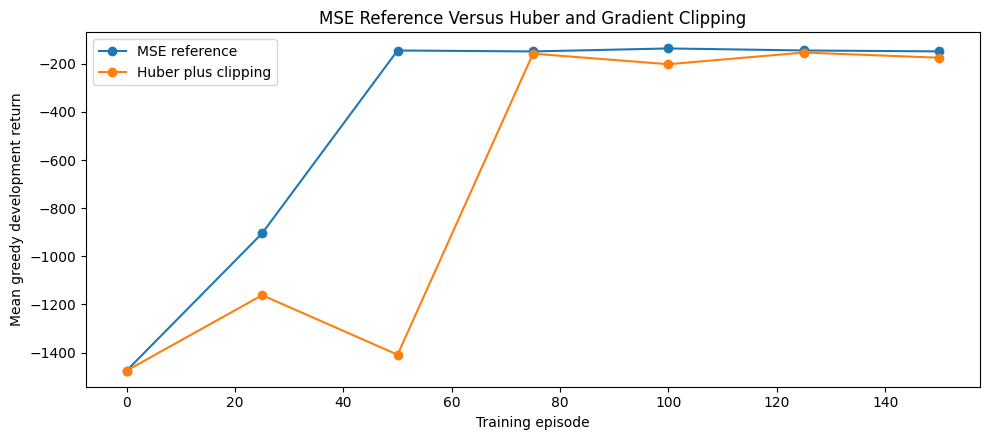

Huber-clipping run completed: True
Selected checkpoint episode: 125
Mean development return: -152.94158624518207
Development return standard deviation: 118.13222615811772
Maximum applied gradient global norm: 10.000000143051148
Huber-minus-MSE mean return: -16.999396130936702
Within practical improvement margin: False
Formal runs completed: 14
Remaining formal-run capacity: 14
Saved Huber-clipping history: histories\R70_OPT_STABILITY_HUBER_CLIP_history.csv
Saved Huber-clipping summary: histories\R70_OPT_STABILITY_HUBER_CLIP_summary.csv
Saved Huber-clipping weights: selected_weights\R70_OPT_STABILITY_HUBER_CLIP_best.weights.h5
Section 13.3 Huber and gradient clipping: COMPLETE


In [72]:
R70_HUBER_CLIP_RUN_ID = (
    "R70_OPT_STABILITY_HUBER_CLIP"
)
R70_HUBER_DELTA = 1.0
R70_GRADIENT_CLIP_GLOBAL_NORM = 10.0

R70_HUBER_CLIP_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R70_HUBER_CLIP_RUN_ID}_best.weights.h5"
)
R70_HUBER_CLIP_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{R70_HUBER_CLIP_RUN_ID}_history.csv"
)
R70_HUBER_CLIP_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{R70_HUBER_CLIP_RUN_ID}"
        "_development_evaluations.csv"
    )
)
R70_HUBER_CLIP_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R70_HUBER_CLIP_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
R70_HUBER_CLIP_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R70_HUBER_CLIP_RUN_ID}_summary.csv"
)
R70_HUBER_CLIP_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{R70_HUBER_CLIP_RUN_ID}"
        "_selected_state_results.csv"
    )
)
OPTIMISATION_STABILITY_PLAN_PATH = (
    HISTORIES_DIR
    / "R70_optimisation_stability_recipe_plan.csv"
)
R70_HUBER_CLIP_SMOKE_PATH = (
    HISTORIES_DIR
    / "R70_huber_clip_correctness_smoke.csv"
)

assert REPLAY_TARGET_SELECTION_LOCKED is True
assert SELECTED_REPLAY_TARGET_RECIPE == "reference"
assert SELECTED_EXPLORATION_RECIPE == "moderate_decay"
assert ACTION_COMPARISON_LEARNING_RATE == 1e-3
assert ACTION_COMPARISON_GAMMA == 0.99
assert FORMAL_RUNS_COMPLETED in (13, 14)
assert remaining_formal_run_capacity in (15, 14)


def huber_clipped_dqn_gradient_update(
    main_network: keras.Model,
    target_network: keras.Model,
    optimizer: keras.optimizers.Optimizer,
    states: np.ndarray,
    action_indices: np.ndarray,
    rewards: np.ndarray,
    next_states: np.ndarray,
    gamma: float,
) -> Dict[str, object]:
    """Apply one Huber-loss DQN update with global-norm clipping."""
    state_tensor = tf.convert_to_tensor(
        states,
        dtype=tf.float32,
    )
    action_tensor = tf.convert_to_tensor(
        action_indices,
        dtype=tf.int32,
    )

    assert state_tensor.shape.rank == 2
    assert int(state_tensor.shape[1]) == DQN_STATE_DIM
    assert action_tensor.shape.rank == 1
    assert int(action_tensor.shape[0]) == int(
        state_tensor.shape[0]
    )
    assert bool(tf.reduce_all(action_tensor >= 0))
    assert bool(
        tf.reduce_all(
            action_tensor
            < int(main_network.output_shape[-1])
        )
    )

    bellman_targets, _, _ = (
        compute_vanilla_dqn_bellman_targets(
            rewards=rewards,
            next_states=next_states,
            target_network=target_network,
            gamma=gamma,
        )
    )
    bellman_targets = tf.stop_gradient(
        bellman_targets
    )

    with tf.GradientTape() as tape:
        all_q_values = main_network(
            state_tensor,
            training=True,
        )
        selected_action_q_values = tf.gather(
            all_q_values,
            action_tensor,
            axis=1,
            batch_dims=1,
        )
        temporal_difference = (
            bellman_targets
            - selected_action_q_values
        )

        absolute_td_error = tf.abs(
            temporal_difference
        )
        quadratic_error = tf.minimum(
            absolute_td_error,
            R70_HUBER_DELTA,
        )
        linear_error = (
            absolute_td_error
            - quadratic_error
        )
        per_sample_huber_loss = (
            0.5 * tf.square(quadratic_error)
            + R70_HUBER_DELTA * linear_error
        )
        loss = tf.reduce_mean(
            per_sample_huber_loss
        )

    raw_gradients = tape.gradient(
        loss,
        main_network.trainable_variables,
    )

    assert selected_action_q_values.shape == (
        bellman_targets.shape
    )
    assert bool(tf.math.is_finite(loss))
    assert all(
        gradient is not None
        for gradient in raw_gradients
    )
    assert all(
        bool(
            tf.reduce_all(
                tf.math.is_finite(gradient)
            )
        )
        for gradient in raw_gradients
    )

    raw_gradient_global_norm = (
        tf.linalg.global_norm(raw_gradients)
    )
    clipped_gradients, clipping_reported_norm = (
        tf.clip_by_global_norm(
            raw_gradients,
            R70_GRADIENT_CLIP_GLOBAL_NORM,
        )
    )
    clipped_gradient_global_norm = (
        tf.linalg.global_norm(
            clipped_gradients
        )
    )

    assert bool(
        tf.math.is_finite(
            raw_gradient_global_norm
        )
    )
    assert bool(
        tf.math.is_finite(
            clipped_gradient_global_norm
        )
    )
    assert np.isclose(
        float(
            clipping_reported_norm.numpy()
        ),
        float(
            raw_gradient_global_norm.numpy()
        ),
        rtol=1e-6,
        atol=1e-6,
    )
    assert float(
        clipped_gradient_global_norm.numpy()
    ) <= (
        R70_GRADIENT_CLIP_GLOBAL_NORM
        + 1e-5
    )

    optimizer.apply_gradients(
        zip(
            clipped_gradients,
            main_network.trainable_variables,
        )
    )

    return {
        "loss": float(loss.numpy()),
        "gradient_global_norm": float(
            clipped_gradient_global_norm.numpy()
        ),
        "raw_gradient_global_norm": float(
            raw_gradient_global_norm.numpy()
        ),
        "clipped_gradient_global_norm": float(
            clipped_gradient_global_norm.numpy()
        ),
        "selected_action_q_values": (
            selected_action_q_values.numpy()
        ),
        "bellman_targets": (
            bellman_targets.numpy()
        ),
        "temporal_difference": (
            temporal_difference.numpy()
        ),
        "optimizer_iterations": int(
            optimizer.iterations.numpy()
        ),
    }


huber_smoke_main, huber_smoke_target = (
    initialise_dueling_main_and_target_networks(
        state_dim=DQN_STATE_DIM,
        action_count=FOUNDATION_SCREEN_ACTION_COUNT,
        hidden_units=STANDARD_HIDDEN_UNITS,
        seed=913,
    )
)
huber_smoke_optimizer = (
    keras.optimizers.Adam(
        learning_rate=(
            ACTION_COMPARISON_LEARNING_RATE
        )
    )
)

huber_smoke_states = np.asarray(
    dueling_probe_states,
    dtype=np.float32,
)
huber_smoke_actions = np.array(
    [0, 2, 4, 6],
    dtype=np.int32,
)
huber_smoke_rewards = np.array(
    [-1000.0, -750.0, -500.0, -1200.0],
    dtype=np.float32,
)
huber_smoke_next_states = np.asarray(
    dueling_smoke_next_states,
    dtype=np.float32,
)

huber_main_weights_before = [
    weight.numpy().copy()
    for weight in huber_smoke_main.weights
]
huber_target_weights_before = [
    weight.numpy().copy()
    for weight in huber_smoke_target.weights
]

huber_smoke_result = (
    huber_clipped_dqn_gradient_update(
        main_network=huber_smoke_main,
        target_network=huber_smoke_target,
        optimizer=huber_smoke_optimizer,
        states=huber_smoke_states,
        action_indices=huber_smoke_actions,
        rewards=huber_smoke_rewards,
        next_states=huber_smoke_next_states,
        gamma=ACTION_COMPARISON_GAMMA,
    )
)

huber_main_changes = [
    float(
        np.max(
            np.abs(
                after.numpy() - before
            )
        )
    )
    for before, after in zip(
        huber_main_weights_before,
        huber_smoke_main.weights,
    )
]
huber_target_changes = [
    float(
        np.max(
            np.abs(
                after.numpy() - before
            )
        )
    )
    for before, after in zip(
        huber_target_weights_before,
        huber_smoke_target.weights,
    )
]

assert any(
    change > 0.0
    for change in huber_main_changes
)
assert all(
    change == 0.0
    for change in huber_target_changes
)
assert (
    huber_smoke_result[
        "clipped_gradient_global_norm"
    ]
    <= R70_GRADIENT_CLIP_GLOBAL_NORM
    + 1e-5
)
assert np.isfinite(
    huber_smoke_result["loss"]
)
assert np.isfinite(
    huber_smoke_result[
        "bellman_targets"
    ]
).all()

# Huber loss bounds each sample's derivative, so a valid DQN smoke
# update does not have to exceed the production clip threshold.
# Test forced clipping separately with a deterministic synthetic gradient.
synthetic_raw_gradients = [
    tf.constant(
        [30.0, 40.0],
        dtype=tf.float32,
    )
]
synthetic_raw_gradient_norm = float(
    tf.linalg.global_norm(
        synthetic_raw_gradients
    ).numpy()
)
(
    synthetic_clipped_gradients,
    synthetic_reported_raw_norm,
) = tf.clip_by_global_norm(
    synthetic_raw_gradients,
    R70_GRADIENT_CLIP_GLOBAL_NORM,
)
synthetic_clipped_gradient_norm = float(
    tf.linalg.global_norm(
        synthetic_clipped_gradients
    ).numpy()
)

assert synthetic_raw_gradient_norm > (
    R70_GRADIENT_CLIP_GLOBAL_NORM
)
assert np.isclose(
    float(
        synthetic_reported_raw_norm.numpy()
    ),
    synthetic_raw_gradient_norm,
    rtol=0.0,
    atol=1e-6,
)
assert np.isclose(
    synthetic_clipped_gradient_norm,
    R70_GRADIENT_CLIP_GLOBAL_NORM,
    rtol=0.0,
    atol=1e-5,
)

huber_clip_smoke_summary = pd.DataFrame([
    {
        "check": "Finite Huber loss",
        "status": bool(
            np.isfinite(
                huber_smoke_result["loss"]
            )
        ),
        "value": huber_smoke_result[
            "loss"
        ],
    },
    {
        "check": (
            "Training update respects clip ceiling"
        ),
        "status": bool(
            huber_smoke_result[
                "clipped_gradient_global_norm"
            ]
            <= R70_GRADIENT_CLIP_GLOBAL_NORM
            + 1e-5
        ),
        "value": huber_smoke_result[
            "clipped_gradient_global_norm"
        ],
    },
    {
        "check": (
            "Synthetic raw gradient exceeds threshold"
        ),
        "status": bool(
            synthetic_raw_gradient_norm
            > R70_GRADIENT_CLIP_GLOBAL_NORM
        ),
        "value": synthetic_raw_gradient_norm,
    },
    {
        "check": (
            "Synthetic gradient is clipped to threshold"
        ),
        "status": bool(
            np.isclose(
                synthetic_clipped_gradient_norm,
                R70_GRADIENT_CLIP_GLOBAL_NORM,
                rtol=0.0,
                atol=1e-5,
            )
        ),
        "value": synthetic_clipped_gradient_norm,
    },
    {
        "check": "Main network changed",
        "status": bool(
            any(
                change > 0.0
                for change in huber_main_changes
            )
        ),
        "value": max(
            huber_main_changes
        ),
    },
    {
        "check": "Target network unchanged",
        "status": bool(
            all(
                change == 0.0
                for change in huber_target_changes
            )
        ),
        "value": max(
            huber_target_changes
        ),
    },
])

assert huber_clip_smoke_summary[
    "status"
].all()

huber_clip_smoke_summary.to_csv(
    R70_HUBER_CLIP_SMOKE_PATH,
    index=False,
)

optimisation_stability_plan = pd.DataFrame([
    {
        "recipe": "mse_reference",
        "run_id": R42_RUN_ID,
        "loss": "MSE",
        "huber_delta": np.nan,
        "gradient_clip_global_norm": np.nan,
        "learning_rate": (
            ACTION_COMPARISON_LEARNING_RATE
        ),
        "gamma": ACTION_COMPARISON_GAMMA,
        "source": (
            "reused selected-foundation run"
        ),
        "status": "REFERENCE AVAILABLE",
    },
    {
        "recipe": "huber_clip",
        "run_id": R70_HUBER_CLIP_RUN_ID,
        "loss": "Huber",
        "huber_delta": R70_HUBER_DELTA,
        "gradient_clip_global_norm": (
            R70_GRADIENT_CLIP_GLOBAL_NORM
        ),
        "learning_rate": (
            ACTION_COMPARISON_LEARNING_RATE
        ),
        "gamma": ACTION_COMPARISON_GAMMA,
        "source": "fresh seed-42 run",
        "status": "ACTIVE",
    },
    {
        "recipe": "gamma_0.95",
        "run_id": "R70_OPT_STABILITY_GAMMA_095",
        "loss": "Pending retained loss choice",
        "huber_delta": np.nan,
        "gradient_clip_global_norm": np.nan,
        "learning_rate": (
            ACTION_COMPARISON_LEARNING_RATE
        ),
        "gamma": 0.95,
        "source": "fresh seed-42 run",
        "status": "PLANNED",
    },
])

optimisation_stability_plan.to_csv(
    OPTIMISATION_STABILITY_PLAN_PATH,
    index=False,
)

r70_huber_clip_required_artifacts = [
    R70_HUBER_CLIP_WEIGHT_PATH,
    R70_HUBER_CLIP_HISTORY_PATH,
    R70_HUBER_CLIP_EVALUATION_PATH,
    R70_HUBER_CLIP_EVALUATION_SUMMARY_PATH,
    R70_HUBER_CLIP_SUMMARY_PATH,
    R70_HUBER_CLIP_STATE_RESULTS_PATH,
]
r70_huber_clip_artifacts_complete = all(
    path.exists()
    for path in r70_huber_clip_required_artifacts
)

if (
    "r70_huber_clip_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "r70_huber_clip_history",
            "r70_huber_clip_evaluation_states",
            "r70_huber_clip_evaluation_summary",
            "r70_huber_clip_selected_state_results",
            "r70_huber_clip_summary",
        ]
    )
):
    print(
        "Huber-clipping result already exists in memory; "
        "no duplicate training run was started."
    )
elif r70_huber_clip_artifacts_complete:
    r70_huber_clip_history = read_csv_with_control_metric_migration(
        R70_HUBER_CLIP_HISTORY_PATH
    )
    r70_huber_clip_evaluation_states = read_csv_with_control_metric_migration(
        R70_HUBER_CLIP_EVALUATION_PATH
    )
    r70_huber_clip_evaluation_summary = read_csv_with_control_metric_migration(
        R70_HUBER_CLIP_EVALUATION_SUMMARY_PATH
    )
    r70_huber_clip_summary = read_csv_with_control_metric_migration(
        R70_HUBER_CLIP_SUMMARY_PATH
    )
    r70_huber_clip_selected_state_results = read_csv_with_control_metric_migration(
        R70_HUBER_CLIP_STATE_RESULTS_PATH
    )

    assert len(r70_huber_clip_summary) == 1
    r70_huber_clip_summary_record = (
        r70_huber_clip_summary.iloc[0].to_dict()
    )
    r70_huber_clip_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=(
                FOUNDATION_SCREEN_ACTION_COUNT
            ),
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r70_huber_clip_reloaded_q_network"
            ),
        )
    )
    r70_huber_clip_selected_model.load_weights(
        R70_HUBER_CLIP_WEIGHT_PATH
    )
    print(
        "Loaded completed Huber-clipping artifacts; "
        "no duplicate training run was started."
    )
else:
    original_gradient_update = (
        vanilla_dqn_gradient_update
    )
    vanilla_dqn_gradient_update = (
        huber_clipped_dqn_gradient_update
    )

    try:
        r70_huber_clip_result = (
            run_dueling_dqn_foundation(
                run_id=R70_HUBER_CLIP_RUN_ID,
                torque_values=(
                    FOUNDATION_SCREEN_TORQUE_VALUES
                ),
                seed=FOUNDATION_SCREEN_SEED,
                weight_path=(
                    R70_HUBER_CLIP_WEIGHT_PATH
                ),
            )
        )
    finally:
        vanilla_dqn_gradient_update = (
            original_gradient_update
        )

    r70_huber_clip_history = (
        r70_huber_clip_result["history"]
    )
    r70_huber_clip_evaluation_states = (
        r70_huber_clip_result[
            "evaluation_states"
        ]
    )
    r70_huber_clip_evaluation_summary = (
        r70_huber_clip_result[
            "evaluation_summary"
        ]
    )
    r70_huber_clip_selected_state_results = (
        r70_huber_clip_result[
            "selected_state_results"
        ]
    )
    r70_huber_clip_selected_model = (
        r70_huber_clip_result[
            "selected_model"
        ]
    )
    r70_huber_clip_summary_record = dict(
        r70_huber_clip_result[
            "summary_record"
        ]
    )
    r70_huber_clip_summary_record.update({
        "optimisation_recipe": (
            "huber_clip"
        ),
        "td_loss": "Huber",
        "huber_delta": R70_HUBER_DELTA,
        "gradient_clip_global_norm": (
            R70_GRADIENT_CLIP_GLOBAL_NORM
        ),
        "learning_rate": (
            ACTION_COMPARISON_LEARNING_RATE
        ),
        "gamma": ACTION_COMPARISON_GAMMA,
        "replay_target_recipe": (
            SELECTED_REPLAY_TARGET_RECIPE
        ),
        "exploration_recipe": (
            SELECTED_EXPLORATION_RECIPE
        ),
        "reference_run_id": R42_RUN_ID,
    })
    r70_huber_clip_summary = pd.DataFrame(
        [r70_huber_clip_summary_record]
    )

FORMAL_RUNS_COMPLETED = 14
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 14
assert remaining_formal_run_capacity == 14
assert len(r70_huber_clip_history) == 150
assert len(
    r70_huber_clip_evaluation_summary
) == 7
assert int(
    r70_huber_clip_summary_record["seed"]
) == 42
assert (
    r70_huber_clip_summary_record["model"]
    == "Dueling DQN"
)
assert int(
    r70_huber_clip_summary_record[
        "action_count"
    ]
) == 7
assert int(
    r70_huber_clip_summary_record[
        "parameter_count"
    ]
) == 4936
assert int(
    r70_huber_clip_summary_record[
        "environment_steps"
    ]
) == 30_000
assert int(
    r70_huber_clip_summary_record[
        "optimizer_updates"
    ]
) == 29_001
assert int(
    r70_huber_clip_summary_record[
        "target_updates"
    ]
) == 116
assert (
    r70_huber_clip_history[
        "mean_gradient_global_norm"
    ].dropna().max()
    <= R70_GRADIENT_CLIP_GLOBAL_NORM
    + 1e-5
)
assert np.isfinite(
    r70_huber_clip_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert R70_HUBER_CLIP_WEIGHT_PATH.exists()

r70_huber_clip_history.to_csv(
    R70_HUBER_CLIP_HISTORY_PATH,
    index=False,
)
r70_huber_clip_evaluation_states.to_csv(
    R70_HUBER_CLIP_EVALUATION_PATH,
    index=False,
)
r70_huber_clip_evaluation_summary.to_csv(
    R70_HUBER_CLIP_EVALUATION_SUMMARY_PATH,
    index=False,
)
r70_huber_clip_summary.to_csv(
    R70_HUBER_CLIP_SUMMARY_PATH,
    index=False,
)
r70_huber_clip_selected_state_results.to_csv(
    R70_HUBER_CLIP_STATE_RESULTS_PATH,
    index=False,
)

huber_minus_mse_reference = float(
    r70_huber_clip_summary_record[
        "mean_development_return"
    ]
    - r42_summary_record[
        "mean_development_return"
    ]
)

display(huber_clip_smoke_summary)
display(optimisation_stability_plan)
display(r70_huber_clip_evaluation_summary)
display(r70_huber_clip_summary)

plt.figure(figsize=(10, 4.5))
plt.plot(
    r42_evaluation_summary["episode"],
    r42_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="MSE reference",
)
plt.plot(
    r70_huber_clip_evaluation_summary[
        "episode"
    ],
    r70_huber_clip_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Huber plus clipping",
)
plt.xlabel("Training episode")
plt.ylabel(
    "Mean greedy development return"
)
plt.title(
    "MSE Reference Versus Huber and Gradient Clipping"
)
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Huber-clipping run completed:",
    True,
)
print(
    "Selected checkpoint episode:",
    r70_huber_clip_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    r70_huber_clip_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    r70_huber_clip_summary_record[
        "development_return_std"
    ],
)
print(
    "Maximum applied gradient global norm:",
    r70_huber_clip_history[
        "mean_gradient_global_norm"
    ].dropna().max(),
)
print(
    "Huber-minus-MSE mean return:",
    huber_minus_mse_reference,
)
print(
    "Within practical improvement margin:",
    abs(huber_minus_mse_reference)
    <= PRACTICAL_IMPROVEMENT_MARGIN,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved Huber-clipping history:",
    R70_HUBER_CLIP_HISTORY_PATH,
)
print(
    "Saved Huber-clipping summary:",
    R70_HUBER_CLIP_SUMMARY_PATH,
)
print(
    "Saved Huber-clipping weights:",
    R70_HUBER_CLIP_WEIGHT_PATH,
)
print(
    "Section 13.3 Huber and gradient clipping: COMPLETE"
)


### 13.3 Result Interpretation

**Finding.** The Huber-loss and gradient-clipping run completed all `150`
episodes without technical failure.

Its selected checkpoint was episode `125`, with:

- mean development return: `-152.941586`;
- development-state standard deviation: `118.132226`;
- maximum applied gradient global norm: approximately `10.0`;
- Huber-minus-MSE return difference: `-16.999396`.

The candidate therefore performed worse than the MSE reference by more than
the locked practical margin of `11.335072`.

**Importance.** The correctness checks confirmed that Huber loss remained
finite and the applied gradient norm respected the clipping ceiling. However,
numerical control alone did not translate into better Pendulum control.

**Decision.** Reject the Huber-plus-clipping recipe and retain MSE with no
gradient clipping.

**Caveat.** This result does not show that Huber loss or clipping are always
harmful. It shows that this specific combined recipe, using delta `1.0` and a
global-norm limit of `10.0`, was unsuitable under the matched seed-42 setup.

**Next step.** Compare gamma `0.95` against the retained gamma `0.99` reference
while keeping MSE, no clipping and every other setting fixed.


## 13.4 Small Gamma Comparison

**Question.** Does shortening the effective planning horizon from gamma
`0.99` to `0.95` improve learning stability or control without sacrificing
long-term balancing performance?

**Reference.**

```text
Gamma: 0.99
Loss: MSE
Gradient clipping: none
```

**Candidate.**

```text
Gamma: 0.95
Loss: MSE
Gradient clipping: none
```

The candidate changes only gamma. Architecture, action set, exploration,
replay, target updates, optimiser, learning rate, default gravity, seed `42`,
training budget, checkpoint rule and fixed development states remain matched.

This consumes one formal-training slot. After completion, the formal-run
count should be `15`, leaving `13` runs.


Loaded completed gamma-0.95 artifacts; no duplicate training run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1474.850023,-1421.686562,228.929283,-1816.480863,-1149.851953,0.009583,2.569736,1.605649,0.847083,0.072446
1,25,-377.917951,-151.536587,387.774930,-1000.407632,-2.792623,0.642708,0.619343,1.633243,1.159583,0.171692
2,50,-148.584235,-125.629647,111.360471,-380.747962,-0.803096,0.857708,0.294290,0.499412,0.683472,0.656826
3,75,-146.406283,-125.598468,107.376946,-360.352184,-1.309635,0.858542,0.283952,0.562462,1.329722,0.733878
4,100,-145.825936,-126.995343,107.915259,-379.982748,-1.665063,0.856250,0.293157,0.540518,1.207639,0.725503
5,125,-217.936436,-129.411166,357.830747,-1810.888384,-2.091867,0.815625,0.417056,0.549780,1.850694,0.708124
6,150,-152.397944,-129.222565,117.862994,-398.494758,-3.797244,0.848958,0.361846,0.542323,1.066528,0.842337


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,technical_status,optimisation_recipe,td_loss,huber_delta,gradient_clip_global_norm,learning_rate,gamma,replay_target_recipe,exploration_recipe,reference_run_id
0,R70_OPT_STABILITY_GAMMA_095,R70_OPT_STABILITY_GAMMA_095,False,True,Dueling DQN,default,42,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,PASS,gamma_0.95,MSE,NaN,NaN,0.001,0.95,reference,moderate_decay,R42_DUELING


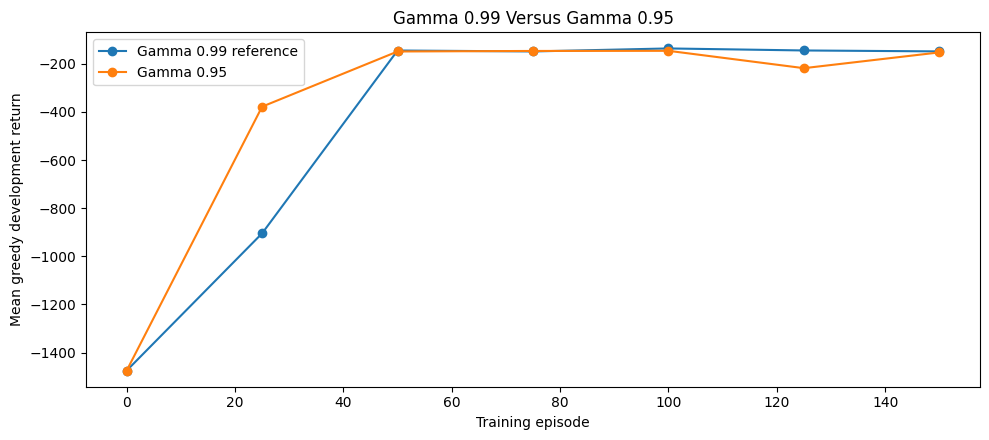

Gamma-0.95 run completed: True
Selected checkpoint episode: 100
Mean development return: -145.8259357130847
Development return standard deviation: 107.91525948276764
Gamma-0.95-minus-gamma-0.99 mean return: -9.88374559883934
Within practical improvement margin: True
Formal runs completed: 15
Remaining formal-run capacity: 13
Saved gamma-0.95 history: histories\R70_OPT_STABILITY_GAMMA_095_history.csv
Saved gamma-0.95 summary: histories\R70_OPT_STABILITY_GAMMA_095_summary.csv
Saved gamma-0.95 weights: selected_weights\R70_OPT_STABILITY_GAMMA_095_best.weights.h5
Section 13.4 gamma comparison: COMPLETE


In [73]:
R70_GAMMA_095_RUN_ID = (
    "R70_OPT_STABILITY_GAMMA_095"
)
R70_GAMMA_095_VALUE = 0.95

R70_GAMMA_095_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R70_GAMMA_095_RUN_ID}_best.weights.h5"
)
R70_GAMMA_095_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{R70_GAMMA_095_RUN_ID}_history.csv"
)
R70_GAMMA_095_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{R70_GAMMA_095_RUN_ID}"
        "_development_evaluations.csv"
    )
)
R70_GAMMA_095_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R70_GAMMA_095_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
R70_GAMMA_095_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R70_GAMMA_095_RUN_ID}_summary.csv"
)
R70_GAMMA_095_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{R70_GAMMA_095_RUN_ID}"
        "_selected_state_results.csv"
    )
)

assert REPLAY_TARGET_SELECTION_LOCKED is True
assert SELECTED_REPLAY_TARGET_RECIPE == "reference"
assert SELECTED_EXPLORATION_RECIPE == "moderate_decay"
assert ACTION_COMPARISON_GAMMA == 0.99
assert ACTION_COMPARISON_LEARNING_RATE == 1e-3
assert R70_GAMMA_095_VALUE == 0.95
assert FORMAL_RUNS_COMPLETED in (14, 15)
assert remaining_formal_run_capacity in (14, 13)

r70_gamma_095_required_artifacts = [
    R70_GAMMA_095_WEIGHT_PATH,
    R70_GAMMA_095_HISTORY_PATH,
    R70_GAMMA_095_EVALUATION_PATH,
    R70_GAMMA_095_EVALUATION_SUMMARY_PATH,
    R70_GAMMA_095_SUMMARY_PATH,
    R70_GAMMA_095_STATE_RESULTS_PATH,
]
r70_gamma_095_artifacts_complete = all(
    path.exists()
    for path in r70_gamma_095_required_artifacts
)

if (
    "r70_gamma_095_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "r70_gamma_095_history",
            "r70_gamma_095_evaluation_states",
            "r70_gamma_095_evaluation_summary",
            "r70_gamma_095_selected_state_results",
            "r70_gamma_095_summary",
        ]
    )
):
    print(
        "Gamma-0.95 result already exists in memory; "
        "no duplicate training run was started."
    )
elif r70_gamma_095_artifacts_complete:
    r70_gamma_095_history = read_csv_with_control_metric_migration(
        R70_GAMMA_095_HISTORY_PATH
    )
    r70_gamma_095_evaluation_states = read_csv_with_control_metric_migration(
        R70_GAMMA_095_EVALUATION_PATH
    )
    r70_gamma_095_evaluation_summary = read_csv_with_control_metric_migration(
        R70_GAMMA_095_EVALUATION_SUMMARY_PATH
    )
    r70_gamma_095_summary = read_csv_with_control_metric_migration(
        R70_GAMMA_095_SUMMARY_PATH
    )
    r70_gamma_095_selected_state_results = read_csv_with_control_metric_migration(
        R70_GAMMA_095_STATE_RESULTS_PATH
    )

    assert len(r70_gamma_095_summary) == 1
    r70_gamma_095_summary_record = (
        r70_gamma_095_summary.iloc[0].to_dict()
    )
    r70_gamma_095_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FOUNDATION_SCREEN_ACTION_COUNT,
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r70_gamma_095_reloaded_q_network"
            ),
        )
    )
    r70_gamma_095_selected_model.load_weights(
        R70_GAMMA_095_WEIGHT_PATH
    )
    print(
        "Loaded completed gamma-0.95 artifacts; "
        "no duplicate training run was started."
    )
else:
    original_action_comparison_gamma = (
        ACTION_COMPARISON_GAMMA
    )
    ACTION_COMPARISON_GAMMA = R70_GAMMA_095_VALUE

    try:
        r70_gamma_095_result = (
            run_dueling_dqn_foundation(
                run_id=R70_GAMMA_095_RUN_ID,
                torque_values=(
                    FOUNDATION_SCREEN_TORQUE_VALUES
                ),
                seed=FOUNDATION_SCREEN_SEED,
                weight_path=R70_GAMMA_095_WEIGHT_PATH,
            )
        )
    finally:
        ACTION_COMPARISON_GAMMA = (
            original_action_comparison_gamma
        )

    r70_gamma_095_history = (
        r70_gamma_095_result["history"]
    )
    r70_gamma_095_evaluation_states = (
        r70_gamma_095_result[
            "evaluation_states"
        ]
    )
    r70_gamma_095_evaluation_summary = (
        r70_gamma_095_result[
            "evaluation_summary"
        ]
    )
    r70_gamma_095_selected_state_results = (
        r70_gamma_095_result[
            "selected_state_results"
        ]
    )
    r70_gamma_095_selected_model = (
        r70_gamma_095_result[
            "selected_model"
        ]
    )
    r70_gamma_095_summary_record = dict(
        r70_gamma_095_result[
            "summary_record"
        ]
    )
    r70_gamma_095_summary_record.update({
        "optimisation_recipe": "gamma_0.95",
        "td_loss": "MSE",
        "huber_delta": np.nan,
        "gradient_clip_global_norm": np.nan,
        "learning_rate": (
            ACTION_COMPARISON_LEARNING_RATE
        ),
        "gamma": R70_GAMMA_095_VALUE,
        "replay_target_recipe": (
            SELECTED_REPLAY_TARGET_RECIPE
        ),
        "exploration_recipe": (
            SELECTED_EXPLORATION_RECIPE
        ),
        "reference_run_id": R42_RUN_ID,
    })
    r70_gamma_095_summary = pd.DataFrame(
        [r70_gamma_095_summary_record]
    )

FORMAL_RUNS_COMPLETED = 15
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert ACTION_COMPARISON_GAMMA == 0.99
assert FORMAL_RUNS_COMPLETED == 15
assert remaining_formal_run_capacity == 13
assert len(r70_gamma_095_history) == 150
assert len(r70_gamma_095_evaluation_summary) == 7
assert int(
    r70_gamma_095_summary_record["seed"]
) == 42
assert (
    r70_gamma_095_summary_record["model"]
    == "Dueling DQN"
)
assert int(
    r70_gamma_095_summary_record["action_count"]
) == 7
assert int(
    r70_gamma_095_summary_record["parameter_count"]
) == 4936
assert int(
    r70_gamma_095_summary_record["environment_steps"]
) == 30_000
assert int(
    r70_gamma_095_summary_record["optimizer_updates"]
) == 29_001
assert int(
    r70_gamma_095_summary_record["target_updates"]
) == 116
assert np.isclose(
    float(
        r70_gamma_095_summary_record["gamma"]
    ),
    R70_GAMMA_095_VALUE,
    rtol=0.0,
    atol=0.0,
)
assert np.isfinite(
    r70_gamma_095_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert R70_GAMMA_095_WEIGHT_PATH.exists()

r70_gamma_095_history.to_csv(
    R70_GAMMA_095_HISTORY_PATH,
    index=False,
)
r70_gamma_095_evaluation_states.to_csv(
    R70_GAMMA_095_EVALUATION_PATH,
    index=False,
)
r70_gamma_095_evaluation_summary.to_csv(
    R70_GAMMA_095_EVALUATION_SUMMARY_PATH,
    index=False,
)
r70_gamma_095_summary.to_csv(
    R70_GAMMA_095_SUMMARY_PATH,
    index=False,
)
r70_gamma_095_selected_state_results.to_csv(
    R70_GAMMA_095_STATE_RESULTS_PATH,
    index=False,
)

gamma_095_minus_gamma_099 = float(
    r70_gamma_095_summary_record[
        "mean_development_return"
    ]
    - r42_summary_record[
        "mean_development_return"
    ]
)

display(r70_gamma_095_evaluation_summary)
display(r70_gamma_095_summary)

plt.figure(figsize=(10, 4.5))
plt.plot(
    r42_evaluation_summary["episode"],
    r42_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Gamma 0.99 reference",
)
plt.plot(
    r70_gamma_095_evaluation_summary["episode"],
    r70_gamma_095_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Gamma 0.95",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("Gamma 0.99 Versus Gamma 0.95")
plt.legend()
plt.tight_layout()
plt.show()

print("Gamma-0.95 run completed:", True)
print(
    "Selected checkpoint episode:",
    r70_gamma_095_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    r70_gamma_095_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    r70_gamma_095_summary_record[
        "development_return_std"
    ],
)
print(
    "Gamma-0.95-minus-gamma-0.99 mean return:",
    gamma_095_minus_gamma_099,
)
print(
    "Within practical improvement margin:",
    abs(gamma_095_minus_gamma_099)
    <= PRACTICAL_IMPROVEMENT_MARGIN,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved gamma-0.95 history:",
    R70_GAMMA_095_HISTORY_PATH,
)
print(
    "Saved gamma-0.95 summary:",
    R70_GAMMA_095_SUMMARY_PATH,
)
print(
    "Saved gamma-0.95 weights:",
    R70_GAMMA_095_WEIGHT_PATH,
)
print("Section 13.4 gamma comparison: COMPLETE")


### 13.4 Result Interpretation

**Finding.** The gamma `0.95` run completed all `150` episodes without a
technical failure.

Its selected checkpoint was episode `100`, with:

- mean development return: `-145.825936`;
- development-state standard deviation: `107.915259`;
- gamma-`0.95` minus gamma-`0.99` return: `-9.883746`.

The candidate remained inside the locked practical margin, but it produced a
lower selected return, larger state-wise spread and lower upright fraction
than gamma `0.99`.

Gamma `0.95` reduced the selected-to-final decline to approximately
`6.572008`, compared with `12.291164` for gamma `0.99`. However, it also
suffered a substantial episode-125 drop to `-217.936436`.

**Importance.** Shortening the planning horizon did not clearly improve the
primary control evidence under seed `42`. Its smaller late decline is useful,
but it is offset by weaker return and robustness.

**Decision.** Do not select either gamma from one seed because the difference
is inside the practical margin.

**Next step.** Confirm gamma `0.95` against the existing gamma `0.99`
reference using matched seed `123`.


### 13.4.1 Matched Seed-123 Gamma Confirmation

The reference is the completed gamma-`0.99` Dueling run:

```text
R42_DUELING_SEED_123
```

The candidate is:

```text
R70_OPT_STABILITY_GAMMA_095_SEED_123
```

Only gamma changes from `0.99` to `0.95`. Architecture, seven-action torque
set, moderate exploration, retained replay and target recipe, MSE loss, no
gradient clipping, Adam learning rate, default gravity, training budget,
checkpoint rule and fixed development states remain matched.

This consumes one formal-training slot. After completion, the formal-run
count should be `16`, leaving `12` runs.

The final gamma and learning-rate decisions remain deferred until this matched
confirmation is reviewed.


Loaded completed gamma-0.95 seed-123 artifacts; no duplicate training run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1513.180553,-1531.216662,216.799448,-1816.480863,-1124.922449,0.005208,2.570358,1.452520,1.181250,0.043551
1,25,-153.895054,-131.799121,114.860731,-386.902265,-0.760121,0.840000,0.297082,0.558763,0.975000,0.642379
2,50,-150.616430,-125.199514,114.754973,-370.622523,-0.012524,0.851875,0.256384,0.514483,0.352778,0.201633
3,75,-155.095828,-125.169816,117.061248,-365.511389,-0.183816,0.841667,0.266195,0.554901,0.790278,0.739322
4,100,-139.749506,-124.703424,103.847171,-372.058351,-0.044163,0.857500,0.242573,0.504894,0.470833,0.323074
5,125,-146.950923,-131.772110,106.230844,-375.780862,-0.680664,0.855625,0.385585,0.495654,0.980556,0.632119
6,150,-145.336126,-130.083431,106.560183,-381.209095,-4.174468,0.853958,0.350074,0.548589,1.222500,0.232412


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,technical_status,optimisation_recipe,td_loss,huber_delta,gradient_clip_global_norm,learning_rate,gamma,replay_target_recipe,exploration_recipe,reference_run_id
0,R70_OPT_STABILITY_GAMMA_095_SEED_123,R70_OPT_STABILITY_GAMMA_095_SEED_123,False,True,Dueling DQN,default,123,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,PASS,gamma_0.95,MSE,NaN,NaN,0.001,0.95,reference,moderate_decay,R42_DUELING_SEED_123


,seed,reference_gamma,candidate_gamma,reference_mean_return,candidate_mean_return,candidate_minus_reference,reference_state_std,candidate_state_std,reference_upright_fraction,candidate_upright_fraction,paired_state_count,paired_median_difference,candidate_win_proportion,reference_win_proportion,minimum_paired_difference,maximum_paired_difference,within_practical_margin
0,42,0.99,0.95,-135.942190,-145.825936,-9.883746,99.338244,107.915259,0.872292,0.85625,24,-2.038609,0.083333,0.916667,-124.319754,3.246810,True
1,123,0.99,0.95,-138.522287,-139.749506,-1.227218,102.394330,103.847171,0.866667,0.85750,24,-0.072620,0.500000,0.500000,-18.890791,29.695352,True


,matched_seeds,reference_gamma,candidate_gamma,reference_mean_across_seeds,candidate_mean_across_seeds,candidate_minus_reference_across_seed_means,mean_of_seed_level_differences,candidate_seed_win_count,reference_seed_win_count,practical_improvement_margin,aggregate_difference_within_margin,selection_deferred_until_review,formal_significance_claim
0,"[42, 123]",0.99,0.95,-137.232239,-142.787721,-5.555482,-5.555482,0,2,11.335072,True,True,False


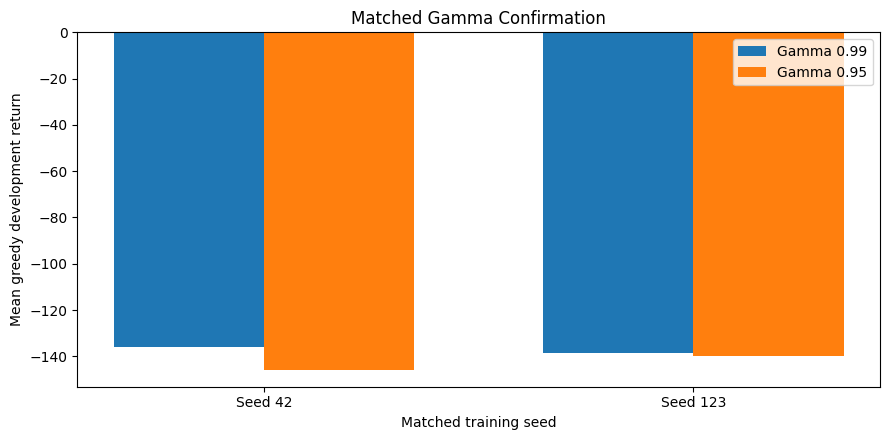

Gamma-0.95 seed-123 run completed: True
Selected checkpoint episode: 100
Seed-123 gamma-0.95 mean development return: -139.74950555901898
Seed-123 gamma-0.99 mean development return: -138.52228717953105
Seed-123 gamma-0.95-minus-gamma-0.99: -1.2272183794879368
Matched two-seed gamma-0.95-minus-gamma-0.99: -5.5554819891636384
Gamma-0.95 seed win count: 0
Aggregate difference within practical margin: True
Formal runs completed: 16
Remaining formal-run capacity: 12
Saved matched gamma confirmation: histories\R70_gamma_matched_seed_confirmation.csv
Saved gamma confirmation aggregate: histories\R70_gamma_matched_seed_confirmation_aggregate.csv
Section 13.4.1 matched gamma confirmation: COMPLETE


In [74]:
R70_GAMMA_095_CONFIRMATION_SEED = 123
R70_GAMMA_095_CONFIRMATION_RUN_ID = (
    "R70_OPT_STABILITY_GAMMA_095_SEED_123"
)

R70_GAMMA_095_CONFIRMATION_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / (
        f"{R70_GAMMA_095_CONFIRMATION_RUN_ID}"
        "_best.weights.h5"
    )
)
R70_GAMMA_095_CONFIRMATION_HISTORY_PATH = (
    HISTORIES_DIR
    / (
        f"{R70_GAMMA_095_CONFIRMATION_RUN_ID}"
        "_history.csv"
    )
)
R70_GAMMA_095_CONFIRMATION_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{R70_GAMMA_095_CONFIRMATION_RUN_ID}"
        "_development_evaluations.csv"
    )
)
R70_GAMMA_095_CONFIRMATION_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R70_GAMMA_095_CONFIRMATION_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
R70_GAMMA_095_CONFIRMATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R70_GAMMA_095_CONFIRMATION_RUN_ID}"
        "_summary.csv"
    )
)
R70_GAMMA_095_CONFIRMATION_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{R70_GAMMA_095_CONFIRMATION_RUN_ID}"
        "_selected_state_results.csv"
    )
)
GAMMA_MATCHED_CONFIRMATION_PATH = (
    HISTORIES_DIR
    / "R70_gamma_matched_seed_confirmation.csv"
)
GAMMA_MATCHED_CONFIRMATION_AGGREGATE_PATH = (
    HISTORIES_DIR
    / "R70_gamma_matched_seed_confirmation_aggregate.csv"
)

assert REPLAY_TARGET_SELECTION_LOCKED is True
assert SELECTED_REPLAY_TARGET_RECIPE == "reference"
assert SELECTED_EXPLORATION_RECIPE == "moderate_decay"
assert ACTION_COMPARISON_GAMMA == 0.99
assert R70_GAMMA_095_VALUE == 0.95
assert R70_GAMMA_095_CONFIRMATION_SEED == 123
assert int(
    r42_confirmation_summary_record["seed"]
) == 123
assert FORMAL_RUNS_COMPLETED in (15, 16)
assert remaining_formal_run_capacity in (13, 12)

r70_gamma_095_confirmation_required_artifacts = [
    R70_GAMMA_095_CONFIRMATION_WEIGHT_PATH,
    R70_GAMMA_095_CONFIRMATION_HISTORY_PATH,
    R70_GAMMA_095_CONFIRMATION_EVALUATION_PATH,
    R70_GAMMA_095_CONFIRMATION_EVALUATION_SUMMARY_PATH,
    R70_GAMMA_095_CONFIRMATION_SUMMARY_PATH,
    R70_GAMMA_095_CONFIRMATION_STATE_RESULTS_PATH,
]
r70_gamma_095_confirmation_artifacts_complete = all(
    path.exists()
    for path in r70_gamma_095_confirmation_required_artifacts
)

if (
    "r70_gamma_095_confirmation_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "r70_gamma_095_confirmation_history",
            "r70_gamma_095_confirmation_evaluation_states",
            "r70_gamma_095_confirmation_evaluation_summary",
            "r70_gamma_095_confirmation_selected_state_results",
            "r70_gamma_095_confirmation_summary",
        ]
    )
):
    print(
        "Gamma-0.95 seed-123 result already exists in memory; "
        "no duplicate training run was started."
    )
elif r70_gamma_095_confirmation_artifacts_complete:
    r70_gamma_095_confirmation_history = read_csv_with_control_metric_migration(
        R70_GAMMA_095_CONFIRMATION_HISTORY_PATH
    )
    r70_gamma_095_confirmation_evaluation_states = read_csv_with_control_metric_migration(
        R70_GAMMA_095_CONFIRMATION_EVALUATION_PATH
    )
    r70_gamma_095_confirmation_evaluation_summary = read_csv_with_control_metric_migration(
        R70_GAMMA_095_CONFIRMATION_EVALUATION_SUMMARY_PATH
    )
    r70_gamma_095_confirmation_summary = read_csv_with_control_metric_migration(
        R70_GAMMA_095_CONFIRMATION_SUMMARY_PATH
    )
    r70_gamma_095_confirmation_selected_state_results = read_csv_with_control_metric_migration(
        R70_GAMMA_095_CONFIRMATION_STATE_RESULTS_PATH
    )

    assert len(r70_gamma_095_confirmation_summary) == 1
    r70_gamma_095_confirmation_summary_record = (
        r70_gamma_095_confirmation_summary.iloc[0].to_dict()
    )
    r70_gamma_095_confirmation_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FOUNDATION_SCREEN_ACTION_COUNT,
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r70_gamma_095_seed_123_reloaded_q_network"
            ),
        )
    )
    r70_gamma_095_confirmation_selected_model.load_weights(
        R70_GAMMA_095_CONFIRMATION_WEIGHT_PATH
    )
    print(
        "Loaded completed gamma-0.95 seed-123 artifacts; "
        "no duplicate training run was started."
    )
else:
    original_action_comparison_gamma = (
        ACTION_COMPARISON_GAMMA
    )
    ACTION_COMPARISON_GAMMA = R70_GAMMA_095_VALUE

    try:
        r70_gamma_095_confirmation_result = (
            run_dueling_dqn_foundation(
                run_id=(
                    R70_GAMMA_095_CONFIRMATION_RUN_ID
                ),
                torque_values=(
                    FOUNDATION_SCREEN_TORQUE_VALUES
                ),
                seed=(
                    R70_GAMMA_095_CONFIRMATION_SEED
                ),
                weight_path=(
                    R70_GAMMA_095_CONFIRMATION_WEIGHT_PATH
                ),
            )
        )
    finally:
        ACTION_COMPARISON_GAMMA = (
            original_action_comparison_gamma
        )

    r70_gamma_095_confirmation_history = (
        r70_gamma_095_confirmation_result[
            "history"
        ]
    )
    r70_gamma_095_confirmation_evaluation_states = (
        r70_gamma_095_confirmation_result[
            "evaluation_states"
        ]
    )
    r70_gamma_095_confirmation_evaluation_summary = (
        r70_gamma_095_confirmation_result[
            "evaluation_summary"
        ]
    )
    r70_gamma_095_confirmation_selected_state_results = (
        r70_gamma_095_confirmation_result[
            "selected_state_results"
        ]
    )
    r70_gamma_095_confirmation_selected_model = (
        r70_gamma_095_confirmation_result[
            "selected_model"
        ]
    )
    r70_gamma_095_confirmation_summary_record = dict(
        r70_gamma_095_confirmation_result[
            "summary_record"
        ]
    )
    r70_gamma_095_confirmation_summary_record.update({
        "optimisation_recipe": "gamma_0.95",
        "td_loss": "MSE",
        "huber_delta": np.nan,
        "gradient_clip_global_norm": np.nan,
        "learning_rate": (
            ACTION_COMPARISON_LEARNING_RATE
        ),
        "gamma": R70_GAMMA_095_VALUE,
        "replay_target_recipe": (
            SELECTED_REPLAY_TARGET_RECIPE
        ),
        "exploration_recipe": (
            SELECTED_EXPLORATION_RECIPE
        ),
        "reference_run_id": (
            "R42_DUELING_SEED_123"
        ),
    })
    r70_gamma_095_confirmation_summary = pd.DataFrame(
        [r70_gamma_095_confirmation_summary_record]
    )

FORMAL_RUNS_COMPLETED = 16
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert ACTION_COMPARISON_GAMMA == 0.99
assert FORMAL_RUNS_COMPLETED == 16
assert remaining_formal_run_capacity == 12
assert len(
    r70_gamma_095_confirmation_history
) == 150
assert len(
    r70_gamma_095_confirmation_evaluation_summary
) == 7
assert int(
    r70_gamma_095_confirmation_summary_record[
        "seed"
    ]
) == 123
assert (
    r70_gamma_095_confirmation_summary_record[
        "model"
    ]
    == "Dueling DQN"
)
assert int(
    r70_gamma_095_confirmation_summary_record[
        "action_count"
    ]
) == 7
assert int(
    r70_gamma_095_confirmation_summary_record[
        "parameter_count"
    ]
) == 4936
assert int(
    r70_gamma_095_confirmation_summary_record[
        "environment_steps"
    ]
) == 30_000
assert int(
    r70_gamma_095_confirmation_summary_record[
        "optimizer_updates"
    ]
) == 29_001
assert int(
    r70_gamma_095_confirmation_summary_record[
        "target_updates"
    ]
) == 116
assert np.isclose(
    float(
        r70_gamma_095_confirmation_summary_record[
            "gamma"
        ]
    ),
    R70_GAMMA_095_VALUE,
    rtol=0.0,
    atol=0.0,
)
assert np.isfinite(
    r70_gamma_095_confirmation_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert R70_GAMMA_095_CONFIRMATION_WEIGHT_PATH.exists()

r70_gamma_095_confirmation_history.to_csv(
    R70_GAMMA_095_CONFIRMATION_HISTORY_PATH,
    index=False,
)
r70_gamma_095_confirmation_evaluation_states.to_csv(
    R70_GAMMA_095_CONFIRMATION_EVALUATION_PATH,
    index=False,
)
r70_gamma_095_confirmation_evaluation_summary.to_csv(
    R70_GAMMA_095_CONFIRMATION_EVALUATION_SUMMARY_PATH,
    index=False,
)
r70_gamma_095_confirmation_summary.to_csv(
    R70_GAMMA_095_CONFIRMATION_SUMMARY_PATH,
    index=False,
)
r70_gamma_095_confirmation_selected_state_results.to_csv(
    R70_GAMMA_095_CONFIRMATION_STATE_RESULTS_PATH,
    index=False,
)

gamma_matched_seed_sources = {
    42: {
        "reference_summary": r42_summary_record,
        "candidate_summary": (
            r70_gamma_095_summary_record
        ),
        "reference_states": (
            r42_selected_state_results.copy()
        ),
        "candidate_states": (
            r70_gamma_095_selected_state_results.copy()
        ),
    },
    123: {
        "reference_summary": (
            r42_confirmation_summary_record
        ),
        "candidate_summary": (
            r70_gamma_095_confirmation_summary_record
        ),
        "reference_states": (
            r42_confirmation_selected_state_results.copy()
        ),
        "candidate_states": (
            r70_gamma_095_confirmation_selected_state_results.copy()
        ),
    },
}

gamma_confirmation_records = []

for seed in (42, 123):
    source = gamma_matched_seed_sources[seed]
    reference_summary = source[
        "reference_summary"
    ]
    candidate_summary = source[
        "candidate_summary"
    ]

    reference_states = (
        source["reference_states"]
        [["state_id", "return"]]
        .rename(
            columns={
                "return": "gamma_099_return"
            }
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )
    candidate_states = (
        source["candidate_states"]
        [["state_id", "return"]]
        .rename(
            columns={
                "return": "gamma_095_return"
            }
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )

    paired = reference_states.merge(
        candidate_states,
        on="state_id",
        how="inner",
        validate="one_to_one",
    )
    assert len(paired) == len(
        DEVELOPMENT_PHYSICAL_STATES
    )

    paired["gamma_095_minus_gamma_099"] = (
        paired["gamma_095_return"]
        - paired["gamma_099_return"]
    )

    reference_mean = float(
        reference_summary[
            "mean_development_return"
        ]
    )
    candidate_mean = float(
        candidate_summary[
            "mean_development_return"
        ]
    )
    mean_difference = float(
        candidate_mean - reference_mean
    )

    np.testing.assert_allclose(
        mean_difference,
        paired[
            "gamma_095_minus_gamma_099"
        ].mean(),
        rtol=0.0,
        atol=1e-6,
    )

    gamma_confirmation_records.append({
        "seed": int(seed),
        "reference_gamma": 0.99,
        "candidate_gamma": 0.95,
        "reference_mean_return": reference_mean,
        "candidate_mean_return": candidate_mean,
        "candidate_minus_reference": (
            mean_difference
        ),
        "reference_state_std": float(
            reference_summary[
                "development_return_std"
            ]
        ),
        "candidate_state_std": float(
            candidate_summary[
                "development_return_std"
            ]
        ),
        "reference_upright_fraction": float(
            reference_summary[
                "upright_fraction"
            ]
        ),
        "candidate_upright_fraction": float(
            candidate_summary[
                "upright_fraction"
            ]
        ),
        "paired_state_count": int(len(paired)),
        "paired_median_difference": float(
            paired[
                "gamma_095_minus_gamma_099"
            ].median()
        ),
        "candidate_win_proportion": float(
            (
                paired[
                    "gamma_095_minus_gamma_099"
                ] > 0.0
            ).mean()
        ),
        "reference_win_proportion": float(
            (
                paired[
                    "gamma_095_minus_gamma_099"
                ] < 0.0
            ).mean()
        ),
        "minimum_paired_difference": float(
            paired[
                "gamma_095_minus_gamma_099"
            ].min()
        ),
        "maximum_paired_difference": float(
            paired[
                "gamma_095_minus_gamma_099"
            ].max()
        ),
        "within_practical_margin": bool(
            abs(mean_difference)
            <= PRACTICAL_IMPROVEMENT_MARGIN
        ),
    })

gamma_matched_confirmation = pd.DataFrame(
    gamma_confirmation_records
).sort_values("seed").reset_index(drop=True)

reference_seed_means = (
    gamma_matched_confirmation[
        "reference_mean_return"
    ].to_numpy(dtype=np.float64)
)
candidate_seed_means = (
    gamma_matched_confirmation[
        "candidate_mean_return"
    ].to_numpy(dtype=np.float64)
)
seed_level_differences = (
    gamma_matched_confirmation[
        "candidate_minus_reference"
    ].to_numpy(dtype=np.float64)
)

gamma_confirmation_aggregate_record = {
    "matched_seeds": [42, 123],
    "reference_gamma": 0.99,
    "candidate_gamma": 0.95,
    "reference_mean_across_seeds": float(
        np.mean(reference_seed_means)
    ),
    "candidate_mean_across_seeds": float(
        np.mean(candidate_seed_means)
    ),
    "candidate_minus_reference_across_seed_means": float(
        np.mean(candidate_seed_means)
        - np.mean(reference_seed_means)
    ),
    "mean_of_seed_level_differences": float(
        np.mean(seed_level_differences)
    ),
    "candidate_seed_win_count": int(
        np.sum(seed_level_differences > 0.0)
    ),
    "reference_seed_win_count": int(
        np.sum(seed_level_differences < 0.0)
    ),
    "practical_improvement_margin": float(
        PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "aggregate_difference_within_margin": bool(
        abs(np.mean(seed_level_differences))
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "selection_deferred_until_review": True,
    "formal_significance_claim": False,
}

gamma_confirmation_aggregate = pd.DataFrame(
    [gamma_confirmation_aggregate_record]
)

assert len(gamma_matched_confirmation) == 2
assert gamma_matched_confirmation[
    "seed"
].tolist() == [42, 123]
assert (
    gamma_matched_confirmation[
        "paired_state_count"
    ] == len(DEVELOPMENT_PHYSICAL_STATES)
).all()
assert np.isfinite(
    gamma_matched_confirmation
    .select_dtypes(include=[np.number])
    .to_numpy(dtype=np.float64)
).all()
assert np.isclose(
    gamma_confirmation_aggregate_record[
        "candidate_minus_reference_across_seed_means"
    ],
    gamma_confirmation_aggregate_record[
        "mean_of_seed_level_differences"
    ],
    rtol=0.0,
    atol=1e-12,
)
assert (
    gamma_confirmation_aggregate_record[
        "selection_deferred_until_review"
    ] is True
)

gamma_matched_confirmation.to_csv(
    GAMMA_MATCHED_CONFIRMATION_PATH,
    index=False,
)
gamma_confirmation_aggregate.to_csv(
    GAMMA_MATCHED_CONFIRMATION_AGGREGATE_PATH,
    index=False,
)

display(
    r70_gamma_095_confirmation_evaluation_summary
)
display(r70_gamma_095_confirmation_summary)
display(gamma_matched_confirmation)
display(gamma_confirmation_aggregate)

plt.figure(figsize=(9, 4.5))
x_positions = np.arange(2)
bar_width = 0.35
plt.bar(
    x_positions - bar_width / 2,
    reference_seed_means,
    width=bar_width,
    label="Gamma 0.99",
)
plt.bar(
    x_positions + bar_width / 2,
    candidate_seed_means,
    width=bar_width,
    label="Gamma 0.95",
)
plt.xticks(
    x_positions,
    ["Seed 42", "Seed 123"],
)
plt.xlabel("Matched training seed")
plt.ylabel("Mean greedy development return")
plt.title("Matched Gamma Confirmation")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Gamma-0.95 seed-123 run completed:",
    True,
)
print(
    "Selected checkpoint episode:",
    r70_gamma_095_confirmation_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Seed-123 gamma-0.95 mean development return:",
    r70_gamma_095_confirmation_summary_record[
        "mean_development_return"
    ],
)
print(
    "Seed-123 gamma-0.99 mean development return:",
    r42_confirmation_summary_record[
        "mean_development_return"
    ],
)
print(
    "Seed-123 gamma-0.95-minus-gamma-0.99:",
    gamma_matched_confirmation.loc[
        gamma_matched_confirmation[
            "seed"
        ] == 123,
        "candidate_minus_reference",
    ].iloc[0],
)
print(
    "Matched two-seed gamma-0.95-minus-gamma-0.99:",
    gamma_confirmation_aggregate_record[
        "candidate_minus_reference_across_seed_means"
    ],
)
print(
    "Gamma-0.95 seed win count:",
    gamma_confirmation_aggregate_record[
        "candidate_seed_win_count"
    ],
)
print(
    "Aggregate difference within practical margin:",
    gamma_confirmation_aggregate_record[
        "aggregate_difference_within_margin"
    ],
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved matched gamma confirmation:",
    GAMMA_MATCHED_CONFIRMATION_PATH,
)
print(
    "Saved gamma confirmation aggregate:",
    GAMMA_MATCHED_CONFIRMATION_AGGREGATE_PATH,
)
print(
    "Section 13.4.1 matched gamma confirmation: COMPLETE"
)


### 13.4.1 Result Interpretation

**Finding.** Gamma `0.95` lost both matched seed-level comparisons:

| Seed | Gamma 0.99 | Gamma 0.95 | Gamma 0.95 minus 0.99 |
|---|---:|---:|---:|
| `42` | `-135.942190` | `-145.825936` | `-9.883746` |
| `123` | `-138.522287` | `-139.749506` | `-1.227218` |

Across both seeds, gamma `0.99` averaged `-137.232239`, while gamma `0.95`
averaged `-142.787721`. Gamma `0.95` therefore trailed by `5.555482`.

Gamma `0.99` also had the lower average state-wise spread, higher average
upright fraction and stronger paired-state win rate. Gamma `0.95` reached its
selected checkpoint earlier on average, but this did not offset its weaker
control evidence.

**Importance.** The aggregate difference remains inside the practical margin,
so the result is not a formal significance claim. However, gamma `0.99` won
both seeds and the stability evidence points in the same direction.

**Decision.** Retain gamma `0.99`.

**Caveat.** Gamma `0.95` remained technically valid and reasonably close. It
is rejected for this project configuration rather than claimed to be
universally inferior.

**Next step.** Resolve whether a separate learning-rate experiment is still
justified, then lock the optimisation and stability recipe.


## 13.5 Learning-Rate Choice

A separate learning-rate experiment is **not activated**.

The baseline Adam learning rate of `0.001` already produced viable and
repeatable control across the matched foundation seeds. No run produced
non-finite loss, gradients or Q-values. The Huber-plus-clipping recipe reduced
the applied gradient scale but worsened control beyond the practical margin,
while gamma `0.95` also failed to improve the matched aggregate result.

A lower learning rate could still change learning behaviour, but the current
evidence does not isolate learning rate as the remaining dominant weakness.
Running it now would therefore be a speculative third optimisation branch
rather than a diagnosis-led experiment.

The retained learning rate is:

```text
Adam learning rate: 0.001
```

No third gamma value is approved.


## 13.6 Optimisation and Stability Decision

The retained optimisation and stability recipe is:

```text
Optimiser: Adam
Learning rate: 0.001
TD loss: mean squared error
Gradient clipping: none
Gamma: 0.99
```

The decision uses mean greedy development return first, followed by
state-wise robustness, paired-state evidence, upright control, sample
efficiency and numerical validity.


In [75]:
OPTIMISATION_STABILITY_SELECTION_PATH = (
    HISTORIES_DIR
    / "R70_optimisation_stability_selection.csv"
)

gamma_selection_table = (
    gamma_matched_confirmation
    .sort_values("seed")
    .reset_index(drop=True)
)

gamma_099_mean_across_seeds = float(
    gamma_selection_table[
        "reference_mean_return"
    ].mean()
)
gamma_095_mean_across_seeds = float(
    gamma_selection_table[
        "candidate_mean_return"
    ].mean()
)
gamma_095_minus_gamma_099_across_seeds = float(
    gamma_095_mean_across_seeds
    - gamma_099_mean_across_seeds
)

gamma_099_average_state_std = float(
    gamma_selection_table[
        "reference_state_std"
    ].mean()
)
gamma_095_average_state_std = float(
    gamma_selection_table[
        "candidate_state_std"
    ].mean()
)

gamma_099_average_upright = float(
    gamma_selection_table[
        "reference_upright_fraction"
    ].mean()
)
gamma_095_average_upright = float(
    gamma_selection_table[
        "candidate_upright_fraction"
    ].mean()
)

gamma_099_average_paired_win_rate = float(
    gamma_selection_table[
        "reference_win_proportion"
    ].mean()
)
gamma_095_average_paired_win_rate = float(
    gamma_selection_table[
        "candidate_win_proportion"
    ].mean()
)

gamma_099_mean_selected_episode = float(
    np.mean([
        r42_summary_record[
            "selected_checkpoint_episode"
        ],
        r42_confirmation_summary_record[
            "selected_checkpoint_episode"
        ],
    ])
)
gamma_095_mean_selected_episode = float(
    np.mean([
        r70_gamma_095_summary_record[
            "selected_checkpoint_episode"
        ],
        r70_gamma_095_confirmation_summary_record[
            "selected_checkpoint_episode"
        ],
    ])
)

SELECTED_OPTIMISATION_STABILITY_RECIPE = (
    "mse_gamma_0.99_no_clipping"
)
SELECTED_OPTIMIZER = "Adam"
SELECTED_LEARNING_RATE = 0.001
SELECTED_TD_LOSS = "MSE"
SELECTED_GRADIENT_CLIPPING = "none"
SELECTED_GAMMA = 0.99

HUBER_CLIPPING_RETAINED = False
GAMMA_095_RETAINED = False
LEARNING_RATE_ALTERNATIVE_APPROVED = False
THIRD_GAMMA_APPROVED = False
OPTIMISATION_STABILITY_SELECTION_LOCKED = True

optimisation_stability_selection_record = {
    "selected_recipe": (
        SELECTED_OPTIMISATION_STABILITY_RECIPE
    ),
    "optimizer": SELECTED_OPTIMIZER,
    "learning_rate": SELECTED_LEARNING_RATE,
    "td_loss": SELECTED_TD_LOSS,
    "gradient_clipping": (
        SELECTED_GRADIENT_CLIPPING
    ),
    "gamma": SELECTED_GAMMA,
    "matched_gamma_seeds": [42, 123],
    "gamma_099_mean_across_seeds": (
        gamma_099_mean_across_seeds
    ),
    "gamma_095_mean_across_seeds": (
        gamma_095_mean_across_seeds
    ),
    "gamma_095_minus_gamma_099_across_seeds": (
        gamma_095_minus_gamma_099_across_seeds
    ),
    "gamma_difference_within_practical_margin": bool(
        abs(
            gamma_095_minus_gamma_099_across_seeds
        )
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "gamma_099_seed_win_count": int(
        (
            gamma_selection_table[
                "candidate_minus_reference"
            ] < 0.0
        ).sum()
    ),
    "gamma_095_seed_win_count": int(
        (
            gamma_selection_table[
                "candidate_minus_reference"
            ] > 0.0
        ).sum()
    ),
    "gamma_099_average_state_std": (
        gamma_099_average_state_std
    ),
    "gamma_095_average_state_std": (
        gamma_095_average_state_std
    ),
    "gamma_099_average_upright_fraction": (
        gamma_099_average_upright
    ),
    "gamma_095_average_upright_fraction": (
        gamma_095_average_upright
    ),
    "gamma_099_average_paired_win_rate": (
        gamma_099_average_paired_win_rate
    ),
    "gamma_095_average_paired_win_rate": (
        gamma_095_average_paired_win_rate
    ),
    "gamma_099_mean_selected_episode": (
        gamma_099_mean_selected_episode
    ),
    "gamma_095_mean_selected_episode": (
        gamma_095_mean_selected_episode
    ),
    "huber_minus_mse_seed_42": float(
        huber_minus_mse_reference
    ),
    "huber_within_practical_margin": bool(
        abs(huber_minus_mse_reference)
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "huber_clipping_retained": (
        HUBER_CLIPPING_RETAINED
    ),
    "gamma_095_retained": GAMMA_095_RETAINED,
    "learning_rate_alternative_approved": (
        LEARNING_RATE_ALTERNATIVE_APPROVED
    ),
    "third_gamma_approved": THIRD_GAMMA_APPROVED,
    "formal_significance_claim": False,
    "selection_status": "LOCKED",
}

optimisation_stability_selection_summary = (
    pd.DataFrame([
        optimisation_stability_selection_record
    ])
)

assert SELECTED_OPTIMIZER == "Adam"
assert SELECTED_LEARNING_RATE == 0.001
assert SELECTED_TD_LOSS == "MSE"
assert SELECTED_GRADIENT_CLIPPING == "none"
assert SELECTED_GAMMA == 0.99
assert HUBER_CLIPPING_RETAINED is False
assert GAMMA_095_RETAINED is False
assert LEARNING_RATE_ALTERNATIVE_APPROVED is False
assert THIRD_GAMMA_APPROVED is False
assert (
    OPTIMISATION_STABILITY_SELECTION_LOCKED
    is True
)
assert gamma_selection_table[
    "seed"
].tolist() == [42, 123]
assert gamma_099_mean_across_seeds > (
    gamma_095_mean_across_seeds
)
assert gamma_099_average_state_std < (
    gamma_095_average_state_std
)
assert gamma_099_average_upright > (
    gamma_095_average_upright
)
assert gamma_099_average_paired_win_rate > (
    gamma_095_average_paired_win_rate
)
assert gamma_095_mean_selected_episode < (
    gamma_099_mean_selected_episode
)
assert abs(huber_minus_mse_reference) > (
    PRACTICAL_IMPROVEMENT_MARGIN
)
assert FORMAL_RUNS_COMPLETED == 16
assert remaining_formal_run_capacity == 12

optimisation_stability_selection_summary.to_csv(
    OPTIMISATION_STABILITY_SELECTION_PATH,
    index=False,
)

display(
    optimisation_stability_selection_summary
)

print(
    "Selected optimisation-stability recipe:",
    SELECTED_OPTIMISATION_STABILITY_RECIPE,
)
print(
    "Matched gamma seeds:",
    optimisation_stability_selection_record[
        "matched_gamma_seeds"
    ],
)
print(
    "Gamma-0.95-minus-gamma-0.99 across matched seeds:",
    gamma_095_minus_gamma_099_across_seeds,
)
print(
    "Average state-wise standard deviation, gamma 0.99:",
    gamma_099_average_state_std,
)
print(
    "Average state-wise standard deviation, gamma 0.95:",
    gamma_095_average_state_std,
)
print(
    "Average paired-state win rate, gamma 0.99:",
    gamma_099_average_paired_win_rate,
)
print(
    "Average paired-state win rate, gamma 0.95:",
    gamma_095_average_paired_win_rate,
)
print(
    "Mean selected episode, gamma 0.99:",
    gamma_099_mean_selected_episode,
)
print(
    "Mean selected episode, gamma 0.95:",
    gamma_095_mean_selected_episode,
)
print(
    "Huber and clipping retained:",
    HUBER_CLIPPING_RETAINED,
)
print(
    "Learning-rate alternative approved:",
    LEARNING_RATE_ALTERNATIVE_APPROVED,
)
print(
    "Third gamma approved:",
    THIRD_GAMMA_APPROVED,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved optimisation-stability selection:",
    OPTIMISATION_STABILITY_SELECTION_PATH,
)
print("Section 13.5 learning-rate decision: PASS")
print(
    "Section 13.6 optimisation-stability selection: PASS"
)


,selected_recipe,optimizer,learning_rate,td_loss,gradient_clipping,gamma,matched_gamma_seeds,gamma_099_mean_across_seeds,gamma_095_mean_across_seeds,gamma_095_minus_gamma_099_across_seeds,...,gamma_099_mean_selected_episode,gamma_095_mean_selected_episode,huber_minus_mse_seed_42,huber_within_practical_margin,huber_clipping_retained,gamma_095_retained,learning_rate_alternative_approved,third_gamma_approved,formal_significance_claim,selection_status
0,mse_gamma_0.99_no_clipping,Adam,0.001,MSE,none,0.99,"[42, 123]",-137.232239,-142.787721,-5.555482,...,125.0,100.0,-16.999396,False,False,False,False,False,False,LOCKED


Selected optimisation-stability recipe: mse_gamma_0.99_no_clipping
Matched gamma seeds: [42, 123]
Gamma-0.95-minus-gamma-0.99 across matched seeds: -5.5554819891636384
Average state-wise standard deviation, gamma 0.99: 100.86628720658445
Average state-wise standard deviation, gamma 0.95: 105.88121518546959
Average paired-state win rate, gamma 0.99: 0.7083333333333333
Average paired-state win rate, gamma 0.95: 0.2916666666666667
Mean selected episode, gamma 0.99: 125.0
Mean selected episode, gamma 0.95: 100.0
Huber and clipping retained: False
Learning-rate alternative approved: False
Third gamma approved: False
Formal runs completed: 16
Remaining formal-run capacity: 12
Saved optimisation-stability selection: histories\R70_optimisation_stability_selection.csv
Section 13.5 learning-rate decision: PASS
Section 13.6 optimisation-stability selection: PASS


### 13.6 Result Interpretation

**Finding.** The optimisation and stability recipe is now locked as:

```text
Optimiser: Adam
Learning rate: 0.001
TD loss: mean squared error
Gradient clipping: none
Gamma: 0.99
```

Across matched seeds `42` and `123`, gamma `0.99` exceeded gamma `0.95` by
`5.555482` mean-return points. Gamma `0.99` also had the lower average
state-wise spread and won `70.8333%` of paired development states.

The Huber-plus-clipping recipe was rejected because it scored `16.999396`
below the MSE reference under seed `42`, exceeding the practical margin.
No separate learning-rate branch or third gamma was approved.

**Decision.** Retain the baseline MSE, no-clipping, gamma-`0.99`
configuration.

**Caveat.** Gamma `0.95` reached its selected checkpoint earlier on average,
so the retained recipe prioritises final control quality and robustness over
that sample-efficiency advantage.

**Next step.** Test the visible conditional state-scaling question before
deciding whether any further conditional model improvement is justified.


# 14. Conditional Model Improvements

## 14.1 Raw Versus Scaled State

**Question.** Does scaling angular velocity improve optimisation and control
when the Pendulum observation components have unequal numerical ranges?

The raw observation is:

```text
[cos(theta), sin(theta), theta_dot]
```

The trigonometric components lie within `[-1, 1]`, while the verified
Pendulum angular-velocity limit has magnitude `8`. The candidate therefore
uses:

```text
[cos(theta), sin(theta), theta_dot / 8]
```

Scaling is applied as a fixed, non-trainable input transformation inside the
Dueling Q-network. The replay buffer continues to store the original Gym
observations, so the environment interface and recorded transitions remain
unchanged.

**Reference.** Raw-state `R42_DUELING`.

**Candidate.** Fresh seed-`42` `R80_STATE_SCALE`.

**Controls.** Architecture width, action set, exploration, replay and target
recipe, Adam learning rate, MSE loss, no clipping, gamma `0.99`, default
gravity, training budget, checkpoint rule and development states remain
matched.

This experiment consumes one formal-training slot. After completion, the
formal-run count should be `17`, leaving `11` runs.


Loaded completed state-scaling artifacts; no duplicate training run was started.


,reference_run_id,candidate_run_id,seed,raw_mean_return,scaled_mean_return,scaled_minus_raw,practical_improvement_margin,within_practical_margin,raw_state_std,scaled_state_std,...,scaled_upright_fraction,raw_selected_episode,scaled_selected_episode,raw_selected_to_final_change,scaled_selected_to_final_change,scaled_paired_win_proportion,raw_paired_win_proportion,paired_median_difference,selection_deferred_until_review,formal_significance_claim
0,R42_DUELING,R80_STATE_SCALE,42,-135.94219,-139.64917,-3.70698,11.335072,True,99.338244,104.673605,...,0.867917,100,150,-12.291164,0.0,0.208333,0.791667,-0.933694,True,False


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1287.632520,-1128.607112,269.793757,-1816.480863,-1014.515020,0.005208,2.255913,2.461937,0.926944,0.066583
1,25,-1116.217168,-1223.296326,435.967162,-1434.723065,-13.623422,0.178542,1.264999,4.998357,1.548333,0.125000
2,50,-151.959253,-126.569788,110.548792,-367.722218,-1.377223,0.854583,0.280486,0.596306,1.681806,0.814070
3,75,-162.379811,-124.388480,139.968000,-532.237857,-0.341494,0.845208,0.275889,0.564473,0.943194,0.560511
4,100,-151.824762,-124.210890,119.705629,-392.478788,-0.238061,0.860625,0.270688,0.492436,0.452222,0.499581
5,125,-140.274421,-125.866581,103.873410,-362.627823,-0.067341,0.866667,0.244707,0.503555,0.762639,0.472362
6,150,-139.649170,-125.192083,104.673605,-370.501161,-0.406762,0.867917,0.259741,0.479852,0.438333,0.542714


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,parameter_count,weight_path,technical_status,conditional_improvement,state_representation,angular_velocity_divisor,optimisation_recipe,replay_target_recipe,exploration_recipe,reference_run_id
0,R80_STATE_SCALE,R80_STATE_SCALE,False,True,Dueling DQN,default,42,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS,scaled_angular_velocity,"[cos(theta), sin(theta), theta_dot / 8]",8.0,mse_gamma_0.99_no_clipping,reference,moderate_decay,R42_DUELING


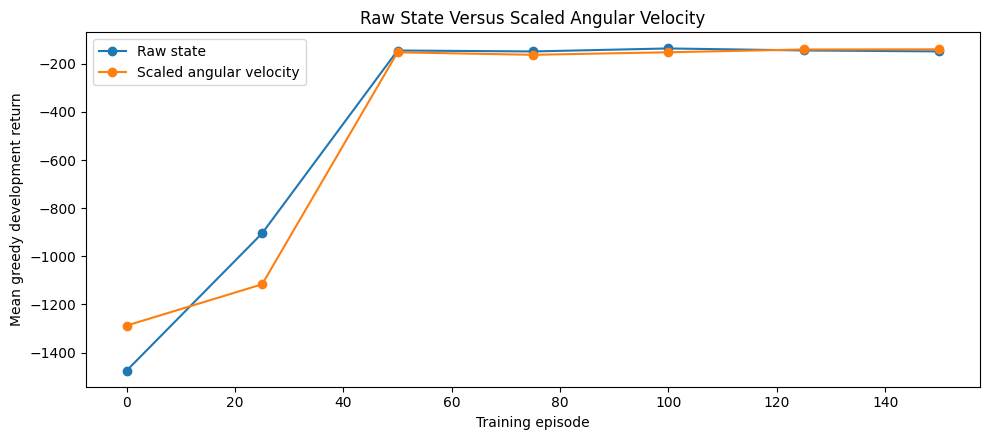

State-scaling run completed: True
Angular-velocity divisor: 8.0
Selected checkpoint episode: 150
Mean development return: -139.64917021723713
Development return standard deviation: 104.67360487855926
Scaled-minus-raw mean return: -3.706980102991764
Scaled paired-state win proportion: 0.20833333333333334
Within practical improvement margin: True
Formal runs completed: 17
Remaining formal-run capacity: 11
Saved state-scaling comparison: histories\R80_state_scaling_comparison.csv
Saved state-scaling weights: selected_weights\R80_STATE_SCALE_best.weights.h5
Section 14.1 state scaling: COMPLETE


In [76]:
R80_STATE_SCALE_RUN_ID = "R80_STATE_SCALE"

R80_STATE_SCALE_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R80_STATE_SCALE_RUN_ID}_best.weights.h5"
)
R80_STATE_SCALE_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{R80_STATE_SCALE_RUN_ID}_history.csv"
)
R80_STATE_SCALE_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{R80_STATE_SCALE_RUN_ID}"
        "_development_evaluations.csv"
    )
)
R80_STATE_SCALE_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R80_STATE_SCALE_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
R80_STATE_SCALE_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R80_STATE_SCALE_RUN_ID}_summary.csv"
)
R80_STATE_SCALE_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{R80_STATE_SCALE_RUN_ID}"
        "_selected_state_results.csv"
    )
)
R80_STATE_SCALE_COMPARISON_PATH = (
    HISTORIES_DIR
    / "R80_state_scaling_comparison.csv"
)
R80_STATE_SCALE_PAIRED_PATH = (
    HISTORIES_DIR
    / "R80_state_scaling_paired_states.csv"
)

assert OPTIMISATION_STABILITY_SELECTION_LOCKED is True
assert SELECTED_OPTIMIZER == "Adam"
assert SELECTED_LEARNING_RATE == 0.001
assert SELECTED_TD_LOSS == "MSE"
assert SELECTED_GRADIENT_CLIPPING == "none"
assert SELECTED_GAMMA == 0.99
assert ACTION_COMPARISON_GAMMA == 0.99
assert FORMAL_RUNS_COMPLETED in (16, 17)
assert remaining_formal_run_capacity in (12, 11)

state_scale_env = make_pendulum_env(
    GRAVITY_SETTINGS["default"]
)
try:
    R80_ANGULAR_VELOCITY_DIVISOR = float(
        state_scale_env.unwrapped.max_speed
    )
finally:
    state_scale_env.close()

assert np.isclose(
    R80_ANGULAR_VELOCITY_DIVISOR,
    8.0,
    rtol=0.0,
    atol=0.0,
)


def build_scaled_dueling_q_network(
    state_dim: int,
    action_count: int,
    hidden_units: Tuple[int, ...] = STANDARD_HIDDEN_UNITS,
    model_name: str = "scaled_dueling_q_network",
) -> keras.Model:
    """Build Dueling DQN with fixed theta-dot input scaling."""
    assert int(state_dim) == 3
    assert int(action_count) > 1
    assert tuple(hidden_units) == (64, 64)

    state_input = keras.Input(
        shape=(int(state_dim),),
        dtype=tf.float32,
        name=f"{model_name}_state_input",
    )

    scale_vector = tf.constant(
        [
            1.0,
            1.0,
            1.0 / R80_ANGULAR_VELOCITY_DIVISOR,
        ],
        dtype=tf.float32,
    )
    scaled_state = keras.layers.Lambda(
        lambda state: state * scale_vector,
        name=f"{model_name}_state_scaling",
    )(state_input)

    hidden = scaled_state
    for layer_index, units in enumerate(
        hidden_units,
        start=1,
    ):
        hidden = keras.layers.Dense(
            int(units),
            activation="relu",
            name=f"{model_name}_hidden_{layer_index}",
        )(hidden)

    state_value = keras.layers.Dense(
        1,
        activation="linear",
        name=f"{model_name}_state_value",
    )(hidden)

    action_advantage = keras.layers.Dense(
        int(action_count),
        activation="linear",
        name=f"{model_name}_action_advantage",
    )(hidden)

    centred_advantage = keras.layers.Lambda(
        lambda advantage: (
            advantage
            - tf.reduce_mean(
                advantage,
                axis=1,
                keepdims=True,
            )
        ),
        name=f"{model_name}_centred_advantage",
    )(action_advantage)

    q_values = keras.layers.Add(
        name=f"{model_name}_q_values",
    )([
        state_value,
        centred_advantage,
    ])

    model = keras.Model(
        inputs=state_input,
        outputs=q_values,
        name=model_name,
    )

    assert model.input_shape == (None, 3)
    assert model.output_shape == (
        None,
        int(action_count),
    )
    assert model.count_params() == 4936

    return model


state_scale_smoke_model = (
    build_scaled_dueling_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=FOUNDATION_SCREEN_ACTION_COUNT,
        hidden_units=STANDARD_HIDDEN_UNITS,
        model_name="r80_state_scale_smoke",
    )
)
state_scale_probe_model = keras.Model(
    inputs=state_scale_smoke_model.input,
    outputs=state_scale_smoke_model.get_layer(
        "r80_state_scale_smoke_state_scaling"
    ).output,
)

state_scale_probe_input = np.array(
    [
        [1.0, 0.0, 8.0],
        [0.0, 1.0, -8.0],
        [-1.0, 0.0, 4.0],
    ],
    dtype=np.float32,
)
state_scale_probe_output = (
    state_scale_probe_model(
        tf.convert_to_tensor(
            state_scale_probe_input,
            dtype=tf.float32,
        ),
        training=False,
    ).numpy()
)

np.testing.assert_allclose(
    state_scale_probe_output,
    np.array(
        [
            [1.0, 0.0, 1.0],
            [0.0, 1.0, -1.0],
            [-1.0, 0.0, 0.5],
        ],
        dtype=np.float32,
    ),
    rtol=0.0,
    atol=1e-7,
)
assert np.isfinite(
    state_scale_smoke_model(
        tf.convert_to_tensor(
            state_scale_probe_input,
            dtype=tf.float32,
        ),
        training=False,
    ).numpy()
).all()

r80_state_scale_required_artifacts = [
    R80_STATE_SCALE_WEIGHT_PATH,
    R80_STATE_SCALE_HISTORY_PATH,
    R80_STATE_SCALE_EVALUATION_PATH,
    R80_STATE_SCALE_EVALUATION_SUMMARY_PATH,
    R80_STATE_SCALE_SUMMARY_PATH,
    R80_STATE_SCALE_STATE_RESULTS_PATH,
]
r80_state_scale_artifacts_complete = all(
    path.exists()
    for path in r80_state_scale_required_artifacts
)

if (
    "r80_state_scale_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "r80_state_scale_history",
            "r80_state_scale_evaluation_states",
            "r80_state_scale_evaluation_summary",
            "r80_state_scale_selected_state_results",
            "r80_state_scale_summary",
        ]
    )
):
    print(
        "State-scaling result already exists in memory; "
        "no duplicate training run was started."
    )
elif r80_state_scale_artifacts_complete:
    r80_state_scale_history = read_csv_with_control_metric_migration(
        R80_STATE_SCALE_HISTORY_PATH
    )
    r80_state_scale_evaluation_states = read_csv_with_control_metric_migration(
        R80_STATE_SCALE_EVALUATION_PATH
    )
    r80_state_scale_evaluation_summary = read_csv_with_control_metric_migration(
        R80_STATE_SCALE_EVALUATION_SUMMARY_PATH
    )
    r80_state_scale_summary = read_csv_with_control_metric_migration(
        R80_STATE_SCALE_SUMMARY_PATH
    )
    r80_state_scale_selected_state_results = read_csv_with_control_metric_migration(
        R80_STATE_SCALE_STATE_RESULTS_PATH
    )

    assert len(r80_state_scale_summary) == 1
    r80_state_scale_summary_record = (
        r80_state_scale_summary.iloc[0].to_dict()
    )
    r80_state_scale_selected_model = (
        build_scaled_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FOUNDATION_SCREEN_ACTION_COUNT,
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r80_state_scale_reloaded_q_network"
            ),
        )
    )
    r80_state_scale_selected_model.load_weights(
        R80_STATE_SCALE_WEIGHT_PATH
    )
    print(
        "Loaded completed state-scaling artifacts; "
        "no duplicate training run was started."
    )
else:
    original_dueling_builder = (
        build_dueling_q_network
    )
    build_dueling_q_network = (
        build_scaled_dueling_q_network
    )

    try:
        r80_state_scale_result = (
            run_dueling_dqn_foundation(
                run_id=R80_STATE_SCALE_RUN_ID,
                torque_values=(
                    FOUNDATION_SCREEN_TORQUE_VALUES
                ),
                seed=FOUNDATION_SCREEN_SEED,
                weight_path=(
                    R80_STATE_SCALE_WEIGHT_PATH
                ),
            )
        )
    finally:
        build_dueling_q_network = (
            original_dueling_builder
        )

    r80_state_scale_history = (
        r80_state_scale_result["history"]
    )
    r80_state_scale_evaluation_states = (
        r80_state_scale_result[
            "evaluation_states"
        ]
    )
    r80_state_scale_evaluation_summary = (
        r80_state_scale_result[
            "evaluation_summary"
        ]
    )
    r80_state_scale_selected_state_results = (
        r80_state_scale_result[
            "selected_state_results"
        ]
    )
    r80_state_scale_selected_model = (
        r80_state_scale_result[
            "selected_model"
        ]
    )
    r80_state_scale_summary_record = dict(
        r80_state_scale_result[
            "summary_record"
        ]
    )
    r80_state_scale_summary_record.update({
        "conditional_improvement": (
            "scaled_angular_velocity"
        ),
        "state_representation": (
            "[cos(theta), sin(theta), theta_dot / 8]"
        ),
        "angular_velocity_divisor": (
            R80_ANGULAR_VELOCITY_DIVISOR
        ),
        "optimisation_recipe": (
            SELECTED_OPTIMISATION_STABILITY_RECIPE
        ),
        "replay_target_recipe": (
            SELECTED_REPLAY_TARGET_RECIPE
        ),
        "exploration_recipe": (
            SELECTED_EXPLORATION_RECIPE
        ),
        "reference_run_id": R42_RUN_ID,
    })
    r80_state_scale_summary = pd.DataFrame(
        [r80_state_scale_summary_record]
    )

FORMAL_RUNS_COMPLETED = 17
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 17
assert remaining_formal_run_capacity == 11
assert len(r80_state_scale_history) == 150
assert len(
    r80_state_scale_evaluation_summary
) == 7
assert int(
    r80_state_scale_summary_record["seed"]
) == 42
assert (
    r80_state_scale_summary_record["model"]
    == "Dueling DQN"
)
assert int(
    r80_state_scale_summary_record["action_count"]
) == 7
assert int(
    r80_state_scale_summary_record["parameter_count"]
) == 4936
assert int(
    r80_state_scale_summary_record[
        "environment_steps"
    ]
) == 30_000
assert int(
    r80_state_scale_summary_record[
        "optimizer_updates"
    ]
) == 29_001
assert int(
    r80_state_scale_summary_record[
        "target_updates"
    ]
) == 116
assert np.isfinite(
    r80_state_scale_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert R80_STATE_SCALE_WEIGHT_PATH.exists()

r80_state_scale_history.to_csv(
    R80_STATE_SCALE_HISTORY_PATH,
    index=False,
)
r80_state_scale_evaluation_states.to_csv(
    R80_STATE_SCALE_EVALUATION_PATH,
    index=False,
)
r80_state_scale_evaluation_summary.to_csv(
    R80_STATE_SCALE_EVALUATION_SUMMARY_PATH,
    index=False,
)
r80_state_scale_summary.to_csv(
    R80_STATE_SCALE_SUMMARY_PATH,
    index=False,
)
r80_state_scale_selected_state_results.to_csv(
    R80_STATE_SCALE_STATE_RESULTS_PATH,
    index=False,
)

raw_state_results = (
    r42_selected_state_results
    [["state_id", "return"]]
    .rename(
        columns={"return": "raw_return"}
    )
    .sort_values("state_id")
    .reset_index(drop=True)
)
scaled_state_results = (
    r80_state_scale_selected_state_results
    [["state_id", "return"]]
    .rename(
        columns={"return": "scaled_return"}
    )
    .sort_values("state_id")
    .reset_index(drop=True)
)

r80_state_scale_paired = raw_state_results.merge(
    scaled_state_results,
    on="state_id",
    how="inner",
    validate="one_to_one",
)
assert len(r80_state_scale_paired) == len(
    DEVELOPMENT_PHYSICAL_STATES
)

r80_state_scale_paired[
    "scaled_minus_raw"
] = (
    r80_state_scale_paired["scaled_return"]
    - r80_state_scale_paired["raw_return"]
)

state_scale_minus_raw = float(
    r80_state_scale_summary_record[
        "mean_development_return"
    ]
    - r42_summary_record[
        "mean_development_return"
    ]
)

np.testing.assert_allclose(
    state_scale_minus_raw,
    r80_state_scale_paired[
        "scaled_minus_raw"
    ].mean(),
    rtol=0.0,
    atol=1e-6,
)

raw_final_return = float(
    r42_evaluation_summary.loc[
        r42_evaluation_summary["episode"] == 150,
        "mean_development_return",
    ].iloc[0]
)
scaled_final_return = float(
    r80_state_scale_evaluation_summary.loc[
        r80_state_scale_evaluation_summary[
            "episode"
        ] == 150,
        "mean_development_return",
    ].iloc[0]
)

r80_state_scale_comparison_record = {
    "reference_run_id": R42_RUN_ID,
    "candidate_run_id": R80_STATE_SCALE_RUN_ID,
    "seed": 42,
    "raw_mean_return": float(
        r42_summary_record[
            "mean_development_return"
        ]
    ),
    "scaled_mean_return": float(
        r80_state_scale_summary_record[
            "mean_development_return"
        ]
    ),
    "scaled_minus_raw": state_scale_minus_raw,
    "practical_improvement_margin": float(
        PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "within_practical_margin": bool(
        abs(state_scale_minus_raw)
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "raw_state_std": float(
        r42_summary_record[
            "development_return_std"
        ]
    ),
    "scaled_state_std": float(
        r80_state_scale_summary_record[
            "development_return_std"
        ]
    ),
    "raw_upright_fraction": float(
        r42_summary_record[
            "upright_fraction"
        ]
    ),
    "scaled_upright_fraction": float(
        r80_state_scale_summary_record[
            "upright_fraction"
        ]
    ),
    "raw_selected_episode": int(
        r42_summary_record[
            "selected_checkpoint_episode"
        ]
    ),
    "scaled_selected_episode": int(
        r80_state_scale_summary_record[
            "selected_checkpoint_episode"
        ]
    ),
    "raw_selected_to_final_change": float(
        raw_final_return
        - r42_summary_record[
            "mean_development_return"
        ]
    ),
    "scaled_selected_to_final_change": float(
        scaled_final_return
        - r80_state_scale_summary_record[
            "mean_development_return"
        ]
    ),
    "scaled_paired_win_proportion": float(
        (
            r80_state_scale_paired[
                "scaled_minus_raw"
            ] > 0.0
        ).mean()
    ),
    "raw_paired_win_proportion": float(
        (
            r80_state_scale_paired[
                "scaled_minus_raw"
            ] < 0.0
        ).mean()
    ),
    "paired_median_difference": float(
        r80_state_scale_paired[
            "scaled_minus_raw"
        ].median()
    ),
    "selection_deferred_until_review": True,
    "formal_significance_claim": False,
}

r80_state_scale_comparison = pd.DataFrame(
    [r80_state_scale_comparison_record]
)

assert np.isfinite(
    r80_state_scale_comparison
    .select_dtypes(include=[np.number])
    .to_numpy(dtype=np.float64)
).all()
assert (
    r80_state_scale_comparison_record[
        "selection_deferred_until_review"
    ]
    is True
)

r80_state_scale_comparison.to_csv(
    R80_STATE_SCALE_COMPARISON_PATH,
    index=False,
)
r80_state_scale_paired.to_csv(
    R80_STATE_SCALE_PAIRED_PATH,
    index=False,
)

display(r80_state_scale_comparison)
display(r80_state_scale_evaluation_summary)
display(r80_state_scale_summary)

plt.figure(figsize=(10, 4.5))
plt.plot(
    r42_evaluation_summary["episode"],
    r42_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Raw state",
)
plt.plot(
    r80_state_scale_evaluation_summary[
        "episode"
    ],
    r80_state_scale_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Scaled angular velocity",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("Raw State Versus Scaled Angular Velocity")
plt.legend()
plt.tight_layout()
plt.show()

print("State-scaling run completed:", True)
print(
    "Angular-velocity divisor:",
    R80_ANGULAR_VELOCITY_DIVISOR,
)
print(
    "Selected checkpoint episode:",
    r80_state_scale_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    r80_state_scale_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    r80_state_scale_summary_record[
        "development_return_std"
    ],
)
print(
    "Scaled-minus-raw mean return:",
    state_scale_minus_raw,
)
print(
    "Scaled paired-state win proportion:",
    r80_state_scale_comparison_record[
        "scaled_paired_win_proportion"
    ],
)
print(
    "Within practical improvement margin:",
    r80_state_scale_comparison_record[
        "within_practical_margin"
    ],
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved state-scaling comparison:",
    R80_STATE_SCALE_COMPARISON_PATH,
)
print(
    "Saved state-scaling weights:",
    R80_STATE_SCALE_WEIGHT_PATH,
)
print("Section 14.1 state scaling: COMPLETE")


### 14.1 Result Interpretation

**Finding.** Scaling angular velocity completed all `150` episodes without a
technical failure.

Its selected checkpoint was episode `150`, with:

- mean development return: `-139.649170`;
- development-state standard deviation: `104.673605`;
- scaled-minus-raw return: `-3.706980`;
- scaled paired-state win proportion: `0.208333`.

The difference remains inside the practical margin. The raw-state reference
had the better return, lower state-wise spread, slightly higher upright
fraction and earlier selected checkpoint. The scaled candidate had no
selected-to-final decline because its best checkpoint occurred at the final
evaluation.

**Importance.** Scaling improved the smoothness of late checkpoint progress,
but it did not improve the primary control evidence or initial-state
robustness under seed `42`.

**Decision.** Do not retain or reject state scaling from one seed because the
return difference is inside the practical margin.

**Next step.** Confirm scaled angular velocity against the existing raw-state
reference using matched seed `123`.


### 14.1.1 Matched Seed-123 State-Scaling Confirmation

The reference is the completed raw-state Dueling run:

```text
R42_DUELING_SEED_123
```

The candidate is:

```text
R80_STATE_SCALE_SEED_123
```

Only the fixed input transformation changes:

```text
raw:    [cos(theta), sin(theta), theta_dot]
scaled: [cos(theta), sin(theta), theta_dot / 8]
```

Architecture, seven-action torque set, moderate exploration, retained replay
and target recipe, Adam learning rate, MSE loss, no clipping, gamma `0.99`,
default gravity, training budget, checkpoint rule and fixed development
states remain matched.

This consumes one formal-training slot. After completion, the formal-run
count should be `18`, leaving `10` runs.

Capacity, head-capacity and advanced-method branches remain deferred until
this matched state-scaling comparison is reviewed.


Loaded completed state-scaling seed-123 artifacts; no duplicate training run was started.


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1512.153549,-1531.230566,159.570351,-1816.480863,-1276.887168,0.005833,2.603251,1.529011,1.117222,0.018844
1,25,-604.690941,-196.813286,663.171742,-1544.074483,-1.048980,0.387917,0.730328,2.516724,1.626667,0.292714
2,50,-165.589890,-126.940243,147.649515,-619.141571,-1.348493,0.841250,0.302873,0.657898,1.403056,0.792504
3,75,-140.504613,-124.414696,107.688183,-380.683719,-0.453314,0.866042,0.242605,0.527147,1.030694,0.570352
4,100,-144.511126,-124.070009,109.970906,-382.211555,-0.513671,0.865625,0.232751,0.553768,1.084722,0.857203
5,125,-141.603422,-124.579184,107.631852,-353.650816,-0.939229,0.867292,0.237082,0.571566,1.474028,0.786642
6,150,-146.034841,-123.939078,110.585007,-355.787137,-0.189308,0.869167,0.240182,0.527334,0.821667,0.777010


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,parameter_count,weight_path,technical_status,conditional_improvement,state_representation,angular_velocity_divisor,optimisation_recipe,replay_target_recipe,exploration_recipe,reference_run_id
0,R80_STATE_SCALE_SEED_123,R80_STATE_SCALE_SEED_123,False,True,Dueling DQN,default,123,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS,scaled_angular_velocity,"[cos(theta), sin(theta), theta_dot / 8]",8.0,mse_gamma_0.99_no_clipping,reference,moderate_decay,R42_DUELING_SEED_123


,seed,reference_state,candidate_state,reference_mean_return,candidate_mean_return,candidate_minus_reference,reference_state_std,candidate_state_std,reference_upright_fraction,candidate_upright_fraction,paired_state_count,paired_median_difference,candidate_win_proportion,reference_win_proportion,minimum_paired_difference,maximum_paired_difference,within_practical_margin
0,42,raw,scaled_angular_velocity,-135.942190,-139.649170,-3.706980,99.338244,104.673605,0.872292,0.867917,24,-0.933694,0.208333,0.791667,-54.230760,4.020522,True
1,123,raw,scaled_angular_velocity,-138.522287,-140.504613,-1.982326,102.394330,107.688183,0.866667,0.866042,24,0.235420,0.583333,0.416667,-49.282175,3.737602,True


,matched_seeds,reference_state,candidate_state,reference_mean_across_seeds,candidate_mean_across_seeds,candidate_minus_reference_across_seed_means,mean_of_seed_level_differences,candidate_seed_win_count,reference_seed_win_count,practical_improvement_margin,aggregate_difference_within_margin,selection_deferred_until_review,formal_significance_claim
0,"[42, 123]",raw,scaled_angular_velocity,-137.232239,-140.076892,-2.844653,-2.844653,0,2,11.335072,True,True,False


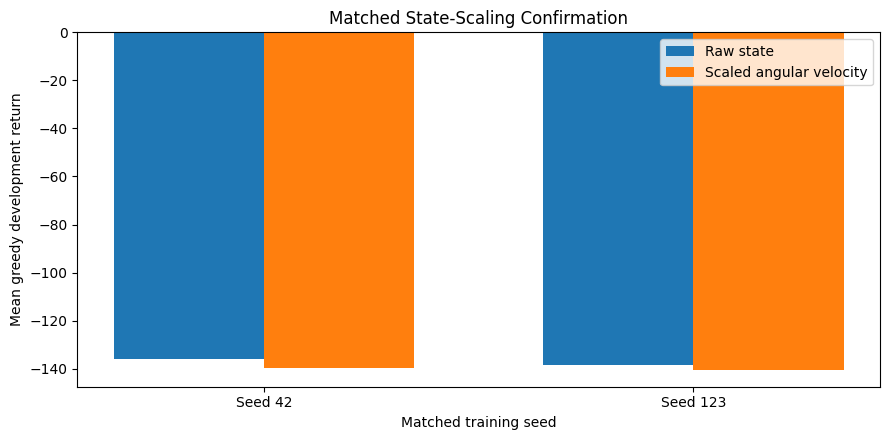

State-scaling seed-123 run completed: True
Selected checkpoint episode: 75
Seed-123 scaled-state mean development return: -140.5046128355362
Seed-123 raw-state mean development return: -138.52228717953105
Seed-123 scaled-minus-raw: -1.9823256560051448
Matched two-seed scaled-minus-raw: -2.844652879498426
Scaled-state seed win count: 0
Aggregate difference within practical margin: True
Formal runs completed: 18
Remaining formal-run capacity: 10
Saved matched state-scaling confirmation: histories\R80_state_scaling_matched_seed_confirmation.csv
Saved state-scaling confirmation aggregate: histories\R80_state_scaling_matched_seed_confirmation_aggregate.csv
Section 14.1.1 matched state-scaling confirmation: COMPLETE


In [77]:
R80_STATE_SCALE_CONFIRMATION_SEED = 123
R80_STATE_SCALE_CONFIRMATION_RUN_ID = (
    "R80_STATE_SCALE_SEED_123"
)

R80_STATE_SCALE_CONFIRMATION_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / (
        f"{R80_STATE_SCALE_CONFIRMATION_RUN_ID}"
        "_best.weights.h5"
    )
)
R80_STATE_SCALE_CONFIRMATION_HISTORY_PATH = (
    HISTORIES_DIR
    / (
        f"{R80_STATE_SCALE_CONFIRMATION_RUN_ID}"
        "_history.csv"
    )
)
R80_STATE_SCALE_CONFIRMATION_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{R80_STATE_SCALE_CONFIRMATION_RUN_ID}"
        "_development_evaluations.csv"
    )
)
R80_STATE_SCALE_CONFIRMATION_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R80_STATE_SCALE_CONFIRMATION_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
R80_STATE_SCALE_CONFIRMATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R80_STATE_SCALE_CONFIRMATION_RUN_ID}"
        "_summary.csv"
    )
)
R80_STATE_SCALE_CONFIRMATION_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{R80_STATE_SCALE_CONFIRMATION_RUN_ID}"
        "_selected_state_results.csv"
    )
)
STATE_SCALE_MATCHED_CONFIRMATION_PATH = (
    HISTORIES_DIR
    / "R80_state_scaling_matched_seed_confirmation.csv"
)
STATE_SCALE_MATCHED_CONFIRMATION_AGGREGATE_PATH = (
    HISTORIES_DIR
    / (
        "R80_state_scaling_matched_seed_"
        "confirmation_aggregate.csv"
    )
)

assert OPTIMISATION_STABILITY_SELECTION_LOCKED is True
assert SELECTED_OPTIMISATION_STABILITY_RECIPE == (
    "mse_gamma_0.99_no_clipping"
)
assert R80_ANGULAR_VELOCITY_DIVISOR == 8.0
assert R80_STATE_SCALE_CONFIRMATION_SEED == 123
assert int(
    r42_confirmation_summary_record["seed"]
) == 123
assert FORMAL_RUNS_COMPLETED in (17, 18)
assert remaining_formal_run_capacity in (11, 10)

r80_state_scale_confirmation_required_artifacts = [
    R80_STATE_SCALE_CONFIRMATION_WEIGHT_PATH,
    R80_STATE_SCALE_CONFIRMATION_HISTORY_PATH,
    R80_STATE_SCALE_CONFIRMATION_EVALUATION_PATH,
    R80_STATE_SCALE_CONFIRMATION_EVALUATION_SUMMARY_PATH,
    R80_STATE_SCALE_CONFIRMATION_SUMMARY_PATH,
    R80_STATE_SCALE_CONFIRMATION_STATE_RESULTS_PATH,
]
r80_state_scale_confirmation_artifacts_complete = all(
    path.exists()
    for path in (
        r80_state_scale_confirmation_required_artifacts
    )
)

if (
    "r80_state_scale_confirmation_summary_record"
    in globals()
    and all(
        name in globals()
        for name in [
            "r80_state_scale_confirmation_history",
            "r80_state_scale_confirmation_evaluation_states",
            "r80_state_scale_confirmation_evaluation_summary",
            "r80_state_scale_confirmation_selected_state_results",
            "r80_state_scale_confirmation_summary",
        ]
    )
):
    print(
        "State-scaling seed-123 result already exists in "
        "memory; no duplicate training run was started."
    )
elif r80_state_scale_confirmation_artifacts_complete:
    r80_state_scale_confirmation_history = read_csv_with_control_metric_migration(
        R80_STATE_SCALE_CONFIRMATION_HISTORY_PATH
    )
    r80_state_scale_confirmation_evaluation_states = (
        read_csv_with_control_metric_migration(
            R80_STATE_SCALE_CONFIRMATION_EVALUATION_PATH
        )
    )
    r80_state_scale_confirmation_evaluation_summary = (
        read_csv_with_control_metric_migration(
            R80_STATE_SCALE_CONFIRMATION_EVALUATION_SUMMARY_PATH
        )
    )
    r80_state_scale_confirmation_summary = read_csv_with_control_metric_migration(
        R80_STATE_SCALE_CONFIRMATION_SUMMARY_PATH
    )
    r80_state_scale_confirmation_selected_state_results = (
        read_csv_with_control_metric_migration(
            R80_STATE_SCALE_CONFIRMATION_STATE_RESULTS_PATH
        )
    )

    assert len(
        r80_state_scale_confirmation_summary
    ) == 1
    r80_state_scale_confirmation_summary_record = (
        r80_state_scale_confirmation_summary
        .iloc[0]
        .to_dict()
    )
    r80_state_scale_confirmation_selected_model = (
        build_scaled_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=(
                FOUNDATION_SCREEN_ACTION_COUNT
            ),
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r80_state_scale_seed_123_"
                "reloaded_q_network"
            ),
        )
    )
    r80_state_scale_confirmation_selected_model.load_weights(
        R80_STATE_SCALE_CONFIRMATION_WEIGHT_PATH
    )
    print(
        "Loaded completed state-scaling seed-123 "
        "artifacts; no duplicate training run was started."
    )
else:
    original_dueling_builder = (
        build_dueling_q_network
    )
    build_dueling_q_network = (
        build_scaled_dueling_q_network
    )

    try:
        r80_state_scale_confirmation_result = (
            run_dueling_dqn_foundation(
                run_id=(
                    R80_STATE_SCALE_CONFIRMATION_RUN_ID
                ),
                torque_values=(
                    FOUNDATION_SCREEN_TORQUE_VALUES
                ),
                seed=(
                    R80_STATE_SCALE_CONFIRMATION_SEED
                ),
                weight_path=(
                    R80_STATE_SCALE_CONFIRMATION_WEIGHT_PATH
                ),
            )
        )
    finally:
        build_dueling_q_network = (
            original_dueling_builder
        )

    r80_state_scale_confirmation_history = (
        r80_state_scale_confirmation_result[
            "history"
        ]
    )
    r80_state_scale_confirmation_evaluation_states = (
        r80_state_scale_confirmation_result[
            "evaluation_states"
        ]
    )
    r80_state_scale_confirmation_evaluation_summary = (
        r80_state_scale_confirmation_result[
            "evaluation_summary"
        ]
    )
    r80_state_scale_confirmation_selected_state_results = (
        r80_state_scale_confirmation_result[
            "selected_state_results"
        ]
    )
    r80_state_scale_confirmation_selected_model = (
        r80_state_scale_confirmation_result[
            "selected_model"
        ]
    )
    r80_state_scale_confirmation_summary_record = dict(
        r80_state_scale_confirmation_result[
            "summary_record"
        ]
    )
    r80_state_scale_confirmation_summary_record.update({
        "conditional_improvement": (
            "scaled_angular_velocity"
        ),
        "state_representation": (
            "[cos(theta), sin(theta), theta_dot / 8]"
        ),
        "angular_velocity_divisor": (
            R80_ANGULAR_VELOCITY_DIVISOR
        ),
        "optimisation_recipe": (
            SELECTED_OPTIMISATION_STABILITY_RECIPE
        ),
        "replay_target_recipe": (
            SELECTED_REPLAY_TARGET_RECIPE
        ),
        "exploration_recipe": (
            SELECTED_EXPLORATION_RECIPE
        ),
        "reference_run_id": (
            "R42_DUELING_SEED_123"
        ),
    })
    r80_state_scale_confirmation_summary = (
        pd.DataFrame([
            r80_state_scale_confirmation_summary_record
        ])
    )

FORMAL_RUNS_COMPLETED = 18
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 18
assert remaining_formal_run_capacity == 10
assert len(
    r80_state_scale_confirmation_history
) == 150
assert len(
    r80_state_scale_confirmation_evaluation_summary
) == 7
assert int(
    r80_state_scale_confirmation_summary_record[
        "seed"
    ]
) == 123
assert (
    r80_state_scale_confirmation_summary_record[
        "model"
    ]
    == "Dueling DQN"
)
assert int(
    r80_state_scale_confirmation_summary_record[
        "action_count"
    ]
) == 7
assert int(
    r80_state_scale_confirmation_summary_record[
        "parameter_count"
    ]
) == 4936
assert int(
    r80_state_scale_confirmation_summary_record[
        "environment_steps"
    ]
) == 30_000
assert int(
    r80_state_scale_confirmation_summary_record[
        "optimizer_updates"
    ]
) == 29_001
assert int(
    r80_state_scale_confirmation_summary_record[
        "target_updates"
    ]
) == 116
assert np.isclose(
    float(
        r80_state_scale_confirmation_summary_record[
            "angular_velocity_divisor"
        ]
    ),
    8.0,
    rtol=0.0,
    atol=0.0,
)
assert np.isfinite(
    r80_state_scale_confirmation_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert (
    R80_STATE_SCALE_CONFIRMATION_WEIGHT_PATH.exists()
)

r80_state_scale_confirmation_history.to_csv(
    R80_STATE_SCALE_CONFIRMATION_HISTORY_PATH,
    index=False,
)
r80_state_scale_confirmation_evaluation_states.to_csv(
    R80_STATE_SCALE_CONFIRMATION_EVALUATION_PATH,
    index=False,
)
r80_state_scale_confirmation_evaluation_summary.to_csv(
    R80_STATE_SCALE_CONFIRMATION_EVALUATION_SUMMARY_PATH,
    index=False,
)
r80_state_scale_confirmation_summary.to_csv(
    R80_STATE_SCALE_CONFIRMATION_SUMMARY_PATH,
    index=False,
)
r80_state_scale_confirmation_selected_state_results.to_csv(
    R80_STATE_SCALE_CONFIRMATION_STATE_RESULTS_PATH,
    index=False,
)

state_scale_matched_seed_sources = {
    42: {
        "reference_summary": r42_summary_record,
        "candidate_summary": (
            r80_state_scale_summary_record
        ),
        "reference_states": (
            r42_selected_state_results.copy()
        ),
        "candidate_states": (
            r80_state_scale_selected_state_results.copy()
        ),
    },
    123: {
        "reference_summary": (
            r42_confirmation_summary_record
        ),
        "candidate_summary": (
            r80_state_scale_confirmation_summary_record
        ),
        "reference_states": (
            r42_confirmation_selected_state_results.copy()
        ),
        "candidate_states": (
            r80_state_scale_confirmation_selected_state_results.copy()
        ),
    },
}

state_scale_confirmation_records = []

for seed in (42, 123):
    source = state_scale_matched_seed_sources[
        seed
    ]
    reference_summary = source[
        "reference_summary"
    ]
    candidate_summary = source[
        "candidate_summary"
    ]

    reference_states = (
        source["reference_states"]
        [["state_id", "return"]]
        .rename(
            columns={
                "return": "raw_return"
            }
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )
    candidate_states = (
        source["candidate_states"]
        [["state_id", "return"]]
        .rename(
            columns={
                "return": "scaled_return"
            }
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )

    paired = reference_states.merge(
        candidate_states,
        on="state_id",
        how="inner",
        validate="one_to_one",
    )
    assert len(paired) == len(
        DEVELOPMENT_PHYSICAL_STATES
    )

    paired["scaled_minus_raw"] = (
        paired["scaled_return"]
        - paired["raw_return"]
    )

    reference_mean = float(
        reference_summary[
            "mean_development_return"
        ]
    )
    candidate_mean = float(
        candidate_summary[
            "mean_development_return"
        ]
    )
    mean_difference = float(
        candidate_mean - reference_mean
    )

    np.testing.assert_allclose(
        mean_difference,
        paired[
            "scaled_minus_raw"
        ].mean(),
        rtol=0.0,
        atol=1e-6,
    )

    state_scale_confirmation_records.append({
        "seed": int(seed),
        "reference_state": "raw",
        "candidate_state": (
            "scaled_angular_velocity"
        ),
        "reference_mean_return": reference_mean,
        "candidate_mean_return": candidate_mean,
        "candidate_minus_reference": (
            mean_difference
        ),
        "reference_state_std": float(
            reference_summary[
                "development_return_std"
            ]
        ),
        "candidate_state_std": float(
            candidate_summary[
                "development_return_std"
            ]
        ),
        "reference_upright_fraction": float(
            reference_summary[
                "upright_fraction"
            ]
        ),
        "candidate_upright_fraction": float(
            candidate_summary[
                "upright_fraction"
            ]
        ),
        "paired_state_count": int(len(paired)),
        "paired_median_difference": float(
            paired[
                "scaled_minus_raw"
            ].median()
        ),
        "candidate_win_proportion": float(
            (
                paired[
                    "scaled_minus_raw"
                ] > 0.0
            ).mean()
        ),
        "reference_win_proportion": float(
            (
                paired[
                    "scaled_minus_raw"
                ] < 0.0
            ).mean()
        ),
        "minimum_paired_difference": float(
            paired[
                "scaled_minus_raw"
            ].min()
        ),
        "maximum_paired_difference": float(
            paired[
                "scaled_minus_raw"
            ].max()
        ),
        "within_practical_margin": bool(
            abs(mean_difference)
            <= PRACTICAL_IMPROVEMENT_MARGIN
        ),
    })

state_scale_matched_confirmation = pd.DataFrame(
    state_scale_confirmation_records
).sort_values("seed").reset_index(drop=True)

reference_seed_means = (
    state_scale_matched_confirmation[
        "reference_mean_return"
    ].to_numpy(dtype=np.float64)
)
candidate_seed_means = (
    state_scale_matched_confirmation[
        "candidate_mean_return"
    ].to_numpy(dtype=np.float64)
)
seed_level_differences = (
    state_scale_matched_confirmation[
        "candidate_minus_reference"
    ].to_numpy(dtype=np.float64)
)

state_scale_confirmation_aggregate_record = {
    "matched_seeds": [42, 123],
    "reference_state": "raw",
    "candidate_state": (
        "scaled_angular_velocity"
    ),
    "reference_mean_across_seeds": float(
        np.mean(reference_seed_means)
    ),
    "candidate_mean_across_seeds": float(
        np.mean(candidate_seed_means)
    ),
    "candidate_minus_reference_across_seed_means": float(
        np.mean(candidate_seed_means)
        - np.mean(reference_seed_means)
    ),
    "mean_of_seed_level_differences": float(
        np.mean(seed_level_differences)
    ),
    "candidate_seed_win_count": int(
        np.sum(seed_level_differences > 0.0)
    ),
    "reference_seed_win_count": int(
        np.sum(seed_level_differences < 0.0)
    ),
    "practical_improvement_margin": float(
        PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "aggregate_difference_within_margin": bool(
        abs(np.mean(seed_level_differences))
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "selection_deferred_until_review": True,
    "formal_significance_claim": False,
}

state_scale_confirmation_aggregate = pd.DataFrame(
    [state_scale_confirmation_aggregate_record]
)

assert len(
    state_scale_matched_confirmation
) == 2
assert state_scale_matched_confirmation[
    "seed"
].tolist() == [42, 123]
assert (
    state_scale_matched_confirmation[
        "paired_state_count"
    ] == len(DEVELOPMENT_PHYSICAL_STATES)
).all()
assert np.isfinite(
    state_scale_matched_confirmation
    .select_dtypes(include=[np.number])
    .to_numpy(dtype=np.float64)
).all()
assert np.isclose(
    state_scale_confirmation_aggregate_record[
        "candidate_minus_reference_across_seed_means"
    ],
    state_scale_confirmation_aggregate_record[
        "mean_of_seed_level_differences"
    ],
    rtol=0.0,
    atol=1e-12,
)
assert (
    state_scale_confirmation_aggregate_record[
        "selection_deferred_until_review"
    ]
    is True
)

state_scale_matched_confirmation.to_csv(
    STATE_SCALE_MATCHED_CONFIRMATION_PATH,
    index=False,
)
state_scale_confirmation_aggregate.to_csv(
    STATE_SCALE_MATCHED_CONFIRMATION_AGGREGATE_PATH,
    index=False,
)

display(
    r80_state_scale_confirmation_evaluation_summary
)
display(r80_state_scale_confirmation_summary)
display(state_scale_matched_confirmation)
display(state_scale_confirmation_aggregate)

plt.figure(figsize=(9, 4.5))
x_positions = np.arange(2)
bar_width = 0.35
plt.bar(
    x_positions - bar_width / 2,
    reference_seed_means,
    width=bar_width,
    label="Raw state",
)
plt.bar(
    x_positions + bar_width / 2,
    candidate_seed_means,
    width=bar_width,
    label="Scaled angular velocity",
)
plt.xticks(
    x_positions,
    ["Seed 42", "Seed 123"],
)
plt.xlabel("Matched training seed")
plt.ylabel("Mean greedy development return")
plt.title("Matched State-Scaling Confirmation")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "State-scaling seed-123 run completed:",
    True,
)
print(
    "Selected checkpoint episode:",
    r80_state_scale_confirmation_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Seed-123 scaled-state mean development return:",
    r80_state_scale_confirmation_summary_record[
        "mean_development_return"
    ],
)
print(
    "Seed-123 raw-state mean development return:",
    r42_confirmation_summary_record[
        "mean_development_return"
    ],
)
print(
    "Seed-123 scaled-minus-raw:",
    state_scale_matched_confirmation.loc[
        state_scale_matched_confirmation[
            "seed"
        ] == 123,
        "candidate_minus_reference",
    ].iloc[0],
)
print(
    "Matched two-seed scaled-minus-raw:",
    state_scale_confirmation_aggregate_record[
        "candidate_minus_reference_across_seed_means"
    ],
)
print(
    "Scaled-state seed win count:",
    state_scale_confirmation_aggregate_record[
        "candidate_seed_win_count"
    ],
)
print(
    "Aggregate difference within practical margin:",
    state_scale_confirmation_aggregate_record[
        "aggregate_difference_within_margin"
    ],
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved matched state-scaling confirmation:",
    STATE_SCALE_MATCHED_CONFIRMATION_PATH,
)
print(
    "Saved state-scaling confirmation aggregate:",
    STATE_SCALE_MATCHED_CONFIRMATION_AGGREGATE_PATH,
)
print(
    "Section 14.1.1 matched state-scaling confirmation: "
    "COMPLETE"
)


### 14.1.1 Result Interpretation

**Finding.** Scaled angular velocity lost both matched seed-level
comparisons:

| Seed | Raw state | Scaled state | Scaled minus raw |
|---|---:|---:|---:|
| `42` | `-135.942190` | `-139.649170` | `-3.706980` |
| `123` | `-138.522287` | `-140.504613` | `-1.982326` |

Across both seeds, the raw representation averaged `-137.232239`, while the
scaled representation averaged `-140.076892`. Scaling therefore trailed by
`2.844653`.

The raw representation also had lower average state-wise spread, a slightly
higher average upright fraction and the stronger average paired-state win
rate. Scaling reached one best checkpoint at the end of training, but this
late smoothness did not improve the aggregate control result.

**Importance.** The difference remains inside the practical margin, so this
is not formal proof that scaling is always worse. However, both matched seeds
and the supporting robustness evidence favour the raw state.

**Decision.** Retain the raw Gym observation.

**Caveat.** Scaling only angular velocity is one fixed preprocessing choice.
Other transformations were not tested because no evidence justified a broader
preprocessing search.

**Next step.** Close the remaining conditional-improvement gates and preserve
the remaining budget for the combined model, required ablation, final
confirmation and four-gravity training.


## 14.2 Q-Network Capacity Decision

A network-capacity experiment is **not activated**.

The selected `64, 64` Dueling network has `4,936` trainable parameters and
already learns a viable policy under multiple seeds. The diagnosis did not
show under-capacity, persistent failure to learn or a need for a larger
shared body. A width comparison would therefore be speculative rather than
diagnosis-led.

## 14.3 Model-Specific Head Capacity Decision

A separate Dueling-head capacity experiment is **not activated**.

The current value and advantage streams produced valid outputs and the
selected foundation outperformed the simpler alternatives. There is no
head-specific failure that justifies changing stream capacity.

## 14.4 Additional Advanced Method Decision

No additional advanced method is approved.

Prioritised replay and n-step returns remain outside the normal programme.
The remaining formal-run capacity must protect the required combined model,
ablation, final confirmation and four-gravity training.

## 14.5 Conditional-Improvement Decision

The retained state representation is:

```text
[cos(theta), sin(theta), theta_dot]
```

No state scaling, capacity change, head-capacity change or additional
advanced method is retained.


In [78]:
CONDITIONAL_IMPROVEMENT_SELECTION_PATH = (
    HISTORIES_DIR
    / "R80_conditional_improvement_selection.csv"
)

state_scale_selection_table = (
    state_scale_matched_confirmation
    .sort_values("seed")
    .reset_index(drop=True)
)

raw_mean_across_seeds = float(
    state_scale_selection_table[
        "reference_mean_return"
    ].mean()
)
scaled_mean_across_seeds = float(
    state_scale_selection_table[
        "candidate_mean_return"
    ].mean()
)
scaled_minus_raw_across_seeds = float(
    scaled_mean_across_seeds
    - raw_mean_across_seeds
)

raw_average_state_std = float(
    state_scale_selection_table[
        "reference_state_std"
    ].mean()
)
scaled_average_state_std = float(
    state_scale_selection_table[
        "candidate_state_std"
    ].mean()
)

raw_average_upright = float(
    state_scale_selection_table[
        "reference_upright_fraction"
    ].mean()
)
scaled_average_upright = float(
    state_scale_selection_table[
        "candidate_upright_fraction"
    ].mean()
)

raw_average_paired_win_rate = float(
    state_scale_selection_table[
        "reference_win_proportion"
    ].mean()
)
scaled_average_paired_win_rate = float(
    state_scale_selection_table[
        "candidate_win_proportion"
    ].mean()
)

SELECTED_STATE_REPRESENTATION = (
    "[cos(theta), sin(theta), theta_dot]"
)
SELECTED_STATE_SCALING = "none"
STATE_SCALING_RETAINED = False
NETWORK_CAPACITY_EXPERIMENT_APPROVED = False
MODEL_SPECIFIC_HEAD_CAPACITY_APPROVED = False
ADDITIONAL_ADVANCED_METHOD_APPROVED = False
CONDITIONAL_IMPROVEMENT_SELECTION_LOCKED = True

REQUIRED_RUNS_RESERVED_AFTER_SECTION_14 = 9
DISCRETIONARY_RUN_BUFFER_AFTER_SECTION_14 = (
    remaining_formal_run_capacity
    - REQUIRED_RUNS_RESERVED_AFTER_SECTION_14
)

conditional_improvement_selection_record = {
    "selected_state_representation": (
        SELECTED_STATE_REPRESENTATION
    ),
    "selected_state_scaling": (
        SELECTED_STATE_SCALING
    ),
    "matched_seeds": [42, 123],
    "raw_mean_across_seeds": (
        raw_mean_across_seeds
    ),
    "scaled_mean_across_seeds": (
        scaled_mean_across_seeds
    ),
    "scaled_minus_raw_across_seeds": (
        scaled_minus_raw_across_seeds
    ),
    "difference_within_practical_margin": bool(
        abs(scaled_minus_raw_across_seeds)
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "raw_seed_win_count": int(
        (
            state_scale_selection_table[
                "candidate_minus_reference"
            ] < 0.0
        ).sum()
    ),
    "scaled_seed_win_count": int(
        (
            state_scale_selection_table[
                "candidate_minus_reference"
            ] > 0.0
        ).sum()
    ),
    "raw_average_state_std": (
        raw_average_state_std
    ),
    "scaled_average_state_std": (
        scaled_average_state_std
    ),
    "raw_average_upright_fraction": (
        raw_average_upright
    ),
    "scaled_average_upright_fraction": (
        scaled_average_upright
    ),
    "raw_average_paired_win_rate": (
        raw_average_paired_win_rate
    ),
    "scaled_average_paired_win_rate": (
        scaled_average_paired_win_rate
    ),
    "state_scaling_retained": (
        STATE_SCALING_RETAINED
    ),
    "network_capacity_experiment_approved": (
        NETWORK_CAPACITY_EXPERIMENT_APPROVED
    ),
    "model_specific_head_capacity_approved": (
        MODEL_SPECIFIC_HEAD_CAPACITY_APPROVED
    ),
    "additional_advanced_method_approved": (
        ADDITIONAL_ADVANCED_METHOD_APPROVED
    ),
    "required_runs_reserved": (
        REQUIRED_RUNS_RESERVED_AFTER_SECTION_14
    ),
    "discretionary_run_buffer": (
        DISCRETIONARY_RUN_BUFFER_AFTER_SECTION_14
    ),
    "formal_significance_claim": False,
    "selection_status": "LOCKED",
}

conditional_improvement_selection_summary = (
    pd.DataFrame([
        conditional_improvement_selection_record
    ])
)

assert state_scale_selection_table[
    "seed"
].tolist() == [42, 123]
assert raw_mean_across_seeds > (
    scaled_mean_across_seeds
)
assert raw_average_state_std < (
    scaled_average_state_std
)
assert raw_average_upright > (
    scaled_average_upright
)
assert raw_average_paired_win_rate > (
    scaled_average_paired_win_rate
)
assert SELECTED_STATE_SCALING == "none"
assert STATE_SCALING_RETAINED is False
assert (
    NETWORK_CAPACITY_EXPERIMENT_APPROVED
    is False
)
assert (
    MODEL_SPECIFIC_HEAD_CAPACITY_APPROVED
    is False
)
assert ADDITIONAL_ADVANCED_METHOD_APPROVED is False
assert (
    CONDITIONAL_IMPROVEMENT_SELECTION_LOCKED
    is True
)
assert FORMAL_RUNS_COMPLETED == 18
assert remaining_formal_run_capacity == 10
assert REQUIRED_RUNS_RESERVED_AFTER_SECTION_14 == 9
assert DISCRETIONARY_RUN_BUFFER_AFTER_SECTION_14 == 1

conditional_improvement_selection_summary.to_csv(
    CONDITIONAL_IMPROVEMENT_SELECTION_PATH,
    index=False,
)

display(
    conditional_improvement_selection_summary
)

print(
    "Selected state representation:",
    SELECTED_STATE_REPRESENTATION,
)
print(
    "Scaled-minus-raw across matched seeds:",
    scaled_minus_raw_across_seeds,
)
print(
    "Average state-wise standard deviation, raw:",
    raw_average_state_std,
)
print(
    "Average state-wise standard deviation, scaled:",
    scaled_average_state_std,
)
print(
    "Average paired-state win rate, raw:",
    raw_average_paired_win_rate,
)
print(
    "Average paired-state win rate, scaled:",
    scaled_average_paired_win_rate,
)
print(
    "State scaling retained:",
    STATE_SCALING_RETAINED,
)
print(
    "Network capacity experiment approved:",
    NETWORK_CAPACITY_EXPERIMENT_APPROVED,
)
print(
    "Model-specific head capacity approved:",
    MODEL_SPECIFIC_HEAD_CAPACITY_APPROVED,
)
print(
    "Additional advanced method approved:",
    ADDITIONAL_ADVANCED_METHOD_APPROVED,
)
print(
    "Required runs reserved:",
    REQUIRED_RUNS_RESERVED_AFTER_SECTION_14,
)
print(
    "Discretionary run buffer:",
    DISCRETIONARY_RUN_BUFFER_AFTER_SECTION_14,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved conditional-improvement selection:",
    CONDITIONAL_IMPROVEMENT_SELECTION_PATH,
)
print("Section 14.2 capacity decision: PASS")
print("Section 14.3 head-capacity decision: PASS")
print("Section 14.4 advanced-method decision: PASS")
print(
    "Section 14.5 conditional-improvement selection: PASS"
)


,selected_state_representation,selected_state_scaling,matched_seeds,raw_mean_across_seeds,scaled_mean_across_seeds,scaled_minus_raw_across_seeds,difference_within_practical_margin,raw_seed_win_count,scaled_seed_win_count,raw_average_state_std,...,raw_average_paired_win_rate,scaled_average_paired_win_rate,state_scaling_retained,network_capacity_experiment_approved,model_specific_head_capacity_approved,additional_advanced_method_approved,required_runs_reserved,discretionary_run_buffer,formal_significance_claim,selection_status
0,"[cos(theta), sin(theta), theta_dot]",none,"[42, 123]",-137.232239,-140.076892,-2.844653,True,2,0,100.866287,...,0.604167,0.395833,False,False,False,False,9,1,False,LOCKED


Selected state representation: [cos(theta), sin(theta), theta_dot]
Scaled-minus-raw across matched seeds: -2.844652879498426
Average state-wise standard deviation, raw: 100.86628720658445
Average state-wise standard deviation, scaled: 106.1808937482551
Average paired-state win rate, raw: 0.6041666666666666
Average paired-state win rate, scaled: 0.39583333333333337
State scaling retained: False
Network capacity experiment approved: False
Model-specific head capacity approved: False
Additional advanced method approved: False
Required runs reserved: 9
Discretionary run buffer: 1
Formal runs completed: 18
Remaining formal-run capacity: 10
Saved conditional-improvement selection: histories\R80_conditional_improvement_selection.csv
Section 14.2 capacity decision: PASS
Section 14.3 head-capacity decision: PASS
Section 14.4 advanced-method decision: PASS
Section 14.5 conditional-improvement selection: PASS


### 14.5 Result Interpretation

**Finding.** The conditional-improvement stage retained the raw Gym state:

```text
[cos(theta), sin(theta), theta_dot]
```

Across matched seeds `42` and `123`:

- raw-state mean return: `-137.232239`;
- scaled-state mean return: `-140.076892`;
- scaled-minus-raw difference: `-2.844653`;
- raw average state-wise standard deviation: `100.866287`;
- scaled average state-wise standard deviation: `106.180894`;
- raw paired-state win rate: `60.4167%`;
- scaled paired-state win rate: `39.5833%`.

The difference remained inside the practical margin, but the raw
representation won both seed-level comparisons and all main robustness
tie-breakers.

**Decision.** Retain the raw state and skip network-capacity, Dueling-head
capacity and additional advanced-method branches.

**Budget effect.** Ten formal-run slots remain. Nine are reserved for the
required combined model, ablation, three-seed final confirmation and four
gravity-specific runs, leaving one discretionary buffer.

**Caveat.** The result rejects only the tested `theta_dot / 8` transformation.
It does not establish that every possible state transformation is inferior.

**Next step.** Execute the fresh combined reconstruction using the complete
retained configuration.


# 15. Combined Improved DQN

## 15.1 Retained Configuration

The fresh combined model uses every retained decision:

```text
Architecture: Dueling DQN
Hidden layers: 64, 64
Discrete torques: 7 uniformly spaced actions from -2 to 2
State: raw [cos(theta), sin(theta), theta_dot]
Exploration: moderate decay
Replay capacity: 10,000
Replay warm-up: 1,000
Batch size: 32
Hard target update: every 250 optimiser updates
Optimiser: Adam
Learning rate: 0.001
TD loss: MSE
Gradient clipping: none
Gamma: 0.99
Training budget: 150 episodes, 30,000 environment steps
Gravity: default
```

All retained recipe choices match the selected foundation. The required fresh
combined run therefore acts as a clean reconstruction and reproducibility
check rather than introducing another untested component.

## 15.2 Fresh Combined Training

Run ID:

```text
R90_COMBINED
```

The run starts from fresh weights under matched seed `42`. It consumes one
formal-training slot. After completion, the formal-run count should be `19`,
leaving `9` runs.


Loaded completed combined-model artifacts; no duplicate training run was started.


,reference_run_id,candidate_run_id,seed,foundation_mean_return,combined_mean_return,combined_minus_foundation,within_practical_margin,foundation_state_std,combined_state_std,foundation_upright_fraction,combined_upright_fraction,combined_paired_win_proportion,foundation_paired_win_proportion,paired_median_difference,selection_deferred_until_review,formal_significance_claim
0,R42_DUELING,R90_COMBINED,42,-135.94219,-135.94219,0.0,True,99.338244,99.338244,0.872292,0.872292,0.0,0.0,0.0,True,False


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1474.850023,-1421.686562,228.929283,-1816.480863,-1149.851953,0.009583,2.569736,1.605649,0.847083,0.072446
1,25,-904.370205,-1086.334320,463.934310,-1261.432602,-3.217989,0.293750,1.116941,4.094275,1.122222,0.139238
2,50,-144.504581,-125.838513,109.214853,-383.204841,-1.063292,0.859583,0.256761,0.564627,1.615694,0.684255
3,75,-148.423130,-124.553426,113.320939,-383.981852,-0.392010,0.861250,0.243728,0.544896,1.048194,0.862228
4,100,-135.942190,-124.460187,99.338244,-366.517627,-0.280292,0.872292,0.236363,0.489791,0.843889,0.750838
5,125,-144.350717,-126.443862,113.206233,-408.076583,-0.037149,0.857708,0.250449,0.514257,0.342917,0.177554
6,150,-148.233354,-126.590313,115.307313,-378.429455,-1.789450,0.860208,0.272566,0.610016,1.875139,0.689908


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,parameter_count,weight_path,technical_status,combined_configuration,architecture,state_representation,exploration_recipe,replay_target_recipe,optimisation_recipe,reference_run_id
0,R90_COMBINED,R90_COMBINED,False,True,Dueling DQN,default,42,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS,True,Dueling DQN,"[cos(theta), sin(theta), theta_dot]",moderate_decay,reference,mse_gamma_0.99_no_clipping,R42_DUELING


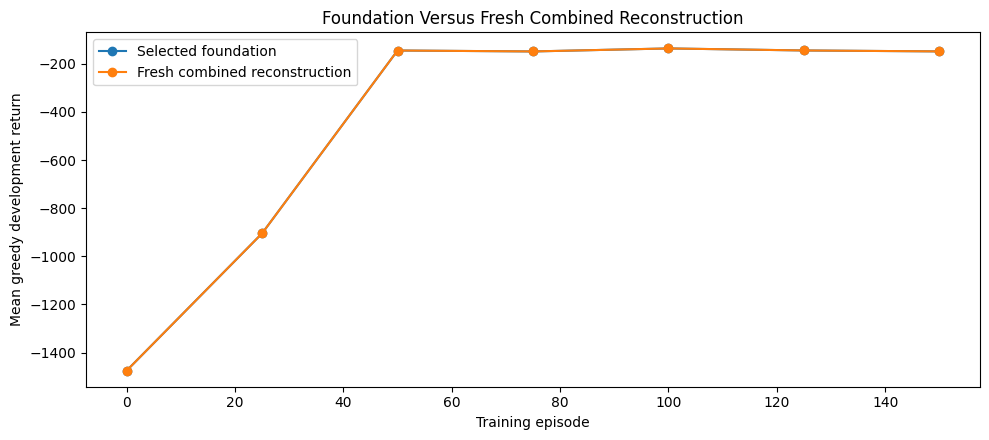

Combined-model run completed: True
Selected checkpoint episode: 100
Mean development return: -135.94219011424536
Development return standard deviation: 99.33824394123168
Combined-minus-foundation mean return: 0.0
Within practical improvement margin: True
Formal runs completed: 19
Remaining formal-run capacity: 9
Saved combined comparison: histories\R90_combined_vs_foundation.csv
Saved combined weights: selected_weights\R90_COMBINED_best.weights.h5
Section 15.2 fresh combined training: COMPLETE


In [79]:
R90_COMBINED_RUN_ID = "R90_COMBINED"
R90_COMBINED_SEED = 42

R90_COMBINED_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R90_COMBINED_RUN_ID}_best.weights.h5"
)
R90_COMBINED_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{R90_COMBINED_RUN_ID}_history.csv"
)
R90_COMBINED_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{R90_COMBINED_RUN_ID}"
        "_development_evaluations.csv"
    )
)
R90_COMBINED_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R90_COMBINED_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
R90_COMBINED_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R90_COMBINED_RUN_ID}_summary.csv"
)
R90_COMBINED_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{R90_COMBINED_RUN_ID}"
        "_selected_state_results.csv"
    )
)
R90_COMBINED_COMPARISON_PATH = (
    HISTORIES_DIR
    / "R90_combined_vs_foundation.csv"
)
R90_COMBINED_PAIRED_PATH = (
    HISTORIES_DIR
    / "R90_combined_vs_foundation_paired_states.csv"
)

assert (
    foundation_selection_record["selection_status"]
    == "LOCKED FOR DIAGNOSIS"
)
assert SELECTED_FOUNDATION_NAME == "Dueling DQN"
assert SELECTED_FOUNDATION_RUN_ID == R42_RUN_ID
assert EXPLORATION_SELECTION_LOCKED is True
assert SELECTED_EXPLORATION_RECIPE == "moderate_decay"
assert REPLAY_TARGET_SELECTION_LOCKED is True
assert SELECTED_REPLAY_TARGET_RECIPE == "reference"
assert OPTIMISATION_STABILITY_SELECTION_LOCKED is True
assert SELECTED_GAMMA == 0.99
assert CONDITIONAL_IMPROVEMENT_SELECTION_LOCKED is True
assert SELECTED_STATE_SCALING == "none"
assert R90_COMBINED_SEED == FOUNDATION_SCREEN_SEED
assert FORMAL_RUNS_COMPLETED in (18, 19)
assert remaining_formal_run_capacity in (10, 9)

r90_combined_required_artifacts = [
    R90_COMBINED_WEIGHT_PATH,
    R90_COMBINED_HISTORY_PATH,
    R90_COMBINED_EVALUATION_PATH,
    R90_COMBINED_EVALUATION_SUMMARY_PATH,
    R90_COMBINED_SUMMARY_PATH,
    R90_COMBINED_STATE_RESULTS_PATH,
]
r90_combined_artifacts_complete = all(
    path.exists()
    for path in r90_combined_required_artifacts
)

if (
    "r90_combined_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "r90_combined_history",
            "r90_combined_evaluation_states",
            "r90_combined_evaluation_summary",
            "r90_combined_selected_state_results",
            "r90_combined_summary",
        ]
    )
):
    print(
        "Combined-model result already exists in memory; "
        "no duplicate training run was started."
    )
elif r90_combined_artifacts_complete:
    r90_combined_history = read_csv_with_control_metric_migration(
        R90_COMBINED_HISTORY_PATH
    )
    r90_combined_evaluation_states = read_csv_with_control_metric_migration(
        R90_COMBINED_EVALUATION_PATH
    )
    r90_combined_evaluation_summary = read_csv_with_control_metric_migration(
        R90_COMBINED_EVALUATION_SUMMARY_PATH
    )
    r90_combined_summary = read_csv_with_control_metric_migration(
        R90_COMBINED_SUMMARY_PATH
    )
    r90_combined_selected_state_results = read_csv_with_control_metric_migration(
        R90_COMBINED_STATE_RESULTS_PATH
    )

    assert len(r90_combined_summary) == 1
    r90_combined_summary_record = (
        r90_combined_summary.iloc[0].to_dict()
    )
    r90_combined_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FOUNDATION_SCREEN_ACTION_COUNT,
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r90_combined_reloaded_q_network"
            ),
        )
    )
    r90_combined_selected_model.load_weights(
        R90_COMBINED_WEIGHT_PATH
    )
    print(
        "Loaded completed combined-model artifacts; "
        "no duplicate training run was started."
    )
else:
    r90_combined_result = (
        run_dueling_dqn_foundation(
            run_id=R90_COMBINED_RUN_ID,
            torque_values=(
                FOUNDATION_SCREEN_TORQUE_VALUES
            ),
            seed=R90_COMBINED_SEED,
            weight_path=R90_COMBINED_WEIGHT_PATH,
        )
    )

    r90_combined_history = (
        r90_combined_result["history"]
    )
    r90_combined_evaluation_states = (
        r90_combined_result[
            "evaluation_states"
        ]
    )
    r90_combined_evaluation_summary = (
        r90_combined_result[
            "evaluation_summary"
        ]
    )
    r90_combined_selected_state_results = (
        r90_combined_result[
            "selected_state_results"
        ]
    )
    r90_combined_selected_model = (
        r90_combined_result[
            "selected_model"
        ]
    )
    r90_combined_summary_record = dict(
        r90_combined_result[
            "summary_record"
        ]
    )
    r90_combined_summary_record.update({
        "combined_configuration": True,
        "architecture": "Dueling DQN",
        "state_representation": (
            SELECTED_STATE_REPRESENTATION
        ),
        "exploration_recipe": (
            SELECTED_EXPLORATION_RECIPE
        ),
        "replay_target_recipe": (
            SELECTED_REPLAY_TARGET_RECIPE
        ),
        "optimisation_recipe": (
            SELECTED_OPTIMISATION_STABILITY_RECIPE
        ),
        "reference_run_id": R42_RUN_ID,
    })
    r90_combined_summary = pd.DataFrame(
        [r90_combined_summary_record]
    )

FORMAL_RUNS_COMPLETED = 19
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 19
assert remaining_formal_run_capacity == 9
assert len(r90_combined_history) == 150
assert len(r90_combined_evaluation_summary) == 7
assert int(
    r90_combined_summary_record["seed"]
) == 42
assert (
    r90_combined_summary_record["model"]
    == "Dueling DQN"
)
assert int(
    r90_combined_summary_record["action_count"]
) == 7
assert int(
    r90_combined_summary_record["parameter_count"]
) == 4936
assert int(
    r90_combined_summary_record[
        "environment_steps"
    ]
) == 30_000
assert int(
    r90_combined_summary_record[
        "optimizer_updates"
    ]
) == 29_001
assert int(
    r90_combined_summary_record[
        "target_updates"
    ]
) == 116
assert np.isfinite(
    r90_combined_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert R90_COMBINED_WEIGHT_PATH.exists()

r90_combined_history.to_csv(
    R90_COMBINED_HISTORY_PATH,
    index=False,
)
r90_combined_evaluation_states.to_csv(
    R90_COMBINED_EVALUATION_PATH,
    index=False,
)
r90_combined_evaluation_summary.to_csv(
    R90_COMBINED_EVALUATION_SUMMARY_PATH,
    index=False,
)
r90_combined_summary.to_csv(
    R90_COMBINED_SUMMARY_PATH,
    index=False,
)
r90_combined_selected_state_results.to_csv(
    R90_COMBINED_STATE_RESULTS_PATH,
    index=False,
)

foundation_states = (
    r42_selected_state_results
    [["state_id", "return"]]
    .rename(
        columns={
            "return": "foundation_return"
        }
    )
    .sort_values("state_id")
    .reset_index(drop=True)
)
combined_states = (
    r90_combined_selected_state_results
    [["state_id", "return"]]
    .rename(
        columns={
            "return": "combined_return"
        }
    )
    .sort_values("state_id")
    .reset_index(drop=True)
)

r90_combined_paired = foundation_states.merge(
    combined_states,
    on="state_id",
    how="inner",
    validate="one_to_one",
)
assert len(r90_combined_paired) == len(
    DEVELOPMENT_PHYSICAL_STATES
)

r90_combined_paired[
    "combined_minus_foundation"
] = (
    r90_combined_paired["combined_return"]
    - r90_combined_paired["foundation_return"]
)

combined_minus_foundation = float(
    r90_combined_summary_record[
        "mean_development_return"
    ]
    - r42_summary_record[
        "mean_development_return"
    ]
)

np.testing.assert_allclose(
    combined_minus_foundation,
    r90_combined_paired[
        "combined_minus_foundation"
    ].mean(),
    rtol=0.0,
    atol=1e-6,
)

r90_combined_comparison_record = {
    "reference_run_id": R42_RUN_ID,
    "candidate_run_id": R90_COMBINED_RUN_ID,
    "seed": 42,
    "foundation_mean_return": float(
        r42_summary_record[
            "mean_development_return"
        ]
    ),
    "combined_mean_return": float(
        r90_combined_summary_record[
            "mean_development_return"
        ]
    ),
    "combined_minus_foundation": (
        combined_minus_foundation
    ),
    "within_practical_margin": bool(
        abs(combined_minus_foundation)
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "foundation_state_std": float(
        r42_summary_record[
            "development_return_std"
        ]
    ),
    "combined_state_std": float(
        r90_combined_summary_record[
            "development_return_std"
        ]
    ),
    "foundation_upright_fraction": float(
        r42_summary_record[
            "upright_fraction"
        ]
    ),
    "combined_upright_fraction": float(
        r90_combined_summary_record[
            "upright_fraction"
        ]
    ),
    "combined_paired_win_proportion": float(
        (
            r90_combined_paired[
                "combined_minus_foundation"
            ] > 0.0
        ).mean()
    ),
    "foundation_paired_win_proportion": float(
        (
            r90_combined_paired[
                "combined_minus_foundation"
            ] < 0.0
        ).mean()
    ),
    "paired_median_difference": float(
        r90_combined_paired[
            "combined_minus_foundation"
        ].median()
    ),
    "selection_deferred_until_review": True,
    "formal_significance_claim": False,
}

r90_combined_comparison = pd.DataFrame(
    [r90_combined_comparison_record]
)

r90_combined_comparison.to_csv(
    R90_COMBINED_COMPARISON_PATH,
    index=False,
)
r90_combined_paired.to_csv(
    R90_COMBINED_PAIRED_PATH,
    index=False,
)

display(r90_combined_comparison)
display(r90_combined_evaluation_summary)
display(r90_combined_summary)

plt.figure(figsize=(10, 4.5))
plt.plot(
    r42_evaluation_summary["episode"],
    r42_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Selected foundation",
)
plt.plot(
    r90_combined_evaluation_summary["episode"],
    r90_combined_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Fresh combined reconstruction",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("Foundation Versus Fresh Combined Reconstruction")
plt.legend()
plt.tight_layout()
plt.show()

print("Combined-model run completed:", True)
print(
    "Selected checkpoint episode:",
    r90_combined_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    r90_combined_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    r90_combined_summary_record[
        "development_return_std"
    ],
)
print(
    "Combined-minus-foundation mean return:",
    combined_minus_foundation,
)
print(
    "Within practical improvement margin:",
    r90_combined_comparison_record[
        "within_practical_margin"
    ],
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved combined comparison:",
    R90_COMBINED_COMPARISON_PATH,
)
print(
    "Saved combined weights:",
    R90_COMBINED_WEIGHT_PATH,
)
print("Section 15.2 fresh combined training: COMPLETE")


### 15.2 Result Interpretation

**Finding.** The fresh combined reconstruction completed all `150` episodes
without technical failure.

Its selected checkpoint was episode `100`, with:

- mean development return: `-135.942190`;
- development-state standard deviation: `99.338244`;
- upright fraction: `0.872292`;
- combined-minus-foundation return: `0.000000`.

The complete evaluation progression, selected-state results and checkpoint
metrics reproduce the selected `R42_DUELING` foundation result exactly.

**Importance.** This equality is expected because every retained decision
already formed the selected foundation configuration. The new run therefore
provides a fresh reconstruction and reproducibility check, not evidence of an
additional performance improvement.

**Decision.** Retain the combined configuration as the final development
candidate, but make no claim that `R90_COMBINED` improves on
`R42_DUELING`.

**Caveat.** Exact agreement here is supported by matched deterministic seed
control. Final reliability still requires the protected three-seed
confirmation programme.

**Next step.** Lock the combined-model decision, then ablate the Dueling head
while preserving every other retained setting.


## 15.3 Combined Evaluation

The fresh reconstruction is evaluated using the same fixed development states
and greedy checkpoint rule as the selected foundation.

## 15.4 Foundation Versus Combined Comparison

Because the retained recipes do not change the original selected Dueling
configuration, the main question is reproducibility:

> Can a fresh reconstruction of the complete retained configuration reproduce
> the selected foundation result under the same seed?

A zero paired difference is therefore valid evidence of reproducibility, not
a new improvement.

## 15.5 Combined-Model Decision

The complete retained configuration becomes the final development candidate.
A separate seed-`123` combined reconstruction is not activated because the
same configuration has already been evaluated under foundation seeds `42`
and `123`, and three fresh final-confirmation seeds remain protected.


In [80]:
COMBINED_MODEL_SELECTION_PATH = (
    HISTORIES_DIR
    / "R90_combined_model_selection.csv"
)

combined_history_comparison_columns = [
    "episode",
    "environment_steps",
    "optimizer_updates",
    "training_return",
    "epsilon",
    "mean_loss",
    "mean_gradient_global_norm",
    "mean_q",
    "max_q",
    "random_actions",
    "greedy_actions",
    "target_updates",
    "replay_size",
    "moving_average_return",
    "evaluation_return",
]

assert all(
    column in r42_history.columns
    for column in combined_history_comparison_columns
)
assert all(
    column in r90_combined_history.columns
    for column in combined_history_comparison_columns
)

np.testing.assert_allclose(
    r90_combined_history[
        combined_history_comparison_columns
    ].to_numpy(dtype=np.float64),
    r42_history[
        combined_history_comparison_columns
    ].to_numpy(dtype=np.float64),
    rtol=0.0,
    atol=1e-10,
    equal_nan=True,
)

combined_evaluation_columns = [
    column
    for column in r42_evaluation_summary.columns
    if column in r90_combined_evaluation_summary.columns
]

np.testing.assert_allclose(
    r90_combined_evaluation_summary[
        combined_evaluation_columns
    ].to_numpy(dtype=np.float64),
    r42_evaluation_summary[
        combined_evaluation_columns
    ].to_numpy(dtype=np.float64),
    rtol=0.0,
    atol=1e-10,
)

combined_state_metric_columns = [
    "return",
    "upright_fraction",
    "mean_abs_angle",
    "mean_abs_angular_velocity",
    "mean_abs_torque",
    "torque_direction_switching_rate",
]

assert all(
    column in r42_selected_state_results.columns
    for column in combined_state_metric_columns
)
assert all(
    column in r90_combined_selected_state_results.columns
    for column in combined_state_metric_columns
)

foundation_selected_states_sorted = (
    r42_selected_state_results
    .sort_values("state_id")
    .reset_index(drop=True)
)
combined_selected_states_sorted = (
    r90_combined_selected_state_results
    .sort_values("state_id")
    .reset_index(drop=True)
)

assert foundation_selected_states_sorted[
    "state_id"
].tolist() == combined_selected_states_sorted[
    "state_id"
].tolist()

np.testing.assert_allclose(
    combined_selected_states_sorted[
        combined_state_metric_columns
    ].to_numpy(dtype=np.float64),
    foundation_selected_states_sorted[
        combined_state_metric_columns
    ].to_numpy(dtype=np.float64),
    rtol=0.0,
    atol=1e-10,
)

assert np.allclose(
    r90_combined_paired[
        "combined_minus_foundation"
    ].to_numpy(dtype=np.float64),
    0.0,
    rtol=0.0,
    atol=1e-10,
)

SELECTED_COMBINED_RUN_ID = R90_COMBINED_RUN_ID
SELECTED_COMBINED_WEIGHT_PATH = (
    R90_COMBINED_WEIGHT_PATH
)
SELECTED_FINAL_DEVELOPMENT_CONFIGURATION = {
    "architecture": "Dueling DQN",
    "hidden_units": [64, 64],
    "action_count": 7,
    "torque_values": (
        FOUNDATION_SCREEN_TORQUE_VALUES.tolist()
    ),
    "state_representation": (
        SELECTED_STATE_REPRESENTATION
    ),
    "exploration_recipe": (
        SELECTED_EXPLORATION_RECIPE
    ),
    "replay_target_recipe": (
        SELECTED_REPLAY_TARGET_RECIPE
    ),
    "optimisation_recipe": (
        SELECTED_OPTIMISATION_STABILITY_RECIPE
    ),
    "gamma": SELECTED_GAMMA,
    "training_episodes": 150,
    "environment_steps": 30_000,
    "gravity": "default",
}

COMBINED_RECONSTRUCTION_REPRODUCIBLE = True
COMBINED_PERFORMANCE_IMPROVEMENT_CLAIM = False
COMBINED_SECOND_DEVELOPMENT_SEED_APPROVED = False
COMBINED_MODEL_SELECTION_LOCKED = True

combined_model_selection_record = {
    "selected_run_id": SELECTED_COMBINED_RUN_ID,
    "reference_run_id": R42_RUN_ID,
    "selected_checkpoint_episode": int(
        r90_combined_summary_record[
            "selected_checkpoint_episode"
        ]
    ),
    "mean_development_return": float(
        r90_combined_summary_record[
            "mean_development_return"
        ]
    ),
    "development_return_std": float(
        r90_combined_summary_record[
            "development_return_std"
        ]
    ),
    "upright_fraction": float(
        r90_combined_summary_record[
            "upright_fraction"
        ]
    ),
    "combined_minus_foundation": float(
        combined_minus_foundation
    ),
    "history_reproduced": True,
    "evaluation_progression_reproduced": True,
    "selected_state_metrics_reproduced": True,
    "fresh_reconstruction_reproducible": (
        COMBINED_RECONSTRUCTION_REPRODUCIBLE
    ),
    "performance_improvement_claim": (
        COMBINED_PERFORMANCE_IMPROVEMENT_CLAIM
    ),
    "second_development_seed_approved": (
        COMBINED_SECOND_DEVELOPMENT_SEED_APPROVED
    ),
    "final_confirmation_seeds_still_required": 3,
    "selection_status": "LOCKED FOR ABLATION",
    "formal_significance_claim": False,
}

combined_model_selection_summary = pd.DataFrame(
    [combined_model_selection_record]
)

assert SELECTED_COMBINED_RUN_ID == "R90_COMBINED"
assert COMBINED_RECONSTRUCTION_REPRODUCIBLE is True
assert (
    COMBINED_PERFORMANCE_IMPROVEMENT_CLAIM
    is False
)
assert (
    COMBINED_SECOND_DEVELOPMENT_SEED_APPROVED
    is False
)
assert COMBINED_MODEL_SELECTION_LOCKED is True
assert FORMAL_RUNS_COMPLETED == 19
assert remaining_formal_run_capacity == 9

combined_model_selection_summary.to_csv(
    COMBINED_MODEL_SELECTION_PATH,
    index=False,
)

display(combined_model_selection_summary)

print(
    "Selected combined run:",
    SELECTED_COMBINED_RUN_ID,
)
print(
    "Combined-minus-foundation mean return:",
    combined_minus_foundation,
)
print(
    "Training history reproduced:",
    True,
)
print(
    "Evaluation progression reproduced:",
    True,
)
print(
    "Selected-state metrics reproduced:",
    True,
)
print(
    "Performance improvement claimed:",
    COMBINED_PERFORMANCE_IMPROVEMENT_CLAIM,
)
print(
    "Second development seed approved:",
    COMBINED_SECOND_DEVELOPMENT_SEED_APPROVED,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved combined-model selection:",
    COMBINED_MODEL_SELECTION_PATH,
)
print("Section 15.3 combined evaluation: PASS")
print(
    "Section 15.4 foundation-combined comparison: PASS"
)
print("Section 15.5 combined-model decision: PASS")


,selected_run_id,reference_run_id,selected_checkpoint_episode,mean_development_return,development_return_std,upright_fraction,combined_minus_foundation,history_reproduced,evaluation_progression_reproduced,selected_state_metrics_reproduced,fresh_reconstruction_reproducible,performance_improvement_claim,second_development_seed_approved,final_confirmation_seeds_still_required,selection_status,formal_significance_claim
0,R90_COMBINED,R42_DUELING,100,-135.94219,99.338244,0.872292,0.0,True,True,True,True,False,False,3,LOCKED FOR ABLATION,False


Selected combined run: R90_COMBINED
Combined-minus-foundation mean return: 0.0
Training history reproduced: True
Evaluation progression reproduced: True
Selected-state metrics reproduced: True
Performance improvement claimed: False
Second development seed approved: False
Formal runs completed: 19
Remaining formal-run capacity: 9
Saved combined-model selection: histories\R90_combined_model_selection.csv
Section 15.3 combined evaluation: PASS
Section 15.4 foundation-combined comparison: PASS
Section 15.5 combined-model decision: PASS


# 16. Final Ablation

## 16.1 Ablation Selection Rule

The required ablation removes the most important retained model modification
while preserving every other final-development choice.

The selected modification is the Dueling head. The ablation therefore changes:

```text
Dueling Q-network
→ standard Vanilla Q-network
```

The two hidden layers remain `64, 64`; only the value-and-advantage
decomposition is removed.

## 16.2 Required Dueling-Head Ablation

Run ID:

```text
R91_ABLATION_DUELING_HEAD
```

**Reference:** `R90_COMBINED`.

**Controls:** raw state, seven-action torque set, moderate exploration,
replay capacity `10,000`, replay warm-up `1,000`, batch size `32`, hard target
update every `250` optimiser updates, Adam `0.001`, MSE, no clipping, gamma
`0.99`, default gravity, seed `42`, `150` episodes and the fixed development
states.

This consumes one formal-training slot. After completion, the formal-run
count should be `20`, leaving `8` runs.


Loaded completed Dueling-head ablation artifacts; no duplicate training run was started.


,reference_run_id,ablation_run_id,seed,ablated_component,combined_mean_return,ablation_mean_return,ablation_minus_combined,within_practical_margin,combined_state_std,ablation_state_std,combined_upright_fraction,ablation_upright_fraction,combined_parameter_count,ablation_parameter_count,ablation_paired_win_proportion,combined_paired_win_proportion,paired_median_difference,selection_deferred_until_review,formal_significance_claim
0,R90_COMBINED,R91_ABLATION_DUELING_HEAD,42,Dueling head,-135.94219,-139.818601,-3.876411,True,99.338244,101.098652,0.872292,0.872292,4936,4871,0.125,0.875,-2.114389,True,False


,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,0,-1518.751911,-1492.585927,101.846004,-1657.561553,-1355.582957,0.090625,1.555617,6.241910,1.933750,0.014028
1,25,-785.835574,-895.689118,307.812459,-990.044797,-0.396451,0.243125,1.111933,3.596739,1.232639,0.207077
2,50,-155.333161,-126.172512,121.596112,-410.382897,-1.203121,0.851250,0.314954,0.536214,0.537917,0.483040
3,75,-148.682473,-124.791925,110.552018,-350.667289,-2.142257,0.856458,0.318677,0.540127,0.879583,0.654732
4,100,-139.818601,-125.981895,101.098652,-348.037733,-2.403016,0.872292,0.303639,0.509886,0.642361,0.451214
5,125,-144.866809,-125.976659,110.099515,-369.561395,-1.869803,0.868958,0.295948,0.527784,1.135000,0.724246
6,150,-258.130784,-134.799724,412.345588,-1973.920880,-10.204726,0.789792,0.561632,0.668726,1.098056,0.720477


,run_id,source_run_id,reused_existing_run,new_training_run_consumed,model,gravity,seed,action_count,torque_values,episodes,...,parameter_count,weight_path,technical_status,ablation_component,ablation_change,reference_run_id,state_representation,exploration_recipe,replay_target_recipe,optimisation_recipe
0,R91_ABLATION_DUELING_HEAD,R91_ABLATION_DUELING_HEAD,False,True,Vanilla DQN,default,42,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,...,4871,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS,Dueling head,Dueling Q-network to standard Q-network,R90_COMBINED,"[cos(theta), sin(theta), theta_dot]",moderate_decay,reference,mse_gamma_0.99_no_clipping


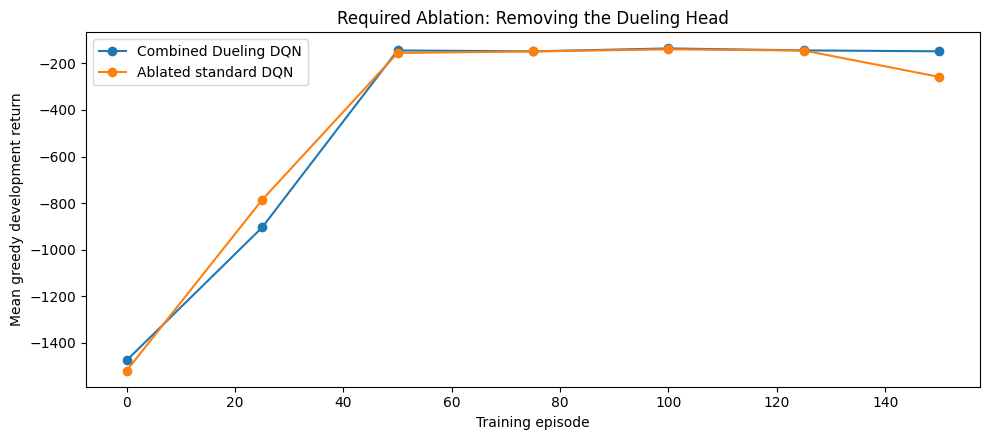

Dueling-head ablation completed: True
Selected checkpoint episode: 100
Ablation mean development return: -139.81860126694502
Combined mean development return: -135.94219011424536
Ablation-minus-combined mean return: -3.87641115269966
Ablation paired-state win proportion: 0.125
Within practical improvement margin: True
Formal runs completed: 20
Remaining formal-run capacity: 8
Saved ablation comparison: histories\R91_dueling_head_ablation_comparison.csv
Saved ablation weights: selected_weights\R91_ABLATION_DUELING_HEAD_best.weights.h5
Section 16.2 required ablation: COMPLETE


In [81]:
R91_ABLATION_RUN_ID = (
    "R91_ABLATION_DUELING_HEAD"
)
R91_ABLATION_SEED = 42

R91_ABLATION_WEIGHT_PATH = (
    SELECTED_WEIGHTS_DIR
    / f"{R91_ABLATION_RUN_ID}_best.weights.h5"
)
R91_ABLATION_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{R91_ABLATION_RUN_ID}_history.csv"
)
R91_ABLATION_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{R91_ABLATION_RUN_ID}"
        "_development_evaluations.csv"
    )
)
R91_ABLATION_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{R91_ABLATION_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
R91_ABLATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{R91_ABLATION_RUN_ID}_summary.csv"
)
R91_ABLATION_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{R91_ABLATION_RUN_ID}"
        "_selected_state_results.csv"
    )
)
R91_ABLATION_COMPARISON_PATH = (
    HISTORIES_DIR
    / "R91_dueling_head_ablation_comparison.csv"
)
R91_ABLATION_PAIRED_PATH = (
    HISTORIES_DIR
    / "R91_dueling_head_ablation_paired_states.csv"
)

assert COMBINED_MODEL_SELECTION_LOCKED is True
assert SELECTED_COMBINED_RUN_ID == "R90_COMBINED"
assert SELECTED_FOUNDATION_NAME == "Dueling DQN"
assert SELECTED_EXPLORATION_RECIPE == "moderate_decay"
assert SELECTED_REPLAY_TARGET_RECIPE == "reference"
assert SELECTED_OPTIMISATION_STABILITY_RECIPE == (
    "mse_gamma_0.99_no_clipping"
)
assert SELECTED_STATE_SCALING == "none"
assert R91_ABLATION_SEED == 42
assert FORMAL_RUNS_COMPLETED in (19, 20)
assert remaining_formal_run_capacity in (9, 8)

r91_ablation_required_artifacts = [
    R91_ABLATION_WEIGHT_PATH,
    R91_ABLATION_HISTORY_PATH,
    R91_ABLATION_EVALUATION_PATH,
    R91_ABLATION_EVALUATION_SUMMARY_PATH,
    R91_ABLATION_SUMMARY_PATH,
    R91_ABLATION_STATE_RESULTS_PATH,
]
r91_ablation_artifacts_complete = all(
    path.exists()
    for path in r91_ablation_required_artifacts
)

if (
    "r91_ablation_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "r91_ablation_history",
            "r91_ablation_evaluation_states",
            "r91_ablation_evaluation_summary",
            "r91_ablation_selected_state_results",
            "r91_ablation_summary",
        ]
    )
):
    print(
        "Dueling-head ablation already exists in memory; "
        "no duplicate training run was started."
    )
elif r91_ablation_artifacts_complete:
    r91_ablation_history = read_csv_with_control_metric_migration(
        R91_ABLATION_HISTORY_PATH
    )
    r91_ablation_evaluation_states = read_csv_with_control_metric_migration(
        R91_ABLATION_EVALUATION_PATH
    )
    r91_ablation_evaluation_summary = read_csv_with_control_metric_migration(
        R91_ABLATION_EVALUATION_SUMMARY_PATH
    )
    r91_ablation_summary = read_csv_with_control_metric_migration(
        R91_ABLATION_SUMMARY_PATH
    )
    r91_ablation_selected_state_results = read_csv_with_control_metric_migration(
        R91_ABLATION_STATE_RESULTS_PATH
    )

    assert len(r91_ablation_summary) == 1
    r91_ablation_summary_record = (
        r91_ablation_summary.iloc[0].to_dict()
    )
    r91_ablation_selected_model = (
        build_standard_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=(
                FOUNDATION_SCREEN_ACTION_COUNT
            ),
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                "r91_ablation_reloaded_q_network"
            ),
        )
    )
    r91_ablation_selected_model.load_weights(
        R91_ABLATION_WEIGHT_PATH
    )
    print(
        "Loaded completed Dueling-head ablation artifacts; "
        "no duplicate training run was started."
    )
else:
    r91_ablation_result = (
        run_vanilla_action_comparison(
            run_id=R91_ABLATION_RUN_ID,
            torque_values=(
                FOUNDATION_SCREEN_TORQUE_VALUES
            ),
            seed=R91_ABLATION_SEED,
            weight_path=R91_ABLATION_WEIGHT_PATH,
        )
    )

    r91_ablation_history = (
        r91_ablation_result["history"]
    )
    r91_ablation_evaluation_states = (
        r91_ablation_result[
            "evaluation_states"
        ]
    )
    r91_ablation_evaluation_summary = (
        r91_ablation_result[
            "evaluation_summary"
        ]
    )
    r91_ablation_selected_state_results = (
        r91_ablation_result[
            "selected_state_results"
        ]
    )
    r91_ablation_selected_model = (
        r91_ablation_result[
            "selected_model"
        ]
    )
    r91_ablation_summary_record = dict(
        r91_ablation_result[
            "summary_record"
        ]
    )
    r91_ablation_summary_record.update({
        "ablation_component": "Dueling head",
        "ablation_change": (
            "Dueling Q-network to standard Q-network"
        ),
        "reference_run_id": R90_COMBINED_RUN_ID,
        "state_representation": (
            SELECTED_STATE_REPRESENTATION
        ),
        "exploration_recipe": (
            SELECTED_EXPLORATION_RECIPE
        ),
        "replay_target_recipe": (
            SELECTED_REPLAY_TARGET_RECIPE
        ),
        "optimisation_recipe": (
            SELECTED_OPTIMISATION_STABILITY_RECIPE
        ),
    })
    r91_ablation_summary = pd.DataFrame(
        [r91_ablation_summary_record]
    )

FORMAL_RUNS_COMPLETED = 20
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 20
assert remaining_formal_run_capacity == 8
assert len(r91_ablation_history) == 150
assert len(r91_ablation_evaluation_summary) == 7
assert int(
    r91_ablation_summary_record["seed"]
) == 42
assert (
    r91_ablation_summary_record["model"]
    == "Vanilla DQN"
)
assert int(
    r91_ablation_summary_record["action_count"]
) == 7
assert int(
    r91_ablation_summary_record["parameter_count"]
) == 4871
assert int(
    r91_ablation_summary_record[
        "environment_steps"
    ]
) == 30_000
assert int(
    r91_ablation_summary_record[
        "optimizer_updates"
    ]
) == 29_001
assert int(
    r91_ablation_summary_record[
        "target_updates"
    ]
) == 116
assert np.isfinite(
    r91_ablation_selected_state_results[
        "return"
    ].to_numpy(dtype=np.float64)
).all()
assert R91_ABLATION_WEIGHT_PATH.exists()

r91_ablation_history.to_csv(
    R91_ABLATION_HISTORY_PATH,
    index=False,
)
r91_ablation_evaluation_states.to_csv(
    R91_ABLATION_EVALUATION_PATH,
    index=False,
)
r91_ablation_evaluation_summary.to_csv(
    R91_ABLATION_EVALUATION_SUMMARY_PATH,
    index=False,
)
r91_ablation_summary.to_csv(
    R91_ABLATION_SUMMARY_PATH,
    index=False,
)
r91_ablation_selected_state_results.to_csv(
    R91_ABLATION_STATE_RESULTS_PATH,
    index=False,
)

combined_states = (
    r90_combined_selected_state_results
    [["state_id", "return"]]
    .rename(
        columns={
            "return": "combined_return"
        }
    )
    .sort_values("state_id")
    .reset_index(drop=True)
)
ablation_states = (
    r91_ablation_selected_state_results
    [["state_id", "return"]]
    .rename(
        columns={
            "return": "ablation_return"
        }
    )
    .sort_values("state_id")
    .reset_index(drop=True)
)

r91_ablation_paired = combined_states.merge(
    ablation_states,
    on="state_id",
    how="inner",
    validate="one_to_one",
)
assert len(r91_ablation_paired) == len(
    DEVELOPMENT_PHYSICAL_STATES
)

r91_ablation_paired[
    "ablation_minus_combined"
] = (
    r91_ablation_paired["ablation_return"]
    - r91_ablation_paired["combined_return"]
)

ablation_minus_combined = float(
    r91_ablation_summary_record[
        "mean_development_return"
    ]
    - r90_combined_summary_record[
        "mean_development_return"
    ]
)

np.testing.assert_allclose(
    ablation_minus_combined,
    r91_ablation_paired[
        "ablation_minus_combined"
    ].mean(),
    rtol=0.0,
    atol=1e-6,
)

r91_ablation_comparison_record = {
    "reference_run_id": R90_COMBINED_RUN_ID,
    "ablation_run_id": R91_ABLATION_RUN_ID,
    "seed": 42,
    "ablated_component": "Dueling head",
    "combined_mean_return": float(
        r90_combined_summary_record[
            "mean_development_return"
        ]
    ),
    "ablation_mean_return": float(
        r91_ablation_summary_record[
            "mean_development_return"
        ]
    ),
    "ablation_minus_combined": (
        ablation_minus_combined
    ),
    "within_practical_margin": bool(
        abs(ablation_minus_combined)
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "combined_state_std": float(
        r90_combined_summary_record[
            "development_return_std"
        ]
    ),
    "ablation_state_std": float(
        r91_ablation_summary_record[
            "development_return_std"
        ]
    ),
    "combined_upright_fraction": float(
        r90_combined_summary_record[
            "upright_fraction"
        ]
    ),
    "ablation_upright_fraction": float(
        r91_ablation_summary_record[
            "upright_fraction"
        ]
    ),
    "combined_parameter_count": int(
        r90_combined_summary_record[
            "parameter_count"
        ]
    ),
    "ablation_parameter_count": int(
        r91_ablation_summary_record[
            "parameter_count"
        ]
    ),
    "ablation_paired_win_proportion": float(
        (
            r91_ablation_paired[
                "ablation_minus_combined"
            ] > 0.0
        ).mean()
    ),
    "combined_paired_win_proportion": float(
        (
            r91_ablation_paired[
                "ablation_minus_combined"
            ] < 0.0
        ).mean()
    ),
    "paired_median_difference": float(
        r91_ablation_paired[
            "ablation_minus_combined"
        ].median()
    ),
    "selection_deferred_until_review": True,
    "formal_significance_claim": False,
}

r91_ablation_comparison = pd.DataFrame(
    [r91_ablation_comparison_record]
)

r91_ablation_comparison.to_csv(
    R91_ABLATION_COMPARISON_PATH,
    index=False,
)
r91_ablation_paired.to_csv(
    R91_ABLATION_PAIRED_PATH,
    index=False,
)

display(r91_ablation_comparison)
display(r91_ablation_evaluation_summary)
display(r91_ablation_summary)

plt.figure(figsize=(10, 4.5))
plt.plot(
    r90_combined_evaluation_summary["episode"],
    r90_combined_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Combined Dueling DQN",
)
plt.plot(
    r91_ablation_evaluation_summary["episode"],
    r91_ablation_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
    label="Ablated standard DQN",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("Required Ablation: Removing the Dueling Head")
plt.legend()
plt.tight_layout()
plt.show()

print("Dueling-head ablation completed:", True)
print(
    "Selected checkpoint episode:",
    r91_ablation_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Ablation mean development return:",
    r91_ablation_summary_record[
        "mean_development_return"
    ],
)
print(
    "Combined mean development return:",
    r90_combined_summary_record[
        "mean_development_return"
    ],
)
print(
    "Ablation-minus-combined mean return:",
    ablation_minus_combined,
)
print(
    "Ablation paired-state win proportion:",
    r91_ablation_comparison_record[
        "ablation_paired_win_proportion"
    ],
)
print(
    "Within practical improvement margin:",
    r91_ablation_comparison_record[
        "within_practical_margin"
    ],
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved ablation comparison:",
    R91_ABLATION_COMPARISON_PATH,
)
print(
    "Saved ablation weights:",
    R91_ABLATION_WEIGHT_PATH,
)
print("Section 16.2 required ablation: COMPLETE")


### 16.2 Result Interpretation

**Finding.** Removing the Dueling head completed successfully and produced:

```text
Combined Dueling DQN: -135.942190
Ablated standard DQN: -139.818601
Ablation minus combined: -3.876411
```

The ablated model won only `12.5%` of the paired development states. It also
had a slightly larger state-wise return spread:

```text
Combined: 99.338244
Ablation: 101.098652
```

Both models achieved the same upright fraction of `0.872292`. The standard
network used `4,871` parameters, compared with `4,936` for the Dueling
network.

The ablated run deteriorated sharply at episode `150`, reaching
`-258.130784`, while its selected checkpoint remained episode `100`.

**Importance.** The fresh ablation supports the Dueling head because the
Dueling model achieved the stronger return and won most paired states while
adding only `65` parameters.

**Decision.** Retain the Dueling head, subject to the already available
matched seed-`123` architecture evidence.

**Caveat.** The seed-`42` difference is inside the practical margin, so the
ablation alone is not a formal significance claim.

**Next step.** Combine this fresh ablation with the existing matched
seed-`123` Vanilla-versus-Dueling evidence, then close the ablation stage.


## 16.3 Conditional Second Ablation

A second ablation is **not activated**.

The plan permits a second ablation only when it answers a separate unresolved
question. The required Dueling-head ablation already addresses the most
important retained model modification, and matched architecture evidence is
available under seeds `42` and `123`.

After the required ablation, eight formal-run slots remain. Seven are reserved
for the three fresh final-confirmation runs and four fresh gravity-specific
runs. The remaining one-run buffer is retained for genuine technical
contingency.

## 16.4 Ablation Interpretation

The fresh seed-`42` ablation is interpreted together with the existing matched
seed-`123` Vanilla-versus-Dueling comparison. This does not consume another
training run.


In [82]:
ABLATION_DECISION_PATH = (
    HISTORIES_DIR
    / "R91_dueling_head_ablation_decision.csv"
)

seed_42_foundation_row = (
    foundation_matched_confirmation.loc[
        foundation_matched_confirmation["seed"] == 42
    ].iloc[0]
)
seed_123_foundation_row = (
    foundation_matched_confirmation.loc[
        foundation_matched_confirmation["seed"] == 123
    ].iloc[0]
)

np.testing.assert_allclose(
    float(
        r91_ablation_summary_record[
            "mean_development_return"
        ]
    ),
    float(
        seed_42_foundation_row[
            "reference_mean_return"
        ]
    ),
    rtol=0.0,
    atol=1e-10,
)
np.testing.assert_allclose(
    float(
        r90_combined_summary_record[
            "mean_development_return"
        ]
    ),
    float(
        seed_42_foundation_row[
            "candidate_mean_return"
        ]
    ),
    rtol=0.0,
    atol=1e-10,
)

DUELING_HEAD_MATCHED_SEEDS = (42, 123)
DUELING_HEAD_ADVANTAGE_ACROSS_SEEDS = float(
    foundation_confirmation_aggregate_record[
        "candidate_minus_reference_across_seed_means"
    ]
)
DUELING_HEAD_SEED_WIN_COUNT = int(
    foundation_confirmation_aggregate_record[
        "candidate_seed_win_count"
    ]
)
VANILLA_HEAD_SEED_WIN_COUNT = int(
    foundation_confirmation_aggregate_record[
        "reference_seed_win_count"
    ]
)

dueling_average_state_std = float(
    foundation_matched_confirmation[
        "candidate_state_std"
    ].mean()
)
vanilla_average_state_std = float(
    foundation_matched_confirmation[
        "reference_state_std"
    ].mean()
)
dueling_average_paired_win_rate = float(
    foundation_matched_confirmation[
        "candidate_win_proportion"
    ].mean()
)
vanilla_average_paired_win_rate = float(
    foundation_matched_confirmation[
        "reference_win_proportion"
    ].mean()
)

DUELING_HEAD_RETAINED = True
SECOND_ABLATION_APPROVED = False
ABLATION_STAGE_LOCKED = True

ablation_decision_record = {
    "retained_component": "Dueling head",
    "fresh_ablation_run_id": R91_ABLATION_RUN_ID,
    "matched_seeds": list(
        DUELING_HEAD_MATCHED_SEEDS
    ),
    "seed_42_dueling_minus_vanilla": float(
        seed_42_foundation_row[
            "candidate_minus_reference"
        ]
    ),
    "seed_123_dueling_minus_vanilla": float(
        seed_123_foundation_row[
            "candidate_minus_reference"
        ]
    ),
    "dueling_minus_vanilla_across_seeds": (
        DUELING_HEAD_ADVANTAGE_ACROSS_SEEDS
    ),
    "difference_within_practical_margin": bool(
        abs(DUELING_HEAD_ADVANTAGE_ACROSS_SEEDS)
        <= PRACTICAL_IMPROVEMENT_MARGIN
    ),
    "dueling_seed_win_count": (
        DUELING_HEAD_SEED_WIN_COUNT
    ),
    "vanilla_seed_win_count": (
        VANILLA_HEAD_SEED_WIN_COUNT
    ),
    "dueling_average_state_std": (
        dueling_average_state_std
    ),
    "vanilla_average_state_std": (
        vanilla_average_state_std
    ),
    "dueling_average_paired_win_rate": (
        dueling_average_paired_win_rate
    ),
    "vanilla_average_paired_win_rate": (
        vanilla_average_paired_win_rate
    ),
    "dueling_parameter_count": 4936,
    "vanilla_parameter_count": 4871,
    "dueling_head_retained": DUELING_HEAD_RETAINED,
    "second_ablation_approved": (
        SECOND_ABLATION_APPROVED
    ),
    "formal_significance_claim": False,
    "selection_status": "LOCKED FOR FINAL CONFIRMATION",
}

ablation_decision_summary = pd.DataFrame(
    [ablation_decision_record]
)

assert DUELING_HEAD_MATCHED_SEEDS == (42, 123)
assert DUELING_HEAD_ADVANTAGE_ACROSS_SEEDS > 0.0
assert DUELING_HEAD_SEED_WIN_COUNT == 2
assert VANILLA_HEAD_SEED_WIN_COUNT == 0
assert dueling_average_state_std < (
    vanilla_average_state_std
)
assert dueling_average_paired_win_rate > (
    vanilla_average_paired_win_rate
)
assert DUELING_HEAD_RETAINED is True
assert SECOND_ABLATION_APPROVED is False
assert ABLATION_STAGE_LOCKED is True
assert FORMAL_RUNS_COMPLETED == 20
assert remaining_formal_run_capacity == 8

ablation_decision_summary.to_csv(
    ABLATION_DECISION_PATH,
    index=False,
)

display(ablation_decision_summary)

print(
    "Dueling-minus-Vanilla across matched seeds:",
    DUELING_HEAD_ADVANTAGE_ACROSS_SEEDS,
)
print(
    "Dueling seed win count:",
    DUELING_HEAD_SEED_WIN_COUNT,
)
print(
    "Average state-wise standard deviation, Dueling:",
    dueling_average_state_std,
)
print(
    "Average state-wise standard deviation, Vanilla:",
    vanilla_average_state_std,
)
print(
    "Average paired-state win rate, Dueling:",
    dueling_average_paired_win_rate,
)
print(
    "Dueling head retained:",
    DUELING_HEAD_RETAINED,
)
print(
    "Second ablation approved:",
    SECOND_ABLATION_APPROVED,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved ablation decision:",
    ABLATION_DECISION_PATH,
)
print("Section 16.3 second-ablation decision: PASS")
print("Section 16.4 ablation interpretation: PASS")


,retained_component,fresh_ablation_run_id,matched_seeds,seed_42_dueling_minus_vanilla,seed_123_dueling_minus_vanilla,dueling_minus_vanilla_across_seeds,difference_within_practical_margin,dueling_seed_win_count,vanilla_seed_win_count,dueling_average_state_std,vanilla_average_state_std,dueling_average_paired_win_rate,vanilla_average_paired_win_rate,dueling_parameter_count,vanilla_parameter_count,dueling_head_retained,second_ablation_approved,formal_significance_claim,selection_status
0,Dueling head,R91_ABLATION_DUELING_HEAD,"[42, 123]",3.876411,1.389487,2.632949,True,2,0,100.866287,101.809392,0.8125,0.1875,4936,4871,True,False,False,LOCKED FOR FINAL CONFIRMATION


Dueling-minus-Vanilla across matched seeds: 2.6329492311762124
Dueling seed win count: 2
Average state-wise standard deviation, Dueling: 100.86628720658445
Average state-wise standard deviation, Vanilla: 101.80939209844524
Average paired-state win rate, Dueling: 0.8125
Dueling head retained: True
Second ablation approved: False
Formal runs completed: 20
Remaining formal-run capacity: 8
Saved ablation decision: histories\R91_dueling_head_ablation_decision.csv
Section 16.3 second-ablation decision: PASS
Section 16.4 ablation interpretation: PASS


# 17. Default-Gravity Freeze

## 17.0 Pre-Freeze Final Confirmation

Before freezing the configuration, the selected default-gravity setup must be
trained under three fresh seeds.

The seeds are declared before execution:

```text
31415, 27182, 16180
```

They are distinct from all screening, calibration and foundation-confirmation
seeds used earlier.

Every run uses the locked configuration:

```text
Architecture: Dueling DQN
Hidden layers: 64, 64
Actions: 7 torques from -2 to 2
State: raw [cos(theta), sin(theta), theta_dot]
Exploration: moderate decay
Replay capacity: 10,000
Replay warm-up: 1,000
Batch size: 32
Hard target update: every 250 optimiser updates
Optimiser: Adam
Learning rate: 0.001
Loss: MSE
Gradient clipping: none
Gamma: 0.99
Training budget: 150 episodes and 30,000 steps
Gravity: default, g = 10
```

These runs measure final run-to-run reliability. They do not search for a
more favourable seed, and weak but technically valid results remain reported.

After the three runs, the formal-run count should be `23`, leaving `5` slots:
four protected gravity-specific runs and one contingency slot.


Loaded completed RF_DEFAULT_31415 artifacts; no duplicate training run was started.
Loaded completed RF_DEFAULT_27182 artifacts; no duplicate training run was started.
Loaded completed RF_DEFAULT_16180 artifacts; no duplicate training run was started.


,seed,run_id,selected_checkpoint_episode,mean_development_return,development_state_std,upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,torque_direction_switching_rate,selected_mean_q,selected_max_q,selected_min_q,first_episode_above_formal_reference,runtime_minutes,technical_status
0,16180,RF_DEFAULT_16180,125,-138.166628,101.546186,0.875000,0.237760,0.534091,1.158194,0.479690,-106.977455,13.909724,-255.355743,25,12.183638,PASS
1,27182,RF_DEFAULT_27182,50,-140.121455,104.662727,0.872292,0.234168,0.551188,1.532917,0.831030,-105.201843,11.111085,-201.233383,25,18.611161,PASS
2,31415,RF_DEFAULT_31415,100,-138.965574,103.626526,0.872708,0.230398,0.542735,1.415556,0.694933,-127.728355,13.031939,-268.067200,50,17.455912,PASS


,seeds,run_count,mean_seed_return,seed_return_std,minimum_seed_return,maximum_seed_return,seed_return_range,average_state_std,average_upright_fraction,technical_failure_count,all_seeds_above_formal_reference,formal_reference_target,selection_deferred_until_review,formal_significance_claim
0,"[31415, 27182, 16180]",3,-139.084552,0.982829,-140.121455,-138.166628,1.954826,103.278479,0.873333,0,True,-1211.262378,True,False


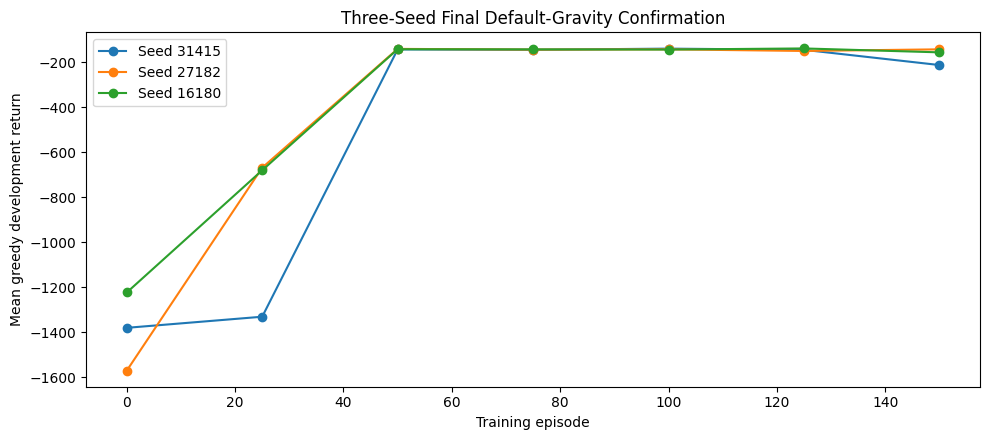

Final confirmation seeds: (31415, 27182, 16180)
Mean return across final-confirmation seeds: -139.08455235708496
Training-seed standard deviation: 0.982829319731913
Seed-level return range: 1.9548263870019866
Average state-wise standard deviation: 103.27847944658397
Average upright fraction: 0.8733333333333334
Technical failure count: 0
All seeds above formal reference: True
Formal runs completed: 23
Remaining formal-run capacity: 5
Saved final-confirmation summary: histories\RF_DEFAULT_final_confirmation_summary.csv
Saved final-confirmation aggregate: histories\RF_DEFAULT_final_confirmation_aggregate.csv
Section 17.0 pre-freeze final confirmation: COMPLETE


In [83]:
FINAL_CONFIRMATION_SEEDS = (
    31415,
    27182,
    16180,
)
FINAL_CONFIRMATION_RUN_IDS = tuple(
    f"RF_DEFAULT_{seed}"
    for seed in FINAL_CONFIRMATION_SEEDS
)

FINAL_CONFIRMATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / "RF_DEFAULT_final_confirmation_summary.csv"
)
FINAL_CONFIRMATION_AGGREGATE_PATH = (
    HISTORIES_DIR
    / "RF_DEFAULT_final_confirmation_aggregate.csv"
)

assert ABLATION_STAGE_LOCKED is True
assert DUELING_HEAD_RETAINED is True
assert COMBINED_MODEL_SELECTION_LOCKED is True
assert LOCKED_FINAL_CONFIRMATION_RUNS == 3
assert len(FINAL_CONFIRMATION_SEEDS) == 3
assert len(set(FINAL_CONFIRMATION_SEEDS)) == 3
assert set(FINAL_CONFIRMATION_SEEDS).isdisjoint({
    42,
    123,
    2026,
})
assert FORMAL_RUNS_COMPLETED in (20, 23)
assert remaining_formal_run_capacity in (8, 5)

final_confirmation_results = {}
final_confirmation_state_results = {}
final_confirmation_evaluation_summaries = {}
final_confirmation_selected_models = {}

for seed, run_id in zip(
    FINAL_CONFIRMATION_SEEDS,
    FINAL_CONFIRMATION_RUN_IDS,
):
    weight_path = (
        SELECTED_WEIGHTS_DIR
        / f"{run_id}_best.weights.h5"
    )
    history_path = (
        HISTORIES_DIR
        / f"{run_id}_history.csv"
    )
    evaluation_path = (
        HISTORIES_DIR
        / f"{run_id}_development_evaluations.csv"
    )
    evaluation_summary_path = (
        HISTORIES_DIR
        / (
            f"{run_id}"
            "_development_evaluation_summary.csv"
        )
    )
    summary_path = (
        HISTORIES_DIR
        / f"{run_id}_summary.csv"
    )
    state_results_path = (
        HISTORIES_DIR
        / f"{run_id}_selected_state_results.csv"
    )

    required_artifacts = [
        weight_path,
        history_path,
        evaluation_path,
        evaluation_summary_path,
        summary_path,
        state_results_path,
    ]
    artifacts_complete = all(
        path.exists()
        for path in required_artifacts
    )

    memory_key = (
        f"final_confirmation_{seed}_summary_record"
    )

    if (
        memory_key in globals()
        and all(
            name in globals()
            for name in [
                f"final_confirmation_{seed}_history",
                (
                    f"final_confirmation_{seed}"
                    "_evaluation_states"
                ),
                (
                    f"final_confirmation_{seed}"
                    "_evaluation_summary"
                ),
                (
                    f"final_confirmation_{seed}"
                    "_selected_state_results"
                ),
                f"final_confirmation_{seed}_summary",
            ]
        )
    ):
        history = globals()[
            f"final_confirmation_{seed}_history"
        ]
        evaluation_states = globals()[
            (
                f"final_confirmation_{seed}"
                "_evaluation_states"
            )
        ]
        evaluation_summary = globals()[
            (
                f"final_confirmation_{seed}"
                "_evaluation_summary"
            )
        ]
        selected_state_results = globals()[
            (
                f"final_confirmation_{seed}"
                "_selected_state_results"
            )
        ]
        summary = globals()[
            f"final_confirmation_{seed}_summary"
        ]
        summary_record = globals()[memory_key]
        selected_model = globals().get(
            f"final_confirmation_{seed}_selected_model"
        )
        print(
            f"{run_id} already exists in memory; "
            "no duplicate training run was started."
        )
    elif artifacts_complete:
        history = read_csv_with_control_metric_migration(history_path)
        evaluation_states = read_csv_with_control_metric_migration(
            evaluation_path
        )
        evaluation_summary = read_csv_with_control_metric_migration(
            evaluation_summary_path
        )
        summary = read_csv_with_control_metric_migration(summary_path)
        selected_state_results = read_csv_with_control_metric_migration(
            state_results_path
        )

        assert len(summary) == 1
        summary_record = (
            summary.iloc[0].to_dict()
        )

        selected_model = build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=(
                FOUNDATION_SCREEN_ACTION_COUNT
            ),
            hidden_units=STANDARD_HIDDEN_UNITS,
            model_name=(
                f"{run_id.lower()}_reloaded_q_network"
            ),
        )
        selected_model.load_weights(weight_path)

        print(
            f"Loaded completed {run_id} artifacts; "
            "no duplicate training run was started."
        )
    else:
        result = run_dueling_dqn_foundation(
            run_id=run_id,
            torque_values=(
                FOUNDATION_SCREEN_TORQUE_VALUES
            ),
            seed=int(seed),
            weight_path=weight_path,
        )

        history = result["history"]
        evaluation_states = result[
            "evaluation_states"
        ]
        evaluation_summary = result[
            "evaluation_summary"
        ]
        selected_state_results = result[
            "selected_state_results"
        ]
        selected_model = result[
            "selected_model"
        ]
        summary_record = dict(
            result["summary_record"]
        )
        summary_record.update({
            "stage": "final_confirmation",
            "configuration_run_id": (
                SELECTED_COMBINED_RUN_ID
            ),
            "state_representation": (
                SELECTED_STATE_REPRESENTATION
            ),
            "exploration_recipe": (
                SELECTED_EXPLORATION_RECIPE
            ),
            "replay_target_recipe": (
                SELECTED_REPLAY_TARGET_RECIPE
            ),
            "optimisation_recipe": (
                SELECTED_OPTIMISATION_STABILITY_RECIPE
            ),
        })
        summary = pd.DataFrame(
            [summary_record]
        )

    assert len(history) == 150
    assert len(evaluation_summary) == 7
    assert int(summary_record["seed"]) == int(seed)
    assert summary_record["model"] == "Dueling DQN"
    assert int(summary_record["action_count"]) == 7
    assert int(
        summary_record["parameter_count"]
    ) == 4936
    assert int(
        summary_record["environment_steps"]
    ) == 30_000
    assert int(
        summary_record["optimizer_updates"]
    ) == 29_001
    assert int(
        summary_record["target_updates"]
    ) == 116
    assert np.isfinite(
        selected_state_results[
            "return"
        ].to_numpy(dtype=np.float64)
    ).all()
    assert weight_path.exists()

    history.to_csv(
        history_path,
        index=False,
    )
    evaluation_states.to_csv(
        evaluation_path,
        index=False,
    )
    evaluation_summary.to_csv(
        evaluation_summary_path,
        index=False,
    )
    summary.to_csv(
        summary_path,
        index=False,
    )
    selected_state_results.to_csv(
        state_results_path,
        index=False,
    )

    globals()[
        f"final_confirmation_{seed}_history"
    ] = history
    globals()[
        (
            f"final_confirmation_{seed}"
            "_evaluation_states"
        )
    ] = evaluation_states
    globals()[
        (
            f"final_confirmation_{seed}"
            "_evaluation_summary"
        )
    ] = evaluation_summary
    globals()[
        (
            f"final_confirmation_{seed}"
            "_selected_state_results"
        )
    ] = selected_state_results
    globals()[
        f"final_confirmation_{seed}_summary"
    ] = summary
    globals()[memory_key] = summary_record
    globals()[
        f"final_confirmation_{seed}_selected_model"
    ] = selected_model

    final_confirmation_results[
        int(seed)
    ] = summary_record
    final_confirmation_state_results[
        int(seed)
    ] = selected_state_results.copy()
    final_confirmation_evaluation_summaries[
        int(seed)
    ] = evaluation_summary.copy()
    final_confirmation_selected_models[
        int(seed)
    ] = selected_model

FORMAL_RUNS_COMPLETED = 23
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

final_confirmation_records = []

for seed in FINAL_CONFIRMATION_SEEDS:
    record = final_confirmation_results[
        int(seed)
    ]
    evaluation_summary = (
        final_confirmation_evaluation_summaries[
            int(seed)
        ]
    )

    threshold_rows = evaluation_summary.loc[
        evaluation_summary[
            "mean_development_return"
        ] >= FORMAL_DEFAULT_REFERENCE_TARGET
    ]
    first_above_reference_episode = (
        int(threshold_rows["episode"].iloc[0])
        if len(threshold_rows) > 0
        else np.nan
    )

    final_confirmation_records.append({
        "seed": int(seed),
        "run_id": record["run_id"],
        "selected_checkpoint_episode": int(
            record["selected_checkpoint_episode"]
        ),
        "mean_development_return": float(
            record["mean_development_return"]
        ),
        "development_state_std": float(
            record["development_return_std"]
        ),
        "upright_fraction": float(
            record["upright_fraction"]
        ),
        "mean_abs_angle": float(
            record["mean_abs_angle"]
        ),
        "mean_abs_angular_velocity": float(
            record["mean_abs_angular_velocity"]
        ),
        "mean_abs_torque": float(
            record["mean_abs_torque"]
        ),
        "torque_direction_switching_rate": float(
            record["torque_direction_switching_rate"]
        ),
        "selected_mean_q": float(
            record["selected_mean_q"]
        ),
        "selected_max_q": float(
            record["selected_max_q"]
        ),
        "selected_min_q": float(
            record["selected_min_q"]
        ),
        "first_episode_above_formal_reference": (
            first_above_reference_episode
        ),
        "runtime_minutes": float(
            record["runtime_minutes"]
        ),
        "technical_status": (
            record["technical_status"]
        ),
    })

final_confirmation_summary = pd.DataFrame(
    final_confirmation_records
).sort_values("seed").reset_index(drop=True)

final_seed_returns = (
    final_confirmation_summary[
        "mean_development_return"
    ].to_numpy(dtype=np.float64)
)

final_confirmation_aggregate_record = {
    "seeds": list(FINAL_CONFIRMATION_SEEDS),
    "run_count": int(
        len(final_confirmation_summary)
    ),
    "mean_seed_return": float(
        np.mean(final_seed_returns)
    ),
    "seed_return_std": float(
        np.std(final_seed_returns, ddof=1)
    ),
    "minimum_seed_return": float(
        np.min(final_seed_returns)
    ),
    "maximum_seed_return": float(
        np.max(final_seed_returns)
    ),
    "seed_return_range": float(
        np.max(final_seed_returns)
        - np.min(final_seed_returns)
    ),
    "average_state_std": float(
        final_confirmation_summary[
            "development_state_std"
        ].mean()
    ),
    "average_upright_fraction": float(
        final_confirmation_summary[
            "upright_fraction"
        ].mean()
    ),
    "technical_failure_count": int(
        (
            final_confirmation_summary[
                "technical_status"
            ] != "PASS"
        ).sum()
    ),
    "all_seeds_above_formal_reference": bool(
        (
            final_confirmation_summary[
                "mean_development_return"
            ] > FORMAL_DEFAULT_REFERENCE_TARGET
        ).all()
    ),
    "formal_reference_target": float(
        FORMAL_DEFAULT_REFERENCE_TARGET
    ),
    "selection_deferred_until_review": True,
    "formal_significance_claim": False,
}

final_confirmation_aggregate = pd.DataFrame(
    [final_confirmation_aggregate_record]
)

assert FORMAL_RUNS_COMPLETED == 23
assert remaining_formal_run_capacity == 5
assert len(final_confirmation_summary) == 3
assert final_confirmation_summary[
    "seed"
].tolist() == sorted(
    FINAL_CONFIRMATION_SEEDS
)
assert (
    final_confirmation_summary[
        "technical_status"
    ] == "PASS"
).all()
assert np.isfinite(final_seed_returns).all()
assert np.isfinite(
    final_confirmation_aggregate
    .select_dtypes(include=[np.number])
    .to_numpy(dtype=np.float64)
).all()
assert (
    final_confirmation_aggregate_record[
        "technical_failure_count"
    ]
    == 0
)
assert (
    final_confirmation_aggregate_record[
        "selection_deferred_until_review"
    ]
    is True
)

final_confirmation_summary.to_csv(
    FINAL_CONFIRMATION_SUMMARY_PATH,
    index=False,
)
final_confirmation_aggregate.to_csv(
    FINAL_CONFIRMATION_AGGREGATE_PATH,
    index=False,
)

display(final_confirmation_summary)
display(final_confirmation_aggregate)

plt.figure(figsize=(10, 4.5))
for seed in FINAL_CONFIRMATION_SEEDS:
    evaluation_summary = (
        final_confirmation_evaluation_summaries[
            int(seed)
        ]
    )
    plt.plot(
        evaluation_summary["episode"],
        evaluation_summary[
            "mean_development_return"
        ],
        marker="o",
        label=f"Seed {seed}",
    )
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("Three-Seed Final Default-Gravity Confirmation")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Final confirmation seeds:",
    FINAL_CONFIRMATION_SEEDS,
)
print(
    "Mean return across final-confirmation seeds:",
    final_confirmation_aggregate_record[
        "mean_seed_return"
    ],
)
print(
    "Training-seed standard deviation:",
    final_confirmation_aggregate_record[
        "seed_return_std"
    ],
)
print(
    "Seed-level return range:",
    final_confirmation_aggregate_record[
        "seed_return_range"
    ],
)
print(
    "Average state-wise standard deviation:",
    final_confirmation_aggregate_record[
        "average_state_std"
    ],
)
print(
    "Average upright fraction:",
    final_confirmation_aggregate_record[
        "average_upright_fraction"
    ],
)
print(
    "Technical failure count:",
    final_confirmation_aggregate_record[
        "technical_failure_count"
    ],
)
print(
    "All seeds above formal reference:",
    final_confirmation_aggregate_record[
        "all_seeds_above_formal_reference"
    ],
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved final-confirmation summary:",
    FINAL_CONFIRMATION_SUMMARY_PATH,
)
print(
    "Saved final-confirmation aggregate:",
    FINAL_CONFIRMATION_AGGREGATE_PATH,
)
print(
    "Section 17.0 pre-freeze final confirmation: COMPLETE"
)


### 17.0 Result Interpretation

**Finding.** All three fresh final-confirmation runs completed without a
technical failure:

| Seed | Selected episode | Mean development return | State-wise standard deviation | Upright fraction |
|---|---:|---:|---:|---:|
| `16180` | `125` | `-138.166628` | `101.546186` | `0.875000` |
| `27182` | `50` | `-140.121455` | `104.662727` | `0.872292` |
| `31415` | `100` | `-138.965574` | `103.626526` | `0.872708` |

Across the three seeds:

```text
Mean seed-level return: -139.084552
Training-seed standard deviation: 0.982829
Seed-level return range: 1.954826
Average state-wise standard deviation: 103.278479
Average upright fraction: 0.873333
Technical failures: 0
```

The final-confirmation mean is `3.142362` points below the fresh combined
seed-`42` result, which remains inside the practical margin of `11.335072`.
The new seed-level range is also much smaller than that margin.

**Importance.** The selected configuration is reproducible across fresh
training seeds and does not depend on one unusually favourable run.

**Decision.** Accept the three-seed confirmation and proceed to the
default-gravity configuration freeze.

**Caveat.** Selected checkpoints ranged from episode `50` to episode `125`,
and some runs deteriorated after their best checkpoint. The frozen
development-checkpoint rule therefore remains necessary.

**Next step.** Freeze the architecture, action set, hyperparameters,
evaluation rules and gravity seed before any gravity-specific model is
trained.


## 17.1 Frozen Architecture

```text
Dueling DQN
Shared hidden layers: 64, 64
State-value output: 1
Action-advantage outputs: 7
Trainable parameters: 4,936
```

## 17.2 Frozen Action Set

Seven uniformly spaced torques spanning the valid Pendulum range are retained:

```text
-2.0, -1.333333, -0.666667, 0.0, 0.666667, 1.333333, 2.0
```

## 17.3 Frozen Hyperparameters

```text
State: raw [cos(theta), sin(theta), theta_dot]
Exploration: epsilon 1.00 to 0.05 over 20,000 steps
Replay capacity: 10,000
Replay warm-up: 1,000
Batch size: 32
Target update: hard copy every 250 optimiser updates
Optimiser: Adam
Learning rate: 0.001
TD loss: MSE
Gradient clipping: none
Gamma: 0.99
Training budget: 150 episodes, 30,000 environment steps
Development evaluation: episodes 0, 25, 50, 75, 100, 125 and 150
```

## 17.4 Frozen Evaluation Rules

The same `24` physical development states are reused under every gravity.
Checkpoint selection remains based only on mean greedy development return.
The `24` held-out physical states remain unopened until all four gravity
policies have been trained and frozen.

## 17.5 Frozen Seed Policy

The matched four-gravity stage uses one shared fresh training seed:

```text
4242
```

The same seed is used separately for all four fresh models so that model
initialisation and random processes are matched as closely as possible.

## 17.6 No-Further-Tuning Statement

After this freeze, no architecture, action-set, state-representation,
exploration, replay, target-network, optimisation, gamma, training-budget,
checkpoint or evaluation-rule tuning is permitted.

Only a genuine implementation failure may justify rerunning a gravity model.
A weak but technically valid result must remain reported.


In [84]:
DEFAULT_GRAVITY_FREEZE_PATH = (
    HISTORIES_DIR
    / "R99_default_gravity_configuration_freeze.csv"
)

final_confirmation_minus_combined = float(
    final_confirmation_aggregate_record[
        "mean_seed_return"
    ]
    - r90_combined_summary_record[
        "mean_development_return"
    ]
)

FINAL_CONFIRMATION_ACCEPTED = bool(
    final_confirmation_aggregate_record[
        "technical_failure_count"
    ] == 0
    and final_confirmation_aggregate_record[
        "all_seeds_above_formal_reference"
    ]
    and final_confirmation_aggregate_record[
        "seed_return_range"
    ] <= PRACTICAL_IMPROVEMENT_MARGIN
    and abs(final_confirmation_minus_combined)
    <= PRACTICAL_IMPROVEMENT_MARGIN
)

FROZEN_ARCHITECTURE = "Dueling DQN"
FROZEN_HIDDEN_UNITS = tuple(
    STANDARD_HIDDEN_UNITS
)
FROZEN_PARAMETER_COUNT = 4936
FROZEN_ACTION_COUNT = int(
    FOUNDATION_SCREEN_ACTION_COUNT
)
FROZEN_TORQUE_VALUES = tuple(
    float(value)
    for value in FOUNDATION_SCREEN_TORQUE_VALUES
)
FROZEN_STATE_REPRESENTATION = (
    SELECTED_STATE_REPRESENTATION
)
FROZEN_STATE_SCALING = SELECTED_STATE_SCALING

FROZEN_EXPLORATION_RECIPE = (
    SELECTED_EXPLORATION_RECIPE
)
FROZEN_EPSILON_START = float(
    SELECTED_EPSILON_START
)
FROZEN_EPSILON_END = float(
    SELECTED_EPSILON_END
)
FROZEN_EPSILON_DECAY_STEPS = int(
    SELECTED_EPSILON_DECAY_STEPS
)

FROZEN_REPLAY_TARGET_RECIPE = (
    SELECTED_REPLAY_TARGET_RECIPE
)
FROZEN_REPLAY_CAPACITY = int(
    SELECTED_REPLAY_CAPACITY
)
FROZEN_REPLAY_WARMUP = int(
    SELECTED_REPLAY_WARMUP
)
FROZEN_BATCH_SIZE = int(
    SELECTED_BATCH_SIZE
)
FROZEN_TARGET_UPDATE_FREQUENCY = int(
    SELECTED_TARGET_UPDATE_FREQUENCY
)

FROZEN_OPTIMISATION_RECIPE = (
    SELECTED_OPTIMISATION_STABILITY_RECIPE
)
FROZEN_OPTIMIZER = SELECTED_OPTIMIZER
FROZEN_LEARNING_RATE = float(
    SELECTED_LEARNING_RATE
)
FROZEN_TD_LOSS = SELECTED_TD_LOSS
FROZEN_GRADIENT_CLIPPING = (
    SELECTED_GRADIENT_CLIPPING
)
FROZEN_GAMMA = float(SELECTED_GAMMA)

FROZEN_TRAINING_EPISODES = 150
FROZEN_ENVIRONMENT_STEPS = 30_000
FROZEN_EVALUATION_HORIZON = int(
    EVALUATION_HORIZON
)
FROZEN_EVALUATION_EPISODES = (
    0,
    25,
    50,
    75,
    100,
    125,
    150,
)
FROZEN_DEVELOPMENT_STATE_COUNT = int(
    len(DEVELOPMENT_PHYSICAL_STATES)
)
FROZEN_HELDOUT_STATE_COUNT = int(
    len(HELDOUT_PHYSICAL_STATES)
)

FROZEN_GRAVITY_KEYS = (
    "default",
    "g0",
    "g_neg10",
    "g15",
)
FROZEN_GRAVITY_TRAINING_SEED = 4242

HELDOUT_FINAL_SUITE_RELEASED = False
NO_FURTHER_TUNING_DECLARED = True
DEFAULT_GRAVITY_CONFIGURATION_FROZEN = True
GRAVITY_STAGE_RELEASED = True

GRAVITY_RUNS_RESERVED = 4
CONTINGENCY_RUN_BUFFER = (
    remaining_formal_run_capacity
    - GRAVITY_RUNS_RESERVED
)

freeze_records = [
    {
        "category": "architecture",
        "setting": "model",
        "value": FROZEN_ARCHITECTURE,
    },
    {
        "category": "architecture",
        "setting": "hidden_units",
        "value": list(FROZEN_HIDDEN_UNITS),
    },
    {
        "category": "architecture",
        "setting": "parameter_count",
        "value": FROZEN_PARAMETER_COUNT,
    },
    {
        "category": "action",
        "setting": "action_count",
        "value": FROZEN_ACTION_COUNT,
    },
    {
        "category": "action",
        "setting": "torque_values",
        "value": list(FROZEN_TORQUE_VALUES),
    },
    {
        "category": "state",
        "setting": "representation",
        "value": FROZEN_STATE_REPRESENTATION,
    },
    {
        "category": "state",
        "setting": "scaling",
        "value": FROZEN_STATE_SCALING,
    },
    {
        "category": "exploration",
        "setting": "recipe",
        "value": FROZEN_EXPLORATION_RECIPE,
    },
    {
        "category": "exploration",
        "setting": "epsilon_start",
        "value": FROZEN_EPSILON_START,
    },
    {
        "category": "exploration",
        "setting": "epsilon_end",
        "value": FROZEN_EPSILON_END,
    },
    {
        "category": "exploration",
        "setting": "decay_steps",
        "value": FROZEN_EPSILON_DECAY_STEPS,
    },
    {
        "category": "replay_target",
        "setting": "replay_capacity",
        "value": FROZEN_REPLAY_CAPACITY,
    },
    {
        "category": "replay_target",
        "setting": "replay_warmup",
        "value": FROZEN_REPLAY_WARMUP,
    },
    {
        "category": "replay_target",
        "setting": "batch_size",
        "value": FROZEN_BATCH_SIZE,
    },
    {
        "category": "replay_target",
        "setting": "hard_target_update_frequency",
        "value": FROZEN_TARGET_UPDATE_FREQUENCY,
    },
    {
        "category": "optimisation",
        "setting": "optimizer",
        "value": FROZEN_OPTIMIZER,
    },
    {
        "category": "optimisation",
        "setting": "learning_rate",
        "value": FROZEN_LEARNING_RATE,
    },
    {
        "category": "optimisation",
        "setting": "td_loss",
        "value": FROZEN_TD_LOSS,
    },
    {
        "category": "optimisation",
        "setting": "gradient_clipping",
        "value": FROZEN_GRADIENT_CLIPPING,
    },
    {
        "category": "optimisation",
        "setting": "gamma",
        "value": FROZEN_GAMMA,
    },
    {
        "category": "training",
        "setting": "episodes",
        "value": FROZEN_TRAINING_EPISODES,
    },
    {
        "category": "training",
        "setting": "environment_steps",
        "value": FROZEN_ENVIRONMENT_STEPS,
    },
    {
        "category": "evaluation",
        "setting": "development_state_count",
        "value": FROZEN_DEVELOPMENT_STATE_COUNT,
    },
    {
        "category": "evaluation",
        "setting": "heldout_state_count",
        "value": FROZEN_HELDOUT_STATE_COUNT,
    },
    {
        "category": "evaluation",
        "setting": "checkpoint_episodes",
        "value": list(FROZEN_EVALUATION_EPISODES),
    },
    {
        "category": "gravity",
        "setting": "gravity_keys",
        "value": list(FROZEN_GRAVITY_KEYS),
    },
    {
        "category": "gravity",
        "setting": "matched_training_seed",
        "value": FROZEN_GRAVITY_TRAINING_SEED,
    },
    {
        "category": "freeze",
        "setting": "heldout_suite_released",
        "value": HELDOUT_FINAL_SUITE_RELEASED,
    },
    {
        "category": "freeze",
        "setting": "no_further_tuning",
        "value": NO_FURTHER_TUNING_DECLARED,
    },
]

default_gravity_configuration_freeze = pd.DataFrame(
    freeze_records
)

assert FINAL_CONFIRMATION_ACCEPTED is True
assert abs(
    final_confirmation_minus_combined
) <= PRACTICAL_IMPROVEMENT_MARGIN
assert (
    final_confirmation_aggregate_record[
        "seed_return_range"
    ]
    <= PRACTICAL_IMPROVEMENT_MARGIN
)
assert FROZEN_ARCHITECTURE == "Dueling DQN"
assert FROZEN_HIDDEN_UNITS == (64, 64)
assert FROZEN_PARAMETER_COUNT == 4936
assert FROZEN_ACTION_COUNT == 7
assert len(FROZEN_TORQUE_VALUES) == 7
np.testing.assert_allclose(
    np.asarray(
        FROZEN_TORQUE_VALUES,
        dtype=np.float64,
    ),
    np.linspace(-2.0, 2.0, 7),
    rtol=0.0,
    atol=1e-7,
)
assert FROZEN_STATE_SCALING == "none"
assert FROZEN_EXPLORATION_RECIPE == (
    "moderate_decay"
)
assert FROZEN_EPSILON_START == 1.0
assert FROZEN_EPSILON_END == 0.05
assert FROZEN_EPSILON_DECAY_STEPS == 20_000
assert FROZEN_REPLAY_CAPACITY == 10_000
assert FROZEN_REPLAY_WARMUP == 1_000
assert FROZEN_BATCH_SIZE == 32
assert FROZEN_TARGET_UPDATE_FREQUENCY == 250
assert FROZEN_OPTIMIZER == "Adam"
assert FROZEN_LEARNING_RATE == 0.001
assert FROZEN_TD_LOSS == "MSE"
assert FROZEN_GRADIENT_CLIPPING == "none"
assert FROZEN_GAMMA == 0.99
assert FROZEN_TRAINING_EPISODES == 150
assert FROZEN_ENVIRONMENT_STEPS == 30_000
assert FROZEN_EVALUATION_HORIZON == 200
assert FROZEN_DEVELOPMENT_STATE_COUNT == 24
assert FROZEN_HELDOUT_STATE_COUNT == 24
assert FROZEN_GRAVITY_KEYS == tuple(
    GRAVITY_SETTINGS.keys()
)
assert FROZEN_GRAVITY_TRAINING_SEED not in {
    42,
    123,
    2026,
    *FINAL_CONFIRMATION_SEEDS,
}
assert HELDOUT_FINAL_SUITE_RELEASED is False
assert NO_FURTHER_TUNING_DECLARED is True
assert DEFAULT_GRAVITY_CONFIGURATION_FROZEN is True
assert GRAVITY_STAGE_RELEASED is True
assert FORMAL_RUNS_COMPLETED == 23
assert remaining_formal_run_capacity == 5
assert GRAVITY_RUNS_RESERVED == 4
assert CONTINGENCY_RUN_BUFFER == 1

default_gravity_configuration_freeze.to_csv(
    DEFAULT_GRAVITY_FREEZE_PATH,
    index=False,
)

display(default_gravity_configuration_freeze)

print(
    "Final confirmation accepted:",
    FINAL_CONFIRMATION_ACCEPTED,
)
print(
    "Final-confirmation-minus-combined mean return:",
    final_confirmation_minus_combined,
)
print(
    "Frozen architecture:",
    FROZEN_ARCHITECTURE,
)
print(
    "Frozen torque values:",
    FROZEN_TORQUE_VALUES,
)
print(
    "Frozen gravity training seed:",
    FROZEN_GRAVITY_TRAINING_SEED,
)
print(
    "Held-out final suite released:",
    HELDOUT_FINAL_SUITE_RELEASED,
)
print(
    "No further tuning declared:",
    NO_FURTHER_TUNING_DECLARED,
)
print(
    "Gravity runs reserved:",
    GRAVITY_RUNS_RESERVED,
)
print(
    "Contingency run buffer:",
    CONTINGENCY_RUN_BUFFER,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved default-gravity freeze:",
    DEFAULT_GRAVITY_FREEZE_PATH,
)
print("Section 17.1 frozen architecture: PASS")
print("Section 17.2 frozen action set: PASS")
print("Section 17.3 frozen hyperparameters: PASS")
print("Section 17.4 frozen evaluation rules: PASS")
print("Section 17.5 frozen seed policy: PASS")
print("Section 17.6 no-further-tuning statement: PASS")


,category,setting,value
0,architecture,model,Dueling DQN
1,architecture,hidden_units,"[64, 64]"
2,architecture,parameter_count,4936
3,action,action_count,7
4,action,torque_values,"[-2.0, -1.3333333730697632, -0.666666686534881..."
5,state,representation,"[cos(theta), sin(theta), theta_dot]"
6,state,scaling,none
7,exploration,recipe,moderate_decay
8,exploration,epsilon_start,1.0
9,exploration,epsilon_end,0.05


Final confirmation accepted: True
Final-confirmation-minus-combined mean return: -3.142362242839596
Frozen architecture: Dueling DQN
Frozen torque values: (-2.0, -1.3333333730697632, -0.6666666865348816, 0.0, 0.6666666865348816, 1.3333333730697632, 2.0)
Frozen gravity training seed: 4242
Held-out final suite released: False
No further tuning declared: True
Gravity runs reserved: 4
Contingency run buffer: 1
Formal runs completed: 23
Remaining formal-run capacity: 5
Saved default-gravity freeze: histories\R99_default_gravity_configuration_freeze.csv
Section 17.1 frozen architecture: PASS
Section 17.2 frozen action set: PASS
Section 17.3 frozen hyperparameters: PASS
Section 17.4 frozen evaluation rules: PASS
Section 17.5 frozen seed policy: PASS
Section 17.6 no-further-tuning statement: PASS


# 18. Matched Four-Gravity Training

## 18.1 Gravity Protocol

The gravity stage trains **four separate fresh models**. Gravity remains fixed
throughout each model's training run:

```text
RG_DEFAULT: default gravity, g = 10
RG_ZERO: zero gravity, g = 0
RG_NEG10: anti-gravity, g = -10
RG_15: supergravity, g = 15
```

This project does not switch gravity during one model's training and does not
train one universal policy.

Every gravity model uses:

- the complete frozen configuration from Section 17;
- fresh network weights;
- matched training seed `4242`;
- the same `150`-episode and `30,000`-step budget;
- the same `24` physical development states;
- the same greedy checkpoint-selection rule.

The held-out suite stays closed until all four gravity-specific models and
their development checkpoints are frozen.

The primary gravity experiment measures how the same default-tuned
configuration behaves when trained separately under each gravity. It does
not estimate the independently tuned maximum for every gravity.


### 17.6 Freeze Result

All freeze checks passed.

```text
Final confirmation accepted: True
Frozen architecture: Dueling DQN
Frozen gravity training seed: 4242
Held-out final suite released: False
No further tuning declared: True
Gravity runs reserved: 4
Contingency run buffer: 1
Formal runs completed: 23
Remaining formal-run capacity: 5
```

The development configuration is now immutable. The next formal run is the
fresh default-gravity member of the matched four-model gravity study.


## 18.2 Default Gravity

Run ID:

```text
RG_DEFAULT
```

This is a fresh post-freeze Dueling DQN trained under the normal Pendulum
gravity, `g = 10`, using seed `4242`.

It is not replaced by an earlier tuning checkpoint. Keeping a fresh
post-freeze default run ensures that all four gravity models follow the same
training and checkpoint-selection protocol.

The selected development checkpoint is compared against the formal random and
formal untrained references under default gravity. The held-out suite remains
closed.

This consumes one formal-training slot. After completion, the formal-run count
should be `24`, leaving `4` slots for the remaining three gravity models and
one contingency run.


Loaded completed RG_DEFAULT artifacts; no duplicate training run was started.


,run_id,gravity,gravity_value,seed,trained_mean_return,random_mean_return,untrained_mean_return,trained_minus_random,trained_minus_untrained,trained_random_state_win_rate,trained_untrained_state_win_rate,upright_fraction,development_state_std,selected_checkpoint_episode,heldout_suite_used,selection_deferred_until_review
0,RG_DEFAULT,default,10.0,4242,-144.352853,-1211.262378,-1518.751911,1066.909525,1374.399058,1.0,1.0,0.864167,105.004453,50,False,True


,run_id,gravity,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,RG_DEFAULT,default,0,-1500.310700,-1539.576609,154.133072,-1816.480863,-1169.994185,0.081875,1.708256,5.446990,1.539167,0.008375
1,RG_DEFAULT,default,25,-661.713760,-988.267742,441.628343,-1137.116075,-7.292810,0.438750,0.919000,2.959984,1.539722,0.324330
2,RG_DEFAULT,default,50,-144.352853,-126.729411,105.004453,-375.419620,-2.041927,0.864167,0.285408,0.569867,1.676806,0.584171
3,RG_DEFAULT,default,75,-146.809783,-125.304502,111.427635,-383.915930,-0.948571,0.859375,0.291411,0.507976,0.506667,0.585008
4,RG_DEFAULT,default,100,-214.398291,-125.175030,359.510881,-1816.480863,-1.383632,0.829583,0.393934,0.548264,1.141806,0.843174
5,RG_DEFAULT,default,125,-150.244269,-126.010724,115.000396,-373.718462,-1.890632,0.858542,0.310435,0.539079,0.878333,0.622278
6,RG_DEFAULT,default,150,-146.463862,-126.699379,110.790494,-364.854040,-2.887582,0.861667,0.327525,0.515618,0.893056,0.800461


,run_id,model,gravity,gravity_value,seed,action_count,torque_values,episodes,environment_steps,optimizer_updates,...,selected_min_q,random_actions,greedy_actions,target_updates,runtime_minutes,parameter_count,weight_path,technical_status,configuration_status,heldout_suite_used
0,RG_DEFAULT,Dueling DQN,default,10.0,4242,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,30000,29001,...,-185.036835,10954,19046,116,17.755603,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS,FROZEN,False


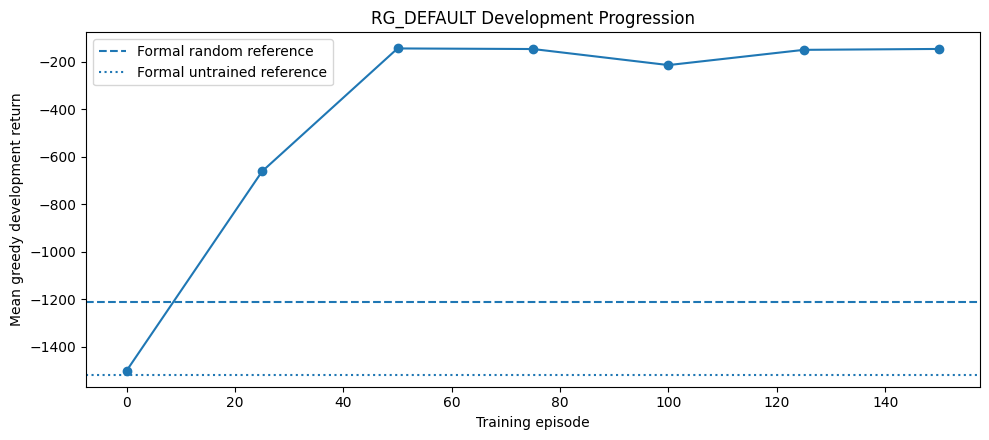

RG_DEFAULT training completed: True
Gravity value: 10.0
Selected checkpoint episode: 50
Mean development return: -144.3528525826363
Development return standard deviation: 105.004453364591
Upright fraction: 0.8641666666666667
Improvement over random: 1066.9095251354388
Improvement over untrained: 1374.399058487015
Held-out final suite used: False
Formal runs completed: 24
Remaining formal-run capacity: 4
Saved default-gravity weights: weights\final_dqn_default.weights.h5
Saved default-gravity comparison: histories\RG_DEFAULT_same_gravity_baseline_comparison.csv
Section 18.2 default-gravity training: COMPLETE


In [85]:
RG_DEFAULT_RUN_ID = "RG_DEFAULT"
RG_DEFAULT_GRAVITY_KEY = "default"
RG_DEFAULT_SEED = FROZEN_GRAVITY_TRAINING_SEED

RG_DEFAULT_WEIGHT_PATH = (
    WEIGHTS_DIR
    / "final_dqn_default.weights.h5"
)
RG_DEFAULT_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{RG_DEFAULT_RUN_ID}_history.csv"
)
RG_DEFAULT_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{RG_DEFAULT_RUN_ID}"
        "_development_evaluations.csv"
    )
)
RG_DEFAULT_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{RG_DEFAULT_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
RG_DEFAULT_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{RG_DEFAULT_RUN_ID}_summary.csv"
)
RG_DEFAULT_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{RG_DEFAULT_RUN_ID}"
        "_selected_state_results.csv"
    )
)
RG_DEFAULT_BASELINE_COMPARISON_PATH = (
    HISTORIES_DIR
    / "RG_DEFAULT_same_gravity_baseline_comparison.csv"
)
RG_DEFAULT_PAIRED_BASELINE_PATH = (
    HISTORIES_DIR
    / "RG_DEFAULT_same_gravity_paired_states.csv"
)

assert DEFAULT_GRAVITY_CONFIGURATION_FROZEN is True
assert GRAVITY_STAGE_RELEASED is True
assert HELDOUT_FINAL_SUITE_RELEASED is False
assert NO_FURTHER_TUNING_DECLARED is True
assert RG_DEFAULT_GRAVITY_KEY in FROZEN_GRAVITY_KEYS
assert RG_DEFAULT_SEED == 4242
assert FORMAL_RUNS_COMPLETED in (23, 24)
assert remaining_formal_run_capacity in (5, 4)


def frozen_gravity_epsilon(
    environment_step: int,
) -> float:
    """Return the frozen moderate-decay epsilon value."""
    progress = min(
        1.0,
        int(environment_step)
        / FROZEN_EPSILON_DECAY_STEPS,
    )
    epsilon = float(
        FROZEN_EPSILON_START
        + progress
        * (
            FROZEN_EPSILON_END
            - FROZEN_EPSILON_START
        )
    )
    assert (
        FROZEN_EPSILON_END
        <= epsilon
        <= FROZEN_EPSILON_START
    )
    return epsilon


def evaluate_frozen_gravity_model(
    model: keras.Model,
    gravity_key: str,
    run_id: str,
    episode: int,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    """Greedily evaluate one frozen model under its assigned gravity."""
    assert gravity_key in FROZEN_GRAVITY_KEYS

    torque_values = np.asarray(
        FROZEN_TORQUE_VALUES,
        dtype=np.float32,
    )
    torque_values = validate_discrete_torque_values(
        torque_values
    )

    def greedy_policy(
        observation: np.ndarray,
    ) -> float:
        _, torque, _ = greedy_discrete_action(
            model=model,
            observation=observation,
            torque_values=torque_values,
        )
        return torque

    state_results = evaluate_policy_on_physical_states(
        env_builder=lambda: make_pendulum_env(
            GRAVITY_SETTINGS[gravity_key]
        ),
        policy=greedy_policy,
        physical_states=DEVELOPMENT_PHYSICAL_STATES,
        horizon=FROZEN_EVALUATION_HORIZON,
    )

    assert len(state_results) == (
        FROZEN_DEVELOPMENT_STATE_COUNT
    )
    assert state_results["state_id"].is_unique

    state_results = state_results.copy()
    state_results.insert(
        0,
        "episode",
        int(episode),
    )
    state_results.insert(
        0,
        "gravity",
        gravity_key,
    )
    state_results.insert(
        0,
        "run_id",
        run_id,
    )

    summary = {
        "run_id": run_id,
        "gravity": gravity_key,
        "episode": int(episode),
        "mean_development_return": float(
            state_results["return"].mean()
        ),
        "median_development_return": float(
            state_results["return"].median()
        ),
        "development_return_std": float(
            state_results["return"].std(ddof=1)
        ),
        "minimum_development_return": float(
            state_results["return"].min()
        ),
        "maximum_development_return": float(
            state_results["return"].max()
        ),
        "mean_upright_fraction": float(
            state_results[
                "upright_fraction"
            ].mean()
        ),
        "mean_abs_angle": float(
            state_results[
                "mean_abs_angle"
            ].mean()
        ),
        "mean_abs_angular_velocity": float(
            state_results[
                "mean_abs_angular_velocity"
            ].mean()
        ),
        "mean_abs_torque": float(
            state_results[
                "mean_abs_torque"
            ].mean()
        ),
        "mean_torque_direction_switching_rate": float(
            state_results[
                "torque_direction_switching_rate"
            ].mean()
        ),
    }

    numeric_summary = [
        value
        for key, value in summary.items()
        if key not in {"run_id", "gravity"}
    ]
    assert np.isfinite(
        np.asarray(
            numeric_summary,
            dtype=np.float64,
        )
    ).all()

    return state_results, summary


def run_frozen_dueling_gravity_model(
    run_id: str,
    gravity_key: str,
    seed: int,
    weight_path: Path,
) -> Dict[str, object]:
    """Train one fresh frozen Dueling DQN under one fixed gravity."""
    assert gravity_key in FROZEN_GRAVITY_KEYS
    assert HELDOUT_FINAL_SUITE_RELEASED is False

    torque_values = np.asarray(
        FROZEN_TORQUE_VALUES,
        dtype=np.float32,
    )
    torque_values = validate_discrete_torque_values(
        torque_values
    )
    action_count = len(torque_values)

    tf.keras.utils.set_random_seed(seed)
    np.random.seed(seed)
    epsilon_rng = random.Random(seed + 1_000)
    replay_rng = random.Random(seed + 2_000)

    main_network, target_network = (
        initialise_dueling_main_and_target_networks(
            state_dim=DQN_STATE_DIM,
            action_count=action_count,
            hidden_units=FROZEN_HIDDEN_UNITS,
            seed=seed,
        )
    )

    optimizer = keras.optimizers.Adam(
        learning_rate=FROZEN_LEARNING_RATE
    )
    replay_memory = ReplayMemory(
        capacity=FROZEN_REPLAY_CAPACITY,
        state_dim=DQN_STATE_DIM,
        action_count=action_count,
    )

    development_observations = np.stack([
        expected_observation(
            float(theta),
            float(theta_dot),
        )
        for theta, theta_dot in (
            DEVELOPMENT_PHYSICAL_STATES
        )
    ]).astype(np.float32)

    history_records = []
    evaluation_frames = []
    evaluation_records = []

    environment_steps = 0
    random_action_count = 0
    greedy_action_count = 0
    target_update_count = 0
    best_mean_return = -np.inf
    best_episode = None

    gravity_probe = make_pendulum_env(
        GRAVITY_SETTINGS[gravity_key]
    )
    try:
        actual_gravity = float(
            gravity_probe.unwrapped.g
        )
    finally:
        gravity_probe.close()

    total_start = time.perf_counter()

    initial_states, initial_summary = (
        evaluate_frozen_gravity_model(
            model=main_network,
            gravity_key=gravity_key,
            run_id=run_id,
            episode=0,
        )
    )
    evaluation_frames.append(initial_states)
    evaluation_records.append(initial_summary)

    best_mean_return = float(
        initial_summary[
            "mean_development_return"
        ]
    )
    best_episode = 0
    main_network.save_weights(weight_path)

    print(
        f"Episode   0 | development mean return "
        f"{best_mean_return:10.3f} | "
        "initial checkpoint"
    )

    env = make_pendulum_env(
        GRAVITY_SETTINGS[gravity_key]
    )
    env.seed(seed)

    try:
        for episode in range(
            1,
            FROZEN_TRAINING_EPISODES + 1,
        ):
            observation = np.asarray(
                env.reset(),
                dtype=np.float32,
            )
            episode_return = 0.0
            episode_losses = []
            episode_gradient_norms = []
            episode_random_actions = 0
            episode_greedy_actions = 0
            episode_target_updates = 0
            episode_start = time.perf_counter()

            for step_index in range(
                FROZEN_EVALUATION_HORIZON
            ):
                epsilon = frozen_gravity_epsilon(
                    environment_steps
                )
                action_index, torque, was_random = (
                    epsilon_greedy_discrete_action(
                        model=main_network,
                        observation=observation,
                        torque_values=torque_values,
                        epsilon=epsilon,
                        rng=epsilon_rng,
                    )
                )

                episode_random_actions += int(
                    was_random
                )
                episode_greedy_actions += int(
                    not was_random
                )
                random_action_count += int(
                    was_random
                )
                greedy_action_count += int(
                    not was_random
                )

                next_observation, reward, done, info = (
                    env.step(
                        np.array(
                            [torque],
                            dtype=np.float32,
                        )
                    )
                )
                next_observation = np.asarray(
                    next_observation,
                    dtype=np.float32,
                )

                replay_memory.append(
                    state=observation,
                    action_index=action_index,
                    reward=float(reward),
                    next_state=next_observation,
                )

                observation = next_observation
                episode_return += float(reward)
                environment_steps += 1

                if (
                    len(replay_memory)
                    >= FROZEN_REPLAY_WARMUP
                ):
                    batch = replay_memory.sample(
                        batch_size=FROZEN_BATCH_SIZE,
                        rng=replay_rng,
                    )
                    update_result = (
                        vanilla_dqn_gradient_update(
                            main_network=main_network,
                            target_network=target_network,
                            optimizer=optimizer,
                            states=batch[0],
                            action_indices=batch[1],
                            rewards=batch[2],
                            next_states=batch[3],
                            gamma=FROZEN_GAMMA,
                        )
                    )
                    episode_losses.append(
                        update_result["loss"]
                    )
                    episode_gradient_norms.append(
                        update_result[
                            "gradient_global_norm"
                        ]
                    )

                    target_updated = (
                        hard_update_target_network_if_due(
                            main_network=main_network,
                            target_network=target_network,
                            optimizer_step=int(
                                optimizer.iterations.numpy()
                            ),
                            update_frequency=(
                                FROZEN_TARGET_UPDATE_FREQUENCY
                            ),
                        )
                    )
                    episode_target_updates += int(
                        target_updated
                    )
                    target_update_count += int(
                        target_updated
                    )

                if done:
                    assert info.get(
                        "TimeLimit.truncated"
                    ) is True
                    assert (
                        step_index + 1
                        == FROZEN_EVALUATION_HORIZON
                    )
                    break

            assert (
                step_index + 1
                == FROZEN_EVALUATION_HORIZON
            )

            q_values = main_network(
                tf.convert_to_tensor(
                    development_observations,
                    dtype=tf.float32,
                ),
                training=False,
            ).numpy()

            assert q_values.shape == (
                FROZEN_DEVELOPMENT_STATE_COUNT,
                action_count,
            )
            assert np.isfinite(q_values).all()

            history_records.append({
                "run_id": run_id,
                "gravity": gravity_key,
                "gravity_value": actual_gravity,
                "model": FROZEN_ARCHITECTURE,
                "episode": int(episode),
                "environment_steps": int(
                    environment_steps
                ),
                "optimizer_updates": int(
                    optimizer.iterations.numpy()
                ),
                "training_return": float(
                    episode_return
                ),
                "epsilon": float(epsilon),
                "mean_loss": (
                    float(np.mean(episode_losses))
                    if episode_losses
                    else np.nan
                ),
                "mean_gradient_global_norm": (
                    float(
                        np.mean(
                            episode_gradient_norms
                        )
                    )
                    if episode_gradient_norms
                    else np.nan
                ),
                "mean_q": float(
                    np.mean(q_values)
                ),
                "max_q": float(
                    np.max(q_values)
                ),
                "random_actions": int(
                    episode_random_actions
                ),
                "greedy_actions": int(
                    episode_greedy_actions
                ),
                "target_updates": int(
                    episode_target_updates
                ),
                "replay_size": int(
                    len(replay_memory)
                ),
                "episode_runtime_seconds": float(
                    time.perf_counter()
                    - episode_start
                ),
            })

            if episode in (
                FROZEN_EVALUATION_EPISODES[1:]
            ):
                replay_size_before = len(
                    replay_memory
                )
                state_results, evaluation_summary = (
                    evaluate_frozen_gravity_model(
                        model=main_network,
                        gravity_key=gravity_key,
                        run_id=run_id,
                        episode=episode,
                    )
                )
                assert len(replay_memory) == (
                    replay_size_before
                )

                evaluation_frames.append(
                    state_results
                )
                evaluation_records.append(
                    evaluation_summary
                )

                mean_return = float(
                    evaluation_summary[
                        "mean_development_return"
                    ]
                )
                if mean_return > best_mean_return:
                    main_network.save_weights(
                        weight_path
                    )
                    best_mean_return = mean_return
                    best_episode = int(episode)

                print(
                    f"Episode {episode:3d} | "
                    "development mean return "
                    f"{mean_return:10.3f} | best "
                    f"{best_mean_return:10.3f} "
                    f"at episode {best_episode}"
                )
    finally:
        env.close()

    total_runtime_seconds = (
        time.perf_counter()
        - total_start
    )

    history = pd.DataFrame(history_records)
    history["moving_average_return"] = (
        history["training_return"]
        .rolling(
            R10_MOVING_AVERAGE_WINDOW,
            min_periods=1,
        )
        .mean()
    )

    evaluation_states = pd.concat(
        evaluation_frames,
        ignore_index=True,
    )
    evaluation_summary = pd.DataFrame(
        evaluation_records
    )
    evaluation_map = dict(zip(
        evaluation_summary["episode"],
        evaluation_summary[
            "mean_development_return"
        ],
    ))
    history["evaluation_return"] = (
        history["episode"].map(
            evaluation_map
        )
    )

    selected_model = build_dueling_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=action_count,
        hidden_units=FROZEN_HIDDEN_UNITS,
        model_name=(
            f"{run_id.lower()}_selected_q_network"
        ),
    )
    selected_model.load_weights(weight_path)

    selected_states, selected_summary = (
        evaluate_frozen_gravity_model(
            model=selected_model,
            gravity_key=gravity_key,
            run_id=run_id,
            episode=int(best_episode),
        )
    )

    assert np.isclose(
        selected_summary[
            "mean_development_return"
        ],
        best_mean_return,
        rtol=1e-7,
        atol=1e-7,
    )

    selected_q_values = selected_model(
        tf.convert_to_tensor(
            development_observations,
            dtype=tf.float32,
        ),
        training=False,
    ).numpy()

    assert selected_q_values.shape == (
        FROZEN_DEVELOPMENT_STATE_COUNT,
        action_count,
    )
    assert np.isfinite(
        selected_q_values
    ).all()

    summary_record = {
        "run_id": run_id,
        "model": FROZEN_ARCHITECTURE,
        "gravity": gravity_key,
        "gravity_value": actual_gravity,
        "seed": int(seed),
        "action_count": int(action_count),
        "torque_values": torque_values.tolist(),
        "episodes": int(
            FROZEN_TRAINING_EPISODES
        ),
        "environment_steps": int(
            environment_steps
        ),
        "optimizer_updates": int(
            optimizer.iterations.numpy()
        ),
        "selected_checkpoint_episode": int(
            best_episode
        ),
        "mean_development_return": float(
            selected_summary[
                "mean_development_return"
            ]
        ),
        "development_return_std": float(
            selected_summary[
                "development_return_std"
            ]
        ),
        "upright_fraction": float(
            selected_summary[
                "mean_upright_fraction"
            ]
        ),
        "mean_abs_angle": float(
            selected_summary[
                "mean_abs_angle"
            ]
        ),
        "mean_abs_angular_velocity": float(
            selected_summary[
                "mean_abs_angular_velocity"
            ]
        ),
        "mean_abs_torque": float(
            selected_summary[
                "mean_abs_torque"
            ]
        ),
        "torque_direction_switching_rate": float(
            selected_summary[
                "mean_torque_direction_switching_rate"
            ]
        ),
        "selected_mean_q": float(
            np.mean(selected_q_values)
        ),
        "selected_max_q": float(
            np.max(selected_q_values)
        ),
        "selected_min_q": float(
            np.min(selected_q_values)
        ),
        "random_actions": int(
            random_action_count
        ),
        "greedy_actions": int(
            greedy_action_count
        ),
        "target_updates": int(
            target_update_count
        ),
        "runtime_minutes": float(
            total_runtime_seconds / 60.0
        ),
        "parameter_count": int(
            selected_model.count_params()
        ),
        "weight_path": str(weight_path),
        "technical_status": "PASS",
        "configuration_status": "FROZEN",
        "heldout_suite_used": False,
    }

    return {
        "main_network": main_network,
        "target_network": target_network,
        "selected_model": selected_model,
        "history": history,
        "evaluation_states": evaluation_states,
        "evaluation_summary": evaluation_summary,
        "selected_state_results": selected_states,
        "selected_summary": selected_summary,
        "summary_record": summary_record,
    }


rg_default_required_artifacts = [
    RG_DEFAULT_WEIGHT_PATH,
    RG_DEFAULT_HISTORY_PATH,
    RG_DEFAULT_EVALUATION_PATH,
    RG_DEFAULT_EVALUATION_SUMMARY_PATH,
    RG_DEFAULT_SUMMARY_PATH,
    RG_DEFAULT_STATE_RESULTS_PATH,
]
rg_default_artifacts_complete = all(
    path.exists()
    for path in rg_default_required_artifacts
)

if (
    "rg_default_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "rg_default_history",
            "rg_default_evaluation_states",
            "rg_default_evaluation_summary",
            "rg_default_selected_state_results",
            "rg_default_summary",
            "rg_default_selected_model",
        ]
    )
):
    print(
        "RG_DEFAULT already exists in memory; "
        "no duplicate training run was started."
    )
elif rg_default_artifacts_complete:
    rg_default_history = read_csv_with_control_metric_migration(
        RG_DEFAULT_HISTORY_PATH
    )
    rg_default_evaluation_states = read_csv_with_control_metric_migration(
        RG_DEFAULT_EVALUATION_PATH
    )
    rg_default_evaluation_summary = read_csv_with_control_metric_migration(
        RG_DEFAULT_EVALUATION_SUMMARY_PATH
    )
    rg_default_summary = read_csv_with_control_metric_migration(
        RG_DEFAULT_SUMMARY_PATH
    )
    rg_default_selected_state_results = read_csv_with_control_metric_migration(
        RG_DEFAULT_STATE_RESULTS_PATH
    )

    assert len(rg_default_summary) == 1
    rg_default_summary_record = (
        rg_default_summary.iloc[0].to_dict()
    )
    rg_default_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FROZEN_ACTION_COUNT,
            hidden_units=FROZEN_HIDDEN_UNITS,
            model_name=(
                "rg_default_reloaded_q_network"
            ),
        )
    )
    rg_default_selected_model.load_weights(
        RG_DEFAULT_WEIGHT_PATH
    )
    print(
        "Loaded completed RG_DEFAULT artifacts; "
        "no duplicate training run was started."
    )
else:
    rg_default_result = (
        run_frozen_dueling_gravity_model(
            run_id=RG_DEFAULT_RUN_ID,
            gravity_key=RG_DEFAULT_GRAVITY_KEY,
            seed=RG_DEFAULT_SEED,
            weight_path=RG_DEFAULT_WEIGHT_PATH,
        )
    )

    rg_default_history = (
        rg_default_result["history"]
    )
    rg_default_evaluation_states = (
        rg_default_result[
            "evaluation_states"
        ]
    )
    rg_default_evaluation_summary = (
        rg_default_result[
            "evaluation_summary"
        ]
    )
    rg_default_selected_state_results = (
        rg_default_result[
            "selected_state_results"
        ]
    )
    rg_default_selected_model = (
        rg_default_result[
            "selected_model"
        ]
    )
    rg_default_summary_record = dict(
        rg_default_result[
            "summary_record"
        ]
    )
    rg_default_summary = pd.DataFrame(
        [rg_default_summary_record]
    )

FORMAL_RUNS_COMPLETED = 24
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 24
assert remaining_formal_run_capacity == 4
assert len(rg_default_history) == (
    FROZEN_TRAINING_EPISODES
)
assert len(
    rg_default_evaluation_summary
) == len(FROZEN_EVALUATION_EPISODES)
assert int(
    rg_default_summary_record["seed"]
) == RG_DEFAULT_SEED
assert (
    rg_default_summary_record["gravity"]
    == RG_DEFAULT_GRAVITY_KEY
)
assert np.isclose(
    float(
        rg_default_summary_record[
            "gravity_value"
        ]
    ),
    10.0,
)
assert (
    rg_default_summary_record["model"]
    == FROZEN_ARCHITECTURE
)
assert int(
    rg_default_summary_record[
        "parameter_count"
    ]
) == FROZEN_PARAMETER_COUNT
assert int(
    rg_default_summary_record[
        "environment_steps"
    ]
) == FROZEN_ENVIRONMENT_STEPS
assert int(
    rg_default_summary_record[
        "optimizer_updates"
    ]
) == 29_001
assert int(
    rg_default_summary_record[
        "target_updates"
    ]
) == 116
assert (
    rg_default_summary_record[
        "heldout_suite_used"
    ]
    is False
)
assert RG_DEFAULT_WEIGHT_PATH.exists()

rg_default_history.to_csv(
    RG_DEFAULT_HISTORY_PATH,
    index=False,
)
rg_default_evaluation_states.to_csv(
    RG_DEFAULT_EVALUATION_PATH,
    index=False,
)
rg_default_evaluation_summary.to_csv(
    RG_DEFAULT_EVALUATION_SUMMARY_PATH,
    index=False,
)
rg_default_summary.to_csv(
    RG_DEFAULT_SUMMARY_PATH,
    index=False,
)
rg_default_selected_state_results.to_csv(
    RG_DEFAULT_STATE_RESULTS_PATH,
    index=False,
)

default_reference_rows = (
    formal_reference_summary.loc[
        formal_reference_summary[
            "gravity"
        ] == RG_DEFAULT_GRAVITY_KEY
    ]
    .copy()
    .reset_index(drop=True)
)
assert len(default_reference_rows) == 2

default_random_mean = float(
    default_reference_rows.loc[
        default_reference_rows[
            "policy"
        ] == "formal_random_discrete",
        "mean_return",
    ].iloc[0]
)
default_untrained_mean = float(
    default_reference_rows.loc[
        default_reference_rows[
            "policy"
        ]
        == "formal_untrained_greedy_q_network",
        "mean_return",
    ].iloc[0]
)
rg_default_trained_mean = float(
    rg_default_summary_record[
        "mean_development_return"
    ]
)

trained_default_states = (
    rg_default_selected_state_results
    [["state_id", "return"]]
    .rename(
        columns={
            "return": "trained_return"
        }
    )
)
random_default_states = (
    FORMAL_REFERENCE_STATE_RESULTS[
        ("default", "random")
    ][["state_id", "return"]]
    .rename(
        columns={
            "return": "random_return"
        }
    )
)
untrained_default_states = (
    FORMAL_REFERENCE_STATE_RESULTS[
        ("default", "untrained")
    ][["state_id", "return"]]
    .rename(
        columns={
            "return": "untrained_return"
        }
    )
)

rg_default_paired_baselines = (
    trained_default_states
    .merge(
        random_default_states,
        on="state_id",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        untrained_default_states,
        on="state_id",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("state_id")
    .reset_index(drop=True)
)

assert len(rg_default_paired_baselines) == (
    FROZEN_DEVELOPMENT_STATE_COUNT
)

rg_default_paired_baselines[
    "trained_minus_random"
] = (
    rg_default_paired_baselines[
        "trained_return"
    ]
    - rg_default_paired_baselines[
        "random_return"
    ]
)
rg_default_paired_baselines[
    "trained_minus_untrained"
] = (
    rg_default_paired_baselines[
        "trained_return"
    ]
    - rg_default_paired_baselines[
        "untrained_return"
    ]
)

rg_default_baseline_comparison_record = {
    "run_id": RG_DEFAULT_RUN_ID,
    "gravity": RG_DEFAULT_GRAVITY_KEY,
    "gravity_value": 10.0,
    "seed": RG_DEFAULT_SEED,
    "trained_mean_return": (
        rg_default_trained_mean
    ),
    "random_mean_return": (
        default_random_mean
    ),
    "untrained_mean_return": (
        default_untrained_mean
    ),
    "trained_minus_random": float(
        rg_default_trained_mean
        - default_random_mean
    ),
    "trained_minus_untrained": float(
        rg_default_trained_mean
        - default_untrained_mean
    ),
    "trained_random_state_win_rate": float(
        (
            rg_default_paired_baselines[
                "trained_minus_random"
            ] > 0.0
        ).mean()
    ),
    "trained_untrained_state_win_rate": float(
        (
            rg_default_paired_baselines[
                "trained_minus_untrained"
            ] > 0.0
        ).mean()
    ),
    "upright_fraction": float(
        rg_default_summary_record[
            "upright_fraction"
        ]
    ),
    "development_state_std": float(
        rg_default_summary_record[
            "development_return_std"
        ]
    ),
    "selected_checkpoint_episode": int(
        rg_default_summary_record[
            "selected_checkpoint_episode"
        ]
    ),
    "heldout_suite_used": False,
    "selection_deferred_until_review": True,
}

rg_default_baseline_comparison = pd.DataFrame(
    [rg_default_baseline_comparison_record]
)

assert np.isclose(
    rg_default_paired_baselines[
        "trained_minus_random"
    ].mean(),
    rg_default_baseline_comparison_record[
        "trained_minus_random"
    ],
    rtol=0.0,
    atol=1e-6,
)
assert np.isclose(
    rg_default_paired_baselines[
        "trained_minus_untrained"
    ].mean(),
    rg_default_baseline_comparison_record[
        "trained_minus_untrained"
    ],
    rtol=0.0,
    atol=1e-6,
)
assert (
    rg_default_baseline_comparison_record[
        "heldout_suite_used"
    ]
    is False
)

rg_default_baseline_comparison.to_csv(
    RG_DEFAULT_BASELINE_COMPARISON_PATH,
    index=False,
)
rg_default_paired_baselines.to_csv(
    RG_DEFAULT_PAIRED_BASELINE_PATH,
    index=False,
)

if "GRAVITY_TRAINING_RESULTS" not in globals():
    GRAVITY_TRAINING_RESULTS = {}
    GRAVITY_TRAINING_STATE_RESULTS = {}
    GRAVITY_TRAINING_EVALUATION_SUMMARIES = {}
    GRAVITY_TRAINING_MODELS = {}

GRAVITY_TRAINING_RESULTS[
    RG_DEFAULT_GRAVITY_KEY
] = rg_default_summary_record
GRAVITY_TRAINING_STATE_RESULTS[
    RG_DEFAULT_GRAVITY_KEY
] = rg_default_selected_state_results.copy()
GRAVITY_TRAINING_EVALUATION_SUMMARIES[
    RG_DEFAULT_GRAVITY_KEY
] = rg_default_evaluation_summary.copy()
GRAVITY_TRAINING_MODELS[
    RG_DEFAULT_GRAVITY_KEY
] = rg_default_selected_model

display(rg_default_baseline_comparison)
display(rg_default_evaluation_summary)
display(rg_default_summary)

plt.figure(figsize=(10, 4.5))
plt.plot(
    rg_default_evaluation_summary[
        "episode"
    ],
    rg_default_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
)
plt.axhline(
    default_random_mean,
    linestyle="--",
    label="Formal random reference",
)
plt.axhline(
    default_untrained_mean,
    linestyle=":",
    label="Formal untrained reference",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("RG_DEFAULT Development Progression")
plt.legend()
plt.tight_layout()
plt.show()

print("RG_DEFAULT training completed:", True)
print(
    "Gravity value:",
    rg_default_summary_record[
        "gravity_value"
    ],
)
print(
    "Selected checkpoint episode:",
    rg_default_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    rg_default_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    rg_default_summary_record[
        "development_return_std"
    ],
)
print(
    "Upright fraction:",
    rg_default_summary_record[
        "upright_fraction"
    ],
)
print(
    "Improvement over random:",
    rg_default_baseline_comparison_record[
        "trained_minus_random"
    ],
)
print(
    "Improvement over untrained:",
    rg_default_baseline_comparison_record[
        "trained_minus_untrained"
    ],
)
print(
    "Held-out final suite used:",
    rg_default_summary_record[
        "heldout_suite_used"
    ],
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved default-gravity weights:",
    RG_DEFAULT_WEIGHT_PATH,
)
print(
    "Saved default-gravity comparison:",
    RG_DEFAULT_BASELINE_COMPARISON_PATH,
)
print("Section 18.2 default-gravity training: COMPLETE")


### 18.2 Result Interpretation

**Finding.** The fresh post-freeze default-gravity model completed
successfully:

```text
Gravity: g = 10
Seed: 4242
Selected checkpoint: episode 50
Mean development return: -144.352853
Development-state standard deviation: 105.004453
Upright fraction: 0.864167
```

Against the same-gravity references, the trained model improved by:

```text
Versus random: +1066.909525
Versus untrained network: +1374.399058
```

It won all `24` paired development states against both references. Its return
was `5.268300` points below the three-seed final-confirmation mean, which
remains inside the practical margin.

**Importance.** The frozen configuration remains viable when reconstructed
fresh under the matched gravity protocol. The held-out final suite was not
used.

**Decision.** Retain the selected `RG_DEFAULT` episode-`50` checkpoint as the
default-gravity policy for the later held-out evaluation.

**Caveat.** The episode-`100` development evaluation deteriorated sharply
before recovering. This supports retaining the frozen development-checkpoint
selection rule rather than automatically using the final episode.

**Next step.** Train a separate fresh model under zero gravity while keeping
every frozen setting and the matched seed unchanged.


## 18.3 Zero Gravity, `g = 0`

Run ID:

```text
RG_ZERO
```

This is a new Dueling DQN trained from fresh weights while gravity remains
fixed at `g = 0` for the entire run.

The model uses the frozen architecture, seven-action torque set, raw state,
moderate exploration, replay and target settings, optimisation recipe,
training budget, development states, checkpoint rule and seed `4242`.

Its selected development checkpoint is compared with the formal random and
untrained references under the same zero-gravity environment. The held-out
suite remains closed.

This consumes one formal-training slot. After completion, the formal-run count
should be `25`, leaving `3` slots for anti-gravity, supergravity and the
protected contingency.


Loaded completed RG_ZERO artifacts; no duplicate training run was started.


,run_id,gravity,gravity_value,seed,trained_mean_return,random_mean_return,untrained_mean_return,trained_minus_random,trained_minus_untrained,trained_random_state_win_rate,trained_untrained_state_win_rate,upright_fraction,development_state_std,selected_checkpoint_episode,heldout_suite_used,selection_deferred_until_review
0,RG_ZERO,g0,0.0,4242,-48.09617,-790.762709,-1371.85405,742.66654,1323.75788,1.0,1.0,0.910625,50.091453,50,False,True


,run_id,gravity,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,RG_ZERO,g0,0,-1783.982350,-1794.155560,67.218492,-1883.987398,-1625.438290,0.085625,1.585809,7.232479,1.597778,0.003769
1,RG_ZERO,g0,25,-53.377896,-39.750383,53.031485,-163.114785,0.000000,0.845625,0.219374,0.178188,0.258611,0.121231
2,RG_ZERO,g0,50,-48.096170,-34.270132,50.091453,-149.022419,-1.346815,0.910625,0.149320,0.276000,1.538889,0.734087
3,RG_ZERO,g0,75,-48.278554,-34.096265,49.352957,-136.845005,0.000000,0.908958,0.172419,0.215563,0.188056,0.083124
4,RG_ZERO,g0,100,-54.290190,-37.986713,54.934132,-168.131989,-0.625489,0.882917,0.233447,0.223604,0.966111,0.710008
5,RG_ZERO,g0,125,-61.541623,-48.988373,46.290733,-156.491977,-17.488446,0.106250,0.369244,0.265063,1.437361,0.677554
6,RG_ZERO,g0,150,-54.518798,-41.724055,49.655489,-158.995930,-4.803498,0.776875,0.301297,0.167875,0.220972,0.179229


,run_id,model,gravity,gravity_value,seed,action_count,torque_values,episodes,environment_steps,optimizer_updates,...,selected_min_q,random_actions,greedy_actions,target_updates,runtime_minutes,parameter_count,weight_path,technical_status,configuration_status,heldout_suite_used
0,RG_ZERO,Dueling DQN,g0,0.0,4242,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,30000,29001,...,-109.062973,10954,19046,116,20.075974,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS,FROZEN,False


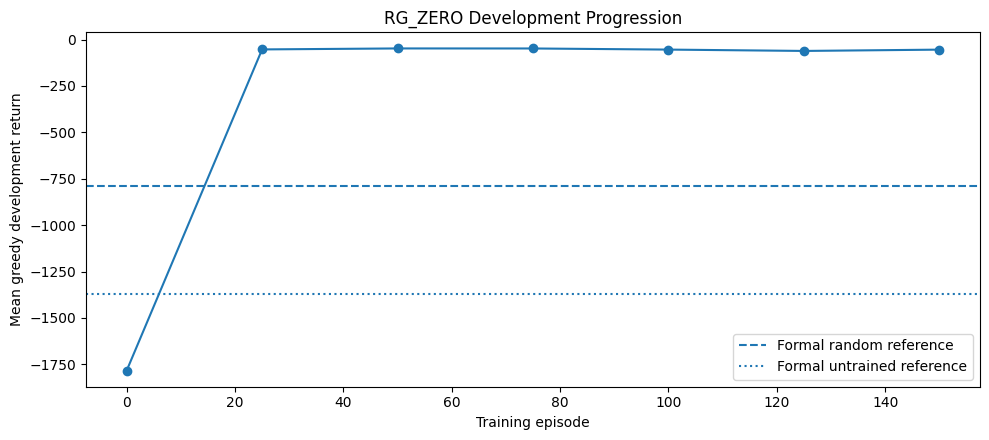

RG_ZERO training completed: True
Gravity value: 0.0
Selected checkpoint episode: 50
Mean development return: -48.0961695719933
Development return standard deviation: 50.09145264465409
Upright fraction: 0.910625
Improvement over random: 742.6665395261591
Improvement over untrained: 1323.7578800846509
Held-out final suite used: False
Formal runs completed: 25
Remaining formal-run capacity: 3
Saved zero-gravity weights: weights\final_dqn_g0.weights.h5
Saved zero-gravity comparison: histories\RG_ZERO_same_gravity_baseline_comparison.csv
Section 18.3 zero-gravity training: COMPLETE


In [86]:
RG_ZERO_RUN_ID = "RG_ZERO"
RG_ZERO_GRAVITY_KEY = "g0"
RG_ZERO_SEED = FROZEN_GRAVITY_TRAINING_SEED

RG_ZERO_WEIGHT_PATH = (
    WEIGHTS_DIR
    / "final_dqn_g0.weights.h5"
)
RG_ZERO_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{RG_ZERO_RUN_ID}_history.csv"
)
RG_ZERO_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{RG_ZERO_RUN_ID}"
        "_development_evaluations.csv"
    )
)
RG_ZERO_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{RG_ZERO_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
RG_ZERO_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{RG_ZERO_RUN_ID}_summary.csv"
)
RG_ZERO_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{RG_ZERO_RUN_ID}"
        "_selected_state_results.csv"
    )
)
RG_ZERO_BASELINE_COMPARISON_PATH = (
    HISTORIES_DIR
    / "RG_ZERO_same_gravity_baseline_comparison.csv"
)
RG_ZERO_PAIRED_BASELINE_PATH = (
    HISTORIES_DIR
    / "RG_ZERO_same_gravity_paired_states.csv"
)

assert DEFAULT_GRAVITY_CONFIGURATION_FROZEN is True
assert GRAVITY_STAGE_RELEASED is True
assert HELDOUT_FINAL_SUITE_RELEASED is False
assert NO_FURTHER_TUNING_DECLARED is True
assert RG_ZERO_GRAVITY_KEY in FROZEN_GRAVITY_KEYS
assert RG_ZERO_SEED == FROZEN_GRAVITY_TRAINING_SEED
assert RG_ZERO_SEED == 4242
assert FORMAL_RUNS_COMPLETED in (24, 25)
assert remaining_formal_run_capacity in (4, 3)
assert "default" in GRAVITY_TRAINING_RESULTS
assert (
    GRAVITY_TRAINING_RESULTS["default"]["run_id"]
    == RG_DEFAULT_RUN_ID
)


def compare_frozen_gravity_to_formal_references(
    run_id: str,
    gravity_key: str,
    summary_record: dict,
    selected_state_results: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Compare one trained gravity model with same-gravity references."""
    assert gravity_key in FROZEN_GRAVITY_KEYS
    assert len(selected_state_results) == (
        FROZEN_DEVELOPMENT_STATE_COUNT
    )

    reference_rows = (
        formal_reference_summary.loc[
            formal_reference_summary[
                "gravity"
            ] == gravity_key
        ]
        .copy()
        .reset_index(drop=True)
    )
    assert len(reference_rows) == 2

    random_mean = float(
        reference_rows.loc[
            reference_rows["policy"]
            == "formal_random_discrete",
            "mean_return",
        ].iloc[0]
    )
    untrained_mean = float(
        reference_rows.loc[
            reference_rows["policy"]
            == "formal_untrained_greedy_q_network",
            "mean_return",
        ].iloc[0]
    )

    trained_states = (
        selected_state_results[
            ["state_id", "return"]
        ]
        .rename(
            columns={
                "return": "trained_return"
            }
        )
    )
    random_states = (
        FORMAL_REFERENCE_STATE_RESULTS[
            (gravity_key, "random")
        ][["state_id", "return"]]
        .rename(
            columns={
                "return": "random_return"
            }
        )
    )
    untrained_states = (
        FORMAL_REFERENCE_STATE_RESULTS[
            (gravity_key, "untrained")
        ][["state_id", "return"]]
        .rename(
            columns={
                "return": "untrained_return"
            }
        )
    )

    paired = (
        trained_states
        .merge(
            random_states,
            on="state_id",
            how="inner",
            validate="one_to_one",
        )
        .merge(
            untrained_states,
            on="state_id",
            how="inner",
            validate="one_to_one",
        )
        .sort_values("state_id")
        .reset_index(drop=True)
    )
    assert len(paired) == (
        FROZEN_DEVELOPMENT_STATE_COUNT
    )

    paired["trained_minus_random"] = (
        paired["trained_return"]
        - paired["random_return"]
    )
    paired["trained_minus_untrained"] = (
        paired["trained_return"]
        - paired["untrained_return"]
    )

    trained_mean = float(
        summary_record[
            "mean_development_return"
        ]
    )

    comparison_record = {
        "run_id": run_id,
        "gravity": gravity_key,
        "gravity_value": float(
            summary_record["gravity_value"]
        ),
        "seed": int(summary_record["seed"]),
        "trained_mean_return": trained_mean,
        "random_mean_return": random_mean,
        "untrained_mean_return": untrained_mean,
        "trained_minus_random": float(
            trained_mean - random_mean
        ),
        "trained_minus_untrained": float(
            trained_mean - untrained_mean
        ),
        "trained_random_state_win_rate": float(
            (
                paired[
                    "trained_minus_random"
                ] > 0.0
            ).mean()
        ),
        "trained_untrained_state_win_rate": float(
            (
                paired[
                    "trained_minus_untrained"
                ] > 0.0
            ).mean()
        ),
        "upright_fraction": float(
            summary_record["upright_fraction"]
        ),
        "development_state_std": float(
            summary_record[
                "development_return_std"
            ]
        ),
        "selected_checkpoint_episode": int(
            summary_record[
                "selected_checkpoint_episode"
            ]
        ),
        "heldout_suite_used": False,
        "selection_deferred_until_review": True,
    }

    np.testing.assert_allclose(
        paired[
            "trained_minus_random"
        ].mean(),
        comparison_record[
            "trained_minus_random"
        ],
        rtol=0.0,
        atol=1e-6,
    )
    np.testing.assert_allclose(
        paired[
            "trained_minus_untrained"
        ].mean(),
        comparison_record[
            "trained_minus_untrained"
        ],
        rtol=0.0,
        atol=1e-6,
    )

    comparison = pd.DataFrame(
        [comparison_record]
    )
    return comparison, paired


rg_zero_required_artifacts = [
    RG_ZERO_WEIGHT_PATH,
    RG_ZERO_HISTORY_PATH,
    RG_ZERO_EVALUATION_PATH,
    RG_ZERO_EVALUATION_SUMMARY_PATH,
    RG_ZERO_SUMMARY_PATH,
    RG_ZERO_STATE_RESULTS_PATH,
]
rg_zero_artifacts_complete = all(
    path.exists()
    for path in rg_zero_required_artifacts
)

if (
    "rg_zero_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "rg_zero_history",
            "rg_zero_evaluation_states",
            "rg_zero_evaluation_summary",
            "rg_zero_selected_state_results",
            "rg_zero_summary",
            "rg_zero_selected_model",
        ]
    )
):
    print(
        "RG_ZERO already exists in memory; "
        "no duplicate training run was started."
    )
elif rg_zero_artifacts_complete:
    rg_zero_history = read_csv_with_control_metric_migration(
        RG_ZERO_HISTORY_PATH
    )
    rg_zero_evaluation_states = read_csv_with_control_metric_migration(
        RG_ZERO_EVALUATION_PATH
    )
    rg_zero_evaluation_summary = read_csv_with_control_metric_migration(
        RG_ZERO_EVALUATION_SUMMARY_PATH
    )
    rg_zero_summary = read_csv_with_control_metric_migration(
        RG_ZERO_SUMMARY_PATH
    )
    rg_zero_selected_state_results = read_csv_with_control_metric_migration(
        RG_ZERO_STATE_RESULTS_PATH
    )

    assert len(rg_zero_summary) == 1
    rg_zero_summary_record = (
        rg_zero_summary.iloc[0].to_dict()
    )
    rg_zero_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FROZEN_ACTION_COUNT,
            hidden_units=FROZEN_HIDDEN_UNITS,
            model_name=(
                "rg_zero_reloaded_q_network"
            ),
        )
    )
    rg_zero_selected_model.load_weights(
        RG_ZERO_WEIGHT_PATH
    )
    print(
        "Loaded completed RG_ZERO artifacts; "
        "no duplicate training run was started."
    )
else:
    rg_zero_result = (
        run_frozen_dueling_gravity_model(
            run_id=RG_ZERO_RUN_ID,
            gravity_key=RG_ZERO_GRAVITY_KEY,
            seed=RG_ZERO_SEED,
            weight_path=RG_ZERO_WEIGHT_PATH,
        )
    )

    rg_zero_history = (
        rg_zero_result["history"]
    )
    rg_zero_evaluation_states = (
        rg_zero_result[
            "evaluation_states"
        ]
    )
    rg_zero_evaluation_summary = (
        rg_zero_result[
            "evaluation_summary"
        ]
    )
    rg_zero_selected_state_results = (
        rg_zero_result[
            "selected_state_results"
        ]
    )
    rg_zero_selected_model = (
        rg_zero_result[
            "selected_model"
        ]
    )
    rg_zero_summary_record = dict(
        rg_zero_result[
            "summary_record"
        ]
    )
    rg_zero_summary = pd.DataFrame(
        [rg_zero_summary_record]
    )

FORMAL_RUNS_COMPLETED = 25
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 25
assert remaining_formal_run_capacity == 3
assert len(rg_zero_history) == (
    FROZEN_TRAINING_EPISODES
)
assert len(rg_zero_evaluation_summary) == (
    len(FROZEN_EVALUATION_EPISODES)
)
assert int(
    rg_zero_summary_record["seed"]
) == RG_ZERO_SEED
assert (
    rg_zero_summary_record["gravity"]
    == RG_ZERO_GRAVITY_KEY
)
assert np.isclose(
    float(
        rg_zero_summary_record[
            "gravity_value"
        ]
    ),
    0.0,
    rtol=0.0,
    atol=0.0,
)
assert (
    rg_zero_summary_record["model"]
    == FROZEN_ARCHITECTURE
)
assert int(
    rg_zero_summary_record[
        "parameter_count"
    ]
) == FROZEN_PARAMETER_COUNT
assert int(
    rg_zero_summary_record[
        "environment_steps"
    ]
) == FROZEN_ENVIRONMENT_STEPS
assert int(
    rg_zero_summary_record[
        "optimizer_updates"
    ]
) == 29_001
assert int(
    rg_zero_summary_record[
        "target_updates"
    ]
) == 116
assert (
    rg_zero_summary_record[
        "heldout_suite_used"
    ]
    is False
)
assert RG_ZERO_WEIGHT_PATH.exists()

rg_zero_history.to_csv(
    RG_ZERO_HISTORY_PATH,
    index=False,
)
rg_zero_evaluation_states.to_csv(
    RG_ZERO_EVALUATION_PATH,
    index=False,
)
rg_zero_evaluation_summary.to_csv(
    RG_ZERO_EVALUATION_SUMMARY_PATH,
    index=False,
)
rg_zero_summary.to_csv(
    RG_ZERO_SUMMARY_PATH,
    index=False,
)
rg_zero_selected_state_results.to_csv(
    RG_ZERO_STATE_RESULTS_PATH,
    index=False,
)

(
    rg_zero_baseline_comparison,
    rg_zero_paired_baselines,
) = compare_frozen_gravity_to_formal_references(
    run_id=RG_ZERO_RUN_ID,
    gravity_key=RG_ZERO_GRAVITY_KEY,
    summary_record=rg_zero_summary_record,
    selected_state_results=(
        rg_zero_selected_state_results
    ),
)

rg_zero_baseline_comparison.to_csv(
    RG_ZERO_BASELINE_COMPARISON_PATH,
    index=False,
)
rg_zero_paired_baselines.to_csv(
    RG_ZERO_PAIRED_BASELINE_PATH,
    index=False,
)

GRAVITY_TRAINING_RESULTS[
    RG_ZERO_GRAVITY_KEY
] = rg_zero_summary_record
GRAVITY_TRAINING_STATE_RESULTS[
    RG_ZERO_GRAVITY_KEY
] = rg_zero_selected_state_results.copy()
GRAVITY_TRAINING_EVALUATION_SUMMARIES[
    RG_ZERO_GRAVITY_KEY
] = rg_zero_evaluation_summary.copy()
GRAVITY_TRAINING_MODELS[
    RG_ZERO_GRAVITY_KEY
] = rg_zero_selected_model

display(rg_zero_baseline_comparison)
display(rg_zero_evaluation_summary)
display(rg_zero_summary)

zero_random_mean = float(
    rg_zero_baseline_comparison[
        "random_mean_return"
    ].iloc[0]
)
zero_untrained_mean = float(
    rg_zero_baseline_comparison[
        "untrained_mean_return"
    ].iloc[0]
)

plt.figure(figsize=(10, 4.5))
plt.plot(
    rg_zero_evaluation_summary["episode"],
    rg_zero_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
)
plt.axhline(
    zero_random_mean,
    linestyle="--",
    label="Formal random reference",
)
plt.axhline(
    zero_untrained_mean,
    linestyle=":",
    label="Formal untrained reference",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("RG_ZERO Development Progression")
plt.legend()
plt.tight_layout()
plt.show()

print("RG_ZERO training completed:", True)
print(
    "Gravity value:",
    rg_zero_summary_record[
        "gravity_value"
    ],
)
print(
    "Selected checkpoint episode:",
    rg_zero_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    rg_zero_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    rg_zero_summary_record[
        "development_return_std"
    ],
)
print(
    "Upright fraction:",
    rg_zero_summary_record[
        "upright_fraction"
    ],
)
print(
    "Improvement over random:",
    rg_zero_baseline_comparison[
        "trained_minus_random"
    ].iloc[0],
)
print(
    "Improvement over untrained:",
    rg_zero_baseline_comparison[
        "trained_minus_untrained"
    ].iloc[0],
)
print(
    "Held-out final suite used:",
    rg_zero_summary_record[
        "heldout_suite_used"
    ],
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved zero-gravity weights:",
    RG_ZERO_WEIGHT_PATH,
)
print(
    "Saved zero-gravity comparison:",
    RG_ZERO_BASELINE_COMPARISON_PATH,
)
print("Section 18.3 zero-gravity training: COMPLETE")


### 18.3 Result Interpretation

**Finding.** The fresh zero-gravity model completed successfully:

```text
Gravity: g = 0
Seed: 4242
Selected checkpoint: episode 50
Mean development return: -48.096170
Development-state standard deviation: 50.091453
Upright fraction: 0.910625
```

Against the zero-gravity references, the trained model improved by:

```text
Versus random: +742.666540
Versus untrained network: +1323.757880
```

The selected checkpoint substantially outperformed both same-gravity
references. Its development return was also much stronger than the
default-gravity model, but this raw difference must not be interpreted as a
direct model-quality advantage because the reward dynamics differ across
gravity settings.

**Importance.** The frozen default-tuned configuration transferred
successfully to training under zero gravity without any environment-specific
adaptation.

**Decision.** Retain the selected `RG_ZERO` episode-`50` checkpoint for the
later held-out zero-gravity evaluation.

**Caveat.** Performance weakened after episode `50`, reaching `-61.542` at
episode `125`. The frozen checkpoint-selection rule therefore remains
important.

**Next step.** Train a separate fresh model under anti-gravity while keeping
all frozen settings and seed `4242` unchanged.


## 18.4 Anti-Gravity, `g = -10`

Run ID:

```text
RG_NEG10
```

This is a new Dueling DQN trained from fresh weights while gravity remains
fixed at `g = -10` for the entire run.

The model uses the frozen architecture, action set, state representation,
exploration schedule, replay and target settings, optimisation recipe,
training budget, development states, checkpoint rule and matched seed `4242`.

Its selected development checkpoint is compared with the formal random and
untrained references under the same anti-gravity environment. The held-out
suite remains closed.

This consumes one formal-training slot. After completion, the formal-run count
should be `26`, leaving `2` slots for supergravity and the protected
contingency.


Loaded completed RG_NEG10 artifacts; no duplicate training run was started.


,run_id,gravity,gravity_value,seed,trained_mean_return,random_mean_return,untrained_mean_return,trained_minus_random,trained_minus_untrained,trained_random_state_win_rate,trained_untrained_state_win_rate,upright_fraction,development_state_std,selected_checkpoint_episode,heldout_suite_used,selection_deferred_until_review
0,RG_NEG10,g_neg10,-10.0,4242,-52.225482,-688.653332,-1395.415647,636.42785,1343.190165,1.0,1.0,0.902917,55.990776,125,False,True


,run_id,gravity,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,RG_NEG10,g_neg10,0,-1036.908334,-1414.638083,720.052986,-1717.361264,-2.776542e+01,0.185417,1.235936,4.360750,1.480694,0.007538
1,RG_NEG10,g_neg10,25,-57.550652,-33.108426,65.042754,-222.326437,-2.029932e-29,0.900417,0.151821,0.336944,0.437500,0.303601
2,RG_NEG10,g_neg10,50,-63.456721,-39.201375,64.045834,-224.447015,-7.570614e+00,0.902708,0.276660,0.359990,1.279167,0.313233
3,RG_NEG10,g_neg10,75,-55.231652,-35.506542,55.198178,-160.453631,-3.655294e+00,0.907500,0.213734,0.346929,0.811667,0.027219
4,RG_NEG10,g_neg10,100,-53.808271,-35.357968,56.081427,-160.771902,-1.128914e+00,0.908750,0.131298,0.395907,1.634722,0.759003
5,RG_NEG10,g_neg10,125,-52.225482,-31.677451,55.990776,-161.281552,-2.029932e-29,0.902917,0.122157,0.349135,0.266111,0.045017
6,RG_NEG10,g_neg10,150,-53.068869,-32.889411,55.659071,-164.848537,-1.285299e+00,0.910000,0.142904,0.392931,1.560972,0.572446


,run_id,model,gravity,gravity_value,seed,action_count,torque_values,episodes,environment_steps,optimizer_updates,...,selected_min_q,random_actions,greedy_actions,target_updates,runtime_minutes,parameter_count,weight_path,technical_status,configuration_status,heldout_suite_used
0,RG_NEG10,Dueling DQN,g_neg10,-10.0,4242,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,30000,29001,...,-139.761536,10954,19046,116,13.791744,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS,FROZEN,False


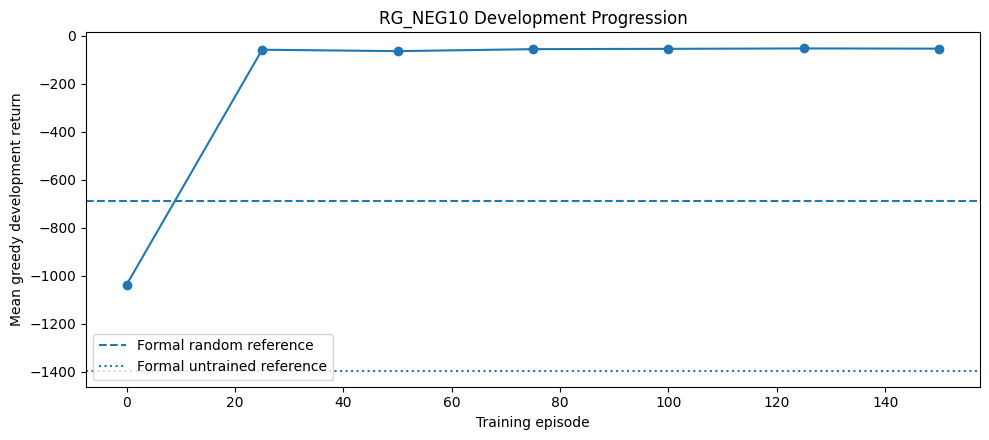

RG_NEG10 training completed: True
Gravity value: -10.0
Selected checkpoint episode: 125
Mean development return: -52.22548184194835
Development return standard deviation: 55.99077614684509
Upright fraction: 0.9029166666666668
Improvement over random: 636.4278502894801
Improvement over untrained: 1343.190164949157
Held-out final suite used: False
Formal runs completed: 26
Remaining formal-run capacity: 2
Saved anti-gravity weights: weights\final_dqn_gneg10.weights.h5
Saved anti-gravity comparison: histories\RG_NEG10_same_gravity_baseline_comparison.csv
Section 18.4 anti-gravity training: COMPLETE


In [87]:
RG_NEG10_RUN_ID = "RG_NEG10"
RG_NEG10_GRAVITY_KEY = "g_neg10"
RG_NEG10_SEED = FROZEN_GRAVITY_TRAINING_SEED

RG_NEG10_WEIGHT_PATH = (
    WEIGHTS_DIR
    / "final_dqn_gneg10.weights.h5"
)
RG_NEG10_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{RG_NEG10_RUN_ID}_history.csv"
)
RG_NEG10_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{RG_NEG10_RUN_ID}"
        "_development_evaluations.csv"
    )
)
RG_NEG10_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{RG_NEG10_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
RG_NEG10_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{RG_NEG10_RUN_ID}_summary.csv"
)
RG_NEG10_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{RG_NEG10_RUN_ID}"
        "_selected_state_results.csv"
    )
)
RG_NEG10_BASELINE_COMPARISON_PATH = (
    HISTORIES_DIR
    / "RG_NEG10_same_gravity_baseline_comparison.csv"
)
RG_NEG10_PAIRED_BASELINE_PATH = (
    HISTORIES_DIR
    / "RG_NEG10_same_gravity_paired_states.csv"
)

assert DEFAULT_GRAVITY_CONFIGURATION_FROZEN is True
assert GRAVITY_STAGE_RELEASED is True
assert HELDOUT_FINAL_SUITE_RELEASED is False
assert NO_FURTHER_TUNING_DECLARED is True
assert RG_NEG10_GRAVITY_KEY in FROZEN_GRAVITY_KEYS
assert RG_NEG10_SEED == 4242
assert FORMAL_RUNS_COMPLETED in (25, 26)
assert remaining_formal_run_capacity in (3, 2)
assert "default" in GRAVITY_TRAINING_RESULTS
assert "g0" in GRAVITY_TRAINING_RESULTS

rg_neg10_required_artifacts = [
    RG_NEG10_WEIGHT_PATH,
    RG_NEG10_HISTORY_PATH,
    RG_NEG10_EVALUATION_PATH,
    RG_NEG10_EVALUATION_SUMMARY_PATH,
    RG_NEG10_SUMMARY_PATH,
    RG_NEG10_STATE_RESULTS_PATH,
]
rg_neg10_artifacts_complete = all(
    path.exists()
    for path in rg_neg10_required_artifacts
)

if (
    "rg_neg10_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "rg_neg10_history",
            "rg_neg10_evaluation_states",
            "rg_neg10_evaluation_summary",
            "rg_neg10_selected_state_results",
            "rg_neg10_summary",
            "rg_neg10_selected_model",
        ]
    )
):
    print(
        "RG_NEG10 already exists in memory; "
        "no duplicate training run was started."
    )
elif rg_neg10_artifacts_complete:
    rg_neg10_history = read_csv_with_control_metric_migration(
        RG_NEG10_HISTORY_PATH
    )
    rg_neg10_evaluation_states = read_csv_with_control_metric_migration(
        RG_NEG10_EVALUATION_PATH
    )
    rg_neg10_evaluation_summary = read_csv_with_control_metric_migration(
        RG_NEG10_EVALUATION_SUMMARY_PATH
    )
    rg_neg10_summary = read_csv_with_control_metric_migration(
        RG_NEG10_SUMMARY_PATH
    )
    rg_neg10_selected_state_results = read_csv_with_control_metric_migration(
        RG_NEG10_STATE_RESULTS_PATH
    )

    assert len(rg_neg10_summary) == 1
    rg_neg10_summary_record = (
        rg_neg10_summary.iloc[0].to_dict()
    )
    rg_neg10_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FROZEN_ACTION_COUNT,
            hidden_units=FROZEN_HIDDEN_UNITS,
            model_name=(
                "rg_neg10_reloaded_q_network"
            ),
        )
    )
    rg_neg10_selected_model.load_weights(
        RG_NEG10_WEIGHT_PATH
    )
    print(
        "Loaded completed RG_NEG10 artifacts; "
        "no duplicate training run was started."
    )
else:
    rg_neg10_result = (
        run_frozen_dueling_gravity_model(
            run_id=RG_NEG10_RUN_ID,
            gravity_key=RG_NEG10_GRAVITY_KEY,
            seed=RG_NEG10_SEED,
            weight_path=RG_NEG10_WEIGHT_PATH,
        )
    )

    rg_neg10_history = (
        rg_neg10_result["history"]
    )
    rg_neg10_evaluation_states = (
        rg_neg10_result[
            "evaluation_states"
        ]
    )
    rg_neg10_evaluation_summary = (
        rg_neg10_result[
            "evaluation_summary"
        ]
    )
    rg_neg10_selected_state_results = (
        rg_neg10_result[
            "selected_state_results"
        ]
    )
    rg_neg10_selected_model = (
        rg_neg10_result[
            "selected_model"
        ]
    )
    rg_neg10_summary_record = dict(
        rg_neg10_result[
            "summary_record"
        ]
    )
    rg_neg10_summary = pd.DataFrame(
        [rg_neg10_summary_record]
    )

FORMAL_RUNS_COMPLETED = 26
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 26
assert remaining_formal_run_capacity == 2
assert len(rg_neg10_history) == (
    FROZEN_TRAINING_EPISODES
)
assert len(rg_neg10_evaluation_summary) == (
    len(FROZEN_EVALUATION_EPISODES)
)
assert int(
    rg_neg10_summary_record["seed"]
) == RG_NEG10_SEED
assert (
    rg_neg10_summary_record["gravity"]
    == RG_NEG10_GRAVITY_KEY
)
assert np.isclose(
    float(
        rg_neg10_summary_record[
            "gravity_value"
        ]
    ),
    -10.0,
    rtol=0.0,
    atol=0.0,
)
assert (
    rg_neg10_summary_record["model"]
    == FROZEN_ARCHITECTURE
)
assert int(
    rg_neg10_summary_record[
        "parameter_count"
    ]
) == FROZEN_PARAMETER_COUNT
assert int(
    rg_neg10_summary_record[
        "environment_steps"
    ]
) == FROZEN_ENVIRONMENT_STEPS
assert int(
    rg_neg10_summary_record[
        "optimizer_updates"
    ]
) == 29_001
assert int(
    rg_neg10_summary_record[
        "target_updates"
    ]
) == 116
assert (
    rg_neg10_summary_record[
        "heldout_suite_used"
    ]
    is False
)
assert RG_NEG10_WEIGHT_PATH.exists()

rg_neg10_history.to_csv(
    RG_NEG10_HISTORY_PATH,
    index=False,
)
rg_neg10_evaluation_states.to_csv(
    RG_NEG10_EVALUATION_PATH,
    index=False,
)
rg_neg10_evaluation_summary.to_csv(
    RG_NEG10_EVALUATION_SUMMARY_PATH,
    index=False,
)
rg_neg10_summary.to_csv(
    RG_NEG10_SUMMARY_PATH,
    index=False,
)
rg_neg10_selected_state_results.to_csv(
    RG_NEG10_STATE_RESULTS_PATH,
    index=False,
)

(
    rg_neg10_baseline_comparison,
    rg_neg10_paired_baselines,
) = compare_frozen_gravity_to_formal_references(
    run_id=RG_NEG10_RUN_ID,
    gravity_key=RG_NEG10_GRAVITY_KEY,
    summary_record=rg_neg10_summary_record,
    selected_state_results=(
        rg_neg10_selected_state_results
    ),
)

rg_neg10_baseline_comparison.to_csv(
    RG_NEG10_BASELINE_COMPARISON_PATH,
    index=False,
)
rg_neg10_paired_baselines.to_csv(
    RG_NEG10_PAIRED_BASELINE_PATH,
    index=False,
)

GRAVITY_TRAINING_RESULTS[
    RG_NEG10_GRAVITY_KEY
] = rg_neg10_summary_record
GRAVITY_TRAINING_STATE_RESULTS[
    RG_NEG10_GRAVITY_KEY
] = rg_neg10_selected_state_results.copy()
GRAVITY_TRAINING_EVALUATION_SUMMARIES[
    RG_NEG10_GRAVITY_KEY
] = rg_neg10_evaluation_summary.copy()
GRAVITY_TRAINING_MODELS[
    RG_NEG10_GRAVITY_KEY
] = rg_neg10_selected_model

display(rg_neg10_baseline_comparison)
display(rg_neg10_evaluation_summary)
display(rg_neg10_summary)

neg10_random_mean = float(
    rg_neg10_baseline_comparison[
        "random_mean_return"
    ].iloc[0]
)
neg10_untrained_mean = float(
    rg_neg10_baseline_comparison[
        "untrained_mean_return"
    ].iloc[0]
)

plt.figure(figsize=(10, 4.5))
plt.plot(
    rg_neg10_evaluation_summary["episode"],
    rg_neg10_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
)
plt.axhline(
    neg10_random_mean,
    linestyle="--",
    label="Formal random reference",
)
plt.axhline(
    neg10_untrained_mean,
    linestyle=":",
    label="Formal untrained reference",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("RG_NEG10 Development Progression")
plt.legend()
plt.tight_layout()
plt.show()

print("RG_NEG10 training completed:", True)
print(
    "Gravity value:",
    rg_neg10_summary_record[
        "gravity_value"
    ],
)
print(
    "Selected checkpoint episode:",
    rg_neg10_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    rg_neg10_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    rg_neg10_summary_record[
        "development_return_std"
    ],
)
print(
    "Upright fraction:",
    rg_neg10_summary_record[
        "upright_fraction"
    ],
)
print(
    "Improvement over random:",
    rg_neg10_baseline_comparison[
        "trained_minus_random"
    ].iloc[0],
)
print(
    "Improvement over untrained:",
    rg_neg10_baseline_comparison[
        "trained_minus_untrained"
    ].iloc[0],
)
print(
    "Held-out final suite used:",
    rg_neg10_summary_record[
        "heldout_suite_used"
    ],
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved anti-gravity weights:",
    RG_NEG10_WEIGHT_PATH,
)
print(
    "Saved anti-gravity comparison:",
    RG_NEG10_BASELINE_COMPARISON_PATH,
)
print("Section 18.4 anti-gravity training: COMPLETE")


### 18.4 Result Interpretation

**Finding.** The fresh anti-gravity model completed successfully:

```text
Gravity: g = -10
Seed: 4242
Selected checkpoint: episode 125
Mean development return: -52.225482
Development-state standard deviation: 55.990776
Upright fraction: 0.902917
```

Against the anti-gravity references, the trained model improved by:

```text
Versus random: +636.427850
Versus untrained network: +1343.190165
```

It won all `24` paired development states against both same-gravity
references. Development performance improved gradually after episode `25`,
with the strongest checkpoint appearing at episode `125`.

**Importance.** The frozen default-tuned configuration also transferred
successfully to anti-gravity without changing the architecture,
hyperparameters or training budget.

**Decision.** Retain the selected `RG_NEG10` episode-`125` checkpoint for the
later held-out anti-gravity evaluation.

**Caveat.** Raw returns must not be compared directly with the default or
zero-gravity models as proof of model superiority because the environment
dynamics and reward difficulty differ.

**Next step.** Train the fourth and final matched model under supergravity,
`g = 15`, using the same frozen configuration and seed.


## 18.5 Supergravity, `g = 15`

Run ID:

```text
RG_15
```

This is a new Dueling DQN trained from fresh weights while gravity remains
fixed at `g = 15` for the entire run.

The model uses the frozen architecture, action set, state representation,
exploration schedule, replay and target settings, optimisation recipe,
training budget, development states, checkpoint rule and matched seed `4242`.

Its selected development checkpoint is compared with the formal random and
untrained references under the same supergravity environment. The held-out
suite remains closed.

This consumes one formal-training slot. After completion, the formal-run count
should be `27`, leaving the single protected contingency slot unused.


Loaded completed RG_15 artifacts; no duplicate training run was started.


,run_id,gravity,gravity_value,seed,trained_mean_return,random_mean_return,untrained_mean_return,trained_minus_random,trained_minus_untrained,trained_random_state_win_rate,trained_untrained_state_win_rate,upright_fraction,development_state_std,selected_checkpoint_episode,heldout_suite_used,selection_deferred_until_review
0,RG_15,g15,15.0,4242,-204.892825,-1416.535605,-1218.881557,1211.642779,1013.988731,1.0,1.0,0.827292,153.696868,125,False,True


,run_id,gravity,episode,mean_development_return,median_development_return,development_return_std,minimum_development_return,maximum_development_return,mean_upright_fraction,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,mean_torque_direction_switching_rate
0,RG_15,g15,0,-1240.224485,-1150.345159,185.421078,-1865.404490,-1075.667775,0.090833,1.667024,4.357063,1.527917,0.015913
1,RG_15,g15,25,-1172.225237,-1160.438643,27.546246,-1233.071091,-1144.052273,0.132917,1.329799,5.284979,1.755417,0.046901
2,RG_15,g15,50,-1172.846290,-1160.151252,35.144306,-1256.796451,-1131.113460,0.142917,1.328085,5.281369,1.846944,0.057789
3,RG_15,g15,75,-1171.259731,-1155.609614,39.241470,-1262.156067,-1130.782648,0.161250,1.320971,5.292858,1.851250,0.037479
4,RG_15,g15,100,-454.924889,-490.573462,282.861594,-918.998640,-8.473091,0.541250,0.724615,1.994697,1.907083,0.161432
5,RG_15,g15,125,-204.892825,-180.047438,153.696868,-473.051209,-1.881145,0.827292,0.345521,0.782152,1.967639,0.698702
6,RG_15,g15,150,-325.844027,-122.810012,502.507761,-1868.742299,-0.425717,0.779167,0.520933,0.628564,0.895139,0.471106


,run_id,model,gravity,gravity_value,seed,action_count,torque_values,episodes,environment_steps,optimizer_updates,...,selected_min_q,random_actions,greedy_actions,target_updates,runtime_minutes,parameter_count,weight_path,technical_status,configuration_status,heldout_suite_used
0,RG_15,Dueling DQN,g15,15.0,4242,7,"[-2.0, -1.3333333730697632, -0.666666686534881...",150,30000,29001,...,-356.937225,10954,19046,116,14.869996,4936,[local path removed] Project Partner\OneDrive\OneDrive - Sing...,PASS,FROZEN,False


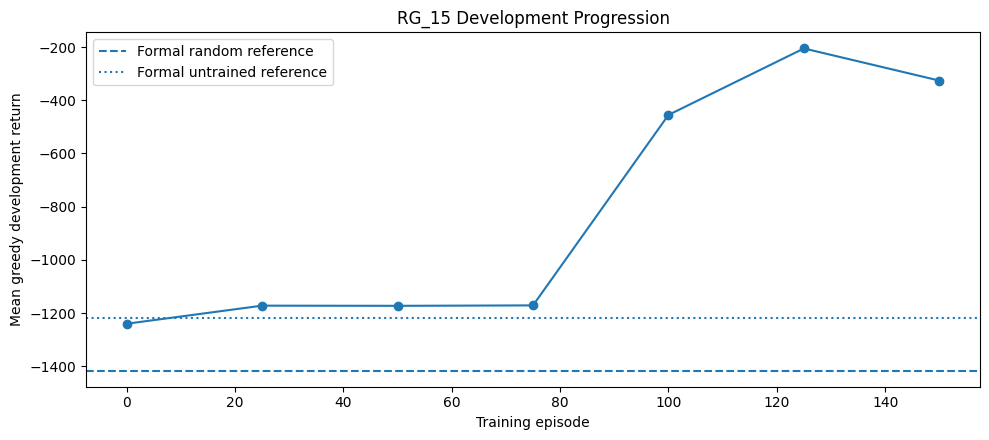

RG_15 training completed: True
Gravity value: 15.0
Selected checkpoint episode: 125
Mean development return: -204.8928251734378
Development return standard deviation: 153.69686769987123
Upright fraction: 0.8272916666666665
Improvement over random: 1211.6427793733035
Improvement over untrained: 1013.988731439312
Held-out final suite used: False
Gravity models completed: ['default', 'g0', 'g15', 'g_neg10']
Formal runs completed: 27
Remaining formal-run capacity: 1
Saved supergravity weights: weights\final_dqn_g15.weights.h5
Saved supergravity comparison: histories\RG_15_same_gravity_baseline_comparison.csv
Section 18.5 supergravity training: COMPLETE


In [88]:
RG_15_RUN_ID = "RG_15"
RG_15_GRAVITY_KEY = "g15"
RG_15_SEED = FROZEN_GRAVITY_TRAINING_SEED

RG_15_WEIGHT_PATH = (
    WEIGHTS_DIR
    / "final_dqn_g15.weights.h5"
)
RG_15_HISTORY_PATH = (
    HISTORIES_DIR
    / f"{RG_15_RUN_ID}_history.csv"
)
RG_15_EVALUATION_PATH = (
    HISTORIES_DIR
    / (
        f"{RG_15_RUN_ID}"
        "_development_evaluations.csv"
    )
)
RG_15_EVALUATION_SUMMARY_PATH = (
    HISTORIES_DIR
    / (
        f"{RG_15_RUN_ID}"
        "_development_evaluation_summary.csv"
    )
)
RG_15_SUMMARY_PATH = (
    HISTORIES_DIR
    / f"{RG_15_RUN_ID}_summary.csv"
)
RG_15_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / (
        f"{RG_15_RUN_ID}"
        "_selected_state_results.csv"
    )
)
RG_15_BASELINE_COMPARISON_PATH = (
    HISTORIES_DIR
    / "RG_15_same_gravity_baseline_comparison.csv"
)
RG_15_PAIRED_BASELINE_PATH = (
    HISTORIES_DIR
    / "RG_15_same_gravity_paired_states.csv"
)

assert DEFAULT_GRAVITY_CONFIGURATION_FROZEN is True
assert GRAVITY_STAGE_RELEASED is True
assert HELDOUT_FINAL_SUITE_RELEASED is False
assert NO_FURTHER_TUNING_DECLARED is True
assert RG_15_GRAVITY_KEY in FROZEN_GRAVITY_KEYS
assert RG_15_SEED == 4242
assert FORMAL_RUNS_COMPLETED in (26, 27)
assert remaining_formal_run_capacity in (2, 1)
assert "default" in GRAVITY_TRAINING_RESULTS
assert "g0" in GRAVITY_TRAINING_RESULTS
assert "g_neg10" in GRAVITY_TRAINING_RESULTS

rg_15_required_artifacts = [
    RG_15_WEIGHT_PATH,
    RG_15_HISTORY_PATH,
    RG_15_EVALUATION_PATH,
    RG_15_EVALUATION_SUMMARY_PATH,
    RG_15_SUMMARY_PATH,
    RG_15_STATE_RESULTS_PATH,
]
rg_15_artifacts_complete = all(
    path.exists()
    for path in rg_15_required_artifacts
)

if (
    "rg_15_summary_record" in globals()
    and all(
        name in globals()
        for name in [
            "rg_15_history",
            "rg_15_evaluation_states",
            "rg_15_evaluation_summary",
            "rg_15_selected_state_results",
            "rg_15_summary",
            "rg_15_selected_model",
        ]
    )
):
    print(
        "RG_15 already exists in memory; "
        "no duplicate training run was started."
    )
elif rg_15_artifacts_complete:
    rg_15_history = read_csv_with_control_metric_migration(
        RG_15_HISTORY_PATH
    )
    rg_15_evaluation_states = read_csv_with_control_metric_migration(
        RG_15_EVALUATION_PATH
    )
    rg_15_evaluation_summary = read_csv_with_control_metric_migration(
        RG_15_EVALUATION_SUMMARY_PATH
    )
    rg_15_summary = read_csv_with_control_metric_migration(
        RG_15_SUMMARY_PATH
    )
    rg_15_selected_state_results = read_csv_with_control_metric_migration(
        RG_15_STATE_RESULTS_PATH
    )

    assert len(rg_15_summary) == 1
    rg_15_summary_record = (
        rg_15_summary.iloc[0].to_dict()
    )
    rg_15_selected_model = (
        build_dueling_q_network(
            state_dim=DQN_STATE_DIM,
            action_count=FROZEN_ACTION_COUNT,
            hidden_units=FROZEN_HIDDEN_UNITS,
            model_name=(
                "rg_15_reloaded_q_network"
            ),
        )
    )
    rg_15_selected_model.load_weights(
        RG_15_WEIGHT_PATH
    )
    print(
        "Loaded completed RG_15 artifacts; "
        "no duplicate training run was started."
    )
else:
    rg_15_result = (
        run_frozen_dueling_gravity_model(
            run_id=RG_15_RUN_ID,
            gravity_key=RG_15_GRAVITY_KEY,
            seed=RG_15_SEED,
            weight_path=RG_15_WEIGHT_PATH,
        )
    )

    rg_15_history = (
        rg_15_result["history"]
    )
    rg_15_evaluation_states = (
        rg_15_result[
            "evaluation_states"
        ]
    )
    rg_15_evaluation_summary = (
        rg_15_result[
            "evaluation_summary"
        ]
    )
    rg_15_selected_state_results = (
        rg_15_result[
            "selected_state_results"
        ]
    )
    rg_15_selected_model = (
        rg_15_result[
            "selected_model"
        ]
    )
    rg_15_summary_record = dict(
        rg_15_result[
            "summary_record"
        ]
    )
    rg_15_summary = pd.DataFrame(
        [rg_15_summary_record]
    )

FORMAL_RUNS_COMPLETED = 27
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

assert FORMAL_RUNS_COMPLETED == 27
assert remaining_formal_run_capacity == 1
assert len(rg_15_history) == (
    FROZEN_TRAINING_EPISODES
)
assert len(rg_15_evaluation_summary) == (
    len(FROZEN_EVALUATION_EPISODES)
)
assert int(
    rg_15_summary_record["seed"]
) == RG_15_SEED
assert (
    rg_15_summary_record["gravity"]
    == RG_15_GRAVITY_KEY
)
assert np.isclose(
    float(
        rg_15_summary_record[
            "gravity_value"
        ]
    ),
    15.0,
    rtol=0.0,
    atol=0.0,
)
assert (
    rg_15_summary_record["model"]
    == FROZEN_ARCHITECTURE
)
assert int(
    rg_15_summary_record[
        "parameter_count"
    ]
) == FROZEN_PARAMETER_COUNT
assert int(
    rg_15_summary_record[
        "environment_steps"
    ]
) == FROZEN_ENVIRONMENT_STEPS
assert int(
    rg_15_summary_record[
        "optimizer_updates"
    ]
) == 29_001
assert int(
    rg_15_summary_record[
        "target_updates"
    ]
) == 116
assert (
    rg_15_summary_record[
        "heldout_suite_used"
    ]
    is False
)
assert RG_15_WEIGHT_PATH.exists()

rg_15_history.to_csv(
    RG_15_HISTORY_PATH,
    index=False,
)
rg_15_evaluation_states.to_csv(
    RG_15_EVALUATION_PATH,
    index=False,
)
rg_15_evaluation_summary.to_csv(
    RG_15_EVALUATION_SUMMARY_PATH,
    index=False,
)
rg_15_summary.to_csv(
    RG_15_SUMMARY_PATH,
    index=False,
)
rg_15_selected_state_results.to_csv(
    RG_15_STATE_RESULTS_PATH,
    index=False,
)

(
    rg_15_baseline_comparison,
    rg_15_paired_baselines,
) = compare_frozen_gravity_to_formal_references(
    run_id=RG_15_RUN_ID,
    gravity_key=RG_15_GRAVITY_KEY,
    summary_record=rg_15_summary_record,
    selected_state_results=(
        rg_15_selected_state_results
    ),
)

rg_15_baseline_comparison.to_csv(
    RG_15_BASELINE_COMPARISON_PATH,
    index=False,
)
rg_15_paired_baselines.to_csv(
    RG_15_PAIRED_BASELINE_PATH,
    index=False,
)

GRAVITY_TRAINING_RESULTS[
    RG_15_GRAVITY_KEY
] = rg_15_summary_record
GRAVITY_TRAINING_STATE_RESULTS[
    RG_15_GRAVITY_KEY
] = rg_15_selected_state_results.copy()
GRAVITY_TRAINING_EVALUATION_SUMMARIES[
    RG_15_GRAVITY_KEY
] = rg_15_evaluation_summary.copy()
GRAVITY_TRAINING_MODELS[
    RG_15_GRAVITY_KEY
] = rg_15_selected_model

display(rg_15_baseline_comparison)
display(rg_15_evaluation_summary)
display(rg_15_summary)

g15_random_mean = float(
    rg_15_baseline_comparison[
        "random_mean_return"
    ].iloc[0]
)
g15_untrained_mean = float(
    rg_15_baseline_comparison[
        "untrained_mean_return"
    ].iloc[0]
)

plt.figure(figsize=(10, 4.5))
plt.plot(
    rg_15_evaluation_summary["episode"],
    rg_15_evaluation_summary[
        "mean_development_return"
    ],
    marker="o",
)
plt.axhline(
    g15_random_mean,
    linestyle="--",
    label="Formal random reference",
)
plt.axhline(
    g15_untrained_mean,
    linestyle=":",
    label="Formal untrained reference",
)
plt.xlabel("Training episode")
plt.ylabel("Mean greedy development return")
plt.title("RG_15 Development Progression")
plt.legend()
plt.tight_layout()
plt.show()

print("RG_15 training completed:", True)
print(
    "Gravity value:",
    rg_15_summary_record[
        "gravity_value"
    ],
)
print(
    "Selected checkpoint episode:",
    rg_15_summary_record[
        "selected_checkpoint_episode"
    ],
)
print(
    "Mean development return:",
    rg_15_summary_record[
        "mean_development_return"
    ],
)
print(
    "Development return standard deviation:",
    rg_15_summary_record[
        "development_return_std"
    ],
)
print(
    "Upright fraction:",
    rg_15_summary_record[
        "upright_fraction"
    ],
)
print(
    "Improvement over random:",
    rg_15_baseline_comparison[
        "trained_minus_random"
    ].iloc[0],
)
print(
    "Improvement over untrained:",
    rg_15_baseline_comparison[
        "trained_minus_untrained"
    ].iloc[0],
)
print(
    "Held-out final suite used:",
    rg_15_summary_record[
        "heldout_suite_used"
    ],
)
print(
    "Gravity models completed:",
    sorted(
        GRAVITY_TRAINING_RESULTS.keys()
    ),
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved supergravity weights:",
    RG_15_WEIGHT_PATH,
)
print(
    "Saved supergravity comparison:",
    RG_15_BASELINE_COMPARISON_PATH,
)
print("Section 18.5 supergravity training: COMPLETE")


### 18.5 Result Interpretation

**Finding.** The fresh supergravity model completed successfully:

```text
Gravity: g = 15
Seed: 4242
Selected checkpoint: episode 125
Mean development return: -204.892825
Development-state standard deviation: 153.696868
Upright fraction: 0.827292
```

Against the supergravity references, the trained model improved by:

```text
Versus random: +1211.642779
Versus untrained network: +1013.988731
```

It won all `24` paired development states against both same-gravity
references. Learning was slower than under the other gravity settings:
development return remained near `-1172` through episode `75`, then improved
substantially at episodes `100` and `125`.

**Importance.** The frozen default-tuned configuration remains viable under
the stronger downward gravity, although control is more difficult and less
stable than under the other trained gravity conditions.

**Decision.** Retain the selected `RG_15` episode-`125` checkpoint for the
later held-out supergravity evaluation.

**Caveat.** The final episode-`150` checkpoint deteriorated to `-325.844027`
with much larger state-wise spread. This is reported as late-training
instability, not hidden by using the selected development checkpoint.

**Next step.** Compare all four frozen gravity models against their own
same-gravity references, decide whether any extra gravity run or adaptation is
necessary, and only then approve release of the held-out suite.


## 18.6 Same-Gravity Baseline Improvements

Each trained model is compared only with the random and untrained references
from the same gravity. This avoids treating a change in environment physics as
if it were a model improvement.

The comparison reports:

- trained return and same-gravity reference returns;
- improvement over each reference;
- paired-state win rates;
- upright fraction and control metrics;
- selected checkpoint and late-checkpoint degradation.

## 18.7 Gravity Comparison

Raw returns across gravity settings are shown for context but are **not**
treated as a direct ranking of model quality. The main gravity evidence is:

1. improvement over same-gravity references;
2. paired-state wins within the same environment;
3. upright behaviour and state-wise robustness;
4. learning progression and checkpoint stability.

## 18.8 Conditional Environment-Specific Adaptation

Adaptation or an extra gravity seed is permitted only if a technically valid
result is unstable enough to change the gravity conclusion.

The supergravity run shows late degradation, but its selected checkpoint still
beats both same-gravity references by more than `1000` return points and wins
all paired development states. The central conclusion therefore does not
depend on a marginal result.

The planned decision is:

```text
Second gravity seed: not activated
Environment-specific adaptation: not activated
Contingency slot: preserved
Held-out suite release: approved after this gate passes
```


**Figure interpretation guide:** Gravity figures compare each trained policy with random and untrained references under the same gravity. Raw returns across different gravities are not treated as a direct difficulty ranking.


,gravity_key,gravity_label,gravity_value,run_id,seed,selected_checkpoint_episode,trained_mean_return,random_mean_return,untrained_mean_return,trained_minus_random,...,mean_abs_angular_velocity,mean_abs_torque,torque_direction_switching_rate,final_episode_mean_return,final_minus_selected_return,late_degradation_beyond_margin,runtime_minutes,technical_status,heldout_suite_used,raw_cross_gravity_ranking_allowed
0,default,"Default, g = 10",10.0,RG_DEFAULT,4242,50,-144.352853,-1211.262378,-1518.751911,1066.909525,...,0.569867,1.676806,0.584171,-146.463862,-2.111010,False,17.755603,PASS,False,False
1,g0,"Zero gravity, g = 0",0.0,RG_ZERO,4242,50,-48.096170,-790.762709,-1371.854050,742.666540,...,0.276000,1.538889,0.734087,-54.518798,-6.422629,False,20.075974,PASS,False,False
2,g_neg10,"Anti-gravity, g = -10",-10.0,RG_NEG10,4242,125,-52.225482,-688.653332,-1395.415647,636.427850,...,0.349135,0.266111,0.045017,-53.068869,-0.843387,False,13.791744,PASS,False,False
3,g15,"Supergravity, g = 15",15.0,RG_15,4242,125,-204.892825,-1416.535605,-1218.881557,1211.642779,...,0.782152,1.967639,0.698702,-325.844027,-120.951202,True,14.869996,PASS,False,False


,gravity_models_completed,matched_seed,all_models_technically_valid,all_models_beat_random_reference,all_models_beat_untrained_reference,all_models_win_every_paired_state_against_random,all_models_win_every_paired_state_against_untrained,supergravity_late_degradation_recorded,supergravity_selected_minus_final_return,second_gravity_seed_approved,environment_specific_adaptation_approved,reason_no_extra_run,contingency_run_used,remaining_formal_run_capacity,gravity_development_stage_locked,heldout_final_suite_release_approved,heldout_final_suite_released,formal_significance_claim,raw_cross_gravity_return_ranking,selection_status
0,4,4242,True,True,True,True,True,True,120.951202,False,False,All four selected checkpoints clearly beat bot...,False,1,True,True,False,False,False,LOCKED FOR HELD-OUT FINAL EVALUATION


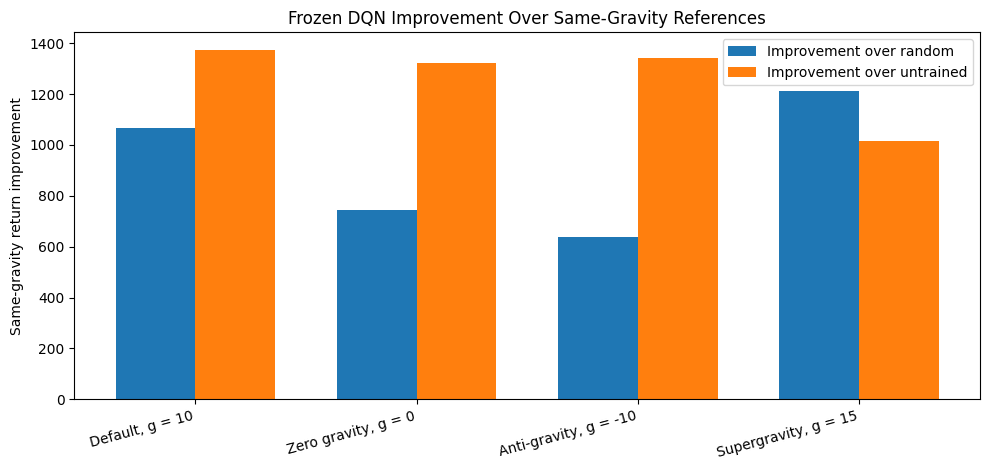

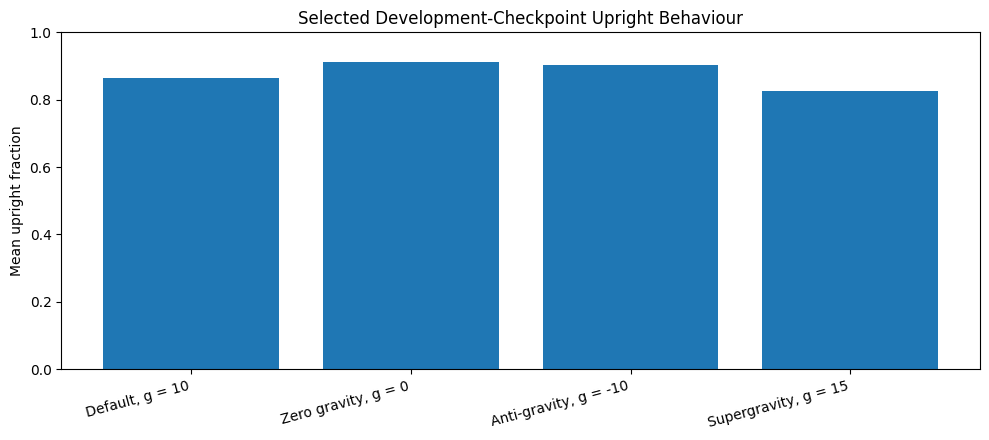

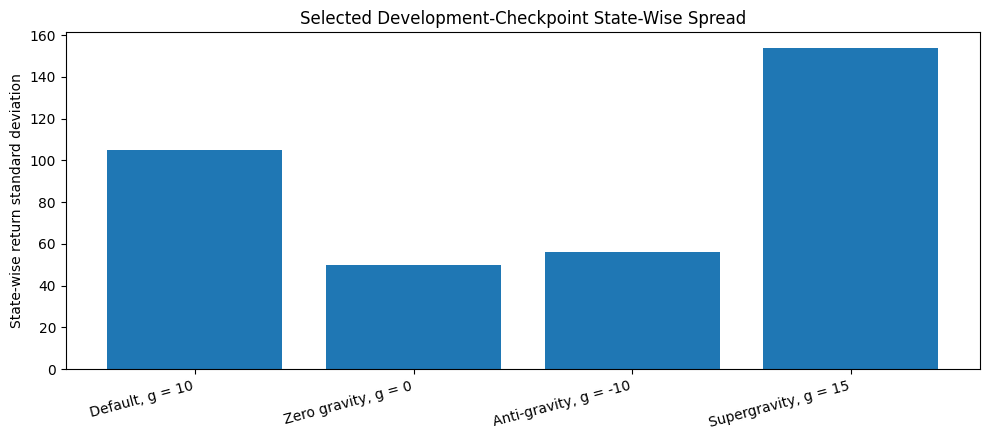

Gravity models completed: ['RG_DEFAULT', 'RG_ZERO', 'RG_NEG10', 'RG_15']
All models beat random: True
All models beat untrained: True
All trained-reference paired-state win rates: [[1.0, 1.0], [1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]
Supergravity late degradation recorded: True
Second gravity seed approved: False
Environment-specific adaptation approved: False
Contingency run used: False
Held-out final suite release approved: True
Held-out final suite released: False
Remaining formal-run capacity: 1
Saved gravity comparison: histories\RG_four_gravity_development_comparison.csv
Saved gravity-stage decision: histories\RG_four_gravity_stage_decision.csv
Section 18.6 same-gravity baseline improvements: PASS
Section 18.7 gravity comparison: PASS
Section 18.8 conditional adaptation decision: PASS


In [89]:
GRAVITY_DEVELOPMENT_COMPARISON_PATH = (
    HISTORIES_DIR
    / "RG_four_gravity_development_comparison.csv"
)
GRAVITY_DEVELOPMENT_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / "RG_four_gravity_development_state_results.csv"
)
GRAVITY_STAGE_DECISION_PATH = (
    HISTORIES_DIR
    / "RG_four_gravity_stage_decision.csv"
)

assert DEFAULT_GRAVITY_CONFIGURATION_FROZEN is True
assert GRAVITY_STAGE_RELEASED is True
assert HELDOUT_FINAL_SUITE_RELEASED is False
assert NO_FURTHER_TUNING_DECLARED is True
assert FORMAL_RUNS_COMPLETED == 27
assert remaining_formal_run_capacity == 1
assert set(
    GRAVITY_TRAINING_RESULTS.keys()
) == set(FROZEN_GRAVITY_KEYS)
assert set(
    GRAVITY_TRAINING_STATE_RESULTS.keys()
) == set(FROZEN_GRAVITY_KEYS)
assert set(
    GRAVITY_TRAINING_EVALUATION_SUMMARIES.keys()
) == set(FROZEN_GRAVITY_KEYS)
assert set(
    GRAVITY_TRAINING_MODELS.keys()
) == set(FROZEN_GRAVITY_KEYS)

gravity_order = [
    "default",
    "g0",
    "g_neg10",
    "g15",
]
gravity_labels = {
    "default": "Default, g = 10",
    "g0": "Zero gravity, g = 0",
    "g_neg10": "Anti-gravity, g = -10",
    "g15": "Supergravity, g = 15",
}
gravity_baseline_frames = {
    "default": rg_default_baseline_comparison,
    "g0": rg_zero_baseline_comparison,
    "g_neg10": rg_neg10_baseline_comparison,
    "g15": rg_15_baseline_comparison,
}
gravity_paired_frames = {
    "default": rg_default_paired_baselines,
    "g0": rg_zero_paired_baselines,
    "g_neg10": rg_neg10_paired_baselines,
    "g15": rg_15_paired_baselines,
}
gravity_weight_paths = {
    "default": RG_DEFAULT_WEIGHT_PATH,
    "g0": RG_ZERO_WEIGHT_PATH,
    "g_neg10": RG_NEG10_WEIGHT_PATH,
    "g15": RG_15_WEIGHT_PATH,
}

gravity_comparison_records = []
gravity_state_frames = []

for gravity_key in gravity_order:
    summary_record = GRAVITY_TRAINING_RESULTS[
        gravity_key
    ]
    baseline_record = (
        gravity_baseline_frames[
            gravity_key
        ].iloc[0].to_dict()
    )
    paired = gravity_paired_frames[
        gravity_key
    ].copy()
    evaluation_summary = (
        GRAVITY_TRAINING_EVALUATION_SUMMARIES[
            gravity_key
        ]
    )
    selected_states = (
        GRAVITY_TRAINING_STATE_RESULTS[
            gravity_key
        ].copy()
    )

    assert int(summary_record["seed"]) == (
        FROZEN_GRAVITY_TRAINING_SEED
    )
    assert summary_record["technical_status"] == "PASS"
    assert (
        summary_record["configuration_status"]
        == "FROZEN"
    )
    assert summary_record["heldout_suite_used"] is False
    assert len(selected_states) == (
        FROZEN_DEVELOPMENT_STATE_COUNT
    )
    assert len(paired) == (
        FROZEN_DEVELOPMENT_STATE_COUNT
    )
    assert gravity_weight_paths[
        gravity_key
    ].exists()

    final_evaluation_row = (
        evaluation_summary.loc[
            evaluation_summary["episode"]
            == FROZEN_TRAINING_EPISODES
        ].iloc[0]
    )
    final_minus_selected = float(
        final_evaluation_row[
            "mean_development_return"
        ]
        - summary_record[
            "mean_development_return"
        ]
    )

    selected_states.insert(
        0,
        "gravity_label",
        gravity_labels[gravity_key],
    )
    selected_states.insert(
        0,
        "gravity_key",
        gravity_key,
    )
    gravity_state_frames.append(
        selected_states
    )

    gravity_comparison_records.append({
        "gravity_key": gravity_key,
        "gravity_label": (
            gravity_labels[gravity_key]
        ),
        "gravity_value": float(
            summary_record["gravity_value"]
        ),
        "run_id": summary_record["run_id"],
        "seed": int(summary_record["seed"]),
        "selected_checkpoint_episode": int(
            summary_record[
                "selected_checkpoint_episode"
            ]
        ),
        "trained_mean_return": float(
            summary_record[
                "mean_development_return"
            ]
        ),
        "random_mean_return": float(
            baseline_record[
                "random_mean_return"
            ]
        ),
        "untrained_mean_return": float(
            baseline_record[
                "untrained_mean_return"
            ]
        ),
        "trained_minus_random": float(
            baseline_record[
                "trained_minus_random"
            ]
        ),
        "trained_minus_untrained": float(
            baseline_record[
                "trained_minus_untrained"
            ]
        ),
        "trained_random_state_win_rate": float(
            baseline_record[
                "trained_random_state_win_rate"
            ]
        ),
        "trained_untrained_state_win_rate": float(
            baseline_record[
                "trained_untrained_state_win_rate"
            ]
        ),
        "median_trained_minus_random": float(
            paired[
                "trained_minus_random"
            ].median()
        ),
        "median_trained_minus_untrained": float(
            paired[
                "trained_minus_untrained"
            ].median()
        ),
        "minimum_trained_minus_random": float(
            paired[
                "trained_minus_random"
            ].min()
        ),
        "minimum_trained_minus_untrained": float(
            paired[
                "trained_minus_untrained"
            ].min()
        ),
        "development_state_std": float(
            summary_record[
                "development_return_std"
            ]
        ),
        "upright_fraction": float(
            summary_record[
                "upright_fraction"
            ]
        ),
        "mean_abs_angle": float(
            summary_record[
                "mean_abs_angle"
            ]
        ),
        "mean_abs_angular_velocity": float(
            summary_record[
                "mean_abs_angular_velocity"
            ]
        ),
        "mean_abs_torque": float(
            summary_record[
                "mean_abs_torque"
            ]
        ),
        "torque_direction_switching_rate": float(
            summary_record[
                "torque_direction_switching_rate"
            ]
        ),
        "final_episode_mean_return": float(
            final_evaluation_row[
                "mean_development_return"
            ]
        ),
        "final_minus_selected_return": (
            final_minus_selected
        ),
        "late_degradation_beyond_margin": bool(
            final_minus_selected
            < -PRACTICAL_IMPROVEMENT_MARGIN
        ),
        "runtime_minutes": float(
            summary_record[
                "runtime_minutes"
            ]
        ),
        "technical_status": (
            summary_record[
                "technical_status"
            ]
        ),
        "heldout_suite_used": False,
        "raw_cross_gravity_ranking_allowed": False,
    })

gravity_development_comparison = pd.DataFrame(
    gravity_comparison_records
)
gravity_development_comparison[
    "gravity_order"
] = gravity_development_comparison[
    "gravity_key"
].map({
    key: index
    for index, key in enumerate(gravity_order)
})
gravity_development_comparison = (
    gravity_development_comparison
    .sort_values("gravity_order")
    .drop(columns="gravity_order")
    .reset_index(drop=True)
)

gravity_development_state_results = pd.concat(
    gravity_state_frames,
    ignore_index=True,
)

assert len(gravity_development_comparison) == 4
assert len(
    gravity_development_state_results
) == 4 * FROZEN_DEVELOPMENT_STATE_COUNT
assert gravity_development_comparison[
    "gravity_key"
].tolist() == gravity_order
assert (
    gravity_development_comparison[
        "seed"
    ] == FROZEN_GRAVITY_TRAINING_SEED
).all()
assert (
    gravity_development_comparison[
        "technical_status"
    ] == "PASS"
).all()
assert (
    gravity_development_comparison[
        "heldout_suite_used"
    ] == False
).all()
assert (
    gravity_development_comparison[
        "trained_minus_random"
    ] > 0.0
).all()
assert (
    gravity_development_comparison[
        "trained_minus_untrained"
    ] > 0.0
).all()
assert (
    gravity_development_comparison[
        "trained_random_state_win_rate"
    ] == 1.0
).all()
assert (
    gravity_development_comparison[
        "trained_untrained_state_win_rate"
    ] == 1.0
).all()
assert (
    gravity_development_comparison[
        "minimum_trained_minus_random"
    ] > 0.0
).all()
assert (
    gravity_development_comparison[
        "minimum_trained_minus_untrained"
    ] > 0.0
).all()
assert (
    gravity_development_comparison[
        "raw_cross_gravity_ranking_allowed"
    ] == False
).all()

supergravity_row = (
    gravity_development_comparison.loc[
        gravity_development_comparison[
            "gravity_key"
        ] == "g15"
    ].iloc[0]
)

SUPERGRAVITY_LATE_DEGRADATION_RECORDED = bool(
    supergravity_row[
        "late_degradation_beyond_margin"
    ]
)
SECOND_GRAVITY_SEED_APPROVED = False
ENVIRONMENT_SPECIFIC_ADAPTATION_APPROVED = False
GRAVITY_DEVELOPMENT_STAGE_LOCKED = True
HELDOUT_FINAL_SUITE_RELEASE_APPROVED = True
CONTINGENCY_RUN_USED = False

gravity_stage_decision_record = {
    "gravity_models_completed": 4,
    "matched_seed": (
        FROZEN_GRAVITY_TRAINING_SEED
    ),
    "all_models_technically_valid": True,
    "all_models_beat_random_reference": True,
    "all_models_beat_untrained_reference": True,
    "all_models_win_every_paired_state_against_random": True,
    "all_models_win_every_paired_state_against_untrained": True,
    "supergravity_late_degradation_recorded": (
        SUPERGRAVITY_LATE_DEGRADATION_RECORDED
    ),
    "supergravity_selected_minus_final_return": float(
        -supergravity_row[
            "final_minus_selected_return"
        ]
    ),
    "second_gravity_seed_approved": (
        SECOND_GRAVITY_SEED_APPROVED
    ),
    "environment_specific_adaptation_approved": (
        ENVIRONMENT_SPECIFIC_ADAPTATION_APPROVED
    ),
    "reason_no_extra_run": (
        "All four selected checkpoints clearly beat both "
        "same-gravity references on every development state. "
        "The supergravity late degradation is retained as a "
        "stability limitation but does not change the viability "
        "conclusion."
    ),
    "contingency_run_used": CONTINGENCY_RUN_USED,
    "remaining_formal_run_capacity": (
        remaining_formal_run_capacity
    ),
    "gravity_development_stage_locked": (
        GRAVITY_DEVELOPMENT_STAGE_LOCKED
    ),
    "heldout_final_suite_release_approved": (
        HELDOUT_FINAL_SUITE_RELEASE_APPROVED
    ),
    "heldout_final_suite_released": (
        HELDOUT_FINAL_SUITE_RELEASED
    ),
    "formal_significance_claim": False,
    "raw_cross_gravity_return_ranking": False,
    "selection_status": (
        "LOCKED FOR HELD-OUT FINAL EVALUATION"
    ),
}

gravity_stage_decision = pd.DataFrame(
    [gravity_stage_decision_record]
)

assert SUPERGRAVITY_LATE_DEGRADATION_RECORDED is True
assert SECOND_GRAVITY_SEED_APPROVED is False
assert (
    ENVIRONMENT_SPECIFIC_ADAPTATION_APPROVED
    is False
)
assert GRAVITY_DEVELOPMENT_STAGE_LOCKED is True
assert HELDOUT_FINAL_SUITE_RELEASE_APPROVED is True
assert CONTINGENCY_RUN_USED is False
assert HELDOUT_FINAL_SUITE_RELEASED is False
assert remaining_formal_run_capacity == 1

gravity_development_comparison.to_csv(
    GRAVITY_DEVELOPMENT_COMPARISON_PATH,
    index=False,
)
gravity_development_state_results.to_csv(
    GRAVITY_DEVELOPMENT_STATE_RESULTS_PATH,
    index=False,
)
gravity_stage_decision.to_csv(
    GRAVITY_STAGE_DECISION_PATH,
    index=False,
)

display(gravity_development_comparison)
display(gravity_stage_decision)

x_positions = np.arange(
    len(gravity_development_comparison)
)
bar_width = 0.36

plt.figure(figsize=(10, 4.8))
plt.bar(
    x_positions - bar_width / 2,
    gravity_development_comparison[
        "trained_minus_random"
    ],
    width=bar_width,
    label="Improvement over random",
)
plt.bar(
    x_positions + bar_width / 2,
    gravity_development_comparison[
        "trained_minus_untrained"
    ],
    width=bar_width,
    label="Improvement over untrained",
)
plt.xticks(
    x_positions,
    gravity_development_comparison[
        "gravity_label"
    ],
    rotation=15,
    ha="right",
)
plt.ylabel("Same-gravity return improvement")
plt.title(
    "Frozen DQN Improvement Over Same-Gravity References"
)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.bar(
    gravity_development_comparison[
        "gravity_label"
    ],
    gravity_development_comparison[
        "upright_fraction"
    ],
)
plt.xticks(rotation=15, ha="right")
plt.ylabel("Mean upright fraction")
plt.ylim(0.0, 1.0)
plt.title(
    "Selected Development-Checkpoint Upright Behaviour"
)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.bar(
    gravity_development_comparison[
        "gravity_label"
    ],
    gravity_development_comparison[
        "development_state_std"
    ],
)
plt.xticks(rotation=15, ha="right")
plt.ylabel("State-wise return standard deviation")
plt.title(
    "Selected Development-Checkpoint State-Wise Spread"
)
plt.tight_layout()
plt.show()

print(
    "Gravity models completed:",
    gravity_development_comparison[
        "run_id"
    ].tolist(),
)
print(
    "All models beat random:",
    bool(
        (
            gravity_development_comparison[
                "trained_minus_random"
            ] > 0.0
        ).all()
    ),
)
print(
    "All models beat untrained:",
    bool(
        (
            gravity_development_comparison[
                "trained_minus_untrained"
            ] > 0.0
        ).all()
    ),
)
print(
    "All trained-reference paired-state win rates:",
    gravity_development_comparison[
        [
            "trained_random_state_win_rate",
            "trained_untrained_state_win_rate",
        ]
    ].to_numpy().tolist(),
)
print(
    "Supergravity late degradation recorded:",
    SUPERGRAVITY_LATE_DEGRADATION_RECORDED,
)
print(
    "Second gravity seed approved:",
    SECOND_GRAVITY_SEED_APPROVED,
)
print(
    "Environment-specific adaptation approved:",
    ENVIRONMENT_SPECIFIC_ADAPTATION_APPROVED,
)
print(
    "Contingency run used:",
    CONTINGENCY_RUN_USED,
)
print(
    "Held-out final suite release approved:",
    HELDOUT_FINAL_SUITE_RELEASE_APPROVED,
)
print(
    "Held-out final suite released:",
    HELDOUT_FINAL_SUITE_RELEASED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved gravity comparison:",
    GRAVITY_DEVELOPMENT_COMPARISON_PATH,
)
print(
    "Saved gravity-stage decision:",
    GRAVITY_STAGE_DECISION_PATH,
)
print(
    "Section 18.6 same-gravity baseline improvements: PASS"
)
print("Section 18.7 gravity comparison: PASS")
print(
    "Section 18.8 conditional adaptation decision: PASS"
)


### 18.6 to 18.8 Result Interpretation

**Finding.** All four frozen gravity-specific Dueling DQN policies completed
successfully and beat both same-gravity references on every development
state.

The selected development results were:

| Gravity | Selected episode | Mean return | Upright fraction |
|---|---:|---:|---:|
| Default, `g = 10` | 50 | `-144.352853` | `0.864167` |
| Zero gravity, `g = 0` | 50 | `-48.096170` | `0.910625` |
| Anti-gravity, `g = -10` | 125 | `-52.225482` | `0.902917` |
| Supergravity, `g = 15` | 125 | `-204.892825` | `0.827292` |

**Importance.** The frozen configuration is viable under every required
gravity. Raw returns are not ranked directly across gravities because each
gravity changes the environment dynamics and reward experience.

**Stability limitation.** The supergravity policy declined from
`-204.892825` at its selected episode to `-325.844027` at episode `150`.
This late degradation is retained as a limitation rather than hidden by the
selected checkpoint.

**Decision.** No second gravity seed or environment-specific adaptation is
approved. Every selected checkpoint already beats the random and untrained
same-gravity policies on all `24` development states, so the remaining
contingency run is preserved.

**Next step.** Release the protected held-out physical-state suite once,
evaluate all four frozen policies and make no further tuning decisions.


# 19. Held-Out Final Evaluation

## 19.1 Final Suite Release

The held-out suite contains `24` physical states that were kept separate from
all training, checkpoint selection and development comparisons.

The suite is released only after:

- the default-gravity configuration is frozen;
- all four matched gravity policies are trained;
- the gravity development stage is locked;
- no further tuning has been declared.

## 19.2 to 19.5 Gravity-Specific Final Evaluation

Each frozen gravity policy is reconstructed from its saved selected weights
and evaluated greedily under its corresponding gravity.

For every gravity, the trained policy is compared with:

- the reproducible seven-action random policy;
- the fixed untrained seven-action Q-network.

The comparisons use the same held-out physical states and the same
`200`-step evaluation horizon.

## 19.6 Final Paired and Gravity-Specific Results

Report return, state-wise spread, upright behaviour, angle, angular velocity,
torque use and paired improvements over both same-gravity references.

Raw return alone must not be used to rank different gravity environments.

## 19.7 No-Tuning Confirmation

Opening this suite cannot trigger architecture, hyperparameter, checkpoint or
metric changes. Weak final outcomes remain part of the submitted evidence.


**Figure interpretation guide:** The final figures use physical states that were not used for tuning or checkpoint selection. They support generalisation within each gravity condition and cannot trigger further tuning.


,gravity_key,gravity_label,gravity_value,run_id,seed,selected_checkpoint_episode,heldout_states,mean_heldout_return,median_heldout_return,heldout_return_std,...,minimum_trained_minus_untrained,development_mean_return,heldout_minus_development,beats_random_on_mean,beats_untrained_on_mean,technical_status,heldout_suite_used,no_tuning_after_release,raw_cross_gravity_ranking_allowed,formal_significance_claim
0,default,"Default, g = 10",10.0,RG_DEFAULT,4242,50,24,-135.383892,-122.349626,110.667293,...,1029.935719,-144.352853,8.968961,True,True,PASS,True,True,False,False
1,g0,"Zero gravity, g = 0",0.0,RG_ZERO,4242,50,24,-53.772390,-35.287926,51.589765,...,435.328750,-48.096170,-5.676221,True,True,PASS,True,True,False,False
2,g_neg10,"Anti-gravity, g = -10",-10.0,RG_NEG10,4242,125,24,-53.369357,-45.041858,52.170856,...,836.070969,-52.225482,-1.143875,True,True,PASS,True,True,False,False
3,g15,"Supergravity, g = 15",15.0,RG_15,4242,125,24,-203.310855,-214.596055,144.967106,...,795.387478,-204.892825,1.581970,True,True,PASS,True,True,False,False


,heldout_release_approved,heldout_suite_released,release_point,release_reason,gravity_policies_evaluated,heldout_states_per_gravity,final_evaluation_complete,no_tuning_after_release,formal_training_runs_added,formal_runs_completed,remaining_formal_run_capacity,selection_status
0,True,True,after_gravity_freeze,All four frozen gravity policies completed dev...,4,24,True,True,0,27,1,LOCKED FOR FINAL ARTIFACT VERIFICATION


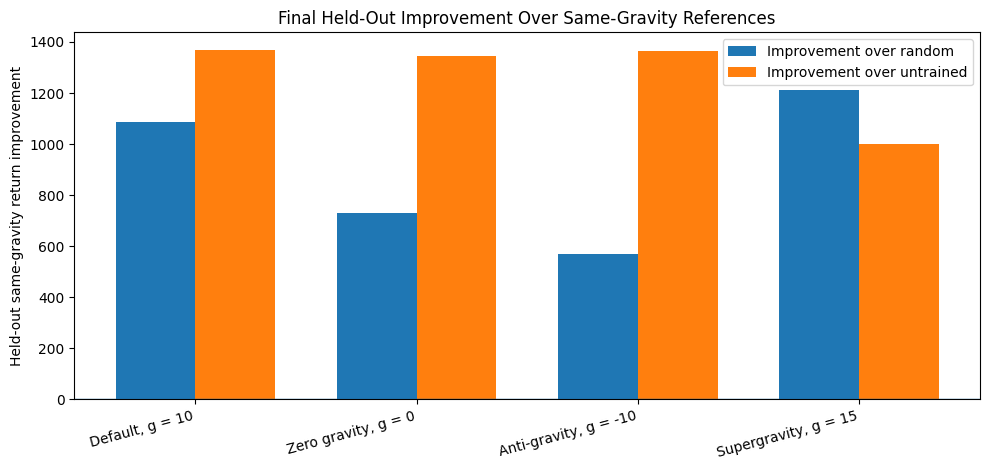

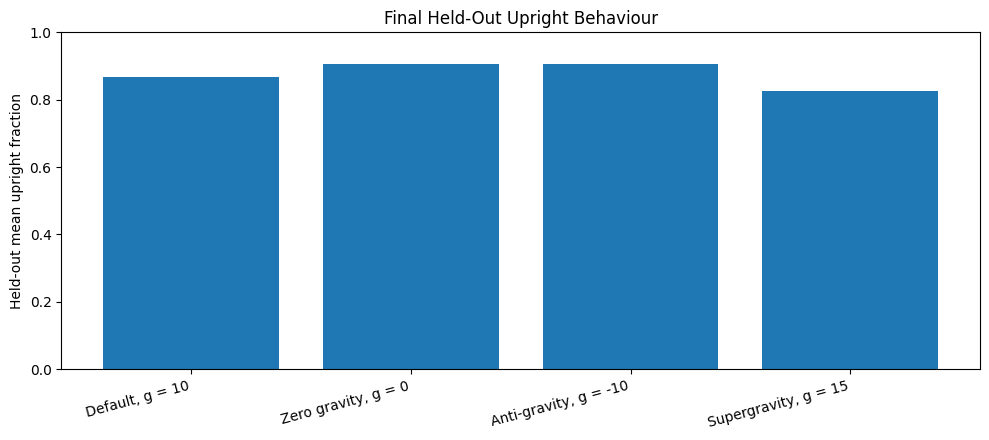

Held-out suite released: True
Gravity policies evaluated: 4
Mean held-out returns: [{'gravity_key': 'default', 'mean_heldout_return': -135.38389187771813}, {'gravity_key': 'g0', 'mean_heldout_return': -53.77239039935466}, {'gravity_key': 'g_neg10', 'mean_heldout_return': -53.36935665190416}, {'gravity_key': 'g15', 'mean_heldout_return': -203.3108554680804}]
Mean improvements over random: [{'gravity_key': 'default', 'trained_minus_random': 1084.7069439576878}, {'gravity_key': 'g0', 'trained_minus_random': 730.4610099075726}, {'gravity_key': 'g_neg10', 'trained_minus_random': 567.9035774883776}, {'gravity_key': 'g15', 'trained_minus_random': 1211.2765192146805}]
Mean improvements over untrained: [{'gravity_key': 'default', 'trained_minus_untrained': 1369.3708663710725}, {'gravity_key': 'g0', 'trained_minus_untrained': 1344.2676702352812}, {'gravity_key': 'g_neg10', 'trained_minus_untrained': 1362.7659418989035}, {'gravity_key': 'g15', 'trained_minus_untrained': 1001.9855992113252}]
No tu

In [90]:
HELDOUT_FINAL_SUMMARY_PATH = (
    HISTORIES_DIR
    / "RF_four_gravity_heldout_summary.csv"
)
HELDOUT_FINAL_STATE_RESULTS_PATH = (
    HISTORIES_DIR
    / "RF_four_gravity_heldout_state_results.csv"
)
HELDOUT_FINAL_PAIRED_RESULTS_PATH = (
    HISTORIES_DIR
    / "RF_four_gravity_heldout_paired_results.csv"
)
HELDOUT_FINAL_RELEASE_PATH = (
    HISTORIES_DIR
    / "RF_heldout_release_and_no_tuning.csv"
)

assert DEFAULT_GRAVITY_CONFIGURATION_FROZEN is True
assert GRAVITY_DEVELOPMENT_STAGE_LOCKED is True
assert HELDOUT_FINAL_SUITE_RELEASE_APPROVED is True
assert HELDOUT_FINAL_SUITE_RELEASED is False
assert NO_FURTHER_TUNING_DECLARED is True
assert SECOND_GRAVITY_SEED_APPROVED is False
assert ENVIRONMENT_SPECIFIC_ADAPTATION_APPROVED is False
assert FORMAL_RUNS_COMPLETED == 27
assert remaining_formal_run_capacity == 1
assert len(HELDOUT_PHYSICAL_STATES) == (
    FROZEN_HELDOUT_STATE_COUNT
)
assert FROZEN_HELDOUT_STATE_COUNT == 24
assert set(gravity_weight_paths) == set(
    FROZEN_GRAVITY_KEYS
)

HELDOUT_FINAL_SUITE_RELEASED = True
HELDOUT_FINAL_SUITE_RELEASE_EPISODE = "after_gravity_freeze"
HELDOUT_FINAL_SUITE_RELEASE_REASON = (
    "All four frozen gravity policies completed development "
    "evaluation and the gravity stage was locked."
)

heldout_metric_columns = [
    "return",
    "upright_fraction",
    "mean_abs_angle",
    "mean_abs_angular_velocity",
    "mean_abs_torque",
    "action_switching_rate",
    "torque_direction_switching_rate",
    "mean_abs_torque_change",
]

heldout_observations = np.stack([
    expected_observation(
        float(theta),
        float(theta_dot),
    )
    for theta, theta_dot in HELDOUT_PHYSICAL_STATES
]).astype(np.float32)

assert heldout_observations.shape == (
    FROZEN_HELDOUT_STATE_COUNT,
    DQN_STATE_DIM,
)
assert np.isfinite(heldout_observations).all()

untrained_weights_before_final = [
    weight.numpy().copy()
    for weight in formal_untrained_reference_model.weights
]

heldout_summary_records = []
heldout_state_frames = []
heldout_paired_frames = []
HELDOUT_FINAL_MODELS = {}
HELDOUT_FINAL_STATE_RESULTS = {}
HELDOUT_FINAL_REFERENCE_RESULTS = {}

for gravity_key in gravity_order:
    gravity_value = GRAVITY_SETTINGS[gravity_key]
    gravity_label = gravity_labels[gravity_key]
    development_record = (
        gravity_development_comparison.loc[
            gravity_development_comparison[
                "gravity_key"
            ] == gravity_key
        ].iloc[0]
    )

    final_model = build_dueling_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=FROZEN_ACTION_COUNT,
        hidden_units=FROZEN_HIDDEN_UNITS,
        model_name=(
            f"heldout_{gravity_key}_dueling_q_network"
        ),
    )
    final_model.load_weights(
        gravity_weight_paths[gravity_key]
    )

    assert final_model.output_shape == (
        None,
        FROZEN_ACTION_COUNT,
    )
    assert final_model.count_params() == (
        FROZEN_PARAMETER_COUNT
    )

    final_q_values = final_model(
        tf.convert_to_tensor(
            heldout_observations,
            dtype=tf.float32,
        ),
        training=False,
    ).numpy()

    assert final_q_values.shape == (
        FROZEN_HELDOUT_STATE_COUNT,
        FROZEN_ACTION_COUNT,
    )
    assert np.isfinite(final_q_values).all()

    def trained_policy(
        observation: np.ndarray,
        model: keras.Model = final_model,
    ) -> float:
        _, torque, _ = greedy_discrete_action(
            model=model,
            observation=observation,
            torque_values=np.asarray(
                FROZEN_TORQUE_VALUES,
                dtype=np.float32,
            ),
        )
        return torque

    trained_results = evaluate_policy_on_physical_states(
        env_builder=(
            lambda gravity_value=gravity_value:
            make_pendulum_env(gravity_value)
        ),
        policy=trained_policy,
        physical_states=HELDOUT_PHYSICAL_STATES,
        horizon=FROZEN_EVALUATION_HORIZON,
    )

    random_results = (
        evaluate_random_discrete_policy_on_physical_states(
            env_builder=(
                lambda gravity_value=gravity_value:
                make_pendulum_env(gravity_value)
            ),
            physical_states=HELDOUT_PHYSICAL_STATES,
            torque_values=np.asarray(
                FROZEN_TORQUE_VALUES,
                dtype=np.float32,
            ),
            base_seed=FORMAL_REFERENCE_RANDOM_SEED,
            horizon=FROZEN_EVALUATION_HORIZON,
        )
    )

    untrained_results = evaluate_policy_on_physical_states(
        env_builder=(
            lambda gravity_value=gravity_value:
            make_pendulum_env(gravity_value)
        ),
        policy=formal_untrained_reference_policy,
        physical_states=HELDOUT_PHYSICAL_STATES,
        horizon=FROZEN_EVALUATION_HORIZON,
    )

    for results in [
        trained_results,
        random_results,
        untrained_results,
    ]:
        assert len(results) == (
            FROZEN_HELDOUT_STATE_COUNT
        )
        assert results["state_id"].is_unique
        assert np.isfinite(
            results[
                heldout_metric_columns
            ].to_numpy(dtype=np.float64)
        ).all()

    trained_results = trained_results[
        ["state_id", *heldout_metric_columns]
    ].copy()
    random_results = random_results[
        ["state_id", *heldout_metric_columns]
    ].copy()
    untrained_results = untrained_results[
        ["state_id", *heldout_metric_columns]
    ].copy()

    trained_results.insert(
        0,
        "run_id",
        GRAVITY_TRAINING_RESULTS[
            gravity_key
        ]["run_id"],
    )
    trained_results.insert(
        1,
        "gravity_key",
        gravity_key,
    )
    trained_results.insert(
        2,
        "gravity_label",
        gravity_label,
    )
    trained_results.insert(
        3,
        "gravity_value",
        float(
            GRAVITY_TRAINING_RESULTS[
                gravity_key
            ]["gravity_value"]
        ),
    )
    trained_results.insert(
        4,
        "seed",
        FROZEN_GRAVITY_TRAINING_SEED,
    )
    trained_results.insert(
        6,
        "state_label",
        [
            f"F{state_id:02d}"
            for state_id in trained_results[
                "state_id"
            ]
        ],
    )
    trained_results["theta"] = (
        HELDOUT_PHYSICAL_STATES[:, 0]
    )
    trained_results["theta_dot"] = (
        HELDOUT_PHYSICAL_STATES[:, 1]
    )
    trained_results["suite"] = "held_out_final"

    paired_results = pd.DataFrame({
        "gravity_key": gravity_key,
        "gravity_label": gravity_label,
        "gravity_value": float(
            GRAVITY_TRAINING_RESULTS[
                gravity_key
            ]["gravity_value"]
        ),
        "state_id": trained_results[
            "state_id"
        ].to_numpy(),
        "state_label": trained_results[
            "state_label"
        ].to_numpy(),
        "trained_return": trained_results[
            "return"
        ].to_numpy(),
        "random_return": random_results[
            "return"
        ].to_numpy(),
        "untrained_return": untrained_results[
            "return"
        ].to_numpy(),
    })
    paired_results[
        "trained_minus_random"
    ] = (
        paired_results["trained_return"]
        - paired_results["random_return"]
    )
    paired_results[
        "trained_minus_untrained"
    ] = (
        paired_results["trained_return"]
        - paired_results["untrained_return"]
    )

    summary_record = {
        "gravity_key": gravity_key,
        "gravity_label": gravity_label,
        "gravity_value": float(
            GRAVITY_TRAINING_RESULTS[
                gravity_key
            ]["gravity_value"]
        ),
        "run_id": GRAVITY_TRAINING_RESULTS[
            gravity_key
        ]["run_id"],
        "seed": FROZEN_GRAVITY_TRAINING_SEED,
        "selected_checkpoint_episode": int(
            GRAVITY_TRAINING_RESULTS[
                gravity_key
            ]["selected_checkpoint_episode"]
        ),
        "heldout_states": int(
            len(trained_results)
        ),
        "mean_heldout_return": float(
            trained_results["return"].mean()
        ),
        "median_heldout_return": float(
            trained_results["return"].median()
        ),
        "heldout_return_std": float(
            trained_results["return"].std(ddof=1)
        ),
        "minimum_heldout_return": float(
            trained_results["return"].min()
        ),
        "maximum_heldout_return": float(
            trained_results["return"].max()
        ),
        "mean_upright_fraction": float(
            trained_results[
                "upright_fraction"
            ].mean()
        ),
        "mean_abs_angle": float(
            trained_results[
                "mean_abs_angle"
            ].mean()
        ),
        "mean_abs_angular_velocity": float(
            trained_results[
                "mean_abs_angular_velocity"
            ].mean()
        ),
        "mean_abs_torque": float(
            trained_results[
                "mean_abs_torque"
            ].mean()
        ),
        "mean_torque_direction_switching_rate": float(
            trained_results[
                "torque_direction_switching_rate"
            ].mean()
        ),
        "mean_action_switching_rate": float(
            trained_results[
                "action_switching_rate"
            ].mean()
        ),
        "mean_abs_torque_change": float(
            trained_results[
                "mean_abs_torque_change"
            ].mean()
        ),
        "random_mean_heldout_return": float(
            random_results["return"].mean()
        ),
        "untrained_mean_heldout_return": float(
            untrained_results["return"].mean()
        ),
        "trained_minus_random": float(
            paired_results[
                "trained_minus_random"
            ].mean()
        ),
        "trained_minus_untrained": float(
            paired_results[
                "trained_minus_untrained"
            ].mean()
        ),
        "trained_random_state_win_rate": float(
            (
                paired_results[
                    "trained_minus_random"
                ] > 0.0
            ).mean()
        ),
        "trained_untrained_state_win_rate": float(
            (
                paired_results[
                    "trained_minus_untrained"
                ] > 0.0
            ).mean()
        ),
        "minimum_trained_minus_random": float(
            paired_results[
                "trained_minus_random"
            ].min()
        ),
        "minimum_trained_minus_untrained": float(
            paired_results[
                "trained_minus_untrained"
            ].min()
        ),
        "development_mean_return": float(
            development_record[
                "trained_mean_return"
            ]
        ),
        "heldout_minus_development": float(
            trained_results["return"].mean()
            - development_record[
                "trained_mean_return"
            ]
        ),
        "beats_random_on_mean": bool(
            paired_results[
                "trained_minus_random"
            ].mean() > 0.0
        ),
        "beats_untrained_on_mean": bool(
            paired_results[
                "trained_minus_untrained"
            ].mean() > 0.0
        ),
        "technical_status": "PASS",
        "heldout_suite_used": True,
        "no_tuning_after_release": True,
        "raw_cross_gravity_ranking_allowed": False,
        "formal_significance_claim": False,
    }

    state_path = (
        HISTORIES_DIR
        / (
            f"RF_{gravity_key.upper()}"
            "_heldout_state_results.csv"
        )
    )
    paired_path = (
        HISTORIES_DIR
        / (
            f"RF_{gravity_key.upper()}"
            "_heldout_paired_results.csv"
        )
    )
    trained_results.to_csv(
        state_path,
        index=False,
    )
    paired_results.to_csv(
        paired_path,
        index=False,
    )

    HELDOUT_FINAL_MODELS[
        gravity_key
    ] = final_model
    HELDOUT_FINAL_STATE_RESULTS[
        gravity_key
    ] = trained_results.copy()
    HELDOUT_FINAL_REFERENCE_RESULTS[
        (gravity_key, "random")
    ] = random_results.copy()
    HELDOUT_FINAL_REFERENCE_RESULTS[
        (gravity_key, "untrained")
    ] = untrained_results.copy()

    heldout_summary_records.append(
        summary_record
    )
    heldout_state_frames.append(
        trained_results
    )
    heldout_paired_frames.append(
        paired_results
    )

for before, after in zip(
    untrained_weights_before_final,
    formal_untrained_reference_model.weights,
):
    np.testing.assert_allclose(
        before,
        after.numpy(),
        rtol=0.0,
        atol=0.0,
    )

heldout_final_summary = pd.DataFrame(
    heldout_summary_records
)
heldout_final_state_results = pd.concat(
    heldout_state_frames,
    ignore_index=True,
)
heldout_final_paired_results = pd.concat(
    heldout_paired_frames,
    ignore_index=True,
)

heldout_final_summary[
    "gravity_order"
] = heldout_final_summary[
    "gravity_key"
].map({
    key: index
    for index, key in enumerate(
        gravity_order
    )
})
heldout_final_summary = (
    heldout_final_summary
    .sort_values("gravity_order")
    .drop(columns="gravity_order")
    .reset_index(drop=True)
)

assert HELDOUT_FINAL_SUITE_RELEASED is True
assert len(heldout_final_summary) == 4
assert len(heldout_final_state_results) == (
    4 * FROZEN_HELDOUT_STATE_COUNT
)
assert len(heldout_final_paired_results) == (
    4 * FROZEN_HELDOUT_STATE_COUNT
)
assert heldout_final_summary[
    "gravity_key"
].tolist() == gravity_order
assert (
    heldout_final_summary[
        "heldout_states"
    ] == FROZEN_HELDOUT_STATE_COUNT
).all()
assert (
    heldout_final_summary[
        "technical_status"
    ] == "PASS"
).all()
assert (
    heldout_final_summary[
        "heldout_suite_used"
    ] == True
).all()
assert (
    heldout_final_summary[
        "no_tuning_after_release"
    ] == True
).all()
assert (
    heldout_final_summary[
        "raw_cross_gravity_ranking_allowed"
    ] == False
).all()
assert np.isfinite(
    heldout_final_summary[
        [
            "mean_heldout_return",
            "median_heldout_return",
            "heldout_return_std",
            "minimum_heldout_return",
            "maximum_heldout_return",
            "mean_upright_fraction",
            "mean_abs_angle",
            "mean_abs_angular_velocity",
            "mean_abs_torque",
            "mean_torque_direction_switching_rate",
            "trained_minus_random",
            "trained_minus_untrained",
            "heldout_minus_development",
        ]
    ].to_numpy(dtype=np.float64)
).all()

FINAL_HELDOUT_EVALUATION_COMPLETE = True
NO_TUNING_AFTER_HELDOUT_CONFIRMED = True
FORMAL_RUNS_COMPLETED = 27
remaining_formal_run_capacity = (
    APPROVED_HARD_FORMAL_RUN_CAP
    - FORMAL_RUNS_COMPLETED
)

heldout_release_record = {
    "heldout_release_approved": (
        HELDOUT_FINAL_SUITE_RELEASE_APPROVED
    ),
    "heldout_suite_released": (
        HELDOUT_FINAL_SUITE_RELEASED
    ),
    "release_point": (
        HELDOUT_FINAL_SUITE_RELEASE_EPISODE
    ),
    "release_reason": (
        HELDOUT_FINAL_SUITE_RELEASE_REASON
    ),
    "gravity_policies_evaluated": 4,
    "heldout_states_per_gravity": (
        FROZEN_HELDOUT_STATE_COUNT
    ),
    "final_evaluation_complete": (
        FINAL_HELDOUT_EVALUATION_COMPLETE
    ),
    "no_tuning_after_release": (
        NO_TUNING_AFTER_HELDOUT_CONFIRMED
    ),
    "formal_training_runs_added": 0,
    "formal_runs_completed": (
        FORMAL_RUNS_COMPLETED
    ),
    "remaining_formal_run_capacity": (
        remaining_formal_run_capacity
    ),
    "selection_status": (
        "LOCKED FOR FINAL ARTIFACT VERIFICATION"
    ),
}
heldout_release_and_no_tuning = pd.DataFrame(
    [heldout_release_record]
)

assert FINAL_HELDOUT_EVALUATION_COMPLETE is True
assert NO_TUNING_AFTER_HELDOUT_CONFIRMED is True
assert FORMAL_RUNS_COMPLETED == 27
assert remaining_formal_run_capacity == 1

heldout_final_summary.to_csv(
    HELDOUT_FINAL_SUMMARY_PATH,
    index=False,
)
heldout_final_state_results.to_csv(
    HELDOUT_FINAL_STATE_RESULTS_PATH,
    index=False,
)
heldout_final_paired_results.to_csv(
    HELDOUT_FINAL_PAIRED_RESULTS_PATH,
    index=False,
)
heldout_release_and_no_tuning.to_csv(
    HELDOUT_FINAL_RELEASE_PATH,
    index=False,
)

display(heldout_final_summary)
display(heldout_release_and_no_tuning)

x_positions = np.arange(
    len(heldout_final_summary)
)
bar_width = 0.36

plt.figure(figsize=(10, 4.8))
plt.bar(
    x_positions - bar_width / 2,
    heldout_final_summary[
        "trained_minus_random"
    ],
    width=bar_width,
    label="Improvement over random",
)
plt.bar(
    x_positions + bar_width / 2,
    heldout_final_summary[
        "trained_minus_untrained"
    ],
    width=bar_width,
    label="Improvement over untrained",
)
plt.axhline(0.0, linewidth=1.0)
plt.xticks(
    x_positions,
    heldout_final_summary[
        "gravity_label"
    ],
    rotation=15,
    ha="right",
)
plt.ylabel("Held-out same-gravity return improvement")
plt.title(
    "Final Held-Out Improvement Over Same-Gravity References"
)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.bar(
    heldout_final_summary[
        "gravity_label"
    ],
    heldout_final_summary[
        "mean_upright_fraction"
    ],
)
plt.xticks(rotation=15, ha="right")
plt.ylabel("Held-out mean upright fraction")
plt.ylim(0.0, 1.0)
plt.title(
    "Final Held-Out Upright Behaviour"
)
plt.tight_layout()
plt.show()

print(
    "Held-out suite released:",
    HELDOUT_FINAL_SUITE_RELEASED,
)
print(
    "Gravity policies evaluated:",
    len(heldout_final_summary),
)
print(
    "Mean held-out returns:",
    heldout_final_summary[
        [
            "gravity_key",
            "mean_heldout_return",
        ]
    ].to_dict("records"),
)
print(
    "Mean improvements over random:",
    heldout_final_summary[
        [
            "gravity_key",
            "trained_minus_random",
        ]
    ].to_dict("records"),
)
print(
    "Mean improvements over untrained:",
    heldout_final_summary[
        [
            "gravity_key",
            "trained_minus_untrained",
        ]
    ].to_dict("records"),
)
print(
    "No tuning after held-out release:",
    NO_TUNING_AFTER_HELDOUT_CONFIRMED,
)
print(
    "Formal training runs added:",
    0,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved held-out summary:",
    HELDOUT_FINAL_SUMMARY_PATH,
)
print(
    "Saved held-out release record:",
    HELDOUT_FINAL_RELEASE_PATH,
)
print("Section 19.1 final suite release: PASS")
print("Section 19.2 default final evaluation: PASS")
print("Section 19.3 zero-gravity final evaluation: PASS")
print("Section 19.4 anti-gravity final evaluation: PASS")
print("Section 19.5 supergravity final evaluation: PASS")
print(
    "Section 19.6 paired final results: PASS"
)
print("Section 19.7 no-tuning confirmation: PASS")


### 19.1 to 19.7 Result Interpretation

**Finding.** The protected held-out suite was released only after the
configuration and gravity stage were frozen. All four saved policies completed
the `24`-state held-out evaluation successfully.

| Gravity | Mean held-out return | Held-out minus development |
|---|---:|---:|
| Default, `g = 10` | `-135.383892` | `+8.968961` |
| Zero gravity, `g = 0` | `-53.772390` | `-5.676221` |
| Anti-gravity, `g = -10` | `-53.369357` | `-1.143875` |
| Supergravity, `g = 15` | `-203.310855` | `+1.581970` |

Every trained policy also achieved a higher mean held-out return than both its
same-gravity random and untrained references. The mean improvements over the
random policies ranged from `+567.903577` to `+1211.276519`, while the mean
improvements over the untrained networks ranged from `+1001.985599` to
`+1369.370866`.

**Importance.** The held-out results remain close to the corresponding
development results despite using unseen physical initial states. This
supports generalisation within each gravity condition without using the final
suite for checkpoint or hyperparameter selection.

**Decision.** Accept the four frozen gravity policies as the final evaluated
policies. No tuning, checkpoint replacement or environment-specific
adaptation is permitted after this result.

**Caveat.** Each gravity-specific policy uses one matched post-freeze training
seed. Default-gravity reliability has additional three-seed confirmation, but
the non-default gravity results should not be presented as separately
optimised maxima.

**Next step.** Copy the selected checkpoints into the required final weight
filenames, rebuild fresh models, verify that every file reproduces its
held-out result, and generate one rule-based representative trajectory and
video per gravity.


# 20. Final Weights, Videos and Reload Verification

## 20.1 Gravity-Specific Weight Saving

The selected development checkpoints are copied into the required final
weight filenames:

```text
weights/final_dqn_default.weights.h5
weights/final_dqn_g0.weights.h5
weights/final_dqn_gneg10.weights.h5
weights/final_dqn_g15.weights.h5
```

## 20.2 Submitted Weight Set

The published artifact set includes four gravity-specific policies plus
`weights/best_dqn.weights.h5`:

```text
weights/best_dqn.weights.h5
weights/final_dqn_default.weights.h5
weights/final_dqn_g0.weights.h5
weights/final_dqn_gneg10.weights.h5
weights/final_dqn_g15.weights.h5
```

`best_dqn.weights.h5` is a byte-identical copy of
`final_dqn_default.weights.h5`. It is included to satisfy the assignment brief's
best-weights requirement unambiguously, while the four gravity-specific files
preserve the submitted policy for each required gravity.

## 20.3 to 20.5 Fresh Reconstruction and Reproduced Evaluation

For every gravity:

1. build a fresh Dueling DQN with the frozen architecture;
2. load the corresponding final weight file;
3. verify the output dimension and parameter count;
4. verify finite Q-values;
5. rerun the complete held-out evaluation;
6. confirm that all state-level metrics reproduce Section 19.

This is a reload audit only. It performs no training and consumes no formal
run.

## 20.6 Representative Trajectories

Use held-out state `F08`, `(theta, theta_dot) = (1.35, 0.40)`, for every
gravity. The state is selected by rule as the first sideways held-out state,
not by inspecting which episode looks most attractive.

## 20.7 Representative Videos

Record one greedy `200`-step episode from `F08` for each gravity.

## 20.8 Final Artifact Audit

The stage passes only when all weight files exist, every fresh model reproduces
its held-out results, every trajectory contains `200` valid steps, and all
four video files are non-empty.


In [91]:
import hashlib
import shutil

from gym.wrappers.monitoring.video_recorder import (
    VideoRecorder,
)

FINAL_WEIGHT_METADATA_PATH = (
    HISTORIES_DIR
    / "final_weight_metadata.csv"
)
FINAL_RELOAD_AUDIT_PATH = (
    HISTORIES_DIR
    / "final_weight_reload_audit.csv"
)
FINAL_TRAJECTORY_PATH = (
    HISTORIES_DIR
    / "final_representative_trajectories.csv"
)
FINAL_ARTIFACT_AUDIT_PATH = (
    HISTORIES_DIR
    / "final_artifact_audit.csv"
)

assert FINAL_HELDOUT_EVALUATION_COMPLETE is True
assert HELDOUT_FINAL_SUITE_RELEASED is True
assert NO_TUNING_AFTER_HELDOUT_CONFIRMED is True
assert NO_FURTHER_TUNING_DECLARED is True
assert FORMAL_RUNS_COMPLETED == 27
assert remaining_formal_run_capacity == 1
assert FROZEN_ARCHITECTURE == "Dueling DQN"
assert FROZEN_ACTION_COUNT == 7
assert FROZEN_PARAMETER_COUNT == 4936
assert len(heldout_final_summary) == 4

final_weight_paths = {
    "default": (
        WEIGHTS_DIR
        / "final_dqn_default.weights.h5"
    ),
    "g0": (
        WEIGHTS_DIR
        / "final_dqn_g0.weights.h5"
    ),
    "g_neg10": (
        WEIGHTS_DIR
        / "final_dqn_gneg10.weights.h5"
    ),
    "g15": (
        WEIGHTS_DIR
        / "final_dqn_g15.weights.h5"
    ),
}
PRIMARY_SUBMITTED_WEIGHT_PATH = (
    WEIGHTS_DIR
    / "best_dqn.weights.h5"
)

assert set(final_weight_paths) == set(
    FROZEN_GRAVITY_KEYS
)

for gravity_key, source_path in (
    gravity_weight_paths.items()
):
    source_path = Path(source_path)
    target_path = final_weight_paths[
        gravity_key
    ]

    assert source_path.exists()

    # The gravity-training cells already save directly under the required
    # final filenames. Skip copying when the source and target are identical.
    if source_path.resolve() != target_path.resolve():
        shutil.copy2(
            source_path,
            target_path,
        )
    else:
        print(
            "Final gravity weight already uses the required filename:",
            target_path,
        )

    assert target_path.exists()
    assert target_path.stat().st_size > 0

shutil.copy2(
    final_weight_paths["default"],
    PRIMARY_SUBMITTED_WEIGHT_PATH,
)
assert PRIMARY_SUBMITTED_WEIGHT_PATH.exists()
assert PRIMARY_SUBMITTED_WEIGHT_PATH.stat().st_size > 0


def sha256_file(path: Path) -> str:
    """Return the SHA-256 digest of one artifact."""
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)
    return digest.hexdigest()


assert sha256_file(
    PRIMARY_SUBMITTED_WEIGHT_PATH
) == sha256_file(
    final_weight_paths["default"]
)

reload_metric_columns = [
    "return",
    "upright_fraction",
    "mean_abs_angle",
    "mean_abs_angular_velocity",
    "mean_abs_torque",
    "action_switching_rate",
    "torque_direction_switching_rate",
    "mean_abs_torque_change",
]

FINAL_RELOADED_MODELS = {}
FINAL_RELOAD_STATE_RESULTS = {}
reload_audit_records = []
weight_metadata_records = []

for gravity_key in gravity_order:
    gravity_value = GRAVITY_SETTINGS[
        gravity_key
    ]
    gravity_label = gravity_labels[
        gravity_key
    ]
    target_path = final_weight_paths[
        gravity_key
    ]

    reloaded_model = build_dueling_q_network(
        state_dim=DQN_STATE_DIM,
        action_count=FROZEN_ACTION_COUNT,
        hidden_units=FROZEN_HIDDEN_UNITS,
        model_name=(
            f"final_reload_{gravity_key}"
            "_dueling_q_network"
        ),
    )
    reloaded_model.load_weights(
        target_path
    )

    assert reloaded_model.output_shape == (
        None,
        FROZEN_ACTION_COUNT,
    )
    assert reloaded_model.count_params() == (
        FROZEN_PARAMETER_COUNT
    )

    reloaded_q_values = reloaded_model(
        tf.convert_to_tensor(
            heldout_observations,
            dtype=tf.float32,
        ),
        training=False,
    ).numpy()

    assert reloaded_q_values.shape == (
        FROZEN_HELDOUT_STATE_COUNT,
        FROZEN_ACTION_COUNT,
    )
    assert np.isfinite(
        reloaded_q_values
    ).all()

    def reloaded_policy(
        observation: np.ndarray,
        model: keras.Model = reloaded_model,
    ) -> float:
        _, torque, _ = greedy_discrete_action(
            model=model,
            observation=observation,
            torque_values=np.asarray(
                FROZEN_TORQUE_VALUES,
                dtype=np.float32,
            ),
        )
        return torque

    reproduced_results = (
        evaluate_policy_on_physical_states(
            env_builder=(
                lambda gravity_value=gravity_value:
                make_pendulum_env(
                    gravity_value
                )
            ),
            policy=reloaded_policy,
            physical_states=(
                HELDOUT_PHYSICAL_STATES
            ),
            horizon=(
                FROZEN_EVALUATION_HORIZON
            ),
        )
    )

    reproduced_results = (
        reproduced_results
        .sort_values("state_id")
        .reset_index(drop=True)
    )
    expected_results = (
        HELDOUT_FINAL_STATE_RESULTS[
            gravity_key
        ]
        .sort_values("state_id")
        .reset_index(drop=True)
    )

    assert reproduced_results[
        "state_id"
    ].tolist() == expected_results[
        "state_id"
    ].tolist()

    np.testing.assert_allclose(
        reproduced_results[
            reload_metric_columns
        ].to_numpy(dtype=np.float64),
        expected_results[
            reload_metric_columns
        ].to_numpy(dtype=np.float64),
        rtol=1e-7,
        atol=1e-6,
    )

    expected_summary_row = (
        heldout_final_summary.loc[
            heldout_final_summary[
                "gravity_key"
            ] == gravity_key
        ].iloc[0]
    )
    reproduced_mean_return = float(
        reproduced_results[
            "return"
        ].mean()
    )
    expected_mean_return = float(
        expected_summary_row[
            "mean_heldout_return"
        ]
    )

    np.testing.assert_allclose(
        reproduced_mean_return,
        expected_mean_return,
        rtol=1e-7,
        atol=1e-6,
    )

    source_path = Path(
        gravity_weight_paths[
            gravity_key
        ]
    )

    reload_audit_records.append({
        "gravity_key": gravity_key,
        "gravity_label": gravity_label,
        "weight_path": relative_artifact_path(target_path),
        "output_dimension": int(
            reloaded_model.output_shape[-1]
        ),
        "parameter_count": int(
            reloaded_model.count_params()
        ),
        "finite_q_values": True,
        "states_reproduced": int(
            len(reproduced_results)
        ),
        "expected_mean_heldout_return": (
            expected_mean_return
        ),
        "reproduced_mean_heldout_return": (
            reproduced_mean_return
        ),
        "absolute_return_difference": float(
            abs(
                reproduced_mean_return
                - expected_mean_return
            )
        ),
        "all_state_metrics_reproduced": True,
        "reload_status": "PASS",
    })

    weight_metadata_records.append({
        "gravity_key": gravity_key,
        "gravity_label": gravity_label,
        "gravity_value": float(
            GRAVITY_TRAINING_RESULTS[
                gravity_key
            ]["gravity_value"]
        ),
        "run_id": GRAVITY_TRAINING_RESULTS[
            gravity_key
        ]["run_id"],
        "architecture": (
            FROZEN_ARCHITECTURE
        ),
        "hidden_units": str(
            list(FROZEN_HIDDEN_UNITS)
        ),
        "parameter_count": (
            FROZEN_PARAMETER_COUNT
        ),
        "action_count": (
            FROZEN_ACTION_COUNT
        ),
        "torque_values": str(
            list(FROZEN_TORQUE_VALUES)
        ),
        "state_representation": (
            FROZEN_STATE_REPRESENTATION
        ),
        "state_scaling": (
            FROZEN_STATE_SCALING
        ),
        "gamma": FROZEN_GAMMA,
        "replay_capacity": (
            FROZEN_REPLAY_CAPACITY
        ),
        "replay_warmup": (
            FROZEN_REPLAY_WARMUP
        ),
        "batch_size": (
            FROZEN_BATCH_SIZE
        ),
        "target_update_frequency": (
            FROZEN_TARGET_UPDATE_FREQUENCY
        ),
        "optimizer": FROZEN_OPTIMIZER,
        "learning_rate": (
            FROZEN_LEARNING_RATE
        ),
        "td_loss": FROZEN_TD_LOSS,
        "gradient_clipping": (
            FROZEN_GRADIENT_CLIPPING
        ),
        "training_episodes": (
            FROZEN_TRAINING_EPISODES
        ),
        "environment_steps": (
            FROZEN_ENVIRONMENT_STEPS
        ),
        "seed": (
            FROZEN_GRAVITY_TRAINING_SEED
        ),
        "selected_checkpoint_episode": int(
            GRAVITY_TRAINING_RESULTS[
                gravity_key
            ][
                "selected_checkpoint_episode"
            ]
        ),
        "mean_heldout_return": (
            expected_mean_return
        ),
        "source_weight_path": relative_artifact_path(source_path),
        "final_weight_path": relative_artifact_path(target_path),
        "source_sha256": sha256_file(
            source_path
        ),
        "final_sha256": sha256_file(
            target_path
        ),
        "is_primary_submitted_policy": bool(
            gravity_key == "default"
        ),
        "selection_reason": (
            "Frozen matched gravity policy; "
            "default gravity is the primary "
            "submitted policy."
        ),
    })

    assert (
        weight_metadata_records[-1][
            "source_sha256"
        ]
        == weight_metadata_records[-1][
            "final_sha256"
        ]
    )

    FINAL_RELOADED_MODELS[
        gravity_key
    ] = reloaded_model
    FINAL_RELOAD_STATE_RESULTS[
        gravity_key
    ] = reproduced_results.copy()

final_reload_audit = pd.DataFrame(
    reload_audit_records
)
final_weight_metadata = pd.DataFrame(
    weight_metadata_records
)

assert len(final_reload_audit) == 4
assert (
    final_reload_audit[
        "reload_status"
    ] == "PASS"
).all()
assert (
    final_reload_audit[
        "all_state_metrics_reproduced"
    ] == True
).all()
assert (
    final_reload_audit[
        "absolute_return_difference"
    ] <= 1e-6
).all()
assert len(final_weight_metadata) == 4
assert (
    final_weight_metadata[
        "is_primary_submitted_policy"
    ].sum()
    == 1
)

primary_metadata_row = (
    final_weight_metadata.loc[
        final_weight_metadata[
            "gravity_key"
        ] == "default"
    ].iloc[0].to_dict()
)
primary_metadata_row.update({
    "final_weight_path": str(
        PRIMARY_SUBMITTED_WEIGHT_PATH
    ),
    "final_sha256": sha256_file(
        PRIMARY_SUBMITTED_WEIGHT_PATH
    ),
    "artifact_role": (
        "primary submitted weight"
    ),
})
primary_metadata = pd.DataFrame(
    [primary_metadata_row]
)

final_weight_metadata[
    "artifact_role"
] = "gravity-specific supporting weight"
final_weight_metadata = pd.concat(
    [
        final_weight_metadata,
        primary_metadata,
    ],
    ignore_index=True,
)

assert len(final_weight_metadata) == 5
assert (
    final_weight_metadata[
        "artifact_role"
    ] == "primary submitted weight"
).sum() == 1

FINAL_REPRESENTATIVE_STATE_ID = 8
FINAL_REPRESENTATIVE_STATE_LABEL = "F08"
FINAL_REPRESENTATIVE_THETA = float(
    HELDOUT_PHYSICAL_STATES[
        FINAL_REPRESENTATIVE_STATE_ID,
        0,
    ]
)
FINAL_REPRESENTATIVE_THETA_DOT = float(
    HELDOUT_PHYSICAL_STATES[
        FINAL_REPRESENTATIVE_STATE_ID,
        1,
    ]
)

np.testing.assert_allclose(
    [
        FINAL_REPRESENTATIVE_THETA,
        FINAL_REPRESENTATIVE_THETA_DOT,
    ],
    [1.35, 0.40],
    rtol=0.0,
    atol=1e-12,
)


def record_final_representative_episode(
    gravity_key: str,
    gravity_value,
    model: keras.Model,
    video_base: Path,
) -> tuple:
    """Record one fixed-state greedy episode and return its trajectory."""
    env = make_pendulum_env(
        gravity_value
    )
    recorder = None
    records = []

    try:
        observation = reset_to_physical_state(
            env,
            FINAL_REPRESENTATIVE_THETA,
            FINAL_REPRESENTATIVE_THETA_DOT,
        )
        recorder = VideoRecorder(
            env,
            base_path=str(video_base),
            enabled=True,
        )
        cumulative_return = 0.0

        for step_index in range(
            FROZEN_EVALUATION_HORIZON
        ):
            recorder.capture_frame()

            action_index, torque, q_values = (
                greedy_discrete_action(
                    model=model,
                    observation=observation,
                    torque_values=np.asarray(
                        FROZEN_TORQUE_VALUES,
                        dtype=np.float32,
                    ),
                )
            )
            next_observation, reward, done, info = (
                env.step(
                    np.array(
                        [torque],
                        dtype=np.float32,
                    )
                )
            )
            next_observation = np.asarray(
                next_observation,
                dtype=np.float32,
            )
            cumulative_return += float(
                reward
            )

            records.append({
                "gravity_key": gravity_key,
                "gravity_label": (
                    gravity_labels[
                        gravity_key
                    ]
                ),
                "state_id": (
                    FINAL_REPRESENTATIVE_STATE_ID
                ),
                "state_label": (
                    FINAL_REPRESENTATIVE_STATE_LABEL
                ),
                "initial_theta": (
                    FINAL_REPRESENTATIVE_THETA
                ),
                "initial_theta_dot": (
                    FINAL_REPRESENTATIVE_THETA_DOT
                ),
                "step": int(
                    step_index + 1
                ),
                "theta": float(
                    observation_to_angle(
                        next_observation
                    )
                ),
                "theta_dot": float(
                    next_observation[2]
                ),
                "action_index": int(
                    action_index
                ),
                "torque": float(
                    torque
                ),
                "reward": float(
                    reward
                ),
                "cumulative_return": (
                    cumulative_return
                ),
                "maximum_q_value": float(
                    np.max(q_values)
                ),
            })

            observation = next_observation

            if done:
                assert (
                    info.get(
                        "TimeLimit.truncated"
                    )
                    is True
                )
                assert (
                    step_index + 1
                    == FROZEN_EVALUATION_HORIZON
                )
                break
    finally:
        if recorder is not None:
            recorder.close()
        env.close()

    trajectory = pd.DataFrame(
        records
    )
    video_path = Path(
        str(video_base) + ".mp4"
    )

    assert len(trajectory) == (
        FROZEN_EVALUATION_HORIZON
    )
    assert np.isfinite(
        trajectory[
            [
                "theta",
                "theta_dot",
                "torque",
                "reward",
                "cumulative_return",
                "maximum_q_value",
            ]
        ].to_numpy(dtype=np.float64)
    ).all()
    assert video_path.exists()
    assert video_path.stat().st_size > 0

    return trajectory, video_path


final_trajectory_frames = []
final_video_paths = {}

for gravity_key in gravity_order:
    video_base = (
        VIDEOS_DIR
        / (
            "final_dqn_"
            f"{gravity_key}"
            "_F08"
        )
    )
    trajectory, video_path = (
        record_final_representative_episode(
            gravity_key=gravity_key,
            gravity_value=(
                GRAVITY_SETTINGS[
                    gravity_key
                ]
            ),
            model=FINAL_RELOADED_MODELS[
                gravity_key
            ],
            video_base=video_base,
        )
    )
    final_trajectory_frames.append(
        trajectory
    )
    final_video_paths[
        gravity_key
    ] = video_path

final_representative_trajectories = (
    pd.concat(
        final_trajectory_frames,
        ignore_index=True,
    )
)

assert len(
    final_representative_trajectories
) == (
    len(gravity_order)
    * FROZEN_EVALUATION_HORIZON
)
assert set(final_video_paths) == set(
    FROZEN_GRAVITY_KEYS
)
assert all(
    path.exists()
    and path.stat().st_size > 0
    for path in final_video_paths.values()
)

final_weight_metadata.to_csv(
    FINAL_WEIGHT_METADATA_PATH,
    index=False,
)
final_reload_audit.to_csv(
    FINAL_RELOAD_AUDIT_PATH,
    index=False,
)
final_representative_trajectories.to_csv(
    FINAL_TRAJECTORY_PATH,
    index=False,
)

artifact_records = []

for gravity_key in gravity_order:
    artifact_records.extend([
        {
            "artifact_type": "final weight",
            "gravity_key": gravity_key,
            "path": relative_artifact_path(final_weight_paths[gravity_key]),
            "exists": True,
            "non_empty": bool(
                final_weight_paths[
                    gravity_key
                ].stat().st_size > 0
            ),
            "verification_status": "PASS",
        },
        {
            "artifact_type": "representative video",
            "gravity_key": gravity_key,
            "path": relative_artifact_path(final_video_paths[gravity_key]),
            "exists": True,
            "non_empty": bool(
                final_video_paths[
                    gravity_key
                ].stat().st_size > 0
            ),
            "verification_status": "PASS",
        },
    ])

artifact_records.extend([
    {
        "artifact_type": "primary weight",
        "gravity_key": "default",
        "path": relative_artifact_path(PRIMARY_SUBMITTED_WEIGHT_PATH),
        "exists": True,
        "non_empty": bool(
            PRIMARY_SUBMITTED_WEIGHT_PATH
            .stat().st_size > 0
        ),
        "verification_status": "PASS",
    },
    {
        "artifact_type": "weight metadata",
        "gravity_key": "all",
        "path": relative_artifact_path(FINAL_WEIGHT_METADATA_PATH),
        "exists": True,
        "non_empty": True,
        "verification_status": "PASS",
    },
    {
        "artifact_type": "reload audit",
        "gravity_key": "all",
        "path": relative_artifact_path(FINAL_RELOAD_AUDIT_PATH),
        "exists": True,
        "non_empty": True,
        "verification_status": "PASS",
    },
    {
        "artifact_type": "representative trajectories",
        "gravity_key": "all",
        "path": relative_artifact_path(FINAL_TRAJECTORY_PATH),
        "exists": True,
        "non_empty": True,
        "verification_status": "PASS",
    },
])

final_artifact_audit = pd.DataFrame(
    artifact_records
)

assert len(final_artifact_audit) == 12
assert final_artifact_audit[
    "exists"
].all()
assert final_artifact_audit[
    "non_empty"
].all()
assert (
    final_artifact_audit[
        "verification_status"
    ] == "PASS"
).all()

FINAL_WEIGHTS_SAVED = True
FINAL_RELOAD_VERIFICATION_COMPLETE = True
FINAL_TRAJECTORIES_COMPLETE = True
FINAL_VIDEOS_COMPLETE = True
FINAL_ARTIFACT_AUDIT_COMPLETE = True

assert FORMAL_RUNS_COMPLETED == 27
assert remaining_formal_run_capacity == 1

final_artifact_audit.to_csv(
    FINAL_ARTIFACT_AUDIT_PATH,
    index=False,
)

display(final_weight_metadata)
display(final_reload_audit)
display(
    final_representative_trajectories
    .groupby(
        [
            "gravity_key",
            "gravity_label",
        ],
        as_index=False,
    )
    .agg(
        representative_return=(
            "cumulative_return",
            "last",
        ),
        mean_abs_angle=(
            "theta",
            lambda values: float(
                np.mean(
                    np.abs(values)
                )
            ),
        ),
        mean_abs_angular_velocity=(
            "theta_dot",
            lambda values: float(
                np.mean(
                    np.abs(values)
                )
            ),
        ),
        mean_abs_torque=(
            "torque",
            lambda values: float(
                np.mean(
                    np.abs(values)
                )
            ),
        ),
    )
)
display(final_artifact_audit)

print(
    "Primary submitted weight:",
    PRIMARY_SUBMITTED_WEIGHT_PATH,
)
print(
    "Gravity-specific final weights:",
    {
        key: str(path)
        for key, path
        in final_weight_paths.items()
    },
)
print(
    "Reload verification passed:",
    FINAL_RELOAD_VERIFICATION_COMPLETE,
)
print(
    "Representative videos:",
    {
        key: str(path)
        for key, path
        in final_video_paths.items()
    },
)
print(
    "Formal training runs added:",
    0,
)
print(
    "Formal runs completed:",
    FORMAL_RUNS_COMPLETED,
)
print(
    "Remaining formal-run capacity:",
    remaining_formal_run_capacity,
)
print(
    "Saved final artifact audit:",
    FINAL_ARTIFACT_AUDIT_PATH,
)
print(
    "Section 20.1 gravity-specific weights: PASS"
)
print(
    "Section 20.2 primary submitted weight: PASS"
)
print(
    "Section 20.3 fresh reconstruction: PASS"
)
print(
    "Section 20.4 weight reload: PASS"
)
print(
    "Section 20.5 reproduced evaluation: PASS"
)
print(
    "Section 20.6 representative trajectories: PASS"
)
print(
    "Section 20.7 representative videos: PASS"
)
print(
    "Section 20.8 final artifact audit: PASS"
)


Final gravity weight already uses the required filename: weights\final_dqn_default.weights.h5
Final gravity weight already uses the required filename: weights\final_dqn_g0.weights.h5
Final gravity weight already uses the required filename: weights\final_dqn_gneg10.weights.h5
Final gravity weight already uses the required filename: weights\final_dqn_g15.weights.h5


,gravity_key,gravity_label,gravity_value,run_id,architecture,hidden_units,parameter_count,action_count,torque_values,state_representation,...,seed,selected_checkpoint_episode,mean_heldout_return,source_weight_path,final_weight_path,source_sha256,final_sha256,is_primary_submitted_policy,selection_reason,artifact_role
0,default,"Default, g = 10",10.0,RG_DEFAULT,Dueling DQN,"[64, 64]",4936,7,"[-2.0, -1.3333333730697632, -0.666666686534881...","[cos(theta), sin(theta), theta_dot]",...,4242,50,-135.383892,weights/final_dqn_default.weights.h5,weights/final_dqn_default.weights.h5,e92b239c279615255d01405db08817303efa68bc3439d6...,e92b239c279615255d01405db08817303efa68bc3439d6...,True,Frozen matched gravity policy; default gravity...,gravity-specific supporting weight
1,g0,"Zero gravity, g = 0",0.0,RG_ZERO,Dueling DQN,"[64, 64]",4936,7,"[-2.0, -1.3333333730697632, -0.666666686534881...","[cos(theta), sin(theta), theta_dot]",...,4242,50,-53.772390,weights/final_dqn_g0.weights.h5,weights/final_dqn_g0.weights.h5,11cbd69d3a2dc3330e7c5d0ed313c361adbc71cf168b6e...,11cbd69d3a2dc3330e7c5d0ed313c361adbc71cf168b6e...,False,Frozen matched gravity policy; default gravity...,gravity-specific supporting weight
2,g_neg10,"Anti-gravity, g = -10",-10.0,RG_NEG10,Dueling DQN,"[64, 64]",4936,7,"[-2.0, -1.3333333730697632, -0.666666686534881...","[cos(theta), sin(theta), theta_dot]",...,4242,125,-53.369357,weights/final_dqn_gneg10.weights.h5,weights/final_dqn_gneg10.weights.h5,dab79e936d4529ad3923e03ca0e343f1fd0615548a6f28...,dab79e936d4529ad3923e03ca0e343f1fd0615548a6f28...,False,Frozen matched gravity policy; default gravity...,gravity-specific supporting weight
3,g15,"Supergravity, g = 15",15.0,RG_15,Dueling DQN,"[64, 64]",4936,7,"[-2.0, -1.3333333730697632, -0.666666686534881...","[cos(theta), sin(theta), theta_dot]",...,4242,125,-203.310855,weights/final_dqn_g15.weights.h5,weights/final_dqn_g15.weights.h5,845f75e04f1536f039b9d4b64deced2da581866c5925eb...,845f75e04f1536f039b9d4b64deced2da581866c5925eb...,False,Frozen matched gravity policy; default gravity...,gravity-specific supporting weight
4,default,"Default, g = 10",10.0,RG_DEFAULT,Dueling DQN,"[64, 64]",4936,7,"[-2.0, -1.3333333730697632, -0.666666686534881...","[cos(theta), sin(theta), theta_dot]",...,4242,50,-135.383892,weights/final_dqn_default.weights.h5,weights\best_dqn.weights.h5,e92b239c279615255d01405db08817303efa68bc3439d6...,e92b239c279615255d01405db08817303efa68bc3439d6...,True,Frozen matched gravity policy; default gravity...,primary submitted weight


,gravity_key,gravity_label,weight_path,output_dimension,parameter_count,finite_q_values,states_reproduced,expected_mean_heldout_return,reproduced_mean_heldout_return,absolute_return_difference,all_state_metrics_reproduced,reload_status
0,default,"Default, g = 10",weights/final_dqn_default.weights.h5,7,4936,True,24,-135.383892,-135.383892,0.0,True,PASS
1,g0,"Zero gravity, g = 0",weights/final_dqn_g0.weights.h5,7,4936,True,24,-53.772390,-53.772390,0.0,True,PASS
2,g_neg10,"Anti-gravity, g = -10",weights/final_dqn_gneg10.weights.h5,7,4936,True,24,-53.369357,-53.369357,0.0,True,PASS
3,g15,"Supergravity, g = 15",weights/final_dqn_g15.weights.h5,7,4936,True,24,-203.310855,-203.310855,0.0,True,PASS


,gravity_key,gravity_label,representative_return,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque
0,default,"Default, g = 10",-120.593603,0.217121,0.604377,1.673333
1,g0,"Zero gravity, g = 0",-22.733082,0.120499,0.239000,1.533333
2,g15,"Supergravity, g = 15",-120.119055,0.203101,0.622689,1.986667
3,g_neg10,"Anti-gravity, g = -10",-21.390217,0.079831,0.263552,0.263333


,artifact_type,gravity_key,path,exists,non_empty,verification_status
0,final weight,default,weights/final_dqn_default.weights.h5,True,True,PASS
1,representative video,default,videos/final_dqn_default_F08.mp4,True,True,PASS
2,final weight,g0,weights/final_dqn_g0.weights.h5,True,True,PASS
3,representative video,g0,videos/final_dqn_g0_F08.mp4,True,True,PASS
4,final weight,g_neg10,weights/final_dqn_gneg10.weights.h5,True,True,PASS
5,representative video,g_neg10,videos/final_dqn_g_neg10_F08.mp4,True,True,PASS
6,final weight,g15,weights/final_dqn_g15.weights.h5,True,True,PASS
7,representative video,g15,videos/final_dqn_g15_F08.mp4,True,True,PASS
8,primary weight,default,weights/best_dqn.weights.h5,True,True,PASS
9,weight metadata,all,histories/final_weight_metadata.csv,True,True,PASS


Primary submitted weight: weights\best_dqn.weights.h5
Gravity-specific final weights: {'default': 'weights\\final_dqn_default.weights.h5', 'g0': 'weights\\final_dqn_g0.weights.h5', 'g_neg10': 'weights\\final_dqn_gneg10.weights.h5', 'g15': 'weights\\final_dqn_g15.weights.h5'}
Reload verification passed: True
Representative videos: {'default': 'videos\\final_dqn_default_F08.mp4', 'g0': 'videos\\final_dqn_g0_F08.mp4', 'g_neg10': 'videos\\final_dqn_g_neg10_F08.mp4', 'g15': 'videos\\final_dqn_g15_F08.mp4'}
Formal training runs added: 0
Formal runs completed: 27
Remaining formal-run capacity: 1
Saved final artifact audit: histories\final_artifact_audit.csv
Section 20.1 gravity-specific weights: PASS
Section 20.2 primary submitted weight: PASS
Section 20.3 fresh reconstruction: PASS
Section 20.4 weight reload: PASS
Section 20.5 reproduced evaluation: PASS
Section 20.6 representative trajectories: PASS
Section 20.7 representative videos: PASS
Section 20.8 final artifact audit: PASS


### 20.1 to 20.8 Result Interpretation

**Finding.** All final artifact checks passed.

- four gravity-specific weight files were present and non-empty;
- `best_dqn.weights.h5` matched the default-gravity final weight exactly;
- each fresh Dueling DQN reconstructed with `4,936` parameters and seven
  outputs;
- all four reloaded policies reproduced every held-out state metric;
- every reproduced mean held-out return had an absolute difference of `0.0`;
- four fixed-state `200`-step trajectories were generated;
- four non-empty representative videos were created from held-out state
  `F08`.

The representative episode returns were:

| Gravity | Representative return |
|---|---:|
| Default, `g = 10` | `-120.593603` |
| Zero gravity, `g = 0` | `-22.733082` |
| Anti-gravity, `g = -10` | `-21.390217` |
| Supergravity, `g = 15` | `-120.119055` |

**Importance.** The final results can be reproduced from saved weights
without retraining. The video state was selected by a fixed rule rather than
by searching for the most attractive episode.

**Decision.** Accept the five final weight artifacts, four reload audits,
four trajectories and four videos. Section 20 adds no formal training run, so
the completed run count remains `27` with one unused contingency slot.

**Caveat.** Artifact metadata now stores paths relative to the project root.
The public repository must preserve that folder structure, and the
notebook, required weights and videos must still be reopened after
extraction.


## 20.9 Corrected Control-Smoothness Audit

The original notebook used a sign-change count and called it torque switching. That quantity is now correctly named **torque-direction switching rate**. This evaluation-only audit reloads the selected policies and computes the planned **action switching rate**, which counts every change between discrete torque values, together with mean absolute torque change. No weights are updated.


In [92]:
CONTROL_SMOOTHNESS_AUDIT_PATH = (
    HISTORIES_DIR / "control_smoothness_audit.csv"
)


def evaluate_model_smoothness(
    run_id: str,
    model: keras.Model,
    torque_values: np.ndarray,
    physical_states: np.ndarray,
    gravity_key: str = "default",
    suite: str = "development",
) -> pd.DataFrame:
    validated_torques = validate_discrete_torque_values(
        np.asarray(torque_values, dtype=np.float32)
    )

    def policy(observation: np.ndarray) -> float:
        _, torque, _ = greedy_discrete_action(
            model=model,
            observation=observation,
            torque_values=validated_torques,
        )
        return torque

    results = evaluate_policy_on_physical_states(
        env_builder=lambda: make_pendulum_env(
            GRAVITY_SETTINGS[gravity_key]
        ),
        policy=policy,
        physical_states=physical_states,
        horizon=EVALUATION_HORIZON,
    )
    return pd.DataFrame([{
        "run_id": run_id,
        "gravity_key": gravity_key,
        "suite": suite,
        "states": int(len(results)),
        "mean_action_switching_rate": float(
            results["action_switching_rate"].mean()
        ),
        "mean_torque_direction_switching_rate": float(
            results["torque_direction_switching_rate"].mean()
        ),
        "mean_abs_torque_change": float(
            results["mean_abs_torque_change"].mean()
        ),
        "mean_abs_torque": float(results["mean_abs_torque"].mean()),
        "metric_schema": CONTROL_METRIC_SCHEMA_VERSION,
    }])

smoothness_frames = [
    evaluate_model_smoothness(
        R20_RUN_ID,
        r10_selected_model,
        ACTION_SET_CANDIDATES[3],
        DEVELOPMENT_PHYSICAL_STATES,
    ),
    evaluate_model_smoothness(
        R21_RUN_ID,
        r21_selected_model,
        ACTION_SET_CANDIDATES[5],
        DEVELOPMENT_PHYSICAL_STATES,
    ),
    evaluate_model_smoothness(
        R22_RUN_ID,
        r22_selected_model,
        ACTION_SET_CANDIDATES[7],
        DEVELOPMENT_PHYSICAL_STATES,
    ),
    evaluate_model_smoothness(
        R40_RUN_ID,
        r40_reference_model,
        FOUNDATION_SCREEN_TORQUE_VALUES,
        DEVELOPMENT_PHYSICAL_STATES,
    ),
    evaluate_model_smoothness(
        R41_RUN_ID,
        r41_selected_model,
        FOUNDATION_SCREEN_TORQUE_VALUES,
        DEVELOPMENT_PHYSICAL_STATES,
    ),
    evaluate_model_smoothness(
        R42_RUN_ID,
        r42_selected_model,
        FOUNDATION_SCREEN_TORQUE_VALUES,
        DEVELOPMENT_PHYSICAL_STATES,
    ),
    evaluate_model_smoothness(
        R90_COMBINED_RUN_ID,
        r90_combined_selected_model,
        FOUNDATION_SCREEN_TORQUE_VALUES,
        DEVELOPMENT_PHYSICAL_STATES,
    ),
    evaluate_model_smoothness(
        R91_ABLATION_RUN_ID,
        r91_ablation_selected_model,
        FOUNDATION_SCREEN_TORQUE_VALUES,
        DEVELOPMENT_PHYSICAL_STATES,
    ),
]

for gravity_key in gravity_order:
    gravity_results = HELDOUT_FINAL_STATE_RESULTS[gravity_key]
    smoothness_frames.append(pd.DataFrame([{
        "run_id": GRAVITY_TRAINING_RESULTS[gravity_key]["run_id"],
        "gravity_key": gravity_key,
        "suite": "held_out_final",
        "states": int(len(gravity_results)),
        "mean_action_switching_rate": float(
            gravity_results["action_switching_rate"].mean()
        ),
        "mean_torque_direction_switching_rate": float(
            gravity_results["torque_direction_switching_rate"].mean()
        ),
        "mean_abs_torque_change": float(
            gravity_results["mean_abs_torque_change"].mean()
        ),
        "mean_abs_torque": float(
            gravity_results["mean_abs_torque"].mean()
        ),
        "metric_schema": CONTROL_METRIC_SCHEMA_VERSION,
    }]))

control_smoothness_audit = pd.concat(
    smoothness_frames,
    ignore_index=True,
)

assert len(control_smoothness_audit) == 12
assert np.isfinite(
    control_smoothness_audit[
        [
            "mean_action_switching_rate",
            "mean_torque_direction_switching_rate",
            "mean_abs_torque_change",
            "mean_abs_torque",
        ]
    ].to_numpy(dtype=np.float64)
).all()
assert (
    control_smoothness_audit["mean_action_switching_rate"] + 1e-12
    >= control_smoothness_audit[
        "mean_torque_direction_switching_rate"
    ]
).all()

control_smoothness_audit.to_csv(
    CONTROL_SMOOTHNESS_AUDIT_PATH,
    index=False,
)
display(control_smoothness_audit)
print(
    "Saved corrected control-smoothness audit:",
    relative_artifact_path(CONTROL_SMOOTHNESS_AUDIT_PATH),
)
print("Control-smoothness metric correction: PASS")


,run_id,gravity_key,suite,states,mean_action_switching_rate,mean_torque_direction_switching_rate,mean_abs_torque_change,mean_abs_torque,metric_schema
0,R20_ACTIONS_3,default,development,24,0.739322,0.739322,2.597990,1.712083,2.0
1,R21_ACTIONS_5,default,development,24,0.780151,0.770519,2.338777,1.469167,2.0
2,R22_ACTIONS_7,default,development,24,0.456658,0.451214,0.908710,0.642361,2.0
3,R40_VANILLA,default,development,24,0.456658,0.451214,0.908710,0.642361,2.0
4,R41_DOUBLE,default,development,24,0.827052,0.640494,2.300949,1.573333,2.0
5,R42_DUELING,default,development,24,0.760678,0.750838,1.138610,0.843889,2.0
6,R90_COMBINED,default,development,24,0.760678,0.750838,1.138610,0.843889,2.0
7,R91_ABLATION_DUELING_HEAD,default,development,24,0.456658,0.451214,0.908710,0.642361,2.0
8,RG_DEFAULT,default,held_out_final,24,0.585427,0.577889,1.925181,1.680278,2.0
9,RG_ZERO,g0,held_out_final,24,0.751466,0.736390,2.387493,1.539167,2.0


Saved corrected control-smoothness audit: histories/control_smoothness_audit.csv
Control-smoothness metric correction: PASS


### 20.9 Result Interpretation

**Finding.** The corrected evaluator successfully separated three different
control-smoothness quantities:

| Action set | Action switching | Direction switching | Mean absolute torque change |
|---|---:|---:|---:|
| 3 actions | `0.739322` | `0.739322` | `2.597990` |
| 5 actions | `0.780151` | `0.770519` | `2.338777` |
| 7 actions | `0.456658` | `0.451214` | `0.908710` |

The corrected values preserve the seven-action decision. Seven actions changed
discrete torque least often and made the smallest average torque adjustment
among the tested action sets.

For the seed-42 foundation policies:

| Model | Action switching | Direction switching | Mean absolute torque change |
|---|---:|---:|---:|
| Vanilla DQN | `0.456658` | `0.451214` | `0.908710` |
| Double DQN | `0.827052` | `0.640494` | `2.300949` |
| Dueling DQN | `0.760678` | `0.750838` | `1.138610` |
| Standard-network ablation | `0.456658` | `0.451214` | `0.908710` |

**Importance.** Dueling DQN did not improve control smoothness relative to the
standard-network ablation. Its retained benefit must therefore be described
as the modest matched improvement in return and state robustness, not as
reduced action switching.

The final gravity policies had action-switching rates of `0.585427`,
`0.751466`, `0.065955` and `0.714405` for default, zero, anti-gravity and
supergravity respectively. Anti-gravity required especially few action
changes, while supergravity produced the largest mean absolute torque change
of `2.794807`.

**Decision.** Retain the final architecture and all selected checkpoints. The
metric correction changes the interpretation of control style only. It does
not change returns, checkpoint selection, saved weights or the final
four-gravity conclusions.

**Caveat.** Action switching is a discrete control proxy. It does not directly
measure physical jerk, actuator wear or continuous-control smoothness. Raw
smoothness values should also not be ranked across gravity settings without
considering the different environment dynamics.


# 21. Limitations, Conclusions and References

## 21.1 Technical Limitations

1. **Discrete rather than continuous control.** DQN requires a finite action
   set, so the continuous torque interval was approximated by seven values.
   This makes DQN applicable but prevents it from selecting torque values
   between those actions.
2. **Finite training budget.** Every formal model used `150` episodes and
   `30,000` environment steps. This was sufficient for the required
   investigation, but it does not establish the best performance obtainable
   with much longer training.
3. **Checkpoint sensitivity.** The selected development checkpoint could
   outperform the last training episode. Supergravity showed the clearest
   late decline, from `-204.892825` at episode `125` to `-325.844027` at
   episode `150`.
4. **Weights-only persistence.** The final `.h5` files preserve inference
   weights, not replay memory, optimiser state or random-generator state.
   Interrupted training runs therefore cannot be resumed exactly.
5. **Legacy environment dependency.** The implementation is deliberately
   tied to Gym `0.17.3`, `Pendulum-v0` and its four-value step API. Newer Gym
   APIs require adaptation.
6. **Discrete smoothness proxy.** Action switching, torque-direction
   switching and mean absolute torque change describe the discrete policy's
   control style. They do not directly measure physical jerk, actuator wear
   or the smoothness achievable with a continuous-action controller.
7. **Early performance saturation and evaluation resolution.** Many
   default-gravity configurations reached strong development performance
   within approximately the first `25` to `50` episodes. Because greedy
   evaluation was recorded only every `25` episodes, the experiment could
   not resolve smaller differences in learning speed within this early
   convergence period. This may partly explain why later recipe comparisons
   produced practical ties or no retained improvement, but it does not prove
   that saturation alone caused those outcomes.

## 21.2 Evaluation Limitations

1. All architecture and hyperparameter decisions were made under default
   gravity. The four-gravity study therefore measures the transfer of one
   default-tuned configuration, not separately optimised maxima.
2. Default gravity received three fresh final-confirmation seeds. Each
   post-freeze gravity policy used one matched seed, so the non-default
   gravity conclusions remain more sensitive to training randomness.
3. Development and final evaluation used `24` fixed physical states each.
   They provide broad, repeatable coverage but cannot represent every
   possible Pendulum state.
4. The practical margin of `11.335072` was the observed range of three
   Vanilla seed-level means. It is a conservative decision heuristic, not a
   statistical-significance test.
5. Raw returns should not be ranked directly across gravity settings because
   gravity changes the dynamics and reward trajectories. Same-gravity
   improvements and control metrics are the fairer evidence.
6. One rule-selected video per gravity supports demonstration only. The
   quantitative fixed-state evaluation remains the primary evidence.
7. **Sensitivity of the practical margin.** The `11.335072` practical
   margin was determined mainly by the weaker seed-2026 Vanilla run, while
   seeds 42 and 123 differed by only about `0.093`. The final selected
   configuration later showed much smaller training-seed variation, with
   standard deviation `0.982829` and range `1.954826`. The original margin is
   therefore retained as the predeclared conservative decision rule, but it
   likely overstates the typical variation of the final configuration.

## 21.3 Answers to the Assignment Questions

### Why can DQN be used for Pendulum?

Pendulum has a continuous three-value state, which can be processed by a
neural Q-function. After torque is discretised, the network can output one
Q-value for each available action and select the action with the greatest
estimated long-term return.

### Why must the action space be discretised?

Standard DQN has one output per fixed action. Pendulum's original torque action
is continuous, so it must be converted into a finite set before DQN can choose
among actions. The project tested `3`, `5` and `7` actions and retained seven.

### Is one trial sufficient?

No. The three Vanilla calibration seeds produced seed-level mean returns from
`-139.818601` to `-151.153674`, giving a range of `11.335072`. The final
default configuration was therefore confirmed with three fresh seeds and
achieved mean return `-139.084552`, training-seed standard deviation
`0.982829` and zero technical failures.

### Which choices were tuned?

The controlled experiments examined action count, Vanilla versus Double versus
Dueling DQN, epsilon schedule, replay and target-network recipe, MSE versus
Huber with clipping, gamma `0.95` versus `0.99`, and raw versus scaled state.
This was a hypothesis-driven sequence, not an exhaustive automated GridSearch.

### How was the best setup defined?

The primary criterion was mean greedy development return on fixed states using
matched seeds. Differences within the practical margin were treated
cautiously, with stability and failure frequency first, sample efficiency
second, and simplicity, runtime and reproducibility third. The held-out suite
was opened only after the configuration was frozen.

### What did the selected DQN modification contribute?

Dueling DQN separates state value from action advantage, which is useful when
several torque choices can be similarly valuable in the same state. In the
matched ablation, Dueling exceeded the standard network by `2.632949` across
the two matched seeds, won both seed comparisons, achieved an average paired
state win rate of `0.8125`, and had slightly lower state-wise spread. The
corrected seed-42 smoothness audit showed a higher action-switching rate for
Dueling (`0.760678`) than for the standard-network ablation (`0.456658`).
The retained contribution is therefore return and robustness, not smoother
torque changes. The return difference was smaller than the practical margin,
so the result supports a modest and consistent benefit rather than a formal
significance claim.

## 21.4 Final Conclusion

Vanilla DQN first demonstrated that the discretised Pendulum task was viable.
The action experiment selected seven symmetric torques from `-2` to `2`.
Dueling DQN was then retained as the suitable modification after the
foundation comparison, matched-seed confirmation and focused ablation.

The frozen final configuration used two `64`-unit hidden layers, raw
`[cos(theta), sin(theta), theta_dot]` input, moderate epsilon decay from
`1.00` to `0.05` over `20,000` steps, replay capacity `10,000`, warm-up
`1,000`, batch size `32`, hard target updates every `250` optimiser updates,
Adam `0.001`, MSE loss, no gradient clipping and gamma `0.99`.

Fresh matched policies were trained under default gravity, zero gravity,
anti-gravity and supergravity. Their final held-out mean returns were
`-135.383892`, `-53.772390`, `-53.369357` and `-203.310855`, respectively.
Every policy beat both its random and untrained same-gravity references, and
all saved policies reproduced their final results exactly after fresh-model
reload.

The corrected control-smoothness audit preserved the seven-action selection
but showed that Dueling's advantage was not reduced switching relative to the
standard-network ablation. The architecture decision therefore rests on the
matched return and robustness evidence.

The evidence supports Dueling DQN as a viable, reproducible solution for all
four required Pendulum settings under the frozen default-tuned configuration.
The conclusion remains bounded by the discrete action set, finite training
budget, one post-freeze seed per gravity and the absence of independent
per-gravity tuning.

## 21.5 Research Expectations Versus Project Evidence

| Research-backed expectation | Project evidence |
|---|---|
| DQN can learn a neural action-value function when actions are discrete (Mnih et al., 2013; Mnih et al., 2015) | Vanilla DQN exceeded random and untrained references, establishing viability before advanced changes |
| Double DQN can reduce value overestimation (van Hasselt et al., 2016) | Its defining target was implemented correctly, but it did not provide enough matched control benefit to be retained |
| Dueling DQN can represent state value separately from action advantage (Wang et al., 2016) | Matched foundation and ablation evidence supported a modest, consistent benefit, not a universal superiority claim |
| Artificial time limits should not automatically be treated as true terminals (Pardo et al., 2018) | Gym 0.17.3 preflight verified natural nontermination and `TimeLimit.truncated=True`, so Bellman targets bootstrap through the wrapper boundary |

## 21.6 References

- Brockman, G., Cheung, V., Pettersson, L., Schneider, J., Schulman, J., Tang, J., and Zaremba, W. (2016). *OpenAI Gym*. arXiv:1606.01540.
- Mnih, V., Kavukcuoglu, K., Silver, D., Graves, A., Antonoglou, I., Wierstra, D., and Riedmiller, M. (2013). *Playing Atari with Deep Reinforcement Learning*. arXiv:1312.5602.
- Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., et al. (2015). Human-level control through deep reinforcement learning. *Nature, 518*, 529-533. https://doi.org/10.1038/nature14236
- Pardo, F., Tavakoli, A., Levdik, V., and Kormushev, P. (2018). Time Limits in Reinforcement Learning. *Proceedings of the 35th International Conference on Machine Learning*, 80, 4045-4054.
- the original course. (2026). *Deep Reinforcement Learning course reference*. Course slides.
- the original course. (2026). *reference DQN notebook*. Course material.
- Sutton, R. S., and Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- van Hasselt, H., Guez, A., and Silver, D. (2016). Deep Reinforcement Learning with Double Q-learning. *Proceedings of the AAAI Conference on Artificial Intelligence, 30*(1).
- Wang, Z., Schaul, T., Hessel, M., van Hasselt, H., Lanctot, M., and de Freitas, N. (2016). Dueling Network Architectures for Deep Reinforcement Learning. *Proceedings of the 33rd International Conference on Machine Learning*, 48, 1995-2003.


In [93]:
MASTER_RESULTS_PATH = HISTORIES_DIR / "master_results.csv"
FINAL_BUDGET_RECONCILIATION_PATH = (
    HISTORIES_DIR / "final_run_budget_reconciliation.csv"
)


def first_available(record: Mapping[str, object], keys, default=np.nan):
    for key in keys:
        if key in record and pd.notna(record[key]):
            return record[key]
    return default


def master_row(
    run_id: str,
    record: Mapping[str, object],
    experiment_family: str,
    main_change: str,
    reference: str,
    decision: str,
    reason: str,
    caveat: str,
    weight_path: Path,
) -> Dict[str, object]:
    return {
        "run_id": run_id,
        "experiment_family": experiment_family,
        "model": first_available(record, ["model"], "Vanilla DQN"),
        "main_change": main_change,
        "reference": reference,
        "seed": int(first_available(record, ["seed"], -1)),
        "gravity": first_available(record, ["gravity", "gravity_key"], "default"),
        "action_count": int(first_available(record, ["action_count"], 7)),
        "training_episodes": int(first_available(record, ["episodes"], 150)),
        "environment_steps": int(
            first_available(record, ["environment_steps"], 30_000)
        ),
        "selected_checkpoint_episode": int(
            first_available(
                record,
                ["selected_checkpoint_episode", "best_checkpoint_episode"],
                0,
            )
        ),
        "mean_development_return": float(
            first_available(
                record,
                ["mean_development_return", "best_mean_development_return"],
            )
        ),
        "development_return_std": float(
            first_available(
                record,
                ["development_return_std", "development_state_std"],
                np.nan,
            )
        ),
        "upright_fraction": float(
            first_available(
                record,
                ["upright_fraction", "mean_upright_fraction"],
                np.nan,
            )
        ),
        "runtime_minutes": float(
            first_available(
                record,
                ["runtime_minutes"],
                float(first_available(record, ["total_wall_clock_seconds"], np.nan)) / 60.0,
            )
        ),
        "parameter_count": int(
            first_available(record, ["parameter_count"], 0)
        ),
        "decision": decision,
        "reason": reason,
        "caveat": caveat,
        "weight_path": relative_artifact_path(weight_path),
    }

r10_master_record = r10_summary.iloc[0].to_dict()
r10_master_record.update({
    "model": "Vanilla DQN",
    "action_count": 3,
    "parameter_count": int(r10_selected_model.count_params()),
    "runtime_minutes": float(total_wall_clock_seconds / 60.0),
})

formal_run_specs = [
    (R10_RUN_ID, r10_master_record, "viability", "Initial Vanilla pilot", "random and untrained references", "retain", "Demonstrated viable learning and measured runtime", "Technical pilot also reused as the three-action formal run", R10_WEIGHT_PATH),
    (R21_RUN_ID, r21_summary_record, "action discretisation", "Five torque actions", R10_RUN_ID, "reject", "Did not beat the selected seven-action evidence", "One screening seed", R21_WEIGHT_PATH),
    (R22_RUN_ID, r22_summary_record, "action discretisation", "Seven torque actions", R10_RUN_ID, "retain", "Best reliable action-set evidence with reasonable complexity", "Finer action sets were not tested without a diagnosed need", R22_WEIGHT_PATH),
    (R30_SEED_123_RUN_ID, r30_seed_123_summary_record, "Vanilla seed calibration", "Seed 123", R22_RUN_ID, "retain as variability evidence", "Measured run-to-run variation", "Not a separate model choice", R30_SEED_123_WEIGHT_PATH),
    (R30_SEED_2026_RUN_ID, r30_seed_2026_summary_record, "Vanilla seed calibration", "Seed 2026", R22_RUN_ID, "retain as variability evidence", "Completed three-seed calibration", "Not a separate model choice", R30_SEED_2026_WEIGHT_PATH),
    (R41_RUN_ID, r41_summary_record, "foundation screen", "Double DQN target", R40_RUN_ID, "reject", "Did not provide enough matched control benefit", "One screening seed before the selected-candidate confirmation", R41_WEIGHT_PATH),
    (R42_RUN_ID, r42_summary_record, "foundation screen", "Dueling value and advantage head", R40_RUN_ID, "retain", "Strongest suitable foundation", "Benefit remained smaller than the practical margin", R42_WEIGHT_PATH),
    (R42_CONFIRMATION_RUN_ID, r42_confirmation_summary_record, "foundation confirmation", "Dueling seed 123", R40_RUN_ID, "confirm", "Matched-seed evidence supported Dueling", "No formal significance claim", R42_CONFIRMATION_WEIGHT_PATH),
    (R50_FIXED_RUN_ID, r50_fixed_summary_record, "exploration", "Fixed epsilon 0.10", R42_RUN_ID, "reject", "Moderate decay had better aggregate evidence", "Each recipe won one seed", R50_FIXED_WEIGHT_PATH),
    (R50_FAST_RUN_ID, r50_fast_summary_record, "exploration", "Fast epsilon decay", R42_RUN_ID, "reject", "Inferior screening evidence", "One screening seed", R50_FAST_WEIGHT_PATH),
    (R50_FIXED_CONFIRMATION_RUN_ID, r50_fixed_confirmation_summary_record, "exploration confirmation", "Fixed epsilon seed 123", R42_CONFIRMATION_RUN_ID, "confirm rejection", "Completed matched exploration comparison", "Difference remained practically close", R50_FIXED_CONFIRMATION_WEIGHT_PATH),
    (R60_ALT1_RUN_ID, r60_alt1_summary_record, "replay and target", "Larger replay recipe and slower target updates", R42_RUN_ID, "reject", "Weaker aggregate return and state robustness", "Improved some late-stability indicators", R60_ALT1_WEIGHT_PATH),
    (R60_ALT1_CONFIRMATION_RUN_ID, r60_alt1_confirmation_summary_record, "replay and target confirmation", "Alternative 1 seed 123", R42_CONFIRMATION_RUN_ID, "confirm rejection", "Reference won aggregate and paired-state evidence", "One seed favoured the alternative", R60_ALT1_CONFIRMATION_WEIGHT_PATH),
    (R70_HUBER_CLIP_RUN_ID, r70_huber_clip_summary_record, "optimisation stability", "Huber loss and global-norm clipping", R42_RUN_ID, "reject", "Control worsened beyond the practical margin", "Numerical clipping itself worked correctly", R70_HUBER_CLIP_WEIGHT_PATH),
    (R70_GAMMA_095_RUN_ID, r70_gamma_095_summary_record, "gamma", "Gamma 0.95", R42_RUN_ID, "reject pending confirmation", "Lower return and robustness at seed 42", "Inside the practical margin", R70_GAMMA_095_WEIGHT_PATH),
    (R70_GAMMA_095_CONFIRMATION_RUN_ID, r70_gamma_095_confirmation_summary_record, "gamma confirmation", "Gamma 0.95 seed 123", R42_CONFIRMATION_RUN_ID, "confirm rejection", "Gamma 0.99 won both matched seeds", "Difference remained inside the practical margin", R70_GAMMA_095_CONFIRMATION_WEIGHT_PATH),
    (R80_STATE_SCALE_RUN_ID, r80_state_scale_summary_record, "state representation", "Scale angular velocity by 8", R42_RUN_ID, "reject pending confirmation", "Raw state had stronger seed-42 evidence", "Inside the practical margin", R80_STATE_SCALE_WEIGHT_PATH),
    (R80_STATE_SCALE_CONFIRMATION_RUN_ID, r80_state_scale_confirmation_summary_record, "state representation confirmation", "Scaled state seed 123", R42_CONFIRMATION_RUN_ID, "confirm rejection", "Raw state won both matched seeds", "Only one scaling choice was tested", R80_STATE_SCALE_CONFIRMATION_WEIGHT_PATH),
    (R90_COMBINED_RUN_ID, r90_combined_summary_record, "combined model", "Fresh reconstruction of retained configuration", R42_RUN_ID, "retain", "Exactly reproduced the selected configuration", "Reproducibility evidence, not an extra performance gain", R90_COMBINED_WEIGHT_PATH),
    (R91_ABLATION_RUN_ID, r91_ablation_summary_record, "ablation", "Remove Dueling head", R90_COMBINED_RUN_ID, "supports Dueling", "Dueling produced a modest consistent matched advantage", "Difference was below the practical margin", R91_ABLATION_WEIGHT_PATH),
]

master_rows = [master_row(*spec) for spec in formal_run_specs]

for seed in FINAL_CONFIRMATION_SEEDS:
    record = final_confirmation_results[int(seed)]
    run_id = str(record["run_id"])
    master_rows.append(master_row(
        run_id,
        record,
        "final confirmation",
        f"Fresh final seed {seed}",
        R90_COMBINED_RUN_ID,
        "accept",
        "Confirmed default-gravity reliability before freeze",
        "Three fresh default-gravity seeds only",
        SELECTED_WEIGHTS_DIR / f"{run_id}_best.weights.h5",
    ))

for run_id, record, gravity_key, weight_path in [
    (RG_DEFAULT_RUN_ID, rg_default_summary_record, "default", RG_DEFAULT_WEIGHT_PATH),
    (RG_ZERO_RUN_ID, rg_zero_summary_record, "g0", RG_ZERO_WEIGHT_PATH),
    (RG_NEG10_RUN_ID, rg_neg10_summary_record, "g_neg10", RG_NEG10_WEIGHT_PATH),
    (RG_15_RUN_ID, rg_15_summary_record, "g15", RG_15_WEIGHT_PATH),
]:
    gravity_record = dict(record)
    gravity_record["gravity"] = gravity_key
    master_rows.append(master_row(
        run_id,
        gravity_record,
        "matched gravity training",
        f"Frozen configuration under {gravity_key}",
        R90_COMBINED_RUN_ID,
        "accept",
        "Beat both same-gravity references",
        "One post-freeze seed per gravity",
        weight_path,
    ))

master_results = pd.DataFrame(master_rows)
assert len(master_results) == 27
assert master_results["run_id"].is_unique
assert not master_results["weight_path"].str.match(
    r"^[A-Za-z]:"
).any()
assert (
    pd.to_numeric(master_results["environment_steps"], errors="coerce")
    == 30_000
).all()

master_results.to_csv(MASTER_RESULTS_PATH, index=False)
display(master_results[
    [
        "run_id",
        "experiment_family",
        "model",
        "seed",
        "gravity",
        "mean_development_return",
        "runtime_minutes",
        "decision",
    ]
])
print("Formal runs recorded:", len(master_results))
print("Saved master results:", relative_artifact_path(MASTER_RESULTS_PATH))

recorded_runtime_minutes = pd.to_numeric(
    master_results["runtime_minutes"],
    errors="coerce",
)
recorded_runtime_hours = float(recorded_runtime_minutes.sum() / 60.0)
missing_runtime_rows = int(recorded_runtime_minutes.isna().sum())

final_budget_reconciliation = pd.DataFrame([{
    "approved_hard_run_cap": APPROVED_HARD_FORMAL_RUN_CAP,
    "actual_formal_runs": FORMAL_RUNS_COMPLETED,
    "minimum_required_programme": R10_MINIMUM_FORMAL_RUNS,
    "conditional_runs_above_minimum": int(
        FORMAL_RUNS_COMPLETED - R10_MINIMUM_FORMAL_RUNS
    ),
    "recorded_cumulative_runtime_hours": recorded_runtime_hours,
    "runtime_rows_missing": missing_runtime_rows,
    "approved_training_window_hours": APPROVED_AVAILABLE_TRAINING_HOURS,
    "protected_nontraining_hours": APPROVED_PROTECTED_NONTRAINING_HOURS,
    "cap_respected": bool(
        FORMAL_RUNS_COMPLETED <= APPROVED_HARD_FORMAL_RUN_CAP
    ),
    "required_gravity_runs_completed": 4,
    "final_confirmation_runs_completed": 3,
    "unused_run_slots": int(
        APPROVED_HARD_FORMAL_RUN_CAP - FORMAL_RUNS_COMPLETED
    ),
    "final_budget_status": (
        "CAP RESPECTED; ACTUAL RUNTIME RECORDED"
        if missing_runtime_rows == 0
        else "CAP RESPECTED; SOME RUNTIME VALUES MISSING"
    ),
}])

assert bool(final_budget_reconciliation.loc[0, "cap_respected"])
assert int(final_budget_reconciliation.loc[0, "actual_formal_runs"]) == 27
assert int(final_budget_reconciliation.loc[0, "unused_run_slots"]) == 1

final_budget_reconciliation.to_csv(
    FINAL_BUDGET_RECONCILIATION_PATH,
    index=False,
)
display(final_budget_reconciliation)
print(
    "Saved final budget reconciliation:",
    relative_artifact_path(FINAL_BUDGET_RECONCILIATION_PATH),
)


,run_id,experiment_family,model,seed,gravity,mean_development_return,runtime_minutes,decision
0,R10_VANILLA_PILOT,viability,Vanilla DQN,42,default,-140.077383,12.534557,retain
1,R21_ACTIONS_5,action discretisation,Vanilla DQN,42,default,-140.763848,8.516859,reject
2,R22_ACTIONS_7,action discretisation,Vanilla DQN,42,default,-139.818601,11.902179,retain
3,R30_VANILLA_SEED_123,Vanilla seed calibration,Vanilla DQN,123,default,-139.911774,11.570283,retain as variability evidence
4,R30_VANILLA_SEED_2026,Vanilla seed calibration,Vanilla DQN,2026,default,-151.153674,7.785649,retain as variability evidence
5,R41_DOUBLE,foundation screen,Double DQN,42,default,-138.757723,7.798707,reject
6,R42_DUELING,foundation screen,Dueling DQN,42,default,-135.942190,14.916523,retain
7,R42_DUELING_SEED_123,foundation confirmation,Dueling DQN,123,default,-138.522287,11.734233,confirm
8,R50_EXPLORE_FIXED_010,exploration,Dueling DQN,42,default,-143.226264,15.275611,reject
9,R50_EXPLORE_FAST,exploration,Dueling DQN,42,default,-143.451356,14.561052,reject


Formal runs recorded: 27
Saved master results: histories/master_results.csv


,approved_hard_run_cap,actual_formal_runs,minimum_required_programme,conditional_runs_above_minimum,recorded_cumulative_runtime_hours,runtime_rows_missing,approved_training_window_hours,protected_nontraining_hours,cap_respected,required_gravity_runs_completed,final_confirmation_runs_completed,unused_run_slots,final_budget_status
0,28,27,24,3,6.566633,0,5.0,5.0,True,4,3,1,CAP RESPECTED; ACTUAL RUNTIME RECORDED


Saved final budget reconciliation: histories/final_run_budget_reconciliation.csv


### 21.7 Result Interpretation

**Finding.** The master table contains all `27` formal training runs and has no
missing runtime rows. Reused labels such as `R20_ACTIONS_3` and
`R40_VANILLA` are not duplicated because they refer to already counted runs
with identical material conditions.

The final run record is:

```text
Minimum required programme: 24 runs
Completed formal runs: 27
Approved hard cap: 28
Conditional runs above minimum: 3
Unused run slots: 1
Recorded cumulative formal-run runtime: 6.566633 hours
```

All four gravity runs and all three final-confirmation runs are present.

**Budget interpretation.** The run-count cap was respected, but the recorded
formal-run runtime exceeded the original `5.0`-hour training allocation by
`1.566633` hours. The original time estimate was therefore optimistic even
though the hard run cap remained intact. The notebook does not treat this as
evidence that the five-hour training estimate was met.

**Decision.** Close the training programme at `27` runs. Do not spend the
remaining run slot because the held-out suite has already been released and
the no-further-tuning rule is active.

**Caveat.** Runtime depends on machine load and differs across runs. The
reconciliation records actual accumulated runtime, while the earlier budget
freeze remains a historical planning decision rather than proof that the
initial time allocation was accurate.


### 21.8 Result Interpretation

**Finding.** All `22` internal RL model and artifact checks passed. The audit
confirmed the selected action set, retained Dueling head, final confirmation,
configuration freeze, four-gravity development stage, held-out release order,
saved weights, reload reproduction, corrected smoothness metric, master
experiment table, budget reconciliation, trajectories and videos.

The separate delivery table remains in the stored output as the historical
pre-packaging state:

```text
Executed notebook: PASS
HTML export: PENDING
Presentation slides: PENDING
Contribution document: PENDING
Academic-integrity declaration: PENDING
Final ZIP: PENDING
Post-ZIP extraction and opening check: PENDING
```

**Decision.** The RL modelling and internal artifact stage is complete. Final
external package checks were performed after export and ZIP assembly without
re-executing the notebook.

**Caveat.** The `PENDING` labels above do not describe the final ZIP. They are
preserved because changing them would require re-executing the audit cell,
which the modelling freeze prohibits.
